# DREGON DATASET TRAINING - COMPLETE SCRIPT



In [1]:
# -*- coding: utf-8 -*-
"""
====================================================================================================
DREGON PIPELINE MULTICENÁRIO COMPLETO
====================================================================================================

Objetivo
--------
Executar automaticamente o pipeline TLK-Loc/DREGON em vários cenários de voo,
incluindo:

1) Inventário automático dos cenários DREGON;
2) SNR por canal;
3) Extração GCC--PHAT/TDOA;
4) Baseline físico TDOA-LS;
5) Ablação:
      - Pure GCC--PHAT
      - + HP/Notch
      - + STFT--Wiener
      - + LSTM completo
6) Treino e teste dos modelos M1--M7:
      M1 -- LSTM full
      M2 -- LSTM TDOA-only
      M3 -- GRU full
      M4 -- RNN full
      M5 -- DNN full
      M6 -- Ridge full
      M7 -- Ridge TDOA-only
7) Métricas completas:
      - MAE/RMSE azimuth
      - MAE/RMSE elevation
      - MAE/RMSE angular 3D
      - MAE/RMSE 3D em metros
      - median absolute error
      - P90
      - Accuracy@5°
      - Accuracy@10°
      - bias médio
      - hemisphere inversion rate
8) Figuras por cenário;
9) Tabelas CSV, JSON e LaTeX;
10) OOD opcional: treino em white noise -> teste em speech.

Segurança
---------
- Não apaga resultados anteriores.
- Cada execução cria novo run_id.
- Cada cenário cria sua própria subpasta.
- Checkpoints latest/best são salvos dentro do run atual.
- Métricas e figuras são preservadas.

====================================================================================================
"""

# =============================================================================
# IMPORTS
# =============================================================================

from pathlib import Path
from datetime import datetime
import os
import re
import json
import math
import time
import random
import warnings
import traceback
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd

import soundfile as sf
import scipy.io as sio
import scipy.signal as sig

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

try:
    import psutil
    HAS_PSUTIL = True
except Exception:
    psutil = None
    HAS_PSUTIL = False

try:
    from tqdm.auto import tqdm
except Exception:
    class tqdm:
        def __init__(self, iterable=None, total=None, desc=None, **kwargs):
            self.iterable = iterable if iterable is not None else range(total or 0)
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix_str(self, *args, **kwargs):
            pass
        @staticmethod
        def write(msg):
            print(msg)

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO
# =============================================================================

SEED = 42

# Raiz que contém as pastas:
#   In-Flight Source Recordings / <cenário> / DREGON_*.wav + *_audiots.mat + *_sourcepos.mat
DREGON_INFLIGHT_ROOT = Path(
    r"D:\GE_DRONE\_extracted_zips\run_20260611_125947"
    r"\drive-download-20260611T125639Z-3-001"
    r"\In-Flight Source Recordings"
)

RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")
OUT_BASE = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\dregon")
OUT_ROOT = OUT_BASE / RUN_ID

TABLE_DIR = OUT_ROOT / "tables"
FIG_DIR = OUT_ROOT / "figures"
LOG_DIR = OUT_ROOT / "logs"

for d in [OUT_ROOT, TABLE_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Deixe None para rodar todos os cenários encontrados.
# Exemplo:
# SCENARIO_INCLUDE = ["whitenoise-high_room1", "speech-high_room1"]
SCENARIO_INCLUDE = None

# Use para teste rápido.
MAX_SCENARIOS = None

# Extração TDOA / GCC-PHAT
WIN_SEC = 0.50
HOP_SEC = 0.025

F_HP = 300.0
NOTCH_F0 = 160.0
NOTCH_Q = 20.0

C_SOUND = 343.0

ENERGY_THR = None
ENERGY_PERCENTILE = 5.0

# STFT--Wiener
USE_STFT_WIENER_IN_COMPLETE = True
WIENER_NOISE_SEC = 0.50
WIENER_NPERSEG = 1024
WIENER_NOVERLAP = 768
WIENER_GAIN_FLOOR = 0.05

# Modelo
SEQ_LEN = 12
BATCH_SIZE = 32

HIDDEN_DIM = 96
NUM_LAYERS = 2
DROPOUT = 0.30

LR = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 150
PATIENCE = 18

SPLIT_MODE = "random"   # "random" ou "temporal"
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

FEATURE_NOISE_STD = 0.01
FEATURE_DROPOUT_P = 0.03

RIDGE_ALPHA = 1.0

RUN_MODELS_M1_M7 = True
RUN_ABLATION = True
RUN_OOD_NOISE_TO_SPEECH = True

# Para economizar tempo, por padrão plota todos os gráficos só para M1 e resumos.
PLOT_ALL_MODELS = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Geometria DREGON
MIC_POS = np.array([
    [ 0.0420,  0.0615, -0.0410],
    [-0.0420,  0.0615,  0.0410],
    [-0.0615,  0.0420, -0.0410],
    [-0.0615, -0.0420,  0.0410],
    [-0.0420, -0.0615, -0.0410],
    [ 0.0420, -0.0615,  0.0410],
    [ 0.0615, -0.0420, -0.0410],
    [ 0.0615,  0.0420,  0.0410],
], dtype=np.float64)


# =============================================================================
# 2. ESTILO DE PLOTAGEM
# =============================================================================

if HAS_SEABORN:
    sns.set_theme(
        context="notebook",
        style="whitegrid",
        font_scale=1.05,
        rc={
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
        },
    )
    PALETTE = sns.color_palette("colorblind", 10)
else:
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = plt.cm.tab10.colors

GT_COLOR = PALETTE[0]
PRED_COLOR = PALETTE[1]
ERR_AZ_COLOR = PALETTE[2]
ERR_EL_COLOR = PALETTE[3]
BASELINE_COLOR = PALETTE[4]


# =============================================================================
# 3. UTILITÁRIOS
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def sanitize_name(s: str, max_len=150):
    s = str(s)
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"[^A-Za-z0-9_.-]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:max_len]


def wrap_angle_deg(a):
    return (np.asarray(a, dtype=np.float64) + 180.0) % 360.0 - 180.0


def normalize_rows(x):
    x = np.asarray(x, dtype=np.float64)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def azel_to_unit(az_deg, el_deg):
    az = np.deg2rad(np.asarray(az_deg, dtype=np.float64))
    el = np.deg2rad(np.asarray(el_deg, dtype=np.float64))

    x = np.cos(el) * np.cos(az)
    y = np.cos(el) * np.sin(az)
    z = np.sin(el)

    return normalize_rows(np.vstack([x, y, z]).T).astype(np.float32)


def unit_to_azel(u):
    u = normalize_rows(u)
    az = np.rad2deg(np.arctan2(u[:, 1], u[:, 0]))
    el = np.rad2deg(np.arcsin(np.clip(u[:, 2], -1.0, 1.0)))
    return wrap_angle_deg(az), el


def angular_error_deg(u_pred, u_true):
    u_pred = normalize_rows(u_pred)
    u_true = normalize_rows(u_true)
    cosang = np.sum(u_pred * u_true, axis=1)
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.rad2deg(np.arccos(cosang))


def to_xyz_from_azel_dist(az_deg, el_deg, dist):
    az = np.deg2rad(np.asarray(az_deg, dtype=np.float64))
    el = np.deg2rad(np.asarray(el_deg, dtype=np.float64))
    dist = np.asarray(dist, dtype=np.float64)

    x = dist * np.cos(el) * np.cos(az)
    y = dist * np.cos(el) * np.sin(az)
    z = dist * np.sin(el)

    return np.vstack([x, y, z]).T


def interpolate_unit_labels(gt_t, gt_az, gt_el, query_t, offset_sec=0.0):
    gt_t = np.asarray(gt_t, dtype=np.float64)
    query_t = np.asarray(query_t, dtype=np.float64) + float(offset_sec)

    u_gt = azel_to_unit(gt_az, gt_el)

    ux = np.interp(query_t, gt_t, u_gt[:, 0])
    uy = np.interp(query_t, gt_t, u_gt[:, 1])
    uz = np.interp(query_t, gt_t, u_gt[:, 2])

    u = np.vstack([ux, uy, uz]).T
    return normalize_rows(u).astype(np.float32)


def atomic_torch_save(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def save_json(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def safe_torch_load(path: Path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def save_current_fig(path, fig=None, *, tight=True, pad_inches=0.35, show=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig = fig if fig is not None else plt.gcf()

    if tight:
        try:
            fig.tight_layout(pad=1.2)
        except Exception:
            pass

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=pad_inches,
        facecolor="white",
    )

    if show:
        plt.show()

    plt.close(fig)


def get_pairs(n):
    return [(i, j) for i in range(n) for j in range(i + 1, n)]


# =============================================================================
# 4. DESCOBERTA DE CENÁRIOS
# =============================================================================

@dataclass
class ScenarioFiles:
    scenario_key: str
    scenario_dir: str
    wav_path: str
    ts_path: str
    gt_path: str
    motors_path: str
    imu_path: str


def scenario_key_from_wav(wav_path: Path):
    stem = wav_path.stem
    stem = stem.replace("DREGON_", "")
    stem = stem.replace("free-flight_", "")
    stem = stem.replace("free_flight_", "")
    return sanitize_name(stem)


def discover_dregon_scenarios(root: Path):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"Raiz DREGON não encontrada: {root}")

    scenarios = []

    for wav in sorted(root.rglob("*.wav"), key=lambda p: str(p).lower()):
        stem = wav.stem
        parent = wav.parent

        ts_path = parent / f"{stem}_audiots.mat"
        gt_path = parent / f"{stem}_sourcepos.mat"
        motors_path = parent / f"{stem}_motors.mat"
        imu_path = parent / f"{stem}_imu.mat"

        if not ts_path.exists() or not gt_path.exists():
            continue

        key = scenario_key_from_wav(wav)

        if SCENARIO_INCLUDE is not None:
            keep = False
            for token in SCENARIO_INCLUDE:
                if token.lower() in key.lower() or token.lower() in str(parent).lower():
                    keep = True
                    break
            if not keep:
                continue

        scenarios.append(ScenarioFiles(
            scenario_key=key,
            scenario_dir=str(parent),
            wav_path=str(wav),
            ts_path=str(ts_path),
            gt_path=str(gt_path),
            motors_path=str(motors_path) if motors_path.exists() else "",
            imu_path=str(imu_path) if imu_path.exists() else "",
        ))

    if MAX_SCENARIOS is not None:
        scenarios = scenarios[:MAX_SCENARIOS]

    if len(scenarios) == 0:
        raise RuntimeError(f"Nenhum cenário DREGON válido encontrado em: {root}")

    return scenarios


# =============================================================================
# 5. CARREGAMENTO DE ARQUIVOS .MAT
# =============================================================================

def load_source_position(gt_path: Path):
    mat = sio.loadmat(str(gt_path), squeeze_me=True, struct_as_record=False)

    if "source_position" not in mat:
        keys = [k for k in mat.keys() if not k.startswith("__")]
        raise KeyError(f"'source_position' não encontrado em {gt_path}. Chaves: {keys}")

    sp = mat["source_position"]

    gt_t = np.asarray(sp.timestamps).ravel().astype(np.float64)
    gt_az = np.asarray(sp.azimuth).ravel().astype(np.float64)
    gt_el = np.asarray(sp.elevation).ravel().astype(np.float64)
    gt_dist = np.asarray(sp.distance).ravel().astype(np.float64)

    return gt_t, gt_az, gt_el, gt_dist


def load_audio_timestamps(ts_path: Path):
    mat = sio.loadmat(str(ts_path), squeeze_me=True, struct_as_record=False)

    if "audio_timestamps" not in mat:
        keys = [k for k in mat.keys() if not k.startswith("__")]
        raise KeyError(f"'audio_timestamps' não encontrado em {ts_path}. Chaves: {keys}")

    return np.asarray(mat["audio_timestamps"]).ravel().astype(np.float64)


def load_motor_optional(path: Path):
    if path is None or str(path) == "" or not Path(path).exists():
        return None

    mat = sio.loadmat(str(path), squeeze_me=True, struct_as_record=False)

    if "motor" not in mat:
        return None

    m = mat["motor"]

    ts = np.asarray(m.timestamps).ravel().astype(np.float64)
    measured = np.asarray(m.measured)
    command = np.asarray(m.command)

    if measured.ndim == 1:
        measured = measured[:, None]
    if command.ndim == 1:
        command = command[:, None]

    data = {"timestamp_unix": ts}

    for i in range(measured.shape[1]):
        data[f"motor_measured_{i+1}"] = measured[:, i]

    for i in range(command.shape[1]):
        data[f"motor_command_{i+1}"] = command[:, i]

    return pd.DataFrame(data)


def load_imu_optional(path: Path):
    if path is None or str(path) == "" or not Path(path).exists():
        return None

    mat = sio.loadmat(str(path), squeeze_me=True, struct_as_record=False)

    if "imu" not in mat:
        return None

    imu = mat["imu"]

    ts = np.asarray(imu.timestamps).ravel().astype(np.float64)
    av = np.asarray(imu.angular_velocity)
    ac = np.asarray(imu.acceleration)

    return pd.DataFrame({
        "timestamp_unix": ts,
        "imu_angvel_x": av[:, 0],
        "imu_angvel_y": av[:, 1],
        "imu_angvel_z": av[:, 2],
        "imu_accel_x": ac[:, 0],
        "imu_accel_y": ac[:, 1],
        "imu_accel_z": ac[:, 2],
    })


# =============================================================================
# 6. ÁUDIO, FILTROS E GCC--PHAT
# =============================================================================

def butter_highpass_sos(fs, fc, order=4):
    return sig.butter(order, fc / (fs / 2.0), btype="highpass", output="sos")


def notch_sos(fs, f0, q):
    b, a = sig.iirnotch(f0 / (fs / 2.0), q)
    return sig.tf2sos(b, a)


def apply_sos_filter_safe(x, sos):
    try:
        return sig.sosfiltfilt(sos, x, axis=0)
    except Exception:
        return sig.sosfilt(sos, x, axis=0)


def apply_hp_notch(audio, fs):
    y = np.asarray(audio, dtype=np.float32)

    if y.ndim == 1:
        y = y[:, None]

    if F_HP is not None and F_HP > 0 and F_HP < fs / 2:
        sos = butter_highpass_sos(fs, F_HP)
        y = apply_sos_filter_safe(y, sos)

    for f0 in [NOTCH_F0, 2 * NOTCH_F0]:
        if f0 is not None and f0 > 0 and f0 < fs / 2:
            sos = notch_sos(fs, f0, NOTCH_Q)
            y = apply_sos_filter_safe(y, sos)

    return y.astype(np.float32)


def apply_stft_wiener_audio(audio, fs):
    """
    STFT--Wiener multicanal.
    Estima PSD de ruído usando os primeiros WIENER_NOISE_SEC segundos.
    """
    y = np.asarray(audio, dtype=np.float32)

    if y.ndim == 1:
        y = y[:, None]

    out = np.zeros_like(y, dtype=np.float32)
    n_samples, n_ch = y.shape
    hop = WIENER_NPERSEG - WIENER_NOVERLAP
    noise_frames = max(1, int(np.ceil(WIENER_NOISE_SEC * fs / max(hop, 1))))

    for ch in range(n_ch):
        f, t, Z = sig.stft(
            y[:, ch],
            fs=fs,
            nperseg=WIENER_NPERSEG,
            noverlap=WIENER_NOVERLAP,
            boundary="zeros",
            padded=True,
        )

        power = np.abs(Z) ** 2
        noise_psd = np.median(power[:, :min(noise_frames, power.shape[1])], axis=1, keepdims=True)
        gain = power / (power + noise_psd + 1e-12)
        gain = np.clip(gain, WIENER_GAIN_FLOOR, 1.0)

        Zf = gain * Z

        _, rec = sig.istft(
            Zf,
            fs=fs,
            nperseg=WIENER_NPERSEG,
            noverlap=WIENER_NOVERLAP,
            input_onesided=True,
            boundary=True,
        )

        if len(rec) < n_samples:
            rec = np.pad(rec, (0, n_samples - len(rec)), mode="constant")
        rec = rec[:n_samples]

        out[:, ch] = rec.astype(np.float32)

    return out


def preprocess_audio(audio, fs, use_hp_notch=True, use_wiener=False):
    y = np.asarray(audio, dtype=np.float32)

    if y.ndim == 1:
        y = y[:, None]

    if use_hp_notch:
        y = apply_hp_notch(y, fs)

    if use_wiener:
        y = apply_stft_wiener_audio(y, fs)

    return y.astype(np.float32)


def gcc_phat_tau(x, y, fs, max_tau):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n = 2 ** int(np.ceil(np.log2(len(x) + len(y))))

    X = np.fft.rfft(x, n=n)
    Y = np.fft.rfft(y, n=n)

    R = X * np.conj(Y)
    R = R / (np.abs(R) + 1e-15)

    cc = np.fft.irfft(R, n=n)

    max_shift = max(1, int(max_tau * fs))

    cc = np.concatenate([cc[-max_shift:], cc[:max_shift + 1]])

    idx = int(np.argmax(np.abs(cc)))
    idx_float = float(idx)

    if 0 < idx < len(cc) - 1:
        a = cc[idx - 1]
        b = cc[idx]
        c = cc[idx + 1]
        denom = a - 2 * b + c

        if abs(denom) > 1e-15:
            idx_float = idx + 0.5 * (a - c) / denom

    idx_round = int(np.clip(round(idx_float), 0, len(cc) - 1))

    tau = (idx_float - max_shift) / fs
    peak = float(np.abs(cc[idx_round]))

    return float(tau), peak


def estimate_direction_from_tdoa_ls(taus, mic_pos, pairs, c=343.0, sign=1.0):
    A = []

    for i, j in pairs:
        A.append(mic_pos[j] - mic_pos[i])

    A = np.asarray(A, dtype=np.float64)

    dirs = []

    for tau in taus:
        b = sign * c * np.asarray(tau, dtype=np.float64)
        u, *_ = np.linalg.lstsq(A, b, rcond=None)

        if np.linalg.norm(u) < 1e-12:
            u = np.array([1.0, 0.0, 0.0])
        else:
            u = u / np.linalg.norm(u)

        dirs.append(u)

    return np.asarray(dirs, dtype=np.float32)


# =============================================================================
# 7. EXTRAÇÃO DE FEATURES
# =============================================================================

def compute_snr_and_rms(audio, fs, scenario_out_dir, scenario_key):
    audio_ch_first = audio.T
    n_channels = audio_ch_first.shape[0]
    n_samples = audio_ch_first.shape[1]

    noise_sec = 0.5
    noise_n = int(noise_sec * fs)

    noise_section = audio_ch_first[:, :noise_n]
    signal_section = audio_ch_first[:, noise_n:]

    rows = []
    eps = 1e-12

    for ch in range(n_channels):
        rms_noise = np.sqrt(np.mean(noise_section[ch] ** 2))
        rms_signal = np.sqrt(np.mean(signal_section[ch] ** 2))
        snr_db = 20 * np.log10((rms_signal + eps) / (rms_noise + eps))

        rows.append({
            "scenario_key": scenario_key,
            "channel": ch + 1,
            "rms_noise": float(rms_noise),
            "rms_signal": float(rms_signal),
            "snr_db": float(snr_db),
        })

    df_snr = pd.DataFrame(rows)
    df_snr.to_csv(scenario_out_dir / "snr_by_channel.csv", index=False, encoding="utf-8-sig")

    win_rms = int(0.25 * fs)
    hop_rms = int(0.10 * fs)

    rms_vals = []
    rms_times = []

    for start in range(0, n_samples - win_rms + 1, hop_rms):
        frame = audio_ch_first[:, start:start + win_rms]
        rms_vals.append(np.sqrt(np.mean(frame ** 2)))
        rms_times.append((start + win_rms / 2) / fs)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(rms_times, rms_vals)
    ax.axvline(noise_sec, linestyle="--", label="initial noise segment")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("RMS")
    ax.set_title(f"RMS energy — {scenario_key}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_current_fig(scenario_out_dir / "rms_audio.png", fig=fig)

    return df_snr


def extract_tdoa_features(
    audio,
    fs,
    audio_ts,
    gt_t,
    gt_az,
    gt_el,
    scenario_out_dir,
    feature_tag,
    use_hp_notch=True,
    use_wiener=False,
):
    feature_dir = Path(scenario_out_dir) / "features"
    feature_dir.mkdir(parents=True, exist_ok=True)

    cache_npz = feature_dir / f"feature_set_{feature_tag}.npz"

    if cache_npz.exists():
        z = np.load(cache_npz, allow_pickle=True)
        return {
            "taus": z["taus"].astype(np.float32),
            "peaks": z["peaks"].astype(np.float32),
            "times": z["times"].astype(np.float64),
            "y": z["y"].astype(np.float32),
            "rms": z["rms"].astype(np.float32),
            "valid_frame_ids": z["valid_frame_ids"].astype(np.int64),
            "energy_thr": float(z["energy_thr"]),
            "pairs": get_pairs(audio.shape[1]),
            "cache_npz": str(cache_npz),
        }

    if audio.ndim == 1:
        audio = audio[:, None]

    n_samples, n_mics = audio.shape

    if n_mics != 8:
        raise ValueError(f"Esperado áudio com 8 canais. Recebido: {audio.shape}")

    audio_f = preprocess_audio(audio, fs, use_hp_notch=use_hp_notch, use_wiener=use_wiener)

    win = int(WIN_SEC * fs)
    hop = int(HOP_SEC * fs)

    pairs = get_pairs(n_mics)
    max_taus = [
        np.linalg.norm(MIC_POS[j] - MIC_POS[i]) / C_SOUND
        for i, j in pairs
    ]

    n_frames = 1 + (n_samples - win) // hop

    rms_all = []

    for k in range(n_frames):
        s0 = k * hop
        frame = audio_f[s0:s0 + win]
        rms_all.append(np.sqrt(np.mean(frame ** 2)))

    rms_all = np.asarray(rms_all)

    if ENERGY_THR is None:
        energy_thr = float(np.percentile(rms_all, ENERGY_PERCENTILE))
    else:
        energy_thr = float(ENERGY_THR)

    taus_list = []
    peaks_list = []
    times_list = []
    y_list = []
    rms_list = []
    valid_frame_ids = []

    hann = np.hanning(win).astype(np.float32)

    for k in tqdm(range(n_frames), desc=f"GCC--PHAT {feature_tag}", dynamic_ncols=True, leave=False):
        s0 = k * hop
        s1 = s0 + win

        frame = audio_f[s0:s1]
        rms = float(np.sqrt(np.mean(frame ** 2)))

        if rms < energy_thr:
            continue

        frame = frame * hann[:, None]

        taus = []
        peaks = []

        for (i, j), mt in zip(pairs, max_taus):
            tau, peak = gcc_phat_tau(frame[:, i], frame[:, j], fs, mt)
            taus.append(tau)
            peaks.append(peak)

        center_sample = min(s0 + win // 2, len(audio_ts) - 1)
        tc = float(audio_ts[center_sample])

        y_unit = interpolate_unit_labels(
            gt_t=gt_t,
            gt_az=gt_az,
            gt_el=gt_el,
            query_t=np.array([tc]),
            offset_sec=0.0,
        )[0]

        taus_list.append(taus)
        peaks_list.append(peaks)
        times_list.append(tc)
        y_list.append(y_unit)
        rms_list.append(rms)
        valid_frame_ids.append(k)

    taus_arr = np.asarray(taus_list, dtype=np.float32)
    peaks_arr = np.asarray(peaks_list, dtype=np.float32)
    times_arr = np.asarray(times_list, dtype=np.float64)
    y_arr = np.asarray(y_list, dtype=np.float32)
    rms_arr = np.asarray(rms_list, dtype=np.float32)
    valid_frame_ids = np.asarray(valid_frame_ids, dtype=np.int64)

    if len(taus_arr) == 0:
        raise RuntimeError(f"Nenhuma janela válida extraída para {feature_tag}.")

    np.savez_compressed(
        cache_npz,
        taus=taus_arr,
        peaks=peaks_arr,
        times=times_arr,
        y=y_arr,
        rms=rms_arr,
        valid_frame_ids=valid_frame_ids,
        energy_thr=np.array([energy_thr], dtype=np.float32),
    )

    return {
        "taus": taus_arr,
        "peaks": peaks_arr,
        "times": times_arr,
        "y": y_arr,
        "rms": rms_arr,
        "valid_frame_ids": valid_frame_ids,
        "energy_thr": energy_thr,
        "pairs": pairs,
        "cache_npz": str(cache_npz),
    }


def add_tdoa_ls_and_flat_features(feature_set, scenario_out_dir, feature_tag):
    taus = feature_set["taus"]
    y_raw = feature_set["y"]
    pairs = feature_set["pairs"]

    u_ls_pos = estimate_direction_from_tdoa_ls(
        taus=taus,
        mic_pos=MIC_POS,
        pairs=pairs,
        c=C_SOUND,
        sign=+1.0,
    )

    u_ls_neg = estimate_direction_from_tdoa_ls(
        taus=taus,
        mic_pos=MIC_POS,
        pairs=pairs,
        c=C_SOUND,
        sign=-1.0,
    )

    err_pos = angular_error_deg(u_ls_pos, y_raw)
    err_neg = angular_error_deg(u_ls_neg, y_raw)

    mae_pos = float(np.mean(np.abs(err_pos)))
    mae_neg = float(np.mean(np.abs(err_neg)))

    best_sign = +1.0 if mae_pos <= mae_neg else -1.0
    u_ls_best = u_ls_pos if best_sign == +1.0 else u_ls_neg
    err_best = err_pos if best_sign == +1.0 else err_neg

    X_full = np.hstack([
        best_sign * taus,
        feature_set["peaks"],
        u_ls_best,
    ]).astype(np.float32)

    X_tdoa = (best_sign * taus).astype(np.float32)

    az_gt, el_gt = unit_to_azel(y_raw)
    az_ls, el_ls = unit_to_azel(u_ls_best)

    df_phys = pd.DataFrame({
        "timestamp_unix": feature_set["times"],
        "az_gt_deg": az_gt,
        "el_gt_deg": el_gt,
        "az_tdoa_ls_deg": az_ls,
        "el_tdoa_ls_deg": el_ls,
        "angular_error_tdoa_ls_deg": err_best,
        "tdoa_sign": best_sign,
        "feature_tag": feature_tag,
    })

    phys_csv = Path(scenario_out_dir) / f"physical_tdoa_ls_baseline_{feature_tag}.csv"
    df_phys.to_csv(phys_csv, index=False, encoding="utf-8-sig")

    return {
        **feature_set,
        "X_full": X_full,
        "X_tdoa": X_tdoa,
        "u_ls_best": u_ls_best.astype(np.float32),
        "err_tdoa_ls": err_best.astype(np.float32),
        "best_tdoa_sign": float(best_sign),
        "tdoa_ls_mae_pos": mae_pos,
        "tdoa_ls_mae_neg": mae_neg,
        "tdoa_ls_mae_best": float(np.mean(np.abs(err_best))),
        "physical_baseline_csv": str(phys_csv),
    }


# =============================================================================
# 8. MÉTRICAS
# =============================================================================

def compute_prediction_dataframe(pred_u, gt_u, times, gt_t, gt_dist):
    pred_u = normalize_rows(pred_u)
    gt_u = normalize_rows(gt_u)

    az_pred, el_pred = unit_to_azel(pred_u)
    az_gt, el_gt = unit_to_azel(gt_u)

    err_az = wrap_angle_deg(az_pred - az_gt)
    err_el = el_pred - el_gt
    err_ang = angular_error_deg(pred_u, gt_u)

    dist = np.interp(times, gt_t, gt_dist)

    xyz_pred = to_xyz_from_azel_dist(az_pred, el_pred, dist)
    xyz_gt = to_xyz_from_azel_dist(az_gt, el_gt, dist)

    err_xyz = xyz_pred - xyz_gt
    err_3d = np.linalg.norm(err_xyz, axis=1)

    df = pd.DataFrame({
        "timestamp_unix": times,
        "az_gt_deg": az_gt,
        "el_gt_deg": el_gt,
        "az_pred_deg": az_pred,
        "el_pred_deg": el_pred,
        "err_az_deg": err_az,
        "err_el_deg": err_el,
        "angular_error_deg": err_ang,
        "distance_m": dist,
        "x_gt": xyz_gt[:, 0],
        "y_gt": xyz_gt[:, 1],
        "z_gt": xyz_gt[:, 2],
        "x_pred": xyz_pred[:, 0],
        "y_pred": xyz_pred[:, 1],
        "z_pred": xyz_pred[:, 2],
        "err_3d_m": err_3d,
    })

    return df.sort_values("timestamp_unix").reset_index(drop=True)


def compute_metrics_from_prediction_df(df, prefix=""):
    if df is None or df.empty:
        return {
            f"{prefix}n": 0,
        }

    ae_az = np.abs(df["err_az_deg"].to_numpy())
    ae_el = np.abs(df["err_el_deg"].to_numpy())
    ae_ang = np.abs(df["angular_error_deg"].to_numpy())
    e_3d = df["err_3d_m"].to_numpy()

    err_az = df["err_az_deg"].to_numpy()
    err_el = df["err_el_deg"].to_numpy()

    out = {
        f"{prefix}n": int(len(df)),

        f"{prefix}MAE_azimuth_deg": float(np.mean(ae_az)),
        f"{prefix}RMSE_azimuth_deg": float(np.sqrt(np.mean(err_az ** 2))),
        f"{prefix}MedianAE_azimuth_deg": float(np.median(ae_az)),
        f"{prefix}P90AE_azimuth_deg": float(np.percentile(ae_az, 90)),
        f"{prefix}Bias_azimuth_deg": float(np.mean(err_az)),

        f"{prefix}MAE_elevation_deg": float(np.mean(ae_el)),
        f"{prefix}RMSE_elevation_deg": float(np.sqrt(np.mean(err_el ** 2))),
        f"{prefix}MedianAE_elevation_deg": float(np.median(ae_el)),
        f"{prefix}P90AE_elevation_deg": float(np.percentile(ae_el, 90)),
        f"{prefix}Bias_elevation_deg": float(np.mean(err_el)),

        f"{prefix}MAE_angular_3d_deg": float(np.mean(ae_ang)),
        f"{prefix}RMSE_angular_3d_deg": float(np.sqrt(np.mean(ae_ang ** 2))),
        f"{prefix}MedianAE_angular_3d_deg": float(np.median(ae_ang)),
        f"{prefix}P90AE_angular_3d_deg": float(np.percentile(ae_ang, 90)),

        f"{prefix}Accuracy_azimuth_at_5deg": float(np.mean(ae_az <= 5.0)),
        f"{prefix}Accuracy_azimuth_at_10deg": float(np.mean(ae_az <= 10.0)),
        f"{prefix}Accuracy_elevation_at_5deg": float(np.mean(ae_el <= 5.0)),
        f"{prefix}Accuracy_elevation_at_10deg": float(np.mean(ae_el <= 10.0)),
        f"{prefix}Accuracy_angular_3d_at_5deg": float(np.mean(ae_ang <= 5.0)),
        f"{prefix}Accuracy_angular_3d_at_10deg": float(np.mean(ae_ang <= 10.0)),

        f"{prefix}Hemisphere_inversion_rate": float(np.mean(ae_az > 90.0)),

        f"{prefix}MAE_3D_m": float(np.mean(e_3d)),
        f"{prefix}RMSE_3D_m": float(np.sqrt(np.mean(e_3d ** 2))),
        f"{prefix}MedianAE_3D_m": float(np.median(e_3d)),
        f"{prefix}P90AE_3D_m": float(np.percentile(e_3d, 90)),
    }

    return out


def metrics_for_tdoa_ls(feature_set, gt_t, gt_dist):
    pred = feature_set["u_ls_best"]
    gt = feature_set["y"]
    times = feature_set["times"]

    df = compute_prediction_dataframe(pred, gt, times, gt_t, gt_dist)
    return compute_metrics_from_prediction_df(df), df


# =============================================================================
# 9. SEQUÊNCIAS E SPLIT
# =============================================================================

def build_sequences(X, y, times, seq_len):
    Xs = []
    ys = []
    ts = []

    for i in range(0, len(X) - seq_len + 1):
        Xs.append(X[i:i + seq_len])
        ys.append(y[i + seq_len - 1])
        ts.append(times[i + seq_len - 1])

    return (
        np.asarray(Xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        np.asarray(ts, dtype=np.float64),
    )


def make_split_indices(N, split_mode=SPLIT_MODE):
    idx_all = np.arange(N)

    if split_mode.lower() == "random":
        rng = np.random.default_rng(SEED)
        rng.shuffle(idx_all)

        n_train = int(TRAIN_FRAC * N)
        n_val = int(VAL_FRAC * N)

        idx_train = idx_all[:n_train]
        idx_val = idx_all[n_train:n_train + n_val]
        idx_test = idx_all[n_train + n_val:]

    elif split_mode.lower() == "temporal":
        n_train = int(TRAIN_FRAC * N)
        n_val = int(VAL_FRAC * N)

        idx_train = np.arange(0, n_train)
        idx_val = np.arange(n_train, n_train + n_val)
        idx_test = np.arange(n_train + n_val, N)

    else:
        raise ValueError(f"SPLIT_MODE inválido: {split_mode}")

    return idx_train, idx_val, idx_test


def normalise_with_train_stats(Xs_raw, idx_train):
    train_flat = Xs_raw[idx_train].reshape(-1, Xs_raw.shape[-1])
    X_mean = train_flat.mean(axis=0).astype(np.float32)
    X_std = (train_flat.std(axis=0) + 1e-9).astype(np.float32)
    Xs = ((Xs_raw - X_mean[None, None, :]) / X_std[None, None, :]).astype(np.float32)
    return Xs, X_mean, X_std


# =============================================================================
# 10. DATASET E MODELOS
# =============================================================================

class SeqDataset(Dataset):
    def __init__(self, X, y, train=False):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32))
        self.train = bool(train)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx].clone()

        if self.train:
            if FEATURE_NOISE_STD > 0:
                x = x + FEATURE_NOISE_STD * torch.randn_like(x)

            if FEATURE_DROPOUT_P > 0:
                mask = (torch.rand_like(x) > FEATURE_DROPOUT_P).float()
                x = x * mask

        return x, y


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False, train=False):
    return DataLoader(
        SeqDataset(X, y, train=train),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        drop_last=False,
    )


class TemporalDirectionRegressor(nn.Module):
    def __init__(
        self,
        feat_dim,
        model_kind="lstm",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.model_kind = model_kind.lower()
        self.input_norm = nn.LayerNorm(feat_dim)

        if self.model_kind == "lstm":
            self.temporal = nn.LSTM(
                input_size=feat_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=False,
            )
        elif self.model_kind == "gru":
            self.temporal = nn.GRU(
                input_size=feat_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=False,
            )
        elif self.model_kind == "rnn":
            self.temporal = nn.RNN(
                input_size=feat_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                nonlinearity="tanh",
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=False,
            )
        else:
            raise ValueError(f"model_kind inválido: {model_kind}")

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, x):
        x = self.input_norm(x)
        out, _ = self.temporal(x)
        h = out[:, -1, :]
        v = self.head(h)
        return F.normalize(v, p=2, dim=1, eps=1e-9)


class DNNDirectionRegressor(nn.Module):
    def __init__(
        self,
        seq_len,
        feat_dim,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.seq_len = int(seq_len)
        self.feat_dim = int(feat_dim)
        din = self.seq_len * self.feat_dim

        self.net = nn.Sequential(
            nn.LayerNorm(din),
            nn.Linear(din, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        v = self.net(x)
        return F.normalize(v, p=2, dim=1, eps=1e-9)


class DirectionLoss(nn.Module):
    def __init__(self, mse_weight=0.35, cos_weight=0.65):
        super().__init__()
        self.mse_weight = float(mse_weight)
        self.cos_weight = float(cos_weight)

    def forward(self, pred, target):
        pred = F.normalize(pred, p=2, dim=1, eps=1e-9)
        target = F.normalize(target, p=2, dim=1, eps=1e-9)

        mse = F.mse_loss(pred, target)
        cos = 1.0 - F.cosine_similarity(pred, target, dim=1).mean()

        return self.mse_weight * mse + self.cos_weight * cos


def create_model(model_id, seq_len, feat_dim):
    if model_id == "M1":
        return TemporalDirectionRegressor(feat_dim, model_kind="lstm").to(DEVICE)
    if model_id == "M2":
        return TemporalDirectionRegressor(feat_dim, model_kind="lstm").to(DEVICE)
    if model_id == "M3":
        return TemporalDirectionRegressor(feat_dim, model_kind="gru").to(DEVICE)
    if model_id == "M4":
        return TemporalDirectionRegressor(feat_dim, model_kind="rnn").to(DEVICE)
    if model_id == "M5":
        return DNNDirectionRegressor(seq_len, feat_dim).to(DEVICE)

    raise ValueError(f"Modelo torch inválido: {model_id}")


MODEL_SPECS = {
    "M1": {"name": "LSTM", "feature_mode": "full", "kind": "lstm", "type": "torch"},
    "M2": {"name": "LSTM_TDOA", "feature_mode": "tdoa", "kind": "lstm", "type": "torch"},
    "M3": {"name": "GRU", "feature_mode": "full", "kind": "gru", "type": "torch"},
    "M4": {"name": "RNN", "feature_mode": "full", "kind": "rnn", "type": "torch"},
    "M5": {"name": "DNN", "feature_mode": "full", "kind": "dnn", "type": "torch"},
    "M6": {"name": "Ridge", "feature_mode": "full", "kind": "ridge", "type": "ridge"},
    "M7": {"name": "Ridge_TDOA", "feature_mode": "tdoa", "kind": "ridge", "type": "ridge"},
}


# =============================================================================
# 11. TREINO TORCH
# =============================================================================

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.75)
        optimizer.step()

        total += loss.item() * xb.size(0)
        n += xb.size(0)

    return total / max(n, 1)


def evaluate_loss(model, loader, loss_fn):
    model.eval()
    total = 0.0
    n = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            total += loss.item() * xb.size(0)
            n += xb.size(0)

    return total / max(n, 1)


@torch.no_grad()
def predict_loader_torch(model, loader):
    model.eval()
    preds = []
    gts = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy()
        preds.append(pred)
        gts.append(yb.numpy())

    return np.vstack(preds), np.vstack(gts)


def train_torch_model(
    model_id,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    t_test,
    gt_t,
    gt_dist,
    model_out_dir,
    X_mean,
    X_std,
    best_tdoa_sign,
):
    model_out_dir = Path(model_out_dir)
    model_out_dir.mkdir(parents=True, exist_ok=True)

    feat_dim = X_train.shape[-1]
    seq_len = X_train.shape[1]

    model = create_model(model_id, seq_len, feat_dim)

    loss_fn = DirectionLoss(mse_weight=0.35, cos_weight=0.65)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    train_loader = make_loader(X_train, y_train, shuffle=True, train=True)
    val_loader = make_loader(X_val, y_val, shuffle=False, train=False)
    test_loader = make_loader(X_test, y_test, shuffle=False, train=False)

    history = []
    best_val_loss = float("inf")
    best_epoch = -1
    bad = 0

    best_model_path = model_out_dir / f"{model_id}_best_model.pt"
    latest_ckpt_path = model_out_dir / f"{model_id}_latest_checkpoint.pt"
    history_csv = model_out_dir / f"{model_id}_training_history.csv"

    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
        val_loss = evaluate_loss(model, val_loader, loss_fn)

        scheduler.step(val_loss)
        lr_now = float(optimizer.param_groups[0]["lr"])

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "lr": lr_now,
        }

        history.append(row)
        pd.DataFrame(history).to_csv(history_csv, index=False, encoding="utf-8-sig")

        latest_obj = {
            "epoch": epoch,
            "model_id": model_id,
            "model_spec": MODEL_SPECS[model_id],
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "history": history,
            "X_mean": X_mean,
            "X_std": X_std,
            "BEST_TDOA_SIGN": best_tdoa_sign,
            "config": {
                "SEQ_LEN": SEQ_LEN,
                "HIDDEN_DIM": HIDDEN_DIM,
                "NUM_LAYERS": NUM_LAYERS,
                "DROPOUT": DROPOUT,
                "LR": LR,
                "WEIGHT_DECAY": WEIGHT_DECAY,
                "WIN_SEC": WIN_SEC,
                "HOP_SEC": HOP_SEC,
                "SPLIT_MODE": SPLIT_MODE,
                "feature_mode": MODEL_SPECS[model_id]["feature_mode"],
            },
        }

        atomic_torch_save(latest_obj, latest_ckpt_path)

        if val_loss < best_val_loss - 1e-7:
            best_val_loss = float(val_loss)
            best_epoch = epoch
            bad = 0

            best_obj = {
                "epoch": epoch,
                "model_id": model_id,
                "model_spec": MODEL_SPECS[model_id],
                "model_state": model.state_dict(),
                "val_loss": best_val_loss,
                "X_mean": X_mean,
                "X_std": X_std,
                "BEST_TDOA_SIGN": best_tdoa_sign,
                "config": latest_obj["config"],
            }

            atomic_torch_save(best_obj, best_model_path)
        else:
            bad += 1

        log(
            f"{model_id} | Epoch {epoch:03d}/{MAX_EPOCHS} | "
            f"Train={train_loss:.6f} | Val={val_loss:.6f} | LR={lr_now:.2e}"
        )

        if bad >= PATIENCE:
            log(f"[EARLY STOP] {model_id}: sem melhora por {PATIENCE} épocas.")
            break

    best_ckpt = safe_torch_load(best_model_path, DEVICE)
    model.load_state_dict(best_ckpt["model_state"])
    model.eval()

    pred_u, gt_u = predict_loader_torch(model, test_loader)

    df_pred = compute_prediction_dataframe(pred_u, gt_u, t_test, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)

    metrics.update({
        "best_val_loss": float(best_ckpt.get("val_loss", best_val_loss)),
        "best_epoch": int(best_ckpt.get("epoch", best_epoch)),
        "training_time_sec": float(time.time() - t0),
    })

    pred_csv = model_out_dir / f"{model_id}_predictions_test.csv"
    metrics_json = model_out_dir / f"{model_id}_metrics_test.json"

    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    save_json(metrics, metrics_json)

    artifact = {
        "model_id": model_id,
        "type": "torch",
        "best_model_path": str(best_model_path),
        "latest_checkpoint_path": str(latest_ckpt_path),
        "history_csv": str(history_csv),
        "predictions_csv": str(pred_csv),
        "metrics_json": str(metrics_json),
    }

    return metrics, df_pred, artifact


# =============================================================================
# 12. RIDGE FECHADO
# =============================================================================

def fit_ridge_closed_form(X, Y, alpha=1.0):
    """
    Ridge multi-output fechado:
      W = (X'X + alpha I)^-1 X'Y
    Com intercepto não penalizado.
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)

    X_aug = np.hstack([X, np.ones((X.shape[0], 1), dtype=np.float64)])

    A = X_aug.T @ X_aug
    I = np.eye(A.shape[0], dtype=np.float64)
    I[-1, -1] = 0.0

    W = np.linalg.solve(A + alpha * I, X_aug.T @ Y)
    return W.astype(np.float64)


def predict_ridge(W, X):
    X = np.asarray(X, dtype=np.float64)
    X_aug = np.hstack([X, np.ones((X.shape[0], 1), dtype=np.float64)])
    pred = X_aug @ W
    return normalize_rows(pred).astype(np.float32)


def train_ridge_model(
    model_id,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    t_test,
    gt_t,
    gt_dist,
    model_out_dir,
    X_mean,
    X_std,
    best_tdoa_sign,
):
    model_out_dir = Path(model_out_dir)
    model_out_dir.mkdir(parents=True, exist_ok=True)

    Xtr = X_train.reshape(X_train.shape[0], -1)
    Xte = X_test.reshape(X_test.shape[0], -1)

    t0 = time.time()
    W = fit_ridge_closed_form(Xtr, y_train, alpha=RIDGE_ALPHA)
    pred_u = predict_ridge(W, Xte)

    df_pred = compute_prediction_dataframe(pred_u, y_test, t_test, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)
    metrics.update({
        "best_val_loss": np.nan,
        "best_epoch": -1,
        "training_time_sec": float(time.time() - t0),
    })

    ridge_npz = model_out_dir / f"{model_id}_ridge_model.npz"
    pred_csv = model_out_dir / f"{model_id}_predictions_test.csv"
    metrics_json = model_out_dir / f"{model_id}_metrics_test.json"

    np.savez_compressed(
        ridge_npz,
        W=W,
        X_mean=X_mean,
        X_std=X_std,
        BEST_TDOA_SIGN=np.array([best_tdoa_sign], dtype=np.float32),
        model_id=np.array([model_id], dtype=object),
        model_spec=np.array([json.dumps(MODEL_SPECS[model_id])], dtype=object),
        config=np.array([json.dumps({
            "SEQ_LEN": SEQ_LEN,
            "feature_mode": MODEL_SPECS[model_id]["feature_mode"],
            "RIDGE_ALPHA": RIDGE_ALPHA,
            "WIN_SEC": WIN_SEC,
            "HOP_SEC": HOP_SEC,
            "SPLIT_MODE": SPLIT_MODE,
        })], dtype=object),
    )

    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    save_json(metrics, metrics_json)

    artifact = {
        "model_id": model_id,
        "type": "ridge",
        "ridge_npz": str(ridge_npz),
        "predictions_csv": str(pred_csv),
        "metrics_json": str(metrics_json),
    }

    return metrics, df_pred, artifact


# =============================================================================
# 13. PLOTS
# =============================================================================

def plot_training_curve(history_csv, out_path, title):
    history_csv = Path(history_csv)
    if not history_csv.exists():
        return

    hist = pd.read_csv(history_csv)

    fig, ax = plt.subplots(figsize=(10, 4.5))

    if HAS_SEABORN:
        sns.lineplot(data=hist, x="epoch", y="train_loss", ax=ax, label="Train loss", color=GT_COLOR, linewidth=2.2)
        sns.lineplot(data=hist, x="epoch", y="val_loss", ax=ax, label="Val loss", color=PRED_COLOR, linewidth=2.2)
    else:
        ax.plot(hist["epoch"], hist["train_loss"], label="Train loss", color=GT_COLOR, linewidth=2.2)
        ax.plot(hist["epoch"], hist["val_loss"], label="Val loss", color=PRED_COLOR, linewidth=2.2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_current_fig(out_path, fig=fig)


def plot_prediction_suite(df_pred, out_dir, prefix, scenario_key):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    d = df_pred.copy().sort_values("timestamp_unix").reset_index(drop=True)

    # Tempo relativo melhora legibilidade.
    t_rel = d["timestamp_unix"].to_numpy() - d["timestamp_unix"].iloc[0]
    d["time_rel_s"] = t_rel

    # Azimuth
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="az_gt_deg", ax=ax, label="GT azimuth", color=GT_COLOR, linewidth=2.4)
        sns.scatterplot(data=d, x="time_rel_s", y="az_pred_deg", ax=ax, label="Predicted azimuth", color=PRED_COLOR, s=40, marker="x", linewidth=1.2)
    else:
        ax.plot(d["time_rel_s"], d["az_gt_deg"], label="GT azimuth", color=GT_COLOR, linewidth=2.4)
        ax.scatter(d["time_rel_s"], d["az_pred_deg"], label="Predicted azimuth", color=PRED_COLOR, s=40, marker="x", linewidths=1.2)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("Azimuth [deg]")
    ax.set_title(f"{scenario_key} — {prefix} — Azimuth GT vs Prediction")
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_dir / f"{prefix}_azimuth_gt_vs_pred.png", fig=fig)

    # Elevation
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="el_gt_deg", ax=ax, label="GT elevation", color=GT_COLOR, linewidth=2.4)
        sns.scatterplot(data=d, x="time_rel_s", y="el_pred_deg", ax=ax, label="Predicted elevation", color=PRED_COLOR, s=40, marker="x", linewidth=1.2)
    else:
        ax.plot(d["time_rel_s"], d["el_gt_deg"], label="GT elevation", color=GT_COLOR, linewidth=2.4)
        ax.scatter(d["time_rel_s"], d["el_pred_deg"], label="Predicted elevation", color=PRED_COLOR, s=40, marker="x", linewidths=1.2)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("Elevation [deg]")
    ax.set_title(f"{scenario_key} — {prefix} — Elevation GT vs Prediction")
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_dir / f"{prefix}_elevation_gt_vs_pred.png", fig=fig)

    # Angular errors
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="err_az_deg", ax=ax, label="Azimuth error", color=ERR_AZ_COLOR, linewidth=2.0)
        sns.lineplot(data=d, x="time_rel_s", y="err_el_deg", ax=ax, label="Elevation error", color=ERR_EL_COLOR, linewidth=2.0)
    else:
        ax.plot(d["time_rel_s"], d["err_az_deg"], label="Azimuth error", color=ERR_AZ_COLOR)
        ax.plot(d["time_rel_s"], d["err_el_deg"], label="Elevation error", color=ERR_EL_COLOR)
    ax.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("Error [deg]")
    ax.set_title(f"{scenario_key} — {prefix} — Angular errors vs time")
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_dir / f"{prefix}_angular_errors_vs_time.png", fig=fig)

    # 3D angular error histogram
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.hist(d["angular_error_deg"], bins=50, color=BASELINE_COLOR, alpha=0.85)
    ax.set_xlabel("3D angular error [deg]")
    ax.set_ylabel("Count")
    ax.set_title(f"{scenario_key} — {prefix} — 3D angular error distribution")
    ax.grid(True, alpha=0.3)
    save_current_fig(out_dir / f"{prefix}_angular_3d_error_histogram.png", fig=fig)

    # 3D metric error
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="err_3d_m", ax=ax, color=BASELINE_COLOR, linewidth=2.0)
    else:
        ax.plot(d["time_rel_s"], d["err_3d_m"], color=BASELINE_COLOR)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("3D error [m]")
    ax.set_title(f"{scenario_key} — {prefix} — 3D position error vs time")
    ax.grid(True, alpha=0.3)
    save_current_fig(out_dir / f"{prefix}_error_3d_vs_time.png", fig=fig)

    # 3D trajectory
    plot_3d_trajectory(d, out_dir / f"{prefix}_trajectory_3d_test.png", scenario_key, prefix)
    plot_3d_trajectory(d, out_dir / f"{prefix}_trajectory_3d_test.pdf", scenario_key, prefix, show=False)


def set_axes_equal_3d(ax, x, y, z, margin_ratio=0.12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)
    z_min, z_max = np.nanmin(z), np.nanmax(z)

    x_mid = 0.5 * (x_min + x_max)
    y_mid = 0.5 * (y_min + y_max)
    z_mid = 0.5 * (z_min + z_max)

    max_range = max(x_max - x_min, y_max - y_min, z_max - z_min)

    if not np.isfinite(max_range) or max_range <= 1e-12:
        max_range = 1.0

    radius = 0.5 * max_range * (1.0 + margin_ratio)

    ax.set_xlim(x_mid - radius, x_mid + radius)
    ax.set_ylim(y_mid - radius, y_mid + radius)
    ax.set_zlim(z_mid - radius, z_mid + radius)

    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def style_3d_axis(ax):
    ax.grid(True, alpha=0.25)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        try:
            axis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
            axis.pane.set_edgecolor((0.7, 0.7, 0.7, 0.5))
        except Exception:
            pass

    try:
        ax.set_proj_type("ortho")
    except Exception:
        pass


def plot_3d_trajectory(df_pred, out_path, scenario_key, prefix, show=False):
    d = df_pred.copy()

    all_x = np.r_[d["x_gt"].to_numpy(), d["x_pred"].to_numpy()]
    all_y = np.r_[d["y_gt"].to_numpy(), d["y_pred"].to_numpy()]
    all_z = np.r_[d["z_gt"].to_numpy(), d["z_pred"].to_numpy()]

    fig = plt.figure(figsize=(12.5, 10.5), constrained_layout=False)
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(
        d["x_gt"],
        d["y_gt"],
        d["z_gt"],
        label="GT trajectory",
        color=GT_COLOR,
        linewidth=3.0,
        alpha=0.95,
    )

    ax.scatter(
        d["x_pred"],
        d["y_pred"],
        d["z_pred"],
        s=55,
        marker="x",
        linewidths=1.4,
        label="Predicted",
        color=PRED_COLOR,
        alpha=0.90,
        depthshade=False,
    )

    ax.scatter(
        d["x_gt"].iloc[0],
        d["y_gt"].iloc[0],
        d["z_gt"].iloc[0],
        s=90,
        color=GT_COLOR,
        marker="o",
        edgecolor="black",
        linewidth=0.8,
        label="GT start",
        depthshade=False,
    )

    ax.scatter(
        d["x_gt"].iloc[-1],
        d["y_gt"].iloc[-1],
        d["z_gt"].iloc[-1],
        s=110,
        color=GT_COLOR,
        marker="X",
        edgecolor="black",
        linewidth=0.8,
        label="GT end",
        depthshade=False,
    )

    set_axes_equal_3d(ax, all_x, all_y, all_z, margin_ratio=0.22)
    style_3d_axis(ax)

    ax.view_init(elev=24, azim=42)
    ax.set_xlabel("X [m]", labelpad=16)
    ax.set_ylabel("Y [m]", labelpad=16)
    ax.set_zlabel("Z [m]", labelpad=16)
    ax.set_title(f"{scenario_key} — {prefix} — 3D Source Trajectory", pad=28)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        borderaxespad=0.0,
        frameon=True,
    )

    fig.subplots_adjust(left=0.02, right=0.80, bottom=0.04, top=0.92)

    save_current_fig(
        out_path,
        fig=fig,
        tight=False,
        pad_inches=0.80,
        show=show,
    )


def plot_tdoa_ls_error(df_tdoa_pred, out_path, title):
    d = df_tdoa_pred.copy().sort_values("timestamp_unix").reset_index(drop=True)
    d["time_rel_s"] = d["timestamp_unix"] - d["timestamp_unix"].iloc[0]

    fig, ax = plt.subplots(figsize=(14, 4.5))

    if HAS_SEABORN:
        sns.lineplot(
            data=d,
            x="time_rel_s",
            y="angular_error_deg",
            ax=ax,
            label="Physical TDOA-LS angular error",
            color=BASELINE_COLOR,
            linewidth=2.0,
        )
    else:
        ax.plot(
            d["time_rel_s"],
            d["angular_error_deg"],
            label="Physical TDOA-LS angular error",
            color=BASELINE_COLOR,
        )

    ax.set_xlabel("Time since start [s]")
    ax.set_ylabel("Angular error [deg]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_current_fig(out_path, fig=fig)


def plot_ablation_bar(df_ablation, out_path, scenario_key):
    if df_ablation is None or df_ablation.empty:
        return

    d = df_ablation.copy()

    fig, ax = plt.subplots(figsize=(11, 4.8))

    if HAS_SEABORN:
        sns.barplot(data=d, x="configuration", y="MAE_angular_3d_deg", ax=ax, color=BASELINE_COLOR)
    else:
        ax.bar(d["configuration"], d["MAE_angular_3d_deg"], color=BASELINE_COLOR)

    ax.set_xlabel("Configuration")
    ax.set_ylabel("MAE angular 3D [deg]")
    ax.set_title(f"Ablation — {scenario_key}")
    ax.tick_params(axis="x", rotation=25)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(out_path, fig=fig, pad_inches=0.55)


def plot_model_comparison_bar(df_models, out_path, scenario_key):
    if df_models is None or df_models.empty:
        return

    d = df_models.copy()
    d = d.sort_values("MAE_angular_3d_deg")

    fig, ax = plt.subplots(figsize=(11, 4.8))

    if HAS_SEABORN:
        sns.barplot(data=d, x="model_id", y="MAE_angular_3d_deg", ax=ax, color=BASELINE_COLOR)
    else:
        ax.bar(d["model_id"], d["MAE_angular_3d_deg"], color=BASELINE_COLOR)

    ax.set_xlabel("Model")
    ax.set_ylabel("MAE angular 3D [deg]")
    ax.set_title(f"Model comparison — {scenario_key}")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(out_path, fig=fig, pad_inches=0.55)


# =============================================================================
# 14. TABELAS LATEX
# =============================================================================

def format_float(x, nd=2):
    if x is None or pd.isna(x):
        return "--"
    return f"{float(x):.{nd}f}"


def save_latex_ablation_table(df_ablation, out_tex, caption, label):
    if df_ablation is None or df_ablation.empty:
        return

    d = df_ablation.copy()

    best_mae_az = d["MAE_azimuth_deg"].min()
    best_mae_el = d["MAE_elevation_deg"].min()
    best_rmse_az = d["RMSE_azimuth_deg"].min()
    best_rmse_el = d["RMSE_elevation_deg"].min()

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{lrrrr}")
    lines.append(r"\toprule")
    lines.append(r"\multirow{2}{*}{Configuration} & \multicolumn{2}{c}{MAE} & \multicolumn{2}{c}{RMSE} \\")
    lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}")
    lines.append(r" & Azimuth & Elevation & Azimuth & Elevation \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        cfg = str(r["configuration"])

        vals = [
            ("MAE_azimuth_deg", best_mae_az),
            ("MAE_elevation_deg", best_mae_el),
            ("RMSE_azimuth_deg", best_rmse_az),
            ("RMSE_elevation_deg", best_rmse_el),
        ]

        txt = []
        for col, best in vals:
            v = float(r[col])
            s = format_float(v, 2)
            if abs(v - best) <= 1e-12:
                s = rf"\textbf{{{s}}}"
            txt.append(s)

        lines.append(rf"{cfg} & {txt[0]} & {txt[1]} & {txt[2]} & {txt[3]} \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


def save_latex_model_table(df_models, out_tex, caption, label):
    if df_models is None or df_models.empty:
        return

    d = df_models.copy()

    best_cols = {
        "MAE_azimuth_deg": d["MAE_azimuth_deg"].min(),
        "MAE_elevation_deg": d["MAE_elevation_deg"].min(),
        "RMSE_azimuth_deg": d["RMSE_azimuth_deg"].min(),
        "RMSE_elevation_deg": d["RMSE_elevation_deg"].min(),
        "MAE_angular_3d_deg": d["MAE_angular_3d_deg"].min(),
    }

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{lrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"\multirow{2}{*}{Model} & \multicolumn{2}{c}{MAE} & \multicolumn{2}{c}{RMSE} & \multirow{2}{*}{3D MAE} \\")
    lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}")
    lines.append(r" & Azimuth & Elevation & Azimuth & Elevation & \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        model_id = str(r["model_id"])
        vals = []
        for col in [
            "MAE_azimuth_deg",
            "MAE_elevation_deg",
            "RMSE_azimuth_deg",
            "RMSE_elevation_deg",
            "MAE_angular_3d_deg",
        ]:
            v = float(r[col])
            s = format_float(v, 2)
            if abs(v - best_cols[col]) <= 1e-12:
                s = rf"\textbf{{{s}}}"
            vals.append(s)

        lines.append(rf"{model_id} & {vals[0]} & {vals[1]} & {vals[2]} & {vals[3]} & {vals[4]} \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# 15. PROCESSAMENTO DE UM CENÁRIO
# =============================================================================

def process_one_scenario(scenario: ScenarioFiles):
    set_seed(SEED)

    scenario_key = scenario.scenario_key
    scenario_out_dir = OUT_ROOT / "scenarios" / scenario_key
    scenario_table_dir = scenario_out_dir / "tables"
    scenario_fig_dir = scenario_out_dir / "figures"
    scenario_model_dir = scenario_out_dir / "models"

    for d in [scenario_out_dir, scenario_table_dir, scenario_fig_dir, scenario_model_dir]:
        d.mkdir(parents=True, exist_ok=True)

    log("\n" + "=" * 100)
    log(f"CENÁRIO: {scenario_key}")
    log("=" * 100)
    log(f"WAV: {scenario.wav_path}")
    log(f"OUT: {scenario_out_dir}")
    log("=" * 100)

    scenario_config = asdict(scenario)
    scenario_config.update({
        "WIN_SEC": WIN_SEC,
        "HOP_SEC": HOP_SEC,
        "SEQ_LEN": SEQ_LEN,
        "SPLIT_MODE": SPLIT_MODE,
        "USE_STFT_WIENER_IN_COMPLETE": USE_STFT_WIENER_IN_COMPLETE,
    })
    save_json(scenario_config, scenario_out_dir / "scenario_config.json")

    audio, fs = sf.read(str(scenario.wav_path), always_2d=True)
    audio = audio.astype(np.float32)

    audio_ts = load_audio_timestamps(Path(scenario.ts_path))
    gt_t, gt_az, gt_el, gt_dist = load_source_position(Path(scenario.gt_path))

    if len(audio_ts) != audio.shape[0]:
        log("[AVISO] audio_ts e áudio têm comprimentos diferentes.")
        log(f"len(audio_ts): {len(audio_ts)}")
        log(f"audio samples: {audio.shape[0]}")

    df_snr = compute_snr_and_rms(audio, fs, scenario_out_dir, scenario_key)

    df_motor = load_motor_optional(Path(scenario.motors_path)) if scenario.motors_path else None
    df_imu = load_imu_optional(Path(scenario.imu_path)) if scenario.imu_path else None

    if df_motor is not None:
        df_motor.to_csv(scenario_table_dir / "motor_data.csv", index=False, encoding="utf-8-sig")

    if df_imu is not None:
        df_imu.to_csv(scenario_table_dir / "imu_data.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # Extrações para ablação
    # -------------------------------------------------------------------------
    feature_sets = {}

    extraction_configs = [
        ("pure_gcc", False, False),
        ("hp_notch", True, False),
        ("hp_notch_wiener", True, True),
    ]

    for tag, use_hp, use_wiener in extraction_configs:
        log(f"\n[FEATURES] {scenario_key} | {tag}")
        fs_raw = extract_tdoa_features(
            audio=audio,
            fs=fs,
            audio_ts=audio_ts,
            gt_t=gt_t,
            gt_az=gt_az,
            gt_el=gt_el,
            scenario_out_dir=scenario_out_dir,
            feature_tag=tag,
            use_hp_notch=use_hp,
            use_wiener=use_wiener,
        )

        fs_enriched = add_tdoa_ls_and_flat_features(
            feature_set=fs_raw,
            scenario_out_dir=scenario_out_dir,
            feature_tag=tag,
        )

        feature_sets[tag] = fs_enriched

    complete_tag = "hp_notch_wiener" if USE_STFT_WIENER_IN_COMPLETE else "hp_notch"
    complete_features = feature_sets[complete_tag]

    # Salva features completas em nome compatível com scripts posteriores.
    features_npz = scenario_out_dir / "features_tdoa_gcc_lstm.npz"
    np.savez_compressed(
        features_npz,
        X_raw=complete_features["X_full"],
        X_tdoa=complete_features["X_tdoa"],
        y_raw=complete_features["y"],
        times_raw=complete_features["times"],
        taus=complete_features["taus"],
        peaks=complete_features["peaks"],
        u_ls_best=complete_features["u_ls_best"],
        err_tdoa_ls=complete_features["err_tdoa_ls"],
        best_tdoa_sign=np.array([complete_features["best_tdoa_sign"]], dtype=np.float32),
        rms=complete_features["rms"],
        valid_frame_ids=complete_features["valid_frame_ids"],
        complete_tag=np.array([complete_tag], dtype=object),
    )

    # -------------------------------------------------------------------------
    # Baseline físico e ablação
    # -------------------------------------------------------------------------
    ablation_rows = []

    if RUN_ABLATION:
        ablation_map = [
            ("Pure GCC--PHAT", "pure_gcc"),
            ("+ HP/Notch", "hp_notch"),
            ("+ STFT--Wiener", "hp_notch_wiener"),
        ]

        for cfg_name, tag in ablation_map:
            m, df_tdoa = metrics_for_tdoa_ls(feature_sets[tag], gt_t, gt_dist)

            row = {
                "scenario_key": scenario_key,
                "configuration": cfg_name,
                "source": "physical_tdoa_ls",
                "feature_tag": tag,
                **m,
            }

            ablation_rows.append(row)

            df_tdoa.to_csv(
                scenario_table_dir / f"ablation_{sanitize_name(cfg_name)}_predictions.csv",
                index=False,
                encoding="utf-8-sig",
            )

            if cfg_name == "+ STFT--Wiener":
                plot_tdoa_ls_error(
                    df_tdoa,
                    scenario_fig_dir / "physical_tdoa_ls_error.png",
                    f"{scenario_key} — Physical TDOA-LS baseline error",
                )

    # -------------------------------------------------------------------------
    # Construção de sequência base
    # -------------------------------------------------------------------------
    X_full_raw, y_seq, t_seq = build_sequences(
        complete_features["X_full"],
        complete_features["y"],
        complete_features["times"],
        SEQ_LEN,
    )

    X_tdoa_raw, _, _ = build_sequences(
        complete_features["X_tdoa"],
        complete_features["y"],
        complete_features["times"],
        SEQ_LEN,
    )

    N = len(X_full_raw)
    idx_train, idx_val, idx_test = make_split_indices(N, SPLIT_MODE)

    split_summary = pd.DataFrame([
        {
            "scenario_key": scenario_key,
            "split": "train",
            "n": len(idx_train),
            "t_min": float(t_seq[idx_train].min()),
            "t_max": float(t_seq[idx_train].max()),
        },
        {
            "scenario_key": scenario_key,
            "split": "val",
            "n": len(idx_val),
            "t_min": float(t_seq[idx_val].min()),
            "t_max": float(t_seq[idx_val].max()),
        },
        {
            "scenario_key": scenario_key,
            "split": "test",
            "n": len(idx_test),
            "t_min": float(t_seq[idx_test].min()),
            "t_max": float(t_seq[idx_test].max()),
        },
    ])
    split_summary.to_csv(scenario_table_dir / "split_summary.csv", index=False, encoding="utf-8-sig")

    y_train = y_seq[idx_train]
    y_val = y_seq[idx_val]
    y_test = y_seq[idx_test]
    t_test = t_seq[idx_test]

    # -------------------------------------------------------------------------
    # Treino M1--M7
    # -------------------------------------------------------------------------
    model_rows = []
    artifacts = []

    if RUN_MODELS_M1_M7:
        for model_id, spec in MODEL_SPECS.items():
            log("\n" + "-" * 100)
            log(f"{scenario_key} | Treinando {model_id} — {spec['name']}")
            log("-" * 100)

            if spec["feature_mode"] == "full":
                Xs_raw = X_full_raw
            elif spec["feature_mode"] == "tdoa":
                Xs_raw = X_tdoa_raw
            else:
                raise ValueError(f"feature_mode inválido: {spec['feature_mode']}")

            Xs, X_mean, X_std = normalise_with_train_stats(Xs_raw, idx_train)

            X_train = Xs[idx_train]
            X_val = Xs[idx_val]
            X_test = Xs[idx_test]

            model_out_dir = scenario_model_dir / model_id

            if spec["type"] == "torch":
                m, df_pred, artifact = train_torch_model(
                    model_id=model_id,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    X_test=X_test,
                    y_test=y_test,
                    t_test=t_test,
                    gt_t=gt_t,
                    gt_dist=gt_dist,
                    model_out_dir=model_out_dir,
                    X_mean=X_mean,
                    X_std=X_std,
                    best_tdoa_sign=complete_features["best_tdoa_sign"],
                )
            else:
                m, df_pred, artifact = train_ridge_model(
                    model_id=model_id,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    X_test=X_test,
                    y_test=y_test,
                    t_test=t_test,
                    gt_t=gt_t,
                    gt_dist=gt_dist,
                    model_out_dir=model_out_dir,
                    X_mean=X_mean,
                    X_std=X_std,
                    best_tdoa_sign=complete_features["best_tdoa_sign"],
                )

            row = {
                "scenario_key": scenario_key,
                "model_id": model_id,
                "model_name": spec["name"],
                "feature_mode": spec["feature_mode"],
                "model_type": spec["type"],
                "split_mode": SPLIT_MODE,
                "n_train": int(len(idx_train)),
                "n_val": int(len(idx_val)),
                "n_test": int(len(idx_test)),
                "complete_feature_tag": complete_tag,
                "best_tdoa_sign": float(complete_features["best_tdoa_sign"]),
                "physical_tdoa_ls_mae_deg": float(complete_features["tdoa_ls_mae_best"]),
                **m,
            }

            model_rows.append(row)
            artifacts.append(artifact)

            if PLOT_ALL_MODELS or model_id == "M1":
                plot_prediction_suite(
                    df_pred,
                    scenario_fig_dir / model_id,
                    prefix=model_id,
                    scenario_key=scenario_key,
                )

                if spec["type"] == "torch" and "history_csv" in artifact:
                    plot_training_curve(
                        artifact["history_csv"],
                        scenario_fig_dir / model_id / f"{model_id}_training_curve.png",
                        f"{scenario_key} — {model_id} training curve",
                    )

            # Linha completa da ablação usa o M1.
            if RUN_ABLATION and model_id == "M1":
                ablation_rows.append({
                    "scenario_key": scenario_key,
                    "configuration": "+ LSTM complete",
                    "source": "M1",
                    "feature_tag": complete_tag,
                    **m,
                })

    df_models = pd.DataFrame(model_rows)
    df_ablation = pd.DataFrame(ablation_rows)

    df_models.to_csv(scenario_table_dir / "metrics_models_M1_M7.csv", index=False, encoding="utf-8-sig")
    df_ablation.to_csv(scenario_table_dir / "ablation_pipeline_metrics.csv", index=False, encoding="utf-8-sig")

    save_json(artifacts, scenario_out_dir / "model_artifacts.json")

    save_latex_model_table(
        df_models,
        scenario_table_dir / "latex_table_models_M1_M7.tex",
        caption=f"Quantitative results for DREGON scenario {scenario_key}. Metrics are reported in degrees.",
        label=f"tab:models_{sanitize_name(scenario_key).lower()}",
    )

    save_latex_ablation_table(
        df_ablation,
        scenario_table_dir / "latex_table_ablation.tex",
        caption=f"Ablation study: incremental contribution of pipeline stages in the DREGON scenario {scenario_key}. Metrics in degrees.",
        label=f"tab:ablation_{sanitize_name(scenario_key).lower()}",
    )

    plot_ablation_bar(df_ablation, scenario_fig_dir / "ablation_mae_angular_3d.png", scenario_key)
    plot_model_comparison_bar(df_models, scenario_fig_dir / "model_comparison_mae_angular_3d.png", scenario_key)

    best_row = {}
    if not df_models.empty:
        best_idx = df_models["MAE_angular_3d_deg"].astype(float).idxmin()
        best_row = df_models.loc[best_idx].to_dict()

    result = {
        "scenario_key": scenario_key,
        "scenario_out_dir": str(scenario_out_dir),
        "features_npz": str(features_npz),
        "complete_feature_tag": complete_tag,
        "metrics_models_csv": str(scenario_table_dir / "metrics_models_M1_M7.csv"),
        "ablation_csv": str(scenario_table_dir / "ablation_pipeline_metrics.csv"),
        "model_artifacts_json": str(scenario_out_dir / "model_artifacts.json"),
        "best_model_row": best_row,
    }

    save_json(result, scenario_out_dir / "scenario_result_summary.json")

    return result, df_models, df_ablation, split_summary, df_snr


# =============================================================================
# 16. OOD: WHITE NOISE -> SPEECH
# =============================================================================

def infer_scenario_metadata(scenario_key):
    s = scenario_key.lower()

    source_type = "unknown"
    if "white" in s or "whitenoise" in s or "noise" in s:
        source_type = "noise"
    if "speech" in s or "fala" in s:
        source_type = "speech"

    volume = "unknown"
    if "high" in s:
        volume = "high"
    if "low" in s:
        volume = "low"

    room = "unknown"
    m = re.search(r"room[_-]?(\d+)", s)
    if m:
        room = f"room{m.group(1)}"

    return {
        "source_type": source_type,
        "volume": volume,
        "room": room,
    }


def load_target_sequences_for_ood(target_result, feature_mode, source_seq_len=SEQ_LEN):
    z = np.load(target_result["features_npz"], allow_pickle=True)

    if feature_mode == "full":
        X_raw = z["X_raw"].astype(np.float32)
    elif feature_mode == "tdoa":
        X_raw = z["X_tdoa"].astype(np.float32)
    else:
        raise ValueError(f"feature_mode inválido: {feature_mode}")

    y_raw = z["y_raw"].astype(np.float32)
    times_raw = z["times_raw"].astype(np.float64)

    Xs_raw, ys, ts = build_sequences(X_raw, y_raw, times_raw, source_seq_len)
    return Xs_raw, ys, ts


def evaluate_torch_artifact_on_target(artifact, Xs_raw, ys, ts, gt_t, gt_dist, out_dir, pair_label):
    ckpt = safe_torch_load(Path(artifact["best_model_path"]), DEVICE)

    model_id = ckpt.get("model_id", artifact["model_id"])
    spec = ckpt.get("model_spec", MODEL_SPECS[model_id])
    cfg = ckpt.get("config", {})

    X_mean = ckpt["X_mean"]
    X_std = ckpt["X_std"]

    Xs = ((Xs_raw - X_mean[None, None, :]) / X_std[None, None, :]).astype(np.float32)

    model = create_model(model_id, Xs.shape[1], Xs.shape[-1])
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    loader = make_loader(Xs, ys, shuffle=False, train=False)
    pred_u, gt_u = predict_loader_torch(model, loader)

    df_pred = compute_prediction_dataframe(pred_u, gt_u, ts, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)

    pred_csv = Path(out_dir) / f"{pair_label}_{model_id}_ood_predictions.csv"
    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")

    return metrics, str(pred_csv)


def evaluate_ridge_artifact_on_target(artifact, Xs_raw, ys, ts, gt_t, gt_dist, out_dir, pair_label):
    z = np.load(artifact["ridge_npz"], allow_pickle=True)
    W = z["W"]
    X_mean = z["X_mean"]
    X_std = z["X_std"]
    model_id = str(z["model_id"][0])

    Xs = ((Xs_raw - X_mean[None, None, :]) / X_std[None, None, :]).astype(np.float32)
    Xflat = Xs.reshape(Xs.shape[0], -1)

    pred_u = predict_ridge(W, Xflat)

    df_pred = compute_prediction_dataframe(pred_u, ys, ts, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)

    pred_csv = Path(out_dir) / f"{pair_label}_{model_id}_ood_predictions.csv"
    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")

    return metrics, str(pred_csv)


def run_ood_noise_to_speech(results_by_key, scenarios_by_key):
    if not RUN_OOD_NOISE_TO_SPEECH:
        return pd.DataFrame()

    ood_dir = OUT_ROOT / "ood_noise_to_speech"
    ood_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    keys = sorted(results_by_key.keys())
    metadata = {k: infer_scenario_metadata(k) for k in keys}

    source_keys = [k for k in keys if metadata[k]["source_type"] == "noise"]
    target_keys = [k for k in keys if metadata[k]["source_type"] == "speech"]

    pairs = []

    for sk in source_keys:
        sm = metadata[sk]
        candidates = []

        for tk in target_keys:
            tm = metadata[tk]

            score = 0
            if sm["room"] != "unknown" and sm["room"] == tm["room"]:
                score += 2
            if sm["volume"] != "unknown" and sm["volume"] == tm["volume"]:
                score += 1

            candidates.append((score, tk))

        candidates = sorted(candidates, reverse=True)

        if candidates and candidates[0][0] > 0:
            pairs.append((sk, candidates[0][1]))

    if len(pairs) == 0:
        log("[OOD] Nenhum par noise -> speech encontrado automaticamente.")
        return pd.DataFrame()

    for source_key, target_key in pairs:
        log("\n" + "=" * 100)
        log(f"OOD: {source_key} -> {target_key}")
        log("=" * 100)

        source_result = results_by_key[source_key]
        target_result = results_by_key[target_key]
        target_scenario = scenarios_by_key[target_key]

        gt_t, gt_az, gt_el, gt_dist = load_source_position(Path(target_scenario.gt_path))

        artifacts_path = Path(source_result["model_artifacts_json"])
        artifacts = json.loads(artifacts_path.read_text(encoding="utf-8"))

        pair_label = sanitize_name(f"{source_key}_TO_{target_key}")

        for artifact in artifacts:
            model_id = artifact["model_id"]
            spec = MODEL_SPECS[model_id]
            feature_mode = spec["feature_mode"]

            try:
                Xs_raw, ys, ts = load_target_sequences_for_ood(
                    target_result=target_result,
                    feature_mode=feature_mode,
                    source_seq_len=SEQ_LEN,
                )

                if artifact["type"] == "torch":
                    m, pred_csv = evaluate_torch_artifact_on_target(
                        artifact,
                        Xs_raw,
                        ys,
                        ts,
                        gt_t,
                        gt_dist,
                        ood_dir,
                        pair_label,
                    )
                else:
                    m, pred_csv = evaluate_ridge_artifact_on_target(
                        artifact,
                        Xs_raw,
                        ys,
                        ts,
                        gt_t,
                        gt_dist,
                        ood_dir,
                        pair_label,
                    )

                rows.append({
                    "ood_pair": pair_label,
                    "source_scenario": source_key,
                    "target_scenario": target_key,
                    "model_id": model_id,
                    "model_name": spec["name"],
                    "feature_mode": feature_mode,
                    "predictions_csv": pred_csv,
                    **m,
                })

            except Exception as e:
                rows.append({
                    "ood_pair": pair_label,
                    "source_scenario": source_key,
                    "target_scenario": target_key,
                    "model_id": model_id,
                    "error": repr(e),
                })

    df_ood = pd.DataFrame(rows)
    df_ood.to_csv(TABLE_DIR / "ood_noise_to_speech_metrics.csv", index=False, encoding="utf-8-sig")

    return df_ood


# =============================================================================
# 17. AGREGAÇÃO FINAL
# =============================================================================

def plot_global_model_summary(df_all_models):
    if df_all_models is None or df_all_models.empty:
        return

    fig, ax = plt.subplots(figsize=(14, 5.2))

    d = df_all_models.copy()
    d["label"] = d["scenario_key"] + "\n" + d["model_id"]

    # para não poluir, usa só melhores modelos por cenário
    best = (
        d.sort_values("MAE_angular_3d_deg")
        .groupby("scenario_key", as_index=False)
        .first()
        .sort_values("MAE_angular_3d_deg")
    )

    if HAS_SEABORN:
        sns.barplot(data=best, x="scenario_key", y="MAE_angular_3d_deg", hue="model_id", ax=ax)
    else:
        ax.bar(best["scenario_key"], best["MAE_angular_3d_deg"])

    ax.set_xlabel("Scenario")
    ax.set_ylabel("Best MAE angular 3D [deg]")
    ax.set_title("Best model per DREGON scenario")
    ax.tick_params(axis="x", rotation=35)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(FIG_DIR / "global_best_model_per_scenario.png", fig=fig, pad_inches=0.6)


def plot_global_ablation_summary(df_all_ablation):
    if df_all_ablation is None or df_all_ablation.empty:
        return

    fig, ax = plt.subplots(figsize=(14, 5.2))

    d = df_all_ablation.copy()

    if HAS_SEABORN:
        sns.barplot(data=d, x="scenario_key", y="MAE_angular_3d_deg", hue="configuration", ax=ax)
    else:
        for cfg in d["configuration"].unique():
            g = d[d["configuration"] == cfg]
            ax.bar(g["scenario_key"], g["MAE_angular_3d_deg"], label=cfg, alpha=0.8)

    ax.set_xlabel("Scenario")
    ax.set_ylabel("MAE angular 3D [deg]")
    ax.set_title("Ablation summary across DREGON scenarios")
    ax.tick_params(axis="x", rotation=35)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

    save_current_fig(FIG_DIR / "global_ablation_summary.png", fig=fig, pad_inches=0.6)


def save_global_latex_best_table(df_all_models):
    if df_all_models is None or df_all_models.empty:
        return

    best = (
        df_all_models
        .sort_values("MAE_angular_3d_deg")
        .groupby("scenario_key", as_index=False)
        .first()
        .sort_values("scenario_key")
    )

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Best model selected for each DREGON scenario. Metrics are reported on the held-out test split.}")
    lines.append(r"\label{tab:dregon_best_models_by_scenario}")
    lines.append(r"\begin{tabular}{llrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Scenario & Model & MAE az. & MAE el. & RMSE az. & RMSE el. & MAE 3D \\")
    lines.append(r"\midrule")

    for _, r in best.iterrows():
        lines.append(
            rf"{r['scenario_key']} & {r['model_id']} & "
            rf"{format_float(r['MAE_azimuth_deg'], 2)} & "
            rf"{format_float(r['MAE_elevation_deg'], 2)} & "
            rf"{format_float(r['RMSE_azimuth_deg'], 2)} & "
            rf"{format_float(r['RMSE_elevation_deg'], 2)} & "
            rf"{format_float(r['MAE_angular_3d_deg'], 2)} \\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    (TABLE_DIR / "latex_best_models_by_scenario.tex").write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# 18. MAIN
# =============================================================================

def main():
    set_seed(SEED)

    log("=" * 100)
    log("DREGON / GE_DRONE — PIPELINE MULTICENÁRIO COMPLETO")
    log("=" * 100)
    log(f"DREGON_INFLIGHT_ROOT: {DREGON_INFLIGHT_ROOT}")
    log(f"OUT_ROOT            : {OUT_ROOT}")
    log(f"DEVICE              : {DEVICE}")
    log(f"SPLIT_MODE          : {SPLIT_MODE}")
    log(f"WIN_SEC / HOP_SEC   : {WIN_SEC} / {HOP_SEC}")
    log(f"SEQ_LEN             : {SEQ_LEN}")
    log("=" * 100)

    save_json({
        "DREGON_INFLIGHT_ROOT": str(DREGON_INFLIGHT_ROOT),
        "OUT_ROOT": str(OUT_ROOT),
        "RUN_ID": RUN_ID,
        "SEED": SEED,
        "WIN_SEC": WIN_SEC,
        "HOP_SEC": HOP_SEC,
        "SEQ_LEN": SEQ_LEN,
        "SPLIT_MODE": SPLIT_MODE,
        "TRAIN_FRAC": TRAIN_FRAC,
        "VAL_FRAC": VAL_FRAC,
        "TEST_FRAC": TEST_FRAC,
        "USE_STFT_WIENER_IN_COMPLETE": USE_STFT_WIENER_IN_COMPLETE,
        "RUN_MODELS_M1_M7": RUN_MODELS_M1_M7,
        "RUN_ABLATION": RUN_ABLATION,
        "RUN_OOD_NOISE_TO_SPEECH": RUN_OOD_NOISE_TO_SPEECH,
        "MODEL_SPECS": MODEL_SPECS,
    }, OUT_ROOT / "run_config.json")

    scenarios = discover_dregon_scenarios(DREGON_INFLIGHT_ROOT)
    scenarios_by_key = {s.scenario_key: s for s in scenarios}

    pd.DataFrame([asdict(s) for s in scenarios]).to_csv(
        TABLE_DIR / "dregon_scenarios_discovered.csv",
        index=False,
        encoding="utf-8-sig",
    )

    all_results = []
    all_model_tables = []
    all_ablation_tables = []
    all_split_tables = []
    all_snr_tables = []

    results_by_key = {}

    for sc in scenarios:
        try:
            result, df_models, df_ablation, df_split, df_snr = process_one_scenario(sc)

            all_results.append(result)
            results_by_key[sc.scenario_key] = result

            if df_models is not None and not df_models.empty:
                all_model_tables.append(df_models)

            if df_ablation is not None and not df_ablation.empty:
                all_ablation_tables.append(df_ablation)

            if df_split is not None and not df_split.empty:
                all_split_tables.append(df_split)

            if df_snr is not None and not df_snr.empty:
                all_snr_tables.append(df_snr)

        except Exception as e:
            err = {
                "scenario_key": sc.scenario_key,
                "error": repr(e),
                "traceback": traceback.format_exc(),
            }

            all_results.append(err)
            log("\n[ERRO]")
            log(sc.scenario_key)
            log(repr(e))
            log(err["traceback"])

            (LOG_DIR / f"error_{sanitize_name(sc.scenario_key)}.txt").write_text(
                err["traceback"],
                encoding="utf-8",
            )

    save_json(all_results, OUT_ROOT / "all_scenario_results.json")

    df_all_models = pd.concat(all_model_tables, ignore_index=True) if all_model_tables else pd.DataFrame()
    df_all_ablation = pd.concat(all_ablation_tables, ignore_index=True) if all_ablation_tables else pd.DataFrame()
    df_all_split = pd.concat(all_split_tables, ignore_index=True) if all_split_tables else pd.DataFrame()
    df_all_snr = pd.concat(all_snr_tables, ignore_index=True) if all_snr_tables else pd.DataFrame()

    df_all_models.to_csv(TABLE_DIR / "metrics_all_models_all_scenarios.csv", index=False, encoding="utf-8-sig")
    df_all_ablation.to_csv(TABLE_DIR / "ablation_all_scenarios.csv", index=False, encoding="utf-8-sig")
    df_all_split.to_csv(TABLE_DIR / "split_summary_all_scenarios.csv", index=False, encoding="utf-8-sig")
    df_all_snr.to_csv(TABLE_DIR / "snr_all_scenarios.csv", index=False, encoding="utf-8-sig")

    if not df_all_models.empty:
        best_by_scenario = (
            df_all_models
            .sort_values("MAE_angular_3d_deg")
            .groupby("scenario_key", as_index=False)
            .first()
        )

        best_by_scenario.to_csv(TABLE_DIR / "best_models_by_scenario.csv", index=False, encoding="utf-8-sig")

        save_global_latex_best_table(df_all_models)
        plot_global_model_summary(df_all_models)

    if not df_all_ablation.empty:
        plot_global_ablation_summary(df_all_ablation)

    df_ood = run_ood_noise_to_speech(results_by_key, scenarios_by_key)

    log("\n" + "=" * 100)
    log("PIPELINE MULTICENÁRIO FINALIZADO")
    log("=" * 100)
    log(f"OUT_ROOT: {OUT_ROOT}")
    log("")
    log("Arquivos globais principais:")
    main_files = [
        OUT_ROOT / "run_config.json",
        OUT_ROOT / "all_scenario_results.json",
        TABLE_DIR / "dregon_scenarios_discovered.csv",
        TABLE_DIR / "metrics_all_models_all_scenarios.csv",
        TABLE_DIR / "ablation_all_scenarios.csv",
        TABLE_DIR / "best_models_by_scenario.csv",
        TABLE_DIR / "split_summary_all_scenarios.csv",
        TABLE_DIR / "snr_all_scenarios.csv",
        TABLE_DIR / "latex_best_models_by_scenario.tex",
        TABLE_DIR / "ood_noise_to_speech_metrics.csv",
        FIG_DIR / "global_best_model_per_scenario.png",
        FIG_DIR / "global_ablation_summary.png",
    ]

    for p in main_files:
        p = Path(p)
        log(f"{'[OK]' if p.exists() else '[--]'} {p}")

    if not df_all_models.empty:
        log("\nMelhores modelos por cenário:")
        best_show = (
            df_all_models
            .sort_values("MAE_angular_3d_deg")
            .groupby("scenario_key", as_index=False)
            .first()
            [["scenario_key", "model_id", "MAE_azimuth_deg", "MAE_elevation_deg", "MAE_angular_3d_deg"]]
        )
        log(best_show.to_string(index=False))

    if df_ood is not None and not df_ood.empty:
        log("\nOOD noise -> speech:")
        cols = [
            "source_scenario",
            "target_scenario",
            "model_id",
            "MAE_azimuth_deg",
            "MAE_elevation_deg",
            "MAE_angular_3d_deg",
        ]
        cols = [c for c in cols if c in df_ood.columns]
        log(df_ood[cols].to_string(index=False))

    log("=" * 100)


if __name__ == "__main__":
    main()

DREGON / GE_DRONE — PIPELINE MULTICENÁRIO COMPLETO
DREGON_INFLIGHT_ROOT: D:\GE_DRONE\_extracted_zips\run_20260611_125947\drive-download-20260611T125639Z-3-001\In-Flight Source Recordings
OUT_ROOT            : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\dregon\run_20260621_103616
DEVICE              : cpu
SPLIT_MODE          : random
WIN_SEC / HOP_SEC   : 0.5 / 0.025
SEQ_LEN             : 12

CENÁRIO: speech-high_room1
WAV: D:\GE_DRONE\_extracted_zips\run_20260611_125947\drive-download-20260611T125639Z-3-001\In-Flight Source Recordings\Free Flight – Speech Source at High Volume (Room 1)\DREGON_free-flight_speech-high_room1.wav
OUT: C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\dregon\run_20260621_103616\scenarios\speech-high_room1

[FEATURES] speech-high_room1 | pure_gcc


GCC--PHAT pure_gcc:   0%|          | 0/2112 [00:00<?, ?it/s]


[FEATURES] speech-high_room1 | hp_notch


GCC--PHAT hp_notch:   0%|          | 0/2112 [00:00<?, ?it/s]


[FEATURES] speech-high_room1 | hp_notch_wiener


...


[FEATURES] whitenoise-low_room1 | hp_notch


GCC--PHAT hp_notch:   0%|          | 0/2522 [00:00<?, ?it/s]


[FEATURES] whitenoise-low_room1 | hp_notch_wiener


GCC--PHAT hp_notch_wiener:   0%|          | 0/2522 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------------------
whitenoise-low_room1 | Treinando M1 — LSTM
----------------------------------------------------------------------------------------------------
M1 | Epoch 001/150 | Train=0.203657 | Val=0.046895 | LR=3.00e-04
M1 | Epoch 002/150 | Train=0.040299 | Val=0.022164 | LR=3.00e-04
M1 | Epoch 003/150 | Train=0.023789 | Val=0.013424 | LR=3.00e-04
M1 | Epoch 004/150 | Train=0.015724 | Val=0.009337 | LR=3.00e-04
M1 | Epoch 005/150 | Train=0.013347 | Val=0.007660 | LR=3.00e-04
M1 | Epoch 006/150 | Train=0.011161 | Val=0.005783 | LR=3.00e-04
M1 | Epoch 007/150 | Train=0.009517 | Val=0.004589 | LR=3.00e-04
M1 | Epoch 008/150 | Train=0.007620 | Val=0.003454 | LR=3.00e-04
M1 | Epoch 009/150 | Train=0.006771 | Val=0.003045 | LR=3.00e-04
M1 | Epoch 010/150 | Train=0.006351 | Val=0.002654 | LR=3.00e-04
M1 | Epoch 011/150 | Train=0.005820 | Val=0.002580 | LR=3.00e-04
M1 | Epoch 012/150 | Train=0.005452 | V

# AFTER CORRECTION: DREGON DATASET TRAINING - COMPLETE SCRIPT


In [1]:
# -*- coding: utf-8 -*-
"""
====================================================================================================
DREGON PIPELINE MULTICENÁRIO COMPLETO
====================================================================================================

Objetivo
--------
Executar automaticamente o pipeline TLK-Loc/DREGON em vários cenários de voo,
incluindo:

1) Inventário automático dos cenários DREGON;
2) SNR por canal;
3) Extração GCC--PHAT/TDOA;
4) Baseline físico TDOA-LS;
5) Ablação:
      - Pure GCC--PHAT
      - + HP/Notch
      - + STFT--Wiener
      - + LSTM completo
6) Treino e teste dos modelos M1--M7:
      M1 -- LSTM full
      M2 -- LSTM TDOA-only
      M3 -- GRU full
      M4 -- RNN full
      M5 -- DNN full
      M6 -- Ridge full
      M7 -- Ridge TDOA-only
7) Métricas completas:
      - MAE/RMSE azimuth
      - MAE/RMSE elevation
      - MAE/RMSE angular 3D
      - MAE/RMSE 3D em metros
      - median absolute error
      - P90
      - Accuracy@5°
      - Accuracy@10°
      - bias médio
      - hemisphere inversion rate
8) Figuras por cenário;
9) Tabelas CSV, JSON e LaTeX;
10) OOD opcional: treino em white noise -> teste em speech.

Segurança
---------
- Não apaga resultados anteriores.
- Cada execução cria novo run_id.
- Cada cenário cria sua própria subpasta.
- Checkpoints latest/best são salvos dentro do run atual.
- Métricas e figuras são preservadas.

====================================================================================================
"""

# =============================================================================
# IMPORTS
# =============================================================================

from pathlib import Path
from datetime import datetime
import os
import re
import json
import math
import time
import random
import warnings
import traceback
import platform
import copy
import hashlib
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd

import soundfile as sf
import scipy.io as sio
import scipy.signal as sig
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

try:
    import psutil
    HAS_PSUTIL = True
except Exception:
    psutil = None
    HAS_PSUTIL = False

try:
    from tqdm.auto import tqdm
except Exception:
    class tqdm:
        def __init__(self, iterable=None, total=None, desc=None, **kwargs):
            self.iterable = iterable if iterable is not None else range(total or 0)
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix_str(self, *args, **kwargs):
            pass
        @staticmethod
        def write(msg):
            print(msg)

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO
# =============================================================================

SEED = 42

# Raiz que contém as pastas:
#   In-Flight Source Recordings / <cenário> / DREGON_*.wav + *_audiots.mat + *_sourcepos.mat
DREGON_INFLIGHT_ROOT = Path(
    r"D:\GE_DRONE\_extracted_zips\run_20260611_125947"
    r"\drive-download-20260611T125639Z-3-001"
    r"\In-Flight Source Recordings"
)

RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")
OUT_BASE = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\dregon")
OUT_ROOT = OUT_BASE / RUN_ID

TABLE_DIR = OUT_ROOT / "tables"
FIG_DIR = OUT_ROOT / "figures"
LOG_DIR = OUT_ROOT / "logs"

for d in [OUT_ROOT, TABLE_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Deixe None para rodar todos os cenários encontrados.
# Exemplo:
# SCENARIO_INCLUDE = ["whitenoise-high_room1", "speech-high_room1"]
SCENARIO_INCLUDE = None

# Use para teste rápido.
MAX_SCENARIOS = None

# Extração TDOA / GCC-PHAT
WIN_SEC = 0.50
HOP_SEC = 0.025

F_HP = 300.0
NOTCH_F0 = 160.0
NOTCH_Q = 20.0

C_SOUND = 343.0

ENERGY_THR = None
ENERGY_PERCENTILE = 5.0

# STFT--Wiener
USE_STFT_WIENER_IN_COMPLETE = True
WIENER_NOISE_SEC = 0.50
WIENER_NPERSEG = 1024
WIENER_NOVERLAP = 768
WIENER_GAIN_FLOOR = 0.05

# Modelo
SEQ_LEN = 12
BATCH_SIZE = 32

HIDDEN_DIM = 96
NUM_LAYERS = 2
DROPOUT = 0.30

LR = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 150
PATIENCE = 18

SPLIT_MODE = "random"   # "random" ou "temporal"
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

FEATURE_NOISE_STD = 0.01
FEATURE_DROPOUT_P = 0.03

RIDGE_ALPHA = 1.0

RUN_MODELS_M1_M7 = True
RUN_ABLATION = True
RUN_OOD_NOISE_TO_SPEECH = True

# Para economizar tempo, por padrão plota todos os gráficos só para M1 e resumos.
PLOT_ALL_MODELS = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Geometria DREGON
MIC_POS = np.array([
    [ 0.0420,  0.0615, -0.0410],
    [-0.0420,  0.0615,  0.0410],
    [-0.0615,  0.0420, -0.0410],
    [-0.0615, -0.0420,  0.0410],
    [-0.0420, -0.0615, -0.0410],
    [ 0.0420, -0.0615,  0.0410],
    [ 0.0615, -0.0420, -0.0410],
    [ 0.0615,  0.0420,  0.0410],
], dtype=np.float64)


# =============================================================================
# 1B. PROTOCOLO CONFIRMATÓRIO DREGON — CORREÇÕES DO MANUSCRITO
# =============================================================================
# Mantém o pipeline random-window anterior como diagnóstico de interpolação e
# executa, adicionalmente, um protocolo estrito em grupos disjuntos.
RUN_STRICT_CONFIRMATORY = True

# Cinco seeds independentes, como exigido no manuscrito.
STRICT_SEEDS = [0, 1, 2, 3, 4]
STRICT_SPLIT_SEED = 2026

# O stride entre sequências é explicitamente exportado no relatório.
SEQ_STRIDE = 1

# Split por grupos, nunca por janelas/sequências.
STRICT_TRAIN_FRAC = 0.60
STRICT_VAL_FRAC = 0.20
STRICT_TEST_FRAC = 0.20

# Se houver >=3 arquivos independentes para uma mesma condição, cada WAV é um
# grupo e o split é feito por arquivo. Caso haja apenas um arquivo por condição,
# o código pode usar blocos temporais como fallback. IMPORTANTE: nesse fallback
# o audit de "shared source files" será >0 e o próprio código marcará o protocolo
# como NÃO apto a sustentar a frase "zero shared source files" do manuscrito.
STRICT_ALLOW_TEMPORAL_SEGMENT_FALLBACK = True
STRICT_REQUIRE_ZERO_SHARED_SOURCE_FILES = False
STRICT_SEGMENT_SEC = 8.0
STRICT_MIN_SEGMENT_SEC = 4.0

# Intervalo de guarda mínimo entre blocos temporais de splits distintos.
# A correção pede pelo menos L-1 passos de frame.
STRICT_GUARD_FRAMES = max(SEQ_LEN - 1, 1)
STRICT_GUARD_SEC = STRICT_GUARD_FRAMES * HOP_SEC

# Filtra as quatro condições Room 1 usadas nas tabelas do manuscrito.
STRICT_ONLY_ROOM1_FOUR_CONDITIONS = True

# O limiar de energia é estimado APENAS nos grupos de treino e depois mantido
# fixo em validação/teste.
STRICT_ENERGY_PERCENTILE = ENERGY_PERCENTILE

# Calibração de viés TDOA. O script não inventa uma calibração noise-only se os
# arquivos correspondentes não estiverem disponíveis. Pode-se apontar a raiz
# explicitamente. Se None, tenta localizar uma pasta irmã padrão.
USE_STRICT_TDOA_BIAS_CALIBRATION = True
DREGON_NOISE_ONLY_ROOT = None
STRICT_MAX_NOISE_CAL_FILES = 8

# Bootstrap hierárquico e testes pareados.
STRICT_BOOTSTRAP_REPS = 5000
STRICT_BOOTSTRAP_ALPHA = 0.05
STRICT_TEST_ALPHA = 0.05

# Auditoria computacional.
STRICT_AUDIT_WARMUP = 10
STRICT_AUDIT_REPEATS = 100
STRICT_AUDIT_MODELS = ["M1", "M2", "M3"]

# Modelos neurais recebem 5 seeds; Ridge e TDOA-LS são determinísticos.
STRICT_NEURAL_MODELS = ["M1", "M2", "M3", "M4", "M5"]
STRICT_DETERMINISTIC_MODELS = ["M6", "M7"]

# Se True, salva também previsões estritas por seed/cenário.
STRICT_SAVE_PREDICTIONS = True


# =============================================================================
# 2. ESTILO DE PLOTAGEM
# =============================================================================

if HAS_SEABORN:
    sns.set_theme(
        context="notebook",
        style="whitegrid",
        font_scale=1.05,
        rc={
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
        },
    )
    PALETTE = sns.color_palette("colorblind", 10)
else:
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = plt.cm.tab10.colors

GT_COLOR = PALETTE[0]
PRED_COLOR = PALETTE[1]
ERR_AZ_COLOR = PALETTE[2]
ERR_EL_COLOR = PALETTE[3]
BASELINE_COLOR = PALETTE[4]


# =============================================================================
# 3. UTILITÁRIOS
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def sanitize_name(s: str, max_len=150):
    s = str(s)
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"[^A-Za-z0-9_.-]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:max_len]


def wrap_angle_deg(a):
    return (np.asarray(a, dtype=np.float64) + 180.0) % 360.0 - 180.0


def normalize_rows(x):
    x = np.asarray(x, dtype=np.float64)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def azel_to_unit(az_deg, el_deg):
    az = np.deg2rad(np.asarray(az_deg, dtype=np.float64))
    el = np.deg2rad(np.asarray(el_deg, dtype=np.float64))

    x = np.cos(el) * np.cos(az)
    y = np.cos(el) * np.sin(az)
    z = np.sin(el)

    return normalize_rows(np.vstack([x, y, z]).T).astype(np.float32)


def unit_to_azel(u):
    u = normalize_rows(u)
    az = np.rad2deg(np.arctan2(u[:, 1], u[:, 0]))
    el = np.rad2deg(np.arcsin(np.clip(u[:, 2], -1.0, 1.0)))
    return wrap_angle_deg(az), el


def angular_error_deg(u_pred, u_true):
    u_pred = normalize_rows(u_pred)
    u_true = normalize_rows(u_true)
    cosang = np.sum(u_pred * u_true, axis=1)
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.rad2deg(np.arccos(cosang))


def to_xyz_from_azel_dist(az_deg, el_deg, dist):
    az = np.deg2rad(np.asarray(az_deg, dtype=np.float64))
    el = np.deg2rad(np.asarray(el_deg, dtype=np.float64))
    dist = np.asarray(dist, dtype=np.float64)

    x = dist * np.cos(el) * np.cos(az)
    y = dist * np.cos(el) * np.sin(az)
    z = dist * np.sin(el)

    return np.vstack([x, y, z]).T


def interpolate_unit_labels(gt_t, gt_az, gt_el, query_t, offset_sec=0.0):
    gt_t = np.asarray(gt_t, dtype=np.float64)
    query_t = np.asarray(query_t, dtype=np.float64) + float(offset_sec)

    u_gt = azel_to_unit(gt_az, gt_el)

    ux = np.interp(query_t, gt_t, u_gt[:, 0])
    uy = np.interp(query_t, gt_t, u_gt[:, 1])
    uz = np.interp(query_t, gt_t, u_gt[:, 2])

    u = np.vstack([ux, uy, uz]).T
    return normalize_rows(u).astype(np.float32)


def atomic_torch_save(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def save_json(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def safe_torch_load(path: Path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def save_current_fig(path, fig=None, *, tight=True, pad_inches=0.35, show=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig = fig if fig is not None else plt.gcf()

    if tight:
        try:
            fig.tight_layout(pad=1.2)
        except Exception:
            pass

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=pad_inches,
        facecolor="white",
    )

    if show:
        plt.show()

    plt.close(fig)


def get_pairs(n):
    return [(i, j) for i in range(n) for j in range(i + 1, n)]


# =============================================================================
# 4. DESCOBERTA DE CENÁRIOS
# =============================================================================

@dataclass
class ScenarioFiles:
    scenario_key: str
    scenario_dir: str
    wav_path: str
    ts_path: str
    gt_path: str
    motors_path: str
    imu_path: str


def scenario_key_from_wav(wav_path: Path):
    stem = wav_path.stem
    stem = stem.replace("DREGON_", "")
    stem = stem.replace("free-flight_", "")
    stem = stem.replace("free_flight_", "")
    return sanitize_name(stem)


def discover_dregon_scenarios(root: Path):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"Raiz DREGON não encontrada: {root}")

    scenarios = []

    for wav in sorted(root.rglob("*.wav"), key=lambda p: str(p).lower()):
        stem = wav.stem
        parent = wav.parent

        ts_path = parent / f"{stem}_audiots.mat"
        gt_path = parent / f"{stem}_sourcepos.mat"
        motors_path = parent / f"{stem}_motors.mat"
        imu_path = parent / f"{stem}_imu.mat"

        if not ts_path.exists() or not gt_path.exists():
            continue

        key = scenario_key_from_wav(wav)

        if SCENARIO_INCLUDE is not None:
            keep = False
            for token in SCENARIO_INCLUDE:
                if token.lower() in key.lower() or token.lower() in str(parent).lower():
                    keep = True
                    break
            if not keep:
                continue

        scenarios.append(ScenarioFiles(
            scenario_key=key,
            scenario_dir=str(parent),
            wav_path=str(wav),
            ts_path=str(ts_path),
            gt_path=str(gt_path),
            motors_path=str(motors_path) if motors_path.exists() else "",
            imu_path=str(imu_path) if imu_path.exists() else "",
        ))

    if MAX_SCENARIOS is not None:
        scenarios = scenarios[:MAX_SCENARIOS]

    if len(scenarios) == 0:
        raise RuntimeError(f"Nenhum cenário DREGON válido encontrado em: {root}")

    return scenarios


# =============================================================================
# 5. CARREGAMENTO DE ARQUIVOS .MAT
# =============================================================================

def load_source_position(gt_path: Path):
    mat = sio.loadmat(str(gt_path), squeeze_me=True, struct_as_record=False)

    if "source_position" not in mat:
        keys = [k for k in mat.keys() if not k.startswith("__")]
        raise KeyError(f"'source_position' não encontrado em {gt_path}. Chaves: {keys}")

    sp = mat["source_position"]

    gt_t = np.asarray(sp.timestamps).ravel().astype(np.float64)
    gt_az = np.asarray(sp.azimuth).ravel().astype(np.float64)
    gt_el = np.asarray(sp.elevation).ravel().astype(np.float64)
    gt_dist = np.asarray(sp.distance).ravel().astype(np.float64)

    return gt_t, gt_az, gt_el, gt_dist


def load_audio_timestamps(ts_path: Path):
    mat = sio.loadmat(str(ts_path), squeeze_me=True, struct_as_record=False)

    if "audio_timestamps" not in mat:
        keys = [k for k in mat.keys() if not k.startswith("__")]
        raise KeyError(f"'audio_timestamps' não encontrado em {ts_path}. Chaves: {keys}")

    return np.asarray(mat["audio_timestamps"]).ravel().astype(np.float64)


def load_motor_optional(path: Path):
    if path is None or str(path) == "" or not Path(path).exists():
        return None

    mat = sio.loadmat(str(path), squeeze_me=True, struct_as_record=False)

    if "motor" not in mat:
        return None

    m = mat["motor"]

    ts = np.asarray(m.timestamps).ravel().astype(np.float64)
    measured = np.asarray(m.measured)
    command = np.asarray(m.command)

    if measured.ndim == 1:
        measured = measured[:, None]
    if command.ndim == 1:
        command = command[:, None]

    data = {"timestamp_unix": ts}

    for i in range(measured.shape[1]):
        data[f"motor_measured_{i+1}"] = measured[:, i]

    for i in range(command.shape[1]):
        data[f"motor_command_{i+1}"] = command[:, i]

    return pd.DataFrame(data)


def load_imu_optional(path: Path):
    if path is None or str(path) == "" or not Path(path).exists():
        return None

    mat = sio.loadmat(str(path), squeeze_me=True, struct_as_record=False)

    if "imu" not in mat:
        return None

    imu = mat["imu"]

    ts = np.asarray(imu.timestamps).ravel().astype(np.float64)
    av = np.asarray(imu.angular_velocity)
    ac = np.asarray(imu.acceleration)

    return pd.DataFrame({
        "timestamp_unix": ts,
        "imu_angvel_x": av[:, 0],
        "imu_angvel_y": av[:, 1],
        "imu_angvel_z": av[:, 2],
        "imu_accel_x": ac[:, 0],
        "imu_accel_y": ac[:, 1],
        "imu_accel_z": ac[:, 2],
    })


# =============================================================================
# 6. ÁUDIO, FILTROS E GCC--PHAT
# =============================================================================

def butter_highpass_sos(fs, fc, order=4):
    return sig.butter(order, fc / (fs / 2.0), btype="highpass", output="sos")


def notch_sos(fs, f0, q):
    b, a = sig.iirnotch(f0 / (fs / 2.0), q)
    return sig.tf2sos(b, a)


def apply_sos_filter_safe(x, sos):
    try:
        return sig.sosfiltfilt(sos, x, axis=0)
    except Exception:
        return sig.sosfilt(sos, x, axis=0)


def apply_hp_notch(audio, fs):
    y = np.asarray(audio, dtype=np.float32)

    if y.ndim == 1:
        y = y[:, None]

    if F_HP is not None and F_HP > 0 and F_HP < fs / 2:
        sos = butter_highpass_sos(fs, F_HP)
        y = apply_sos_filter_safe(y, sos)

    for f0 in [NOTCH_F0, 2 * NOTCH_F0]:
        if f0 is not None and f0 > 0 and f0 < fs / 2:
            sos = notch_sos(fs, f0, NOTCH_Q)
            y = apply_sos_filter_safe(y, sos)

    return y.astype(np.float32)


def apply_stft_wiener_audio(audio, fs):
    """
    STFT--Wiener multicanal.
    Estima PSD de ruído usando os primeiros WIENER_NOISE_SEC segundos.
    """
    y = np.asarray(audio, dtype=np.float32)

    if y.ndim == 1:
        y = y[:, None]

    out = np.zeros_like(y, dtype=np.float32)
    n_samples, n_ch = y.shape
    hop = WIENER_NPERSEG - WIENER_NOVERLAP
    noise_frames = max(1, int(np.ceil(WIENER_NOISE_SEC * fs / max(hop, 1))))

    for ch in range(n_ch):
        f, t, Z = sig.stft(
            y[:, ch],
            fs=fs,
            nperseg=WIENER_NPERSEG,
            noverlap=WIENER_NOVERLAP,
            boundary="zeros",
            padded=True,
        )

        power = np.abs(Z) ** 2
        noise_psd = np.median(power[:, :min(noise_frames, power.shape[1])], axis=1, keepdims=True)
        gain = power / (power + noise_psd + 1e-12)
        gain = np.clip(gain, WIENER_GAIN_FLOOR, 1.0)

        Zf = gain * Z

        _, rec = sig.istft(
            Zf,
            fs=fs,
            nperseg=WIENER_NPERSEG,
            noverlap=WIENER_NOVERLAP,
            input_onesided=True,
            boundary=True,
        )

        if len(rec) < n_samples:
            rec = np.pad(rec, (0, n_samples - len(rec)), mode="constant")
        rec = rec[:n_samples]

        out[:, ch] = rec.astype(np.float32)

    return out


def preprocess_audio(audio, fs, use_hp_notch=True, use_wiener=False):
    y = np.asarray(audio, dtype=np.float32)

    if y.ndim == 1:
        y = y[:, None]

    if use_hp_notch:
        y = apply_hp_notch(y, fs)

    if use_wiener:
        y = apply_stft_wiener_audio(y, fs)

    return y.astype(np.float32)


def gcc_phat_tau(x, y, fs, max_tau):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n = 2 ** int(np.ceil(np.log2(len(x) + len(y))))

    X = np.fft.rfft(x, n=n)
    Y = np.fft.rfft(y, n=n)

    R = X * np.conj(Y)
    R = R / (np.abs(R) + 1e-15)

    cc = np.fft.irfft(R, n=n)

    max_shift = max(1, int(max_tau * fs))

    cc = np.concatenate([cc[-max_shift:], cc[:max_shift + 1]])

    idx = int(np.argmax(np.abs(cc)))
    idx_float = float(idx)

    if 0 < idx < len(cc) - 1:
        a = cc[idx - 1]
        b = cc[idx]
        c = cc[idx + 1]
        denom = a - 2 * b + c

        if abs(denom) > 1e-15:
            idx_float = idx + 0.5 * (a - c) / denom

    idx_round = int(np.clip(round(idx_float), 0, len(cc) - 1))

    tau = (idx_float - max_shift) / fs
    peak = float(np.abs(cc[idx_round]))

    return float(tau), peak


def estimate_direction_from_tdoa_ls(taus, mic_pos, pairs, c=343.0, sign=1.0):
    A = []

    for i, j in pairs:
        A.append(mic_pos[j] - mic_pos[i])

    A = np.asarray(A, dtype=np.float64)

    dirs = []

    for tau in taus:
        b = sign * c * np.asarray(tau, dtype=np.float64)
        u, *_ = np.linalg.lstsq(A, b, rcond=None)

        if np.linalg.norm(u) < 1e-12:
            u = np.array([1.0, 0.0, 0.0])
        else:
            u = u / np.linalg.norm(u)

        dirs.append(u)

    return np.asarray(dirs, dtype=np.float32)


# =============================================================================
# 7. EXTRAÇÃO DE FEATURES
# =============================================================================

def compute_snr_and_rms(audio, fs, scenario_out_dir, scenario_key):
    audio_ch_first = audio.T
    n_channels = audio_ch_first.shape[0]
    n_samples = audio_ch_first.shape[1]

    noise_sec = 0.5
    noise_n = int(noise_sec * fs)

    noise_section = audio_ch_first[:, :noise_n]
    signal_section = audio_ch_first[:, noise_n:]

    rows = []
    eps = 1e-12

    for ch in range(n_channels):
        rms_noise = np.sqrt(np.mean(noise_section[ch] ** 2))
        rms_signal = np.sqrt(np.mean(signal_section[ch] ** 2))
        snr_db = 20 * np.log10((rms_signal + eps) / (rms_noise + eps))

        rows.append({
            "scenario_key": scenario_key,
            "channel": ch + 1,
            "rms_noise": float(rms_noise),
            "rms_signal": float(rms_signal),
            "snr_db": float(snr_db),
        })

    df_snr = pd.DataFrame(rows)
    df_snr.to_csv(scenario_out_dir / "snr_by_channel.csv", index=False, encoding="utf-8-sig")

    win_rms = int(0.25 * fs)
    hop_rms = int(0.10 * fs)

    rms_vals = []
    rms_times = []

    for start in range(0, n_samples - win_rms + 1, hop_rms):
        frame = audio_ch_first[:, start:start + win_rms]
        rms_vals.append(np.sqrt(np.mean(frame ** 2)))
        rms_times.append((start + win_rms / 2) / fs)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(rms_times, rms_vals)
    ax.axvline(noise_sec, linestyle="--", label="initial noise segment")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("RMS")
    ax.set_title(f"RMS energy — {scenario_key}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_current_fig(scenario_out_dir / "rms_audio.png", fig=fig)

    return df_snr


def extract_tdoa_features(
    audio,
    fs,
    audio_ts,
    gt_t,
    gt_az,
    gt_el,
    scenario_out_dir,
    feature_tag,
    use_hp_notch=True,
    use_wiener=False,
):
    feature_dir = Path(scenario_out_dir) / "features"
    feature_dir.mkdir(parents=True, exist_ok=True)

    cache_npz = feature_dir / f"feature_set_{feature_tag}.npz"

    if cache_npz.exists():
        z = np.load(cache_npz, allow_pickle=True)
        return {
            "taus": z["taus"].astype(np.float32),
            "peaks": z["peaks"].astype(np.float32),
            "times": z["times"].astype(np.float64),
            "y": z["y"].astype(np.float32),
            "rms": z["rms"].astype(np.float32),
            "valid_frame_ids": z["valid_frame_ids"].astype(np.int64),
            "energy_thr": float(z["energy_thr"]),
            "pairs": get_pairs(audio.shape[1]),
            "cache_npz": str(cache_npz),
        }

    if audio.ndim == 1:
        audio = audio[:, None]

    n_samples, n_mics = audio.shape

    if n_mics != 8:
        raise ValueError(f"Esperado áudio com 8 canais. Recebido: {audio.shape}")

    audio_f = preprocess_audio(audio, fs, use_hp_notch=use_hp_notch, use_wiener=use_wiener)

    win = int(WIN_SEC * fs)
    hop = int(HOP_SEC * fs)

    pairs = get_pairs(n_mics)
    max_taus = [
        np.linalg.norm(MIC_POS[j] - MIC_POS[i]) / C_SOUND
        for i, j in pairs
    ]

    n_frames = 1 + (n_samples - win) // hop

    rms_all = []

    for k in range(n_frames):
        s0 = k * hop
        frame = audio_f[s0:s0 + win]
        rms_all.append(np.sqrt(np.mean(frame ** 2)))

    rms_all = np.asarray(rms_all)

    if ENERGY_THR is None:
        energy_thr = float(np.percentile(rms_all, ENERGY_PERCENTILE))
    else:
        energy_thr = float(ENERGY_THR)

    taus_list = []
    peaks_list = []
    times_list = []
    y_list = []
    rms_list = []
    valid_frame_ids = []

    hann = np.hanning(win).astype(np.float32)

    for k in tqdm(range(n_frames), desc=f"GCC--PHAT {feature_tag}", dynamic_ncols=True, leave=False):
        s0 = k * hop
        s1 = s0 + win

        frame = audio_f[s0:s1]
        rms = float(np.sqrt(np.mean(frame ** 2)))

        if rms < energy_thr:
            continue

        frame = frame * hann[:, None]

        taus = []
        peaks = []

        for (i, j), mt in zip(pairs, max_taus):
            tau, peak = gcc_phat_tau(frame[:, i], frame[:, j], fs, mt)
            taus.append(tau)
            peaks.append(peak)

        center_sample = min(s0 + win // 2, len(audio_ts) - 1)
        tc = float(audio_ts[center_sample])

        y_unit = interpolate_unit_labels(
            gt_t=gt_t,
            gt_az=gt_az,
            gt_el=gt_el,
            query_t=np.array([tc]),
            offset_sec=0.0,
        )[0]

        taus_list.append(taus)
        peaks_list.append(peaks)
        times_list.append(tc)
        y_list.append(y_unit)
        rms_list.append(rms)
        valid_frame_ids.append(k)

    taus_arr = np.asarray(taus_list, dtype=np.float32)
    peaks_arr = np.asarray(peaks_list, dtype=np.float32)
    times_arr = np.asarray(times_list, dtype=np.float64)
    y_arr = np.asarray(y_list, dtype=np.float32)
    rms_arr = np.asarray(rms_list, dtype=np.float32)
    valid_frame_ids = np.asarray(valid_frame_ids, dtype=np.int64)

    if len(taus_arr) == 0:
        raise RuntimeError(f"Nenhuma janela válida extraída para {feature_tag}.")

    np.savez_compressed(
        cache_npz,
        taus=taus_arr,
        peaks=peaks_arr,
        times=times_arr,
        y=y_arr,
        rms=rms_arr,
        valid_frame_ids=valid_frame_ids,
        energy_thr=np.array([energy_thr], dtype=np.float32),
    )

    return {
        "taus": taus_arr,
        "peaks": peaks_arr,
        "times": times_arr,
        "y": y_arr,
        "rms": rms_arr,
        "valid_frame_ids": valid_frame_ids,
        "energy_thr": energy_thr,
        "pairs": pairs,
        "cache_npz": str(cache_npz),
    }


def add_tdoa_ls_and_flat_features(feature_set, scenario_out_dir, feature_tag):
    taus = feature_set["taus"]
    y_raw = feature_set["y"]
    pairs = feature_set["pairs"]

    u_ls_pos = estimate_direction_from_tdoa_ls(
        taus=taus,
        mic_pos=MIC_POS,
        pairs=pairs,
        c=C_SOUND,
        sign=+1.0,
    )

    u_ls_neg = estimate_direction_from_tdoa_ls(
        taus=taus,
        mic_pos=MIC_POS,
        pairs=pairs,
        c=C_SOUND,
        sign=-1.0,
    )

    err_pos = angular_error_deg(u_ls_pos, y_raw)
    err_neg = angular_error_deg(u_ls_neg, y_raw)

    mae_pos = float(np.mean(np.abs(err_pos)))
    mae_neg = float(np.mean(np.abs(err_neg)))

    best_sign = +1.0 if mae_pos <= mae_neg else -1.0
    u_ls_best = u_ls_pos if best_sign == +1.0 else u_ls_neg
    err_best = err_pos if best_sign == +1.0 else err_neg

    X_full = np.hstack([
        best_sign * taus,
        feature_set["peaks"],
        u_ls_best,
    ]).astype(np.float32)

    X_tdoa = (best_sign * taus).astype(np.float32)

    az_gt, el_gt = unit_to_azel(y_raw)
    az_ls, el_ls = unit_to_azel(u_ls_best)

    df_phys = pd.DataFrame({
        "timestamp_unix": feature_set["times"],
        "az_gt_deg": az_gt,
        "el_gt_deg": el_gt,
        "az_tdoa_ls_deg": az_ls,
        "el_tdoa_ls_deg": el_ls,
        "angular_error_tdoa_ls_deg": err_best,
        "tdoa_sign": best_sign,
        "feature_tag": feature_tag,
    })

    phys_csv = Path(scenario_out_dir) / f"physical_tdoa_ls_baseline_{feature_tag}.csv"
    df_phys.to_csv(phys_csv, index=False, encoding="utf-8-sig")

    return {
        **feature_set,
        "X_full": X_full,
        "X_tdoa": X_tdoa,
        "u_ls_best": u_ls_best.astype(np.float32),
        "err_tdoa_ls": err_best.astype(np.float32),
        "best_tdoa_sign": float(best_sign),
        "tdoa_ls_mae_pos": mae_pos,
        "tdoa_ls_mae_neg": mae_neg,
        "tdoa_ls_mae_best": float(np.mean(np.abs(err_best))),
        "physical_baseline_csv": str(phys_csv),
    }


# =============================================================================
# 8. MÉTRICAS
# =============================================================================

def compute_prediction_dataframe(pred_u, gt_u, times, gt_t, gt_dist):
    pred_u = normalize_rows(pred_u)
    gt_u = normalize_rows(gt_u)

    az_pred, el_pred = unit_to_azel(pred_u)
    az_gt, el_gt = unit_to_azel(gt_u)

    err_az = wrap_angle_deg(az_pred - az_gt)
    err_el = el_pred - el_gt
    err_ang = angular_error_deg(pred_u, gt_u)

    dist = np.interp(times, gt_t, gt_dist)

    xyz_pred = to_xyz_from_azel_dist(az_pred, el_pred, dist)
    xyz_gt = to_xyz_from_azel_dist(az_gt, el_gt, dist)

    err_xyz = xyz_pred - xyz_gt
    err_3d = np.linalg.norm(err_xyz, axis=1)

    df = pd.DataFrame({
        "timestamp_unix": times,
        "az_gt_deg": az_gt,
        "el_gt_deg": el_gt,
        "az_pred_deg": az_pred,
        "el_pred_deg": el_pred,
        "err_az_deg": err_az,
        "err_el_deg": err_el,
        "angular_error_deg": err_ang,
        "distance_m": dist,
        "x_gt": xyz_gt[:, 0],
        "y_gt": xyz_gt[:, 1],
        "z_gt": xyz_gt[:, 2],
        "x_pred": xyz_pred[:, 0],
        "y_pred": xyz_pred[:, 1],
        "z_pred": xyz_pred[:, 2],
        "err_3d_m": err_3d,
    })

    return df.sort_values("timestamp_unix").reset_index(drop=True)


def compute_metrics_from_prediction_df(df, prefix=""):
    if df is None or df.empty:
        return {
            f"{prefix}n": 0,
        }

    ae_az = np.abs(df["err_az_deg"].to_numpy())
    ae_el = np.abs(df["err_el_deg"].to_numpy())
    ae_ang = np.abs(df["angular_error_deg"].to_numpy())
    e_3d = df["err_3d_m"].to_numpy()

    err_az = df["err_az_deg"].to_numpy()
    err_el = df["err_el_deg"].to_numpy()

    out = {
        f"{prefix}n": int(len(df)),

        f"{prefix}MAE_azimuth_deg": float(np.mean(ae_az)),
        f"{prefix}RMSE_azimuth_deg": float(np.sqrt(np.mean(err_az ** 2))),
        f"{prefix}MedianAE_azimuth_deg": float(np.median(ae_az)),
        f"{prefix}P90AE_azimuth_deg": float(np.percentile(ae_az, 90)),
        f"{prefix}Bias_azimuth_deg": float(np.mean(err_az)),

        f"{prefix}MAE_elevation_deg": float(np.mean(ae_el)),
        f"{prefix}RMSE_elevation_deg": float(np.sqrt(np.mean(err_el ** 2))),
        f"{prefix}MedianAE_elevation_deg": float(np.median(ae_el)),
        f"{prefix}P90AE_elevation_deg": float(np.percentile(ae_el, 90)),
        f"{prefix}Bias_elevation_deg": float(np.mean(err_el)),

        f"{prefix}MAE_angular_3d_deg": float(np.mean(ae_ang)),
        f"{prefix}RMSE_angular_3d_deg": float(np.sqrt(np.mean(ae_ang ** 2))),
        f"{prefix}MedianAE_angular_3d_deg": float(np.median(ae_ang)),
        f"{prefix}P90AE_angular_3d_deg": float(np.percentile(ae_ang, 90)),

        f"{prefix}Accuracy_azimuth_at_5deg": float(np.mean(ae_az <= 5.0)),
        f"{prefix}Accuracy_azimuth_at_10deg": float(np.mean(ae_az <= 10.0)),
        f"{prefix}Accuracy_elevation_at_5deg": float(np.mean(ae_el <= 5.0)),
        f"{prefix}Accuracy_elevation_at_10deg": float(np.mean(ae_el <= 10.0)),
        f"{prefix}Accuracy_angular_3d_at_5deg": float(np.mean(ae_ang <= 5.0)),
        f"{prefix}Accuracy_angular_3d_at_10deg": float(np.mean(ae_ang <= 10.0)),

        f"{prefix}Hemisphere_inversion_rate": float(np.mean(ae_az > 90.0)),

        f"{prefix}MAE_3D_m": float(np.mean(e_3d)),
        f"{prefix}RMSE_3D_m": float(np.sqrt(np.mean(e_3d ** 2))),
        f"{prefix}MedianAE_3D_m": float(np.median(e_3d)),
        f"{prefix}P90AE_3D_m": float(np.percentile(e_3d, 90)),
    }

    return out


def metrics_for_tdoa_ls(feature_set, gt_t, gt_dist):
    pred = feature_set["u_ls_best"]
    gt = feature_set["y"]
    times = feature_set["times"]

    df = compute_prediction_dataframe(pred, gt, times, gt_t, gt_dist)
    return compute_metrics_from_prediction_df(df), df


# =============================================================================
# 9. SEQUÊNCIAS E SPLIT
# =============================================================================

def build_sequences(X, y, times, seq_len):
    Xs = []
    ys = []
    ts = []

    for i in range(0, len(X) - seq_len + 1):
        Xs.append(X[i:i + seq_len])
        ys.append(y[i + seq_len - 1])
        ts.append(times[i + seq_len - 1])

    return (
        np.asarray(Xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        np.asarray(ts, dtype=np.float64),
    )


def make_split_indices(N, split_mode=SPLIT_MODE):
    idx_all = np.arange(N)

    if split_mode.lower() == "random":
        rng = np.random.default_rng(SEED)
        rng.shuffle(idx_all)

        n_train = int(TRAIN_FRAC * N)
        n_val = int(VAL_FRAC * N)

        idx_train = idx_all[:n_train]
        idx_val = idx_all[n_train:n_train + n_val]
        idx_test = idx_all[n_train + n_val:]

    elif split_mode.lower() == "temporal":
        n_train = int(TRAIN_FRAC * N)
        n_val = int(VAL_FRAC * N)

        idx_train = np.arange(0, n_train)
        idx_val = np.arange(n_train, n_train + n_val)
        idx_test = np.arange(n_train + n_val, N)

    else:
        raise ValueError(f"SPLIT_MODE inválido: {split_mode}")

    return idx_train, idx_val, idx_test


def normalise_with_train_stats(Xs_raw, idx_train):
    train_flat = Xs_raw[idx_train].reshape(-1, Xs_raw.shape[-1])
    X_mean = train_flat.mean(axis=0).astype(np.float32)
    X_std = (train_flat.std(axis=0) + 1e-9).astype(np.float32)
    Xs = ((Xs_raw - X_mean[None, None, :]) / X_std[None, None, :]).astype(np.float32)
    return Xs, X_mean, X_std


# =============================================================================
# 10. DATASET E MODELOS
# =============================================================================

class SeqDataset(Dataset):
    def __init__(self, X, y, train=False):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32))
        self.train = bool(train)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx].clone()

        if self.train:
            if FEATURE_NOISE_STD > 0:
                x = x + FEATURE_NOISE_STD * torch.randn_like(x)

            if FEATURE_DROPOUT_P > 0:
                mask = (torch.rand_like(x) > FEATURE_DROPOUT_P).float()
                x = x * mask

        return x, y


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False, train=False):
    return DataLoader(
        SeqDataset(X, y, train=train),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        drop_last=False,
    )


class TemporalDirectionRegressor(nn.Module):
    def __init__(
        self,
        feat_dim,
        model_kind="lstm",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.model_kind = model_kind.lower()
        self.input_norm = nn.LayerNorm(feat_dim)

        if self.model_kind == "lstm":
            self.temporal = nn.LSTM(
                input_size=feat_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=False,
            )
        elif self.model_kind == "gru":
            self.temporal = nn.GRU(
                input_size=feat_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=False,
            )
        elif self.model_kind == "rnn":
            self.temporal = nn.RNN(
                input_size=feat_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                nonlinearity="tanh",
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=False,
            )
        else:
            raise ValueError(f"model_kind inválido: {model_kind}")

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, x):
        x = self.input_norm(x)
        out, _ = self.temporal(x)
        h = out[:, -1, :]
        v = self.head(h)
        return F.normalize(v, p=2, dim=1, eps=1e-9)


class DNNDirectionRegressor(nn.Module):
    def __init__(
        self,
        seq_len,
        feat_dim,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.seq_len = int(seq_len)
        self.feat_dim = int(feat_dim)
        din = self.seq_len * self.feat_dim

        self.net = nn.Sequential(
            nn.LayerNorm(din),
            nn.Linear(din, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        v = self.net(x)
        return F.normalize(v, p=2, dim=1, eps=1e-9)


class DirectionLoss(nn.Module):
    def __init__(self, mse_weight=0.35, cos_weight=0.65):
        super().__init__()
        self.mse_weight = float(mse_weight)
        self.cos_weight = float(cos_weight)

    def forward(self, pred, target):
        pred = F.normalize(pred, p=2, dim=1, eps=1e-9)
        target = F.normalize(target, p=2, dim=1, eps=1e-9)

        mse = F.mse_loss(pred, target)
        cos = 1.0 - F.cosine_similarity(pred, target, dim=1).mean()

        return self.mse_weight * mse + self.cos_weight * cos


def create_model(model_id, seq_len, feat_dim):
    if model_id == "M1":
        return TemporalDirectionRegressor(feat_dim, model_kind="lstm").to(DEVICE)
    if model_id == "M2":
        return TemporalDirectionRegressor(feat_dim, model_kind="lstm").to(DEVICE)
    if model_id == "M3":
        return TemporalDirectionRegressor(feat_dim, model_kind="gru").to(DEVICE)
    if model_id == "M4":
        return TemporalDirectionRegressor(feat_dim, model_kind="rnn").to(DEVICE)
    if model_id == "M5":
        return DNNDirectionRegressor(seq_len, feat_dim).to(DEVICE)

    raise ValueError(f"Modelo torch inválido: {model_id}")


MODEL_SPECS = {
    "M1": {"name": "LSTM", "feature_mode": "full", "kind": "lstm", "type": "torch"},
    "M2": {"name": "LSTM_TDOA", "feature_mode": "tdoa", "kind": "lstm", "type": "torch"},
    "M3": {"name": "GRU", "feature_mode": "full", "kind": "gru", "type": "torch"},
    "M4": {"name": "RNN", "feature_mode": "full", "kind": "rnn", "type": "torch"},
    "M5": {"name": "DNN", "feature_mode": "full", "kind": "dnn", "type": "torch"},
    "M6": {"name": "Ridge", "feature_mode": "full", "kind": "ridge", "type": "ridge"},
    "M7": {"name": "Ridge_TDOA", "feature_mode": "tdoa", "kind": "ridge", "type": "ridge"},
}


# =============================================================================
# 11. TREINO TORCH
# =============================================================================

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.75)
        optimizer.step()

        total += loss.item() * xb.size(0)
        n += xb.size(0)

    return total / max(n, 1)


def evaluate_loss(model, loader, loss_fn):
    model.eval()
    total = 0.0
    n = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            total += loss.item() * xb.size(0)
            n += xb.size(0)

    return total / max(n, 1)


@torch.no_grad()
def predict_loader_torch(model, loader):
    model.eval()
    preds = []
    gts = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy()
        preds.append(pred)
        gts.append(yb.numpy())

    return np.vstack(preds), np.vstack(gts)


def train_torch_model(
    model_id,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    t_test,
    gt_t,
    gt_dist,
    model_out_dir,
    X_mean,
    X_std,
    best_tdoa_sign,
):
    model_out_dir = Path(model_out_dir)
    model_out_dir.mkdir(parents=True, exist_ok=True)

    feat_dim = X_train.shape[-1]
    seq_len = X_train.shape[1]

    model = create_model(model_id, seq_len, feat_dim)

    loss_fn = DirectionLoss(mse_weight=0.35, cos_weight=0.65)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    train_loader = make_loader(X_train, y_train, shuffle=True, train=True)
    val_loader = make_loader(X_val, y_val, shuffle=False, train=False)
    test_loader = make_loader(X_test, y_test, shuffle=False, train=False)

    history = []
    best_val_loss = float("inf")
    best_epoch = -1
    bad = 0

    best_model_path = model_out_dir / f"{model_id}_best_model.pt"
    latest_ckpt_path = model_out_dir / f"{model_id}_latest_checkpoint.pt"
    history_csv = model_out_dir / f"{model_id}_training_history.csv"

    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
        val_loss = evaluate_loss(model, val_loader, loss_fn)

        scheduler.step(val_loss)
        lr_now = float(optimizer.param_groups[0]["lr"])

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "lr": lr_now,
        }

        history.append(row)
        pd.DataFrame(history).to_csv(history_csv, index=False, encoding="utf-8-sig")

        latest_obj = {
            "epoch": epoch,
            "model_id": model_id,
            "model_spec": MODEL_SPECS[model_id],
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "history": history,
            "X_mean": X_mean,
            "X_std": X_std,
            "BEST_TDOA_SIGN": best_tdoa_sign,
            "config": {
                "SEQ_LEN": SEQ_LEN,
                "HIDDEN_DIM": HIDDEN_DIM,
                "NUM_LAYERS": NUM_LAYERS,
                "DROPOUT": DROPOUT,
                "LR": LR,
                "WEIGHT_DECAY": WEIGHT_DECAY,
                "WIN_SEC": WIN_SEC,
                "HOP_SEC": HOP_SEC,
                "SPLIT_MODE": SPLIT_MODE,
                "feature_mode": MODEL_SPECS[model_id]["feature_mode"],
            },
        }

        atomic_torch_save(latest_obj, latest_ckpt_path)

        if val_loss < best_val_loss - 1e-7:
            best_val_loss = float(val_loss)
            best_epoch = epoch
            bad = 0

            best_obj = {
                "epoch": epoch,
                "model_id": model_id,
                "model_spec": MODEL_SPECS[model_id],
                "model_state": model.state_dict(),
                "val_loss": best_val_loss,
                "X_mean": X_mean,
                "X_std": X_std,
                "BEST_TDOA_SIGN": best_tdoa_sign,
                "config": latest_obj["config"],
            }

            atomic_torch_save(best_obj, best_model_path)
        else:
            bad += 1

        log(
            f"{model_id} | Epoch {epoch:03d}/{MAX_EPOCHS} | "
            f"Train={train_loss:.6f} | Val={val_loss:.6f} | LR={lr_now:.2e}"
        )

        if bad >= PATIENCE:
            log(f"[EARLY STOP] {model_id}: sem melhora por {PATIENCE} épocas.")
            break

    best_ckpt = safe_torch_load(best_model_path, DEVICE)
    model.load_state_dict(best_ckpt["model_state"])
    model.eval()

    pred_u, gt_u = predict_loader_torch(model, test_loader)

    df_pred = compute_prediction_dataframe(pred_u, gt_u, t_test, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)

    metrics.update({
        "best_val_loss": float(best_ckpt.get("val_loss", best_val_loss)),
        "best_epoch": int(best_ckpt.get("epoch", best_epoch)),
        "training_time_sec": float(time.time() - t0),
    })

    pred_csv = model_out_dir / f"{model_id}_predictions_test.csv"
    metrics_json = model_out_dir / f"{model_id}_metrics_test.json"

    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    save_json(metrics, metrics_json)

    artifact = {
        "model_id": model_id,
        "type": "torch",
        "best_model_path": str(best_model_path),
        "latest_checkpoint_path": str(latest_ckpt_path),
        "history_csv": str(history_csv),
        "predictions_csv": str(pred_csv),
        "metrics_json": str(metrics_json),
    }

    return metrics, df_pred, artifact


# =============================================================================
# 12. RIDGE FECHADO
# =============================================================================

def fit_ridge_closed_form(X, Y, alpha=1.0):
    """
    Ridge multi-output fechado:
      W = (X'X + alpha I)^-1 X'Y
    Com intercepto não penalizado.
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)

    X_aug = np.hstack([X, np.ones((X.shape[0], 1), dtype=np.float64)])

    A = X_aug.T @ X_aug
    I = np.eye(A.shape[0], dtype=np.float64)
    I[-1, -1] = 0.0

    W = np.linalg.solve(A + alpha * I, X_aug.T @ Y)
    return W.astype(np.float64)


def predict_ridge(W, X):
    X = np.asarray(X, dtype=np.float64)
    X_aug = np.hstack([X, np.ones((X.shape[0], 1), dtype=np.float64)])
    pred = X_aug @ W
    return normalize_rows(pred).astype(np.float32)


def train_ridge_model(
    model_id,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    t_test,
    gt_t,
    gt_dist,
    model_out_dir,
    X_mean,
    X_std,
    best_tdoa_sign,
):
    model_out_dir = Path(model_out_dir)
    model_out_dir.mkdir(parents=True, exist_ok=True)

    Xtr = X_train.reshape(X_train.shape[0], -1)
    Xte = X_test.reshape(X_test.shape[0], -1)

    t0 = time.time()
    W = fit_ridge_closed_form(Xtr, y_train, alpha=RIDGE_ALPHA)
    pred_u = predict_ridge(W, Xte)

    df_pred = compute_prediction_dataframe(pred_u, y_test, t_test, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)
    metrics.update({
        "best_val_loss": np.nan,
        "best_epoch": -1,
        "training_time_sec": float(time.time() - t0),
    })

    ridge_npz = model_out_dir / f"{model_id}_ridge_model.npz"
    pred_csv = model_out_dir / f"{model_id}_predictions_test.csv"
    metrics_json = model_out_dir / f"{model_id}_metrics_test.json"

    np.savez_compressed(
        ridge_npz,
        W=W,
        X_mean=X_mean,
        X_std=X_std,
        BEST_TDOA_SIGN=np.array([best_tdoa_sign], dtype=np.float32),
        model_id=np.array([model_id], dtype=object),
        model_spec=np.array([json.dumps(MODEL_SPECS[model_id])], dtype=object),
        config=np.array([json.dumps({
            "SEQ_LEN": SEQ_LEN,
            "feature_mode": MODEL_SPECS[model_id]["feature_mode"],
            "RIDGE_ALPHA": RIDGE_ALPHA,
            "WIN_SEC": WIN_SEC,
            "HOP_SEC": HOP_SEC,
            "SPLIT_MODE": SPLIT_MODE,
        })], dtype=object),
    )

    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    save_json(metrics, metrics_json)

    artifact = {
        "model_id": model_id,
        "type": "ridge",
        "ridge_npz": str(ridge_npz),
        "predictions_csv": str(pred_csv),
        "metrics_json": str(metrics_json),
    }

    return metrics, df_pred, artifact


# =============================================================================
# 13. PLOTS
# =============================================================================

def plot_training_curve(history_csv, out_path, title):
    history_csv = Path(history_csv)
    if not history_csv.exists():
        return

    hist = pd.read_csv(history_csv)

    fig, ax = plt.subplots(figsize=(10, 4.5))

    if HAS_SEABORN:
        sns.lineplot(data=hist, x="epoch", y="train_loss", ax=ax, label="Train loss", color=GT_COLOR, linewidth=2.2)
        sns.lineplot(data=hist, x="epoch", y="val_loss", ax=ax, label="Val loss", color=PRED_COLOR, linewidth=2.2)
    else:
        ax.plot(hist["epoch"], hist["train_loss"], label="Train loss", color=GT_COLOR, linewidth=2.2)
        ax.plot(hist["epoch"], hist["val_loss"], label="Val loss", color=PRED_COLOR, linewidth=2.2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_current_fig(out_path, fig=fig)


def plot_prediction_suite(df_pred, out_dir, prefix, scenario_key):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    d = df_pred.copy().sort_values("timestamp_unix").reset_index(drop=True)

    # Tempo relativo melhora legibilidade.
    t_rel = d["timestamp_unix"].to_numpy() - d["timestamp_unix"].iloc[0]
    d["time_rel_s"] = t_rel

    # Azimuth
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="az_gt_deg", ax=ax, label="GT azimuth", color=GT_COLOR, linewidth=2.4)
        sns.scatterplot(data=d, x="time_rel_s", y="az_pred_deg", ax=ax, label="Predicted azimuth", color=PRED_COLOR, s=40, marker="x", linewidth=1.2)
    else:
        ax.plot(d["time_rel_s"], d["az_gt_deg"], label="GT azimuth", color=GT_COLOR, linewidth=2.4)
        ax.scatter(d["time_rel_s"], d["az_pred_deg"], label="Predicted azimuth", color=PRED_COLOR, s=40, marker="x", linewidths=1.2)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("Azimuth [deg]")
    ax.set_title(f"{scenario_key} — {prefix} — Azimuth GT vs Prediction")
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_dir / f"{prefix}_azimuth_gt_vs_pred.png", fig=fig)

    # Elevation
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="el_gt_deg", ax=ax, label="GT elevation", color=GT_COLOR, linewidth=2.4)
        sns.scatterplot(data=d, x="time_rel_s", y="el_pred_deg", ax=ax, label="Predicted elevation", color=PRED_COLOR, s=40, marker="x", linewidth=1.2)
    else:
        ax.plot(d["time_rel_s"], d["el_gt_deg"], label="GT elevation", color=GT_COLOR, linewidth=2.4)
        ax.scatter(d["time_rel_s"], d["el_pred_deg"], label="Predicted elevation", color=PRED_COLOR, s=40, marker="x", linewidths=1.2)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("Elevation [deg]")
    ax.set_title(f"{scenario_key} — {prefix} — Elevation GT vs Prediction")
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_dir / f"{prefix}_elevation_gt_vs_pred.png", fig=fig)

    # Angular errors
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="err_az_deg", ax=ax, label="Azimuth error", color=ERR_AZ_COLOR, linewidth=2.0)
        sns.lineplot(data=d, x="time_rel_s", y="err_el_deg", ax=ax, label="Elevation error", color=ERR_EL_COLOR, linewidth=2.0)
    else:
        ax.plot(d["time_rel_s"], d["err_az_deg"], label="Azimuth error", color=ERR_AZ_COLOR)
        ax.plot(d["time_rel_s"], d["err_el_deg"], label="Elevation error", color=ERR_EL_COLOR)
    ax.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("Error [deg]")
    ax.set_title(f"{scenario_key} — {prefix} — Angular errors vs time")
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_dir / f"{prefix}_angular_errors_vs_time.png", fig=fig)

    # 3D angular error histogram
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.hist(d["angular_error_deg"], bins=50, color=BASELINE_COLOR, alpha=0.85)
    ax.set_xlabel("3D angular error [deg]")
    ax.set_ylabel("Count")
    ax.set_title(f"{scenario_key} — {prefix} — 3D angular error distribution")
    ax.grid(True, alpha=0.3)
    save_current_fig(out_dir / f"{prefix}_angular_3d_error_histogram.png", fig=fig)

    # 3D metric error
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="err_3d_m", ax=ax, color=BASELINE_COLOR, linewidth=2.0)
    else:
        ax.plot(d["time_rel_s"], d["err_3d_m"], color=BASELINE_COLOR)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("3D error [m]")
    ax.set_title(f"{scenario_key} — {prefix} — 3D position error vs time")
    ax.grid(True, alpha=0.3)
    save_current_fig(out_dir / f"{prefix}_error_3d_vs_time.png", fig=fig)

    # 3D trajectory
    plot_3d_trajectory(d, out_dir / f"{prefix}_trajectory_3d_test.png", scenario_key, prefix)
    plot_3d_trajectory(d, out_dir / f"{prefix}_trajectory_3d_test.pdf", scenario_key, prefix, show=False)


def set_axes_equal_3d(ax, x, y, z, margin_ratio=0.12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)
    z_min, z_max = np.nanmin(z), np.nanmax(z)

    x_mid = 0.5 * (x_min + x_max)
    y_mid = 0.5 * (y_min + y_max)
    z_mid = 0.5 * (z_min + z_max)

    max_range = max(x_max - x_min, y_max - y_min, z_max - z_min)

    if not np.isfinite(max_range) or max_range <= 1e-12:
        max_range = 1.0

    radius = 0.5 * max_range * (1.0 + margin_ratio)

    ax.set_xlim(x_mid - radius, x_mid + radius)
    ax.set_ylim(y_mid - radius, y_mid + radius)
    ax.set_zlim(z_mid - radius, z_mid + radius)

    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def style_3d_axis(ax):
    ax.grid(True, alpha=0.25)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        try:
            axis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
            axis.pane.set_edgecolor((0.7, 0.7, 0.7, 0.5))
        except Exception:
            pass

    try:
        ax.set_proj_type("ortho")
    except Exception:
        pass


def plot_3d_trajectory(df_pred, out_path, scenario_key, prefix, show=False):
    d = df_pred.copy()

    all_x = np.r_[d["x_gt"].to_numpy(), d["x_pred"].to_numpy()]
    all_y = np.r_[d["y_gt"].to_numpy(), d["y_pred"].to_numpy()]
    all_z = np.r_[d["z_gt"].to_numpy(), d["z_pred"].to_numpy()]

    fig = plt.figure(figsize=(12.5, 10.5), constrained_layout=False)
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(
        d["x_gt"],
        d["y_gt"],
        d["z_gt"],
        label="GT trajectory",
        color=GT_COLOR,
        linewidth=3.0,
        alpha=0.95,
    )

    ax.scatter(
        d["x_pred"],
        d["y_pred"],
        d["z_pred"],
        s=55,
        marker="x",
        linewidths=1.4,
        label="Predicted",
        color=PRED_COLOR,
        alpha=0.90,
        depthshade=False,
    )

    ax.scatter(
        d["x_gt"].iloc[0],
        d["y_gt"].iloc[0],
        d["z_gt"].iloc[0],
        s=90,
        color=GT_COLOR,
        marker="o",
        edgecolor="black",
        linewidth=0.8,
        label="GT start",
        depthshade=False,
    )

    ax.scatter(
        d["x_gt"].iloc[-1],
        d["y_gt"].iloc[-1],
        d["z_gt"].iloc[-1],
        s=110,
        color=GT_COLOR,
        marker="X",
        edgecolor="black",
        linewidth=0.8,
        label="GT end",
        depthshade=False,
    )

    set_axes_equal_3d(ax, all_x, all_y, all_z, margin_ratio=0.22)
    style_3d_axis(ax)

    ax.view_init(elev=24, azim=42)
    ax.set_xlabel("X [m]", labelpad=16)
    ax.set_ylabel("Y [m]", labelpad=16)
    ax.set_zlabel("Z [m]", labelpad=16)
    ax.set_title(f"{scenario_key} — {prefix} — 3D Source Trajectory", pad=28)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        borderaxespad=0.0,
        frameon=True,
    )

    fig.subplots_adjust(left=0.02, right=0.80, bottom=0.04, top=0.92)

    save_current_fig(
        out_path,
        fig=fig,
        tight=False,
        pad_inches=0.80,
        show=show,
    )


def plot_tdoa_ls_error(df_tdoa_pred, out_path, title):
    d = df_tdoa_pred.copy().sort_values("timestamp_unix").reset_index(drop=True)
    d["time_rel_s"] = d["timestamp_unix"] - d["timestamp_unix"].iloc[0]

    fig, ax = plt.subplots(figsize=(14, 4.5))

    if HAS_SEABORN:
        sns.lineplot(
            data=d,
            x="time_rel_s",
            y="angular_error_deg",
            ax=ax,
            label="Physical TDOA-LS angular error",
            color=BASELINE_COLOR,
            linewidth=2.0,
        )
    else:
        ax.plot(
            d["time_rel_s"],
            d["angular_error_deg"],
            label="Physical TDOA-LS angular error",
            color=BASELINE_COLOR,
        )

    ax.set_xlabel("Time since start [s]")
    ax.set_ylabel("Angular error [deg]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_current_fig(out_path, fig=fig)


def plot_ablation_bar(df_ablation, out_path, scenario_key):
    if df_ablation is None or df_ablation.empty:
        return

    d = df_ablation.copy()

    fig, ax = plt.subplots(figsize=(11, 4.8))

    if HAS_SEABORN:
        sns.barplot(data=d, x="configuration", y="MAE_angular_3d_deg", ax=ax, color=BASELINE_COLOR)
    else:
        ax.bar(d["configuration"], d["MAE_angular_3d_deg"], color=BASELINE_COLOR)

    ax.set_xlabel("Configuration")
    ax.set_ylabel("MAE angular 3D [deg]")
    ax.set_title(f"Ablation — {scenario_key}")
    ax.tick_params(axis="x", rotation=25)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(out_path, fig=fig, pad_inches=0.55)


def plot_model_comparison_bar(df_models, out_path, scenario_key):
    if df_models is None or df_models.empty:
        return

    d = df_models.copy()
    d = d.sort_values("MAE_angular_3d_deg")

    fig, ax = plt.subplots(figsize=(11, 4.8))

    if HAS_SEABORN:
        sns.barplot(data=d, x="model_id", y="MAE_angular_3d_deg", ax=ax, color=BASELINE_COLOR)
    else:
        ax.bar(d["model_id"], d["MAE_angular_3d_deg"], color=BASELINE_COLOR)

    ax.set_xlabel("Model")
    ax.set_ylabel("MAE angular 3D [deg]")
    ax.set_title(f"Model comparison — {scenario_key}")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(out_path, fig=fig, pad_inches=0.55)


# =============================================================================
# 14. TABELAS LATEX
# =============================================================================

def format_float(x, nd=2):
    if x is None or pd.isna(x):
        return "--"
    return f"{float(x):.{nd}f}"


def save_latex_ablation_table(df_ablation, out_tex, caption, label):
    if df_ablation is None or df_ablation.empty:
        return

    d = df_ablation.copy()

    best_mae_az = d["MAE_azimuth_deg"].min()
    best_mae_el = d["MAE_elevation_deg"].min()
    best_rmse_az = d["RMSE_azimuth_deg"].min()
    best_rmse_el = d["RMSE_elevation_deg"].min()

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{lrrrr}")
    lines.append(r"\toprule")
    lines.append(r"\multirow{2}{*}{Configuration} & \multicolumn{2}{c}{MAE} & \multicolumn{2}{c}{RMSE} \\")
    lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}")
    lines.append(r" & Azimuth & Elevation & Azimuth & Elevation \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        cfg = str(r["configuration"])

        vals = [
            ("MAE_azimuth_deg", best_mae_az),
            ("MAE_elevation_deg", best_mae_el),
            ("RMSE_azimuth_deg", best_rmse_az),
            ("RMSE_elevation_deg", best_rmse_el),
        ]

        txt = []
        for col, best in vals:
            v = float(r[col])
            s = format_float(v, 2)
            if abs(v - best) <= 1e-12:
                s = rf"\textbf{{{s}}}"
            txt.append(s)

        lines.append(rf"{cfg} & {txt[0]} & {txt[1]} & {txt[2]} & {txt[3]} \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


def save_latex_model_table(df_models, out_tex, caption, label):
    if df_models is None or df_models.empty:
        return

    d = df_models.copy()

    best_cols = {
        "MAE_azimuth_deg": d["MAE_azimuth_deg"].min(),
        "MAE_elevation_deg": d["MAE_elevation_deg"].min(),
        "RMSE_azimuth_deg": d["RMSE_azimuth_deg"].min(),
        "RMSE_elevation_deg": d["RMSE_elevation_deg"].min(),
        "MAE_angular_3d_deg": d["MAE_angular_3d_deg"].min(),
    }

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{lrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"\multirow{2}{*}{Model} & \multicolumn{2}{c}{MAE} & \multicolumn{2}{c}{RMSE} & \multirow{2}{*}{3D MAE} \\")
    lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}")
    lines.append(r" & Azimuth & Elevation & Azimuth & Elevation & \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        model_id = str(r["model_id"])
        vals = []
        for col in [
            "MAE_azimuth_deg",
            "MAE_elevation_deg",
            "RMSE_azimuth_deg",
            "RMSE_elevation_deg",
            "MAE_angular_3d_deg",
        ]:
            v = float(r[col])
            s = format_float(v, 2)
            if abs(v - best_cols[col]) <= 1e-12:
                s = rf"\textbf{{{s}}}"
            vals.append(s)

        lines.append(rf"{model_id} & {vals[0]} & {vals[1]} & {vals[2]} & {vals[3]} & {vals[4]} \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# 15. PROCESSAMENTO DE UM CENÁRIO
# =============================================================================

def process_one_scenario(scenario: ScenarioFiles):
    set_seed(SEED)

    scenario_key = scenario.scenario_key
    scenario_out_dir = OUT_ROOT / "scenarios" / scenario_key
    scenario_table_dir = scenario_out_dir / "tables"
    scenario_fig_dir = scenario_out_dir / "figures"
    scenario_model_dir = scenario_out_dir / "models"

    for d in [scenario_out_dir, scenario_table_dir, scenario_fig_dir, scenario_model_dir]:
        d.mkdir(parents=True, exist_ok=True)

    log("\n" + "=" * 100)
    log(f"CENÁRIO: {scenario_key}")
    log("=" * 100)
    log(f"WAV: {scenario.wav_path}")
    log(f"OUT: {scenario_out_dir}")
    log("=" * 100)

    scenario_config = asdict(scenario)
    scenario_config.update({
        "WIN_SEC": WIN_SEC,
        "HOP_SEC": HOP_SEC,
        "SEQ_LEN": SEQ_LEN,
        "SPLIT_MODE": SPLIT_MODE,
        "USE_STFT_WIENER_IN_COMPLETE": USE_STFT_WIENER_IN_COMPLETE,
    })
    save_json(scenario_config, scenario_out_dir / "scenario_config.json")

    audio, fs = sf.read(str(scenario.wav_path), always_2d=True)
    audio = audio.astype(np.float32)

    audio_ts = load_audio_timestamps(Path(scenario.ts_path))
    gt_t, gt_az, gt_el, gt_dist = load_source_position(Path(scenario.gt_path))

    if len(audio_ts) != audio.shape[0]:
        log("[AVISO] audio_ts e áudio têm comprimentos diferentes.")
        log(f"len(audio_ts): {len(audio_ts)}")
        log(f"audio samples: {audio.shape[0]}")

    df_snr = compute_snr_and_rms(audio, fs, scenario_out_dir, scenario_key)

    df_motor = load_motor_optional(Path(scenario.motors_path)) if scenario.motors_path else None
    df_imu = load_imu_optional(Path(scenario.imu_path)) if scenario.imu_path else None

    if df_motor is not None:
        df_motor.to_csv(scenario_table_dir / "motor_data.csv", index=False, encoding="utf-8-sig")

    if df_imu is not None:
        df_imu.to_csv(scenario_table_dir / "imu_data.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # Extrações para ablação
    # -------------------------------------------------------------------------
    feature_sets = {}

    extraction_configs = [
        ("pure_gcc", False, False),
        ("hp_notch", True, False),
        ("hp_notch_wiener", True, True),
    ]

    for tag, use_hp, use_wiener in extraction_configs:
        log(f"\n[FEATURES] {scenario_key} | {tag}")
        fs_raw = extract_tdoa_features(
            audio=audio,
            fs=fs,
            audio_ts=audio_ts,
            gt_t=gt_t,
            gt_az=gt_az,
            gt_el=gt_el,
            scenario_out_dir=scenario_out_dir,
            feature_tag=tag,
            use_hp_notch=use_hp,
            use_wiener=use_wiener,
        )

        fs_enriched = add_tdoa_ls_and_flat_features(
            feature_set=fs_raw,
            scenario_out_dir=scenario_out_dir,
            feature_tag=tag,
        )

        feature_sets[tag] = fs_enriched

    complete_tag = "hp_notch_wiener" if USE_STFT_WIENER_IN_COMPLETE else "hp_notch"
    complete_features = feature_sets[complete_tag]

    # Salva features completas em nome compatível com scripts posteriores.
    features_npz = scenario_out_dir / "features_tdoa_gcc_lstm.npz"
    np.savez_compressed(
        features_npz,
        X_raw=complete_features["X_full"],
        X_tdoa=complete_features["X_tdoa"],
        y_raw=complete_features["y"],
        times_raw=complete_features["times"],
        taus=complete_features["taus"],
        peaks=complete_features["peaks"],
        u_ls_best=complete_features["u_ls_best"],
        err_tdoa_ls=complete_features["err_tdoa_ls"],
        best_tdoa_sign=np.array([complete_features["best_tdoa_sign"]], dtype=np.float32),
        rms=complete_features["rms"],
        valid_frame_ids=complete_features["valid_frame_ids"],
        complete_tag=np.array([complete_tag], dtype=object),
    )

    # -------------------------------------------------------------------------
    # Baseline físico e ablação
    # -------------------------------------------------------------------------
    ablation_rows = []

    if RUN_ABLATION:
        ablation_map = [
            ("Pure GCC--PHAT", "pure_gcc"),
            ("+ HP/Notch", "hp_notch"),
            ("+ STFT--Wiener", "hp_notch_wiener"),
        ]

        for cfg_name, tag in ablation_map:
            m, df_tdoa = metrics_for_tdoa_ls(feature_sets[tag], gt_t, gt_dist)

            row = {
                "scenario_key": scenario_key,
                "configuration": cfg_name,
                "source": "physical_tdoa_ls",
                "feature_tag": tag,
                **m,
            }

            ablation_rows.append(row)

            df_tdoa.to_csv(
                scenario_table_dir / f"ablation_{sanitize_name(cfg_name)}_predictions.csv",
                index=False,
                encoding="utf-8-sig",
            )

            if cfg_name == "+ STFT--Wiener":
                plot_tdoa_ls_error(
                    df_tdoa,
                    scenario_fig_dir / "physical_tdoa_ls_error.png",
                    f"{scenario_key} — Physical TDOA-LS baseline error",
                )

    # -------------------------------------------------------------------------
    # Construção de sequência base
    # -------------------------------------------------------------------------
    X_full_raw, y_seq, t_seq = build_sequences(
        complete_features["X_full"],
        complete_features["y"],
        complete_features["times"],
        SEQ_LEN,
    )

    X_tdoa_raw, _, _ = build_sequences(
        complete_features["X_tdoa"],
        complete_features["y"],
        complete_features["times"],
        SEQ_LEN,
    )

    N = len(X_full_raw)
    idx_train, idx_val, idx_test = make_split_indices(N, SPLIT_MODE)

    split_summary = pd.DataFrame([
        {
            "scenario_key": scenario_key,
            "split": "train",
            "n": len(idx_train),
            "t_min": float(t_seq[idx_train].min()),
            "t_max": float(t_seq[idx_train].max()),
        },
        {
            "scenario_key": scenario_key,
            "split": "val",
            "n": len(idx_val),
            "t_min": float(t_seq[idx_val].min()),
            "t_max": float(t_seq[idx_val].max()),
        },
        {
            "scenario_key": scenario_key,
            "split": "test",
            "n": len(idx_test),
            "t_min": float(t_seq[idx_test].min()),
            "t_max": float(t_seq[idx_test].max()),
        },
    ])
    split_summary.to_csv(scenario_table_dir / "split_summary.csv", index=False, encoding="utf-8-sig")

    y_train = y_seq[idx_train]
    y_val = y_seq[idx_val]
    y_test = y_seq[idx_test]
    t_test = t_seq[idx_test]

    # -------------------------------------------------------------------------
    # Treino M1--M7
    # -------------------------------------------------------------------------
    model_rows = []
    artifacts = []

    if RUN_MODELS_M1_M7:
        for model_id, spec in MODEL_SPECS.items():
            log("\n" + "-" * 100)
            log(f"{scenario_key} | Treinando {model_id} — {spec['name']}")
            log("-" * 100)

            if spec["feature_mode"] == "full":
                Xs_raw = X_full_raw
            elif spec["feature_mode"] == "tdoa":
                Xs_raw = X_tdoa_raw
            else:
                raise ValueError(f"feature_mode inválido: {spec['feature_mode']}")

            Xs, X_mean, X_std = normalise_with_train_stats(Xs_raw, idx_train)

            X_train = Xs[idx_train]
            X_val = Xs[idx_val]
            X_test = Xs[idx_test]

            model_out_dir = scenario_model_dir / model_id

            if spec["type"] == "torch":
                m, df_pred, artifact = train_torch_model(
                    model_id=model_id,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    X_test=X_test,
                    y_test=y_test,
                    t_test=t_test,
                    gt_t=gt_t,
                    gt_dist=gt_dist,
                    model_out_dir=model_out_dir,
                    X_mean=X_mean,
                    X_std=X_std,
                    best_tdoa_sign=complete_features["best_tdoa_sign"],
                )
            else:
                m, df_pred, artifact = train_ridge_model(
                    model_id=model_id,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    X_test=X_test,
                    y_test=y_test,
                    t_test=t_test,
                    gt_t=gt_t,
                    gt_dist=gt_dist,
                    model_out_dir=model_out_dir,
                    X_mean=X_mean,
                    X_std=X_std,
                    best_tdoa_sign=complete_features["best_tdoa_sign"],
                )

            row = {
                "scenario_key": scenario_key,
                "model_id": model_id,
                "model_name": spec["name"],
                "feature_mode": spec["feature_mode"],
                "model_type": spec["type"],
                "split_mode": SPLIT_MODE,
                "n_train": int(len(idx_train)),
                "n_val": int(len(idx_val)),
                "n_test": int(len(idx_test)),
                "complete_feature_tag": complete_tag,
                "best_tdoa_sign": float(complete_features["best_tdoa_sign"]),
                "physical_tdoa_ls_mae_deg": float(complete_features["tdoa_ls_mae_best"]),
                **m,
            }

            model_rows.append(row)
            artifacts.append(artifact)

            if PLOT_ALL_MODELS or model_id == "M1":
                plot_prediction_suite(
                    df_pred,
                    scenario_fig_dir / model_id,
                    prefix=model_id,
                    scenario_key=scenario_key,
                )

                if spec["type"] == "torch" and "history_csv" in artifact:
                    plot_training_curve(
                        artifact["history_csv"],
                        scenario_fig_dir / model_id / f"{model_id}_training_curve.png",
                        f"{scenario_key} — {model_id} training curve",
                    )

            # Linha completa da ablação usa o M1.
            if RUN_ABLATION and model_id == "M1":
                ablation_rows.append({
                    "scenario_key": scenario_key,
                    "configuration": "+ LSTM complete",
                    "source": "M1",
                    "feature_tag": complete_tag,
                    **m,
                })

    df_models = pd.DataFrame(model_rows)
    df_ablation = pd.DataFrame(ablation_rows)

    df_models.to_csv(scenario_table_dir / "metrics_models_M1_M7.csv", index=False, encoding="utf-8-sig")
    df_ablation.to_csv(scenario_table_dir / "ablation_pipeline_metrics.csv", index=False, encoding="utf-8-sig")

    save_json(artifacts, scenario_out_dir / "model_artifacts.json")

    save_latex_model_table(
        df_models,
        scenario_table_dir / "latex_table_models_M1_M7.tex",
        caption=f"Quantitative results for DREGON scenario {scenario_key}. Metrics are reported in degrees.",
        label=f"tab:models_{sanitize_name(scenario_key).lower()}",
    )

    save_latex_ablation_table(
        df_ablation,
        scenario_table_dir / "latex_table_ablation.tex",
        caption=f"Ablation study: incremental contribution of pipeline stages in the DREGON scenario {scenario_key}. Metrics in degrees.",
        label=f"tab:ablation_{sanitize_name(scenario_key).lower()}",
    )

    plot_ablation_bar(df_ablation, scenario_fig_dir / "ablation_mae_angular_3d.png", scenario_key)
    plot_model_comparison_bar(df_models, scenario_fig_dir / "model_comparison_mae_angular_3d.png", scenario_key)

    best_row = {}
    if not df_models.empty:
        best_idx = df_models["MAE_angular_3d_deg"].astype(float).idxmin()
        best_row = df_models.loc[best_idx].to_dict()

    result = {
        "scenario_key": scenario_key,
        "scenario_out_dir": str(scenario_out_dir),
        "features_npz": str(features_npz),
        "complete_feature_tag": complete_tag,
        "metrics_models_csv": str(scenario_table_dir / "metrics_models_M1_M7.csv"),
        "ablation_csv": str(scenario_table_dir / "ablation_pipeline_metrics.csv"),
        "model_artifacts_json": str(scenario_out_dir / "model_artifacts.json"),
        "best_model_row": best_row,
    }

    save_json(result, scenario_out_dir / "scenario_result_summary.json")

    return result, df_models, df_ablation, split_summary, df_snr


# =============================================================================
# 16. OOD: WHITE NOISE -> SPEECH
# =============================================================================

def infer_scenario_metadata(scenario_key):
    s = scenario_key.lower()

    source_type = "unknown"
    if "white" in s or "whitenoise" in s or "noise" in s:
        source_type = "noise"
    if "speech" in s or "fala" in s:
        source_type = "speech"

    volume = "unknown"
    if "high" in s:
        volume = "high"
    if "low" in s:
        volume = "low"

    room = "unknown"
    m = re.search(r"room[_-]?(\d+)", s)
    if m:
        room = f"room{m.group(1)}"

    return {
        "source_type": source_type,
        "volume": volume,
        "room": room,
    }


def load_target_sequences_for_ood(target_result, feature_mode, source_seq_len=SEQ_LEN):
    z = np.load(target_result["features_npz"], allow_pickle=True)

    if feature_mode == "full":
        X_raw = z["X_raw"].astype(np.float32)
    elif feature_mode == "tdoa":
        X_raw = z["X_tdoa"].astype(np.float32)
    else:
        raise ValueError(f"feature_mode inválido: {feature_mode}")

    y_raw = z["y_raw"].astype(np.float32)
    times_raw = z["times_raw"].astype(np.float64)

    Xs_raw, ys, ts = build_sequences(X_raw, y_raw, times_raw, source_seq_len)
    return Xs_raw, ys, ts


def evaluate_torch_artifact_on_target(artifact, Xs_raw, ys, ts, gt_t, gt_dist, out_dir, pair_label):
    ckpt = safe_torch_load(Path(artifact["best_model_path"]), DEVICE)

    model_id = ckpt.get("model_id", artifact["model_id"])
    spec = ckpt.get("model_spec", MODEL_SPECS[model_id])
    cfg = ckpt.get("config", {})

    X_mean = ckpt["X_mean"]
    X_std = ckpt["X_std"]

    Xs = ((Xs_raw - X_mean[None, None, :]) / X_std[None, None, :]).astype(np.float32)

    model = create_model(model_id, Xs.shape[1], Xs.shape[-1])
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    loader = make_loader(Xs, ys, shuffle=False, train=False)
    pred_u, gt_u = predict_loader_torch(model, loader)

    df_pred = compute_prediction_dataframe(pred_u, gt_u, ts, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)

    pred_csv = Path(out_dir) / f"{pair_label}_{model_id}_ood_predictions.csv"
    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")

    return metrics, str(pred_csv)


def evaluate_ridge_artifact_on_target(artifact, Xs_raw, ys, ts, gt_t, gt_dist, out_dir, pair_label):
    z = np.load(artifact["ridge_npz"], allow_pickle=True)
    W = z["W"]
    X_mean = z["X_mean"]
    X_std = z["X_std"]
    model_id = str(z["model_id"][0])

    Xs = ((Xs_raw - X_mean[None, None, :]) / X_std[None, None, :]).astype(np.float32)
    Xflat = Xs.reshape(Xs.shape[0], -1)

    pred_u = predict_ridge(W, Xflat)

    df_pred = compute_prediction_dataframe(pred_u, ys, ts, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)

    pred_csv = Path(out_dir) / f"{pair_label}_{model_id}_ood_predictions.csv"
    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")

    return metrics, str(pred_csv)


def run_ood_noise_to_speech(results_by_key, scenarios_by_key):
    if not RUN_OOD_NOISE_TO_SPEECH:
        return pd.DataFrame()

    ood_dir = OUT_ROOT / "ood_noise_to_speech"
    ood_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    keys = sorted(results_by_key.keys())
    metadata = {k: infer_scenario_metadata(k) for k in keys}

    source_keys = [k for k in keys if metadata[k]["source_type"] == "noise"]
    target_keys = [k for k in keys if metadata[k]["source_type"] == "speech"]

    pairs = []

    for sk in source_keys:
        sm = metadata[sk]
        candidates = []

        for tk in target_keys:
            tm = metadata[tk]

            score = 0
            if sm["room"] != "unknown" and sm["room"] == tm["room"]:
                score += 2
            if sm["volume"] != "unknown" and sm["volume"] == tm["volume"]:
                score += 1

            candidates.append((score, tk))

        candidates = sorted(candidates, reverse=True)

        if candidates and candidates[0][0] > 0:
            pairs.append((sk, candidates[0][1]))

    if len(pairs) == 0:
        log("[OOD] Nenhum par noise -> speech encontrado automaticamente.")
        return pd.DataFrame()

    for source_key, target_key in pairs:
        log("\n" + "=" * 100)
        log(f"OOD: {source_key} -> {target_key}")
        log("=" * 100)

        source_result = results_by_key[source_key]
        target_result = results_by_key[target_key]
        target_scenario = scenarios_by_key[target_key]

        gt_t, gt_az, gt_el, gt_dist = load_source_position(Path(target_scenario.gt_path))

        artifacts_path = Path(source_result["model_artifacts_json"])
        artifacts = json.loads(artifacts_path.read_text(encoding="utf-8"))

        pair_label = sanitize_name(f"{source_key}_TO_{target_key}")

        for artifact in artifacts:
            model_id = artifact["model_id"]
            spec = MODEL_SPECS[model_id]
            feature_mode = spec["feature_mode"]

            try:
                Xs_raw, ys, ts = load_target_sequences_for_ood(
                    target_result=target_result,
                    feature_mode=feature_mode,
                    source_seq_len=SEQ_LEN,
                )

                if artifact["type"] == "torch":
                    m, pred_csv = evaluate_torch_artifact_on_target(
                        artifact,
                        Xs_raw,
                        ys,
                        ts,
                        gt_t,
                        gt_dist,
                        ood_dir,
                        pair_label,
                    )
                else:
                    m, pred_csv = evaluate_ridge_artifact_on_target(
                        artifact,
                        Xs_raw,
                        ys,
                        ts,
                        gt_t,
                        gt_dist,
                        ood_dir,
                        pair_label,
                    )

                rows.append({
                    "ood_pair": pair_label,
                    "source_scenario": source_key,
                    "target_scenario": target_key,
                    "model_id": model_id,
                    "model_name": spec["name"],
                    "feature_mode": feature_mode,
                    "predictions_csv": pred_csv,
                    **m,
                })

            except Exception as e:
                rows.append({
                    "ood_pair": pair_label,
                    "source_scenario": source_key,
                    "target_scenario": target_key,
                    "model_id": model_id,
                    "error": repr(e),
                })

    df_ood = pd.DataFrame(rows)
    df_ood.to_csv(TABLE_DIR / "ood_noise_to_speech_metrics.csv", index=False, encoding="utf-8-sig")

    return df_ood


# =============================================================================
# 17. AGREGAÇÃO FINAL
# =============================================================================

def plot_global_model_summary(df_all_models):
    if df_all_models is None or df_all_models.empty:
        return

    fig, ax = plt.subplots(figsize=(14, 5.2))

    d = df_all_models.copy()
    d["label"] = d["scenario_key"] + "\n" + d["model_id"]

    # para não poluir, usa só melhores modelos por cenário
    best = (
        d.sort_values("MAE_angular_3d_deg")
        .groupby("scenario_key", as_index=False)
        .first()
        .sort_values("MAE_angular_3d_deg")
    )

    if HAS_SEABORN:
        sns.barplot(data=best, x="scenario_key", y="MAE_angular_3d_deg", hue="model_id", ax=ax)
    else:
        ax.bar(best["scenario_key"], best["MAE_angular_3d_deg"])

    ax.set_xlabel("Scenario")
    ax.set_ylabel("Best MAE angular 3D [deg]")
    ax.set_title("Best model per DREGON scenario")
    ax.tick_params(axis="x", rotation=35)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(FIG_DIR / "global_best_model_per_scenario.png", fig=fig, pad_inches=0.6)


def plot_global_ablation_summary(df_all_ablation):
    if df_all_ablation is None or df_all_ablation.empty:
        return

    fig, ax = plt.subplots(figsize=(14, 5.2))

    d = df_all_ablation.copy()

    if HAS_SEABORN:
        sns.barplot(data=d, x="scenario_key", y="MAE_angular_3d_deg", hue="configuration", ax=ax)
    else:
        for cfg in d["configuration"].unique():
            g = d[d["configuration"] == cfg]
            ax.bar(g["scenario_key"], g["MAE_angular_3d_deg"], label=cfg, alpha=0.8)

    ax.set_xlabel("Scenario")
    ax.set_ylabel("MAE angular 3D [deg]")
    ax.set_title("Ablation summary across DREGON scenarios")
    ax.tick_params(axis="x", rotation=35)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

    save_current_fig(FIG_DIR / "global_ablation_summary.png", fig=fig, pad_inches=0.6)


def save_global_latex_best_table(df_all_models):
    if df_all_models is None or df_all_models.empty:
        return

    best = (
        df_all_models
        .sort_values("MAE_angular_3d_deg")
        .groupby("scenario_key", as_index=False)
        .first()
        .sort_values("scenario_key")
    )

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Best model selected for each DREGON scenario. Metrics are reported on the held-out test split.}")
    lines.append(r"\label{tab:dregon_best_models_by_scenario}")
    lines.append(r"\begin{tabular}{llrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Scenario & Model & MAE az. & MAE el. & RMSE az. & RMSE el. & MAE 3D \\")
    lines.append(r"\midrule")

    for _, r in best.iterrows():
        lines.append(
            rf"{r['scenario_key']} & {r['model_id']} & "
            rf"{format_float(r['MAE_azimuth_deg'], 2)} & "
            rf"{format_float(r['MAE_elevation_deg'], 2)} & "
            rf"{format_float(r['RMSE_azimuth_deg'], 2)} & "
            rf"{format_float(r['RMSE_elevation_deg'], 2)} & "
            rf"{format_float(r['MAE_angular_3d_deg'], 2)} \\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    (TABLE_DIR / "latex_best_models_by_scenario.tex").write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# 18A. PROTOCOLO CONFIRMATÓRIO DREGON
# =============================================================================

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


@dataclass
class StrictRawGroup:
    condition_key: str
    condition_label: str
    group_id: str
    original_file: str
    scenario: ScenarioFiles
    split: str = ""
    start_sample: int = 0
    end_sample: int = -1
    group_type: str = "source_file"  # source_file | temporal_segment


def _condition_from_scenario(sc: ScenarioFiles):
    md = infer_scenario_metadata(sc.scenario_key)
    source = md["source_type"]
    volume = md["volume"]
    room = md["room"]
    key = f"{source}_{volume}_{room}"
    if source == "speech":
        label = f"Speech {volume}"
    elif source == "noise":
        label = f"White noise {volume}"
    else:
        label = sc.scenario_key
    return key, label, md


def _keep_strict_condition(md):
    if not STRICT_ONLY_ROOM1_FOUR_CONDITIONS:
        return True
    return (
        md.get("room") == "room1"
        and md.get("source_type") in {"speech", "noise"}
        and md.get("volume") in {"high", "low"}
    )


def _split_group_ids(group_ids, seed=STRICT_SPLIT_SEED):
    group_ids = list(group_ids)
    if len(group_ids) < 3:
        raise RuntimeError(
            f"São necessários pelo menos 3 grupos para train/val/test; recebidos {len(group_ids)}."
        )

    rng = np.random.default_rng(seed)
    order = np.arange(len(group_ids))
    rng.shuffle(order)

    n = len(order)
    n_test = max(1, int(round(STRICT_TEST_FRAC * n)))
    n_val = max(1, int(round(STRICT_VAL_FRAC * n)))
    n_train = n - n_val - n_test

    if n_train < 1:
        # preserva um grupo em cada split
        n_train = 1
        remaining = n - n_train
        n_val = max(1, remaining // 2)
        n_test = remaining - n_val

    tr = [group_ids[i] for i in order[:n_train]]
    va = [group_ids[i] for i in order[n_train:n_train + n_val]]
    te = [group_ids[i] for i in order[n_train + n_val:]]
    return tr, va, te


def build_strict_raw_groups(scenarios):
    """
    Constrói os grupos ANTES da extração de janelas.

    Prioridade:
      1) arquivo WAV independente como unidade de grupo;
      2) fallback em blocos temporais contíguos, com guard interval, apenas se
         não existirem arquivos suficientes para os três splits.
    """
    by_condition = {}
    for sc in scenarios:
        key, label, md = _condition_from_scenario(sc)
        if not _keep_strict_condition(md):
            continue
        by_condition.setdefault(key, {"label": label, "scenarios": []})["scenarios"].append(sc)

    all_groups = []
    manifest_rows = []

    for condition_key, obj in sorted(by_condition.items()):
        label = obj["label"]
        cond_scenarios = obj["scenarios"]

        groups = []
        if len(cond_scenarios) >= 3:
            for sc in cond_scenarios:
                info = sf.info(str(sc.wav_path))
                groups.append(StrictRawGroup(
                    condition_key=condition_key,
                    condition_label=label,
                    group_id=f"{condition_key}__file__{sanitize_name(Path(sc.wav_path).stem)}",
                    original_file=str(Path(sc.wav_path).resolve()),
                    scenario=sc,
                    start_sample=0,
                    end_sample=int(info.frames),
                    group_type="source_file",
                ))
        else:
            if not STRICT_ALLOW_TEMPORAL_SEGMENT_FALLBACK:
                raise RuntimeError(
                    f"Condição {condition_key}: apenas {len(cond_scenarios)} arquivo(s). "
                    "Não é possível obter train/val/test file-disjoint."
                )

            guard_half = int(round((STRICT_GUARD_SEC / 2.0) * 48000))  # refeito por fs abaixo
            del guard_half

            for sc in cond_scenarios:
                info = sf.info(str(sc.wav_path))
                fs = float(info.samplerate)
                seg_n = max(1, int(round(STRICT_SEGMENT_SEC * fs)))
                guard_half_n = int(round((STRICT_GUARD_SEC / 2.0) * fs))
                min_n = int(round(STRICT_MIN_SEGMENT_SEC * fs))
                total = int(info.frames)

                seg_idx = 0
                raw_start = 0
                while raw_start < total:
                    raw_end = min(total, raw_start + seg_n)
                    start = raw_start + (guard_half_n if raw_start > 0 else 0)
                    end = raw_end - (guard_half_n if raw_end < total else 0)
                    if end - start >= min_n:
                        groups.append(StrictRawGroup(
                            condition_key=condition_key,
                            condition_label=label,
                            group_id=(
                                f"{condition_key}__seg{seg_idx:03d}__"
                                f"{sanitize_name(Path(sc.wav_path).stem)}"
                            ),
                            original_file=str(Path(sc.wav_path).resolve()),
                            scenario=sc,
                            start_sample=int(start),
                            end_sample=int(end),
                            group_type="temporal_segment",
                        ))
                    seg_idx += 1
                    raw_start = raw_end

        if len(groups) < 3:
            raise RuntimeError(
                f"Condição {condition_key}: somente {len(groups)} grupos válidos após segmentação."
            )

        tr_ids, va_ids, te_ids = _split_group_ids([g.group_id for g in groups])
        tr_ids, va_ids, te_ids = set(tr_ids), set(va_ids), set(te_ids)

        for g in groups:
            if g.group_id in tr_ids:
                g.split = "train"
            elif g.group_id in va_ids:
                g.split = "val"
            elif g.group_id in te_ids:
                g.split = "test"
            else:
                raise RuntimeError(f"Grupo sem split: {g.group_id}")

            info = sf.info(str(g.scenario.wav_path))
            duration = (g.end_sample - g.start_sample) / float(info.samplerate)
            manifest_rows.append({
                "condition_key": condition_key,
                "scenario": label,
                "group_id": g.group_id,
                "group_type": g.group_type,
                "split": g.split,
                "original_file": g.original_file,
                "start_sample": g.start_sample,
                "end_sample": g.end_sample,
                "duration_sec": float(duration),
            })
            all_groups.append(g)

    if not all_groups:
        raise RuntimeError("Nenhum grupo confirmatório DREGON foi construído.")

    df_manifest = pd.DataFrame(manifest_rows)
    return all_groups, df_manifest


def _load_group_raw(g: StrictRawGroup):
    audio, fs = sf.read(str(g.scenario.wav_path), always_2d=True)
    audio = np.asarray(audio, dtype=np.float32)
    audio_ts = load_audio_timestamps(Path(g.scenario.ts_path))
    gt_t, gt_az, gt_el, gt_dist = load_source_position(Path(g.scenario.gt_path))

    s0 = max(0, int(g.start_sample))
    s1 = int(g.end_sample) if int(g.end_sample) > 0 else len(audio)
    s1 = min(s1, len(audio))

    audio_g = audio[s0:s1]
    if len(audio_ts) >= s1:
        audio_ts_g = audio_ts[s0:s1]
    else:
        # Fallback determinístico apenas para timestamp: interpola usando o
        # primeiro timestamp e fs quando o arquivo *_audiots.mat não é sample-wise.
        t0 = float(audio_ts[0]) if len(audio_ts) else 0.0
        audio_ts_g = t0 + np.arange(s0, s1, dtype=np.float64) / float(fs)

    return audio_g, int(fs), audio_ts_g, gt_t, gt_az, gt_el, gt_dist


def _rms_candidates_for_group(g: StrictRawGroup, use_hp=True, use_wiener=False):
    audio, fs, _, _, _, _, _ = _load_group_raw(g)
    y = preprocess_audio(audio, fs, use_hp_notch=use_hp, use_wiener=use_wiener)
    win = int(WIN_SEC * fs)
    hop = int(HOP_SEC * fs)
    if len(y) < win:
        return np.array([], dtype=np.float64)
    vals = []
    for s0 in range(0, len(y) - win + 1, hop):
        frame = y[s0:s0 + win]
        vals.append(float(np.sqrt(np.mean(frame ** 2))))
    return np.asarray(vals, dtype=np.float64)


def estimate_strict_energy_threshold(groups, complete_tag):
    train_groups = [g for g in groups if g.split == "train"]
    use_hp = True
    use_wiener = complete_tag == "hp_notch_wiener"
    vals = []
    for g in train_groups:
        r = _rms_candidates_for_group(g, use_hp=use_hp, use_wiener=use_wiener)
        if len(r):
            vals.append(r)
    if not vals:
        raise RuntimeError("Não foi possível calcular o limiar de energia usando somente treino.")
    all_rms = np.concatenate(vals)
    thr = float(np.percentile(all_rms, STRICT_ENERGY_PERCENTILE))
    return thr, int(len(all_rms))


def _extract_group_features_fixed_energy(g, out_dir, complete_tag, energy_thr):
    audio, fs, audio_ts, gt_t, gt_az, gt_el, gt_dist = _load_group_raw(g)
    old_thr = globals().get("ENERGY_THR", None)
    try:
        globals()["ENERGY_THR"] = float(energy_thr)
        tag = f"strict_{complete_tag}_ethr_{energy_thr:.8e}"
        raw = extract_tdoa_features(
            audio=audio,
            fs=fs,
            audio_ts=audio_ts,
            gt_t=gt_t,
            gt_az=gt_az,
            gt_el=gt_el,
            scenario_out_dir=out_dir,
            feature_tag=tag,
            use_hp_notch=True,
            use_wiener=(complete_tag == "hp_notch_wiener"),
        )
    finally:
        globals()["ENERGY_THR"] = old_thr

    raw["fs"] = fs
    raw["gt_t"] = gt_t
    raw["gt_dist"] = gt_dist
    raw["segment_start_sample"] = int(g.start_sample)
    raw["original_file"] = g.original_file
    return raw


def _discover_noise_calibration_root():
    if DREGON_NOISE_ONLY_ROOT is not None:
        p = Path(DREGON_NOISE_ONLY_ROOT)
        return p if p.exists() else None
    candidates = [
        DREGON_INFLIGHT_ROOT.parent / "In-Flight Noise Recordings",
        DREGON_INFLIGHT_ROOT.parent / "In Flight Noise Recordings",
        DREGON_INFLIGHT_ROOT.parent / "Noise Recordings",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


def _extract_noise_only_taus(wav_path, fs_target=None):
    audio, fs = sf.read(str(wav_path), always_2d=True)
    audio = np.asarray(audio, dtype=np.float32)
    if audio.shape[1] != 8:
        return None
    y = preprocess_audio(
        audio,
        fs,
        use_hp_notch=True,
        use_wiener=USE_STFT_WIENER_IN_COMPLETE,
    )
    win = int(WIN_SEC * fs)
    hop = int(HOP_SEC * fs)
    pairs = get_pairs(8)
    max_taus = [np.linalg.norm(MIC_POS[j] - MIC_POS[i]) / C_SOUND for i, j in pairs]
    out = []
    hann = np.hanning(win).astype(np.float32)
    for s0 in range(0, len(y) - win + 1, hop):
        frame = y[s0:s0 + win] * hann[:, None]
        tau_row = []
        for (i, j), mt in zip(pairs, max_taus):
            tau, _ = gcc_phat_tau(frame[:, i], frame[:, j], fs, mt)
            tau_row.append(tau)
        out.append(tau_row)
    return np.asarray(out, dtype=np.float64) if out else None


def estimate_strict_tdoa_bias():
    zero = np.zeros(len(get_pairs(8)), dtype=np.float32)
    if not USE_STRICT_TDOA_BIAS_CALIBRATION:
        return zero, {
            "enabled": False,
            "method": "none",
            "files": [],
            "n_windows": 0,
            "note": "Disabled in configuration; no bias subtraction applied.",
        }

    root = _discover_noise_calibration_root()
    if root is None:
        return zero, {
            "enabled": False,
            "method": "noise_only_mean_tdoa",
            "files": [],
            "n_windows": 0,
            "note": "Noise-only root not found; no bias subtraction applied.",
        }

    wavs = sorted(root.rglob("*.wav"), key=lambda p: str(p).lower())[:STRICT_MAX_NOISE_CAL_FILES]
    tau_blocks = []
    used = []
    for w in wavs:
        try:
            t = _extract_noise_only_taus(w)
            if t is not None and t.shape[1] == len(get_pairs(8)):
                tau_blocks.append(t)
                used.append(str(w))
        except Exception as e:
            log(f"[BIAS CAL] ignorado {w}: {e!r}")

    if not tau_blocks:
        return zero, {
            "enabled": False,
            "method": "noise_only_mean_tdoa",
            "files": [],
            "n_windows": 0,
            "note": "No valid noise-only calibration windows.",
        }

    all_t = np.vstack(tau_blocks)
    bias = np.mean(all_t, axis=0).astype(np.float32)
    return bias, {
        "enabled": True,
        "method": "noise_only_mean_tdoa",
        "files": used,
        "n_windows": int(len(all_t)),
        "bias_sec": bias.tolist(),
    }


def select_tdoa_sign_train_only(group_feature_map, tdoa_bias):
    taus = []
    ys = []
    for gid, item in group_feature_map.items():
        if item["group"].split != "train":
            continue
        f = item["features"]
        taus.append(f["taus"] - tdoa_bias[None, :])
        ys.append(f["y"])
    if not taus:
        raise RuntimeError("Sem features de treino para seleção do sinal TDOA.")
    T = np.vstack(taus)
    Y = np.vstack(ys)
    pairs = get_pairs(8)
    up = estimate_direction_from_tdoa_ls(T, MIC_POS, pairs, C_SOUND, sign=+1.0)
    un = estimate_direction_from_tdoa_ls(T, MIC_POS, pairs, C_SOUND, sign=-1.0)
    ep = angular_error_deg(up, Y)
    en = angular_error_deg(un, Y)
    sign = +1.0 if float(np.mean(ep)) <= float(np.mean(en)) else -1.0
    return float(sign), {
        "mae_pos_train_deg": float(np.mean(ep)),
        "mae_neg_train_deg": float(np.mean(en)),
        "selected_sign": float(sign),
    }


def enrich_group_fixed_calibration(raw_features, sign, tdoa_bias):
    taus = np.asarray(raw_features["taus"], dtype=np.float32) - np.asarray(tdoa_bias, dtype=np.float32)[None, :]
    peaks = np.asarray(raw_features["peaks"], dtype=np.float32)
    y = np.asarray(raw_features["y"], dtype=np.float32)
    pairs = raw_features["pairs"]

    u_ls = estimate_direction_from_tdoa_ls(
        taus=taus,
        mic_pos=MIC_POS,
        pairs=pairs,
        c=C_SOUND,
        sign=sign,
    ).astype(np.float32)

    X_full = np.hstack([sign * taus, peaks, u_ls]).astype(np.float32)
    X_tdoa = (sign * taus).astype(np.float32)

    return {
        **raw_features,
        "taus_corrected": taus,
        "u_ls_fixed": u_ls,
        "X_full": X_full,
        "X_tdoa": X_tdoa,
        "fixed_tdoa_sign": float(sign),
    }


def build_sequences_strict(X, y, times, valid_frame_ids, seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE):
    X = np.asarray(X)
    y = np.asarray(y)
    times = np.asarray(times)
    frame_ids = np.asarray(valid_frame_ids, dtype=np.int64)

    Xs, ys, ts, seq_frames = [], [], [], []
    if len(X) < seq_len:
        return (
            np.empty((0, seq_len, X.shape[-1]), dtype=np.float32),
            np.empty((0, 3), dtype=np.float32),
            np.empty((0,), dtype=np.float64),
            np.empty((0, seq_len), dtype=np.int64),
        )

    for i in range(0, len(X) - seq_len + 1, max(1, int(seq_stride))):
        ids = frame_ids[i:i + seq_len]
        # Não cria sequência através de janelas removidas pelo energy screening.
        if not np.all(np.diff(ids) == 1):
            continue
        Xs.append(X[i:i + seq_len])
        ys.append(y[i + seq_len - 1])
        ts.append(times[i + seq_len - 1])
        seq_frames.append(ids)

    return (
        np.asarray(Xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        np.asarray(ts, dtype=np.float64),
        np.asarray(seq_frames, dtype=np.int64),
    )


def _concat_or_empty(arrs, shape_tail, dtype=np.float32):
    arrs = [a for a in arrs if a is not None and len(a)]
    if not arrs:
        return np.empty((0, *shape_tail), dtype=dtype)
    return np.concatenate(arrs, axis=0)


def prepare_strict_condition_data(condition_groups, strict_root, tdoa_bias):
    condition_key = condition_groups[0].condition_key
    condition_label = condition_groups[0].condition_label
    cdir = strict_root / "conditions" / condition_key
    cdir.mkdir(parents=True, exist_ok=True)

    complete_tag = "hp_notch_wiener" if USE_STFT_WIENER_IN_COMPLETE else "hp_notch"
    energy_thr, n_train_rms = estimate_strict_energy_threshold(condition_groups, complete_tag)

    gf = {}
    for g in condition_groups:
        gdir = cdir / "groups" / sanitize_name(g.group_id)
        gdir.mkdir(parents=True, exist_ok=True)
        raw = _extract_group_features_fixed_energy(g, gdir, complete_tag, energy_thr)
        gf[g.group_id] = {"group": g, "features": raw}

    sign, sign_info = select_tdoa_sign_train_only(gf, tdoa_bias)

    prepared = []
    hop_samples_by_file = {}
    for gid, item in gf.items():
        g = item["group"]
        f = enrich_group_fixed_calibration(item["features"], sign, tdoa_bias)
        fs = int(f["fs"])
        hop_samples = int(HOP_SEC * fs)
        hop_samples_by_file[g.original_file] = hop_samples

        Xf, ys, ts, seq_local_frames = build_sequences_strict(
            f["X_full"], f["y"], f["times"], f["valid_frame_ids"],
            seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE,
        )
        Xt, _, _, _ = build_sequences_strict(
            f["X_tdoa"], f["y"], f["times"], f["valid_frame_ids"],
            seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE,
        )

        # Identidade global de cada frame acústico = arquivo + sample inicial.
        global_frame_starts = (
            int(g.start_sample) + seq_local_frames * hop_samples
            if len(seq_local_frames)
            else np.empty((0, SEQ_LEN), dtype=np.int64)
        )

        prepared.append({
            "group": g,
            "features": f,
            "X_full_seq": Xf,
            "X_tdoa_seq": Xt,
            "y_seq": ys,
            "t_seq": ts,
            "seq_frame_starts": global_frame_starts,
            "gt_t": f["gt_t"],
            "gt_dist": f["gt_dist"],
            "fs": fs,
        })

    split_data = {}
    for split in ["train", "val", "test"]:
        items = [p for p in prepared if p["group"].split == split]
        Xf = _concat_or_empty([p["X_full_seq"] for p in items], (SEQ_LEN, 59), np.float32)
        Xt = _concat_or_empty([p["X_tdoa_seq"] for p in items], (SEQ_LEN, 28), np.float32)
        Y = _concat_or_empty([p["y_seq"] for p in items], (3,), np.float32)
        T = _concat_or_empty([p["t_seq"] for p in items], tuple(), np.float64)

        gids = []
        files = []
        seq_tokens = []
        for p in items:
            n = len(p["y_seq"])
            gids.extend([p["group"].group_id] * n)
            files.extend([p["group"].original_file] * n)
            for frame_starts in p["seq_frame_starts"]:
                seq_tokens.append(tuple(
                    f"{p['group'].original_file}::{int(s)}" for s in frame_starts
                ))

        split_data[split] = {
            "X_full": Xf,
            "X_tdoa": Xt,
            "y": Y,
            "times": T,
            "group_ids": np.asarray(gids, dtype=object),
            "source_files": np.asarray(files, dtype=object),
            "seq_tokens": seq_tokens,
            "items": items,
        }

    meta = {
        "condition_key": condition_key,
        "condition_label": condition_label,
        "energy_threshold": float(energy_thr),
        "energy_threshold_percentile": float(STRICT_ENERGY_PERCENTILE),
        "n_train_rms_windows_for_threshold": int(n_train_rms),
        "tdoa_sign": sign_info,
        "complete_tag": complete_tag,
    }
    save_json(meta, cdir / "strict_condition_config.json")
    return prepared, split_data, meta


def normalise_train_val_test(X_train_raw, X_val_raw, X_test_raw):
    train_flat = X_train_raw.reshape(-1, X_train_raw.shape[-1])
    mean = train_flat.mean(axis=0).astype(np.float32)
    std = (train_flat.std(axis=0) + 1e-9).astype(np.float32)
    tr = ((X_train_raw - mean[None, None, :]) / std[None, None, :]).astype(np.float32)
    va = ((X_val_raw - mean[None, None, :]) / std[None, None, :]).astype(np.float32)
    te = ((X_test_raw - mean[None, None, :]) / std[None, None, :]).astype(np.float32)
    return tr, va, te, mean, std


def _angular_mae_for_model(model, X, y):
    loader = make_loader(X, y, shuffle=False, train=False)
    pred, gt = predict_loader_torch(model, loader)
    return float(np.mean(angular_error_deg(pred, gt)))


def train_torch_model_strict(
    model_id, seed,
    X_train, y_train, X_val, y_val, X_test, y_test,
    test_times, test_group_ids,
    model_out_dir, X_mean, X_std, best_tdoa_sign,
):
    set_seed(seed)
    model_out_dir = Path(model_out_dir)
    model_out_dir.mkdir(parents=True, exist_ok=True)

    model = create_model(model_id, X_train.shape[1], X_train.shape[-1])
    loss_fn = DirectionLoss(mse_weight=0.35, cos_weight=0.65)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5,
    )

    tr_loader = make_loader(X_train, y_train, shuffle=True, train=True)
    va_loader = make_loader(X_val, y_val, shuffle=False, train=False)
    te_loader = make_loader(X_test, y_test, shuffle=False, train=False)

    best_val_mae = float("inf")
    best_epoch = -1
    bad = 0
    history = []
    best_path = model_out_dir / f"{model_id}_seed{seed}_best.pt"
    latest_path = model_out_dir / f"{model_id}_seed{seed}_latest.pt"
    history_csv = model_out_dir / f"{model_id}_seed{seed}_history.csv"
    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, tr_loader, optimizer, loss_fn)
        val_loss = evaluate_loss(model, va_loader, loss_fn)
        val_mae = _angular_mae_for_model(model, X_val, y_val)
        scheduler.step(val_mae)
        lr_now = float(optimizer.param_groups[0]["lr"])

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "val_mae_angular_3d_deg": float(val_mae),
            "lr": lr_now,
        })
        pd.DataFrame(history).to_csv(history_csv, index=False, encoding="utf-8-sig")

        state = {
            "epoch": epoch,
            "seed": int(seed),
            "model_id": model_id,
            "model_spec": MODEL_SPECS[model_id],
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "X_mean": X_mean,
            "X_std": X_std,
            "BEST_TDOA_SIGN": best_tdoa_sign,
            "selection_metric": "validation_MAE_angular_3d_deg",
            "val_mae_angular_3d_deg": float(val_mae),
            "config": {
                "SEQ_LEN": SEQ_LEN,
                "SEQ_STRIDE": SEQ_STRIDE,
                "HIDDEN_DIM": HIDDEN_DIM,
                "NUM_LAYERS": NUM_LAYERS,
                "DROPOUT": DROPOUT,
                "LR": LR,
                "WEIGHT_DECAY": WEIGHT_DECAY,
                "WIN_SEC": WIN_SEC,
                "HOP_SEC": HOP_SEC,
                "strict_group_disjoint": True,
            },
        }
        atomic_torch_save(state, latest_path)

        if val_mae < best_val_mae - 1e-7:
            best_val_mae = float(val_mae)
            best_epoch = epoch
            bad = 0
            atomic_torch_save(state, best_path)
        else:
            bad += 1

        log(
            f"STRICT {model_id} seed={seed} | Epoch {epoch:03d}/{MAX_EPOCHS} | "
            f"Train={train_loss:.6f} | ValLoss={val_loss:.6f} | "
            f"ValMAE3D={val_mae:.4f} deg | LR={lr_now:.2e}"
        )
        if bad >= PATIENCE:
            break

    ckpt = safe_torch_load(best_path, DEVICE)
    model.load_state_dict(ckpt["model_state"])
    pred_u, gt_u = predict_loader_torch(model, te_loader)

    # Para DREGON angular, as métricas métricas não precisam de distância real.
    az_pred, el_pred = unit_to_azel(pred_u)
    az_gt, el_gt = unit_to_azel(gt_u)
    err_az = wrap_angle_deg(az_pred - az_gt)
    err_el = el_pred - el_gt
    err_ang = angular_error_deg(pred_u, gt_u)
    df_pred = pd.DataFrame({
        "timestamp_unix": test_times,
        "group_id": test_group_ids,
        "az_gt_deg": az_gt,
        "el_gt_deg": el_gt,
        "az_pred_deg": az_pred,
        "el_pred_deg": el_pred,
        "err_az_deg": err_az,
        "err_el_deg": err_el,
        "angular_error_deg": err_ang,
    })
    metrics = compute_strict_angular_metrics(df_pred)
    metrics.update({
        "seed": int(seed),
        "best_epoch": int(best_epoch),
        "best_val_mae_3d_deg": float(best_val_mae),
        "training_time_sec": float(time.time() - t0),
    })

    pred_csv = model_out_dir / f"{model_id}_seed{seed}_test_predictions.csv"
    metrics_json = model_out_dir / f"{model_id}_seed{seed}_metrics.json"
    if STRICT_SAVE_PREDICTIONS:
        df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    save_json(metrics, metrics_json)

    artifact = {
        "model_id": model_id,
        "seed": int(seed),
        "type": "torch",
        "best_model_path": str(best_path),
        "best_model_sha256": sha256_file(best_path),
        "latest_checkpoint_path": str(latest_path),
        "history_csv": str(history_csv),
        "predictions_csv": str(pred_csv),
        "metrics_json": str(metrics_json),
    }
    return metrics, df_pred, artifact


def train_ridge_model_strict(
    model_id,
    X_train, y_train, X_test, y_test,
    test_times, test_group_ids,
    model_out_dir, X_mean, X_std, best_tdoa_sign,
):
    model_out_dir = Path(model_out_dir)
    model_out_dir.mkdir(parents=True, exist_ok=True)
    Xtr = X_train.reshape(X_train.shape[0], -1)
    Xte = X_test.reshape(X_test.shape[0], -1)
    t0 = time.time()
    W = fit_ridge_closed_form(Xtr, y_train, alpha=RIDGE_ALPHA)
    pred_u = predict_ridge(W, Xte)

    az_pred, el_pred = unit_to_azel(pred_u)
    az_gt, el_gt = unit_to_azel(y_test)
    err_az = wrap_angle_deg(az_pred - az_gt)
    err_el = el_pred - el_gt
    err_ang = angular_error_deg(pred_u, y_test)
    df_pred = pd.DataFrame({
        "timestamp_unix": test_times,
        "group_id": test_group_ids,
        "az_gt_deg": az_gt,
        "el_gt_deg": el_gt,
        "az_pred_deg": az_pred,
        "el_pred_deg": el_pred,
        "err_az_deg": err_az,
        "err_el_deg": err_el,
        "angular_error_deg": err_ang,
    })
    metrics = compute_strict_angular_metrics(df_pred)
    metrics.update({"seed": -1, "training_time_sec": float(time.time() - t0)})

    ridge_npz = model_out_dir / f"{model_id}_strict_ridge.npz"
    np.savez_compressed(
        ridge_npz,
        W=W, X_mean=X_mean, X_std=X_std,
        BEST_TDOA_SIGN=np.array([best_tdoa_sign], dtype=np.float32),
        model_id=np.array([model_id], dtype=object),
    )
    pred_csv = model_out_dir / f"{model_id}_strict_test_predictions.csv"
    if STRICT_SAVE_PREDICTIONS:
        df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    artifact = {
        "model_id": model_id,
        "seed": -1,
        "type": "ridge",
        "ridge_npz": str(ridge_npz),
        "ridge_sha256": sha256_file(ridge_npz),
        "predictions_csv": str(pred_csv),
    }
    return metrics, df_pred, artifact


def compute_strict_angular_metrics(df):
    if df is None or df.empty:
        return {"n": 0}
    ae_az = np.abs(df["err_az_deg"].to_numpy(dtype=float))
    ae_el = np.abs(df["err_el_deg"].to_numpy(dtype=float))
    ae_3d = np.abs(df["angular_error_deg"].to_numpy(dtype=float))
    return {
        "n": int(len(df)),
        "MAE_azimuth_deg": float(np.mean(ae_az)),
        "RMSE_azimuth_deg": float(np.sqrt(np.mean(df["err_az_deg"].to_numpy(dtype=float) ** 2))),
        "MAE_elevation_deg": float(np.mean(ae_el)),
        "RMSE_elevation_deg": float(np.sqrt(np.mean(df["err_el_deg"].to_numpy(dtype=float) ** 2))),
        "MAE_angular_3d_deg": float(np.mean(ae_3d)),
        "RMSE_angular_3d_deg": float(np.sqrt(np.mean(ae_3d ** 2))),
        "MedianAE_angular_3d_deg": float(np.median(ae_3d)),
        "P90AE_angular_3d_deg": float(np.percentile(ae_3d, 90)),
        "Accuracy_angular_3d_at_5deg": float(np.mean(ae_3d <= 5.0)),
        "Accuracy_angular_3d_at_10deg": float(np.mean(ae_3d <= 10.0)),
        "Bias_azimuth_deg": float(np.mean(df["err_az_deg"].to_numpy(dtype=float))),
        "Bias_elevation_deg": float(np.mean(df["err_el_deg"].to_numpy(dtype=float))),
    }


def metrics_by_group(df_pred, model_id, seed, condition_key, condition_label):
    rows = []
    for gid, g in df_pred.groupby("group_id"):
        m = compute_strict_angular_metrics(g)
        rows.append({
            "model_id": model_id,
            "seed": int(seed),
            "condition_key": condition_key,
            "scenario": condition_label,
            "group_id": gid,
            **m,
        })
    return rows


def physical_tdoa_ls_strict(test_items, condition_key, condition_label):
    rows_pred = []
    for p in test_items:
        f = p["features"]
        u = f["u_ls_fixed"]
        y = f["y"]
        # Para comparabilidade com o LSTM, usa apenas frames que aparecem como
        # alvo de ao menos uma sequência válida (último frame de cada sequência).
        Xtmp, yseq, tseq, seqframes = build_sequences_strict(
            f["X_full"], y, f["times"], f["valid_frame_ids"], SEQ_LEN, SEQ_STRIDE,
        )
        del Xtmp
        if len(yseq) == 0:
            continue
        # encontra índice do último frame local de cada sequência
        last_ids = seqframes[:, -1]
        id_to_pos = {int(fid): i for i, fid in enumerate(f["valid_frame_ids"])}
        pos = [id_to_pos[int(fid)] for fid in last_ids]
        pred = u[pos]
        gt = yseq
        azp, elp = unit_to_azel(pred)
        azg, elg = unit_to_azel(gt)
        rows_pred.append(pd.DataFrame({
            "timestamp_unix": tseq,
            "group_id": p["group"].group_id,
            "az_gt_deg": azg,
            "el_gt_deg": elg,
            "az_pred_deg": azp,
            "el_pred_deg": elp,
            "err_az_deg": wrap_angle_deg(azp - azg),
            "err_el_deg": elp - elg,
            "angular_error_deg": angular_error_deg(pred, gt),
        }))
    df = pd.concat(rows_pred, ignore_index=True) if rows_pred else pd.DataFrame()
    return compute_strict_angular_metrics(df), df


def build_overlap_audit(df_manifest, prepared_by_condition):
    audit_rows = []
    pair_names = [("train", "val"), ("train", "test"), ("val", "test")]

    def file_set(split):
        return set(df_manifest.loc[df_manifest["split"] == split, "original_file"].astype(str))
    def group_set(split):
        return set(df_manifest.loc[df_manifest["split"] == split, "group_id"].astype(str))

    file_overlap = {}
    group_overlap = {}
    frame_overlap = {}
    seq_overlap = {}

    split_frames = {s: set() for s in ["train", "val", "test"]}
    split_seq_frames = {s: [] for s in ["train", "val", "test"]}

    for _, prepared in prepared_by_condition.items():
        for p in prepared:
            split = p["group"].split
            file_name = p["group"].original_file
            for seq in p["seq_frame_starts"]:
                toks = {f"{file_name}::{int(x)}" for x in seq}
                split_frames[split].update(toks)
                split_seq_frames[split].append(toks)

    for a, b in pair_names:
        key = f"{a}--{b}"
        file_overlap[key] = len(file_set(a) & file_set(b))
        group_overlap[key] = len(group_set(a) & group_set(b))
        frame_overlap[key] = len(split_frames[a] & split_frames[b])

        # Conta pares de sequências com qualquer raw frame compartilhado.
        inv = {}
        for j, sb in enumerate(split_seq_frames[b]):
            for tok in sb:
                inv.setdefault(tok, set()).add(j)
        n_pairs = 0
        for sa in split_seq_frames[a]:
            hits = set()
            for tok in sa:
                hits.update(inv.get(tok, set()))
            n_pairs += len(hits)
        seq_overlap[key] = int(n_pairs)

    def mkrow(item, d):
        return {
            "audit_item": item,
            "train--validation": int(d["train--val"]),
            "train--test": int(d["train--test"]),
            "validation--test": int(d["val--test"]),
        }

    audit_rows.extend([
        mkrow("Shared source files", file_overlap),
        mkrow("Shared trajectory/session identifiers", group_overlap),
        mkrow("Shared raw frame indices", frame_overlap),
        mkrow("Overlapping temporal sequences", seq_overlap),
        {
            "audit_item": "Minimum temporal guard interval [frames]",
            "train--validation": int(STRICT_GUARD_FRAMES),
            "train--test": int(STRICT_GUARD_FRAMES),
            "validation--test": int(STRICT_GUARD_FRAMES),
        },
    ])
    df = pd.DataFrame(audit_rows)

    strict_valid = (
        file_overlap["train--val"] == 0 and file_overlap["train--test"] == 0 and file_overlap["val--test"] == 0
        and group_overlap["train--val"] == 0 and group_overlap["train--test"] == 0 and group_overlap["val--test"] == 0
        and frame_overlap["train--val"] == 0 and frame_overlap["train--test"] == 0 and frame_overlap["val--test"] == 0
        and seq_overlap["train--val"] == 0 and seq_overlap["train--test"] == 0 and seq_overlap["val--test"] == 0
    )
    if STRICT_REQUIRE_ZERO_SHARED_SOURCE_FILES and not strict_valid:
        raise RuntimeError(
            "O strict audit não atingiu zero overlap em todos os itens. "
            "Não use estes resultados como claim confirmatório."
        )
    return df, bool(strict_valid)


def split_inventory_from_prepared(df_manifest, prepared_by_condition):
    rows = []
    for condition_key, prepared in prepared_by_condition.items():
        label = prepared[0]["group"].condition_label
        row = {
            "condition_key": condition_key,
            "scenario": label,
        }
        for split in ["train", "val", "test"]:
            items = [p for p in prepared if p["group"].split == split]
            row[f"{split}_groups"] = int(len(items))
            row[f"{split}_seq"] = int(sum(len(p["y_seq"]) for p in items))
        test_manifest = df_manifest[(df_manifest["condition_key"] == condition_key) & (df_manifest["split"] == "test")]
        row["test_duration_sec"] = float(test_manifest["duration_sec"].sum())
        row["group_type"] = ",".join(sorted(set(test_manifest["group_type"].astype(str))))
        rows.append(row)
    return pd.DataFrame(rows)


def _bootstrap_hierarchical_ci(group_df, model_id, reps=STRICT_BOOTSTRAP_REPS, alpha=STRICT_BOOTSTRAP_ALPHA):
    d = group_df[group_df["model_id"] == model_id].copy()
    if d.empty:
        return np.nan, np.nan

    neural = model_id in STRICT_NEURAL_MODELS
    seeds = sorted(d["seed"].unique()) if neural else [-1]
    scenarios = sorted(d["condition_key"].unique())
    rng = np.random.default_rng(99173 + sum(ord(c) for c in model_id))
    vals = []

    for _ in range(int(reps)):
        sampled_seed_list = rng.choice(seeds, size=len(seeds), replace=True) if neural else [-1]
        seed_est = []
        for seed in sampled_seed_list:
            ds = d[d["seed"] == seed] if neural else d
            scenario_est = []
            for sc in scenarios:
                g = ds[ds["condition_key"] == sc]
                if g.empty:
                    continue
                arr = g["MAE_angular_3d_deg"].to_numpy(dtype=float)
                samp = rng.choice(arr, size=len(arr), replace=True)
                scenario_est.append(float(np.mean(samp)))
            if scenario_est:
                seed_est.append(float(np.mean(scenario_est)))
        if seed_est:
            vals.append(float(np.mean(seed_est)))

    if not vals:
        return np.nan, np.nan
    lo = float(np.percentile(vals, 100 * alpha / 2))
    hi = float(np.percentile(vals, 100 * (1 - alpha / 2)))
    return lo, hi


def aggregate_strict_models(seed_scenario_df, group_df):
    rows = []
    model_order = ["TDOA-LS", "M1", "M2", "M3", "M4", "M5", "M6", "M7"]

    for model_id in model_order:
        d = seed_scenario_df[seed_scenario_df["model_id"] == model_id].copy()
        if d.empty:
            continue

        if model_id in STRICT_NEURAL_MODELS:
            per_seed = d.groupby("seed", as_index=False).agg(
                MAE_azimuth_deg=("MAE_azimuth_deg", "mean"),
                MAE_elevation_deg=("MAE_elevation_deg", "mean"),
                MAE_angular_3d_deg=("MAE_angular_3d_deg", "mean"),
                Accuracy_angular_3d_at_5deg=("Accuracy_angular_3d_at_5deg", "mean"),
            )
            az_mean, az_std = per_seed["MAE_azimuth_deg"].mean(), per_seed["MAE_azimuth_deg"].std(ddof=1)
            el_mean, el_std = per_seed["MAE_elevation_deg"].mean(), per_seed["MAE_elevation_deg"].std(ddof=1)
            a3_mean, a3_std = per_seed["MAE_angular_3d_deg"].mean(), per_seed["MAE_angular_3d_deg"].std(ddof=1)
            acc = per_seed["Accuracy_angular_3d_at_5deg"].mean()
            n_seeds = len(per_seed)
        else:
            # Determinísticos: média equilibrada por cenário.
            per_sc = d.groupby("condition_key", as_index=False).agg(
                MAE_azimuth_deg=("MAE_azimuth_deg", "mean"),
                MAE_elevation_deg=("MAE_elevation_deg", "mean"),
                MAE_angular_3d_deg=("MAE_angular_3d_deg", "mean"),
                Accuracy_angular_3d_at_5deg=("Accuracy_angular_3d_at_5deg", "mean"),
            )
            az_mean, el_mean = per_sc["MAE_azimuth_deg"].mean(), per_sc["MAE_elevation_deg"].mean()
            a3_mean = per_sc["MAE_angular_3d_deg"].mean()
            az_std = el_std = a3_std = np.nan
            acc = per_sc["Accuracy_angular_3d_at_5deg"].mean()
            n_seeds = 1

        lo, hi = _bootstrap_hierarchical_ci(group_df, model_id)
        rows.append({
            "model_id": model_id,
            "MAE_azimuth_mean_deg": float(az_mean),
            "MAE_azimuth_std_deg": float(az_std) if np.isfinite(az_std) else np.nan,
            "MAE_elevation_mean_deg": float(el_mean),
            "MAE_elevation_std_deg": float(el_std) if np.isfinite(el_std) else np.nan,
            "MAE_angular_3d_mean_deg": float(a3_mean),
            "MAE_angular_3d_std_deg": float(a3_std) if np.isfinite(a3_std) else np.nan,
            "CI95_low_MAE_3D_deg": lo,
            "CI95_high_MAE_3D_deg": hi,
            "Accuracy_at_5deg": float(acc),
            "n_seeds": int(n_seeds),
            "n_independent_test_groups": int(group_df[group_df["model_id"] == model_id][["condition_key", "group_id"]].drop_duplicates().shape[0]),
        })
    return pd.DataFrame(rows)


def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    adjusted_sorted = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        adj = (m - rank) * pvals[idx]
        running = max(running, adj)
        adjusted_sorted[rank] = min(1.0, running)
    out = np.empty(m, dtype=float)
    for rank, idx in enumerate(order):
        out[idx] = adjusted_sorted[rank]
    return out


def paired_model_tests_holm(group_df):
    # Unidade estatística independente = grupo de teste. Para modelos neurais,
    # primeiro faz média entre seeds dentro do mesmo grupo.
    d = (
        group_df[group_df["model_id"].isin(list(MODEL_SPECS.keys()))]
        .groupby(["model_id", "condition_key", "scenario", "group_id"], as_index=False)
        ["MAE_angular_3d_deg"].mean()
    )
    models = [m for m in MODEL_SPECS.keys() if m in set(d["model_id"])]
    rows = []
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            a, b = models[i], models[j]
            da = d[d["model_id"] == a][["condition_key", "group_id", "MAE_angular_3d_deg"]].rename(columns={"MAE_angular_3d_deg": "a"})
            db = d[d["model_id"] == b][["condition_key", "group_id", "MAE_angular_3d_deg"]].rename(columns={"MAE_angular_3d_deg": "b"})
            p = da.merge(db, on=["condition_key", "group_id"], how="inner")
            diff = p["a"].to_numpy(dtype=float) - p["b"].to_numpy(dtype=float)
            n = len(diff)
            if n < 2:
                pval = np.nan
            else:
                try:
                    pval = float(stats.wilcoxon(diff, alternative="two-sided", zero_method="wilcox").pvalue)
                except Exception:
                    pval = 1.0
            sd = float(np.std(diff, ddof=1)) if n > 1 else np.nan
            dz = float(np.mean(diff) / sd) if n > 1 and sd > 1e-12 else np.nan
            rows.append({
                "model_A": a,
                "model_B": b,
                "mean_difference_A_minus_B_deg": float(np.mean(diff)) if n else np.nan,
                "paired_effect_size_cohen_dz": dz,
                "p_value_raw": pval,
                "n_independent_groups": int(n),
            })

    df = pd.DataFrame(rows)
    valid = df["p_value_raw"].notna()
    if valid.any():
        df.loc[valid, "p_value_holm"] = holm_adjust(df.loc[valid, "p_value_raw"].to_numpy())
        df.loc[valid, "significant_holm_0p05"] = df.loc[valid, "p_value_holm"] < STRICT_TEST_ALPHA
    return df


def random_vs_strict_table(df_random_models, df_strict):
    rows = []
    for mid in ["M1", "M2", "M3", "M5"]:
        dr = df_random_models[df_random_models["model_id"] == mid] if df_random_models is not None and not df_random_models.empty else pd.DataFrame()
        random_mae = float(dr["MAE_angular_3d_deg"].mean()) if not dr.empty else np.nan
        ds = df_strict[df_strict["model_id"] == mid]
        strict_mae = float(ds["MAE_angular_3d_mean_deg"].iloc[0]) if not ds.empty else np.nan
        inc = strict_mae - random_mae if np.isfinite(random_mae) and np.isfinite(strict_mae) else np.nan
        rel = 100.0 * inc / random_mae if np.isfinite(inc) and abs(random_mae) > 1e-12 else np.nan
        rows.append({
            "model_id": mid,
            "random_MAE_3D_deg": random_mae,
            "strict_MAE_3D_deg": strict_mae,
            "absolute_increase_deg": inc,
            "relative_increase_percent": rel,
        })
    return pd.DataFrame(rows)


def _tex_escape(s):
    return str(s).replace("_", r"\_").replace("%", r"\%")


def save_strict_latex_tables(df_inventory, df_audit, df_strict, df_random_vs, df_tests, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Split inventory
    L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
         r"\caption{Recording- or trajectory-disjoint DREGON split inventory generated by the confirmatory script.}",
         r"\label{tab:dregon_group_split_inventory}",
         r"\begin{tabular}{lrrrrrrr}", r"\toprule",
         r"Scenario & Train groups & Val groups & Test groups & Train seq. & Val seq. & Test seq. & Test duration [s] \\",
         r"\midrule"]
    for _, r in df_inventory.iterrows():
        L.append(
            f"{_tex_escape(r['scenario'])} & {int(r['train_groups'])} & {int(r['val_groups'])} & {int(r['test_groups'])} & "
            f"{int(r['train_seq'])} & {int(r['val_seq'])} & {int(r['test_seq'])} & {float(r['test_duration_sec']):.1f} \\\\"
        )
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    (out_dir / "latex_dregon_group_split_inventory.tex").write_text("\n".join(L), encoding="utf-8")

    # Overlap audit
    L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
         r"\caption{Leakage audit for the primary DREGON split.}", r"\label{tab:dregon_overlap_audit}",
         r"\begin{tabular}{lrrr}", r"\toprule",
         r"Audit item & Train--validation & Train--test & Validation--test \\", r"\midrule"]
    for _, r in df_audit.iterrows():
        L.append(
            f"{_tex_escape(r['audit_item'])} & {int(r['train--validation'])} & {int(r['train--test'])} & {int(r['validation--test'])} \\\\"
        )
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    (out_dir / "latex_dregon_overlap_audit.tex").write_text("\n".join(L), encoding="utf-8")

    # Strict models
    labels = {
        "TDOA-LS": "TDOA-LS", "M1": "M1 -- LSTM full", "M2": "M2 -- LSTM TDOA",
        "M3": "M3 -- GRU full", "M4": "M4 -- RNN full", "M5": "M5 -- DNN full",
        "M6": "M6 -- Ridge full", "M7": "M7 -- Ridge TDOA",
    }
    L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
         r"\caption{Leakage-controlled DREGON model comparison. Neural results are mean~$\pm$~standard deviation across seeds; confidence intervals are hierarchical grouped bootstrap estimates.}",
         r"\label{tab:dregon_strict_models}", r"\begin{tabular}{lrrrrr}", r"\toprule",
         r"Model & MAE Az. & MAE El. & MAE 3D & 95\% CI MAE 3D & Acc@5$^{\circ}$ \\", r"\midrule"]
    for _, r in df_strict.iterrows():
        mid = r["model_id"]
        if mid in STRICT_NEURAL_MODELS:
            az = f"{r['MAE_azimuth_mean_deg']:.2f}$\\pm${r['MAE_azimuth_std_deg']:.2f}"
            el = f"{r['MAE_elevation_mean_deg']:.2f}$\\pm${r['MAE_elevation_std_deg']:.2f}"
            a3 = f"{r['MAE_angular_3d_mean_deg']:.2f}$\\pm${r['MAE_angular_3d_std_deg']:.2f}"
        else:
            az = f"{r['MAE_azimuth_mean_deg']:.2f}"
            el = f"{r['MAE_elevation_mean_deg']:.2f}"
            a3 = f"{r['MAE_angular_3d_mean_deg']:.2f}"
        ci = f"[{r['CI95_low_MAE_3D_deg']:.2f}, {r['CI95_high_MAE_3D_deg']:.2f}]"
        L.append(f"{labels.get(mid, mid)} & {az} & {el} & {a3} & {ci} & {r['Accuracy_at_5deg']:.3f} \\\\ ")
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    (out_dir / "latex_dregon_strict_models.tex").write_text("\n".join(L), encoding="utf-8")

    # Random vs strict
    L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
         r"\caption{Comparison between random-window interpolation and group-disjoint DREGON evaluation.}",
         r"\label{tab:dregon_random_vs_strict}", r"\begin{tabular}{lrrrr}", r"\toprule",
         r"Model & Random MAE 3D & Strict MAE 3D & Absolute increase & Relative increase \\", r"\midrule"]
    for _, r in df_random_vs.iterrows():
        L.append(
            f"{labels.get(r['model_id'], r['model_id'])} & {r['random_MAE_3D_deg']:.2f} & {r['strict_MAE_3D_deg']:.2f} & "
            f"{r['absolute_increase_deg']:.2f} & {r['relative_increase_percent']:.1f}\\% \\\\"
        )
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    (out_dir / "latex_dregon_random_vs_strict.tex").write_text("\n".join(L), encoding="utf-8")

    # Statistical tests (supplementary/manuscript support)
    if df_tests is not None and not df_tests.empty:
        L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
             r"\caption{Holm-corrected paired comparisons among DREGON M1--M7 using independent held-out groups as the statistical unit.}",
             r"\label{tab:dregon_holm_tests}", r"\begin{tabular}{llrrrr}", r"\toprule",
             r"Model A & Model B & Mean diff. & Cohen $d_z$ & Holm $p$ & Groups \\", r"\midrule"]
        for _, r in df_tests.iterrows():
            L.append(
                f"{r['model_A']} & {r['model_B']} & {r['mean_difference_A_minus_B_deg']:.3f} & "
                f"{r['paired_effect_size_cohen_dz']:.3f} & {r.get('p_value_holm', np.nan):.4f} & {int(r['n_independent_groups'])} \\\\"
            )
        L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
        (out_dir / "latex_dregon_holm_tests.tex").write_text("\n".join(L), encoding="utf-8")


def _device_description():
    cpu = platform.processor() or platform.machine() or "unknown CPU"
    if torch.cuda.is_available():
        gpu = torch.cuda.get_device_name(0)
    else:
        gpu = "not available"
    return {"cpu": cpu, "gpu": gpu, "torch_device": str(DEVICE), "platform": platform.platform()}


def benchmark_frontend_window(sample_audio, fs):
    sample_audio = np.asarray(sample_audio, dtype=np.float32)
    if sample_audio.ndim == 1:
        sample_audio = sample_audio[:, None]
    win_n = int(WIN_SEC * fs)
    if len(sample_audio) < win_n:
        raise ValueError("Áudio de benchmark menor que WIN_SEC.")
    frame = sample_audio[:win_n]
    pairs = get_pairs(frame.shape[1])
    max_taus = [np.linalg.norm(MIC_POS[j] - MIC_POS[i]) / C_SOUND for i, j in pairs]

    def run_once():
        y = preprocess_audio(
            frame,
            fs,
            use_hp_notch=True,
            use_wiener=USE_STFT_WIENER_IN_COMPLETE,
        )
        h = np.hanning(len(y)).astype(np.float32)
        yf = y * h[:, None]
        taus, peaks = [], []
        for (i, j), mt in zip(pairs, max_taus):
            tau, peak = gcc_phat_tau(yf[:, i], yf[:, j], fs, mt)
            taus.append(tau)
            peaks.append(peak)
        u = estimate_direction_from_tdoa_ls(np.asarray([taus]), MIC_POS, pairs, C_SOUND, sign=+1.0)[0]
        return taus, peaks, u

    for _ in range(STRICT_AUDIT_WARMUP):
        run_once()
    t0 = time.perf_counter()
    for _ in range(STRICT_AUDIT_REPEATS):
        run_once()
    dt = time.perf_counter() - t0
    return 1000.0 * dt / STRICT_AUDIT_REPEATS


def benchmark_torch_checkpoint(artifact, sample_seq):
    ckpt = safe_torch_load(Path(artifact["best_model_path"]), DEVICE)
    mid = artifact["model_id"]
    x = np.asarray(sample_seq, dtype=np.float32)
    if x.ndim == 2:
        x = x[None, ...]
    model = create_model(mid, x.shape[1], x.shape[-1])
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    xt = torch.from_numpy(x).to(DEVICE)

    params = sum(p.numel() for p in model.parameters())
    ckpt_mb = Path(artifact["best_model_path"]).stat().st_size / (1024 ** 2)

    with torch.no_grad():
        for _ in range(STRICT_AUDIT_WARMUP):
            _ = model(xt)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()
        proc = psutil.Process(os.getpid()) if HAS_PSUTIL else None
        rss0 = proc.memory_info().rss if proc else 0
        rss_peak = rss0
        t0 = time.perf_counter()
        for _ in range(STRICT_AUDIT_REPEATS):
            _ = model(xt)
            if proc:
                rss_peak = max(rss_peak, proc.memory_info().rss)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        dt = time.perf_counter() - t0

    latency_ms = 1000.0 * dt / STRICT_AUDIT_REPEATS
    throughput = 1000.0 / latency_ms if latency_ms > 0 else np.nan
    if DEVICE.type == "cuda":
        peak_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
        memory_method = "torch.cuda.max_memory_allocated"
    elif proc:
        peak_mb = rss_peak / (1024 ** 2)
        memory_method = "max sampled process RSS"
    else:
        peak_mb = np.nan
        memory_method = "unavailable"

    return {
        "parameters": int(params),
        "parameters_M": float(params / 1e6),
        "checkpoint_MB": float(ckpt_mb),
        "latency_sequence_ms": float(latency_ms),
        "throughput_sequences_per_s": float(throughput),
        "peak_memory_MB": float(peak_mb) if np.isfinite(peak_mb) else np.nan,
        "memory_method": memory_method,
    }


def computational_audit_dregon(strict_artifacts, prepared_by_condition, strict_root):
    rows = []
    if not strict_artifacts:
        return pd.DataFrame()

    # janela acústica representativa
    first_condition = next(iter(prepared_by_condition.values()))
    first_group = first_condition[0]["group"]
    sample_audio, fs, *_ = _load_group_raw(first_group)
    window_ms = benchmark_frontend_window(sample_audio, fs)

    hw = _device_description()
    for mid in STRICT_AUDIT_MODELS:
        arts = [a for a in strict_artifacts if a.get("model_id") == mid and a.get("type") == "torch"]
        if not arts:
            continue
        # arquitetura/dimensão é a mesma; usa o primeiro checkpoint final disponível.
        art = arts[0]
        cond = art["condition_key"]
        prep = prepared_by_condition[cond]
        test_items = [p for p in prep if p["group"].split == "test"]
        if not test_items:
            continue
        feat_mode = MODEL_SPECS[mid]["feature_mode"]
        seq = test_items[0]["X_full_seq"] if feat_mode == "full" else test_items[0]["X_tdoa_seq"]
        if len(seq) == 0:
            continue

        # Normalização exatamente com o checkpoint.
        ckpt = safe_torch_load(Path(art["best_model_path"]), DEVICE)
        mean = np.asarray(ckpt["X_mean"], dtype=np.float32)
        std = np.asarray(ckpt["X_std"], dtype=np.float32)
        sample_seq = ((seq[0] - mean[None, :]) / std[None, :]).astype(np.float32)
        m = benchmark_torch_checkpoint(art, sample_seq)
        rtf = ((window_ms + m["latency_sequence_ms"]) / 1000.0) / HOP_SEC
        rows.append({
            "model_id": mid,
            "model_name": MODEL_SPECS[mid]["name"],
            **m,
            "latency_window_ms": float(window_ms),
            "RTF": float(rtf),
            **hw,
            "warmup_runs": STRICT_AUDIT_WARMUP,
            "repeated_runs": STRICT_AUDIT_REPEATS,
            "batch_size": 1,
        })

    df = pd.DataFrame(rows)
    df.to_csv(strict_root / "tables" / "dregon_computational_audit.csv", index=False, encoding="utf-8-sig")

    if not df.empty:
        L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
             r"\caption{Computational audit for the DREGON learning-based models.}",
             r"\label{tab:computational_audit_dregon}", r"\begin{tabular}{lrrrrrr}", r"\toprule",
             r"Model & Parameters & Checkpoint [MB] & Latency/window [ms] & Latency/sequence [ms] & Peak memory [MB] & RTF \\", r"\midrule"]
        for _, r in df.iterrows():
            label = {"M1":"M1 -- DREGON LSTM", "M2":"M2 -- DREGON LSTM TDOA", "M3":"M3 -- DREGON GRU"}.get(r["model_id"], r["model_id"])
            L.append(
                f"{label} & {r['parameters_M']:.2f}M & {r['checkpoint_MB']:.2f} & {r['latency_window_ms']:.2f} & "
                f"{r['latency_sequence_ms']:.2f} & {r['peak_memory_MB']:.1f} & {r['RTF']:.3f} \\\\"
            )
        L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
        (strict_root / "tables" / "latex_dregon_computational_audit.tex").write_text("\n".join(L), encoding="utf-8")
    return df


def export_dregon_reproducibility_config(prepared_by_condition, bias_info, strict_valid, strict_root):
    fs_values = sorted({p["fs"] for plist in prepared_by_condition.values() for p in plist})
    fs0 = int(fs_values[0]) if fs_values else 0
    win_samples = int(WIN_SEC * fs0) if fs0 else 0
    hop_samples = int(HOP_SEC * fs0) if fs0 else 0
    fft_size = int(2 ** np.ceil(np.log2(2 * win_samples))) if win_samples else 0
    pair_lags = [int(np.ceil((np.linalg.norm(MIC_POS[j]-MIC_POS[i]) / C_SOUND) * fs0)) for i, j in get_pairs(8)] if fs0 else []
    retained = []
    eth = []
    for plist in prepared_by_condition.values():
        for p in plist:
            f = p["features"]
            n_total = 1 + max(0, (int((p["group"].end_sample - p["group"].start_sample)) - win_samples) // max(hop_samples, 1)) if fs0 else 0
            if n_total > 0:
                retained.append(100.0 * len(f["valid_frame_ids"]) / n_total)
        # meta threshold is stored in strict_condition_config; not repeated here

    cfg = {
        "strict_protocol_valid_zero_overlap_all_items": bool(strict_valid),
        "working_sampling_rates_hz": fs_values,
        "acoustic_frame_length_sec": WIN_SEC,
        "acoustic_frame_length_samples_at_first_fs": win_samples,
        "acoustic_hop_sec": HOP_SEC,
        "acoustic_hop_samples_at_first_fs": hop_samples,
        "gcc_phat_fft_size_at_first_fs": fft_size,
        "gcc_pair_lag_limit_samples_min": int(min(pair_lags)) if pair_lags else None,
        "gcc_pair_lag_limit_samples_max": int(max(pair_lags)) if pair_lags else None,
        "sequence_length_L": SEQ_LEN,
        "sequence_stride_HL_frames": SEQ_STRIDE,
        "effective_temporal_context_sec": WIN_SEC + (SEQ_LEN - 1) * HOP_SEC,
        "guard_interval_frames": STRICT_GUARD_FRAMES,
        "guard_interval_sec": STRICT_GUARD_SEC,
        "energy_screening_percentile_train_only": STRICT_ENERGY_PERCENTILE,
        "retained_window_percent_mean": float(np.mean(retained)) if retained else None,
        "tdoa_bias_calibration": bias_info,
        "lstm_hidden_units": HIDDEN_DIM,
        "recurrent_layers": NUM_LAYERS,
        "bidirectional": False,
        "dropout": DROPOUT,
        "optimizer": "AdamW",
        "learning_rate": LR,
        "scheduler": "ReduceLROnPlateau on validation MAE 3D",
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "maximum_epochs": MAX_EPOCHS,
        "early_stopping_patience": PATIENCE,
        "random_seeds": STRICT_SEEDS,
        "selection_metric": "validation MAE angular 3D",
        "bootstrap_repetitions": STRICT_BOOTSTRAP_REPS,
        "bootstrap_unit": "held-out group nested within seed and scenario",
        "paired_tests": "Wilcoxon signed-rank on group means; Holm correction",
        "alpha": STRICT_TEST_ALPHA,
        "RTF_definition": "(front-end latency per acoustic window + model sequence latency) / HOP_SEC",
    }
    save_json(cfg, strict_root / "tables" / "dregon_reproducibility_config.json")
    pd.DataFrame([{"item": k, "value": json.dumps(v, ensure_ascii=False) if isinstance(v, (dict, list)) else v} for k, v in cfg.items()]).to_csv(
        strict_root / "tables" / "dregon_reproducibility_config.csv", index=False, encoding="utf-8-sig"
    )
    return cfg


def run_strict_confirmatory_dregon(scenarios, df_random_models=None):
    if not RUN_STRICT_CONFIRMATORY:
        return {}

    strict_root = OUT_ROOT / "strict_confirmatory"
    strict_table_dir = strict_root / "tables"
    strict_model_dir = strict_root / "models"
    strict_log_dir = strict_root / "logs"
    for d in [strict_root, strict_table_dir, strict_model_dir, strict_log_dir]:
        d.mkdir(parents=True, exist_ok=True)

    log("\n" + "=" * 100)
    log("DREGON — PROTOCOLO CONFIRMATÓRIO GROUP-DISJOINT")
    log("=" * 100)

    groups, df_manifest = build_strict_raw_groups(scenarios)
    manifest_path = strict_table_dir / "dregon_strict_group_manifest.csv"
    df_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
    manifest_sha256 = sha256_file(manifest_path)

    tdoa_bias, bias_info = estimate_strict_tdoa_bias()
    save_json(bias_info, strict_table_dir / "dregon_tdoa_bias_calibration.json")

    prepared_by_condition = {}
    split_by_condition = {}
    condition_meta = {}

    condition_keys = sorted({g.condition_key for g in groups})
    for ck in condition_keys:
        cg = [g for g in groups if g.condition_key == ck]
        prepared, split_data, meta = prepare_strict_condition_data(cg, strict_root, tdoa_bias)
        prepared_by_condition[ck] = prepared
        split_by_condition[ck] = split_data
        condition_meta[ck] = meta

    df_inventory = split_inventory_from_prepared(df_manifest, prepared_by_condition)
    df_inventory.to_csv(strict_table_dir / "dregon_group_split_inventory.csv", index=False, encoding="utf-8-sig")

    df_audit, strict_valid = build_overlap_audit(df_manifest, prepared_by_condition)
    df_audit.to_csv(strict_table_dir / "dregon_overlap_audit.csv", index=False, encoding="utf-8-sig")

    # Se o fallback temporal usa o mesmo WAV em mais de um split, isso é
    # explicitamente registrado. Não mascaramos a limitação.
    save_json({
        "strict_protocol_valid": bool(strict_valid),
        "require_zero_shared_source_files": bool(STRICT_REQUIRE_ZERO_SHARED_SOURCE_FILES),
        "temporal_segment_fallback_used": bool((df_manifest["group_type"] == "temporal_segment").any()),
        "interpretation": (
            "Suitable for zero-shared-file claim" if strict_valid else
            "Trajectory-segment-disjoint only; original source files are shared across splits. "
            "Do not claim zero shared source files unless the dataset is regrouped by independent recordings."
        ),
    }, strict_table_dir / "strict_protocol_validity.json")

    seed_scenario_rows = []
    group_rows = []
    strict_artifacts = []

    # Baseline físico por condição (sinal selecionado no treino).
    for ck in condition_keys:
        prepared = prepared_by_condition[ck]
        test_items = [p for p in prepared if p["group"].split == "test"]
        label = prepared[0]["group"].condition_label
        m, df_pred = physical_tdoa_ls_strict(test_items, ck, label)
        seed_scenario_rows.append({
            "model_id": "TDOA-LS", "seed": -1,
            "condition_key": ck, "scenario": label, **m,
        })
        group_rows.extend(metrics_by_group(df_pred, "TDOA-LS", -1, ck, label))
        if STRICT_SAVE_PREDICTIONS and not df_pred.empty:
            p = strict_table_dir / f"{ck}_TDOA_LS_predictions.csv"
            df_pred.to_csv(p, index=False, encoding="utf-8-sig")

    # M1--M7 por condição.
    for ck in condition_keys:
        prepared = prepared_by_condition[ck]
        sd = split_by_condition[ck]
        label = prepared[0]["group"].condition_label
        sign = condition_meta[ck]["tdoa_sign"]["selected_sign"]

        for model_id, spec in MODEL_SPECS.items():
            feat = "X_full" if spec["feature_mode"] == "full" else "X_tdoa"
            Xtr_raw, Xva_raw, Xte_raw = sd["train"][feat], sd["val"][feat], sd["test"][feat]
            ytr, yva, yte = sd["train"]["y"], sd["val"]["y"], sd["test"]["y"]
            tte = sd["test"]["times"]
            gte = sd["test"]["group_ids"]

            if min(len(Xtr_raw), len(Xva_raw), len(Xte_raw)) == 0:
                raise RuntimeError(
                    f"{ck}/{model_id}: split sem sequências. Ajuste STRICT_SEGMENT_SEC/guard/energy threshold."
                )

            Xtr, Xva, Xte, mean, std = normalise_train_val_test(Xtr_raw, Xva_raw, Xte_raw)

            if model_id in STRICT_NEURAL_MODELS:
                for seed in STRICT_SEEDS:
                    mdir = strict_model_dir / ck / model_id / f"seed_{seed}"
                    m, df_pred, art = train_torch_model_strict(
                        model_id, seed,
                        Xtr, ytr, Xva, yva, Xte, yte,
                        tte, gte, mdir, mean, std, sign,
                    )
                    seed_scenario_rows.append({
                        "model_id": model_id, "seed": int(seed),
                        "condition_key": ck, "scenario": label, **m,
                    })
                    group_rows.extend(metrics_by_group(df_pred, model_id, seed, ck, label))
                    art.update({"condition_key": ck, "scenario": label})
                    strict_artifacts.append(art)
            else:
                mdir = strict_model_dir / ck / model_id
                m, df_pred, art = train_ridge_model_strict(
                    model_id, Xtr, ytr, Xte, yte, tte, gte,
                    mdir, mean, std, sign,
                )
                seed_scenario_rows.append({
                    "model_id": model_id, "seed": -1,
                    "condition_key": ck, "scenario": label, **m,
                })
                group_rows.extend(metrics_by_group(df_pred, model_id, -1, ck, label))
                art.update({"condition_key": ck, "scenario": label})
                strict_artifacts.append(art)

    for art in strict_artifacts:
        art["split_manifest_path"] = str(manifest_path)
        art["split_manifest_sha256"] = manifest_sha256

    df_seed_scenario = pd.DataFrame(seed_scenario_rows)
    df_group = pd.DataFrame(group_rows)
    df_seed_scenario.to_csv(strict_table_dir / "dregon_strict_seed_scenario_metrics.csv", index=False, encoding="utf-8-sig")
    df_group.to_csv(strict_table_dir / "dregon_strict_group_metrics.csv", index=False, encoding="utf-8-sig")
    save_json(strict_artifacts, strict_root / "strict_model_artifacts.json")

    df_strict = aggregate_strict_models(df_seed_scenario, df_group)
    df_strict.to_csv(strict_table_dir / "dregon_strict_models.csv", index=False, encoding="utf-8-sig")

    df_random_vs = random_vs_strict_table(df_random_models, df_strict)
    df_random_vs.to_csv(strict_table_dir / "dregon_random_vs_strict.csv", index=False, encoding="utf-8-sig")

    df_tests = paired_model_tests_holm(df_group)
    df_tests.to_csv(strict_table_dir / "dregon_holm_pairwise_tests.csv", index=False, encoding="utf-8-sig")

    save_strict_latex_tables(df_inventory, df_audit, df_strict, df_random_vs, df_tests, strict_table_dir)

    df_comp = computational_audit_dregon(strict_artifacts, prepared_by_condition, strict_root)
    repro_cfg = export_dregon_reproducibility_config(prepared_by_condition, bias_info, strict_valid, strict_root)

    # Resumo headline para substituir os TBD do abstract/conclusão.
    m1 = df_strict[df_strict["model_id"] == "M1"]
    headline = {}
    if not m1.empty:
        r = m1.iloc[0]
        headline = {
            "M1_strict_MAE_3D_deg": float(r["MAE_angular_3d_mean_deg"]),
            "M1_seed_std_MAE_3D_deg": float(r["MAE_angular_3d_std_deg"]),
            "M1_grouped_CI95_MAE_3D_deg": [float(r["CI95_low_MAE_3D_deg"]), float(r["CI95_high_MAE_3D_deg"])],
            "M1_Accuracy_at_5deg": float(r["Accuracy_at_5deg"]),
            "strict_protocol_valid_zero_overlap_all_items": bool(strict_valid),
        }
    save_json(headline, strict_table_dir / "DREGON_HEADLINE_VALUES_FOR_MANUSCRIPT.json")

    log("\n[STRICT] Principais saídas:")
    for p in [
        strict_table_dir / "dregon_group_split_inventory.csv",
        strict_table_dir / "dregon_overlap_audit.csv",
        strict_table_dir / "dregon_strict_models.csv",
        strict_table_dir / "dregon_random_vs_strict.csv",
        strict_table_dir / "dregon_holm_pairwise_tests.csv",
        strict_table_dir / "dregon_computational_audit.csv",
        strict_table_dir / "dregon_reproducibility_config.json",
        strict_table_dir / "DREGON_HEADLINE_VALUES_FOR_MANUSCRIPT.json",
    ]:
        log(f"{'[OK]' if p.exists() else '[--]'} {p}")

    return {
        "strict_root": str(strict_root),
        "strict_protocol_valid": bool(strict_valid),
        "headline": headline,
        "n_groups": int(len(df_manifest)),
        "n_independent_test_groups": int(df_manifest[df_manifest["split"] == "test"][["condition_key", "group_id"]].drop_duplicates().shape[0]),
        "split_manifest_sha256": manifest_sha256,
        "reproducibility": repro_cfg,
    }


# =============================================================================
# 18. MAIN
# =============================================================================

def main():
    set_seed(SEED)

    log("=" * 100)
    log("DREGON / GE_DRONE — PIPELINE MULTICENÁRIO COMPLETO")
    log("=" * 100)
    log(f"DREGON_INFLIGHT_ROOT: {DREGON_INFLIGHT_ROOT}")
    log(f"OUT_ROOT            : {OUT_ROOT}")
    log(f"DEVICE              : {DEVICE}")
    log(f"SPLIT_MODE          : {SPLIT_MODE}")
    log(f"WIN_SEC / HOP_SEC   : {WIN_SEC} / {HOP_SEC}")
    log(f"SEQ_LEN             : {SEQ_LEN}")
    log("=" * 100)

    save_json({
        "DREGON_INFLIGHT_ROOT": str(DREGON_INFLIGHT_ROOT),
        "OUT_ROOT": str(OUT_ROOT),
        "RUN_ID": RUN_ID,
        "SEED": SEED,
        "WIN_SEC": WIN_SEC,
        "HOP_SEC": HOP_SEC,
        "SEQ_LEN": SEQ_LEN,
        "SPLIT_MODE": SPLIT_MODE,
        "TRAIN_FRAC": TRAIN_FRAC,
        "VAL_FRAC": VAL_FRAC,
        "TEST_FRAC": TEST_FRAC,
        "USE_STFT_WIENER_IN_COMPLETE": USE_STFT_WIENER_IN_COMPLETE,
        "RUN_MODELS_M1_M7": RUN_MODELS_M1_M7,
        "RUN_ABLATION": RUN_ABLATION,
        "RUN_OOD_NOISE_TO_SPEECH": RUN_OOD_NOISE_TO_SPEECH,
        "RUN_STRICT_CONFIRMATORY": RUN_STRICT_CONFIRMATORY,
        "STRICT_SEEDS": STRICT_SEEDS,
        "STRICT_SPLIT_SEED": STRICT_SPLIT_SEED,
        "STRICT_SEGMENT_SEC": STRICT_SEGMENT_SEC,
        "STRICT_GUARD_FRAMES": STRICT_GUARD_FRAMES,
        "SEQ_STRIDE": SEQ_STRIDE,
        "STRICT_BOOTSTRAP_REPS": STRICT_BOOTSTRAP_REPS,
        "MODEL_SPECS": MODEL_SPECS,
    }, OUT_ROOT / "run_config.json")

    scenarios = discover_dregon_scenarios(DREGON_INFLIGHT_ROOT)
    scenarios_by_key = {s.scenario_key: s for s in scenarios}

    pd.DataFrame([asdict(s) for s in scenarios]).to_csv(
        TABLE_DIR / "dregon_scenarios_discovered.csv",
        index=False,
        encoding="utf-8-sig",
    )

    all_results = []
    all_model_tables = []
    all_ablation_tables = []
    all_split_tables = []
    all_snr_tables = []

    results_by_key = {}

    for sc in scenarios:
        try:
            result, df_models, df_ablation, df_split, df_snr = process_one_scenario(sc)

            all_results.append(result)
            results_by_key[sc.scenario_key] = result

            if df_models is not None and not df_models.empty:
                all_model_tables.append(df_models)

            if df_ablation is not None and not df_ablation.empty:
                all_ablation_tables.append(df_ablation)

            if df_split is not None and not df_split.empty:
                all_split_tables.append(df_split)

            if df_snr is not None and not df_snr.empty:
                all_snr_tables.append(df_snr)

        except Exception as e:
            err = {
                "scenario_key": sc.scenario_key,
                "error": repr(e),
                "traceback": traceback.format_exc(),
            }

            all_results.append(err)
            log("\n[ERRO]")
            log(sc.scenario_key)
            log(repr(e))
            log(err["traceback"])

            (LOG_DIR / f"error_{sanitize_name(sc.scenario_key)}.txt").write_text(
                err["traceback"],
                encoding="utf-8",
            )

    save_json(all_results, OUT_ROOT / "all_scenario_results.json")

    df_all_models = pd.concat(all_model_tables, ignore_index=True) if all_model_tables else pd.DataFrame()
    df_all_ablation = pd.concat(all_ablation_tables, ignore_index=True) if all_ablation_tables else pd.DataFrame()
    df_all_split = pd.concat(all_split_tables, ignore_index=True) if all_split_tables else pd.DataFrame()
    df_all_snr = pd.concat(all_snr_tables, ignore_index=True) if all_snr_tables else pd.DataFrame()

    df_all_models.to_csv(TABLE_DIR / "metrics_all_models_all_scenarios.csv", index=False, encoding="utf-8-sig")
    df_all_ablation.to_csv(TABLE_DIR / "ablation_all_scenarios.csv", index=False, encoding="utf-8-sig")
    df_all_split.to_csv(TABLE_DIR / "split_summary_all_scenarios.csv", index=False, encoding="utf-8-sig")
    df_all_snr.to_csv(TABLE_DIR / "snr_all_scenarios.csv", index=False, encoding="utf-8-sig")

    if not df_all_models.empty:
        best_by_scenario = (
            df_all_models
            .sort_values("MAE_angular_3d_deg")
            .groupby("scenario_key", as_index=False)
            .first()
        )

        best_by_scenario.to_csv(TABLE_DIR / "best_models_by_scenario.csv", index=False, encoding="utf-8-sig")

        save_global_latex_best_table(df_all_models)
        plot_global_model_summary(df_all_models)

    if not df_all_ablation.empty:
        plot_global_ablation_summary(df_all_ablation)

    df_ood = run_ood_noise_to_speech(results_by_key, scenarios_by_key)

    strict_summary = {}
    if RUN_STRICT_CONFIRMATORY:
        strict_summary = run_strict_confirmatory_dregon(scenarios, df_all_models)
        save_json(strict_summary, OUT_ROOT / "strict_confirmatory_summary.json")

    log("\n" + "=" * 100)
    log("PIPELINE MULTICENÁRIO FINALIZADO")
    log("=" * 100)
    log(f"OUT_ROOT: {OUT_ROOT}")
    log("")
    log("Arquivos globais principais:")
    main_files = [
        OUT_ROOT / "run_config.json",
        OUT_ROOT / "all_scenario_results.json",
        TABLE_DIR / "dregon_scenarios_discovered.csv",
        TABLE_DIR / "metrics_all_models_all_scenarios.csv",
        TABLE_DIR / "ablation_all_scenarios.csv",
        TABLE_DIR / "best_models_by_scenario.csv",
        TABLE_DIR / "split_summary_all_scenarios.csv",
        TABLE_DIR / "snr_all_scenarios.csv",
        TABLE_DIR / "latex_best_models_by_scenario.tex",
        TABLE_DIR / "ood_noise_to_speech_metrics.csv",
        FIG_DIR / "global_best_model_per_scenario.png",
        FIG_DIR / "global_ablation_summary.png",
        OUT_ROOT / "strict_confirmatory" / "tables" / "dregon_group_split_inventory.csv",
        OUT_ROOT / "strict_confirmatory" / "tables" / "dregon_overlap_audit.csv",
        OUT_ROOT / "strict_confirmatory" / "tables" / "dregon_strict_models.csv",
        OUT_ROOT / "strict_confirmatory" / "tables" / "dregon_random_vs_strict.csv",
        OUT_ROOT / "strict_confirmatory" / "tables" / "DREGON_HEADLINE_VALUES_FOR_MANUSCRIPT.json",
    ]

    for p in main_files:
        p = Path(p)
        log(f"{'[OK]' if p.exists() else '[--]'} {p}")

    if not df_all_models.empty:
        log("\nMelhores modelos por cenário:")
        best_show = (
            df_all_models
            .sort_values("MAE_angular_3d_deg")
            .groupby("scenario_key", as_index=False)
            .first()
            [["scenario_key", "model_id", "MAE_azimuth_deg", "MAE_elevation_deg", "MAE_angular_3d_deg"]]
        )
        log(best_show.to_string(index=False))

    if df_ood is not None and not df_ood.empty:
        log("\nOOD noise -> speech:")
        cols = [
            "source_scenario",
            "target_scenario",
            "model_id",
            "MAE_azimuth_deg",
            "MAE_elevation_deg",
            "MAE_angular_3d_deg",
        ]
        cols = [c for c in cols if c in df_ood.columns]
        log(df_ood[cols].to_string(index=False))

    log("=" * 100)


if __name__ == "__main__":
    main()

DREGON / GE_DRONE — PIPELINE MULTICENÁRIO COMPLETO
DREGON_INFLIGHT_ROOT: D:\GE_DRONE\_extracted_zips\run_20260611_125947\drive-download-20260611T125639Z-3-001\In-Flight Source Recordings
OUT_ROOT            : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\dregon\run_20260808_162435
DEVICE              : cpu
SPLIT_MODE          : random
WIN_SEC / HOP_SEC   : 0.5 / 0.025
SEQ_LEN             : 12

CENÁRIO: speech-high_room1
WAV: D:\GE_DRONE\_extracted_zips\run_20260611_125947\drive-download-20260611T125639Z-3-001\In-Flight Source Recordings\Free Flight – Speech Source at High Volume (Room 1)\DREGON_free-flight_speech-high_room1.wav
OUT: C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\dregon\run_20260808_162435\scenarios\speech-high_room1


c:\Users\Luis\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[FEATURES] speech-high_room1 | pure_gcc



[FEATURES] speech-high_room1 | hp_notch



[FEATURES] speech-high_room1 | hp_notch_wiener


...


----------------------------------------------------------------------------------------------------
whitenoise-high_room1 | Treinando M1 — LSTM
----------------------------------------------------------------------------------------------------
M1 | Epoch 001/150 | Train=0.164193 | Val=0.019988 | LR=3.00e-04
M1 | Epoch 002/150 | Train=0.022673 | Val=0.007620 | LR=3.00e-04
M1 | Epoch 003/150 | Train=0.014119 | Val=0.004995 | LR=3.00e-04
M1 | Epoch 004/150 | Train=0.010792 | Val=0.004171 | LR=3.00e-04
M1 | Epoch 005/150 | Train=0.008730 | Val=0.002930 | LR=3.00e-04
M1 | Epoch 006/150 | Train=0.007507 | Val=0.002352 | LR=3.00e-04
M1 | Epoch 007/150 | Train=0.006418 | Val=0.002268 | LR=3.00e-04
M1 | Epoch 008/150 | Train=0.005931 | Val=0.001791 | LR=3.00e-04
M1 | Epoch 009/150 | Train=0.005080 | Val=0.001431 | LR=3.00e-04
M1 | Epoch 010/150 | Train=0.004954 | Val=0.001297 | LR=3.00e-04
M1 | Epoch 011/150 | Train=0.004536 | Val=0.001160 | LR=3.00e-04
M1 | Epoch 012/150 | Train=0.004390 | 


[FEATURES] whitenoise-low_room1 | hp_notch



[FEATURES] whitenoise-low_room1 | hp_notch_wiener



----------------------------------------------------------------------------------------------------
whitenoise-low_room1 | Treinando M1 — LSTM
----------------------------------------------------------------------------------------------------
M1 | Epoch 001/150 | Train=0.203657 | Val=0.046895 | LR=3.00e-04
M1 | Epoch 002/150 | Train=0.040299 | Val=0.022164 | LR=3.00e-04
M1 | Epoch 003/150 | Train=0.023789 | Val=0.013424 | LR=3.00e-04
M1 | Epoch 004/150 | Train=0.015724 | Val=0.009337 | LR=3.00e-04
M1 | Epoch 005/150 | Train=0.013347 | Val=0.007660 | LR=3.00e-04
M1 | Epoch 006/150 | Train=0.011161 | Val=0.005783 | LR=3.00e-04
M1 | Epoch 007/150 | Train=0.009517 | Val=0.004589 | LR=3.00e-04
M1 | Epoch 008/150 | Train=0.007620 | Val=0.003454 | LR=3.00e-04
M1 | Epoch 009/150 | Train=0.006771 | Val=0.003045 | LR=3.00e-04
M1 | Epoch 010/150 | Train=0.006351 | Val=0.002654 | LR=3.00e-04
M1 | Epoch 011/150 | Train=0.005820 | Val=0.002580 | LR=3.00e-04
M1 | Epoch 012/150 | Train=0.005452 | V

STRICT M1 seed=0 | Epoch 001/150 | Train=0.129768 | ValLoss=0.542246 | ValMAE3D=62.6417 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 002/150 | Train=0.015593 | ValLoss=0.438021 | ValMAE3D=54.8729 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 003/150 | Train=0.009768 | ValLoss=0.442104 | ValMAE3D=54.6461 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 004/150 | Train=0.007211 | ValLoss=0.422346 | ValMAE3D=52.8882 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 005/150 | Train=0.005929 | ValLoss=0.397769 | ValMAE3D=50.9448 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 006/150 | Train=0.005428 | ValLoss=0.414908 | ValMAE3D=52.2744 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 007/150 | Train=0.004836 | ValLoss=0.422723 | ValMAE3D=52.7923 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 008/150 | Train=0.004346 | ValLoss=0.391543 | ValMAE3D=50.3505 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 009/150 | Train=0.003734 | ValLoss=0.415120 | ValMAE3D=51.9149 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 010/150 | Train=0.003

# UAVIRBASE DATASET TRAINING - COMPLETE SCRIPT


In [2]:

"""
====================================================================================================
DREGON -> UaVirBASE 
====================================================================================================

Complemento seguro para o pipeline:

    DREGON -> UaVirBASE — V5 GEOMETRY-AWARE PAIR-LSTM

Este script:
    - NÃO reexecuta treino;
    - lê os CSVs já gerados pelo pipeline V5;
    - calcula métricas completas por sequência e por sessão;
    - gera métricas por modo, por grupo, por split e por quantis;
    - gera comparação pareada entre modos quando possível;
    - evita o erro KeyError: 'mode' quando não há pares comuns;
    - salva CSV, JSON, LaTeX e figuras em nova pasta de análise.

Entrada esperada:
    D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_YYYYMMDD_HHMMSS

Arquivos lidos:
    **/uavirbase_external_predictions_*.csv
    **/uavirbase_external_session_predictions_*.csv

Saída:
    C:\\Users\\Luis\\Desktop\\NASA_UAV\\resultados_paper\\uavirbase\\<run_id>\\analysis_complete_metrics_YYYYMMDD_HHMMSS\\

====================================================================================================
"""

from pathlib import Path
from datetime import datetime
import os
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

try:
    from scipy import stats as scipy_stats
except Exception:
    scipy_stats = None

warnings.filterwarnings("ignore")


# =============================================================================
# CONFIGURAÇÃO
# =============================================================================

GE_DRONE_ROOT = Path(r"D:\GE_DRONE")

RUNS_ROOT = GE_DRONE_ROOT / "_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe"

# Defina manualmente se quiser usar um run específico.
# Exemplo:
# RUN_DIR = Path(r"D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916")
RUN_DIR = None

# Pasta-base onde as saídas da análise serão salvas.
# Cada execução cria uma subpasta própria, preservando resultados anteriores.
OUT_BASE = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\uavirbase")

ANALYSIS_ID = datetime.now().strftime("analysis_complete_metrics_%Y%m%d_%H%M%S")

BOOTSTRAP_N = 1000
BOOTSTRAP_SEED = 42

ACCURACY_THRESHOLDS_DEG = [1, 2, 5, 10, 15, 20]
GROSS_ERROR_THRESHOLDS_DEG = [15, 30, 45, 90]

DEFAULT_BASELINE_MODE = "physical_tdoa_ls"

MAKE_PER_MODE_FIGURES = True

CREATE_SESSION_FROM_SEQUENCE_IF_MISSING = True


# =============================================================================
# ESTILO DE PLOTAGEM
# =============================================================================

if HAS_SEABORN:
    sns.set_theme(
        style="whitegrid",
        context="talk",
        font_scale=0.9,
        rc={
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
        },
    )
    PALETTE = sns.color_palette("colorblind", 10)
else:
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = plt.cm.tab10.colors

GT_COLOR = PALETTE[0]
PRED_COLOR = PALETTE[1]
ERROR_COLOR = PALETTE[3]
BAR_COLOR = PALETTE[4]


# =============================================================================
# UTILITÁRIOS GERAIS
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def save_json(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def sanitize_name(s):
    s = str(s).lower()
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s.strip("_")


def wrap_angle_deg(a):
    return (np.asarray(a, dtype=np.float64) + 180.0) % 360.0 - 180.0


def normalize_rows(x):
    x = np.asarray(x, dtype=np.float64)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def uavir_azel_to_unit(az_deg, el_deg):
    az = np.deg2rad(np.asarray(az_deg, dtype=np.float64))
    el = np.deg2rad(np.asarray(el_deg, dtype=np.float64))

    east = np.cos(el) * np.sin(az)
    north = np.cos(el) * np.cos(az)
    up = np.sin(el)

    return normalize_rows(np.vstack([east, north, up]).T)


def angular_error_from_azel(az_pred, el_pred, az_gt, el_gt):
    pred_u = uavir_azel_to_unit(az_pred, el_pred)
    true_u = uavir_azel_to_unit(az_gt, el_gt)

    cosang = np.sum(pred_u * true_u, axis=1)
    cosang = np.clip(cosang, -1.0, 1.0)

    return np.rad2deg(np.arccos(cosang))


def circular_median_approx(angles_deg):
    a = np.asarray(angles_deg, dtype=np.float64)
    a = a[np.isfinite(a)]

    if len(a) == 0:
        return np.nan

    if len(a) == 1:
        return float(wrap_angle_deg(a[0]))

    diffs = np.abs(wrap_angle_deg(a[:, None] - a[None, :]))
    score = diffs.sum(axis=1)

    return float(wrap_angle_deg(a[np.argmin(score)]))


def save_fig(path, fig=None, tight=True, pad_inches=0.35):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if fig is None:
        fig = plt.gcf()

    if tight:
        try:
            fig.tight_layout(pad=1.2)
        except Exception:
            pass

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=pad_inches,
        facecolor="white",
    )
    plt.close(fig)


def find_latest_run(runs_root: Path):
    runs_root = Path(runs_root)

    if not runs_root.exists():
        raise FileNotFoundError(f"Diretório de runs não encontrado: {runs_root}")

    candidates = sorted(
        [p for p in runs_root.iterdir() if p.is_dir() and p.name.startswith("run_")],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if not candidates:
        raise RuntimeError(f"Nenhum run_* encontrado em: {runs_root}")

    return candidates[0]


def resolve_run_dir():
    if RUN_DIR is not None:
        p = Path(RUN_DIR)
        if not p.exists():
            raise FileNotFoundError(f"RUN_DIR não encontrado: {p}")
        return p

    return find_latest_run(RUNS_ROOT)


# =============================================================================
# LEITURA DAS PREDIÇÕES
# =============================================================================

def infer_mode_from_filename(path: Path, session=False):
    name = Path(path).stem

    if session:
        prefix = "uavirbase_external_session_predictions_"
    else:
        prefix = "uavirbase_external_predictions_"

    if name.startswith(prefix):
        return name.replace(prefix, "")

    if "physical_tdoa_ls" in name:
        return "physical_tdoa_ls"

    if "zero_shot" in name:
        return "zero_shot_geometry_aware"

    if "head" in name:
        return "uavir_head_finetune"

    if "full" in name:
        return "uavir_full_finetune"

    return sanitize_name(name)


def clean_prediction_df(df, mode=None):
    df = df.copy()

    if mode is not None:
        df["mode"] = mode
    elif "mode" not in df.columns:
        df["mode"] = "unknown"

    required_pred = [
        "azimuth_pred_deg",
        "elevation_pred_deg",
        "azimuth_gt_deg",
        "elevation_gt_deg",
    ]

    missing_pred = [c for c in required_pred if c not in df.columns]
    if missing_pred:
        raise ValueError(f"Colunas ausentes no CSV de predição: {missing_pred}")

    for c in required_pred:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if "err_azimuth_deg" not in df.columns:
        df["err_azimuth_deg"] = wrap_angle_deg(df["azimuth_pred_deg"] - df["azimuth_gt_deg"])
    else:
        df["err_azimuth_deg"] = pd.to_numeric(df["err_azimuth_deg"], errors="coerce")

    if "err_elevation_deg" not in df.columns:
        df["err_elevation_deg"] = df["elevation_pred_deg"] - df["elevation_gt_deg"]
    else:
        df["err_elevation_deg"] = pd.to_numeric(df["err_elevation_deg"], errors="coerce")

    if "angular_error_3d_deg" not in df.columns:
        df["angular_error_3d_deg"] = angular_error_from_azel(
            df["azimuth_pred_deg"].values,
            df["elevation_pred_deg"].values,
            df["azimuth_gt_deg"].values,
            df["elevation_gt_deg"].values,
        )
    else:
        df["angular_error_3d_deg"] = pd.to_numeric(df["angular_error_3d_deg"], errors="coerce")

    df["abs_err_azimuth_deg"] = np.abs(df["err_azimuth_deg"])
    df["abs_err_elevation_deg"] = np.abs(df["err_elevation_deg"])
    df["hemisphere_inversion"] = df["abs_err_azimuth_deg"] > 90.0

    for thr in ACCURACY_THRESHOLDS_DEG:
        df[f"ok_azimuth_at_{thr}deg"] = df["abs_err_azimuth_deg"] <= thr
        df[f"ok_elevation_at_{thr}deg"] = df["abs_err_elevation_deg"] <= thr
        df[f"ok_angular_3d_at_{thr}deg"] = df["angular_error_3d_deg"] <= thr

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        df[f"gross_angular_3d_gt_{thr}deg"] = df["angular_error_3d_deg"] > thr

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(
        subset=[
            "err_azimuth_deg",
            "err_elevation_deg",
            "angular_error_3d_deg",
        ]
    ).reset_index(drop=True)

    return df


def load_prediction_csvs(run_dir: Path, session=False):
    run_dir = Path(run_dir)

    if session:
        pattern = "**/uavirbase_external_session_predictions_*.csv"
    else:
        pattern = "**/uavirbase_external_predictions_*.csv"

    files = sorted(run_dir.glob(pattern))

    files = [
        p for p in files
        if "analysis_complete_metrics" not in str(p)
        and "group_metrics" not in p.name
    ]

    dfs = []

    for p in files:
        try:
            mode = infer_mode_from_filename(p, session=session)
            df = pd.read_csv(p)
            df = clean_prediction_df(df, mode=mode)
            df["source_csv"] = str(p)
            dfs.append(df)
            log(f"[OK] Lido: {p}")
        except Exception as e:
            log(f"[AVISO] Falha ao ler {p}: {repr(e)}")

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)


def aggregate_sessions_from_sequence(df_seq):
    if df_seq is None or len(df_seq) == 0:
        return pd.DataFrame()

    if "session_id" not in df_seq.columns:
        raise ValueError("Não é possível agregar por sessão: coluna session_id ausente.")

    rows = []

    for (mode, session_id), g in df_seq.groupby(["mode", "session_id"], dropna=False):
        g = g.copy()

        az_pred = circular_median_approx(g["azimuth_pred_deg"].values)
        el_pred = float(np.median(g["elevation_pred_deg"].values))

        az_gt = circular_median_approx(g["azimuth_gt_deg"].values)
        el_gt = float(np.median(g["elevation_gt_deg"].values))

        err_az = float(wrap_angle_deg(az_pred - az_gt))
        err_el = float(el_pred - el_gt)
        err_3d = float(
            angular_error_from_azel(
                [az_pred],
                [el_pred],
                [az_gt],
                [el_gt],
            )[0]
        )

        row = {
            "mode": mode,
            "session_id": session_id,
            "n_sequences": int(len(g)),
            "azimuth_pred_deg": az_pred,
            "elevation_pred_deg": el_pred,
            "azimuth_gt_deg": az_gt,
            "elevation_gt_deg": el_gt,
            "err_azimuth_deg": err_az,
            "err_elevation_deg": err_el,
            "angular_error_3d_deg": err_3d,
        }

        for c in [
            "uavir_split",
            "distance_m",
            "height_m",
            "rotation",
            "movement",
            "drone_type",
            "sound_source",
        ]:
            if c in g.columns:
                row[c] = g[c].iloc[0]

        rows.append(row)

    df_session = pd.DataFrame(rows)
    df_session = clean_prediction_df(df_session)
    return df_session


# =============================================================================
# MÉTRICAS
# =============================================================================

def _safe_array(x):
    x = np.asarray(x, dtype=np.float64)
    return x[np.isfinite(x)]


def _mean(x):
    x = _safe_array(x)
    return float(np.mean(x)) if len(x) else np.nan


def _std(x):
    x = _safe_array(x)
    return float(np.std(x)) if len(x) else np.nan


def _mae(x):
    x = _safe_array(x)
    return float(np.mean(np.abs(x))) if len(x) else np.nan


def _rmse(x):
    x = _safe_array(x)
    return float(np.sqrt(np.mean(x ** 2))) if len(x) else np.nan


def _median_abs(x):
    x = _safe_array(x)
    return float(np.median(np.abs(x))) if len(x) else np.nan


def _percentile_abs(x, q):
    x = _safe_array(x)
    return float(np.percentile(np.abs(x), q)) if len(x) else np.nan


def _percentile_pos(x, q):
    x = _safe_array(x)
    return float(np.percentile(x, q)) if len(x) else np.nan


def bootstrap_ci_mean_abs(x, n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED, alpha=0.05):
    x = _safe_array(x)

    if len(x) < 2:
        return np.nan, np.nan

    x = np.abs(x)
    rng = np.random.default_rng(seed)
    n = len(x)
    vals = np.empty(int(n_boot), dtype=np.float64)

    for b in range(int(n_boot)):
        idx = rng.integers(0, n, size=n)
        vals[b] = np.mean(x[idx])

    lo = float(np.percentile(vals, 100 * alpha / 2))
    hi = float(np.percentile(vals, 100 * (1 - alpha / 2)))

    return lo, hi


def compute_metric_block_signed(err, prefix):
    e = _safe_array(err)
    ae = np.abs(e)

    out = {
        f"{prefix}_n": int(len(e)),
        f"{prefix}_bias_deg": _mean(e),
        f"{prefix}_std_signed_deg": _std(e),
        f"{prefix}_MAE_deg": _mae(e),
        f"{prefix}_RMSE_deg": _rmse(e),
        f"{prefix}_MedianAE_deg": _median_abs(e),
        f"{prefix}_P75AE_deg": _percentile_abs(e, 75),
        f"{prefix}_P90AE_deg": _percentile_abs(e, 90),
        f"{prefix}_P95AE_deg": _percentile_abs(e, 95),
        f"{prefix}_P99AE_deg": _percentile_abs(e, 99),
        f"{prefix}_MaxAE_deg": float(np.max(ae)) if len(ae) else np.nan,
        f"{prefix}_IQR_AE_deg": (
            float(np.percentile(ae, 75) - np.percentile(ae, 25))
            if len(ae) else np.nan
        ),
    }

    ci_lo, ci_hi = bootstrap_ci_mean_abs(e)
    out[f"{prefix}_MAE_CI95_low_deg"] = ci_lo
    out[f"{prefix}_MAE_CI95_high_deg"] = ci_hi

    for thr in ACCURACY_THRESHOLDS_DEG:
        out[f"{prefix}_Acc_at_{thr}deg"] = float(np.mean(ae <= thr)) if len(ae) else np.nan

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        out[f"{prefix}_Rate_gt_{thr}deg"] = float(np.mean(ae > thr)) if len(ae) else np.nan

    return out


def compute_metric_block_positive(err, prefix):
    e = _safe_array(err)

    out = {
        f"{prefix}_n": int(len(e)),
        f"{prefix}_MAE_deg": float(np.mean(e)) if len(e) else np.nan,
        f"{prefix}_RMSE_deg": float(np.sqrt(np.mean(e ** 2))) if len(e) else np.nan,
        f"{prefix}_MedianAE_deg": float(np.median(e)) if len(e) else np.nan,
        f"{prefix}_P75AE_deg": _percentile_pos(e, 75),
        f"{prefix}_P90AE_deg": _percentile_pos(e, 90),
        f"{prefix}_P95AE_deg": _percentile_pos(e, 95),
        f"{prefix}_P99AE_deg": _percentile_pos(e, 99),
        f"{prefix}_MaxAE_deg": float(np.max(e)) if len(e) else np.nan,
        f"{prefix}_IQR_AE_deg": (
            float(np.percentile(e, 75) - np.percentile(e, 25))
            if len(e) else np.nan
        ),
        f"{prefix}_std_deg": float(np.std(e)) if len(e) else np.nan,
    }

    ci_lo, ci_hi = bootstrap_ci_mean_abs(e)
    out[f"{prefix}_MAE_CI95_low_deg"] = ci_lo
    out[f"{prefix}_MAE_CI95_high_deg"] = ci_hi

    for thr in ACCURACY_THRESHOLDS_DEG:
        out[f"{prefix}_Acc_at_{thr}deg"] = float(np.mean(e <= thr)) if len(e) else np.nan

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        out[f"{prefix}_Rate_gt_{thr}deg"] = float(np.mean(e > thr)) if len(e) else np.nan

    return out


def compute_complete_metrics(df):
    if df is None or len(df) == 0:
        return {"n": 0}

    err_az = df["err_azimuth_deg"].to_numpy(dtype=np.float64)
    err_el = df["err_elevation_deg"].to_numpy(dtype=np.float64)
    err_3d = df["angular_error_3d_deg"].to_numpy(dtype=np.float64)

    out = {
        "n": int(len(df)),

        "MAE_azimuth_deg": _mae(err_az),
        "RMSE_azimuth_deg": _rmse(err_az),
        "MAE_elevation_deg": _mae(err_el),
        "RMSE_elevation_deg": _rmse(err_el),
        "MAE_angular_3d_deg": float(np.mean(err_3d)) if len(err_3d) else np.nan,
        "RMSE_angular_3d_deg": float(np.sqrt(np.mean(err_3d ** 2))) if len(err_3d) else np.nan,

        "Bias_azimuth_deg": _mean(err_az),
        "Bias_elevation_deg": _mean(err_el),

        "MedianAE_azimuth_deg": _median_abs(err_az),
        "MedianAE_elevation_deg": _median_abs(err_el),
        "MedianAE_angular_3d_deg": float(np.median(err_3d)) if len(err_3d) else np.nan,

        "P90AE_azimuth_deg": _percentile_abs(err_az, 90),
        "P90AE_elevation_deg": _percentile_abs(err_el, 90),
        "P90AE_angular_3d_deg": _percentile_pos(err_3d, 90),

        "P95AE_azimuth_deg": _percentile_abs(err_az, 95),
        "P95AE_elevation_deg": _percentile_abs(err_el, 95),
        "P95AE_angular_3d_deg": _percentile_pos(err_3d, 95),

        "P99AE_azimuth_deg": _percentile_abs(err_az, 99),
        "P99AE_elevation_deg": _percentile_abs(err_el, 99),
        "P99AE_angular_3d_deg": _percentile_pos(err_3d, 99),

        "MaxAE_azimuth_deg": float(np.max(np.abs(err_az))) if len(err_az) else np.nan,
        "MaxAE_elevation_deg": float(np.max(np.abs(err_el))) if len(err_el) else np.nan,
        "MaxAE_angular_3d_deg": float(np.max(err_3d)) if len(err_3d) else np.nan,

        "Hemisphere_inversion_rate": float(np.mean(np.abs(err_az) > 90.0)) if len(err_az) else np.nan,
    }

    out.update(compute_metric_block_signed(err_az, "azimuth"))
    out.update(compute_metric_block_signed(err_el, "elevation"))
    out.update(compute_metric_block_positive(err_3d, "angular_3d"))

    for thr in ACCURACY_THRESHOLDS_DEG:
        out[f"Accuracy_azimuth_at_{thr}deg"] = float(np.mean(np.abs(err_az) <= thr))
        out[f"Accuracy_elevation_at_{thr}deg"] = float(np.mean(np.abs(err_el) <= thr))
        out[f"Accuracy_angular_3d_at_{thr}deg"] = float(np.mean(err_3d <= thr))

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        out[f"Gross_error_angular_3d_gt_{thr}deg"] = float(np.mean(err_3d > thr))

    return out


def metrics_by_mode(df, level):
    rows = []

    if df is None or len(df) == 0 or "mode" not in df.columns:
        return pd.DataFrame()

    for mode, g in df.groupby("mode", dropna=False):
        m = compute_complete_metrics(g)
        rows.append({
            "level": level,
            "mode": mode,
            **m,
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("MAE_angular_3d_deg").reset_index(drop=True)


def metrics_by_groups(df, group_cols, level):
    if df is None or len(df) == 0:
        return pd.DataFrame()

    group_cols = [c for c in group_cols if c in df.columns]

    if not group_cols:
        return pd.DataFrame()

    rows = []

    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {
            "level": level,
        }

        for c, k in zip(group_cols, keys):
            row[c] = k

        row.update(compute_complete_metrics(g))
        rows.append(row)

    return pd.DataFrame(rows)


def build_group_metrics(df, level):
    group_sets = [
        ["mode"],
        ["mode", "uavir_split"],
        ["mode", "distance_m"],
        ["mode", "height_m"],
        ["mode", "azimuth_gt_deg"],
        ["mode", "rotation"],
        ["mode", "movement"],
        ["mode", "drone_type"],
        ["mode", "distance_m", "height_m"],
        ["mode", "distance_m", "height_m", "azimuth_gt_deg"],
        ["mode", "distance_m", "height_m", "rotation"],
    ]

    tables = []

    for gcols in group_sets:
        d = metrics_by_groups(df, gcols, level)
        if len(d):
            d["grouping"] = "+".join([c for c in gcols if c in df.columns])
            tables.append(d)

    if not tables:
        return pd.DataFrame()

    return pd.concat(tables, ignore_index=True)


def error_quantile_table(df, level):
    rows = []

    if df is None or len(df) == 0 or "mode" not in df.columns:
        return pd.DataFrame()

    for mode, g in df.groupby("mode", dropna=False):
        eaz = np.abs(g["err_azimuth_deg"].to_numpy(dtype=np.float64))
        eel = np.abs(g["err_elevation_deg"].to_numpy(dtype=np.float64))
        e3d = g["angular_error_3d_deg"].to_numpy(dtype=np.float64)

        rows.append({
            "level": level,
            "mode": mode,
            "n": int(len(g)),

            "MAE_azimuth_deg": float(np.mean(eaz)),
            "P50_azimuth_deg": float(np.percentile(eaz, 50)),
            "P75_azimuth_deg": float(np.percentile(eaz, 75)),
            "P90_azimuth_deg": float(np.percentile(eaz, 90)),
            "P95_azimuth_deg": float(np.percentile(eaz, 95)),
            "P99_azimuth_deg": float(np.percentile(eaz, 99)),
            "Max_azimuth_deg": float(np.max(eaz)),

            "MAE_elevation_deg": float(np.mean(eel)),
            "P50_elevation_deg": float(np.percentile(eel, 50)),
            "P75_elevation_deg": float(np.percentile(eel, 75)),
            "P90_elevation_deg": float(np.percentile(eel, 90)),
            "P95_elevation_deg": float(np.percentile(eel, 95)),
            "P99_elevation_deg": float(np.percentile(eel, 99)),
            "Max_elevation_deg": float(np.max(eel)),

            "MAE_angular_3d_deg": float(np.mean(e3d)),
            "P50_angular_3d_deg": float(np.percentile(e3d, 50)),
            "P75_angular_3d_deg": float(np.percentile(e3d, 75)),
            "P90_angular_3d_deg": float(np.percentile(e3d, 90)),
            "P95_angular_3d_deg": float(np.percentile(e3d, 95)),
            "P99_angular_3d_deg": float(np.percentile(e3d, 99)),
            "Max_angular_3d_deg": float(np.max(e3d)),
        })

    return pd.DataFrame(rows).sort_values("MAE_angular_3d_deg").reset_index(drop=True)


# =============================================================================
# COMPARAÇÃO PAREADA ENTRE MODOS — CORRIGIDA
# =============================================================================

PAIRED_COMPARISON_COLUMNS = [
    "level",
    "baseline_mode",
    "mode",
    "paired_n",

    "baseline_MAE_azimuth_deg",
    "mode_MAE_azimuth_deg",
    "delta_MAE_azimuth_deg",
    "improvement_MAE_azimuth_percent",

    "baseline_MAE_elevation_deg",
    "mode_MAE_elevation_deg",
    "delta_MAE_elevation_deg",
    "improvement_MAE_elevation_percent",

    "baseline_MAE_angular_3d_deg",
    "mode_MAE_angular_3d_deg",
    "delta_MAE_angular_3d_deg",
    "improvement_MAE_angular_3d_percent",

    "median_delta_angular_3d_deg",
    "p90_delta_angular_3d_deg",

    "wilcoxon_stat_3d",
    "wilcoxon_p_3d_baseline_gt_mode",
]


def prepare_pairing_index(df, level):
    """
    Cria uma coluna pair_index para parear amostras entre modos.

    Para sequência:
        pareia por session_id + pair_index.

    Para sessão:
        pareia por session_id.
    """
    if df is None or len(df) == 0:
        return df

    df = df.copy()

    if "mode" not in df.columns:
        df["mode"] = "unknown"

    if "session_id" not in df.columns:
        df["session_id"] = "global_session"

    sort_cols = ["mode", "session_id"]

    for c in ["idx_seq_in_session", "idx_in_session", "time_sec"]:
        if c in df.columns:
            sort_cols.append(c)
            break

    df = df.sort_values(sort_cols).reset_index(drop=True)

    if level == "sequence":
        df["pair_index"] = df.groupby(["mode", "session_id"]).cumcount()
    else:
        df["pair_index"] = 0

    return df


def choose_id_columns(df, level):
    if df is None or len(df) == 0:
        return []

    if level == "session":
        if "session_id" in df.columns:
            return ["session_id"]
        return []

    if all(c in df.columns for c in ["session_id", "pair_index"]):
        return ["session_id", "pair_index"]

    candidates = [
        ["session_id", "idx_seq_in_session"],
        ["session_id", "idx_in_session"],
        ["session_id", "time_sec"],
    ]

    for cols in candidates:
        if all(c in df.columns for c in cols):
            return cols

    if "session_id" in df.columns:
        return ["session_id"]

    return []


def paired_mode_comparison(df, level, baseline_mode=DEFAULT_BASELINE_MODE):
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    df = df.copy()

    if "mode" not in df.columns:
        print(f"[AVISO] Coluna 'mode' ausente em level={level}. Pulando comparação pareada.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    df = prepare_pairing_index(df, level)

    modes = sorted(df["mode"].astype(str).dropna().unique().tolist())

    if len(modes) < 2:
        print(f"[AVISO] Menos de dois modos em level={level}. Pulando comparação pareada.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    if baseline_mode not in modes:
        print(
            f"[AVISO] baseline_mode='{baseline_mode}' não encontrado em level={level}. "
            f"Usando '{modes[0]}' como baseline."
        )
        baseline_mode = modes[0]

    id_cols = choose_id_columns(df, level)

    if not id_cols:
        print(f"[AVISO] Não há colunas de identificação para pareamento em level={level}.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    required_error_cols = [
        "err_azimuth_deg",
        "err_elevation_deg",
        "angular_error_3d_deg",
    ]

    missing = [c for c in required_error_cols if c not in df.columns]

    if missing:
        print(f"[AVISO] Colunas de erro ausentes em level={level}: {missing}")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    rows = []

    base = df[df["mode"].astype(str) == baseline_mode].copy()

    base = base[id_cols + required_error_cols].rename(columns={
        "err_azimuth_deg": "base_err_azimuth_deg",
        "err_elevation_deg": "base_err_elevation_deg",
        "angular_error_3d_deg": "base_angular_error_3d_deg",
    })

    for mode in modes:
        if mode == baseline_mode:
            continue

        cur = df[df["mode"].astype(str) == mode].copy()

        cur = cur[id_cols + required_error_cols].rename(columns={
            "err_azimuth_deg": "mode_err_azimuth_deg",
            "err_elevation_deg": "mode_err_elevation_deg",
            "angular_error_3d_deg": "mode_angular_error_3d_deg",
        })

        merged = pd.merge(base, cur, on=id_cols, how="inner")

        if len(merged) == 0:
            print(
                f"[AVISO] Sem pares comuns para baseline='{baseline_mode}' "
                f"vs mode='{mode}' em level={level}. Pulando."
            )
            continue

        base_az = np.abs(merged["base_err_azimuth_deg"].to_numpy(dtype=np.float64))
        mode_az = np.abs(merged["mode_err_azimuth_deg"].to_numpy(dtype=np.float64))

        base_el = np.abs(merged["base_err_elevation_deg"].to_numpy(dtype=np.float64))
        mode_el = np.abs(merged["mode_err_elevation_deg"].to_numpy(dtype=np.float64))

        base_3d = merged["base_angular_error_3d_deg"].to_numpy(dtype=np.float64)
        mode_3d = merged["mode_angular_error_3d_deg"].to_numpy(dtype=np.float64)

        row = {
            "level": level,
            "baseline_mode": baseline_mode,
            "mode": mode,
            "paired_n": int(len(merged)),

            "baseline_MAE_azimuth_deg": float(np.mean(base_az)),
            "mode_MAE_azimuth_deg": float(np.mean(mode_az)),
            "delta_MAE_azimuth_deg": float(np.mean(mode_az) - np.mean(base_az)),
            "improvement_MAE_azimuth_percent": float(
                100.0 * (np.mean(base_az) - np.mean(mode_az)) / (np.mean(base_az) + 1e-12)
            ),

            "baseline_MAE_elevation_deg": float(np.mean(base_el)),
            "mode_MAE_elevation_deg": float(np.mean(mode_el)),
            "delta_MAE_elevation_deg": float(np.mean(mode_el) - np.mean(base_el)),
            "improvement_MAE_elevation_percent": float(
                100.0 * (np.mean(base_el) - np.mean(mode_el)) / (np.mean(base_el) + 1e-12)
            ),

            "baseline_MAE_angular_3d_deg": float(np.mean(base_3d)),
            "mode_MAE_angular_3d_deg": float(np.mean(mode_3d)),
            "delta_MAE_angular_3d_deg": float(np.mean(mode_3d) - np.mean(base_3d)),
            "improvement_MAE_angular_3d_percent": float(
                100.0 * (np.mean(base_3d) - np.mean(mode_3d)) / (np.mean(base_3d) + 1e-12)
            ),

            "median_delta_angular_3d_deg": float(np.median(mode_3d - base_3d)),
            "p90_delta_angular_3d_deg": float(np.percentile(mode_3d - base_3d, 90)),
        }

        if scipy_stats is not None and len(merged) >= 5:
            try:
                stat, p = scipy_stats.wilcoxon(
                    base_3d,
                    mode_3d,
                    alternative="greater",
                    zero_method="wilcox",
                )
                row["wilcoxon_stat_3d"] = float(stat)
                row["wilcoxon_p_3d_baseline_gt_mode"] = float(p)
            except Exception:
                row["wilcoxon_stat_3d"] = np.nan
                row["wilcoxon_p_3d_baseline_gt_mode"] = np.nan
        else:
            row["wilcoxon_stat_3d"] = np.nan
            row["wilcoxon_p_3d_baseline_gt_mode"] = np.nan

        rows.append(row)

    if len(rows) == 0:
        print(f"[AVISO] Nenhuma comparação pareada válida foi gerada em level={level}.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    out = pd.DataFrame(rows)

    if "mode" in out.columns:
        out = out.sort_values("mode").reset_index(drop=True)

    return out


# =============================================================================
# TABELAS LATEX
# =============================================================================

def format_float(x, nd=2):
    try:
        if x is None or pd.isna(x):
            return "--"
        return f"{float(x):.{nd}f}"
    except Exception:
        return "--"


def save_latex_results_table(df_summary, out_tex):
    if df_summary is None or len(df_summary) == 0:
        return

    d = df_summary.copy()

    sort_col = None
    if "session_MAE_angular_3d_deg" in d.columns:
        sort_col = "session_MAE_angular_3d_deg"
    elif "sequence_MAE_angular_3d_deg" in d.columns:
        sort_col = "sequence_MAE_angular_3d_deg"

    if sort_col is not None:
        d = d.sort_values(sort_col)

    best_session_3d = d["session_MAE_angular_3d_deg"].min() if "session_MAE_angular_3d_deg" in d.columns else np.nan
    best_sequence_3d = d["sequence_MAE_angular_3d_deg"].min() if "sequence_MAE_angular_3d_deg" in d.columns else np.nan

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(r"\caption{UaVirBASE external-domain results for the geometry-aware Pair-LSTM protocol. Metrics are reported at sequence and session levels in degrees.}")
    lines.append(r"\label{tab:uavirbase_complete_results}")
    lines.append(r"\begin{tabular}{lrrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Mode & Seq. MAE az. & Seq. MAE el. & Seq. MAE 3D & Sess. MAE az. & Sess. MAE el. & Sess. MAE 3D \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        seq_3d = float(r.get("sequence_MAE_angular_3d_deg", np.nan))
        sess_3d = float(r.get("session_MAE_angular_3d_deg", np.nan))

        seq_3d_txt = format_float(seq_3d)
        sess_3d_txt = format_float(sess_3d)

        if np.isfinite(seq_3d) and np.isfinite(best_sequence_3d) and abs(seq_3d - best_sequence_3d) < 1e-12:
            seq_3d_txt = rf"\textbf{{{seq_3d_txt}}}"

        if np.isfinite(sess_3d) and np.isfinite(best_session_3d) and abs(sess_3d - best_session_3d) < 1e-12:
            sess_3d_txt = rf"\textbf{{{sess_3d_txt}}}"

        lines.append(
            f"{r['mode']} & "
            f"{format_float(r.get('sequence_MAE_azimuth_deg'))} & "
            f"{format_float(r.get('sequence_MAE_elevation_deg'))} & "
            f"{seq_3d_txt} & "
            f"{format_float(r.get('session_MAE_azimuth_deg'))} & "
            f"{format_float(r.get('session_MAE_elevation_deg'))} & "
            f"{sess_3d_txt} " + r"\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


def save_latex_paired_table(df_paired, out_tex):
    if df_paired is None or len(df_paired) == 0:
        return

    if "mode" not in df_paired.columns:
        return

    d = df_paired.copy()

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Paired comparison between adaptation modes and the selected baseline on UaVirBASE. Negative \(\Delta\) values indicate error reduction relative to the baseline.}")
    lines.append(r"\label{tab:uavirbase_paired_comparison}")
    lines.append(r"\begin{tabular}{llrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Level & Mode & Baseline MAE 3D & Mode MAE 3D & $\Delta$ MAE 3D & Improvement [\%] \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        lines.append(
            f"{r['level']} & {r['mode']} & "
            f"{format_float(r.get('baseline_MAE_angular_3d_deg'))} & "
            f"{format_float(r.get('mode_MAE_angular_3d_deg'))} & "
            f"{format_float(r.get('delta_MAE_angular_3d_deg'))} & "
            f"{format_float(r.get('improvement_MAE_angular_3d_percent'))} " + r"\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# FIGURAS
# =============================================================================

def plot_mae_by_mode(df_summary, out_path, level):
    if df_summary is None or len(df_summary) == 0:
        return

    col = f"{level}_MAE_angular_3d_deg"

    if col not in df_summary.columns:
        return

    d = df_summary.copy().sort_values(col)

    fig, ax = plt.subplots(figsize=(11, 5))

    if HAS_SEABORN:
        sns.barplot(data=d, x="mode", y=col, ax=ax, color=BAR_COLOR)
    else:
        ax.bar(d["mode"], d[col], color=BAR_COLOR)

    ax.set_xlabel("Mode")
    ax.set_ylabel("MAE 3D angular error [deg]")
    ax.set_title(f"UaVirBASE {level}-level MAE 3D by mode")
    ax.tick_params(axis="x", rotation=25)

    for tick in ax.get_xticklabels():
        tick.set_ha("right")

    ax.grid(True, axis="y", alpha=0.3)

    save_fig(out_path, fig=fig, pad_inches=0.55)


def plot_error_boxplot(df, out_path, level):
    if df is None or len(df) == 0:
        return

    fig, ax = plt.subplots(figsize=(11, 5))

    if HAS_SEABORN:
        sns.boxplot(
            data=df,
            x="mode",
            y="angular_error_3d_deg",
            ax=ax,
            showfliers=False,
        )
    else:
        modes = sorted(df["mode"].unique())
        data = [df[df["mode"] == m]["angular_error_3d_deg"].values for m in modes]
        ax.boxplot(data, labels=modes, showfliers=False)

    ax.set_xlabel("Mode")
    ax.set_ylabel("3D angular error [deg]")
    ax.set_title(f"UaVirBASE {level}-level 3D angular error distribution")
    ax.tick_params(axis="x", rotation=25)

    for tick in ax.get_xticklabels():
        tick.set_ha("right")

    ax.grid(True, axis="y", alpha=0.3)

    save_fig(out_path, fig=fig, pad_inches=0.55)


def plot_error_cdf(df, out_path, level):
    if df is None or len(df) == 0:
        return

    fig, ax = plt.subplots(figsize=(9, 5))

    for mode, g in df.groupby("mode"):
        e = np.sort(g["angular_error_3d_deg"].to_numpy(dtype=np.float64))
        if len(e) == 0:
            continue
        y = np.arange(1, len(e) + 1) / len(e)
        ax.plot(e, y, linewidth=2.2, label=str(mode))

    ax.set_xlabel("3D angular error [deg]")
    ax.set_ylabel("Empirical CDF")
    ax.set_title(f"UaVirBASE {level}-level 3D angular error CDF")
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_fig(out_path, fig=fig, pad_inches=0.35)


def plot_per_mode_predictions(df, out_dir, level):
    if df is None or len(df) == 0:
        return

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for mode, g in df.groupby("mode"):
        g = g.copy().reset_index(drop=True)
        mode_safe = sanitize_name(mode)
        g["idx_plot"] = np.arange(len(g))

        fig, ax = plt.subplots(figsize=(13, 4.8))
        ax.plot(
            g["idx_plot"],
            g["azimuth_gt_deg"],
            label="GT azimuth",
            color=GT_COLOR,
            linewidth=2.4,
        )
        ax.scatter(
            g["idx_plot"],
            g["azimuth_pred_deg"],
            label="Predicted azimuth",
            color=PRED_COLOR,
            marker="x",
            s=42,
            linewidths=1.3,
        )
        ax.set_xlabel(f"{level.capitalize()} index")
        ax.set_ylabel("Azimuth [deg]")
        ax.set_title(f"{mode} — {level} azimuth GT vs prediction")
        ax.grid(True, alpha=0.3)
        ax.legend()
        save_fig(out_dir / f"azimuth_gt_vs_pred_{mode_safe}.png", fig=fig)

        fig, ax = plt.subplots(figsize=(13, 4.8))
        ax.plot(
            g["idx_plot"],
            g["elevation_gt_deg"],
            label="GT elevation",
            color=GT_COLOR,
            linewidth=2.4,
        )
        ax.scatter(
            g["idx_plot"],
            g["elevation_pred_deg"],
            label="Predicted elevation",
            color=PRED_COLOR,
            marker="x",
            s=42,
            linewidths=1.3,
        )
        ax.set_xlabel(f"{level.capitalize()} index")
        ax.set_ylabel("Elevation [deg]")
        ax.set_title(f"{mode} — {level} elevation GT vs prediction")
        ax.grid(True, alpha=0.3)
        ax.legend()
        save_fig(out_dir / f"elevation_gt_vs_pred_{mode_safe}.png", fig=fig)

        fig, ax = plt.subplots(figsize=(13, 4.8))
        ax.plot(
            g["idx_plot"],
            g["angular_error_3d_deg"],
            color=ERROR_COLOR,
            linewidth=2.2,
            label="3D angular error",
        )
        ax.axhline(5.0, linestyle="--", color="black", linewidth=1.1, alpha=0.7, label="5 deg")
        ax.axhline(10.0, linestyle=":", color="black", linewidth=1.1, alpha=0.7, label="10 deg")
        ax.set_xlabel(f"{level.capitalize()} index")
        ax.set_ylabel("3D angular error [deg]")
        ax.set_title(f"{mode} — {level} 3D angular error")
        ax.grid(True, alpha=0.3)
        ax.legend()
        save_fig(out_dir / f"angular_error_vs_index_{mode_safe}.png", fig=fig)


# =============================================================================
# RESUMO CONSOLIDADO
# =============================================================================

def build_combined_summary(df_seq_metrics, df_sess_metrics):
    if df_seq_metrics is None or len(df_seq_metrics) == 0:
        return pd.DataFrame()

    seq = df_seq_metrics.copy()

    seq_cols = {
        c: f"sequence_{c}"
        for c in seq.columns
        if c not in ["mode", "level"]
    }

    seq = seq.rename(columns=seq_cols).drop(columns=["level"], errors="ignore")

    if df_sess_metrics is not None and len(df_sess_metrics) > 0:
        sess = df_sess_metrics.copy()
        sess_cols = {
            c: f"session_{c}"
            for c in sess.columns
            if c not in ["mode", "level"]
        }
        sess = sess.rename(columns=sess_cols).drop(columns=["level"], errors="ignore")
        summary = pd.merge(seq, sess, on="mode", how="outer")
    else:
        summary = seq.copy()

    if "session_MAE_angular_3d_deg" in summary.columns:
        summary = summary.sort_values("session_MAE_angular_3d_deg").reset_index(drop=True)
    elif "sequence_MAE_angular_3d_deg" in summary.columns:
        summary = summary.sort_values("sequence_MAE_angular_3d_deg").reset_index(drop=True)

    return summary


# =============================================================================
# MAIN
# =============================================================================

def main():
    run_dir = resolve_run_dir()

    # As predições continuam sendo lidas de run_dir, mas as saídas
    # consolidadas da análise são salvas em OUT_BASE.
    analysis_dir = OUT_BASE / run_dir.name / ANALYSIS_ID
    table_dir = analysis_dir / "tables"
    figure_dir = analysis_dir / "figures"
    json_dir = analysis_dir / "json"

    for d in [analysis_dir, table_dir, figure_dir, json_dir]:
        d.mkdir(parents=True, exist_ok=True)

    log("=" * 100)
    log("DREGON -> UaVirBASE — COMPLETE METRICS ANALYSIS — FIXED")
    log("=" * 100)
    log(f"RUN_DIR     : {run_dir}")
    log(f"ANALYSIS_DIR: {analysis_dir}")
    log("=" * 100)

    config = {
        "RUN_DIR": str(run_dir),
        "OUT_BASE": str(OUT_BASE),
        "ANALYSIS_DIR": str(analysis_dir),
        "BOOTSTRAP_N": BOOTSTRAP_N,
        "BOOTSTRAP_SEED": BOOTSTRAP_SEED,
        "ACCURACY_THRESHOLDS_DEG": ACCURACY_THRESHOLDS_DEG,
        "GROSS_ERROR_THRESHOLDS_DEG": GROSS_ERROR_THRESHOLDS_DEG,
        "DEFAULT_BASELINE_MODE": DEFAULT_BASELINE_MODE,
    }
    save_json(config, analysis_dir / "analysis_config.json")

    # -------------------------------------------------------------------------
    # 1) Ler predições por sequência
    # -------------------------------------------------------------------------
    df_seq = load_prediction_csvs(run_dir, session=False)

    if len(df_seq) == 0:
        raise RuntimeError("Nenhum arquivo uavirbase_external_predictions_*.csv encontrado.")

    df_seq = prepare_pairing_index(df_seq, level="sequence")

    df_seq.to_csv(table_dir / "all_sequence_predictions_loaded.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 2) Ler ou criar predições por sessão
    # -------------------------------------------------------------------------
    df_session = load_prediction_csvs(run_dir, session=True)

    if len(df_session) == 0 and CREATE_SESSION_FROM_SEQUENCE_IF_MISSING:
        log("[INFO] Arquivos de sessão não encontrados. Criando agregação por sessão a partir das sequências.")
        df_session = aggregate_sessions_from_sequence(df_seq)

    if len(df_session) > 0:
        df_session = prepare_pairing_index(df_session, level="session")
        df_session.to_csv(table_dir / "all_session_predictions_loaded.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 3) Métricas globais por modo
    # -------------------------------------------------------------------------
    df_seq_metrics = metrics_by_mode(df_seq, level="sequence")
    df_seq_metrics.to_csv(table_dir / "metrics_sequence_by_mode.csv", index=False, encoding="utf-8-sig")
    save_json(df_seq_metrics.to_dict(orient="records"), json_dir / "metrics_sequence_by_mode.json")

    if len(df_session) > 0:
        df_sess_metrics = metrics_by_mode(df_session, level="session")
        df_sess_metrics.to_csv(table_dir / "metrics_session_by_mode.csv", index=False, encoding="utf-8-sig")
        save_json(df_sess_metrics.to_dict(orient="records"), json_dir / "metrics_session_by_mode.json")
    else:
        df_sess_metrics = pd.DataFrame()

    # -------------------------------------------------------------------------
    # 4) Métricas por split e grupos
    # -------------------------------------------------------------------------
    if "uavir_split" in df_seq.columns:
        df_seq_split = metrics_by_groups(df_seq, ["mode", "uavir_split"], level="sequence")
        df_seq_split.to_csv(table_dir / "metrics_sequence_by_mode_split.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0 and "uavir_split" in df_session.columns:
        df_sess_split = metrics_by_groups(df_session, ["mode", "uavir_split"], level="session")
        df_sess_split.to_csv(table_dir / "metrics_session_by_mode_split.csv", index=False, encoding="utf-8-sig")

    df_seq_group = build_group_metrics(df_seq, level="sequence")
    df_seq_group.to_csv(table_dir / "metrics_sequence_by_group.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0:
        df_sess_group = build_group_metrics(df_session, level="session")
        df_sess_group.to_csv(table_dir / "metrics_session_by_group.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 5) Quantis de erro
    # -------------------------------------------------------------------------
    df_seq_quant = error_quantile_table(df_seq, level="sequence")
    df_seq_quant.to_csv(table_dir / "error_quantiles_sequence.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0:
        df_sess_quant = error_quantile_table(df_session, level="session")
        df_sess_quant.to_csv(table_dir / "error_quantiles_session.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 6) Comparações pareadas — agora seguro
    # -------------------------------------------------------------------------
    df_pair_seq = paired_mode_comparison(df_seq, level="sequence", baseline_mode=DEFAULT_BASELINE_MODE)
    df_pair_seq.to_csv(table_dir / "paired_comparison_sequence.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0:
        df_pair_sess = paired_mode_comparison(df_session, level="session", baseline_mode=DEFAULT_BASELINE_MODE)
        df_pair_sess.to_csv(table_dir / "paired_comparison_session.csv", index=False, encoding="utf-8-sig")
    else:
        df_pair_sess = pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    # -------------------------------------------------------------------------
    # 7) Resumo combinado e LaTeX
    # -------------------------------------------------------------------------
    df_summary = build_combined_summary(df_seq_metrics, df_sess_metrics)
    df_summary.to_csv(table_dir / "uavirbase_complete_summary_by_mode.csv", index=False, encoding="utf-8-sig")

    save_latex_results_table(df_summary, table_dir / "latex_uavirbase_results_table.tex")

    if len(df_pair_sess) > 0:
        save_latex_paired_table(df_pair_sess, table_dir / "latex_uavirbase_paired_comparison_table.tex")
    elif len(df_pair_seq) > 0:
        save_latex_paired_table(df_pair_seq, table_dir / "latex_uavirbase_paired_comparison_table.tex")

    # -------------------------------------------------------------------------
    # 8) Figuras
    # -------------------------------------------------------------------------
    plot_mae_by_mode(df_summary, figure_dir / "sequence_mae_3d_by_mode.png", level="sequence")

    if len(df_session) > 0:
        plot_mae_by_mode(df_summary, figure_dir / "session_mae_3d_by_mode.png", level="session")

    plot_error_boxplot(df_seq, figure_dir / "sequence_error_boxplot_by_mode.png", level="sequence")
    plot_error_cdf(df_seq, figure_dir / "sequence_error_cdf_by_mode.png", level="sequence")

    if len(df_session) > 0:
        plot_error_boxplot(df_session, figure_dir / "session_error_boxplot_by_mode.png", level="session")
        plot_error_cdf(df_session, figure_dir / "session_error_cdf_by_mode.png", level="session")

    if MAKE_PER_MODE_FIGURES:
        plot_per_mode_predictions(df_seq, figure_dir / "sequence_per_mode", level="sequence")
        if len(df_session) > 0:
            plot_per_mode_predictions(df_session, figure_dir / "session_per_mode", level="session")

    # -------------------------------------------------------------------------
    # 9) Impressão final
    # -------------------------------------------------------------------------
    log("\n" + "=" * 100)
    log("ANÁLISE COMPLETA FINALIZADA")
    log("=" * 100)
    log(f"Analysis dir: {analysis_dir}")
    log("\nArquivos principais:")

    main_files = [
        table_dir / "metrics_sequence_by_mode.csv",
        table_dir / "metrics_session_by_mode.csv",
        table_dir / "uavirbase_complete_summary_by_mode.csv",
        table_dir / "metrics_sequence_by_group.csv",
        table_dir / "metrics_session_by_group.csv",
        table_dir / "paired_comparison_sequence.csv",
        table_dir / "paired_comparison_session.csv",
        table_dir / "error_quantiles_sequence.csv",
        table_dir / "error_quantiles_session.csv",
        table_dir / "latex_uavirbase_results_table.tex",
        table_dir / "latex_uavirbase_paired_comparison_table.tex",
        figure_dir / "sequence_mae_3d_by_mode.png",
        figure_dir / "session_mae_3d_by_mode.png",
        figure_dir / "sequence_error_cdf_by_mode.png",
        figure_dir / "session_error_cdf_by_mode.png",
    ]

    for p in main_files:
        log(f"{'[OK]' if Path(p).exists() else '[--]'} {p}")

    log("\nResumo por modo:")

    cols_show = [
        "mode",
        "sequence_n",
        "sequence_MAE_azimuth_deg",
        "sequence_MAE_elevation_deg",
        "sequence_MAE_angular_3d_deg",
        "session_n",
        "session_MAE_azimuth_deg",
        "session_MAE_elevation_deg",
        "session_MAE_angular_3d_deg",
        "session_P90AE_angular_3d_deg",
        "session_Accuracy_angular_3d_at_5deg",
        "session_Accuracy_angular_3d_at_10deg",
    ]

    cols_show = [c for c in cols_show if c in df_summary.columns]

    if cols_show:
        log(df_summary[cols_show].to_string(index=False))

    log("=" * 100)


if __name__ == "__main__":
    main()




DREGON -> UaVirBASE — COMPLETE METRICS ANALYSIS — FIXED
RUN_DIR     : D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916
ANALYSIS_DIR: C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\uavirbase\run_20260618_203916\analysis_complete_metrics_20260621_113238
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916\dregon_free_flight_whitenoise_high_room1\uavirbase_external_predictions_physical_tdoa_ls.csv
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916\dregon_free_flight_whitenoise_high_room1\uavirbase_external_predictions_uavir_full_finetune.csv
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916\dregon_free_flight_whitenoise_high_room1\uavirbase_external_predictions_uavir_head_finetune.csv
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916\dregon_free_flight_whi

# AFTER CORRECTION: UAVIRBASE DATASET TRAINING - COMPLETE SCRIPT


In [5]:

r"""
====================================================================================================
DREGON -> UaVirBASE 
====================================================================================================

Complemento seguro para o pipeline:

    DREGON -> UaVirBASE — V5 GEOMETRY-AWARE PAIR-LSTM

Este script:
    - NÃO reexecuta treino;
    - lê os CSVs já gerados pelo pipeline V5;
    - calcula métricas completas por sequência e por sessão;
    - gera métricas por modo, por grupo, por split e por quantis;
    - gera comparação pareada entre modos quando possível;
    - evita o erro KeyError: 'mode' quando não há pares comuns;
    - salva CSV, JSON, LaTeX e figuras em nova pasta de análise;
    - adiciona avaliação confirmatória no nível de sessão para as exigências da revisão;
    - gera inventário calibration/validation/external-test e auditoria de sobreposição;
    - calcula bootstrap pareado por sessão, efeito pareado e correção de Holm;
    - audita seeds, manifestos, configurações e hashes de checkpoints;
    - mede custo computacional do Pair-LSTM quando checkpoint e dependências estão disponíveis;
    - NÃO fabrica campos que não possam ser verificados a partir do run salvo.

Entrada esperada:
    D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_YYYYMMDD_HHMMSS

Arquivos lidos:
    **/uavirbase_external_predictions_*.csv
    **/uavirbase_external_session_predictions_*.csv

Saída:
    C:\\Users\\Luis\\Desktop\\NASA_UAV\\resultados_paper\\uavirbase\\<run_id>\\analysis_complete_metrics_YYYYMMDD_HHMMSS\\

====================================================================================================
"""

from pathlib import Path
from datetime import datetime
import os
import re
import json
import warnings
import hashlib
import platform
import time
import math
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

try:
    from scipy import stats as scipy_stats
except Exception:
    scipy_stats = None

try:
    from scipy import signal as scipy_signal
except Exception:
    scipy_signal = None

try:
    import soundfile as sf
except Exception:
    sf = None

try:
    import psutil
except Exception:
    psutil = None

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    HAS_TORCH = True
except Exception:
    torch = None
    nn = None
    F = None
    HAS_TORCH = False

warnings.filterwarnings("ignore")


# =============================================================================
# CONFIGURAÇÃO
# =============================================================================

GE_DRONE_ROOT = Path(r"D:\GE_DRONE")

RUNS_ROOT = GE_DRONE_ROOT / "_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe"

# Defina manualmente se quiser usar um run específico.
# Exemplo:
# RUN_DIR = Path(r"D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916")
RUN_DIR = None

# Pasta-base onde as saídas da análise serão salvas.
# Cada execução cria uma subpasta própria, preservando resultados anteriores.
OUT_BASE = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\uavirbase")

ANALYSIS_ID = datetime.now().strftime("analysis_complete_metrics_%Y%m%d_%H%M%S")

BOOTSTRAP_N = 5000
BOOTSTRAP_SEED = 42

ACCURACY_THRESHOLDS_DEG = [1, 2, 5, 10, 15, 20]
GROSS_ERROR_THRESHOLDS_DEG = [15, 30, 45, 90]

DEFAULT_BASELINE_MODE = "physical_tdoa_ls"

MAKE_PER_MODE_FIGURES = True

CREATE_SESSION_FROM_SEQUENCE_IF_MISSING = True

# =============================================================================
# CONFIGURAÇÃO CONFIRMATÓRIA — REVISÃO DO MANUSCRITO
# =============================================================================

# A unidade independente primária em UaVirBASE é a sessão de gravação.
CONFIRMATORY_ALPHA = 0.05
CONFIRMATORY_BOOTSTRAP_N = 5000
CONFIRMATORY_BOOTSTRAP_SEED = 2026
REQUIRED_NEURAL_SEEDS = 5

# Cenário usado no manuscrito. Se não existir e houver apenas um cenário no run,
# o script usa esse cenário e registra a substituição no relatório de validade.
PRIMARY_SCENARIO = "dregon_free_flight_whitenoise_high_room1"

EXPECTED_UAVIR_MODES = [
    "physical_tdoa_ls",
    "zero_shot_geometry_aware",
    "uavir_head_finetune",
    "uavir_full_finetune",
]

# Comparações pré-especificadas da tabela vermelha tab:uavirbase_bootstrap.
# A diferença é sempre error(mode_a) - error(mode_b): valor negativo favorece mode_a.
UAVIR_PRESPECIFIED_COMPARISONS = [
    ("uavir_full_finetune", "physical_tdoa_ls"),
    ("uavir_head_finetune", "physical_tdoa_ls"),
    ("uavir_full_finetune", "uavir_head_finetune"),
    ("zero_shot_geometry_aware", "physical_tdoa_ls"),
]

# Auditoria computacional: 10 warm-ups + 100 execuções, batch size 1.
RUN_COMPUTATIONAL_AUDIT = True
AUDIT_WARMUP = 10
AUDIT_REPEATS = 100
AUDIT_BATCH_SIZE = 1

# Parâmetros de frontend usados pelo V5.1, também recuperados da configuração
# salva quando disponíveis.
UAVIR_WORKING_SR_FALLBACK = 16000
WIN_SEC_FALLBACK = 0.50
HOP_SEC_FALLBACK = 0.025
SEQ_LEN_FALLBACK = 12
C_SOUND_FALLBACK = 343.0
F_HP_FALLBACK = 300.0
NOTCH_F0_FALLBACK = 160.0
NOTCH_Q_FALLBACK = 20.0
N_MICS_FALLBACK = 8
PAIR_FEAT_DIM_FALLBACK = 11

# Se houver múltiplos runs de seeds já executados, informe-os aqui. O script
# não reexecuta treinamento. Exemplo:
# ADDITIONAL_SEED_RUN_DIRS = [Path(r"D:\...\run_seed0"), ..., Path(r"D:\...\run_seed4")]
ADDITIONAL_SEED_RUN_DIRS = []


# =============================================================================
# ESTILO DE PLOTAGEM
# =============================================================================

if HAS_SEABORN:
    sns.set_theme(
        style="whitegrid",
        context="talk",
        font_scale=0.9,
        rc={
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
        },
    )
    PALETTE = sns.color_palette("colorblind", 10)
else:
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = plt.cm.tab10.colors

GT_COLOR = PALETTE[0]
PRED_COLOR = PALETTE[1]
ERROR_COLOR = PALETTE[3]
BAR_COLOR = PALETTE[4]


# =============================================================================
# UTILITÁRIOS GERAIS
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def save_json(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def sanitize_name(s):
    s = str(s).lower()
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s.strip("_")


def wrap_angle_deg(a):
    return (np.asarray(a, dtype=np.float64) + 180.0) % 360.0 - 180.0


def normalize_rows(x):
    x = np.asarray(x, dtype=np.float64)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def uavir_azel_to_unit(az_deg, el_deg):
    az = np.deg2rad(np.asarray(az_deg, dtype=np.float64))
    el = np.deg2rad(np.asarray(el_deg, dtype=np.float64))

    east = np.cos(el) * np.sin(az)
    north = np.cos(el) * np.cos(az)
    up = np.sin(el)

    return normalize_rows(np.vstack([east, north, up]).T)


def angular_error_from_azel(az_pred, el_pred, az_gt, el_gt):
    pred_u = uavir_azel_to_unit(az_pred, el_pred)
    true_u = uavir_azel_to_unit(az_gt, el_gt)

    cosang = np.sum(pred_u * true_u, axis=1)
    cosang = np.clip(cosang, -1.0, 1.0)

    return np.rad2deg(np.arccos(cosang))


def circular_median_approx(angles_deg):
    a = np.asarray(angles_deg, dtype=np.float64)
    a = a[np.isfinite(a)]

    if len(a) == 0:
        return np.nan

    if len(a) == 1:
        return float(wrap_angle_deg(a[0]))

    diffs = np.abs(wrap_angle_deg(a[:, None] - a[None, :]))
    score = diffs.sum(axis=1)

    return float(wrap_angle_deg(a[np.argmin(score)]))


def save_fig(path, fig=None, tight=True, pad_inches=0.35):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if fig is None:
        fig = plt.gcf()

    if tight:
        try:
            fig.tight_layout(pad=1.2)
        except Exception:
            pass

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=pad_inches,
        facecolor="white",
    )
    plt.close(fig)


def find_latest_run(runs_root: Path):
    runs_root = Path(runs_root)

    if not runs_root.exists():
        raise FileNotFoundError(f"Diretório de runs não encontrado: {runs_root}")

    candidates = sorted(
        [p for p in runs_root.iterdir() if p.is_dir() and p.name.startswith("run_")],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if not candidates:
        raise RuntimeError(f"Nenhum run_* encontrado em: {runs_root}")

    return candidates[0]


def resolve_run_dir():
    if RUN_DIR is not None:
        p = Path(RUN_DIR)
        if not p.exists():
            raise FileNotFoundError(f"RUN_DIR não encontrado: {p}")
        return p

    return find_latest_run(RUNS_ROOT)


# =============================================================================
# LEITURA DAS PREDIÇÕES
# =============================================================================

def infer_mode_from_filename(path: Path, session=False):
    name = Path(path).stem

    if session:
        prefix = "uavirbase_external_session_predictions_"
    else:
        prefix = "uavirbase_external_predictions_"

    if name.startswith(prefix):
        return name.replace(prefix, "")

    if "physical_tdoa_ls" in name:
        return "physical_tdoa_ls"

    if "zero_shot" in name:
        return "zero_shot_geometry_aware"

    if "head" in name:
        return "uavir_head_finetune"

    if "full" in name:
        return "uavir_full_finetune"

    return sanitize_name(name)


def clean_prediction_df(df, mode=None):
    df = df.copy()

    if mode is not None:
        df["mode"] = mode
    elif "mode" not in df.columns:
        df["mode"] = "unknown"

    required_pred = [
        "azimuth_pred_deg",
        "elevation_pred_deg",
        "azimuth_gt_deg",
        "elevation_gt_deg",
    ]

    missing_pred = [c for c in required_pred if c not in df.columns]
    if missing_pred:
        raise ValueError(f"Colunas ausentes no CSV de predição: {missing_pred}")

    for c in required_pred:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if "err_azimuth_deg" not in df.columns:
        df["err_azimuth_deg"] = wrap_angle_deg(df["azimuth_pred_deg"] - df["azimuth_gt_deg"])
    else:
        df["err_azimuth_deg"] = pd.to_numeric(df["err_azimuth_deg"], errors="coerce")

    if "err_elevation_deg" not in df.columns:
        df["err_elevation_deg"] = df["elevation_pred_deg"] - df["elevation_gt_deg"]
    else:
        df["err_elevation_deg"] = pd.to_numeric(df["err_elevation_deg"], errors="coerce")

    if "angular_error_3d_deg" not in df.columns:
        df["angular_error_3d_deg"] = angular_error_from_azel(
            df["azimuth_pred_deg"].values,
            df["elevation_pred_deg"].values,
            df["azimuth_gt_deg"].values,
            df["elevation_gt_deg"].values,
        )
    else:
        df["angular_error_3d_deg"] = pd.to_numeric(df["angular_error_3d_deg"], errors="coerce")

    df["abs_err_azimuth_deg"] = np.abs(df["err_azimuth_deg"])
    df["abs_err_elevation_deg"] = np.abs(df["err_elevation_deg"])
    df["hemisphere_inversion"] = df["abs_err_azimuth_deg"] > 90.0

    for thr in ACCURACY_THRESHOLDS_DEG:
        df[f"ok_azimuth_at_{thr}deg"] = df["abs_err_azimuth_deg"] <= thr
        df[f"ok_elevation_at_{thr}deg"] = df["abs_err_elevation_deg"] <= thr
        df[f"ok_angular_3d_at_{thr}deg"] = df["angular_error_3d_deg"] <= thr

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        df[f"gross_angular_3d_gt_{thr}deg"] = df["angular_error_3d_deg"] > thr

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(
        subset=[
            "err_azimuth_deg",
            "err_elevation_deg",
            "angular_error_3d_deg",
        ]
    ).reset_index(drop=True)

    return df


def load_prediction_csvs(run_dir: Path, session=False):
    run_dir = Path(run_dir)

    if session:
        pattern = "**/uavirbase_external_session_predictions_*.csv"
    else:
        pattern = "**/uavirbase_external_predictions_*.csv"

    files = sorted(run_dir.glob(pattern))

    files = [
        p for p in files
        if "analysis_complete_metrics" not in str(p)
        and "group_metrics" not in p.name
    ]

    dfs = []

    for p in files:
        try:
            mode = infer_mode_from_filename(p, session=session)
            df = pd.read_csv(p)
            df = clean_prediction_df(df, mode=mode)
            df["source_csv"] = str(p)
            df["scenario_key"] = p.parent.name
            dfs.append(df)
            log(f"[OK] Lido: {p}")
        except Exception as e:
            log(f"[AVISO] Falha ao ler {p}: {repr(e)}")

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)


def aggregate_sessions_from_sequence(df_seq):
    if df_seq is None or len(df_seq) == 0:
        return pd.DataFrame()

    if "session_id" not in df_seq.columns:
        raise ValueError("Não é possível agregar por sessão: coluna session_id ausente.")

    rows = []

    for (mode, session_id), g in df_seq.groupby(["mode", "session_id"], dropna=False):
        g = g.copy()

        az_pred = circular_median_approx(g["azimuth_pred_deg"].values)
        el_pred = float(np.median(g["elevation_pred_deg"].values))

        az_gt = circular_median_approx(g["azimuth_gt_deg"].values)
        el_gt = float(np.median(g["elevation_gt_deg"].values))

        err_az = float(wrap_angle_deg(az_pred - az_gt))
        err_el = float(el_pred - el_gt)
        err_3d = float(
            angular_error_from_azel(
                [az_pred],
                [el_pred],
                [az_gt],
                [el_gt],
            )[0]
        )

        row = {
            "mode": mode,
            "session_id": session_id,
            "n_sequences": int(len(g)),
            "azimuth_pred_deg": az_pred,
            "elevation_pred_deg": el_pred,
            "azimuth_gt_deg": az_gt,
            "elevation_gt_deg": el_gt,
            "err_azimuth_deg": err_az,
            "err_elevation_deg": err_el,
            "angular_error_3d_deg": err_3d,
        }

        for c in [
            "uavir_split",
            "distance_m",
            "height_m",
            "rotation",
            "movement",
            "drone_type",
            "sound_source",
        ]:
            if c in g.columns:
                row[c] = g[c].iloc[0]

        rows.append(row)

    df_session = pd.DataFrame(rows)
    df_session = clean_prediction_df(df_session)
    return df_session


# =============================================================================
# MÉTRICAS
# =============================================================================

def _safe_array(x):
    x = np.asarray(x, dtype=np.float64)
    return x[np.isfinite(x)]


def _mean(x):
    x = _safe_array(x)
    return float(np.mean(x)) if len(x) else np.nan


def _std(x):
    x = _safe_array(x)
    return float(np.std(x)) if len(x) else np.nan


def _mae(x):
    x = _safe_array(x)
    return float(np.mean(np.abs(x))) if len(x) else np.nan


def _rmse(x):
    x = _safe_array(x)
    return float(np.sqrt(np.mean(x ** 2))) if len(x) else np.nan


def _median_abs(x):
    x = _safe_array(x)
    return float(np.median(np.abs(x))) if len(x) else np.nan


def _percentile_abs(x, q):
    x = _safe_array(x)
    return float(np.percentile(np.abs(x), q)) if len(x) else np.nan


def _percentile_pos(x, q):
    x = _safe_array(x)
    return float(np.percentile(x, q)) if len(x) else np.nan


def bootstrap_ci_mean_abs(x, n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED, alpha=0.05):
    x = _safe_array(x)

    if len(x) < 2:
        return np.nan, np.nan

    x = np.abs(x)
    rng = np.random.default_rng(seed)
    n = len(x)
    vals = np.empty(int(n_boot), dtype=np.float64)

    for b in range(int(n_boot)):
        idx = rng.integers(0, n, size=n)
        vals[b] = np.mean(x[idx])

    lo = float(np.percentile(vals, 100 * alpha / 2))
    hi = float(np.percentile(vals, 100 * (1 - alpha / 2)))

    return lo, hi


def compute_metric_block_signed(err, prefix):
    e = _safe_array(err)
    ae = np.abs(e)

    out = {
        f"{prefix}_n": int(len(e)),
        f"{prefix}_bias_deg": _mean(e),
        f"{prefix}_std_signed_deg": _std(e),
        f"{prefix}_MAE_deg": _mae(e),
        f"{prefix}_RMSE_deg": _rmse(e),
        f"{prefix}_MedianAE_deg": _median_abs(e),
        f"{prefix}_P75AE_deg": _percentile_abs(e, 75),
        f"{prefix}_P90AE_deg": _percentile_abs(e, 90),
        f"{prefix}_P95AE_deg": _percentile_abs(e, 95),
        f"{prefix}_P99AE_deg": _percentile_abs(e, 99),
        f"{prefix}_MaxAE_deg": float(np.max(ae)) if len(ae) else np.nan,
        f"{prefix}_IQR_AE_deg": (
            float(np.percentile(ae, 75) - np.percentile(ae, 25))
            if len(ae) else np.nan
        ),
    }

    ci_lo, ci_hi = bootstrap_ci_mean_abs(e)
    out[f"{prefix}_MAE_CI95_low_deg"] = ci_lo
    out[f"{prefix}_MAE_CI95_high_deg"] = ci_hi

    for thr in ACCURACY_THRESHOLDS_DEG:
        out[f"{prefix}_Acc_at_{thr}deg"] = float(np.mean(ae <= thr)) if len(ae) else np.nan

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        out[f"{prefix}_Rate_gt_{thr}deg"] = float(np.mean(ae > thr)) if len(ae) else np.nan

    return out


def compute_metric_block_positive(err, prefix):
    e = _safe_array(err)

    out = {
        f"{prefix}_n": int(len(e)),
        f"{prefix}_MAE_deg": float(np.mean(e)) if len(e) else np.nan,
        f"{prefix}_RMSE_deg": float(np.sqrt(np.mean(e ** 2))) if len(e) else np.nan,
        f"{prefix}_MedianAE_deg": float(np.median(e)) if len(e) else np.nan,
        f"{prefix}_P75AE_deg": _percentile_pos(e, 75),
        f"{prefix}_P90AE_deg": _percentile_pos(e, 90),
        f"{prefix}_P95AE_deg": _percentile_pos(e, 95),
        f"{prefix}_P99AE_deg": _percentile_pos(e, 99),
        f"{prefix}_MaxAE_deg": float(np.max(e)) if len(e) else np.nan,
        f"{prefix}_IQR_AE_deg": (
            float(np.percentile(e, 75) - np.percentile(e, 25))
            if len(e) else np.nan
        ),
        f"{prefix}_std_deg": float(np.std(e)) if len(e) else np.nan,
    }

    ci_lo, ci_hi = bootstrap_ci_mean_abs(e)
    out[f"{prefix}_MAE_CI95_low_deg"] = ci_lo
    out[f"{prefix}_MAE_CI95_high_deg"] = ci_hi

    for thr in ACCURACY_THRESHOLDS_DEG:
        out[f"{prefix}_Acc_at_{thr}deg"] = float(np.mean(e <= thr)) if len(e) else np.nan

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        out[f"{prefix}_Rate_gt_{thr}deg"] = float(np.mean(e > thr)) if len(e) else np.nan

    return out


def compute_complete_metrics(df):
    if df is None or len(df) == 0:
        return {"n": 0}

    err_az = df["err_azimuth_deg"].to_numpy(dtype=np.float64)
    err_el = df["err_elevation_deg"].to_numpy(dtype=np.float64)
    err_3d = df["angular_error_3d_deg"].to_numpy(dtype=np.float64)

    out = {
        "n": int(len(df)),

        "MAE_azimuth_deg": _mae(err_az),
        "RMSE_azimuth_deg": _rmse(err_az),
        "MAE_elevation_deg": _mae(err_el),
        "RMSE_elevation_deg": _rmse(err_el),
        "MAE_angular_3d_deg": float(np.mean(err_3d)) if len(err_3d) else np.nan,
        "RMSE_angular_3d_deg": float(np.sqrt(np.mean(err_3d ** 2))) if len(err_3d) else np.nan,

        "Bias_azimuth_deg": _mean(err_az),
        "Bias_elevation_deg": _mean(err_el),

        "MedianAE_azimuth_deg": _median_abs(err_az),
        "MedianAE_elevation_deg": _median_abs(err_el),
        "MedianAE_angular_3d_deg": float(np.median(err_3d)) if len(err_3d) else np.nan,

        "P90AE_azimuth_deg": _percentile_abs(err_az, 90),
        "P90AE_elevation_deg": _percentile_abs(err_el, 90),
        "P90AE_angular_3d_deg": _percentile_pos(err_3d, 90),

        "P95AE_azimuth_deg": _percentile_abs(err_az, 95),
        "P95AE_elevation_deg": _percentile_abs(err_el, 95),
        "P95AE_angular_3d_deg": _percentile_pos(err_3d, 95),

        "P99AE_azimuth_deg": _percentile_abs(err_az, 99),
        "P99AE_elevation_deg": _percentile_abs(err_el, 99),
        "P99AE_angular_3d_deg": _percentile_pos(err_3d, 99),

        "MaxAE_azimuth_deg": float(np.max(np.abs(err_az))) if len(err_az) else np.nan,
        "MaxAE_elevation_deg": float(np.max(np.abs(err_el))) if len(err_el) else np.nan,
        "MaxAE_angular_3d_deg": float(np.max(err_3d)) if len(err_3d) else np.nan,

        "Hemisphere_inversion_rate": float(np.mean(np.abs(err_az) > 90.0)) if len(err_az) else np.nan,
    }

    out.update(compute_metric_block_signed(err_az, "azimuth"))
    out.update(compute_metric_block_signed(err_el, "elevation"))
    out.update(compute_metric_block_positive(err_3d, "angular_3d"))

    for thr in ACCURACY_THRESHOLDS_DEG:
        out[f"Accuracy_azimuth_at_{thr}deg"] = float(np.mean(np.abs(err_az) <= thr))
        out[f"Accuracy_elevation_at_{thr}deg"] = float(np.mean(np.abs(err_el) <= thr))
        out[f"Accuracy_angular_3d_at_{thr}deg"] = float(np.mean(err_3d <= thr))

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        out[f"Gross_error_angular_3d_gt_{thr}deg"] = float(np.mean(err_3d > thr))

    return out


def metrics_by_mode(df, level):
    rows = []

    if df is None or len(df) == 0 or "mode" not in df.columns:
        return pd.DataFrame()

    for mode, g in df.groupby("mode", dropna=False):
        m = compute_complete_metrics(g)
        rows.append({
            "level": level,
            "mode": mode,
            **m,
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("MAE_angular_3d_deg").reset_index(drop=True)


def metrics_by_groups(df, group_cols, level):
    if df is None or len(df) == 0:
        return pd.DataFrame()

    group_cols = [c for c in group_cols if c in df.columns]

    if not group_cols:
        return pd.DataFrame()

    rows = []

    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {
            "level": level,
        }

        for c, k in zip(group_cols, keys):
            row[c] = k

        row.update(compute_complete_metrics(g))
        rows.append(row)

    return pd.DataFrame(rows)


def build_group_metrics(df, level):
    group_sets = [
        ["mode"],
        ["mode", "uavir_split"],
        ["mode", "distance_m"],
        ["mode", "height_m"],
        ["mode", "azimuth_gt_deg"],
        ["mode", "rotation"],
        ["mode", "movement"],
        ["mode", "drone_type"],
        ["mode", "distance_m", "height_m"],
        ["mode", "distance_m", "height_m", "azimuth_gt_deg"],
        ["mode", "distance_m", "height_m", "rotation"],
    ]

    tables = []

    for gcols in group_sets:
        d = metrics_by_groups(df, gcols, level)
        if len(d):
            d["grouping"] = "+".join([c for c in gcols if c in df.columns])
            tables.append(d)

    if not tables:
        return pd.DataFrame()

    return pd.concat(tables, ignore_index=True)


def error_quantile_table(df, level):
    rows = []

    if df is None or len(df) == 0 or "mode" not in df.columns:
        return pd.DataFrame()

    for mode, g in df.groupby("mode", dropna=False):
        eaz = np.abs(g["err_azimuth_deg"].to_numpy(dtype=np.float64))
        eel = np.abs(g["err_elevation_deg"].to_numpy(dtype=np.float64))
        e3d = g["angular_error_3d_deg"].to_numpy(dtype=np.float64)

        rows.append({
            "level": level,
            "mode": mode,
            "n": int(len(g)),

            "MAE_azimuth_deg": float(np.mean(eaz)),
            "P50_azimuth_deg": float(np.percentile(eaz, 50)),
            "P75_azimuth_deg": float(np.percentile(eaz, 75)),
            "P90_azimuth_deg": float(np.percentile(eaz, 90)),
            "P95_azimuth_deg": float(np.percentile(eaz, 95)),
            "P99_azimuth_deg": float(np.percentile(eaz, 99)),
            "Max_azimuth_deg": float(np.max(eaz)),

            "MAE_elevation_deg": float(np.mean(eel)),
            "P50_elevation_deg": float(np.percentile(eel, 50)),
            "P75_elevation_deg": float(np.percentile(eel, 75)),
            "P90_elevation_deg": float(np.percentile(eel, 90)),
            "P95_elevation_deg": float(np.percentile(eel, 95)),
            "P99_elevation_deg": float(np.percentile(eel, 99)),
            "Max_elevation_deg": float(np.max(eel)),

            "MAE_angular_3d_deg": float(np.mean(e3d)),
            "P50_angular_3d_deg": float(np.percentile(e3d, 50)),
            "P75_angular_3d_deg": float(np.percentile(e3d, 75)),
            "P90_angular_3d_deg": float(np.percentile(e3d, 90)),
            "P95_angular_3d_deg": float(np.percentile(e3d, 95)),
            "P99_angular_3d_deg": float(np.percentile(e3d, 99)),
            "Max_angular_3d_deg": float(np.max(e3d)),
        })

    return pd.DataFrame(rows).sort_values("MAE_angular_3d_deg").reset_index(drop=True)


# =============================================================================
# COMPARAÇÃO PAREADA ENTRE MODOS — CORRIGIDA
# =============================================================================

PAIRED_COMPARISON_COLUMNS = [
    "level",
    "baseline_mode",
    "mode",
    "paired_n",

    "baseline_MAE_azimuth_deg",
    "mode_MAE_azimuth_deg",
    "delta_MAE_azimuth_deg",
    "improvement_MAE_azimuth_percent",

    "baseline_MAE_elevation_deg",
    "mode_MAE_elevation_deg",
    "delta_MAE_elevation_deg",
    "improvement_MAE_elevation_percent",

    "baseline_MAE_angular_3d_deg",
    "mode_MAE_angular_3d_deg",
    "delta_MAE_angular_3d_deg",
    "improvement_MAE_angular_3d_percent",

    "median_delta_angular_3d_deg",
    "p90_delta_angular_3d_deg",

    "wilcoxon_stat_3d",
    "wilcoxon_p_3d_baseline_gt_mode",
]


def prepare_pairing_index(df, level):
    """
    Cria uma coluna pair_index para parear amostras entre modos.

    Para sequência:
        pareia por session_id + pair_index.

    Para sessão:
        pareia por session_id.
    """
    if df is None or len(df) == 0:
        return df

    df = df.copy()

    if "mode" not in df.columns:
        df["mode"] = "unknown"

    if "session_id" not in df.columns:
        df["session_id"] = "global_session"

    sort_cols = ["mode", "session_id"]

    for c in ["idx_seq_in_session", "idx_in_session", "time_sec"]:
        if c in df.columns:
            sort_cols.append(c)
            break

    df = df.sort_values(sort_cols).reset_index(drop=True)

    if level == "sequence":
        df["pair_index"] = df.groupby(["mode", "session_id"]).cumcount()
    else:
        df["pair_index"] = 0

    return df


def choose_id_columns(df, level):
    if df is None or len(df) == 0:
        return []

    if level == "session":
        if "session_id" in df.columns:
            return ["session_id"]
        return []

    if all(c in df.columns for c in ["session_id", "pair_index"]):
        return ["session_id", "pair_index"]

    candidates = [
        ["session_id", "idx_seq_in_session"],
        ["session_id", "idx_in_session"],
        ["session_id", "time_sec"],
    ]

    for cols in candidates:
        if all(c in df.columns for c in cols):
            return cols

    if "session_id" in df.columns:
        return ["session_id"]

    return []


def paired_mode_comparison(df, level, baseline_mode=DEFAULT_BASELINE_MODE):
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    df = df.copy()

    if "mode" not in df.columns:
        print(f"[AVISO] Coluna 'mode' ausente em level={level}. Pulando comparação pareada.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    df = prepare_pairing_index(df, level)

    modes = sorted(df["mode"].astype(str).dropna().unique().tolist())

    if len(modes) < 2:
        print(f"[AVISO] Menos de dois modos em level={level}. Pulando comparação pareada.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    if baseline_mode not in modes:
        print(
            f"[AVISO] baseline_mode='{baseline_mode}' não encontrado em level={level}. "
            f"Usando '{modes[0]}' como baseline."
        )
        baseline_mode = modes[0]

    id_cols = choose_id_columns(df, level)

    if not id_cols:
        print(f"[AVISO] Não há colunas de identificação para pareamento em level={level}.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    required_error_cols = [
        "err_azimuth_deg",
        "err_elevation_deg",
        "angular_error_3d_deg",
    ]

    missing = [c for c in required_error_cols if c not in df.columns]

    if missing:
        print(f"[AVISO] Colunas de erro ausentes em level={level}: {missing}")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    rows = []

    base = df[df["mode"].astype(str) == baseline_mode].copy()

    base = base[id_cols + required_error_cols].rename(columns={
        "err_azimuth_deg": "base_err_azimuth_deg",
        "err_elevation_deg": "base_err_elevation_deg",
        "angular_error_3d_deg": "base_angular_error_3d_deg",
    })

    for mode in modes:
        if mode == baseline_mode:
            continue

        cur = df[df["mode"].astype(str) == mode].copy()

        cur = cur[id_cols + required_error_cols].rename(columns={
            "err_azimuth_deg": "mode_err_azimuth_deg",
            "err_elevation_deg": "mode_err_elevation_deg",
            "angular_error_3d_deg": "mode_angular_error_3d_deg",
        })

        merged = pd.merge(base, cur, on=id_cols, how="inner")

        if len(merged) == 0:
            print(
                f"[AVISO] Sem pares comuns para baseline='{baseline_mode}' "
                f"vs mode='{mode}' em level={level}. Pulando."
            )
            continue

        base_az = np.abs(merged["base_err_azimuth_deg"].to_numpy(dtype=np.float64))
        mode_az = np.abs(merged["mode_err_azimuth_deg"].to_numpy(dtype=np.float64))

        base_el = np.abs(merged["base_err_elevation_deg"].to_numpy(dtype=np.float64))
        mode_el = np.abs(merged["mode_err_elevation_deg"].to_numpy(dtype=np.float64))

        base_3d = merged["base_angular_error_3d_deg"].to_numpy(dtype=np.float64)
        mode_3d = merged["mode_angular_error_3d_deg"].to_numpy(dtype=np.float64)

        row = {
            "level": level,
            "baseline_mode": baseline_mode,
            "mode": mode,
            "paired_n": int(len(merged)),

            "baseline_MAE_azimuth_deg": float(np.mean(base_az)),
            "mode_MAE_azimuth_deg": float(np.mean(mode_az)),
            "delta_MAE_azimuth_deg": float(np.mean(mode_az) - np.mean(base_az)),
            "improvement_MAE_azimuth_percent": float(
                100.0 * (np.mean(base_az) - np.mean(mode_az)) / (np.mean(base_az) + 1e-12)
            ),

            "baseline_MAE_elevation_deg": float(np.mean(base_el)),
            "mode_MAE_elevation_deg": float(np.mean(mode_el)),
            "delta_MAE_elevation_deg": float(np.mean(mode_el) - np.mean(base_el)),
            "improvement_MAE_elevation_percent": float(
                100.0 * (np.mean(base_el) - np.mean(mode_el)) / (np.mean(base_el) + 1e-12)
            ),

            "baseline_MAE_angular_3d_deg": float(np.mean(base_3d)),
            "mode_MAE_angular_3d_deg": float(np.mean(mode_3d)),
            "delta_MAE_angular_3d_deg": float(np.mean(mode_3d) - np.mean(base_3d)),
            "improvement_MAE_angular_3d_percent": float(
                100.0 * (np.mean(base_3d) - np.mean(mode_3d)) / (np.mean(base_3d) + 1e-12)
            ),

            "median_delta_angular_3d_deg": float(np.median(mode_3d - base_3d)),
            "p90_delta_angular_3d_deg": float(np.percentile(mode_3d - base_3d, 90)),
        }

        if scipy_stats is not None and len(merged) >= 5:
            try:
                stat, p = scipy_stats.wilcoxon(
                    base_3d,
                    mode_3d,
                    alternative="greater",
                    zero_method="wilcox",
                )
                row["wilcoxon_stat_3d"] = float(stat)
                row["wilcoxon_p_3d_baseline_gt_mode"] = float(p)
            except Exception:
                row["wilcoxon_stat_3d"] = np.nan
                row["wilcoxon_p_3d_baseline_gt_mode"] = np.nan
        else:
            row["wilcoxon_stat_3d"] = np.nan
            row["wilcoxon_p_3d_baseline_gt_mode"] = np.nan

        rows.append(row)

    if len(rows) == 0:
        print(f"[AVISO] Nenhuma comparação pareada válida foi gerada em level={level}.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    out = pd.DataFrame(rows)

    if "mode" in out.columns:
        out = out.sort_values("mode").reset_index(drop=True)

    return out


# =============================================================================
# TABELAS LATEX
# =============================================================================

def format_float(x, nd=2):
    try:
        if x is None or pd.isna(x):
            return "--"
        return f"{float(x):.{nd}f}"
    except Exception:
        return "--"


def save_latex_results_table(df_summary, out_tex):
    if df_summary is None or len(df_summary) == 0:
        return

    d = df_summary.copy()

    sort_col = None
    if "session_MAE_angular_3d_deg" in d.columns:
        sort_col = "session_MAE_angular_3d_deg"
    elif "sequence_MAE_angular_3d_deg" in d.columns:
        sort_col = "sequence_MAE_angular_3d_deg"

    if sort_col is not None:
        d = d.sort_values(sort_col)

    best_session_3d = d["session_MAE_angular_3d_deg"].min() if "session_MAE_angular_3d_deg" in d.columns else np.nan
    best_sequence_3d = d["sequence_MAE_angular_3d_deg"].min() if "sequence_MAE_angular_3d_deg" in d.columns else np.nan

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(r"\caption{UaVirBASE external-domain results for the geometry-aware Pair-LSTM protocol. Metrics are reported at sequence and session levels in degrees.}")
    lines.append(r"\label{tab:uavirbase_complete_results}")
    lines.append(r"\begin{tabular}{lrrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Mode & Seq. MAE az. & Seq. MAE el. & Seq. MAE 3D & Sess. MAE az. & Sess. MAE el. & Sess. MAE 3D \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        seq_3d = float(r.get("sequence_MAE_angular_3d_deg", np.nan))
        sess_3d = float(r.get("session_MAE_angular_3d_deg", np.nan))

        seq_3d_txt = format_float(seq_3d)
        sess_3d_txt = format_float(sess_3d)

        if np.isfinite(seq_3d) and np.isfinite(best_sequence_3d) and abs(seq_3d - best_sequence_3d) < 1e-12:
            seq_3d_txt = rf"\textbf{{{seq_3d_txt}}}"

        if np.isfinite(sess_3d) and np.isfinite(best_session_3d) and abs(sess_3d - best_session_3d) < 1e-12:
            sess_3d_txt = rf"\textbf{{{sess_3d_txt}}}"

        lines.append(
            f"{r['mode']} & "
            f"{format_float(r.get('sequence_MAE_azimuth_deg'))} & "
            f"{format_float(r.get('sequence_MAE_elevation_deg'))} & "
            f"{seq_3d_txt} & "
            f"{format_float(r.get('session_MAE_azimuth_deg'))} & "
            f"{format_float(r.get('session_MAE_elevation_deg'))} & "
            f"{sess_3d_txt} " + r"\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


def save_latex_paired_table(df_paired, out_tex):
    if df_paired is None or len(df_paired) == 0:
        return

    if "mode" not in df_paired.columns:
        return

    d = df_paired.copy()

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Paired comparison between adaptation modes and the selected baseline on UaVirBASE. Negative \(\Delta\) values indicate error reduction relative to the baseline.}")
    lines.append(r"\label{tab:uavirbase_paired_comparison}")
    lines.append(r"\begin{tabular}{llrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Level & Mode & Baseline MAE 3D & Mode MAE 3D & $\Delta$ MAE 3D & Improvement [\%] \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        lines.append(
            f"{r['level']} & {r['mode']} & "
            f"{format_float(r.get('baseline_MAE_angular_3d_deg'))} & "
            f"{format_float(r.get('mode_MAE_angular_3d_deg'))} & "
            f"{format_float(r.get('delta_MAE_angular_3d_deg'))} & "
            f"{format_float(r.get('improvement_MAE_angular_3d_percent'))} " + r"\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# FIGURAS
# =============================================================================

def plot_mae_by_mode(df_summary, out_path, level):
    if df_summary is None or len(df_summary) == 0:
        return

    col = f"{level}_MAE_angular_3d_deg"

    if col not in df_summary.columns:
        return

    d = df_summary.copy().sort_values(col)

    fig, ax = plt.subplots(figsize=(11, 5))

    if HAS_SEABORN:
        sns.barplot(data=d, x="mode", y=col, ax=ax, color=BAR_COLOR)
    else:
        ax.bar(d["mode"], d[col], color=BAR_COLOR)

    ax.set_xlabel("Mode")
    ax.set_ylabel("MAE 3D angular error [deg]")
    ax.set_title(f"UaVirBASE {level}-level MAE 3D by mode")
    ax.tick_params(axis="x", rotation=25)

    for tick in ax.get_xticklabels():
        tick.set_ha("right")

    ax.grid(True, axis="y", alpha=0.3)

    save_fig(out_path, fig=fig, pad_inches=0.55)


def plot_error_boxplot(df, out_path, level):
    if df is None or len(df) == 0:
        return

    fig, ax = plt.subplots(figsize=(11, 5))

    if HAS_SEABORN:
        sns.boxplot(
            data=df,
            x="mode",
            y="angular_error_3d_deg",
            ax=ax,
            showfliers=False,
        )
    else:
        modes = sorted(df["mode"].unique())
        data = [df[df["mode"] == m]["angular_error_3d_deg"].values for m in modes]
        ax.boxplot(data, labels=modes, showfliers=False)

    ax.set_xlabel("Mode")
    ax.set_ylabel("3D angular error [deg]")
    ax.set_title(f"UaVirBASE {level}-level 3D angular error distribution")
    ax.tick_params(axis="x", rotation=25)

    for tick in ax.get_xticklabels():
        tick.set_ha("right")

    ax.grid(True, axis="y", alpha=0.3)

    save_fig(out_path, fig=fig, pad_inches=0.55)


def plot_error_cdf(df, out_path, level):
    if df is None or len(df) == 0:
        return

    fig, ax = plt.subplots(figsize=(9, 5))

    for mode, g in df.groupby("mode"):
        e = np.sort(g["angular_error_3d_deg"].to_numpy(dtype=np.float64))
        if len(e) == 0:
            continue
        y = np.arange(1, len(e) + 1) / len(e)
        ax.plot(e, y, linewidth=2.2, label=str(mode))

    ax.set_xlabel("3D angular error [deg]")
    ax.set_ylabel("Empirical CDF")
    ax.set_title(f"UaVirBASE {level}-level 3D angular error CDF")
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_fig(out_path, fig=fig, pad_inches=0.35)


def plot_per_mode_predictions(df, out_dir, level):
    if df is None or len(df) == 0:
        return

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for mode, g in df.groupby("mode"):
        g = g.copy().reset_index(drop=True)
        mode_safe = sanitize_name(mode)
        g["idx_plot"] = np.arange(len(g))

        fig, ax = plt.subplots(figsize=(13, 4.8))
        ax.plot(
            g["idx_plot"],
            g["azimuth_gt_deg"],
            label="GT azimuth",
            color=GT_COLOR,
            linewidth=2.4,
        )
        ax.scatter(
            g["idx_plot"],
            g["azimuth_pred_deg"],
            label="Predicted azimuth",
            color=PRED_COLOR,
            marker="x",
            s=42,
            linewidths=1.3,
        )
        ax.set_xlabel(f"{level.capitalize()} index")
        ax.set_ylabel("Azimuth [deg]")
        ax.set_title(f"{mode} — {level} azimuth GT vs prediction")
        ax.grid(True, alpha=0.3)
        ax.legend()
        save_fig(out_dir / f"azimuth_gt_vs_pred_{mode_safe}.png", fig=fig)

        fig, ax = plt.subplots(figsize=(13, 4.8))
        ax.plot(
            g["idx_plot"],
            g["elevation_gt_deg"],
            label="GT elevation",
            color=GT_COLOR,
            linewidth=2.4,
        )
        ax.scatter(
            g["idx_plot"],
            g["elevation_pred_deg"],
            label="Predicted elevation",
            color=PRED_COLOR,
            marker="x",
            s=42,
            linewidths=1.3,
        )
        ax.set_xlabel(f"{level.capitalize()} index")
        ax.set_ylabel("Elevation [deg]")
        ax.set_title(f"{mode} — {level} elevation GT vs prediction")
        ax.grid(True, alpha=0.3)
        ax.legend()
        save_fig(out_dir / f"elevation_gt_vs_pred_{mode_safe}.png", fig=fig)

        fig, ax = plt.subplots(figsize=(13, 4.8))
        ax.plot(
            g["idx_plot"],
            g["angular_error_3d_deg"],
            color=ERROR_COLOR,
            linewidth=2.2,
            label="3D angular error",
        )
        ax.axhline(5.0, linestyle="--", color="black", linewidth=1.1, alpha=0.7, label="5 deg")
        ax.axhline(10.0, linestyle=":", color="black", linewidth=1.1, alpha=0.7, label="10 deg")
        ax.set_xlabel(f"{level.capitalize()} index")
        ax.set_ylabel("3D angular error [deg]")
        ax.set_title(f"{mode} — {level} 3D angular error")
        ax.grid(True, alpha=0.3)
        ax.legend()
        save_fig(out_dir / f"angular_error_vs_index_{mode_safe}.png", fig=fig)


# =============================================================================
# RESUMO CONSOLIDADO
# =============================================================================

def build_combined_summary(df_seq_metrics, df_sess_metrics):
    if df_seq_metrics is None or len(df_seq_metrics) == 0:
        return pd.DataFrame()

    seq = df_seq_metrics.copy()

    seq_cols = {
        c: f"sequence_{c}"
        for c in seq.columns
        if c not in ["mode", "level"]
    }

    seq = seq.rename(columns=seq_cols).drop(columns=["level"], errors="ignore")

    if df_sess_metrics is not None and len(df_sess_metrics) > 0:
        sess = df_sess_metrics.copy()
        sess_cols = {
            c: f"session_{c}"
            for c in sess.columns
            if c not in ["mode", "level"]
        }
        sess = sess.rename(columns=sess_cols).drop(columns=["level"], errors="ignore")
        summary = pd.merge(seq, sess, on="mode", how="outer")
    else:
        summary = seq.copy()

    if "session_MAE_angular_3d_deg" in summary.columns:
        summary = summary.sort_values("session_MAE_angular_3d_deg").reset_index(drop=True)
    elif "sequence_MAE_angular_3d_deg" in summary.columns:
        summary = summary.sort_values("sequence_MAE_angular_3d_deg").reset_index(drop=True)

    return summary



# =============================================================================
# AVALIAÇÃO CONFIRMATÓRIA — EXIGÊNCIAS DA REVISÃO
# =============================================================================

def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    if not path.exists() or not path.is_file():
        return None
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def _json_load_safe(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None


def _first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def _canonical_split(x):
    s = str(x).strip().lower().replace("-", "_").replace(" ", "_")
    mapping = {
        "calibration": "calibration",
        "calibration_train": "calibration",
        "target_calibration": "calibration",
        "validation": "validation",
        "validation_sessions": "validation",
        "calibration_internal_validation": "validation",
        "external": "external_test",
        "test": "external_test",
        "external_test": "external_test",
        "target_external_test": "external_test",
    }
    return mapping.get(s, s)


def _sorted_unique_text(values, ndigits=3):
    vals = []
    for x in pd.Series(values).dropna().tolist():
        try:
            fx = float(x)
            if np.isfinite(fx):
                vals.append(round(fx, ndigits))
            else:
                vals.append(str(x))
        except Exception:
            sx = str(x).strip()
            if sx:
                vals.append(sx)
    # Preserve numeric sorting when possible.
    uniq = list(dict.fromkeys(vals))
    try:
        uniq = sorted(uniq, key=float)
    except Exception:
        uniq = sorted(map(str, uniq))
    return "/".join(str(v) for v in uniq) if uniq else "--"


def _find_column(df, candidates):
    if df is None or len(df.columns) == 0:
        return None
    cmap = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in cmap:
            return cmap[c.lower()]
    return None


def _scenario_values(df):
    if df is None or len(df) == 0 or "scenario_key" not in df.columns:
        return []
    return sorted(df["scenario_key"].dropna().astype(str).unique().tolist())


def select_primary_scenario(df_seq, df_session):
    scenarios = sorted(set(_scenario_values(df_seq)) | set(_scenario_values(df_session)))
    if PRIMARY_SCENARIO in scenarios:
        return PRIMARY_SCENARIO, "configured_primary"
    if len(scenarios) == 1:
        return scenarios[0], "single_scenario_fallback"
    if len(scenarios) == 0:
        return None, "scenario_metadata_missing"
    # Do not silently mix scenarios. Choose a deterministic one, but mark ambiguity.
    return scenarios[0], "ambiguous_multiple_scenarios_first_sorted"


def filter_scenario(df, scenario_key):
    if df is None or len(df) == 0 or scenario_key is None or "scenario_key" not in df.columns:
        return df.copy() if df is not None else pd.DataFrame()
    return df[df["scenario_key"].astype(str) == str(scenario_key)].copy().reset_index(drop=True)


def load_run_config(run_dir):
    run_dir = Path(run_dir)
    candidates = [
        run_dir / "CONFIG_V5_GEOMETRY_AWARE.json",
        run_dir / "config.json",
        run_dir / "analysis_config.json",
    ]
    p = _first_existing(candidates)
    cfg = _json_load_safe(p) if p is not None else None
    return (cfg or {}), p


def load_scenario_result(run_dir, scenario_key):
    if scenario_key is None:
        return {}, None
    p = Path(run_dir) / str(scenario_key) / "V5_GEOMETRY_AWARE_RESULTS.json"
    return (_json_load_safe(p) or {}), (p if p.exists() else None)


def reconstruct_effective_adaptation_split(manifest, run_config, scenario_result):
    """
    Reconstrói, quando necessário, o fallback V5.1 de validação interna.

    O V5.1 usa uma validação por sessões quando existem >=2 sessões de calibração.
    Se existir apenas uma sessão de calibração, o código-fonte antigo pode cair para
    divisão aleatória de sequências da mesma sessão; nesse caso o requisito estrito
    de session-disjoint NÃO é satisfeito e o relatório marca a limitação.
    """
    d = manifest.copy()
    if "uavir_split" not in d.columns:
        return d, {
            "validation_source": "unknown",
            "validation_reconstruction": "not_possible_missing_uavir_split",
            "validation_session_disjoint": False,
            "strict_issue": "manifest_missing_uavir_split",
        }

    d["original_uavir_split"] = d["uavir_split"].map(_canonical_split)
    d["effective_uavir_split"] = d["original_uavir_split"]

    validation_source = str(scenario_result.get("uavir_validation_source", "")).strip()
    if not validation_source:
        # If named validation rows exist, this is directly verifiable.
        validation_source = "validation_sessions" if (d["original_uavir_split"] == "validation").any() else "unknown"

    status = {
        "validation_source": validation_source,
        "validation_reconstruction": "not_needed",
        "validation_session_disjoint": True,
        "strict_issue": None,
    }

    if validation_source != "internal_split_from_calibration":
        if validation_source == "unknown" and not (d["original_uavir_split"] == "validation").any():
            status.update({
                "validation_reconstruction": "not_verifiable",
                "validation_session_disjoint": False,
                "strict_issue": "no_named_validation_and_validation_source_unknown",
            })
        return d, status

    sid_col = _find_column(d, ["session_id", "session", "recording_session"])
    if sid_col is None:
        status.update({
            "validation_reconstruction": "not_possible_missing_session_id",
            "validation_session_disjoint": False,
            "strict_issue": "missing_session_id",
        })
        return d, status

    cal_mask = d["original_uavir_split"] == "calibration"
    sessions = sorted(d.loc[cal_mask, sid_col].astype(str).unique().tolist())
    if len(sessions) < 2:
        status.update({
            "validation_reconstruction": "sequence_level_fallback_same_session",
            "validation_session_disjoint": False,
            "strict_issue": "only_one_calibration_session_internal_validation_can_share_session",
        })
        return d, status

    seed = int(run_config.get("SEED", 42))
    rng = np.random.default_rng(seed)
    sessions_arr = np.asarray(sessions, dtype=object)
    rng.shuffle(sessions_arr)
    val_frac = 0.25  # hard-coded by the V5.1 fallback call
    n_val_sessions = max(1, int(round(val_frac * len(sessions_arr))))
    if n_val_sessions >= len(sessions_arr):
        n_val_sessions = len(sessions_arr) - 1
    val_sessions = set(map(str, sessions_arr[:n_val_sessions].tolist()))

    mask_internal_val = cal_mask & d[sid_col].astype(str).isin(val_sessions)
    d.loc[mask_internal_val, "effective_uavir_split"] = "validation"
    d.loc[cal_mask & ~mask_internal_val, "effective_uavir_split"] = "calibration"
    status.update({
        "validation_reconstruction": "reconstructed_session_level_from_calibration",
        "validation_session_disjoint": True,
        "reconstructed_validation_sessions": sorted(val_sessions),
        "strict_issue": None,
    })
    return d, status


def infer_seq_len(run_config, scenario_result):
    vals = [
        scenario_result.get("seq_len"),
        run_config.get("SEQ_LEN"),
        run_config.get("SEQ_LEN_FALLBACK"),
        SEQ_LEN_FALLBACK,
    ]
    for v in vals:
        try:
            iv = int(v)
            if iv > 0:
                return iv
        except Exception:
            pass
    return SEQ_LEN_FALLBACK


def estimate_sequence_counts_from_frame_index(run_dir, scenario_key, effective_manifest, seq_len):
    """
    Conta sequências sem reprocessar áudio. Para cada sessão com F frames extraídos,
    o V5.1 constrói F-L+1 sequências com stride 1.
    """
    if scenario_key is None:
        return {}, None, "scenario_missing"
    p = Path(run_dir) / str(scenario_key) / "uavirbase_pairgeom_frame_index.csv"
    if not p.exists():
        return {}, None, "frame_index_missing"
    try:
        f = pd.read_csv(p)
    except Exception as e:
        return {}, p, f"frame_index_read_failed:{repr(e)}"

    sid_f = _find_column(f, ["session_id", "session"])
    sid_m = _find_column(effective_manifest, ["session_id", "session"])
    if sid_f is None or sid_m is None:
        return {}, p, "session_id_missing"

    counts_frames = f.groupby(f[sid_f].astype(str)).size().to_dict()
    split_by_sid = effective_manifest.set_index(effective_manifest[sid_m].astype(str))["effective_uavir_split"].to_dict()
    seq_counts = {"calibration": 0, "validation": 0, "external_test": 0}
    for sid, nfr in counts_frames.items():
        split = _canonical_split(split_by_sid.get(str(sid), "unknown"))
        if split in seq_counts:
            seq_counts[split] += max(int(nfr) - int(seq_len) + 1, 0)
    return seq_counts, p, "ok"


def build_split_coverage_table(run_dir, scenario_key, df_seq_primary, effective_manifest, run_config, scenario_result):
    sid_col = _find_column(effective_manifest, ["session_id", "session", "recording_session"])
    dist_col = _find_column(effective_manifest, ["distance_m", "distance", "source_distance_m"])
    height_col = _find_column(effective_manifest, ["height_m", "height", "source_height_m"])
    az_col = _find_column(effective_manifest, ["azimuth_deg", "azimuth", "azimuth_gt_deg"])
    orient_col = _find_column(effective_manifest, ["rotation", "orientation", "uav_orientation", "movement"])

    seq_len = infer_seq_len(run_config, scenario_result)
    seq_counts, frame_index_path, seq_count_status = estimate_sequence_counts_from_frame_index(
        run_dir, scenario_key, effective_manifest, seq_len
    )

    # Exact external count can also be verified from saved predictions.
    if df_seq_primary is not None and len(df_seq_primary) > 0:
        ext = df_seq_primary.copy()
        if "uavir_split" in ext.columns:
            ext = ext[ext["uavir_split"].map(_canonical_split) == "external_test"]
        if len(ext):
            seq_counts["external_test"] = int(len(ext[ext["mode"] == ext["mode"].iloc[0]])) if "mode" in ext.columns else int(len(ext))

    rows = []
    label_map = {"calibration": "Calibration", "validation": "Validation", "external_test": "External test"}
    for split in ["calibration", "validation", "external_test"]:
        g = effective_manifest[effective_manifest["effective_uavir_split"].map(_canonical_split) == split].copy()
        rows.append({
            "split": label_map[split],
            "split_key": split,
            "sessions": int(g[sid_col].astype(str).nunique()) if sid_col is not None else np.nan,
            "sequences": int(seq_counts[split]) if split in seq_counts else np.nan,
            "distances": _sorted_unique_text(g[dist_col]) if dist_col is not None else "--",
            "heights": _sorted_unique_text(g[height_col]) if height_col is not None else "--",
            "azimuth_coverage": _sorted_unique_text(g[az_col]) if az_col is not None else "--",
            "orientation_coverage": _sorted_unique_text(g[orient_col]) if orient_col is not None else "--",
            "sequence_count_source": seq_count_status,
        })
    return pd.DataFrame(rows), frame_index_path


def save_latex_split_coverage(df_cov, out_tex):
    if df_cov is None or len(df_cov) == 0:
        return

    def esc(x):
        return str(x).replace("_", "\\_").replace("%", "\\%")

    latex_row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{UaVirBASE target-domain split and condition coverage. Splits are defined at recording-session level before sequence construction.}",
        r"\label{tab:uavirbase_split_coverage}",
        r"\begin{tabular}{lrrrrp{3.0cm}p{3.0cm}}",
        r"\toprule",
        "Split & Sessions & Sequences & Distances & Heights & Azimuth coverage & Orientation coverage " + latex_row_end,
        r"\midrule",
    ]

    for _, row in df_cov.iterrows():
        row_text = "{} & {} & {} & {} & {} & {} & {} ".format(
            esc(row["split"]),
            format_float(row.get("sessions"), 0),
            format_float(row.get("sequences"), 0),
            esc(row.get("distances", "--")),
            esc(row.get("heights", "--")),
            esc(row.get("azimuth_coverage", "--")),
            esc(row.get("orientation_coverage", "--")),
        )
        lines.append(row_text + latex_row_end)

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")

def build_session_overlap_audit(effective_manifest, df_session_primary, validation_status):
    sid_col = _find_column(effective_manifest, ["session_id", "session", "recording_session"])
    split_sets = {}
    for split in ["calibration", "validation", "external_test"]:
        if sid_col is None:
            split_sets[split] = set()
        else:
            split_sets[split] = set(
                effective_manifest.loc[
                    effective_manifest["effective_uavir_split"].map(_canonical_split) == split,
                    sid_col,
                ].astype(str).tolist()
            )

    rows = []
    for a, b in [("calibration", "validation"), ("calibration", "external_test"), ("validation", "external_test")]:
        inter = sorted(split_sets[a] & split_sets[b])
        rows.append({
            "audit_item": f"Shared sessions: {a} vs {b}",
            "value": int(len(inter)),
            "pass": bool(len(inter) == 0),
            "details": ";".join(inter[:20]) if inter else "none",
        })

    common_all = set()
    identical_sets = False
    mode_sets = {}
    duplicate_rows = 0
    if df_session_primary is not None and len(df_session_primary) > 0 and "session_id" in df_session_primary.columns and "mode" in df_session_primary.columns:
        for mode, g in df_session_primary.groupby("mode"):
            mode_sets[str(mode)] = set(g["session_id"].astype(str).tolist())
            duplicate_rows += int(g.duplicated(subset=["session_id"]).sum())
        if mode_sets:
            vals = list(mode_sets.values())
            common_all = set.intersection(*vals)
            identical_sets = all(v == vals[0] for v in vals[1:])
    rows.append({
        "audit_item": "All evaluated modes use identical external session set",
        "value": int(len(common_all)),
        "pass": bool(identical_sets and len(mode_sets) >= 2),
        "details": f"modes={len(mode_sets)}; common_sessions={len(common_all)}",
    })
    rows.append({
        "audit_item": "Duplicate session rows within mode",
        "value": int(duplicate_rows),
        "pass": bool(duplicate_rows == 0),
        "details": "session-level CSV must contain one row per session and mode",
    })

    unexpected_external = []
    if df_session_primary is not None and len(df_session_primary) > 0 and "session_id" in df_session_primary.columns:
        observed = set(df_session_primary["session_id"].astype(str).tolist())
        unexpected_external = sorted(observed - split_sets["external_test"])
    rows.append({
        "audit_item": "Prediction sessions outside external-test manifest",
        "value": int(len(unexpected_external)),
        "pass": bool(len(unexpected_external) == 0 and len(split_sets["external_test"]) > 0),
        "details": ";".join(unexpected_external[:20]) if unexpected_external else "none",
    })
    rows.append({
        "audit_item": "Validation is session-disjoint",
        "value": int(bool(validation_status.get("validation_session_disjoint", False))),
        "pass": bool(validation_status.get("validation_session_disjoint", False)),
        "details": str(validation_status.get("validation_reconstruction", "unknown")),
    })
    return pd.DataFrame(rows), split_sets, mode_sets


def paired_bootstrap_difference(a, b, n_boot=CONFIRMATORY_BOOTSTRAP_N, seed=CONFIRMATORY_BOOTSTRAP_SEED, alpha=CONFIRMATORY_ALPHA):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]
    if len(a) < 2:
        return np.nan, np.nan, np.nan, np.array([], dtype=np.float64)
    d = a - b
    rng = np.random.default_rng(seed)
    n = len(d)
    boot = np.empty(int(n_boot), dtype=np.float64)
    for i in range(int(n_boot)):
        idx = rng.integers(0, n, size=n)
        boot[i] = np.mean(d[idx])
    lo = float(np.percentile(boot, 100 * alpha / 2))
    hi = float(np.percentile(boot, 100 * (1 - alpha / 2)))
    return float(np.mean(d)), lo, hi, boot


def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=np.float64)
    out = np.full(len(p), np.nan, dtype=np.float64)
    finite_idx = np.where(np.isfinite(p))[0]
    if len(finite_idx) == 0:
        return out
    vals = p[finite_idx]
    order = np.argsort(vals)
    m = len(vals)
    adjusted_sorted = np.zeros(m, dtype=np.float64)
    running = 0.0
    for rank, ord_idx in enumerate(order):
        candidate = (m - rank) * vals[ord_idx]
        running = max(running, candidate)
        adjusted_sorted[rank] = min(1.0, running)
    for rank, ord_idx in enumerate(order):
        out[finite_idx[ord_idx]] = adjusted_sorted[rank]
    return out


def paired_cohen_dz(diff):
    d = np.asarray(diff, dtype=np.float64)
    d = d[np.isfinite(d)]
    if len(d) < 2:
        return np.nan
    sd = np.std(d, ddof=1)
    if sd <= 1e-15:
        return 0.0 if abs(np.mean(d)) <= 1e-15 else np.sign(np.mean(d)) * np.inf
    return float(np.mean(d) / sd)


def paired_rank_biserial_from_differences(diff):
    d = np.asarray(diff, dtype=np.float64)
    d = d[np.isfinite(d) & (np.abs(d) > 0)]
    if len(d) == 0 or scipy_stats is None:
        return np.nan
    ranks = scipy_stats.rankdata(np.abs(d))
    pos = float(np.sum(ranks[d > 0]))
    neg = float(np.sum(ranks[d < 0]))
    denom = pos + neg
    return float((pos - neg) / denom) if denom > 0 else np.nan


def build_paired_session_bootstrap(df_session_primary):
    required = {"mode", "session_id", "angular_error_3d_deg"}
    if df_session_primary is None or len(df_session_primary) == 0 or not required.issubset(df_session_primary.columns):
        return pd.DataFrame()

    # Remove exact duplicate entries only; non-exact duplicates are a protocol issue and
    # already appear in the overlap audit.
    d = df_session_primary.copy()
    d["session_id"] = d["session_id"].astype(str)
    matrix = d.pivot_table(index="session_id", columns="mode", values="angular_error_3d_deg", aggfunc="first")

    rows = []
    for idx_cmp, (mode_a, mode_b) in enumerate(UAVIR_PRESPECIFIED_COMPARISONS):
        if mode_a not in matrix.columns or mode_b not in matrix.columns:
            rows.append({
                "comparison": f"{mode_a} -- {mode_b}",
                "mode_a": mode_a,
                "mode_b": mode_b,
                "n_independent_sessions": 0,
                "mean_difference_MAE3D_deg": np.nan,
                "CI95_low_deg": np.nan,
                "CI95_high_deg": np.nan,
                "paired_cohen_dz": np.nan,
                "paired_rank_biserial": np.nan,
                "wilcoxon_stat": np.nan,
                "p_value_raw": np.nan,
                "status": "missing_mode",
            })
            continue
        pair = matrix[[mode_a, mode_b]].dropna()
        a = pair[mode_a].to_numpy(dtype=np.float64)
        b = pair[mode_b].to_numpy(dtype=np.float64)
        mean_d, lo, hi, _ = paired_bootstrap_difference(
            a, b, seed=CONFIRMATORY_BOOTSTRAP_SEED + idx_cmp
        )
        diff = a - b
        if scipy_stats is not None and len(pair) >= 2:
            try:
                stat, pval = scipy_stats.wilcoxon(diff, alternative="two-sided", zero_method="wilcox")
                stat = float(stat)
                pval = float(pval)
            except Exception:
                stat, pval = np.nan, np.nan
        else:
            stat, pval = np.nan, np.nan
        rows.append({
            "comparison": f"{mode_a} -- {mode_b}",
            "mode_a": mode_a,
            "mode_b": mode_b,
            "n_independent_sessions": int(len(pair)),
            "mean_difference_MAE3D_deg": mean_d,
            "CI95_low_deg": lo,
            "CI95_high_deg": hi,
            "paired_cohen_dz": paired_cohen_dz(diff),
            "paired_rank_biserial": paired_rank_biserial_from_differences(diff),
            "wilcoxon_stat": stat,
            "p_value_raw": pval,
            "status": "ok" if len(pair) >= 2 else "insufficient_pairs",
        })
    out = pd.DataFrame(rows)
    if len(out):
        out["p_value_holm"] = holm_adjust(out["p_value_raw"].to_numpy(dtype=np.float64))
        out["significant_holm_alpha_0_05"] = out["p_value_holm"] < CONFIRMATORY_ALPHA
    return out


def save_latex_paired_bootstrap(df_stats, out_tex):
    if df_stats is None or len(df_stats) == 0:
        return

    pretty = {
        "uavir_full_finetune": "Full fine-tune",
        "uavir_head_finetune": "Head-only",
        "zero_shot_geometry_aware": "Zero-shot",
        "physical_tdoa_ls": "TDOA-LS",
    }
    latex_row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{Paired session-level bootstrap analysis for UaVirBASE. Differences use the first mode minus the second mode; negative values indicate lower 3D angular error for the first mode. Holm-adjusted two-sided Wilcoxon tests use recording session as the independent unit.}",
        r"\label{tab:uavirbase_bootstrap}",
        r"\begin{tabular}{lrrrrr}",
        r"\toprule",
        r"Comparison & Mean difference MAE 3D & 95\% CI & Paired effect size $d_z$ & Adjusted $p$-value & $n$ sessions " + latex_row_end,
        r"\midrule",
    ]

    for _, row in df_stats.iterrows():
        mode_a = str(row.get("mode_a"))
        mode_b = str(row.get("mode_b"))
        label_a = pretty.get(mode_a, mode_a.replace("_", " "))
        label_b = pretty.get(mode_b, mode_b.replace("_", " "))
        ci_text = "[{}, {}]".format(
            format_float(row.get("CI95_low_deg"), 2),
            format_float(row.get("CI95_high_deg"), 2),
        )
        row_text = "{} -- {} & {} & {} & {} & {} & {} ".format(
            label_a,
            label_b,
            format_float(row.get("mean_difference_MAE3D_deg"), 2),
            ci_text,
            format_float(row.get("paired_cohen_dz"), 2),
            format_float(row.get("p_value_holm"), 4),
            format_float(row.get("n_independent_sessions"), 0),
        )
        lines.append(row_text + latex_row_end)

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")

def bootstrap_mean_ci(x, n_boot=CONFIRMATORY_BOOTSTRAP_N, seed=CONFIRMATORY_BOOTSTRAP_SEED, alpha=CONFIRMATORY_ALPHA):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    n = len(x)
    vals = np.empty(int(n_boot), dtype=np.float64)
    for b in range(int(n_boot)):
        vals[b] = np.mean(x[rng.integers(0, n, size=n)])
    return (
        float(np.percentile(vals, 100 * alpha / 2)),
        float(np.percentile(vals, 100 * (1 - alpha / 2))),
    )


def build_confirmatory_session_metrics(df_session_primary):
    if df_session_primary is None or len(df_session_primary) == 0 or "mode" not in df_session_primary.columns:
        return pd.DataFrame()
    rows = []
    for i, (mode, g) in enumerate(df_session_primary.groupby("mode", dropna=False)):
        g = g.copy()
        e3 = g["angular_error_3d_deg"].to_numpy(dtype=np.float64)
        lo, hi = bootstrap_mean_ci(e3, seed=CONFIRMATORY_BOOTSTRAP_SEED + 100 + i)
        rows.append({
            "mode": mode,
            "n_independent_sessions": int(g["session_id"].astype(str).nunique()) if "session_id" in g.columns else int(len(g)),
            "MAE_azimuth_deg": _mae(g["err_azimuth_deg"].to_numpy(dtype=np.float64)),
            "MAE_elevation_deg": _mae(g["err_elevation_deg"].to_numpy(dtype=np.float64)),
            "MAE_angular_3d_deg": float(np.mean(e3)),
            "MAE_angular_3d_CI95_low_deg": lo,
            "MAE_angular_3d_CI95_high_deg": hi,
            "RMSE_angular_3d_deg": float(np.sqrt(np.mean(e3 ** 2))),
            "P90_angular_3d_deg": float(np.percentile(e3, 90)),
            "Acc_at_5deg": float(np.mean(e3 <= 5.0)),
            "Acc_at_10deg": float(np.mean(e3 <= 10.0)),
        })
    return pd.DataFrame(rows).sort_values("MAE_angular_3d_deg").reset_index(drop=True)


def save_latex_confirmatory_session_metrics(df_metrics, out_tex):
    if df_metrics is None or len(df_metrics) == 0:
        return

    pretty = {
        "physical_tdoa_ls": "Physical TDOA-LS",
        "zero_shot_geometry_aware": "Zero-shot geometry-aware",
        "uavir_head_finetune": "Head-only fine-tune",
        "uavir_full_finetune": "Full fine-tune",
    }
    latex_row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{Confirmatory UaVirBASE external-domain localisation results at recording-session level. The 95\% confidence interval is obtained by bootstrap over held-out sessions.}",
        r"\label{tab:uavirbase_session_results_confirmatory}",
        r"\begin{tabular}{lrrrrrrrr}",
        r"\toprule",
        r"Mode & MAE Az. & MAE El. & MAE 3D & 95\% CI MAE 3D & RMSE 3D & P90 3D & Acc@5$^\circ$ & Acc@10$^\circ$ " + latex_row_end,
        r"\midrule",
    ]

    for _, row in df_metrics.iterrows():
        ci_text = "[{}, {}]".format(
            format_float(row.get("MAE_angular_3d_CI95_low_deg"), 2),
            format_float(row.get("MAE_angular_3d_CI95_high_deg"), 2),
        )
        mode_key = str(row["mode"])
        mode_label = pretty.get(mode_key, mode_key.replace("_", " "))
        row_text = "{} & {} & {} & {} & {} & {} & {} & {} & {} ".format(
            mode_label,
            format_float(row.get("MAE_azimuth_deg"), 3),
            format_float(row.get("MAE_elevation_deg"), 3),
            format_float(row.get("MAE_angular_3d_deg"), 3),
            ci_text,
            format_float(row.get("RMSE_angular_3d_deg"), 3),
            format_float(row.get("P90_angular_3d_deg"), 3),
            format_float(row.get("Acc_at_5deg"), 3),
            format_float(row.get("Acc_at_10deg"), 3),
        )
        lines.append(row_text + latex_row_end)

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")

def discover_reproducibility_artifacts(run_dir, scenario_key, run_config_path, split_manifest_path, scenario_result_path):
    run_dir = Path(run_dir)
    scenario_dir = run_dir / str(scenario_key) if scenario_key is not None else run_dir
    mapping = {
        "source_geometry_aware": scenario_dir / "dregon_geometry_aware_best_model.pt",
        "head_only": scenario_dir / "uavir_head_finetune_geometry_aware_best_model.pt",
        "full_finetune": scenario_dir / "uavir_full_finetune_geometry_aware_best_model.pt",
    }
    rows = []
    for role, p in mapping.items():
        rows.append({
            "artifact_type": "checkpoint",
            "role": role,
            "path": str(p),
            "exists": bool(p.exists()),
            "size_MB": float(p.stat().st_size / 1e6) if p.exists() else np.nan,
            "sha256": sha256_file(p),
        })
    for role, p in [
        ("run_config", run_config_path),
        ("split_manifest", split_manifest_path),
        ("scenario_results", scenario_result_path),
    ]:
        if p is None:
            rows.append({"artifact_type": "metadata", "role": role, "path": "", "exists": False, "size_MB": np.nan, "sha256": None})
        else:
            p = Path(p)
            rows.append({
                "artifact_type": "metadata",
                "role": role,
                "path": str(p),
                "exists": bool(p.exists()),
                "size_MB": float(p.stat().st_size / 1e6) if p.exists() else np.nan,
                "sha256": sha256_file(p),
            })
    return pd.DataFrame(rows)


def audit_seeds(primary_run_dir, run_config):
    run_dirs = [Path(primary_run_dir)] + [Path(p) for p in ADDITIONAL_SEED_RUN_DIRS]
    seen = []
    rows = []
    for p in run_dirs:
        cfg, cfg_path = load_run_config(p)
        seed = cfg.get("SEED", None)
        try:
            seed_int = int(seed)
            seen.append(seed_int)
        except Exception:
            seed_int = None
        rows.append({
            "run_dir": str(p),
            "exists": bool(p.exists()),
            "seed": seed_int,
            "config_path": str(cfg_path) if cfg_path is not None else "",
        })
    unique_seeds = sorted(set(x for x in seen if x is not None))
    return pd.DataFrame(rows), unique_seeds


# -----------------------------------------------------------------------------
# Arquitetura Pair-LSTM para auditoria de checkpoint/latência
# -----------------------------------------------------------------------------
if HAS_TORCH:
    class ConfirmatoryGeometryAwarePairLSTM(nn.Module):
        def __init__(self, pair_feat_dim, pair_embed_dim=96, pair_hidden_dim=128,
                     temporal_hidden_dim=128, temporal_layers=2, dropout=0.20,
                     use_pair_attention=True):
            super().__init__()
            self.pair_feat_dim = int(pair_feat_dim)
            self.use_pair_attention = bool(use_pair_attention)
            self.pair_encoder = nn.Sequential(
                nn.LayerNorm(pair_feat_dim),
                nn.Linear(pair_feat_dim, pair_hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(pair_hidden_dim, pair_embed_dim),
                nn.GELU(),
                nn.LayerNorm(pair_embed_dim),
            )
            if self.use_pair_attention:
                self.pair_score = nn.Sequential(
                    nn.Linear(pair_embed_dim, pair_embed_dim // 2),
                    nn.GELU(),
                    nn.Linear(pair_embed_dim // 2, 1),
                )
            else:
                self.pair_score = None
            self.temporal = nn.LSTM(
                input_size=pair_embed_dim,
                hidden_size=temporal_hidden_dim,
                num_layers=temporal_layers,
                batch_first=True,
                dropout=dropout if temporal_layers > 1 else 0.0,
                bidirectional=False,
            )
            self.head = nn.Sequential(
                nn.LayerNorm(temporal_hidden_dim),
                nn.Linear(temporal_hidden_dim, temporal_hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(temporal_hidden_dim, 3),
            )

        def forward(self, x):
            B, T, P, D = x.shape
            h = self.pair_encoder(x.reshape(B * T * P, D)).reshape(B, T, P, -1)
            if self.use_pair_attention:
                score = self.pair_score(h).squeeze(-1)
                attn = torch.softmax(score, dim=-1)
                pooled = torch.sum(h * attn.unsqueeze(-1), dim=2)
            else:
                pooled = h.mean(dim=2)
            out, _ = self.temporal(pooled)
            z = out[:, -1, :]
            return F.normalize(self.head(z), p=2, dim=1, eps=1e-9)


def safe_torch_load_local(path, device):
    if not HAS_TORCH:
        return None
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def _config_value(cfg, key, default):
    v = cfg.get(key, default) if isinstance(cfg, dict) else default
    return default if v is None else v


def build_model_from_checkpoint(checkpoint_path, fallback_config):
    if not HAS_TORCH or checkpoint_path is None or not Path(checkpoint_path).exists():
        return None, None, {}, "checkpoint_or_torch_missing"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    try:
        ck = safe_torch_load_local(Path(checkpoint_path), device)
        cfg = {}
        if isinstance(ck, dict):
            cfg.update(fallback_config or {})
            cfg.update(ck.get("config", {}) or {})
            pair_feat_dim = int(ck.get("pair_feat_dim", cfg.get("PAIR_FEAT_DIM", PAIR_FEAT_DIM_FALLBACK)))
            state = ck.get("model_state", ck)
        else:
            cfg.update(fallback_config or {})
            pair_feat_dim = PAIR_FEAT_DIM_FALLBACK
            state = ck
        model = ConfirmatoryGeometryAwarePairLSTM(
            pair_feat_dim=pair_feat_dim,
            pair_embed_dim=int(_config_value(cfg, "PAIR_EMBED_DIM", 96)),
            pair_hidden_dim=int(_config_value(cfg, "PAIR_HIDDEN_DIM", 128)),
            temporal_hidden_dim=int(_config_value(cfg, "TEMPORAL_HIDDEN_DIM", 128)),
            temporal_layers=int(_config_value(cfg, "TEMPORAL_LAYERS", 2)),
            dropout=float(_config_value(cfg, "DROPOUT", 0.20)),
            use_pair_attention=bool(_config_value(cfg, "USE_PAIR_ATTENTION", True)),
        ).to(device)
        model.load_state_dict(state)
        model.eval()
        return model, device, cfg, "ok"
    except Exception as e:
        return None, device, fallback_config or {}, f"model_load_failed:{repr(e)}"


def benchmark_model_sequence(model, device, seq_len, n_pairs, pair_feat_dim):
    if model is None or not HAS_TORCH:
        return {
            "latency_sequence_ms": np.nan,
            "throughput_sequences_per_s": np.nan,
            "peak_inference_memory_MB": np.nan,
            "memory_method": "not_available",
        }
    x = torch.zeros((AUDIT_BATCH_SIZE, int(seq_len), int(n_pairs), int(pair_feat_dim)), dtype=torch.float32, device=device)
    with torch.no_grad():
        for _ in range(AUDIT_WARMUP):
            _ = model(x)
    if device.type == "cuda":
        torch.cuda.synchronize(device)
        torch.cuda.reset_peak_memory_stats(device)
    proc = psutil.Process(os.getpid()) if psutil is not None else None
    rss_peak = proc.memory_info().rss if proc is not None else 0
    times = []
    with torch.no_grad():
        for _ in range(AUDIT_REPEATS):
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            t0 = time.perf_counter()
            _ = model(x)
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            times.append((time.perf_counter() - t0) * 1000.0)
            if proc is not None:
                rss_peak = max(rss_peak, proc.memory_info().rss)
    lat = float(np.mean(times)) if times else np.nan
    if device.type == "cuda":
        peak_mb = float(torch.cuda.max_memory_allocated(device) / 1e6)
        memory_method = "torch.cuda.max_memory_allocated"
    elif proc is not None:
        peak_mb = float(rss_peak / 1e6)
        memory_method = "process_RSS_max_sampled"
    else:
        peak_mb = np.nan
        memory_method = "not_available"
    return {
        "latency_sequence_ms": lat,
        "latency_sequence_sd_ms": float(np.std(times, ddof=1)) if len(times) > 1 else np.nan,
        "throughput_sequences_per_s": float(1000.0 / lat) if np.isfinite(lat) and lat > 0 else np.nan,
        "peak_inference_memory_MB": peak_mb,
        "memory_method": memory_method,
    }


def _butter_highpass_sos(fs, cutoff, order=4):
    return scipy_signal.butter(order, cutoff / (fs / 2.0), btype="highpass", output="sos")


def _notch_sos(fs, f0, q):
    b, a = scipy_signal.iirnotch(w0=f0 / (fs / 2.0), Q=q)
    return scipy_signal.tf2sos(b, a)


def _apply_sos_filter_safe(x, sos):
    try:
        return scipy_signal.sosfiltfilt(sos, x, axis=0)
    except Exception:
        return scipy_signal.sosfilt(sos, x, axis=0)


def _preprocess_window_for_audit(frame, fs, f_hp, notch_f0, notch_q):
    y = np.asarray(frame, dtype=np.float32)
    if f_hp is not None and 0 < f_hp < fs / 2:
        y = _apply_sos_filter_safe(y, _butter_highpass_sos(fs, f_hp))
    for f0 in [notch_f0, 2 * notch_f0]:
        if f0 is not None and 0 < f0 < fs / 2:
            y = _apply_sos_filter_safe(y, _notch_sos(fs, f0, notch_q))
    return y.astype(np.float32)


def _gcc_phat_tau_audit(x, y, fs, max_tau):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    n = 2 ** int(np.ceil(np.log2(len(x) + len(y))))
    X = np.fft.rfft(x, n=n)
    Y = np.fft.rfft(y, n=n)
    R = X * np.conj(Y)
    R = R / (np.abs(R) + 1e-15)
    cc = np.fft.irfft(R, n=n)
    max_shift = max(1, int(max_tau * fs))
    cc = np.concatenate([cc[-max_shift:], cc[:max_shift + 1]])
    idx = int(np.argmax(np.abs(cc)))
    return (idx - max_shift) / float(fs)


def benchmark_frontend_window(run_dir, effective_manifest, run_config, scenario_result):
    """
    Mede somente processamento em memória de uma janela real: HP + dois notches +
    Hann + 28 GCC-PHAT. I/O de disco e resampling do arquivo completo ficam fora
    do cronômetro para representar latência de frontend por janela em execução.
    """
    if sf is None or scipy_signal is None:
        return np.nan, "missing_soundfile_or_scipy"
    wav_col = _find_column(effective_manifest, ["wav_path", "audio_path", "file_path"])
    if wav_col is None:
        return np.nan, "wav_path_missing_in_manifest"
    ext = effective_manifest[effective_manifest["effective_uavir_split"].map(_canonical_split) == "external_test"]
    if len(ext) == 0:
        return np.nan, "no_external_session"
    wav_path = Path(str(ext.iloc[0][wav_col]))
    if not wav_path.exists():
        return np.nan, "external_wav_not_found"
    try:
        audio, fs0 = sf.read(str(wav_path), always_2d=True)
        audio = np.asarray(audio[:, :N_MICS_FALLBACK], dtype=np.float32)
        fs_target = int(run_config.get("UAVIRBASE_WORKING_SR", UAVIR_WORKING_SR_FALLBACK))
        if int(fs0) != fs_target:
            gcd = np.gcd(int(fs0), int(fs_target))
            audio = scipy_signal.resample_poly(audio, up=int(fs_target // gcd), down=int(fs0 // gcd), axis=0).astype(np.float32)
        fs = fs_target
        win_sec = float(scenario_result.get("win_sec", run_config.get("WIN_SEC", WIN_SEC_FALLBACK)))
        win = int(round(win_sec * fs))
        if len(audio) < win:
            return np.nan, "audio_shorter_than_window"
        frame = audio[:win].copy()
        mic_pos_path = Path(run_dir) / "uavirbase_reference_mic_pos.npy"
        if mic_pos_path.exists():
            mic_pos = np.asarray(np.load(mic_pos_path), dtype=np.float64)[:N_MICS_FALLBACK]
            pairs = list(itertools.combinations(range(len(mic_pos)), 2))
            max_taus = [np.linalg.norm(mic_pos[j] - mic_pos[i]) / float(run_config.get("C_SOUND", C_SOUND_FALLBACK)) for i, j in pairs]
        else:
            pairs = list(itertools.combinations(range(N_MICS_FALLBACK), 2))
            # Conservative physical limit if geometry file is unavailable. This keeps
            # benchmark executable but records that pair-specific geometry was missing.
            max_taus = [0.0015] * len(pairs)
        f_hp = float(run_config.get("F_HP", F_HP_FALLBACK))
        notch_f0 = float(run_config.get("NOTCH_F0", NOTCH_F0_FALLBACK))
        notch_q = float(run_config.get("NOTCH_Q", NOTCH_Q_FALLBACK))
        hann = np.hanning(win).astype(np.float32)

        def op():
            y = _preprocess_window_for_audit(frame, fs, f_hp, notch_f0, notch_q)
            y = y * hann[:, None]
            for (i, j), mt in zip(pairs, max_taus):
                _gcc_phat_tau_audit(y[:, i], y[:, j], fs, mt)

        for _ in range(AUDIT_WARMUP):
            op()
        vals = []
        for _ in range(AUDIT_REPEATS):
            t0 = time.perf_counter()
            op()
            vals.append((time.perf_counter() - t0) * 1000.0)
        status = "ok_pair_specific_geometry" if mic_pos_path.exists() else "ok_fallback_max_tau_geometry_missing"
        return float(np.mean(vals)), status
    except Exception as e:
        return np.nan, f"frontend_benchmark_failed:{repr(e)}"


def run_computational_audit(run_dir, scenario_key, run_config, scenario_result, effective_manifest):
    scenario_dir = Path(run_dir) / str(scenario_key) if scenario_key is not None else Path(run_dir)
    ckpt = scenario_dir / "uavir_full_finetune_geometry_aware_best_model.pt"
    model, device, cfg, load_status = build_model_from_checkpoint(ckpt, run_config)
    seq_len = infer_seq_len(run_config, scenario_result)
    n_pairs = 28
    pair_feat_dim = PAIR_FEAT_DIM_FALLBACK
    if model is not None:
        pair_feat_dim = int(model.pair_feat_dim)
    model_bench = benchmark_model_sequence(model, device, seq_len, n_pairs, pair_feat_dim)
    frontend_ms, frontend_status = benchmark_frontend_window(run_dir, effective_manifest, run_config, scenario_result)
    hop_sec = float(scenario_result.get("hop_sec", run_config.get("HOP_SEC", HOP_SEC_FALLBACK)))
    seq_ms = model_bench.get("latency_sequence_ms", np.nan)
    if np.isfinite(frontend_ms) and np.isfinite(seq_ms) and hop_sec > 0:
        rtf = (frontend_ms + seq_ms) / (hop_sec * 1000.0)
    else:
        rtf = np.nan
    if model is not None:
        total_params = int(sum(p.numel() for p in model.parameters()))
        trainable_params = int(sum(p.numel() for p in model.parameters() if p.requires_grad))
    else:
        total_params = trainable_params = np.nan
    cpu_name = platform.processor() or platform.machine()
    gpu_name = "none"
    if HAS_TORCH and torch.cuda.is_available():
        try:
            gpu_name = torch.cuda.get_device_name(0)
        except Exception:
            gpu_name = "cuda"
    row = {
        "model": "UaVirBASE Pair-LSTM full fine-tune",
        "parameters_total": total_params,
        "parameters_trainable": trainable_params,
        "checkpoint_MB": float(ckpt.stat().st_size / 1e6) if ckpt.exists() else np.nan,
        "latency_window_ms": frontend_ms,
        "latency_sequence_ms": seq_ms,
        "latency_sequence_sd_ms": model_bench.get("latency_sequence_sd_ms", np.nan),
        "peak_memory_MB": model_bench.get("peak_inference_memory_MB", np.nan),
        "throughput_sequences_per_s": model_bench.get("throughput_sequences_per_s", np.nan),
        "RTF": rtf,
        "batch_size": AUDIT_BATCH_SIZE,
        "warmup_runs": AUDIT_WARMUP,
        "repeated_runs": AUDIT_REPEATS,
        "seq_len": int(seq_len),
        "n_pairs": int(n_pairs),
        "pair_feat_dim": int(pair_feat_dim),
        "CPU": cpu_name,
        "GPU": gpu_name,
        "platform": platform.platform(),
        "checkpoint_path": str(ckpt),
        "model_load_status": load_status,
        "frontend_status": frontend_status,
        "memory_method": model_bench.get("memory_method", "not_available"),
        "RTF_definition": "(latency_window_ms + latency_sequence_ms) / (hop_sec * 1000)",
    }
    return pd.DataFrame([row])


def save_latex_computational_audit(df_audit, out_tex):
    if df_audit is None or len(df_audit) == 0:
        return
    r = df_audit.iloc[0]
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{Computational audit for the UaVirBASE geometry-aware Pair-LSTM. Latency uses batch size one after warm-up and 100 repeated runs.}",
        r"\label{tab:computational_audit_uavirbase}",
        r"\begin{tabular}{lrrrrrrr}",
        r"\toprule",
        r"Model & Parameters & Checkpoint [MB] & Latency/window [ms] & Latency/sequence [ms] & Peak memory [MB] & Throughput [seq/s] & RTF \\",
        r"\midrule",
        f"UaVirBASE Pair-LSTM & {format_float(r.get('parameters_total'), 0)} & {format_float(r.get('checkpoint_MB'), 2)} & "
        f"{format_float(r.get('latency_window_ms'), 3)} & {format_float(r.get('latency_sequence_ms'), 3)} & "
        f"{format_float(r.get('peak_memory_MB'), 2)} & {format_float(r.get('throughput_sequences_per_s'), 2)} & {format_float(r.get('RTF'), 4)} " + r"\\",
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table*}",
    ]
    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


def write_confirmatory_readme(path):
    text = r"""# UaVirBASE — saídas confirmatórias da revisão

Este diretório complementa as métricas originais sem reexecutar treinamento.

## Arquivos destinados diretamente aos trechos em vermelho

- `uavirbase_split_coverage.csv` / `latex_uavirbase_split_coverage.tex`: inventário de calibração, validação e teste externo por sessão.
- `uavirbase_overlap_audit.csv`: auditoria de sessões compartilhadas e consistência do conjunto externo entre modos.
- `uavirbase_protocol_validity.json`: informa o que foi comprovado e o que permanece não verificável.
- `uavirbase_session_confirmatory_metrics.csv`: métricas primárias no nível de sessão com IC de 95% por bootstrap de sessões.
- `uavirbase_paired_bootstrap.csv` / `latex_uavirbase_bootstrap.tex`: quatro comparações pré-especificadas, IC pareado, Cohen d_z, Wilcoxon e Holm.
- `uavirbase_reproducibility_artifacts.csv`: configuração, manifesto e checkpoints com SHA-256.
- `uavirbase_seed_audit.csv`: seeds realmente documentadas. O script não inventa cinco seeds se elas não foram treinadas.
- `uavirbase_computational_audit.csv`: parâmetros, checkpoint, latência, memória, throughput e RTF quando mensuráveis.
- `UAVIRBASE_HEADLINE_VALUES_FOR_MANUSCRIPT.json`: valores principais para substituir TEMP/TBD do manuscrito.

## Regra estatística

A unidade independente primária é `session_id`. Sequências sobrepostas não são tratadas como amostras independentes no bootstrap confirmatório.

## Validação interna do V5.1

Quando o run informa `internal_split_from_calibration`, o script reconstrói o mesmo sorteio de sessões usado pelo V5.1 se existirem pelo menos duas sessões de calibração. Se houver somente uma, a antiga divisão pode ter ocorrido no nível de sequência e o requisito `session-disjoint` é marcado como não satisfeito.
"""
    Path(path).write_text(text, encoding="utf-8")


def run_confirmatory_revision_analysis(run_dir, analysis_dir, table_dir, json_dir, df_seq, df_session):
    confirm_dir = Path(analysis_dir) / "confirmatory_revision"
    ctab = confirm_dir / "tables"
    cjson = confirm_dir / "json"
    for d in [confirm_dir, ctab, cjson]:
        d.mkdir(parents=True, exist_ok=True)

    scenario_key, scenario_selection_status = select_primary_scenario(df_seq, df_session)
    seq_primary = filter_scenario(df_seq, scenario_key)
    sess_primary = filter_scenario(df_session, scenario_key)

    run_config, run_config_path = load_run_config(run_dir)
    scenario_result, scenario_result_path = load_scenario_result(run_dir, scenario_key)
    split_manifest_path = Path(run_dir) / "uavirbase_sessions_split.csv"

    manifest_verified = split_manifest_path.exists()
    if manifest_verified:
        manifest = pd.read_csv(split_manifest_path)
        effective_manifest, validation_status = reconstruct_effective_adaptation_split(
            manifest, run_config, scenario_result
        )
        effective_manifest.to_csv(ctab / "uavirbase_effective_session_manifest.csv", index=False, encoding="utf-8-sig")
        coverage, frame_index_path = build_split_coverage_table(
            run_dir, scenario_key, seq_primary, effective_manifest, run_config, scenario_result
        )
        coverage.to_csv(ctab / "uavirbase_split_coverage.csv", index=False, encoding="utf-8-sig")
        save_latex_split_coverage(coverage, ctab / "latex_uavirbase_split_coverage.tex")
        overlap, split_sets, mode_sets = build_session_overlap_audit(
            effective_manifest, sess_primary, validation_status
        )
        overlap.to_csv(ctab / "uavirbase_overlap_audit.csv", index=False, encoding="utf-8-sig")
    else:
        manifest = pd.DataFrame()
        effective_manifest = pd.DataFrame(columns=["effective_uavir_split"])
        coverage = pd.DataFrame()
        overlap = pd.DataFrame()
        validation_status = {
            "validation_source": scenario_result.get("uavir_validation_source", "unknown"),
            "validation_reconstruction": "not_verifiable_manifest_missing",
            "validation_session_disjoint": False,
            "strict_issue": "split_manifest_missing",
        }
        split_sets, mode_sets = {}, {}
        frame_index_path = None

    # Confirmatory session-level metrics and paired comparisons.
    cmetrics = build_confirmatory_session_metrics(sess_primary)
    cmetrics.to_csv(ctab / "uavirbase_session_confirmatory_metrics.csv", index=False, encoding="utf-8-sig")
    save_latex_confirmatory_session_metrics(cmetrics, ctab / "latex_uavirbase_session_confirmatory_metrics.tex")

    paired = build_paired_session_bootstrap(sess_primary)
    paired.to_csv(ctab / "uavirbase_paired_bootstrap.csv", index=False, encoding="utf-8-sig")
    save_latex_paired_bootstrap(paired, ctab / "latex_uavirbase_bootstrap.tex")

    # Reproducibility artifacts + seeds actually observed.
    repro = discover_reproducibility_artifacts(
        run_dir, scenario_key, run_config_path, split_manifest_path if split_manifest_path.exists() else None, scenario_result_path
    )
    repro.to_csv(ctab / "uavirbase_reproducibility_artifacts.csv", index=False, encoding="utf-8-sig")
    save_json(repro.to_dict(orient="records"), cjson / "uavirbase_reproducibility_artifacts.json")

    seed_df, unique_seeds = audit_seeds(run_dir, run_config)
    seed_df.to_csv(ctab / "uavirbase_seed_audit.csv", index=False, encoding="utf-8-sig")

    # Computational audit. No number is fabricated if checkpoint/audio/dependency is missing.
    if RUN_COMPUTATIONAL_AUDIT and manifest_verified:
        comp = run_computational_audit(run_dir, scenario_key, run_config, scenario_result, effective_manifest)
    else:
        comp = pd.DataFrame([{
            "model": "UaVirBASE Pair-LSTM full fine-tune",
            "parameters_total": np.nan,
            "checkpoint_MB": np.nan,
            "latency_window_ms": np.nan,
            "latency_sequence_ms": np.nan,
            "peak_memory_MB": np.nan,
            "throughput_sequences_per_s": np.nan,
            "RTF": np.nan,
            "model_load_status": "audit_disabled_or_manifest_missing",
        }])
    comp.to_csv(ctab / "uavirbase_computational_audit.csv", index=False, encoding="utf-8-sig")
    save_latex_computational_audit(comp, ctab / "latex_uavirbase_computational_audit.tex")

    expected_modes_present = sorted(set(sess_primary["mode"].astype(str).unique().tolist())) if len(sess_primary) and "mode" in sess_primary.columns else []
    missing_modes = sorted(set(EXPECTED_UAVIR_MODES) - set(expected_modes_present))
    all_pair_rows_ok = bool(len(paired) == len(UAVIR_PRESPECIFIED_COMPARISONS) and (paired["status"] == "ok").all()) if len(paired) else False
    overlap_ok = bool(len(overlap) > 0 and overlap["pass"].fillna(False).astype(bool).all()) if len(overlap) else False
    five_seed_ok = len(unique_seeds) >= REQUIRED_NEURAL_SEEDS

    validity = {
        "scenario_key": scenario_key,
        "scenario_selection_status": scenario_selection_status,
        "split_manifest_path": str(split_manifest_path),
        "split_manifest_verified": bool(manifest_verified),
        "validation_status": validation_status,
        "session_overlap_audit_passed": overlap_ok,
        "paired_bootstrap_complete": all_pair_rows_ok,
        "expected_modes_present": expected_modes_present,
        "missing_expected_modes": missing_modes,
        "observed_unique_seeds": unique_seeds,
        "observed_seed_count": len(unique_seeds),
        "required_neural_seed_count": REQUIRED_NEURAL_SEEDS,
        "five_seed_requirement_satisfied": five_seed_ok,
        "session_level_confirmatory_statistics_valid": bool(manifest_verified and overlap_ok and all_pair_rows_ok),
        "fully_compliant_with_all_red_requirements": bool(manifest_verified and overlap_ok and all_pair_rows_ok and five_seed_ok and len(missing_modes) == 0),
        "important_note": (
            "This post-hoc script does not retrain models. If fewer than five independent training seeds are documented, "
            "the five-seed requirement remains pending even when the paired session bootstrap is valid."
        ),
    }
    save_json(validity, cjson / "uavirbase_protocol_validity.json")

    # Headline values requested by abstract/discussion/cross-dataset table.
    headline = {
        "scenario_key": scenario_key,
        "mode": "uavir_full_finetune",
        "session_MAE_angular_3d_deg": None,
        "session_MAE_angular_3d_CI95_low_deg": None,
        "session_MAE_angular_3d_CI95_high_deg": None,
        "session_Acc_at_5deg": None,
        "session_Acc_at_10deg": None,
        "n_external_sessions": None,
        "paired_bootstrap_protocol_valid": validity["session_level_confirmatory_statistics_valid"],
        "five_seed_requirement_satisfied": five_seed_ok,
        "split_manifest_sha256": sha256_file(split_manifest_path) if split_manifest_path.exists() else None,
    }
    if len(cmetrics):
        rr = cmetrics[cmetrics["mode"].astype(str) == "uavir_full_finetune"]
        if len(rr):
            r = rr.iloc[0]
            headline.update({
                "session_MAE_angular_3d_deg": float(r["MAE_angular_3d_deg"]),
                "session_MAE_angular_3d_CI95_low_deg": float(r["MAE_angular_3d_CI95_low_deg"]),
                "session_MAE_angular_3d_CI95_high_deg": float(r["MAE_angular_3d_CI95_high_deg"]),
                "session_Acc_at_5deg": float(r["Acc_at_5deg"]),
                "session_Acc_at_10deg": float(r["Acc_at_10deg"]),
                "n_external_sessions": int(r["n_independent_sessions"]),
            })
    full_ckpt = Path(run_dir) / str(scenario_key) / "uavir_full_finetune_geometry_aware_best_model.pt" if scenario_key else None
    headline["full_finetune_checkpoint_sha256"] = sha256_file(full_ckpt) if full_ckpt is not None else None
    save_json(headline, cjson / "UAVIRBASE_HEADLINE_VALUES_FOR_MANUSCRIPT.json")

    write_confirmatory_readme(confirm_dir / "README_CONFIRMATORY_OUTPUTS.md")

    # Copy the most directly manuscript-facing files also to the existing tables/json dirs.
    manuscript_files = [
        (ctab / "uavirbase_split_coverage.csv", table_dir / "uavirbase_split_coverage.csv"),
        (ctab / "latex_uavirbase_split_coverage.tex", table_dir / "latex_uavirbase_split_coverage.tex"),
        (ctab / "uavirbase_paired_bootstrap.csv", table_dir / "uavirbase_paired_bootstrap.csv"),
        (ctab / "latex_uavirbase_bootstrap.tex", table_dir / "latex_uavirbase_bootstrap.tex"),
        (ctab / "uavirbase_session_confirmatory_metrics.csv", table_dir / "uavirbase_session_confirmatory_metrics.csv"),
        (ctab / "uavirbase_computational_audit.csv", table_dir / "uavirbase_computational_audit.csv"),
    ]
    for srcp, dstp in manuscript_files:
        if srcp.exists():
            dstp.write_bytes(srcp.read_bytes())
    for srcp, dstp in [
        (cjson / "uavirbase_protocol_validity.json", json_dir / "uavirbase_protocol_validity.json"),
        (cjson / "UAVIRBASE_HEADLINE_VALUES_FOR_MANUSCRIPT.json", json_dir / "UAVIRBASE_HEADLINE_VALUES_FOR_MANUSCRIPT.json"),
    ]:
        if srcp.exists():
            dstp.write_bytes(srcp.read_bytes())

    log("\n" + "=" * 100)
    log("ANÁLISE CONFIRMATÓRIA DA REVISÃO — UAVIRBASE")
    log("=" * 100)
    log(f"Scenario: {scenario_key} ({scenario_selection_status})")
    log(f"Split manifest verified : {manifest_verified}")
    log(f"Session audit passed    : {overlap_ok}")
    log(f"Paired bootstrap complete: {all_pair_rows_ok}")
    log(f"Observed seeds          : {unique_seeds} ({len(unique_seeds)}/{REQUIRED_NEURAL_SEEDS})")
    log(f"Fully compliant         : {validity['fully_compliant_with_all_red_requirements']}")
    if not five_seed_ok:
        log("[PENDENTE] O run não documenta cinco seeds independentes; este script não reexecuta treinamento.")
    if validation_status.get("strict_issue"):
        log(f"[ATENÇÃO] Validation issue: {validation_status.get('strict_issue')}")
    log(f"Confirmatory dir: {confirm_dir}")
    log("=" * 100)

    return {
        "confirm_dir": confirm_dir,
        "validity": validity,
        "headline": headline,
        "coverage": coverage,
        "paired": paired,
        "confirmatory_metrics": cmetrics,
        "computational_audit": comp,
    }


# =============================================================================
# MAIN
# =============================================================================

def main():
    run_dir = resolve_run_dir()

    # As predições continuam sendo lidas de run_dir, mas as saídas
    # consolidadas da análise são salvas em OUT_BASE.
    analysis_dir = OUT_BASE / run_dir.name / ANALYSIS_ID
    table_dir = analysis_dir / "tables"
    figure_dir = analysis_dir / "figures"
    json_dir = analysis_dir / "json"

    for d in [analysis_dir, table_dir, figure_dir, json_dir]:
        d.mkdir(parents=True, exist_ok=True)

    log("=" * 100)
    log("DREGON -> UaVirBASE — COMPLETE METRICS ANALYSIS — FIXED")
    log("=" * 100)
    log(f"RUN_DIR     : {run_dir}")
    log(f"ANALYSIS_DIR: {analysis_dir}")
    log("=" * 100)

    config = {
        "RUN_DIR": str(run_dir),
        "OUT_BASE": str(OUT_BASE),
        "ANALYSIS_DIR": str(analysis_dir),
        "BOOTSTRAP_N": BOOTSTRAP_N,
        "BOOTSTRAP_SEED": BOOTSTRAP_SEED,
        "ACCURACY_THRESHOLDS_DEG": ACCURACY_THRESHOLDS_DEG,
        "GROSS_ERROR_THRESHOLDS_DEG": GROSS_ERROR_THRESHOLDS_DEG,
        "DEFAULT_BASELINE_MODE": DEFAULT_BASELINE_MODE,
        "CONFIRMATORY_BOOTSTRAP_N": CONFIRMATORY_BOOTSTRAP_N,
        "CONFIRMATORY_BOOTSTRAP_SEED": CONFIRMATORY_BOOTSTRAP_SEED,
        "CONFIRMATORY_ALPHA": CONFIRMATORY_ALPHA,
        "REQUIRED_NEURAL_SEEDS": REQUIRED_NEURAL_SEEDS,
        "PRIMARY_SCENARIO": PRIMARY_SCENARIO,
        "UAVIR_PRESPECIFIED_COMPARISONS": UAVIR_PRESPECIFIED_COMPARISONS,
        "AUDIT_WARMUP": AUDIT_WARMUP,
        "AUDIT_REPEATS": AUDIT_REPEATS,
        "AUDIT_BATCH_SIZE": AUDIT_BATCH_SIZE,
    }
    save_json(config, analysis_dir / "analysis_config.json")

    # -------------------------------------------------------------------------
    # 1) Ler predições por sequência
    # -------------------------------------------------------------------------
    df_seq = load_prediction_csvs(run_dir, session=False)

    if len(df_seq) == 0:
        raise RuntimeError("Nenhum arquivo uavirbase_external_predictions_*.csv encontrado.")

    df_seq = prepare_pairing_index(df_seq, level="sequence")

    df_seq.to_csv(table_dir / "all_sequence_predictions_loaded.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 2) Ler ou criar predições por sessão
    # -------------------------------------------------------------------------
    df_session = load_prediction_csvs(run_dir, session=True)

    if len(df_session) == 0 and CREATE_SESSION_FROM_SEQUENCE_IF_MISSING:
        log("[INFO] Arquivos de sessão não encontrados. Criando agregação por sessão a partir das sequências.")
        df_session = aggregate_sessions_from_sequence(df_seq)

    if len(df_session) > 0:
        df_session = prepare_pairing_index(df_session, level="session")
        df_session.to_csv(table_dir / "all_session_predictions_loaded.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 3) Métricas globais por modo
    # -------------------------------------------------------------------------
    df_seq_metrics = metrics_by_mode(df_seq, level="sequence")
    df_seq_metrics.to_csv(table_dir / "metrics_sequence_by_mode.csv", index=False, encoding="utf-8-sig")
    save_json(df_seq_metrics.to_dict(orient="records"), json_dir / "metrics_sequence_by_mode.json")

    if len(df_session) > 0:
        df_sess_metrics = metrics_by_mode(df_session, level="session")
        df_sess_metrics.to_csv(table_dir / "metrics_session_by_mode.csv", index=False, encoding="utf-8-sig")
        save_json(df_sess_metrics.to_dict(orient="records"), json_dir / "metrics_session_by_mode.json")
    else:
        df_sess_metrics = pd.DataFrame()

    # -------------------------------------------------------------------------
    # 4) Métricas por split e grupos
    # -------------------------------------------------------------------------
    if "uavir_split" in df_seq.columns:
        df_seq_split = metrics_by_groups(df_seq, ["mode", "uavir_split"], level="sequence")
        df_seq_split.to_csv(table_dir / "metrics_sequence_by_mode_split.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0 and "uavir_split" in df_session.columns:
        df_sess_split = metrics_by_groups(df_session, ["mode", "uavir_split"], level="session")
        df_sess_split.to_csv(table_dir / "metrics_session_by_mode_split.csv", index=False, encoding="utf-8-sig")

    df_seq_group = build_group_metrics(df_seq, level="sequence")
    df_seq_group.to_csv(table_dir / "metrics_sequence_by_group.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0:
        df_sess_group = build_group_metrics(df_session, level="session")
        df_sess_group.to_csv(table_dir / "metrics_session_by_group.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 5) Quantis de erro
    # -------------------------------------------------------------------------
    df_seq_quant = error_quantile_table(df_seq, level="sequence")
    df_seq_quant.to_csv(table_dir / "error_quantiles_sequence.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0:
        df_sess_quant = error_quantile_table(df_session, level="session")
        df_sess_quant.to_csv(table_dir / "error_quantiles_session.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 6) Comparações pareadas — agora seguro
    # -------------------------------------------------------------------------
    df_pair_seq = paired_mode_comparison(df_seq, level="sequence", baseline_mode=DEFAULT_BASELINE_MODE)
    df_pair_seq.to_csv(table_dir / "paired_comparison_sequence.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0:
        df_pair_sess = paired_mode_comparison(df_session, level="session", baseline_mode=DEFAULT_BASELINE_MODE)
        df_pair_sess.to_csv(table_dir / "paired_comparison_session.csv", index=False, encoding="utf-8-sig")
    else:
        df_pair_sess = pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    # -------------------------------------------------------------------------
    # 6B) Avaliação confirmatória exigida pelos trechos em vermelho
    # -------------------------------------------------------------------------
    confirmatory = run_confirmatory_revision_analysis(
        run_dir=run_dir,
        analysis_dir=analysis_dir,
        table_dir=table_dir,
        json_dir=json_dir,
        df_seq=df_seq,
        df_session=df_session,
    )

    # -------------------------------------------------------------------------
    # 7) Resumo combinado e LaTeX
    # -------------------------------------------------------------------------
    df_summary = build_combined_summary(df_seq_metrics, df_sess_metrics)
    df_summary.to_csv(table_dir / "uavirbase_complete_summary_by_mode.csv", index=False, encoding="utf-8-sig")

    save_latex_results_table(df_summary, table_dir / "latex_uavirbase_results_table.tex")

    if len(df_pair_sess) > 0:
        save_latex_paired_table(df_pair_sess, table_dir / "latex_uavirbase_paired_comparison_table.tex")
    elif len(df_pair_seq) > 0:
        save_latex_paired_table(df_pair_seq, table_dir / "latex_uavirbase_paired_comparison_table.tex")

    # -------------------------------------------------------------------------
    # 8) Figuras
    # -------------------------------------------------------------------------
    plot_mae_by_mode(df_summary, figure_dir / "sequence_mae_3d_by_mode.png", level="sequence")

    if len(df_session) > 0:
        plot_mae_by_mode(df_summary, figure_dir / "session_mae_3d_by_mode.png", level="session")

    plot_error_boxplot(df_seq, figure_dir / "sequence_error_boxplot_by_mode.png", level="sequence")
    plot_error_cdf(df_seq, figure_dir / "sequence_error_cdf_by_mode.png", level="sequence")

    if len(df_session) > 0:
        plot_error_boxplot(df_session, figure_dir / "session_error_boxplot_by_mode.png", level="session")
        plot_error_cdf(df_session, figure_dir / "session_error_cdf_by_mode.png", level="session")

    if MAKE_PER_MODE_FIGURES:
        plot_per_mode_predictions(df_seq, figure_dir / "sequence_per_mode", level="sequence")
        if len(df_session) > 0:
            plot_per_mode_predictions(df_session, figure_dir / "session_per_mode", level="session")

    # -------------------------------------------------------------------------
    # 9) Impressão final
    # -------------------------------------------------------------------------
    log("\n" + "=" * 100)
    log("ANÁLISE COMPLETA FINALIZADA")
    log("=" * 100)
    log(f"Analysis dir: {analysis_dir}")
    log("\nArquivos principais:")

    main_files = [
        table_dir / "metrics_sequence_by_mode.csv",
        table_dir / "metrics_session_by_mode.csv",
        table_dir / "uavirbase_complete_summary_by_mode.csv",
        table_dir / "metrics_sequence_by_group.csv",
        table_dir / "metrics_session_by_group.csv",
        table_dir / "paired_comparison_sequence.csv",
        table_dir / "paired_comparison_session.csv",
        table_dir / "error_quantiles_sequence.csv",
        table_dir / "error_quantiles_session.csv",
        table_dir / "latex_uavirbase_results_table.tex",
        table_dir / "latex_uavirbase_paired_comparison_table.tex",
        table_dir / "uavirbase_split_coverage.csv",
        table_dir / "latex_uavirbase_split_coverage.tex",
        table_dir / "uavirbase_paired_bootstrap.csv",
        table_dir / "latex_uavirbase_bootstrap.tex",
        table_dir / "uavirbase_session_confirmatory_metrics.csv",
        table_dir / "uavirbase_computational_audit.csv",
        json_dir / "uavirbase_protocol_validity.json",
        json_dir / "UAVIRBASE_HEADLINE_VALUES_FOR_MANUSCRIPT.json",
        figure_dir / "sequence_mae_3d_by_mode.png",
        figure_dir / "session_mae_3d_by_mode.png",
        figure_dir / "sequence_error_cdf_by_mode.png",
        figure_dir / "session_error_cdf_by_mode.png",
    ]

    for p in main_files:
        log(f"{'[OK]' if Path(p).exists() else '[--]'} {p}")

    log("\nResumo por modo:")

    cols_show = [
        "mode",
        "sequence_n",
        "sequence_MAE_azimuth_deg",
        "sequence_MAE_elevation_deg",
        "sequence_MAE_angular_3d_deg",
        "session_n",
        "session_MAE_azimuth_deg",
        "session_MAE_elevation_deg",
        "session_MAE_angular_3d_deg",
        "session_P90AE_angular_3d_deg",
        "session_Accuracy_angular_3d_at_5deg",
        "session_Accuracy_angular_3d_at_10deg",
    ]

    cols_show = [c for c in cols_show if c in df_summary.columns]

    if cols_show:
        log(df_summary[cols_show].to_string(index=False))

    log("=" * 100)


if __name__ == "__main__":
    main()




DREGON -> UaVirBASE — COMPLETE METRICS ANALYSIS — FIXED
RUN_DIR     : D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916
ANALYSIS_DIR: C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\uavirbase\run_20260618_203916\analysis_complete_metrics_20260809_004554
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916\dregon_free_flight_whitenoise_high_room1\uavirbase_external_predictions_physical_tdoa_ls.csv
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916\dregon_free_flight_whitenoise_high_room1\uavirbase_external_predictions_uavir_full_finetune.csv
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916\dregon_free_flight_whitenoise_high_room1\uavirbase_external_predictions_uavir_head_finetune.csv
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916\dregon_free_flight_whi

# NASA DATASET TRAINING - COMPLETE SCRIPT


In [4]:


# =============================================================================
# IMPORTS
# =============================================================================

from pathlib import Path
from datetime import datetime
import os
import json
import math
import random
import warnings
import copy

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO
# =============================================================================

SOURCE_RUN_DIR = Path(
    r"D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602"
)

RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")

# Pasta de saída para os resultados usados no paper.
# A entrada continua sendo SOURCE_RUN_DIR; apenas as saídas são redirecionadas.
OUT_BASE = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav")
OUT_DIR = OUT_BASE / RUN_ID

TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
CKPT_DIR = OUT_DIR / "checkpoints"

for d in [OUT_DIR, TABLE_DIR, FIG_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FEATURES_NPZ = SOURCE_RUN_DIR / "features_windows_and_sequences.npz"
WINDOW_CSV = SOURCE_RUN_DIR / "tables" / "window_feature_inventory.csv"
MAT_SUMMARY_CSV = SOURCE_RUN_DIR / "tables" / "mat_file_summary.csv"
BASE_CKPT_PATH = SOURCE_RUN_DIR / "checkpoints" / "best_distance_lstm_model.pt"
SOURCE_CONFIG_JSON = SOURCE_RUN_DIR / "run_config.json"
SOURCE_METRICS_JSON = SOURCE_RUN_DIR / "metrics.json"

# Saídas
PREDICTIONS_ALL_CSV = TABLE_DIR / "predictions_all_modes.csv"
METRICS_SUMMARY_CSV = TABLE_DIR / "metrics_summary_by_mode_split.csv"
OOD_SUMMARY_CSV = TABLE_DIR / "source_target_score_summary.csv"
CONFIG_JSON = OUT_DIR / "adaptation_config.json"
METRICS_JSON = OUT_DIR / "adaptation_metrics.json"

# Fine-tuning
SEED = 42
BATCH_SIZE = 64

HEAD_EPOCHS = 60
FULL_EPOCHS = 50

LR_HEAD = 1e-3
LR_FULL = 2e-4

WEIGHT_DECAY_HEAD = 1e-4
WEIGHT_DECAY_FULL = 5e-5

PATIENCE = 12
GRAD_CLIP = 1.0

TARGET_CALIB_VAL_FRAC = 0.25

# Threshold do score source-vs-target
SCORE_THRESHOLD_QUANTILE = 0.95

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =============================================================================
# 2. UTILITÁRIOS
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def save_json(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def atomic_torch_save(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def safe_torch_load(path: Path, device):
    return torch.load(path, map_location=device, weights_only=False)


def sanitize_filename(s, max_len=160):
    s = str(s)
    safe = "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in s)
    safe = safe.strip("_")
    if len(safe) > max_len:
        safe = safe[:max_len]
    return safe


def regression_metrics(y_true, y_pred, suffix="_m"):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    if len(y_true) == 0:
        return {
            "n": 0,
            f"mae{suffix}": np.nan,
            f"median_ae{suffix}": np.nan,
            f"rmse{suffix}": np.nan,
            f"bias{suffix}": np.nan,
            "r2": np.nan,
        }

    err = y_pred - y_true
    abs_err = np.abs(err)

    out = {
        "n": int(len(y_true)),
        f"mae{suffix}": float(np.mean(abs_err)),
        f"median_ae{suffix}": float(np.median(abs_err)),
        f"rmse{suffix}": float(np.sqrt(np.mean(err ** 2))),
        f"bias{suffix}": float(np.mean(err)),
    }

    if np.var(y_true) > 1e-12:
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
        out["r2"] = float(1.0 - ss_res / max(ss_tot, 1e-12))
    else:
        out["r2"] = np.nan

    return out


def binary_auroc(y_true, scores):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores).astype(float)

    pos = np.sum(y == 1)
    neg = np.sum(y == 0)

    if pos == 0 or neg == 0:
        return np.nan

    order = np.argsort(-s)
    y = y[order]

    tp = np.cumsum(y == 1)
    fp = np.cumsum(y == 0)

    tpr = tp / pos
    fpr = fp / neg

    tpr = np.r_[0.0, tpr, 1.0]
    fpr = np.r_[0.0, fpr, 1.0]

    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(tpr, fpr))

    return float(np.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2.0))


def binary_aupr(y_true, scores):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores).astype(float)

    pos = np.sum(y == 1)

    if pos == 0:
        return np.nan

    order = np.argsort(-s)
    y = y[order]

    tp = np.cumsum(y == 1)
    fp = np.cumsum(y == 0)

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / pos

    precision = np.r_[1.0, precision]
    recall = np.r_[0.0, recall]

    return float(np.sum((recall[1:] - recall[:-1]) * precision[1:]))


def fit_mahalanobis(E, eps=1e-4):
    E = np.asarray(E, dtype=np.float64)

    if len(E) == 0:
        raise RuntimeError("Sem embeddings para ajustar Mahalanobis.")

    mu = E.mean(axis=0)

    if len(E) < 2:
        cov = np.eye(E.shape[1])
    else:
        cov = np.cov(E, rowvar=False)

    d = cov.shape[0]
    scale = np.trace(cov) / max(d, 1)
    cov = cov + (eps * scale + 1e-8) * np.eye(d)

    inv_cov = np.linalg.pinv(cov)

    return mu, inv_cov


def mahalanobis_score(E, mu, inv_cov):
    E = np.asarray(E, dtype=np.float64)

    if len(E) == 0:
        return np.array([], dtype=np.float64)

    D = E - mu
    return np.sqrt(np.sum((D @ inv_cov) * D, axis=1)).astype(np.float64)


# =============================================================================
# 3. ESTILO DE PLOTAGEM — MESMO LAYOUT DO CÓDIGO DE REFERÊNCIA
# =============================================================================

if HAS_SEABORN:
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = sns.color_palette("tab10")
else:
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = plt.cm.tab10.colors

GT_COLOR = PALETTE[0]       # azul
PRED_COLOR = PALETTE[1]     # laranja
ERR_COLOR = PALETTE[2]
BASELINE_COLOR = PALETTE[4]

PRED_MARKER = "x"
PRED_MARKER_SIZE = 40
PRED_LINEWIDTH = 1.2
GT_LINEWIDTH = 2.4


def save_current_fig(path, fig=None, *, tight=True, pad_inches=0.35, show=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    fig = fig if fig is not None else plt.gcf()

    if tight:
        try:
            fig.tight_layout(pad=1.2)
        except Exception:
            pass

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=pad_inches,
        facecolor="white",
    )

    print("Figura salva em:", path)

    if show:
        plt.show()

    plt.close(fig)


# =============================================================================
# 4. CARREGAR RUN BASE
# =============================================================================

set_seed(SEED)

log("=" * 100)
log("NASA Small UAS — DREGON-style adaptation protocol")
log("=" * 100)
log(f"SOURCE_RUN_DIR: {SOURCE_RUN_DIR}")
log(f"OUT_DIR       : {OUT_DIR}")
log(f"DEVICE        : {DEVICE}")
log("=" * 100)

for p in [FEATURES_NPZ, WINDOW_CSV, MAT_SUMMARY_CSV, BASE_CKPT_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo obrigatório não encontrado: {p}")

source_config = {}

if SOURCE_CONFIG_JSON.exists():
    with open(SOURCE_CONFIG_JSON, "r", encoding="utf-8") as f:
        source_config = json.load(f)

source_metrics = {}

if SOURCE_METRICS_JSON.exists():
    with open(SOURCE_METRICS_JSON, "r", encoding="utf-8") as f:
        source_metrics = json.load(f)

base_ckpt = safe_torch_load(BASE_CKPT_PATH, DEVICE)
ckpt_config = base_ckpt.get("config", {})

ID_VEHICLES = ckpt_config.get("ID_VEHICLES", source_config.get("ID_VEHICLES", ["hex", "phantom"]))
OOD_VEHICLES = ckpt_config.get("OOD_VEHICLES", source_config.get("OOD_VEHICLES", ["y6"]))

SEQ_LEN = int(ckpt_config.get("SEQ_LEN", source_config.get("SEQ_LEN", 8)))
HIDDEN_DIM = int(ckpt_config.get("HIDDEN_DIM", source_config.get("HIDDEN_DIM", 128)))
NUM_LAYERS = int(ckpt_config.get("NUM_LAYERS", source_config.get("NUM_LAYERS", 2)))
DROPOUT = float(ckpt_config.get("DROPOUT", source_config.get("DROPOUT", 0.35)))

TRAIN_FRAC = float(source_config.get("TRAIN_FRAC", 0.70))
VAL_FRAC = float(source_config.get("VAL_FRAC", 0.15))
TEST_FRAC = float(source_config.get("TEST_FRAC", 0.15))
OOD_CALIB_FRAC = float(source_config.get("OOD_CALIB_FRAC", 0.20))

z = np.load(FEATURES_NPZ, allow_pickle=True)

X_WINDOWS = z["X_windows"].astype(np.float32)

if "Y_MEAN" in z:
    Y_MEAN = float(z["Y_MEAN"])
else:
    Y_MEAN = float(base_ckpt["Y_MEAN"])

if "Y_STD" in z:
    Y_STD = float(z["Y_STD"])
else:
    Y_STD = float(base_ckpt["Y_STD"])

FEAT_DIM = int(X_WINDOWS.shape[1])

window_df = pd.read_csv(WINDOW_CSV)
summary_df = pd.read_csv(MAT_SUMMARY_CSV)

log("\nConfiguração carregada:")
log(f"ID_VEHICLES : {ID_VEHICLES}")
log(f"OOD_VEHICLES: {OOD_VEHICLES}")
log(f"SEQ_LEN     : {SEQ_LEN}")
log(f"FEAT_DIM    : {FEAT_DIM}")
log(f"Y_MEAN      : {Y_MEAN:.6f} m")
log(f"Y_STD       : {Y_STD:.6f} m")


# =============================================================================
# 5. RECONSTRUIR SPLIT SE NECESSÁRIO
# =============================================================================

def split_files_by_vehicle(summary_df, seed=42):
    rng = np.random.default_rng(seed)
    file_split = {}

    id_summary = summary_df[summary_df["domain"] == "ID"].copy()

    for vehicle in sorted(id_summary["vehicle"].dropna().unique()):
        files = id_summary[id_summary["vehicle"] == vehicle]["mat_file"].unique().tolist()
        files = list(files)
        rng.shuffle(files)

        n = len(files)

        if n == 1:
            file_split[files[0]] = "train"
            continue

        if n == 2:
            file_split[files[0]] = "train"
            file_split[files[1]] = "id_test"
            continue

        n_train = max(1, int(round(TRAIN_FRAC * n)))
        n_val = max(1, int(round(VAL_FRAC * n)))

        if n_train + n_val >= n:
            n_train = max(1, n - 2)
            n_val = 1

        train_files = files[:n_train]
        val_files = files[n_train:n_train + n_val]
        test_files = files[n_train + n_val:]

        for f in train_files:
            file_split[f] = "train"
        for f in val_files:
            file_split[f] = "val"
        for f in test_files:
            file_split[f] = "id_test"

    ood_summary = summary_df[summary_df["domain"] == "OOD"].copy()
    ood_files = ood_summary["mat_file"].unique().tolist()
    rng.shuffle(ood_files)

    if len(ood_files) > 0:
        n_calib = int(round(OOD_CALIB_FRAC * len(ood_files)))
        n_calib = max(0, min(n_calib, len(ood_files)))

        calib_files = ood_files[:n_calib]
        test_files = ood_files[n_calib:]

        if len(test_files) == 0 and len(calib_files) > 0:
            test_files = calib_files[-1:]
            calib_files = calib_files[:-1]

        for f in calib_files:
            file_split[f] = "ood_calibration"
        for f in test_files:
            file_split[f] = "ood_external_test"

    return file_split


if "split" not in window_df.columns or window_df["split"].isna().all():
    log("\n[INFO] window_feature_inventory.csv não tem split. Reconstruindo split por arquivo...")
    file_split = split_files_by_vehicle(summary_df, seed=SEED)
    window_df["split"] = window_df["mat_file"].map(file_split)

window_df = window_df.dropna(subset=["split"]).reset_index(drop=True)

reconstructed_split_csv = TABLE_DIR / "reconstructed_window_split.csv"
window_df.to_csv(reconstructed_split_csv, index=False, encoding="utf-8-sig")

split_summary = (
    window_df
    .groupby(["split", "vehicle", "domain"], dropna=False)
    .agg(
        n_windows=("row_id", "count"),
        n_files=("mat_file", "nunique"),
        distance_min_m=("distance_m", "min"),
        distance_median_m=("distance_m", "median"),
        distance_max_m=("distance_m", "max"),
    )
    .reset_index()
    .sort_values(["split", "vehicle"])
)

split_summary.to_csv(TABLE_DIR / "reconstructed_split_summary.csv", index=False, encoding="utf-8-sig")

log("\nSplit reconstruído/usado:")
log(str(split_summary))


# =============================================================================
# 6. RECONSTRUIR SEQUÊNCIAS
# =============================================================================

def build_sequences_for_split(window_df, X_windows, split_name, seq_len):
    Xs = []
    ys = []
    metas = []

    df_sp = window_df[window_df["split"] == split_name].copy()

    for mat_file, g in df_sp.groupby("mat_file"):
        g = g.sort_values("window_center_utc_s").reset_index(drop=True)

        if len(g) < seq_len:
            continue

        row_ids = g["row_id"].to_numpy(dtype=int)

        for i in range(0, len(row_ids) - seq_len + 1):
            ids = row_ids[i:i + seq_len]
            last = g.iloc[i + seq_len - 1]

            Xs.append(X_windows[ids])
            ys.append(float(last["distance_m"]))

            metas.append({
                "original_split": split_name,
                "domain": str(last.get("domain", "")),
                "vehicle": str(last.get("vehicle", "")),
                "flight_num": int(last["flight_num"]) if "flight_num" in last and not pd.isna(last["flight_num"]) else -1,
                "mat_file": str(last["mat_file"]),
                "file_name": str(last["file_name"]),
                "position_source": str(last.get("position_source", "")),
                "window_center_utc_s": float(last["window_center_utc_s"]),
                "true_distance_m": float(last["distance_m"]),
                "altitude_m": float(last.get("altitude_m", np.nan)),
                "ned_north_m": float(last.get("ned_north_m", np.nan)),
                "ned_east_m": float(last.get("ned_east_m", np.nan)),
                "ned_down_m": float(last.get("ned_down_m", np.nan)),
            })

    if len(Xs) == 0:
        return (
            np.zeros((0, seq_len, FEAT_DIM), dtype=np.float32),
            np.zeros((0,), dtype=np.float32),
            pd.DataFrame(),
        )

    return (
        np.asarray(Xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        pd.DataFrame(metas),
    )


split_names = [
    "train",
    "val",
    "id_test",
    "ood_calibration",
    "ood_external_test",
]

seq_data = {}

for sp in split_names:
    Xs, ys, meta = build_sequences_for_split(window_df, X_WINDOWS, sp, SEQ_LEN)
    seq_data[sp] = {
        "X": Xs,
        "y": ys,
        "meta": meta,
    }

log("\nSequências reconstruídas:")
for sp in split_names:
    log(f"{sp:18s}: X={seq_data[sp]['X'].shape}, y={seq_data[sp]['y'].shape}")

if len(seq_data["ood_calibration"]["X"]) == 0:
    raise RuntimeError("Sem sequências em ood_calibration. Não é possível fazer fine-tuning target.")

if len(seq_data["ood_external_test"]["X"]) == 0:
    raise RuntimeError("Sem sequências em ood_external_test. Não é possível avaliar target externo.")


# =============================================================================
# 7. SPLIT INTERNO DO TARGET CALIBRATION
# =============================================================================

def split_target_calibration(X, y, meta, val_frac=0.25, seed=42):
    rng = np.random.default_rng(seed)
    n = len(X)

    if n < 4:
        raise RuntimeError("Poucas sequências em ood_calibration para dividir em treino/val.")

    idx = np.arange(n)
    rng.shuffle(idx)

    n_val = max(1, int(round(val_frac * n)))

    if n_val >= n:
        n_val = n - 1

    idx_val = idx[:n_val]
    idx_train = idx[n_val:]

    meta_train = meta.iloc[idx_train].copy().reset_index(drop=True)
    meta_val = meta.iloc[idx_val].copy().reset_index(drop=True)

    meta_train["adaptation_split"] = "target_calibration_train"
    meta_val["adaptation_split"] = "target_calibration_val"

    return (
        X[idx_train],
        y[idx_train],
        meta_train,
        X[idx_val],
        y[idx_val],
        meta_val,
    )


X_cal_train, y_cal_train, meta_cal_train, X_cal_val, y_cal_val, meta_cal_val = split_target_calibration(
    seq_data["ood_calibration"]["X"],
    seq_data["ood_calibration"]["y"],
    seq_data["ood_calibration"]["meta"],
    val_frac=TARGET_CALIB_VAL_FRAC,
    seed=SEED,
)

log("\nTarget calibration interno:")
log(f"calibration_train: {X_cal_train.shape}")
log(f"calibration_val  : {X_cal_val.shape}")


# =============================================================================
# 8. DATASET / DATALOADER
# =============================================================================

class DistanceSeqDataset(Dataset):
    def __init__(self, X, y_m, meta_df, train=False, noise_std=0.0):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y_m = np.asarray(y_m, dtype=np.float32)
        self.y_norm = torch.from_numpy(((self.y_m - Y_MEAN) / Y_STD).astype(np.float32))
        self.meta = meta_df.reset_index(drop=True).copy()
        self.train = bool(train)
        self.noise_std = float(noise_std)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y_norm[idx].clone()

        if self.train and self.noise_std > 0:
            x = x + self.noise_std * torch.randn_like(x)

        meta = self.meta.iloc[idx].to_dict() if len(self.meta) else {}

        return x, y, meta


def collate_fn(batch):
    xs, ys, metas = zip(*batch)
    return torch.stack(xs), torch.stack(ys), list(metas)


def make_loader(X, y, meta, batch_size=BATCH_SIZE, shuffle=False, train=False, noise_std=0.0):
    return DataLoader(
        DistanceSeqDataset(X, y, meta, train=train, noise_std=noise_std),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        collate_fn=collate_fn,
    )


loaders = {
    "source_train": make_loader(
        seq_data["train"]["X"],
        seq_data["train"]["y"],
        seq_data["train"]["meta"],
        shuffle=False,
        train=False,
    ),
    "source_val": make_loader(
        seq_data["val"]["X"],
        seq_data["val"]["y"],
        seq_data["val"]["meta"],
        shuffle=False,
        train=False,
    ),
    "source_id_test": make_loader(
        seq_data["id_test"]["X"],
        seq_data["id_test"]["y"],
        seq_data["id_test"]["meta"],
        shuffle=False,
        train=False,
    ),
    "target_calibration_all": make_loader(
        seq_data["ood_calibration"]["X"],
        seq_data["ood_calibration"]["y"],
        seq_data["ood_calibration"]["meta"],
        shuffle=False,
        train=False,
    ),
    "target_calibration_train": make_loader(
        X_cal_train,
        y_cal_train,
        meta_cal_train,
        shuffle=True,
        train=True,
        noise_std=0.005,
    ),
    "target_calibration_val": make_loader(
        X_cal_val,
        y_cal_val,
        meta_cal_val,
        shuffle=False,
        train=False,
    ),
    "target_external_test": make_loader(
        seq_data["ood_external_test"]["X"],
        seq_data["ood_external_test"]["y"],
        seq_data["ood_external_test"]["meta"],
        shuffle=False,
        train=False,
    ),
}


# =============================================================================
# 9. MODELO — MESMA ARQUITETURA DO RUN BASE
# =============================================================================

class LSTMDistanceRegressor(nn.Module):
    def __init__(self, feat_dim, hidden_dim=128, num_layers=2, dropout=0.35, embedding_dim=64):
        super().__init__()

        self.input_norm = nn.LayerNorm(feat_dim)

        self.lstm = nn.LSTM(
            input_size=feat_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        lstm_dim = hidden_dim * 2

        self.attn = nn.Sequential(
            nn.LayerNorm(lstm_dim),
            nn.Linear(lstm_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

        self.embedding = nn.Sequential(
            nn.LayerNorm(lstm_dim),
            nn.Linear(lstm_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embedding_dim),
        )

        self.head = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, return_embedding=False):
        x = self.input_norm(x)

        out, _ = self.lstm(x)

        scores = self.attn(out).squeeze(-1)
        weights = torch.softmax(scores, dim=1)

        pooled = torch.sum(out * weights.unsqueeze(-1), dim=1)

        emb = self.embedding(pooled)
        emb = F.normalize(emb, p=2, dim=1, eps=1e-9)

        y = self.head(emb).squeeze(-1)

        if return_embedding:
            return y, emb

        return y


def make_model_from_base():
    model = LSTMDistanceRegressor(
        feat_dim=FEAT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        embedding_dim=64,
    ).to(DEVICE)

    model.load_state_dict(base_ckpt["model_state"])

    return model


def clone_model(model):
    new_model = LSTMDistanceRegressor(
        feat_dim=FEAT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        embedding_dim=64,
    ).to(DEVICE)

    new_model.load_state_dict(copy.deepcopy(model.state_dict()))

    return new_model


def set_freeze_mode(model, freeze_mode):
    if freeze_mode == "head_only":
        for p in model.parameters():
            p.requires_grad = False

        for p in model.head.parameters():
            p.requires_grad = True

    elif freeze_mode == "full":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"freeze_mode inválido: {freeze_mode}")

    return model


loss_fn = nn.SmoothL1Loss(beta=0.50)


@torch.no_grad()
def evaluate_model(model, loader, mode_name, eval_split):
    model.eval()

    preds_norm = []
    trues_norm = []
    embeddings = []
    metas_all = []

    total_loss = 0.0
    n = 0

    for xb, yb, metas in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        pred, emb = model(xb, return_embedding=True)
        loss = loss_fn(pred, yb)

        preds_norm.append(pred.detach().cpu().numpy())
        trues_norm.append(yb.detach().cpu().numpy())
        embeddings.append(emb.detach().cpu().numpy())
        metas_all.extend(metas)

        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)

    if len(preds_norm) == 0:
        return pd.DataFrame(), np.zeros((0, 64), dtype=np.float32), {}

    pred_norm = np.concatenate(preds_norm)
    true_norm = np.concatenate(trues_norm)

    pred_m = pred_norm * Y_STD + Y_MEAN
    true_m = true_norm * Y_STD + Y_MEAN

    emb_all = np.vstack(embeddings)

    rows = []

    for i, meta in enumerate(metas_all):
        rows.append({
            **meta,
            "mode": mode_name,
            "eval_split": eval_split,
            "true_distance_m": float(true_m[i]),
            "pred_distance_m": float(pred_m[i]),
            "error_m": float(pred_m[i] - true_m[i]),
            "abs_error_m": float(abs(pred_m[i] - true_m[i])),
        })

    df = pd.DataFrame(rows)

    metrics = regression_metrics(true_m, pred_m, suffix="_m")
    metrics["loss_norm"] = float(total_loss / max(n, 1))

    return df, emb_all, metrics


# =============================================================================
# 10. TREINO DE ADAPTAÇÃO
# =============================================================================

def train_adaptation(
    model,
    mode_name,
    train_loader,
    val_loader,
    freeze_mode,
    epochs,
    lr,
    weight_decay,
):
    mode_dir = CKPT_DIR / mode_name
    mode_dir.mkdir(parents=True, exist_ok=True)

    model = set_freeze_mode(model, freeze_mode)

    params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(
        params,
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
    )

    best_mae = float("inf")
    best_epoch = -1
    bad = 0
    history = []

    latest_path = mode_dir / f"{mode_name}_latest_checkpoint.pt"
    best_path = mode_dir / f"{mode_name}_best_model.pt"
    history_path = TABLE_DIR / f"{mode_name}_training_history.csv"

    log("\n" + "=" * 100)
    log(f"FINE-TUNING — {mode_name}")
    log("=" * 100)
    log(f"freeze_mode : {freeze_mode}")
    log(f"epochs      : {epochs}")
    log(f"lr          : {lr}")
    log("=" * 100)

    for epoch in range(1, epochs + 1):
        model.train()

        total = 0.0
        n = 0

        for xb, yb, metas in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
            optimizer.step()

            total += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total / max(n, 1)

        val_df, val_emb, val_metrics = evaluate_model(
            model,
            val_loader,
            mode_name=mode_name,
            eval_split="target_calibration_val",
        )

        val_mae = float(val_metrics["mae_m"])
        val_rmse = float(val_metrics["rmse_m"])

        scheduler.step(val_mae)

        lr_now = float(optimizer.param_groups[0]["lr"])

        row = {
            "epoch": epoch,
            "train_loss_norm": float(train_loss),
            "val_mae_m": val_mae,
            "val_rmse_m": val_rmse,
            "val_loss_norm": float(val_metrics["loss_norm"]),
            "lr": lr_now,
            "freeze_mode": freeze_mode,
        }

        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False, encoding="utf-8-sig")

        latest_obj = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history,
            "best_mae": best_mae,
            "best_epoch": best_epoch,
            "mode_name": mode_name,
            "freeze_mode": freeze_mode,
            "config": {
                "SOURCE_RUN_DIR": str(SOURCE_RUN_DIR),
                "OUT_DIR": str(OUT_DIR),
                "FEAT_DIM": FEAT_DIM,
                "SEQ_LEN": SEQ_LEN,
                "HIDDEN_DIM": HIDDEN_DIM,
                "NUM_LAYERS": NUM_LAYERS,
                "DROPOUT": DROPOUT,
                "Y_MEAN": Y_MEAN,
                "Y_STD": Y_STD,
                "lr": lr,
                "weight_decay": weight_decay,
            },
        }

        atomic_torch_save(latest_obj, latest_path)

        improved = val_mae < best_mae - 1e-7

        if improved:
            best_mae = val_mae
            best_epoch = epoch
            bad = 0

            best_obj = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "best_mae": best_mae,
                "best_epoch": best_epoch,
                "mode_name": mode_name,
                "freeze_mode": freeze_mode,
                "config": latest_obj["config"],
            }

            atomic_torch_save(best_obj, best_path)
        else:
            bad += 1

        log(
            f"{mode_name} | Epoch {epoch:03d}/{epochs} | "
            f"Train loss={train_loss:.5f} | "
            f"Val MAE={val_mae:.3f} m | "
            f"Val RMSE={val_rmse:.3f} m | "
            f"LR={lr_now:.2e}"
        )

        if bad >= PATIENCE:
            log(f"[EARLY STOP] {mode_name}: sem melhora por {PATIENCE} épocas.")
            break

    if best_path.exists():
        best_ckpt = safe_torch_load(best_path, DEVICE)
        model.load_state_dict(best_ckpt["model_state"])

    return model, {
        "mode_name": mode_name,
        "best_mae": float(best_mae),
        "best_epoch": int(best_epoch),
        "best_model_path": str(best_path),
        "latest_checkpoint_path": str(latest_path),
        "history_path": str(history_path),
    }


# =============================================================================
# 11. EXECUTAR PROTOCOLO
# =============================================================================

# 1) Base source model — zero-shot
model_zero = make_model_from_base()

# 2) Head-only fine-tuning
model_head = clone_model(model_zero)

model_head, head_info = train_adaptation(
    model=model_head,
    mode_name="head_only_finetune",
    train_loader=loaders["target_calibration_train"],
    val_loader=loaders["target_calibration_val"],
    freeze_mode="head_only",
    epochs=HEAD_EPOCHS,
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY_HEAD,
)

# 3) Full fine-tuning a partir do head-only
model_full = clone_model(model_head)

model_full, full_info = train_adaptation(
    model=model_full,
    mode_name="full_finetune",
    train_loader=loaders["target_calibration_train"],
    val_loader=loaders["target_calibration_val"],
    freeze_mode="full",
    epochs=FULL_EPOCHS,
    lr=LR_FULL,
    weight_decay=WEIGHT_DECAY_FULL,
)

models = {
    "zero_shot": model_zero,
    "head_only_finetune": model_head,
    "full_finetune": model_full,
}


# =============================================================================
# 12. AVALIAÇÃO FINAL
# =============================================================================

all_pred_dfs = []
metrics_rows = []
embeddings_by_mode = {}

eval_splits = {
    "source_train": loaders["source_train"],
    "source_val": loaders["source_val"],
    "source_id_test": loaders["source_id_test"],
    "target_calibration_all": loaders["target_calibration_all"],
    "target_external_test": loaders["target_external_test"],
}

for mode_name, model in models.items():
    embeddings_by_mode[mode_name] = {}

    log("\n" + "=" * 100)
    log(f"AVALIAÇÃO — {mode_name}")
    log("=" * 100)

    for split_name, loader in eval_splits.items():
        df_pred, emb, m = evaluate_model(
            model,
            loader,
            mode_name=mode_name,
            eval_split=split_name,
        )

        embeddings_by_mode[mode_name][split_name] = emb

        if not df_pred.empty:
            all_pred_dfs.append(df_pred)

        row = {
            "mode": mode_name,
            "eval_split": split_name,
            **m,
        }

        metrics_rows.append(row)

        log(
            f"{mode_name:20s} | {split_name:24s} | "
            f"n={m.get('n', 0):5d} | "
            f"MAE={m.get('mae_m', np.nan):8.3f} m | "
            f"RMSE={m.get('rmse_m', np.nan):8.3f} m | "
            f"R2={m.get('r2', np.nan):8.4f}"
        )

all_preds = pd.concat(all_pred_dfs, ignore_index=True) if all_pred_dfs else pd.DataFrame()
metrics_summary_df = pd.DataFrame(metrics_rows)

all_preds.to_csv(PREDICTIONS_ALL_CSV, index=False, encoding="utf-8-sig")
metrics_summary_df.to_csv(METRICS_SUMMARY_CSV, index=False, encoding="utf-8-sig")


# =============================================================================
# 13. SCORE SOURCE-VS-TARGET COM MAHALANOBIS
# =============================================================================

score_rows = []

for mode_name in models.keys():
    train_emb = embeddings_by_mode[mode_name]["source_train"]
    val_emb = embeddings_by_mode[mode_name]["source_val"]
    id_emb = embeddings_by_mode[mode_name]["source_id_test"]
    target_emb = embeddings_by_mode[mode_name]["target_external_test"]

    mu, inv_cov = fit_mahalanobis(train_emb)

    val_scores = mahalanobis_score(val_emb, mu, inv_cov)
    id_scores = mahalanobis_score(id_emb, mu, inv_cov)
    target_scores = mahalanobis_score(target_emb, mu, inv_cov)

    threshold = float(np.quantile(val_scores, SCORE_THRESHOLD_QUANTILE))

    y_bin = np.r_[
        np.zeros(len(id_scores), dtype=int),
        np.ones(len(target_scores), dtype=int),
    ]

    s_bin = np.r_[id_scores, target_scores]

    auroc = binary_auroc(y_bin, s_bin)
    aupr = binary_aupr(y_bin, s_bin)

    id_accept = float(np.mean(id_scores <= threshold)) if len(id_scores) else np.nan
    target_reject = float(np.mean(target_scores > threshold)) if len(target_scores) else np.nan

    score_rows.append({
        "mode": mode_name,
        "score_name": "mahalanobis_embedding_source_vs_target",
        "threshold_quantile_source_val": SCORE_THRESHOLD_QUANTILE,
        "threshold": threshold,
        "auroc_source_id_test_vs_target_external": auroc,
        "aupr_target_positive": aupr,
        "source_id_accept_rate": id_accept,
        "target_reject_rate": target_reject,
        "source_id_score_mean": float(np.mean(id_scores)),
        "source_id_score_median": float(np.median(id_scores)),
        "target_score_mean": float(np.mean(target_scores)),
        "target_score_median": float(np.median(target_scores)),
    })

    # Anexa scores ao all_preds
    for split_name, scores in [
        ("source_val", val_scores),
        ("source_id_test", id_scores),
        ("target_external_test", target_scores),
    ]:
        mask = (all_preds["mode"] == mode_name) & (all_preds["eval_split"] == split_name)

        if mask.sum() == len(scores):
            all_preds.loc[mask, "source_target_score"] = scores
            all_preds.loc[mask, "source_target_threshold"] = threshold
            all_preds.loc[mask, "source_target_pred"] = np.where(scores > threshold, "target_like", "source_like")

score_summary_df = pd.DataFrame(score_rows)
score_summary_df.to_csv(OOD_SUMMARY_CSV, index=False, encoding="utf-8-sig")

all_preds.to_csv(PREDICTIONS_ALL_CSV, index=False, encoding="utf-8-sig")


# =============================================================================
# 14. FIGURAS — GT VS PRED NO MESMO LAYOUT DO CÓDIGO DE REFERÊNCIA
# =============================================================================

def plot_gt_pred_index(df, out_path, title, x_label="Sample index"):
    if df is None or df.empty:
        return

    g = df.copy().reset_index(drop=True)
    x = np.arange(len(g))

    fig, ax = plt.subplots(figsize=(14, 4.8))

    if HAS_SEABORN:
        sns.lineplot(
            x=x,
            y=g["true_distance_m"].to_numpy(),
            ax=ax,
            label="GT distance",
            color=GT_COLOR,
            linewidth=GT_LINEWIDTH,
        )
        sns.scatterplot(
            x=x,
            y=g["pred_distance_m"].to_numpy(),
            ax=ax,
            label="Predicted distance",
            color=PRED_COLOR,
            s=PRED_MARKER_SIZE,
            marker=PRED_MARKER,
            linewidth=PRED_LINEWIDTH,
        )
    else:
        ax.plot(
            x,
            g["true_distance_m"].to_numpy(),
            label="GT distance",
            color=GT_COLOR,
            linewidth=GT_LINEWIDTH,
        )
        ax.scatter(
            x,
            g["pred_distance_m"].to_numpy(),
            label="Predicted distance",
            color=PRED_COLOR,
            s=PRED_MARKER_SIZE,
            marker=PRED_MARKER,
            linewidths=PRED_LINEWIDTH,
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel("Distance [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_gt_pred_time_per_file(df, out_dir, out_prefix, max_files=None):
    if df is None or df.empty:
        return

    file_names = df["file_name"].dropna().unique().tolist()

    if max_files is not None:
        file_names = file_names[:max_files]

    for file_name in file_names:
        g = df[df["file_name"] == file_name].copy()

        if g.empty:
            continue

        g = g.sort_values("window_center_utc_s").reset_index(drop=True)

        if len(g) < 2:
            continue

        t_rel = g["window_center_utc_s"].to_numpy() - g["window_center_utc_s"].iloc[0]

        fig, ax = plt.subplots(figsize=(14, 4.8))

        if HAS_SEABORN:
            sns.lineplot(
                x=t_rel,
                y=g["true_distance_m"].to_numpy(),
                ax=ax,
                label="GT distance",
                color=GT_COLOR,
                linewidth=GT_LINEWIDTH,
            )
            sns.scatterplot(
                x=t_rel,
                y=g["pred_distance_m"].to_numpy(),
                ax=ax,
                label="Predicted distance",
                color=PRED_COLOR,
                s=PRED_MARKER_SIZE,
                marker=PRED_MARKER,
                linewidth=PRED_LINEWIDTH,
            )
        else:
            ax.plot(
                t_rel,
                g["true_distance_m"].to_numpy(),
                label="GT distance",
                color=GT_COLOR,
                linewidth=GT_LINEWIDTH,
            )
            ax.scatter(
                t_rel,
                g["pred_distance_m"].to_numpy(),
                s=PRED_MARKER_SIZE,
                marker=PRED_MARKER,
                linewidths=PRED_LINEWIDTH,
                label="Predicted distance",
                color=PRED_COLOR,
            )

        vehicle = str(g["vehicle"].iloc[0]) if "vehicle" in g.columns else "unknown"
        mode = str(g["mode"].iloc[0]) if "mode" in g.columns else ""
        split = str(g["eval_split"].iloc[0]) if "eval_split" in g.columns else ""

        ax.set_xlabel("Time since file start [s]")
        ax.set_ylabel("Distance [m]")
        ax.set_title(f"Distance — Ground Truth vs Prediction\n{file_name} | vehicle={vehicle} | {mode} | {split}")
        ax.grid(True, alpha=0.3)
        ax.legend()

        safe_name = sanitize_filename(file_name)
        save_current_fig(out_dir / f"{out_prefix}_{safe_name}.png", fig=fig)


def plot_error_index(df, out_path, title):
    if df is None or df.empty:
        return

    g = df.copy().reset_index(drop=True)
    x = np.arange(len(g))
    err = g["pred_distance_m"].to_numpy() - g["true_distance_m"].to_numpy()

    fig, ax = plt.subplots(figsize=(14, 4.8))

    if HAS_SEABORN:
        sns.lineplot(
            x=x,
            y=err,
            ax=ax,
            label="Distance error",
            color=ERR_COLOR,
            linewidth=2.0,
        )
    else:
        ax.plot(
            x,
            err,
            label="Distance error",
            color=ERR_COLOR,
            linewidth=2.0,
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Error [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_true_vs_pred_scatter(df, out_path, title):
    if df is None or df.empty:
        return

    fig, ax = plt.subplots(figsize=(7.5, 7.0))

    for split_name, marker, color, label in [
        ("source_id_test", "x", PRED_COLOR, "Source ID test"),
        ("target_external_test", "o", ERR_COLOR, "Target external test"),
    ]:
        g = df[df["eval_split"] == split_name].copy()

        if g.empty:
            continue

        ax.scatter(
            g["true_distance_m"],
            g["pred_distance_m"],
            s=42,
            marker=marker,
            linewidths=1.2,
            label=label,
            color=color,
            alpha=0.80,
        )

    allv = np.r_[
        df["true_distance_m"].to_numpy(),
        df["pred_distance_m"].to_numpy(),
    ]

    vmin = float(np.nanmin(allv))
    vmax = float(np.nanmax(allv))

    ax.plot(
        [vmin, vmax],
        [vmin, vmax],
        linestyle="--",
        color=GT_COLOR,
        linewidth=2.0,
        label="GT = Pred",
    )

    ax.set_xlabel("Ground truth distance [m]")
    ax.set_ylabel("Predicted distance [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_error_histogram(df, out_path, title):
    if df is None or df.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 4.8))

    for split_name, color, label in [
        ("source_id_test", GT_COLOR, "Source ID test"),
        ("target_external_test", PRED_COLOR, "Target external test"),
    ]:
        g = df[df["eval_split"] == split_name].copy()

        if g.empty:
            continue

        err = g["pred_distance_m"].to_numpy() - g["true_distance_m"].to_numpy()

        ax.hist(
            err,
            bins=50,
            alpha=0.60,
            label=label,
            color=color,
        )

    ax.axvline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.set_xlabel("Error [m]")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_mae_bar(metrics_df, out_path):
    df = metrics_df[
        metrics_df["eval_split"].isin(["source_id_test", "target_external_test"])
    ].copy()

    if df.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    labels = []
    values = []

    for _, r in df.iterrows():
        labels.append(f"{r['mode']}\n{r['eval_split']}")
        values.append(float(r["mae_m"]))

    ax.bar(np.arange(len(values)), values, color=BASELINE_COLOR, alpha=0.80)
    ax.set_xticks(np.arange(len(values)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("MAE [m]")
    ax.set_title("Distance MAE by Mode and Evaluation Split")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(out_path, fig=fig)


for mode_name in models.keys():
    mode_fig_dir = FIG_DIR / mode_name
    mode_fig_dir.mkdir(parents=True, exist_ok=True)

    df_mode = all_preds[all_preds["mode"] == mode_name].copy()

    df_source = df_mode[df_mode["eval_split"] == "source_id_test"].copy()
    df_target = df_mode[df_mode["eval_split"] == "target_external_test"].copy()

    plot_gt_pred_index(
        df_source,
        mode_fig_dir / f"{mode_name}_source_id_test_gt_vs_pred_full.png",
        title=f"Distance — Ground Truth vs Prediction ({mode_name}, source ID test)",
    )

    plot_gt_pred_index(
        df_target,
        mode_fig_dir / f"{mode_name}_target_external_gt_vs_pred_full.png",
        title=f"Distance — Ground Truth vs Prediction ({mode_name}, target external test)",
    )

    plot_error_index(
        df_source,
        mode_fig_dir / f"{mode_name}_source_id_test_error_vs_index.png",
        title=f"Distance Error vs Sample Index ({mode_name}, source ID test)",
    )

    plot_error_index(
        df_target,
        mode_fig_dir / f"{mode_name}_target_external_error_vs_index.png",
        title=f"Distance Error vs Sample Index ({mode_name}, target external test)",
    )

    plot_true_vs_pred_scatter(
        df_mode[df_mode["eval_split"].isin(["source_id_test", "target_external_test"])],
        mode_fig_dir / f"{mode_name}_true_vs_pred_scatter.png",
        title=f"Distance Regression — GT vs Pred ({mode_name})",
    )

    plot_error_histogram(
        df_mode[df_mode["eval_split"].isin(["source_id_test", "target_external_test"])],
        mode_fig_dir / f"{mode_name}_error_histogram.png",
        title=f"Distance Error Distribution ({mode_name})",
    )

    plot_gt_pred_time_per_file(
        df_target,
        mode_fig_dir,
        out_prefix=f"{mode_name}_target_external_gt_vs_pred_file",
        max_files=None,
    )

    plot_gt_pred_time_per_file(
        df_source,
        mode_fig_dir,
        out_prefix=f"{mode_name}_source_id_test_gt_vs_pred_file",
        max_files=None,
    )

plot_mae_bar(
    metrics_summary_df,
    FIG_DIR / "mae_by_mode_and_split.png",
)


# =============================================================================
# 15. SALVAR CONFIG E MÉTRICAS FINAIS
# =============================================================================

adaptation_metrics = {
    "run_id": RUN_ID,
    "source_run_dir": str(SOURCE_RUN_DIR),
    "out_dir": str(OUT_DIR),
    "device": str(DEVICE),
    "id_vehicles": ID_VEHICLES,
    "target_vehicles": OOD_VEHICLES,
    "feat_dim": FEAT_DIM,
    "seq_len": SEQ_LEN,
    "y_mean": Y_MEAN,
    "y_std": Y_STD,
    "base_checkpoint": str(BASE_CKPT_PATH),
    "head_only": head_info,
    "full_finetune": full_info,
    "metrics_summary": metrics_summary_df.to_dict(orient="records"),
    "source_target_score_summary": score_summary_df.to_dict(orient="records"),
}

adaptation_config = {
    "SOURCE_RUN_DIR": str(SOURCE_RUN_DIR),
    "OUT_DIR": str(OUT_DIR),
    "ID_VEHICLES": ID_VEHICLES,
    "OOD_VEHICLES": OOD_VEHICLES,
    "SEQ_LEN": SEQ_LEN,
    "FEAT_DIM": FEAT_DIM,
    "HIDDEN_DIM": HIDDEN_DIM,
    "NUM_LAYERS": NUM_LAYERS,
    "DROPOUT": DROPOUT,
    "HEAD_EPOCHS": HEAD_EPOCHS,
    "FULL_EPOCHS": FULL_EPOCHS,
    "LR_HEAD": LR_HEAD,
    "LR_FULL": LR_FULL,
    "TARGET_CALIB_VAL_FRAC": TARGET_CALIB_VAL_FRAC,
    "SCORE_THRESHOLD_QUANTILE": SCORE_THRESHOLD_QUANTILE,
}

save_json(adaptation_metrics, METRICS_JSON)
save_json(adaptation_config, CONFIG_JSON)


# =============================================================================
# 16. RESUMO FINAL
# =============================================================================

log("\n" + "=" * 100)
log("PROTOCOLO FINALIZADO")
log("=" * 100)
log(f"Saídas em: {OUT_DIR}")
log("")
log("Arquivos principais:")

main_files = [
    CONFIG_JSON,
    METRICS_JSON,
    PREDICTIONS_ALL_CSV,
    METRICS_SUMMARY_CSV,
    OOD_SUMMARY_CSV,
    TABLE_DIR / "reconstructed_window_split.csv",
    TABLE_DIR / "reconstructed_split_summary.csv",
    TABLE_DIR / "head_only_finetune_training_history.csv",
    TABLE_DIR / "full_finetune_training_history.csv",
    CKPT_DIR / "head_only_finetune" / "head_only_finetune_best_model.pt",
    CKPT_DIR / "head_only_finetune" / "head_only_finetune_latest_checkpoint.pt",
    CKPT_DIR / "full_finetune" / "full_finetune_best_model.pt",
    CKPT_DIR / "full_finetune" / "full_finetune_latest_checkpoint.pt",
    FIG_DIR / "mae_by_mode_and_split.png",
]

for p in main_files:
    p = Path(p)
    log(f"{'[OK]' if p.exists() else '[--]'} {p}")

log("\nMétricas por modo/split:")
log(str(metrics_summary_df))

log("\nScore source-vs-target:")
log(str(score_summary_df))

log("=" * 100)



NASA Small UAS — DREGON-style adaptation protocol
SOURCE_RUN_DIR: D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602
OUT_DIR       : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\run_20260621_113544
DEVICE        : cpu

Configuração carregada:
ID_VEHICLES : ['hex', 'phantom']
OOD_VEHICLES: ['y6']
SEQ_LEN     : 8
FEAT_DIM    : 91
Y_MEAN      : 40.708969 m
Y_STD       : 46.280407 m

[INFO] window_feature_inventory.csv não tem split. Reconstruindo split por arquivo...

Split reconstruído/usado:
               split  vehicle domain  n_windows  n_files  distance_min_m  \
0            id_test      hex     ID        275        3        9.727272   
1            id_test  phantom     ID        119        1        5.131068   
2    ood_calibration       y6    OOD        119        1       10.814320   
3  ood_external_test       y6    OOD        714        6        1.875131   
4              train      hex     ID       1149       17        1.398303   
5              train  phan

# AFTER CORRECTION: NASA DATASET TRAINING - COMPLETE SCRIPT


In [6]:


# =============================================================================
# IMPORTS
# =============================================================================

from pathlib import Path
from datetime import datetime
import os
import json
import math
import random
import warnings
import copy
import time
import platform

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO
# =============================================================================

SOURCE_RUN_DIR = Path(
    r"D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602"
)

RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")

# Pasta de saída para os resultados usados no paper.
# A entrada continua sendo SOURCE_RUN_DIR; apenas as saídas são redirecionadas.
OUT_BASE = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav")
OUT_DIR = OUT_BASE / RUN_ID

TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
CKPT_DIR = OUT_DIR / "checkpoints"

for d in [OUT_DIR, TABLE_DIR, FIG_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FEATURES_NPZ = SOURCE_RUN_DIR / "features_windows_and_sequences.npz"
WINDOW_CSV = SOURCE_RUN_DIR / "tables" / "window_feature_inventory.csv"
MAT_SUMMARY_CSV = SOURCE_RUN_DIR / "tables" / "mat_file_summary.csv"
BASE_CKPT_PATH = SOURCE_RUN_DIR / "checkpoints" / "best_distance_lstm_model.pt"
SOURCE_CONFIG_JSON = SOURCE_RUN_DIR / "run_config.json"
SOURCE_METRICS_JSON = SOURCE_RUN_DIR / "metrics.json"

# Saídas
PREDICTIONS_ALL_CSV = TABLE_DIR / "predictions_all_modes.csv"
METRICS_SUMMARY_CSV = TABLE_DIR / "metrics_summary_by_mode_split.csv"
OOD_SUMMARY_CSV = TABLE_DIR / "source_target_score_summary.csv"
CONFIG_JSON = OUT_DIR / "adaptation_config.json"
METRICS_JSON = OUT_DIR / "adaptation_metrics.json"

# Fine-tuning
SEED = 42
BATCH_SIZE = 64

HEAD_EPOCHS = 60
FULL_EPOCHS = 50

LR_HEAD = 1e-3
LR_FULL = 2e-4

WEIGHT_DECAY_HEAD = 1e-4
WEIGHT_DECAY_FULL = 5e-5

PATIENCE = 12
GRAD_CLIP = 1.0

TARGET_CALIB_VAL_FRAC = 0.25

# Threshold do score source-vs-target
SCORE_THRESHOLD_QUANTILE = 0.95

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =============================================================================
# 2. UTILITÁRIOS
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def save_json(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def atomic_torch_save(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def safe_torch_load(path: Path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        # Compatibilidade com versões antigas do PyTorch sem o argumento weights_only.
        return torch.load(path, map_location=device)


def sanitize_filename(s, max_len=160):
    s = str(s)
    safe = "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in s)
    safe = safe.strip("_")
    if len(safe) > max_len:
        safe = safe[:max_len]
    return safe


def regression_metrics(y_true, y_pred, suffix="_m"):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    if len(y_true) == 0:
        return {
            "n": 0,
            f"mae{suffix}": np.nan,
            f"median_ae{suffix}": np.nan,
            f"rmse{suffix}": np.nan,
            f"bias{suffix}": np.nan,
            "r2": np.nan,
        }

    err = y_pred - y_true
    abs_err = np.abs(err)

    out = {
        "n": int(len(y_true)),
        f"mae{suffix}": float(np.mean(abs_err)),
        f"median_ae{suffix}": float(np.median(abs_err)),
        f"rmse{suffix}": float(np.sqrt(np.mean(err ** 2))),
        f"bias{suffix}": float(np.mean(err)),
    }

    if np.var(y_true) > 1e-12:
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
        out["r2"] = float(1.0 - ss_res / max(ss_tot, 1e-12))
    else:
        out["r2"] = np.nan

    return out


def binary_auroc(y_true, scores):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores).astype(float)

    pos = np.sum(y == 1)
    neg = np.sum(y == 0)

    if pos == 0 or neg == 0:
        return np.nan

    order = np.argsort(-s)
    y = y[order]

    tp = np.cumsum(y == 1)
    fp = np.cumsum(y == 0)

    tpr = tp / pos
    fpr = fp / neg

    tpr = np.r_[0.0, tpr, 1.0]
    fpr = np.r_[0.0, fpr, 1.0]

    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(tpr, fpr))

    return float(np.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2.0))


def binary_aupr(y_true, scores):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores).astype(float)

    pos = np.sum(y == 1)

    if pos == 0:
        return np.nan

    order = np.argsort(-s)
    y = y[order]

    tp = np.cumsum(y == 1)
    fp = np.cumsum(y == 0)

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / pos

    precision = np.r_[1.0, precision]
    recall = np.r_[0.0, recall]

    return float(np.sum((recall[1:] - recall[:-1]) * precision[1:]))


def fit_mahalanobis(E, eps=1e-4):
    E = np.asarray(E, dtype=np.float64)

    if len(E) == 0:
        raise RuntimeError("Sem embeddings para ajustar Mahalanobis.")

    mu = E.mean(axis=0)

    if len(E) < 2:
        cov = np.eye(E.shape[1])
    else:
        cov = np.cov(E, rowvar=False)

    d = cov.shape[0]
    scale = np.trace(cov) / max(d, 1)
    cov = cov + (eps * scale + 1e-8) * np.eye(d)

    inv_cov = np.linalg.pinv(cov)

    return mu, inv_cov


def mahalanobis_score(E, mu, inv_cov):
    E = np.asarray(E, dtype=np.float64)

    if len(E) == 0:
        return np.array([], dtype=np.float64)

    D = E - mu
    return np.sqrt(np.sum((D @ inv_cov) * D, axis=1)).astype(np.float64)


# =============================================================================
# 3. ESTILO DE PLOTAGEM — MESMO LAYOUT DO CÓDIGO DE REFERÊNCIA
# =============================================================================

if HAS_SEABORN:
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = sns.color_palette("tab10")
else:
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = plt.cm.tab10.colors

GT_COLOR = PALETTE[0]       # azul
PRED_COLOR = PALETTE[1]     # laranja
ERR_COLOR = PALETTE[2]
BASELINE_COLOR = PALETTE[4]

PRED_MARKER = "x"
PRED_MARKER_SIZE = 40
PRED_LINEWIDTH = 1.2
GT_LINEWIDTH = 2.4


def save_current_fig(path, fig=None, *, tight=True, pad_inches=0.35, show=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    fig = fig if fig is not None else plt.gcf()

    if tight:
        try:
            fig.tight_layout(pad=1.2)
        except Exception:
            pass

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=pad_inches,
        facecolor="white",
    )

    print("Figura salva em:", path)

    if show:
        plt.show()

    plt.close(fig)


# =============================================================================
# 4. CARREGAR RUN BASE
# =============================================================================

set_seed(SEED)

log("=" * 100)
log("NASA Small UAS — DREGON-style adaptation protocol")
log("=" * 100)
log(f"SOURCE_RUN_DIR: {SOURCE_RUN_DIR}")
log(f"OUT_DIR       : {OUT_DIR}")
log(f"DEVICE        : {DEVICE}")
log("=" * 100)

for p in [FEATURES_NPZ, WINDOW_CSV, MAT_SUMMARY_CSV, BASE_CKPT_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo obrigatório não encontrado: {p}")

source_config = {}

if SOURCE_CONFIG_JSON.exists():
    with open(SOURCE_CONFIG_JSON, "r", encoding="utf-8") as f:
        source_config = json.load(f)

source_metrics = {}

if SOURCE_METRICS_JSON.exists():
    with open(SOURCE_METRICS_JSON, "r", encoding="utf-8") as f:
        source_metrics = json.load(f)

base_ckpt = safe_torch_load(BASE_CKPT_PATH, DEVICE)
ckpt_config = base_ckpt.get("config", {})

ID_VEHICLES = ckpt_config.get("ID_VEHICLES", source_config.get("ID_VEHICLES", ["hex", "phantom"]))
OOD_VEHICLES = ckpt_config.get("OOD_VEHICLES", source_config.get("OOD_VEHICLES", ["y6"]))

SEQ_LEN = int(ckpt_config.get("SEQ_LEN", source_config.get("SEQ_LEN", 8)))
HIDDEN_DIM = int(ckpt_config.get("HIDDEN_DIM", source_config.get("HIDDEN_DIM", 128)))
NUM_LAYERS = int(ckpt_config.get("NUM_LAYERS", source_config.get("NUM_LAYERS", 2)))
DROPOUT = float(ckpt_config.get("DROPOUT", source_config.get("DROPOUT", 0.35)))

TRAIN_FRAC = float(source_config.get("TRAIN_FRAC", 0.70))
VAL_FRAC = float(source_config.get("VAL_FRAC", 0.15))
TEST_FRAC = float(source_config.get("TEST_FRAC", 0.15))
OOD_CALIB_FRAC = float(source_config.get("OOD_CALIB_FRAC", 0.20))

z = np.load(FEATURES_NPZ, allow_pickle=True)

X_WINDOWS = z["X_windows"].astype(np.float32)

if "Y_MEAN" in z:
    Y_MEAN = float(z["Y_MEAN"])
else:
    Y_MEAN = float(base_ckpt["Y_MEAN"])

if "Y_STD" in z:
    Y_STD = float(z["Y_STD"])
else:
    Y_STD = float(base_ckpt["Y_STD"])

FEAT_DIM = int(X_WINDOWS.shape[1])

window_df = pd.read_csv(WINDOW_CSV)
summary_df = pd.read_csv(MAT_SUMMARY_CSV)

log("\nConfiguração carregada:")
log(f"ID_VEHICLES : {ID_VEHICLES}")
log(f"OOD_VEHICLES: {OOD_VEHICLES}")
log(f"SEQ_LEN     : {SEQ_LEN}")
log(f"FEAT_DIM    : {FEAT_DIM}")
log(f"Y_MEAN      : {Y_MEAN:.6f} m")
log(f"Y_STD       : {Y_STD:.6f} m")


# =============================================================================
# 5. RECONSTRUIR SPLIT SE NECESSÁRIO
# =============================================================================

def split_files_by_vehicle(summary_df, seed=42):
    rng = np.random.default_rng(seed)
    file_split = {}

    id_summary = summary_df[summary_df["domain"] == "ID"].copy()

    for vehicle in sorted(id_summary["vehicle"].dropna().unique()):
        files = id_summary[id_summary["vehicle"] == vehicle]["mat_file"].unique().tolist()
        files = list(files)
        rng.shuffle(files)

        n = len(files)

        if n == 1:
            file_split[files[0]] = "train"
            continue

        if n == 2:
            file_split[files[0]] = "train"
            file_split[files[1]] = "id_test"
            continue

        n_train = max(1, int(round(TRAIN_FRAC * n)))
        n_val = max(1, int(round(VAL_FRAC * n)))

        if n_train + n_val >= n:
            n_train = max(1, n - 2)
            n_val = 1

        train_files = files[:n_train]
        val_files = files[n_train:n_train + n_val]
        test_files = files[n_train + n_val:]

        for f in train_files:
            file_split[f] = "train"
        for f in val_files:
            file_split[f] = "val"
        for f in test_files:
            file_split[f] = "id_test"

    ood_summary = summary_df[summary_df["domain"] == "OOD"].copy()
    ood_files = ood_summary["mat_file"].unique().tolist()
    rng.shuffle(ood_files)

    if len(ood_files) > 0:
        n_calib = int(round(OOD_CALIB_FRAC * len(ood_files)))
        n_calib = max(0, min(n_calib, len(ood_files)))

        calib_files = ood_files[:n_calib]
        test_files = ood_files[n_calib:]

        if len(test_files) == 0 and len(calib_files) > 0:
            test_files = calib_files[-1:]
            calib_files = calib_files[:-1]

        for f in calib_files:
            file_split[f] = "ood_calibration"
        for f in test_files:
            file_split[f] = "ood_external_test"

    return file_split


if "split" not in window_df.columns or window_df["split"].isna().all():
    log("\n[INFO] window_feature_inventory.csv não tem split. Reconstruindo split por arquivo...")
    file_split = split_files_by_vehicle(summary_df, seed=SEED)
    window_df["split"] = window_df["mat_file"].map(file_split)

window_df = window_df.dropna(subset=["split"]).reset_index(drop=True)

reconstructed_split_csv = TABLE_DIR / "reconstructed_window_split.csv"
window_df.to_csv(reconstructed_split_csv, index=False, encoding="utf-8-sig")

split_summary = (
    window_df
    .groupby(["split", "vehicle", "domain"], dropna=False)
    .agg(
        n_windows=("row_id", "count"),
        n_files=("mat_file", "nunique"),
        distance_min_m=("distance_m", "min"),
        distance_median_m=("distance_m", "median"),
        distance_max_m=("distance_m", "max"),
    )
    .reset_index()
    .sort_values(["split", "vehicle"])
)

split_summary.to_csv(TABLE_DIR / "reconstructed_split_summary.csv", index=False, encoding="utf-8-sig")

log("\nSplit reconstruído/usado:")
log(str(split_summary))


# =============================================================================
# 6. RECONSTRUIR SEQUÊNCIAS
# =============================================================================

def build_sequences_for_split(window_df, X_windows, split_name, seq_len):
    Xs = []
    ys = []
    metas = []

    df_sp = window_df[window_df["split"] == split_name].copy()

    for mat_file, g in df_sp.groupby("mat_file"):
        g = g.sort_values("window_center_utc_s").reset_index(drop=True)

        if len(g) < seq_len:
            continue

        row_ids = g["row_id"].to_numpy(dtype=int)

        for i in range(0, len(row_ids) - seq_len + 1):
            ids = row_ids[i:i + seq_len]
            last = g.iloc[i + seq_len - 1]

            Xs.append(X_windows[ids])
            ys.append(float(last["distance_m"]))

            metas.append({
                "original_split": split_name,
                "domain": str(last.get("domain", "")),
                "vehicle": str(last.get("vehicle", "")),
                "flight_num": int(last["flight_num"]) if "flight_num" in last and not pd.isna(last["flight_num"]) else -1,
                "mat_file": str(last["mat_file"]),
                "file_name": str(last["file_name"]),
                "position_source": str(last.get("position_source", "")),
                "window_center_utc_s": float(last["window_center_utc_s"]),
                "true_distance_m": float(last["distance_m"]),
                "altitude_m": float(last.get("altitude_m", np.nan)),
                "ned_north_m": float(last.get("ned_north_m", np.nan)),
                "ned_east_m": float(last.get("ned_east_m", np.nan)),
                "ned_down_m": float(last.get("ned_down_m", np.nan)),
            })

    if len(Xs) == 0:
        return (
            np.zeros((0, seq_len, FEAT_DIM), dtype=np.float32),
            np.zeros((0,), dtype=np.float32),
            pd.DataFrame(),
        )

    return (
        np.asarray(Xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        pd.DataFrame(metas),
    )


split_names = [
    "train",
    "val",
    "id_test",
    "ood_calibration",
    "ood_external_test",
]

seq_data = {}

for sp in split_names:
    Xs, ys, meta = build_sequences_for_split(window_df, X_WINDOWS, sp, SEQ_LEN)
    seq_data[sp] = {
        "X": Xs,
        "y": ys,
        "meta": meta,
    }

log("\nSequências reconstruídas:")
for sp in split_names:
    log(f"{sp:18s}: X={seq_data[sp]['X'].shape}, y={seq_data[sp]['y'].shape}")

if len(seq_data["ood_calibration"]["X"]) == 0:
    raise RuntimeError("Sem sequências em ood_calibration. Não é possível fazer fine-tuning target.")

if len(seq_data["ood_external_test"]["X"]) == 0:
    raise RuntimeError("Sem sequências em ood_external_test. Não é possível avaliar target externo.")


# =============================================================================
# 7. SPLIT INTERNO DO TARGET CALIBRATION
# =============================================================================

def split_target_calibration(X, y, meta, val_frac=0.25, seed=42):
    """
    Divide a calibração-alvo sem embaralhar sequências sobrepostas entre treino e validação.

    Prioridade:
    1) se houver >=2 arquivos, separa por mat_file;
    2) se houver um único arquivo, usa corte temporal contíguo e remove um guard interval
       de SEQ_LEN-1 sequências ao redor da fronteira.

    O target external test nunca participa desta divisão.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    meta = meta.reset_index(drop=True).copy()
    n = len(X)

    if n < max(4, 2 * SEQ_LEN):
        raise RuntimeError(
            "Poucas sequências em ood_calibration para treino/val com controle de sobreposição. "
            f"n={n}, SEQ_LEN={SEQ_LEN}."
        )

    rng = np.random.default_rng(seed)

    if "mat_file" in meta.columns:
        files = meta["mat_file"].astype(str).dropna().unique().tolist()
    else:
        files = []

    if len(files) >= 2:
        files = list(files)
        rng.shuffle(files)
        n_val_files = max(1, int(round(val_frac * len(files))))
        n_val_files = min(n_val_files, len(files) - 1)
        val_files = set(files[:n_val_files])
        is_val = meta["mat_file"].astype(str).isin(val_files).to_numpy()
        idx_val = np.flatnonzero(is_val)
        idx_train = np.flatnonzero(~is_val)
        split_method = "file_disjoint"
        guard_removed = 0
    else:
        # Um único arquivo: preservar ordem temporal e criar guarda para impedir
        # compartilhamento de janelas entre sequências adjacentes.
        if "window_center_utc_s" in meta.columns:
            order = np.argsort(pd.to_numeric(meta["window_center_utc_s"], errors="coerce").to_numpy())
        else:
            order = np.arange(n)

        n_val = max(1, int(round(val_frac * n)))
        n_train_nominal = n - n_val
        guard = max(0, int(SEQ_LEN) - 1)
        train_end = max(1, n_train_nominal - guard)
        val_start = min(n - 1, n_train_nominal + guard)

        idx_train = order[:train_end]
        idx_val = order[val_start:]
        guard_removed = int(max(0, val_start - train_end))
        split_method = "single_file_contiguous_with_guard"

        if len(idx_train) == 0 or len(idx_val) == 0:
            raise RuntimeError(
                "Não foi possível formar treino/val de calibração sem sobreposição temporal. "
                f"n={n}, SEQ_LEN={SEQ_LEN}, guard={guard}."
            )

    meta_train = meta.iloc[idx_train].copy().reset_index(drop=True)
    meta_val = meta.iloc[idx_val].copy().reset_index(drop=True)
    meta_train["adaptation_split"] = "target_calibration_train"
    meta_val["adaptation_split"] = "target_calibration_val"
    meta_train["adaptation_split_method"] = split_method
    meta_val["adaptation_split_method"] = split_method
    meta_train["guard_sequences_removed"] = guard_removed
    meta_val["guard_sequences_removed"] = guard_removed

    return (
        X[idx_train],
        y[idx_train],
        meta_train,
        X[idx_val],
        y[idx_val],
        meta_val,
    )


X_cal_train, y_cal_train, meta_cal_train, X_cal_val, y_cal_val, meta_cal_val = split_target_calibration(
    seq_data["ood_calibration"]["X"],
    seq_data["ood_calibration"]["y"],
    seq_data["ood_calibration"]["meta"],
    val_frac=TARGET_CALIB_VAL_FRAC,
    seed=SEED,
)

log("\nTarget calibration interno:")
log(f"calibration_train: {X_cal_train.shape}")
log(f"calibration_val  : {X_cal_val.shape}")


# =============================================================================
# 8. DATASET / DATALOADER
# =============================================================================

class DistanceSeqDataset(Dataset):
    def __init__(self, X, y_m, meta_df, train=False, noise_std=0.0):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y_m = np.asarray(y_m, dtype=np.float32)
        self.y_norm = torch.from_numpy(((self.y_m - Y_MEAN) / Y_STD).astype(np.float32))
        self.meta = meta_df.reset_index(drop=True).copy()
        self.train = bool(train)
        self.noise_std = float(noise_std)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y_norm[idx].clone()

        if self.train and self.noise_std > 0:
            x = x + self.noise_std * torch.randn_like(x)

        meta = self.meta.iloc[idx].to_dict() if len(self.meta) else {}

        return x, y, meta


def collate_fn(batch):
    xs, ys, metas = zip(*batch)
    return torch.stack(xs), torch.stack(ys), list(metas)


def make_loader(X, y, meta, batch_size=BATCH_SIZE, shuffle=False, train=False, noise_std=0.0):
    return DataLoader(
        DistanceSeqDataset(X, y, meta, train=train, noise_std=noise_std),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        collate_fn=collate_fn,
    )


loaders = {
    "source_train": make_loader(
        seq_data["train"]["X"],
        seq_data["train"]["y"],
        seq_data["train"]["meta"],
        shuffle=False,
        train=False,
    ),
    "source_val": make_loader(
        seq_data["val"]["X"],
        seq_data["val"]["y"],
        seq_data["val"]["meta"],
        shuffle=False,
        train=False,
    ),
    "source_id_test": make_loader(
        seq_data["id_test"]["X"],
        seq_data["id_test"]["y"],
        seq_data["id_test"]["meta"],
        shuffle=False,
        train=False,
    ),
    "target_calibration_all": make_loader(
        seq_data["ood_calibration"]["X"],
        seq_data["ood_calibration"]["y"],
        seq_data["ood_calibration"]["meta"],
        shuffle=False,
        train=False,
    ),
    "target_calibration_train": make_loader(
        X_cal_train,
        y_cal_train,
        meta_cal_train,
        shuffle=True,
        train=True,
        noise_std=0.005,
    ),
    "target_calibration_val": make_loader(
        X_cal_val,
        y_cal_val,
        meta_cal_val,
        shuffle=False,
        train=False,
    ),
    "target_external_test": make_loader(
        seq_data["ood_external_test"]["X"],
        seq_data["ood_external_test"]["y"],
        seq_data["ood_external_test"]["meta"],
        shuffle=False,
        train=False,
    ),
}


# =============================================================================
# 9. MODELO — MESMA ARQUITETURA DO RUN BASE
# =============================================================================

class LSTMDistanceRegressor(nn.Module):
    def __init__(self, feat_dim, hidden_dim=128, num_layers=2, dropout=0.35, embedding_dim=64):
        super().__init__()

        self.input_norm = nn.LayerNorm(feat_dim)

        self.lstm = nn.LSTM(
            input_size=feat_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        lstm_dim = hidden_dim * 2

        self.attn = nn.Sequential(
            nn.LayerNorm(lstm_dim),
            nn.Linear(lstm_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

        self.embedding = nn.Sequential(
            nn.LayerNorm(lstm_dim),
            nn.Linear(lstm_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embedding_dim),
        )

        self.head = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, return_embedding=False):
        x = self.input_norm(x)

        out, _ = self.lstm(x)

        scores = self.attn(out).squeeze(-1)
        weights = torch.softmax(scores, dim=1)

        pooled = torch.sum(out * weights.unsqueeze(-1), dim=1)

        emb = self.embedding(pooled)
        emb = F.normalize(emb, p=2, dim=1, eps=1e-9)

        y = self.head(emb).squeeze(-1)

        if return_embedding:
            return y, emb

        return y


def make_model_from_base():
    model = LSTMDistanceRegressor(
        feat_dim=FEAT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        embedding_dim=64,
    ).to(DEVICE)

    model.load_state_dict(base_ckpt["model_state"])

    return model


def clone_model(model):
    new_model = LSTMDistanceRegressor(
        feat_dim=FEAT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        embedding_dim=64,
    ).to(DEVICE)

    new_model.load_state_dict(copy.deepcopy(model.state_dict()))

    return new_model


def set_freeze_mode(model, freeze_mode):
    if freeze_mode == "head_only":
        for p in model.parameters():
            p.requires_grad = False

        for p in model.head.parameters():
            p.requires_grad = True

    elif freeze_mode == "full":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"freeze_mode inválido: {freeze_mode}")

    return model


loss_fn = nn.SmoothL1Loss(beta=0.50)


@torch.no_grad()
def evaluate_model(model, loader, mode_name, eval_split):
    model.eval()

    preds_norm = []
    trues_norm = []
    embeddings = []
    metas_all = []

    total_loss = 0.0
    n = 0

    for xb, yb, metas in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        pred, emb = model(xb, return_embedding=True)
        loss = loss_fn(pred, yb)

        preds_norm.append(pred.detach().cpu().numpy())
        trues_norm.append(yb.detach().cpu().numpy())
        embeddings.append(emb.detach().cpu().numpy())
        metas_all.extend(metas)

        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)

    if len(preds_norm) == 0:
        return pd.DataFrame(), np.zeros((0, 64), dtype=np.float32), {}

    pred_norm = np.concatenate(preds_norm)
    true_norm = np.concatenate(trues_norm)

    pred_m = pred_norm * Y_STD + Y_MEAN
    true_m = true_norm * Y_STD + Y_MEAN

    emb_all = np.vstack(embeddings)

    rows = []

    for i, meta in enumerate(metas_all):
        rows.append({
            **meta,
            "mode": mode_name,
            "eval_split": eval_split,
            "true_distance_m": float(true_m[i]),
            "pred_distance_m": float(pred_m[i]),
            "error_m": float(pred_m[i] - true_m[i]),
            "abs_error_m": float(abs(pred_m[i] - true_m[i])),
        })

    df = pd.DataFrame(rows)

    metrics = regression_metrics(true_m, pred_m, suffix="_m")
    metrics["loss_norm"] = float(total_loss / max(n, 1))

    return df, emb_all, metrics


# =============================================================================
# 10. TREINO DE ADAPTAÇÃO
# =============================================================================

def train_adaptation(
    model,
    mode_name,
    train_loader,
    val_loader,
    freeze_mode,
    epochs,
    lr,
    weight_decay,
):
    mode_dir = CKPT_DIR / mode_name
    mode_dir.mkdir(parents=True, exist_ok=True)

    model = set_freeze_mode(model, freeze_mode)

    params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(
        params,
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
    )

    best_mae = float("inf")
    best_epoch = -1
    bad = 0
    history = []

    latest_path = mode_dir / f"{mode_name}_latest_checkpoint.pt"
    best_path = mode_dir / f"{mode_name}_best_model.pt"
    history_path = TABLE_DIR / f"{mode_name}_training_history.csv"

    log("\n" + "=" * 100)
    log(f"FINE-TUNING — {mode_name}")
    log("=" * 100)
    log(f"freeze_mode : {freeze_mode}")
    log(f"epochs      : {epochs}")
    log(f"lr          : {lr}")
    log("=" * 100)

    for epoch in range(1, epochs + 1):
        model.train()

        total = 0.0
        n = 0

        for xb, yb, metas in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
            optimizer.step()

            total += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total / max(n, 1)

        val_df, val_emb, val_metrics = evaluate_model(
            model,
            val_loader,
            mode_name=mode_name,
            eval_split="target_calibration_val",
        )

        val_mae = float(val_metrics["mae_m"])
        val_rmse = float(val_metrics["rmse_m"])

        scheduler.step(val_mae)

        lr_now = float(optimizer.param_groups[0]["lr"])

        row = {
            "epoch": epoch,
            "train_loss_norm": float(train_loss),
            "val_mae_m": val_mae,
            "val_rmse_m": val_rmse,
            "val_loss_norm": float(val_metrics["loss_norm"]),
            "lr": lr_now,
            "freeze_mode": freeze_mode,
        }

        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False, encoding="utf-8-sig")

        latest_obj = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history,
            "best_mae": best_mae,
            "best_epoch": best_epoch,
            "mode_name": mode_name,
            "freeze_mode": freeze_mode,
            "config": {
                "SOURCE_RUN_DIR": str(SOURCE_RUN_DIR),
                "OUT_DIR": str(OUT_DIR),
                "FEAT_DIM": FEAT_DIM,
                "SEQ_LEN": SEQ_LEN,
                "HIDDEN_DIM": HIDDEN_DIM,
                "NUM_LAYERS": NUM_LAYERS,
                "DROPOUT": DROPOUT,
                "Y_MEAN": Y_MEAN,
                "Y_STD": Y_STD,
                "lr": lr,
                "weight_decay": weight_decay,
            },
        }

        atomic_torch_save(latest_obj, latest_path)

        improved = val_mae < best_mae - 1e-7

        if improved:
            best_mae = val_mae
            best_epoch = epoch
            bad = 0

            best_obj = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "best_mae": best_mae,
                "best_epoch": best_epoch,
                "mode_name": mode_name,
                "freeze_mode": freeze_mode,
                "config": latest_obj["config"],
            }

            atomic_torch_save(best_obj, best_path)
        else:
            bad += 1

        log(
            f"{mode_name} | Epoch {epoch:03d}/{epochs} | "
            f"Train loss={train_loss:.5f} | "
            f"Val MAE={val_mae:.3f} m | "
            f"Val RMSE={val_rmse:.3f} m | "
            f"LR={lr_now:.2e}"
        )

        if bad >= PATIENCE:
            log(f"[EARLY STOP] {mode_name}: sem melhora por {PATIENCE} épocas.")
            break

    if best_path.exists():
        best_ckpt = safe_torch_load(best_path, DEVICE)
        model.load_state_dict(best_ckpt["model_state"])

    return model, {
        "mode_name": mode_name,
        "best_mae": float(best_mae),
        "best_epoch": int(best_epoch),
        "best_model_path": str(best_path),
        "latest_checkpoint_path": str(latest_path),
        "history_path": str(history_path),
    }


# =============================================================================
# 11. EXECUTAR PROTOCOLO
# =============================================================================

# 1) Base source model — zero-shot
model_zero = make_model_from_base()

# 2) Head-only fine-tuning
model_head = clone_model(model_zero)

model_head, head_info = train_adaptation(
    model=model_head,
    mode_name="head_only_finetune",
    train_loader=loaders["target_calibration_train"],
    val_loader=loaders["target_calibration_val"],
    freeze_mode="head_only",
    epochs=HEAD_EPOCHS,
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY_HEAD,
)

# 3) Full fine-tuning a partir do head-only
model_full = clone_model(model_head)

model_full, full_info = train_adaptation(
    model=model_full,
    mode_name="full_finetune",
    train_loader=loaders["target_calibration_train"],
    val_loader=loaders["target_calibration_val"],
    freeze_mode="full",
    epochs=FULL_EPOCHS,
    lr=LR_FULL,
    weight_decay=WEIGHT_DECAY_FULL,
)

models = {
    "zero_shot": model_zero,
    "head_only_finetune": model_head,
    "full_finetune": model_full,
}


# =============================================================================
# 12. AVALIAÇÃO FINAL
# =============================================================================

all_pred_dfs = []
metrics_rows = []
embeddings_by_mode = {}

eval_splits = {
    "source_train": loaders["source_train"],
    "source_val": loaders["source_val"],
    "source_id_test": loaders["source_id_test"],
    "target_calibration_all": loaders["target_calibration_all"],
    "target_external_test": loaders["target_external_test"],
}

for mode_name, model in models.items():
    embeddings_by_mode[mode_name] = {}

    log("\n" + "=" * 100)
    log(f"AVALIAÇÃO — {mode_name}")
    log("=" * 100)

    for split_name, loader in eval_splits.items():
        df_pred, emb, m = evaluate_model(
            model,
            loader,
            mode_name=mode_name,
            eval_split=split_name,
        )

        embeddings_by_mode[mode_name][split_name] = emb

        if not df_pred.empty:
            all_pred_dfs.append(df_pred)

        row = {
            "mode": mode_name,
            "eval_split": split_name,
            **m,
        }

        metrics_rows.append(row)

        log(
            f"{mode_name:20s} | {split_name:24s} | "
            f"n={m.get('n', 0):5d} | "
            f"MAE={m.get('mae_m', np.nan):8.3f} m | "
            f"RMSE={m.get('rmse_m', np.nan):8.3f} m | "
            f"R2={m.get('r2', np.nan):8.4f}"
        )

all_preds = pd.concat(all_pred_dfs, ignore_index=True) if all_pred_dfs else pd.DataFrame()
metrics_summary_df = pd.DataFrame(metrics_rows)

all_preds.to_csv(PREDICTIONS_ALL_CSV, index=False, encoding="utf-8-sig")
metrics_summary_df.to_csv(METRICS_SUMMARY_CSV, index=False, encoding="utf-8-sig")


# =============================================================================
# 13. SCORE SOURCE-VS-TARGET COM MAHALANOBIS
# =============================================================================

score_rows = []

for mode_name in models.keys():
    train_emb = embeddings_by_mode[mode_name]["source_train"]
    val_emb = embeddings_by_mode[mode_name]["source_val"]
    id_emb = embeddings_by_mode[mode_name]["source_id_test"]
    target_emb = embeddings_by_mode[mode_name]["target_external_test"]

    mu, inv_cov = fit_mahalanobis(train_emb)

    val_scores = mahalanobis_score(val_emb, mu, inv_cov)
    id_scores = mahalanobis_score(id_emb, mu, inv_cov)
    target_scores = mahalanobis_score(target_emb, mu, inv_cov)

    threshold = float(np.quantile(val_scores, SCORE_THRESHOLD_QUANTILE))

    y_bin = np.r_[
        np.zeros(len(id_scores), dtype=int),
        np.ones(len(target_scores), dtype=int),
    ]

    s_bin = np.r_[id_scores, target_scores]

    auroc = binary_auroc(y_bin, s_bin)
    aupr = binary_aupr(y_bin, s_bin)

    id_accept = float(np.mean(id_scores <= threshold)) if len(id_scores) else np.nan
    target_reject = float(np.mean(target_scores > threshold)) if len(target_scores) else np.nan

    score_rows.append({
        "mode": mode_name,
        "score_name": "mahalanobis_embedding_source_vs_target",
        "threshold_quantile_source_val": SCORE_THRESHOLD_QUANTILE,
        "threshold": threshold,
        "auroc_source_id_test_vs_target_external": auroc,
        "aupr_target_positive": aupr,
        "source_id_accept_rate": id_accept,
        "target_reject_rate": target_reject,
        "source_id_score_mean": float(np.mean(id_scores)),
        "source_id_score_median": float(np.median(id_scores)),
        "target_score_mean": float(np.mean(target_scores)),
        "target_score_median": float(np.median(target_scores)),
    })

    # Anexa scores ao all_preds
    for split_name, scores in [
        ("source_val", val_scores),
        ("source_id_test", id_scores),
        ("target_external_test", target_scores),
    ]:
        mask = (all_preds["mode"] == mode_name) & (all_preds["eval_split"] == split_name)

        if mask.sum() == len(scores):
            all_preds.loc[mask, "source_target_score"] = scores
            all_preds.loc[mask, "source_target_threshold"] = threshold
            all_preds.loc[mask, "source_target_pred"] = np.where(scores > threshold, "target_like", "source_like")

score_summary_df = pd.DataFrame(score_rows)
score_summary_df.to_csv(OOD_SUMMARY_CSV, index=False, encoding="utf-8-sig")

all_preds.to_csv(PREDICTIONS_ALL_CSV, index=False, encoding="utf-8-sig")


# =============================================================================
# 14. FIGURAS — GT VS PRED NO MESMO LAYOUT DO CÓDIGO DE REFERÊNCIA
# =============================================================================

def plot_gt_pred_index(df, out_path, title, x_label="Sample index"):
    if df is None or df.empty:
        return

    g = df.copy().reset_index(drop=True)
    x = np.arange(len(g))

    fig, ax = plt.subplots(figsize=(14, 4.8))

    if HAS_SEABORN:
        sns.lineplot(
            x=x,
            y=g["true_distance_m"].to_numpy(),
            ax=ax,
            label="GT distance",
            color=GT_COLOR,
            linewidth=GT_LINEWIDTH,
        )
        sns.scatterplot(
            x=x,
            y=g["pred_distance_m"].to_numpy(),
            ax=ax,
            label="Predicted distance",
            color=PRED_COLOR,
            s=PRED_MARKER_SIZE,
            marker=PRED_MARKER,
            linewidth=PRED_LINEWIDTH,
        )
    else:
        ax.plot(
            x,
            g["true_distance_m"].to_numpy(),
            label="GT distance",
            color=GT_COLOR,
            linewidth=GT_LINEWIDTH,
        )
        ax.scatter(
            x,
            g["pred_distance_m"].to_numpy(),
            label="Predicted distance",
            color=PRED_COLOR,
            s=PRED_MARKER_SIZE,
            marker=PRED_MARKER,
            linewidths=PRED_LINEWIDTH,
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel("Distance [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_gt_pred_time_per_file(df, out_dir, out_prefix, max_files=None):
    if df is None or df.empty:
        return

    file_names = df["file_name"].dropna().unique().tolist()

    if max_files is not None:
        file_names = file_names[:max_files]

    for file_name in file_names:
        g = df[df["file_name"] == file_name].copy()

        if g.empty:
            continue

        g = g.sort_values("window_center_utc_s").reset_index(drop=True)

        if len(g) < 2:
            continue

        t_rel = g["window_center_utc_s"].to_numpy() - g["window_center_utc_s"].iloc[0]

        fig, ax = plt.subplots(figsize=(14, 4.8))

        if HAS_SEABORN:
            sns.lineplot(
                x=t_rel,
                y=g["true_distance_m"].to_numpy(),
                ax=ax,
                label="GT distance",
                color=GT_COLOR,
                linewidth=GT_LINEWIDTH,
            )
            sns.scatterplot(
                x=t_rel,
                y=g["pred_distance_m"].to_numpy(),
                ax=ax,
                label="Predicted distance",
                color=PRED_COLOR,
                s=PRED_MARKER_SIZE,
                marker=PRED_MARKER,
                linewidth=PRED_LINEWIDTH,
            )
        else:
            ax.plot(
                t_rel,
                g["true_distance_m"].to_numpy(),
                label="GT distance",
                color=GT_COLOR,
                linewidth=GT_LINEWIDTH,
            )
            ax.scatter(
                t_rel,
                g["pred_distance_m"].to_numpy(),
                s=PRED_MARKER_SIZE,
                marker=PRED_MARKER,
                linewidths=PRED_LINEWIDTH,
                label="Predicted distance",
                color=PRED_COLOR,
            )

        vehicle = str(g["vehicle"].iloc[0]) if "vehicle" in g.columns else "unknown"
        mode = str(g["mode"].iloc[0]) if "mode" in g.columns else ""
        split = str(g["eval_split"].iloc[0]) if "eval_split" in g.columns else ""

        ax.set_xlabel("Time since file start [s]")
        ax.set_ylabel("Distance [m]")
        ax.set_title(f"Distance — Ground Truth vs Prediction\n{file_name} | vehicle={vehicle} | {mode} | {split}")
        ax.grid(True, alpha=0.3)
        ax.legend()

        safe_name = sanitize_filename(file_name)
        save_current_fig(out_dir / f"{out_prefix}_{safe_name}.png", fig=fig)


def plot_error_index(df, out_path, title):
    if df is None or df.empty:
        return

    g = df.copy().reset_index(drop=True)
    x = np.arange(len(g))
    err = g["pred_distance_m"].to_numpy() - g["true_distance_m"].to_numpy()

    fig, ax = plt.subplots(figsize=(14, 4.8))

    if HAS_SEABORN:
        sns.lineplot(
            x=x,
            y=err,
            ax=ax,
            label="Distance error",
            color=ERR_COLOR,
            linewidth=2.0,
        )
    else:
        ax.plot(
            x,
            err,
            label="Distance error",
            color=ERR_COLOR,
            linewidth=2.0,
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Error [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_true_vs_pred_scatter(df, out_path, title):
    if df is None or df.empty:
        return

    fig, ax = plt.subplots(figsize=(7.5, 7.0))

    for split_name, marker, color, label in [
        ("source_id_test", "x", PRED_COLOR, "Source ID test"),
        ("target_external_test", "o", ERR_COLOR, "Target external test"),
    ]:
        g = df[df["eval_split"] == split_name].copy()

        if g.empty:
            continue

        ax.scatter(
            g["true_distance_m"],
            g["pred_distance_m"],
            s=42,
            marker=marker,
            linewidths=1.2,
            label=label,
            color=color,
            alpha=0.80,
        )

    allv = np.r_[
        df["true_distance_m"].to_numpy(),
        df["pred_distance_m"].to_numpy(),
    ]

    vmin = float(np.nanmin(allv))
    vmax = float(np.nanmax(allv))

    ax.plot(
        [vmin, vmax],
        [vmin, vmax],
        linestyle="--",
        color=GT_COLOR,
        linewidth=2.0,
        label="GT = Pred",
    )

    ax.set_xlabel("Ground truth distance [m]")
    ax.set_ylabel("Predicted distance [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_error_histogram(df, out_path, title):
    if df is None or df.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 4.8))

    for split_name, color, label in [
        ("source_id_test", GT_COLOR, "Source ID test"),
        ("target_external_test", PRED_COLOR, "Target external test"),
    ]:
        g = df[df["eval_split"] == split_name].copy()

        if g.empty:
            continue

        err = g["pred_distance_m"].to_numpy() - g["true_distance_m"].to_numpy()

        ax.hist(
            err,
            bins=50,
            alpha=0.60,
            label=label,
            color=color,
        )

    ax.axvline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.set_xlabel("Error [m]")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_mae_bar(metrics_df, out_path):
    df = metrics_df[
        metrics_df["eval_split"].isin(["source_id_test", "target_external_test"])
    ].copy()

    if df.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    labels = []
    values = []

    for _, r in df.iterrows():
        labels.append(f"{r['mode']}\n{r['eval_split']}")
        values.append(float(r["mae_m"]))

    ax.bar(np.arange(len(values)), values, color=BASELINE_COLOR, alpha=0.80)
    ax.set_xticks(np.arange(len(values)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("MAE [m]")
    ax.set_title("Distance MAE by Mode and Evaluation Split")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(out_path, fig=fig)


for mode_name in models.keys():
    mode_fig_dir = FIG_DIR / mode_name
    mode_fig_dir.mkdir(parents=True, exist_ok=True)

    df_mode = all_preds[all_preds["mode"] == mode_name].copy()

    df_source = df_mode[df_mode["eval_split"] == "source_id_test"].copy()
    df_target = df_mode[df_mode["eval_split"] == "target_external_test"].copy()

    plot_gt_pred_index(
        df_source,
        mode_fig_dir / f"{mode_name}_source_id_test_gt_vs_pred_full.png",
        title=f"Distance — Ground Truth vs Prediction ({mode_name}, source ID test)",
    )

    plot_gt_pred_index(
        df_target,
        mode_fig_dir / f"{mode_name}_target_external_gt_vs_pred_full.png",
        title=f"Distance — Ground Truth vs Prediction ({mode_name}, target external test)",
    )

    plot_error_index(
        df_source,
        mode_fig_dir / f"{mode_name}_source_id_test_error_vs_index.png",
        title=f"Distance Error vs Sample Index ({mode_name}, source ID test)",
    )

    plot_error_index(
        df_target,
        mode_fig_dir / f"{mode_name}_target_external_error_vs_index.png",
        title=f"Distance Error vs Sample Index ({mode_name}, target external test)",
    )

    plot_true_vs_pred_scatter(
        df_mode[df_mode["eval_split"].isin(["source_id_test", "target_external_test"])],
        mode_fig_dir / f"{mode_name}_true_vs_pred_scatter.png",
        title=f"Distance Regression — GT vs Pred ({mode_name})",
    )

    plot_error_histogram(
        df_mode[df_mode["eval_split"].isin(["source_id_test", "target_external_test"])],
        mode_fig_dir / f"{mode_name}_error_histogram.png",
        title=f"Distance Error Distribution ({mode_name})",
    )

    plot_gt_pred_time_per_file(
        df_target,
        mode_fig_dir,
        out_prefix=f"{mode_name}_target_external_gt_vs_pred_file",
        max_files=None,
    )

    plot_gt_pred_time_per_file(
        df_source,
        mode_fig_dir,
        out_prefix=f"{mode_name}_source_id_test_gt_vs_pred_file",
        max_files=None,
    )

plot_mae_bar(
    metrics_summary_df,
    FIG_DIR / "mae_by_mode_and_split.png",
)


# =============================================================================
# 15. ANÁLISE CONFIRMATÓRIA PARA PREENCHIMENTO DOS CAMPOS TEMP DO MANUSCRITO
# =============================================================================
# Esta seção não usa o target external test para ajuste de parâmetros.
# Os baselines treináveis são ajustados exclusivamente em ood_calibration.
# Os ICs do NASA são obtidos por bootstrap agrupado por arquivo (mat_file),
# evitando tratar sequências temporalmente correlacionadas como independentes.

BOOTSTRAP_N = 5000
BOOTSTRAP_SEED = 2026
CI_ALPHA = 0.05
DISTANCE_BINS_M = [(0.0, 10.0), (10.0, 20.0), (20.0, 30.0)]
RIDGE_ALPHA_GRID = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1000.0]
AUDIT_WARMUP = 10
AUDIT_REPEATS = 100
AUDIT_BATCH_SIZE = 1

TEMP_DIR = OUT_DIR / "temp_manuscript"
TEMP_TABLE_DIR = TEMP_DIR / "tables"
TEMP_JSON_DIR = TEMP_DIR / "json"
TEMP_LATEX_DIR = TEMP_DIR / "latex"
for _d in [TEMP_DIR, TEMP_TABLE_DIR, TEMP_JSON_DIR, TEMP_LATEX_DIR]:
    _d.mkdir(parents=True, exist_ok=True)


def finite_or_nan(value):
    try:
        value = float(value)
        return value if np.isfinite(value) else np.nan
    except Exception:
        return np.nan


def fmt_num(value, digits=3, na="N/A"):
    value = finite_or_nan(value)
    if not np.isfinite(value):
        return na
    return ("{:0." + str(int(digits)) + "f}").format(value)


def latex_escape(text):
    text = str(text)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def safe_native(obj):
    if isinstance(obj, dict):
        return {str(k): safe_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [safe_native(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return safe_native(obj.tolist())
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        v = float(obj)
        return v if np.isfinite(v) else None
    if isinstance(obj, float):
        return obj if np.isfinite(obj) else None
    if isinstance(obj, Path):
        return str(obj)
    return obj


def sha256_file(path, chunk_size=1024 * 1024):
    import hashlib
    path = Path(path)
    if not path.exists() or not path.is_file():
        return None
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            block = f.read(chunk_size)
            if not block:
                break
            h.update(block)
    return h.hexdigest()


def file_grouped_bootstrap_mae(df, n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED, alpha=CI_ALPHA):
    """IC de MAE reamostrando arquivos inteiros, não sequências individuais."""
    if df is None or df.empty:
        return {
            "n_files": 0,
            "n_sequences": 0,
            "mae_m": np.nan,
            "ci_low_m": np.nan,
            "ci_high_m": np.nan,
            "bootstrap_n": int(n_boot),
        }

    d = df.copy()
    d = d[np.isfinite(pd.to_numeric(d["true_distance_m"], errors="coerce"))]
    d = d[np.isfinite(pd.to_numeric(d["pred_distance_m"], errors="coerce"))]
    if d.empty:
        return {
            "n_files": 0,
            "n_sequences": 0,
            "mae_m": np.nan,
            "ci_low_m": np.nan,
            "ci_high_m": np.nan,
            "bootstrap_n": int(n_boot),
        }

    group_col = "mat_file" if "mat_file" in d.columns else "file_name"
    if group_col not in d.columns:
        d = d.copy()
        d["__single_group__"] = "all"
        group_col = "__single_group__"

    stats = []
    for group_id, g in d.groupby(group_col, dropna=False):
        ae = np.abs(
            g["pred_distance_m"].to_numpy(dtype=np.float64)
            - g["true_distance_m"].to_numpy(dtype=np.float64)
        )
        ae = ae[np.isfinite(ae)]
        if len(ae):
            stats.append((str(group_id), float(ae.sum()), int(len(ae))))

    if not stats:
        return {
            "n_files": 0,
            "n_sequences": 0,
            "mae_m": np.nan,
            "ci_low_m": np.nan,
            "ci_high_m": np.nan,
            "bootstrap_n": int(n_boot),
        }

    sums = np.asarray([x[1] for x in stats], dtype=np.float64)
    counts = np.asarray([x[2] for x in stats], dtype=np.float64)
    k = len(stats)
    point = float(sums.sum() / max(counts.sum(), 1.0))

    if k == 1:
        return {
            "n_files": 1,
            "n_sequences": int(counts.sum()),
            "mae_m": point,
            "ci_low_m": point,
            "ci_high_m": point,
            "bootstrap_n": int(n_boot),
        }

    rng = np.random.default_rng(seed)
    boots = np.empty(int(n_boot), dtype=np.float64)
    for b in range(int(n_boot)):
        idx = rng.integers(0, k, size=k)
        denom = float(counts[idx].sum())
        boots[b] = float(sums[idx].sum() / max(denom, 1.0))

    qlo = 100.0 * (alpha / 2.0)
    qhi = 100.0 * (1.0 - alpha / 2.0)
    return {
        "n_files": int(k),
        "n_sequences": int(counts.sum()),
        "mae_m": point,
        "ci_low_m": float(np.percentile(boots, qlo)),
        "ci_high_m": float(np.percentile(boots, qhi)),
        "bootstrap_n": int(n_boot),
    }


def complete_regression_metrics(y_true, y_pred):
    m = regression_metrics(y_true, y_pred, suffix="_m")
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        m.update({"p90_ae_m": np.nan, "p95_ae_m": np.nan, "acc_at_2m": np.nan, "acc_at_5m": np.nan})
        return m
    ae = np.abs(y_pred - y_true)
    m.update({
        "p90_ae_m": float(np.percentile(ae, 90)),
        "p95_ae_m": float(np.percentile(ae, 95)),
        "acc_at_2m": float(np.mean(ae <= 2.0)),
        "acc_at_5m": float(np.mean(ae <= 5.0)),
    })
    return m


def _feature_matrix_last_window(X):
    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 3:
        raise ValueError("Esperado X com shape [N, L, D] para baseline simples.")
    return X[:, -1, :]


def _fit_imputer_standardizer(X):
    X = np.asarray(X, dtype=np.float64)
    mu = np.nanmean(np.where(np.isfinite(X), X, np.nan), axis=0)
    mu = np.where(np.isfinite(mu), mu, 0.0)
    Xf = np.where(np.isfinite(X), X, mu[None, :])
    sd = np.std(Xf, axis=0)
    sd = np.where(np.isfinite(sd) & (sd > 1e-10), sd, 1.0)
    return mu, sd


def _apply_imputer_standardizer(X, mu, sd):
    X = np.asarray(X, dtype=np.float64)
    Xf = np.where(np.isfinite(X), X, mu[None, :])
    return (Xf - mu[None, :]) / sd[None, :]


def _fit_linear(X, y):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    A = np.column_stack([np.ones(len(X), dtype=np.float64), X])
    beta, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return beta


def _fit_ridge(X, y, alpha):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    A = np.column_stack([np.ones(len(X), dtype=np.float64), X])
    reg = np.eye(A.shape[1], dtype=np.float64) * float(alpha)
    reg[0, 0] = 0.0
    lhs = A.T @ A + reg
    rhs = A.T @ y
    return np.linalg.pinv(lhs) @ rhs


def _predict_linear(X, beta):
    X = np.asarray(X, dtype=np.float64)
    A = np.column_stack([np.ones(len(X), dtype=np.float64), X])
    return A @ np.asarray(beta, dtype=np.float64)


def baseline_prediction_df(meta, y_true, y_pred, mode_name):
    d = meta.reset_index(drop=True).copy() if meta is not None else pd.DataFrame(index=np.arange(len(y_true)))
    d["mode"] = str(mode_name)
    d["eval_split"] = "target_external_test"
    d["true_distance_m"] = np.asarray(y_true, dtype=np.float64)
    d["pred_distance_m"] = np.asarray(y_pred, dtype=np.float64)
    d["error_m"] = d["pred_distance_m"] - d["true_distance_m"]
    d["abs_error_m"] = np.abs(d["error_m"])
    return d


def fit_and_evaluate_simple_baselines():
    X_cal_all = _feature_matrix_last_window(seq_data["ood_calibration"]["X"])
    y_cal_all = np.asarray(seq_data["ood_calibration"]["y"], dtype=np.float64)
    X_ext = _feature_matrix_last_window(seq_data["ood_external_test"]["X"])
    y_ext = np.asarray(seq_data["ood_external_test"]["y"], dtype=np.float64)
    meta_ext = seq_data["ood_external_test"]["meta"]

    # Hiperparâmetros do Ridge são escolhidos exclusivamente dentro da calibração.
    X_tr = _feature_matrix_last_window(X_cal_train)
    X_va = _feature_matrix_last_window(X_cal_val)
    y_tr = np.asarray(y_cal_train, dtype=np.float64)
    y_va = np.asarray(y_cal_val, dtype=np.float64)

    mu_tr, sd_tr = _fit_imputer_standardizer(X_tr)
    X_tr_s = _apply_imputer_standardizer(X_tr, mu_tr, sd_tr)
    X_va_s = _apply_imputer_standardizer(X_va, mu_tr, sd_tr)

    ridge_selection = []
    best_alpha = None
    best_val_mae = float("inf")
    for alpha in RIDGE_ALPHA_GRID:
        beta = _fit_ridge(X_tr_s, y_tr, alpha)
        pred_va = _predict_linear(X_va_s, beta)
        val_mae = float(np.mean(np.abs(pred_va - y_va))) if len(y_va) else np.nan
        ridge_selection.append({"alpha": float(alpha), "validation_mae_m": val_mae})
        if np.isfinite(val_mae) and val_mae < best_val_mae - 1e-12:
            best_val_mae = val_mae
            best_alpha = float(alpha)

    if best_alpha is None:
        best_alpha = 1.0

    # Reajusta os modelos finais em TODA a calibração, nunca no external test.
    mu_all, sd_all = _fit_imputer_standardizer(X_cal_all)
    X_cal_s = _apply_imputer_standardizer(X_cal_all, mu_all, sd_all)
    X_ext_s = _apply_imputer_standardizer(X_ext, mu_all, sd_all)

    beta_linear = _fit_linear(X_cal_s, y_cal_all)
    beta_ridge = _fit_ridge(X_cal_s, y_cal_all, best_alpha)

    preds = {
        "calibration_mean": np.full(len(y_ext), float(np.mean(y_cal_all)), dtype=np.float64),
        "calibration_median": np.full(len(y_ext), float(np.median(y_cal_all)), dtype=np.float64),
        "linear_regression": _predict_linear(X_ext_s, beta_linear),
        "ridge_regression": _predict_linear(X_ext_s, beta_ridge),
    }

    rows = []
    pred_frames = []
    for name, pred in preds.items():
        d = baseline_prediction_df(meta_ext, y_ext, pred, name)
        pred_frames.append(d)
        m = complete_regression_metrics(y_ext, pred)
        ci = file_grouped_bootstrap_mae(d)
        rows.append({
            "model": name,
            **m,
            "ci95_mae_low_m": ci["ci_low_m"],
            "ci95_mae_high_m": ci["ci_high_m"],
            "n_files": ci["n_files"],
            "fit_partition": "target_calibration_only",
            "feature_representation": "last_window_features",
            "ridge_alpha": best_alpha if name == "ridge_regression" else np.nan,
        })

    return pd.DataFrame(rows), pd.concat(pred_frames, ignore_index=True), pd.DataFrame(ridge_selection), {
        "ridge_alpha_selected": float(best_alpha),
        "ridge_validation_mae_m": finite_or_nan(best_val_mae),
        "baseline_feature_representation": "last acoustic-window feature vector of each temporal sequence",
        "baseline_input_dim": int(X_cal_all.shape[1]),
        "calibration_n_sequences": int(len(y_cal_all)),
        "external_n_sequences": int(len(y_ext)),
        "external_test_used_for_fit": False,
    }


simple_baseline_df, simple_baseline_pred_df, ridge_selection_df, simple_baseline_meta = fit_and_evaluate_simple_baselines()
simple_baseline_df.to_csv(TEMP_TABLE_DIR / "nasa_simple_baselines_only.csv", index=False, encoding="utf-8-sig")
simple_baseline_pred_df.to_csv(TEMP_TABLE_DIR / "nasa_simple_baseline_predictions.csv", index=False, encoding="utf-8-sig")
ridge_selection_df.to_csv(TEMP_TABLE_DIR / "nasa_ridge_alpha_selection.csv", index=False, encoding="utf-8-sig")
save_json(safe_native(simple_baseline_meta), TEMP_JSON_DIR / "nasa_simple_baseline_protocol.json")

# Acrescenta os três modelos neurais à tabela TEMP de baselines, com IC por arquivo.
neural_simple_rows = []
for _mode in ["zero_shot", "head_only_finetune", "full_finetune"]:
    _d = all_preds[
        (all_preds["mode"] == _mode)
        & (all_preds["eval_split"] == "target_external_test")
    ].copy()
    if _d.empty:
        continue
    _m = complete_regression_metrics(_d["true_distance_m"], _d["pred_distance_m"])
    _ci = file_grouped_bootstrap_mae(_d)
    neural_simple_rows.append({
        "model": _mode,
        **_m,
        "ci95_mae_low_m": _ci["ci_low_m"],
        "ci95_mae_high_m": _ci["ci_high_m"],
        "n_files": _ci["n_files"],
        "fit_partition": "base_source_or_target_calibration_as_defined",
        "feature_representation": "BiLSTM temporal sequence",
        "ridge_alpha": np.nan,
    })

nasa_simple_baselines_complete_df = pd.concat(
    [simple_baseline_df, pd.DataFrame(neural_simple_rows)],
    ignore_index=True,
)
nasa_simple_baselines_complete_df.to_csv(
    TEMP_TABLE_DIR / "nasa_simple_baselines_complete.csv",
    index=False,
    encoding="utf-8-sig",
)

# Resumo para substituir o TEMP da comparação NASA vs baseline simples.
_simple_keys = ["calibration_mean", "calibration_median", "linear_regression", "ridge_regression"]
_simple_candidates = nasa_simple_baselines_complete_df[
    nasa_simple_baselines_complete_df["model"].isin(_simple_keys)
].copy()
if not _simple_candidates.empty:
    _simple_candidates = _simple_candidates.sort_values("mae_m")
    _best_simple = _simple_candidates.iloc[0]
    _full_q = nasa_simple_baselines_complete_df[nasa_simple_baselines_complete_df["model"] == "full_finetune"]
    _full_mae = float(_full_q.iloc[0]["mae_m"]) if not _full_q.empty else np.nan
    _best_mae = float(_best_simple["mae_m"])
    _delta = _full_mae - _best_mae if np.isfinite(_full_mae) else np.nan
    _rel = 100.0 * (_best_mae - _full_mae) / max(abs(_best_mae), 1e-12) if np.isfinite(_full_mae) else np.nan
    nasa_cross_summary_df = pd.DataFrame([{
        "best_simple_baseline": str(_best_simple["model"]),
        "best_simple_baseline_mae_m": _best_mae,
        "full_finetune_mae_m": _full_mae,
        "full_minus_best_simple_mae_m": _delta,
        "relative_mae_reduction_full_vs_best_simple_pct": _rel,
        "interpretation": "negative full_minus_best_simple_mae_m means full fine-tuning has lower MAE",
    }])
else:
    nasa_cross_summary_df = pd.DataFrame()
nasa_cross_summary_df.to_csv(TEMP_TABLE_DIR / "nasa_cross_dataset_summary_baseline_comparison.csv", index=False, encoding="utf-8-sig")


def save_latex_simple_baselines(df, path):
    labels = {
        "calibration_mean": "Calibration mean",
        "calibration_median": "Calibration median",
        "linear_regression": "Linear regression",
        "ridge_regression": "Ridge regression",
        "zero_shot": "Zero-shot BiLSTM",
        "head_only_finetune": "Head-only fine-tune",
        "full_finetune": "Full fine-tune",
    }
    order = list(labels.keys())
    row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{NASA \textit{y6} external-test comparison with simple calibration baselines and adapted BiLSTM models. Trainable simple baselines are fitted only on target calibration. Confidence intervals are bootstrapped by file.}",
        r"\label{tab:nasa_simple_baselines}",
        r"\begin{tabular}{lrrrrrr}",
        r"\toprule",
        "Model & MAE & RMSE & Median AE & Bias & $R^2$ & 95\\% CI MAE " + row_end,
        r"\midrule",
    ]
    for key in order:
        q = df[df["model"] == key]
        if q.empty:
            continue
        r0 = q.iloc[0]
        ci = "[{}, {}]".format(fmt_num(r0.get("ci95_mae_low_m"), 3), fmt_num(r0.get("ci95_mae_high_m"), 3))
        line = "{} & {} & {} & {} & {} & {} & {} ".format(
            labels[key],
            fmt_num(r0.get("mae_m"), 3),
            fmt_num(r0.get("rmse_m"), 3),
            fmt_num(r0.get("median_ae_m"), 3),
            fmt_num(r0.get("bias_m"), 3),
            fmt_num(r0.get("r2"), 3),
            ci,
        )
        lines.append(line + row_end)
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


save_latex_simple_baselines(
    nasa_simple_baselines_complete_df,
    TEMP_LATEX_DIR / "latex_nasa_simple_baselines.tex",
)

# -----------------------------------------------------------------------------
# IC por arquivo para todos os modos neurais no target external test
# -----------------------------------------------------------------------------
neural_ci_rows = []
for _mode in ["zero_shot", "head_only_finetune", "full_finetune"]:
    _d = all_preds[
        (all_preds["mode"] == _mode)
        & (all_preds["eval_split"] == "target_external_test")
    ].copy()
    if _d.empty:
        continue
    _ci = file_grouped_bootstrap_mae(_d)
    neural_ci_rows.append({"mode": _mode, **_ci})
neural_file_ci_df = pd.DataFrame(neural_ci_rows)
neural_file_ci_df.to_csv(TEMP_TABLE_DIR / "nasa_neural_file_bootstrap_ci.csv", index=False, encoding="utf-8-sig")

# -----------------------------------------------------------------------------
# Análise completa por faixa de distância; n é número de ARQUIVOS independentes.
# -----------------------------------------------------------------------------
distance_bin_rows = []
for _mode in ["zero_shot", "head_only_finetune", "full_finetune"]:
    _mode_df = all_preds[
        (all_preds["mode"] == _mode)
        & (all_preds["eval_split"] == "target_external_test")
    ].copy()
    for _lo, _hi in DISTANCE_BINS_M:
        if _hi == DISTANCE_BINS_M[-1][1]:
            _g = _mode_df[(_mode_df["true_distance_m"] >= _lo) & (_mode_df["true_distance_m"] <= _hi)].copy()
        else:
            _g = _mode_df[(_mode_df["true_distance_m"] >= _lo) & (_mode_df["true_distance_m"] < _hi)].copy()
        _m = complete_regression_metrics(_g["true_distance_m"], _g["pred_distance_m"]) if not _g.empty else complete_regression_metrics([], [])
        _ci = file_grouped_bootstrap_mae(_g)
        distance_bin_rows.append({
            "mode": _mode,
            "distance_bin": "{}--{}".format(int(_lo), int(_hi)),
            "distance_low_m": float(_lo),
            "distance_high_m": float(_hi),
            "n_files": int(_ci["n_files"]),
            "n_sequences": int(_ci["n_sequences"]),
            **_m,
            "ci95_mae_low_m": _ci["ci_low_m"],
            "ci95_mae_high_m": _ci["ci_high_m"],
        })

distance_bins_df = pd.DataFrame(distance_bin_rows)
distance_bins_df.to_csv(TEMP_TABLE_DIR / "nasa_all_distance_bins.csv", index=False, encoding="utf-8-sig")


def save_latex_distance_bins(df, path):
    labels = {
        "zero_shot": "Zero-shot",
        "head_only_finetune": "Head-only",
        "full_finetune": "Full fine-tune",
    }
    row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{NASA \textit{y6} external-test analysis by distance interval. Confidence intervals are bootstrapped by file.}",
        r"\label{tab:nasa_all_distance_bins}",
        r"\begin{tabular}{llrrrrr}",
        r"\toprule",
        "Mode & Distance interval & $n$ files & MAE & RMSE & $R^2$ & 95\\% CI MAE " + row_end,
        r"\midrule",
    ]
    for bin_name in ["0--10", "10--20", "20--30"]:
        for key in ["zero_shot", "head_only_finetune", "full_finetune"]:
            q = df[(df["mode"] == key) & (df["distance_bin"] == bin_name)]
            if q.empty:
                continue
            r0 = q.iloc[0]
            ci = "[{}, {}]".format(fmt_num(r0.get("ci95_mae_low_m"), 3), fmt_num(r0.get("ci95_mae_high_m"), 3))
            line = "{} & {} m & {} & {} & {} & {} & {} ".format(
                labels[key], bin_name,
                int(r0.get("n_files", 0)),
                fmt_num(r0.get("mae_m"), 3),
                fmt_num(r0.get("rmse_m"), 3),
                fmt_num(r0.get("r2"), 3),
                ci,
            )
            lines.append(line + row_end)
        if bin_name != "20--30":
            lines.append(r"\midrule")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


save_latex_distance_bins(distance_bins_df, TEMP_LATEX_DIR / "latex_nasa_all_distance_bins.tex")

# -----------------------------------------------------------------------------
# Diagnóstico por papel de protocolo, calibração vs external e pior arquivo
# -----------------------------------------------------------------------------
protocol_role_rows = []
for _mode in ["zero_shot", "head_only_finetune", "full_finetune"]:
    for _split in ["source_id_test", "target_external_test"]:
        _d = all_preds[(all_preds["mode"] == _mode) & (all_preds["eval_split"] == _split)].copy()
        if _d.empty:
            continue
        for _vehicle, _g in _d.groupby("vehicle", dropna=False):
            _m = complete_regression_metrics(_g["true_distance_m"], _g["pred_distance_m"])
            protocol_role_rows.append({
                "mode": _mode,
                "protocol_role": _split,
                "vehicle": str(_vehicle),
                **_m,
                "distance_min_m": float(_g["true_distance_m"].min()),
                "distance_max_m": float(_g["true_distance_m"].max()),
            })
protocol_role_df = pd.DataFrame(protocol_role_rows)
protocol_role_df.to_csv(TEMP_TABLE_DIR / "nasa_performance_by_protocol_role.csv", index=False, encoding="utf-8-sig")

cal_external_rows = []
for _mode in ["zero_shot", "head_only_finetune", "full_finetune"]:
    for _split in ["target_calibration_all", "target_external_test"]:
        _d = all_preds[(all_preds["mode"] == _mode) & (all_preds["eval_split"] == _split)].copy()
        if _d.empty:
            continue
        _m = complete_regression_metrics(_d["true_distance_m"], _d["pred_distance_m"])
        cal_external_rows.append({
            "mode": _mode,
            "split": _split,
            **_m,
            "distance_mean_m": float(_d["true_distance_m"].mean()),
            "distance_min_m": float(_d["true_distance_m"].min()),
            "distance_max_m": float(_d["true_distance_m"].max()),
        })
cal_external_df = pd.DataFrame(cal_external_rows)
cal_external_df.to_csv(TEMP_TABLE_DIR / "nasa_y6_calibration_external_diagnostic.csv", index=False, encoding="utf-8-sig")

file_diag_rows = []
_target_df = all_preds[all_preds["eval_split"] == "target_external_test"].copy()
for (_mode, _file), _g in _target_df.groupby(["mode", "mat_file"], dropna=False):
    _m = complete_regression_metrics(_g["true_distance_m"], _g["pred_distance_m"])
    file_diag_rows.append({
        "mode": str(_mode),
        "mat_file": str(_file),
        "file_name": str(_g["file_name"].iloc[0]) if "file_name" in _g.columns else Path(str(_file)).name,
        **_m,
        "distance_min_m": float(_g["true_distance_m"].min()),
        "distance_max_m": float(_g["true_distance_m"].max()),
    })
file_diag_df = pd.DataFrame(file_diag_rows)
file_diag_df.to_csv(TEMP_TABLE_DIR / "nasa_target_external_metrics_by_file.csv", index=False, encoding="utf-8-sig")

# -----------------------------------------------------------------------------
# Manifesto de features: somente nomes encontrados nos artefatos exportados.
# Não inventa nomes ausentes.
# -----------------------------------------------------------------------------
def _candidate_name_list(value):
    if isinstance(value, np.ndarray):
        if value.ndim == 1:
            vals = value.tolist()
        else:
            return None
    elif isinstance(value, (list, tuple)):
        vals = list(value)
    elif isinstance(value, str):
        txt = value.strip()
        if txt.startswith("[") and txt.endswith("]"):
            try:
                vals = json.loads(txt)
            except Exception:
                return None
        else:
            return None
    else:
        return None
    vals = [str(v) for v in vals]
    if len(vals) == FEAT_DIM:
        return vals
    return None


def _search_feature_names_in_mapping(mapping, prefix=""):
    if not isinstance(mapping, dict):
        return None, None
    preferred = {
        "feature_names", "FEATURE_NAMES", "feat_names", "window_feature_names",
        "feature_columns", "FEATURE_COLUMNS", "input_feature_names", "X_columns",
    }
    for key, value in mapping.items():
        if key in preferred:
            names = _candidate_name_list(value)
            if names is not None:
                return names, prefix + str(key)
    for key, value in mapping.items():
        if isinstance(value, dict):
            names, src = _search_feature_names_in_mapping(value, prefix + str(key) + ".")
            if names is not None:
                return names, src
    return None, None


def discover_exact_feature_names():
    # 1) NPZ é o artefato mais próximo da matriz efetivamente usada.
    preferred_npz = [
        "feature_names", "FEATURE_NAMES", "feat_names", "window_feature_names",
        "feature_columns", "FEATURE_COLUMNS", "input_feature_names", "X_columns",
    ]
    for key in preferred_npz:
        if key in z.files:
            names = _candidate_name_list(z[key])
            if names is not None:
                return names, "{}::{}".format(FEATURES_NPZ.name, key)

    # 2) Configs/checkpoint, sem renomear.
    for obj, label in [
        (ckpt_config, "checkpoint.config"),
        (source_config, "run_config.json"),
        (base_ckpt, "base_checkpoint"),
    ]:
        names, src = _search_feature_names_in_mapping(obj)
        if names is not None:
            return names, "{}::{}".format(label, src)

    # 3) Fallback verificável: se o CSV de inventário contiver as próprias
    # features, recupera seus nomes SOMENTE quando cada coluna puder ser
    # associada de forma unívoca a uma coluna de X_windows por identidade
    # numérica. Isso não renomeia nem infere semântica.
    try:
        if "row_id" in window_df.columns and len(window_df) == len(X_WINDOWS):
            order = np.argsort(pd.to_numeric(window_df["row_id"], errors="coerce").to_numpy())
            rid = pd.to_numeric(window_df.iloc[order]["row_id"], errors="coerce").to_numpy()
            if np.all(np.isfinite(rid)) and np.array_equal(rid.astype(int), np.arange(len(X_WINDOWS))):
                w = window_df.iloc[order].reset_index(drop=True)
                candidates = []
                for col in w.columns:
                    if col == "row_id":
                        continue
                    vals = pd.to_numeric(w[col], errors="coerce").to_numpy(dtype=np.float64)
                    if np.isfinite(vals).sum() >= max(10, int(0.90 * len(vals))):
                        candidates.append((str(col), vals))

                xmat = np.asarray(X_WINDOWS, dtype=np.float64)
                sample_idx = np.linspace(0, len(xmat) - 1, min(256, len(xmat)), dtype=int)
                matched = []
                used = set()
                for j in range(FEAT_DIM):
                    xj_s = xmat[sample_idx, j]
                    hits = []
                    for col, vals in candidates:
                        if col in used:
                            continue
                        v_s = vals[sample_idx]
                        mask = np.isfinite(xj_s) & np.isfinite(v_s)
                        if mask.sum() < max(5, int(0.8 * len(sample_idx))):
                            continue
                        if np.allclose(xj_s[mask], v_s[mask], rtol=1e-5, atol=1e-7):
                            # confirmação no conjunto completo
                            xf = xmat[:, j]
                            vf = vals
                            m2 = np.isfinite(xf) & np.isfinite(vf)
                            if m2.sum() >= max(10, int(0.90 * len(xf))) and np.allclose(
                                xf[m2], vf[m2], rtol=1e-5, atol=1e-7
                            ):
                                hits.append(col)
                    if len(hits) != 1:
                        matched = []
                        break
                    matched.append(hits[0])
                    used.add(hits[0])

                if len(matched) == FEAT_DIM:
                    return matched, "{}::numerically_verified_against_X_windows".format(WINDOW_CSV.name)
    except Exception:
        pass

    return None, None


def classify_feature_family(name):
    n = str(name).lower()
    if any(k in n for k in ["tdoa", "gcc", "delay", "lag", "pair"]):
        return "Pair-delay descriptors"
    if any(k in n for k in ["fft", "spect", "freq", "centroid", "band", "mel", "mfcc", "rolloff", "bandwidth"]):
        return "Spectral descriptors"
    if any(k in n for k in ["distance", "altitude", "north", "east", "down", "position", "speed", "velocity", "trajectory", "flight"]):
        return "Trajectory/context descriptors"
    return "Acoustic descriptors"


exact_feature_names, exact_feature_source = discover_exact_feature_names()
feature_manifest_rows = []
feature_manifest_status = {
    "feat_dim": int(FEAT_DIM),
    "exact_names_found": bool(exact_feature_names is not None),
    "exact_names_source": exact_feature_source,
    "manuscript_requirement_satisfied": False,
    "note": None,
}

if exact_feature_names is not None:
    for family in [
        "Acoustic descriptors",
        "Pair-delay descriptors",
        "Spectral descriptors",
        "Trajectory/context descriptors",
    ]:
        vals = [name for name in exact_feature_names if classify_feature_family(name) == family]
        feature_manifest_rows.append({
            "feature_family": family,
            "exact_variables": "; ".join(vals) if vals else "none",
            "dimension": int(len(vals)),
            "normalisation": "Model input LayerNorm; upstream scaling only if documented in source artifacts",
            "extraction_source": str(exact_feature_source),
            "family_assignment": "keyword classification; variable names preserved exactly",
        })
    feature_manifest_rows.append({
        "feature_family": "Total input dimension",
        "exact_variables": "; ".join(exact_feature_names),
        "dimension": int(FEAT_DIM),
        "normalisation": "Model input LayerNorm",
        "extraction_source": str(exact_feature_source),
        "family_assignment": "exact exported order",
    })
    feature_manifest_status["manuscript_requirement_satisfied"] = True
    feature_manifest_status["note"] = "Exact feature names recovered from exported run artifacts; no variable was renamed."
else:
    for family in [
        "Acoustic descriptors",
        "Pair-delay descriptors",
        "Spectral descriptors",
        "Trajectory/context descriptors",
    ]:
        feature_manifest_rows.append({
            "feature_family": family,
            "exact_variables": "UNAVAILABLE_FROM_EXPORTED_ARTIFACTS",
            "dimension": np.nan,
            "normalisation": "Model input LayerNorm; upstream method not recoverable from current artifacts",
            "extraction_source": str(FEATURES_NPZ),
            "family_assignment": "not inferred",
        })
    feature_manifest_rows.append({
        "feature_family": "Total input dimension",
        "exact_variables": "unnamed exported feature vector",
        "dimension": int(FEAT_DIM),
        "normalisation": "Model input LayerNorm",
        "extraction_source": str(FEATURES_NPZ),
        "family_assignment": "dimension verified from X_windows.shape[1]",
    })
    feature_manifest_status["note"] = (
        "The current exported NPZ/config/checkpoint does not contain an exact semantic feature-name list. "
        "The code intentionally does not infer or rename variables because the manuscript requires names from the feature-export script."
    )

feature_manifest_df = pd.DataFrame(feature_manifest_rows)
feature_manifest_df.to_csv(TEMP_TABLE_DIR / "nasa_feature_manifest.csv", index=False, encoding="utf-8-sig")
save_json(safe_native(feature_manifest_status), TEMP_JSON_DIR / "nasa_feature_manifest_validity.json")


def save_latex_feature_manifest(df, path):
    row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\renewcommand{\arraystretch}{1.12}",
        r"\caption{NASA Small UAS feature manifest recovered from the exported source-run artifacts.}",
        r"\label{tab:nasa_feature_manifest}",
        r"\begin{tabular}{p{3.0cm}p{5.4cm}p{1.7cm}p{2.2cm}p{3.2cm}}",
        r"\toprule",
        "Feature family & Exact variables & Dimension & Normalisation & Extraction source " + row_end,
        r"\midrule",
    ]
    for _, r0 in df.iterrows():
        dim = "N/A" if pd.isna(r0.get("dimension")) else str(int(r0.get("dimension")))
        line = "{} & {} & {} & {} & {} ".format(
            latex_escape(r0.get("feature_family", "")),
            latex_escape(r0.get("exact_variables", "")),
            dim,
            latex_escape(r0.get("normalisation", "")),
            latex_escape(r0.get("extraction_source", "")),
        )
        lines.append(line + row_end)
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


save_latex_feature_manifest(feature_manifest_df, TEMP_LATEX_DIR / "latex_nasa_feature_manifest.tex")

# -----------------------------------------------------------------------------
# Auditoria de leakage / independência no NASA
# -----------------------------------------------------------------------------
def set_from_split(split_name):
    d = window_df[window_df["split"] == split_name]
    return set(d["mat_file"].astype(str).tolist()) if "mat_file" in d.columns else set()

split_sets = {sp: set_from_split(sp) for sp in ["train", "val", "id_test", "ood_calibration", "ood_external_test"]}
overlap_rows = []
for a, b in [
    ("train", "val"),
    ("train", "id_test"),
    ("val", "id_test"),
    ("ood_calibration", "ood_external_test"),
]:
    inter = sorted(split_sets[a] & split_sets[b])
    overlap_rows.append({
        "split_a": a,
        "split_b": b,
        "shared_files": int(len(inter)),
        "shared_file_list": ";".join(inter),
        "pass_zero_shared_files": bool(len(inter) == 0),
    })
overlap_audit_df = pd.DataFrame(overlap_rows)
overlap_audit_df.to_csv(TEMP_TABLE_DIR / "nasa_file_overlap_audit.csv", index=False, encoding="utf-8-sig")

# -----------------------------------------------------------------------------
# Auditoria computacional do NASA BiLSTM
# -----------------------------------------------------------------------------
def empirical_window_hop_seconds(df):
    diffs = []
    if "mat_file" not in df.columns or "window_center_utc_s" not in df.columns:
        return np.nan
    for _, g in df.groupby("mat_file"):
        t = np.sort(pd.to_numeric(g["window_center_utc_s"], errors="coerce").dropna().to_numpy(dtype=np.float64))
        if len(t) >= 2:
            d = np.diff(t)
            d = d[np.isfinite(d) & (d > 0)]
            if len(d):
                diffs.extend(d.tolist())
    return float(np.median(diffs)) if diffs else np.nan


def _sync_device():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


def measure_sequence_inference(model, X_sample):
    model.eval()
    xb = torch.from_numpy(np.asarray(X_sample, dtype=np.float32)).to(DEVICE)
    if xb.ndim == 2:
        xb = xb.unsqueeze(0)
    if xb.shape[0] != AUDIT_BATCH_SIZE:
        xb = xb[:AUDIT_BATCH_SIZE]

    with torch.no_grad():
        for _ in range(AUDIT_WARMUP):
            _ = model(xb)
        _sync_device()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats(DEVICE)

        rss_before = np.nan
        rss_after = np.nan
        try:
            import psutil
            proc = psutil.Process(os.getpid())
            rss_before = float(proc.memory_info().rss) / (1024.0 ** 2)
        except Exception:
            proc = None

        times_ms = []
        for _ in range(AUDIT_REPEATS):
            _sync_device()
            t0 = time.perf_counter()
            with torch.no_grad():
                _ = model(xb)
            _sync_device()
            times_ms.append((time.perf_counter() - t0) * 1000.0)

        if proc is not None:
            try:
                rss_after = float(proc.memory_info().rss) / (1024.0 ** 2)
            except Exception:
                pass

        if DEVICE.type == "cuda":
            peak_mb = float(torch.cuda.max_memory_allocated(DEVICE)) / (1024.0 ** 2)
            memory_method = "torch.cuda.max_memory_allocated"
        else:
            peak_mb = max(0.0, rss_after - rss_before) if np.isfinite(rss_before) and np.isfinite(rss_after) else np.nan
            memory_method = "process RSS delta (psutil); not a hardware peak" if np.isfinite(peak_mb) else "unavailable"

    arr = np.asarray(times_ms, dtype=np.float64)
    return {
        "latency_sequence_ms_mean": float(np.mean(arr)),
        "latency_sequence_ms_median": float(np.median(arr)),
        "latency_sequence_ms_std": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
        "latency_sequence_ms_p95": float(np.percentile(arr, 95)),
        "throughput_sequences_s": float(1000.0 / max(np.mean(arr), 1e-12)),
        "peak_inference_memory_mb": peak_mb,
        "memory_measurement_method": memory_method,
    }


def measure_precomputed_window_access(X_windows):
    if len(X_windows) == 0:
        return np.nan
    idx = min(1, len(X_windows) - 1)
    for _ in range(AUDIT_WARMUP):
        _ = np.asarray(X_windows[idx], dtype=np.float32).copy()
    times = []
    for _ in range(AUDIT_REPEATS):
        t0 = time.perf_counter()
        _ = np.asarray(X_windows[idx], dtype=np.float32).copy()
        times.append((time.perf_counter() - t0) * 1000.0)
    return float(np.mean(times))


def build_computational_audit():
    import platform
    n_params = int(sum(p.numel() for p in model_full.parameters()))
    n_trainable = int(sum(p.numel() for p in model_full.parameters() if p.requires_grad))
    best_ckpt = Path(full_info.get("best_model_path", ""))
    ckpt_mb = float(best_ckpt.stat().st_size) / (1024.0 ** 2) if best_ckpt.exists() else np.nan

    X_sample = seq_data["ood_external_test"]["X"][:1]
    timing = measure_sequence_inference(model_full, X_sample)
    hop_s = empirical_window_hop_seconds(window_df)
    model_only_rtf = (
        timing["latency_sequence_ms_mean"] / (1000.0 * hop_s)
        if np.isfinite(hop_s) and hop_s > 0
        else np.nan
    )

    # O script de adaptação recebe X_WINDOWS já extraído. Medir cópia de X_WINDOWS
    # como se fosse extração acústica seria metodologicamente incorreto.
    window_access_ms = measure_precomputed_window_access(X_WINDOWS)
    latency_window_ms = np.nan
    full_pipeline_rtf = np.nan

    gpu_name = torch.cuda.get_device_name(DEVICE) if DEVICE.type == "cuda" else "N/A"
    cpu_name = platform.processor() or os.environ.get("PROCESSOR_IDENTIFIER", "unknown")

    row = {
        "model": "NASA BiLSTM full fine-tune",
        "parameters_total": n_params,
        "parameters_million": n_params / 1e6,
        "trainable_parameters": n_trainable,
        "checkpoint_mb": ckpt_mb,
        "latency_window_ms": latency_window_ms,
        "latency_window_status": "N/A: raw acoustic feature extractor is not part of this adaptation script; X_WINDOWS is precomputed",
        "precomputed_window_access_ms": window_access_ms,
        **timing,
        "window_hop_sec_empirical": hop_s,
        "sequence_length_frames": int(SEQ_LEN),
        "model_only_rtf": model_only_rtf,
        "rtf": full_pipeline_rtf,
        "rtf_status": "N/A for full pipeline until raw window-feature extraction latency is measured",
        "audit_warmup": int(AUDIT_WARMUP),
        "audit_repeats": int(AUDIT_REPEATS),
        "batch_size": int(AUDIT_BATCH_SIZE),
        "device": str(DEVICE),
        "cpu": str(cpu_name),
        "gpu": str(gpu_name),
        "python": platform.python_version(),
        "torch": str(torch.__version__),
    }
    return pd.DataFrame([row])


try:
    computational_audit_df = build_computational_audit()
except Exception as exc:
    computational_audit_df = pd.DataFrame([{
        "model": "NASA BiLSTM full fine-tune",
        "parameters_total": int(sum(p.numel() for p in model_full.parameters())),
        "parameters_million": float(sum(p.numel() for p in model_full.parameters())) / 1e6,
        "trainable_parameters": int(sum(p.numel() for p in model_full.parameters() if p.requires_grad)),
        "checkpoint_mb": np.nan,
        "latency_window_ms": np.nan,
        "latency_sequence_ms_mean": np.nan,
        "peak_inference_memory_mb": np.nan,
        "rtf": np.nan,
        "status": "computational audit failed: {}".format(exc),
    }])
computational_audit_df.to_csv(TEMP_TABLE_DIR / "nasa_computational_audit.csv", index=False, encoding="utf-8-sig")


def save_latex_computational_audit(df, path):
    r0 = df.iloc[0]
    row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{Computational audit for the NASA distance-regression BiLSTM. Window-extraction latency and full-pipeline RTF are reported as N/A when the raw feature extractor is not available in the adaptation run.}",
        r"\label{tab:computational_audit_nasa}",
        r"\begin{tabular}{lrrrrrr}",
        r"\toprule",
        "Model & Parameters & Checkpoint [MB] & Latency/window [ms] & Latency/sequence [ms] & Peak memory [MB] & RTF " + row_end,
        r"\midrule",
    ]
    params = fmt_num(r0.get("parameters_million"), 2) + "M" if np.isfinite(finite_or_nan(r0.get("parameters_million"))) else "N/A"
    line = "NASA BiLSTM & {} & {} & {} & {} & {} & {} ".format(
        params,
        fmt_num(r0.get("checkpoint_mb"), 2),
        fmt_num(r0.get("latency_window_ms"), 2),
        fmt_num(r0.get("latency_sequence_ms_mean"), 2),
        fmt_num(r0.get("peak_inference_memory_mb"), 1),
        fmt_num(r0.get("rtf"), 3),
    )
    lines.append(line + row_end)
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


save_latex_computational_audit(computational_audit_df, TEMP_LATEX_DIR / "latex_nasa_computational_audit.tex")

# -----------------------------------------------------------------------------
# Reprodutibilidade: seed, manifestos, checkpoints e hashes
# -----------------------------------------------------------------------------
artifact_rows = []
for _kind, _path in [
    ("source_config", SOURCE_CONFIG_JSON),
    ("source_metrics", SOURCE_METRICS_JSON),
    ("features_npz", FEATURES_NPZ),
    ("window_inventory", WINDOW_CSV),
    ("mat_summary", MAT_SUMMARY_CSV),
    ("base_checkpoint", BASE_CKPT_PATH),
    ("head_best_checkpoint", Path(head_info.get("best_model_path", ""))),
    ("full_best_checkpoint", Path(full_info.get("best_model_path", ""))),
    ("adaptation_config", CONFIG_JSON),
]:
    _path = Path(_path)
    artifact_rows.append({
        "artifact": _kind,
        "path": str(_path),
        "exists": bool(_path.exists()),
        "size_mb": float(_path.stat().st_size) / (1024.0 ** 2) if _path.exists() and _path.is_file() else np.nan,
        "sha256": sha256_file(_path),
    })
reproducibility_df = pd.DataFrame(artifact_rows)
reproducibility_df.to_csv(TEMP_TABLE_DIR / "nasa_reproducibility_artifacts.csv", index=False, encoding="utf-8-sig")

# -----------------------------------------------------------------------------
# Exportação consolidada dos valores TEMP do estágio NASA
# -----------------------------------------------------------------------------
def row_for_model(df, model_name):
    q = df[df["model"] == model_name]
    return q.iloc[0] if not q.empty else None


def neural_ci_for(mode_name):
    q = neural_file_ci_df[neural_file_ci_df["mode"] == mode_name]
    return q.iloc[0] if not q.empty else None


def value_from_row(row, key):
    if row is None:
        return np.nan
    return finite_or_nan(row.get(key, np.nan))


_temp_values = {
    "NASA": {
        "bootstrap": {
            "n_resamples": int(BOOTSTRAP_N),
            "seed": int(BOOTSTRAP_SEED),
            "grouping_unit": "mat_file",
            "confidence_level": 0.95,
        },
        "target_external_n_sequences": int(len(seq_data["ood_external_test"]["y"])),
        "target_external_n_files": int(seq_data["ood_external_test"]["meta"]["mat_file"].nunique()) if not seq_data["ood_external_test"]["meta"].empty else 0,
        "simple_baseline_protocol": safe_native(simple_baseline_meta),
        "simple_baselines": safe_native(nasa_simple_baselines_complete_df.to_dict(orient="records")),
        "simple_baseline_cross_summary": safe_native(nasa_cross_summary_df.to_dict(orient="records")),
        "distance_bins": safe_native(distance_bins_df.to_dict(orient="records")),
        "feature_manifest_status": safe_native(feature_manifest_status),
        "feature_manifest": safe_native(feature_manifest_df.to_dict(orient="records")),
        "computational_audit": safe_native(computational_audit_df.to_dict(orient="records")),
        "file_overlap_audit": safe_native(overlap_audit_df.to_dict(orient="records")),
        "reproducibility_artifacts": safe_native(reproducibility_df.to_dict(orient="records")),
    }
}
save_json(_temp_values, TEMP_JSON_DIR / "NASA_TEMP_VALUES.json")

# Macros convenientes para substituir valores repetidos no manuscrito.
macro_lines = [
    "% Auto-generated by NASA_UAV adaptation TEMP analysis",
    "% NASA confidence intervals use file-grouped bootstrap.",
]
macro_map = {}
for _key, _prefix in [
    ("calibration_mean", "NASACalMean"),
    ("calibration_median", "NASACalMedian"),
    ("linear_regression", "NASALinear"),
    ("ridge_regression", "NASARidge"),
    ("zero_shot", "NASAZeroShot"),
    ("head_only_finetune", "NASAHeadOnly"),
    ("full_finetune", "NASAFullFineTune"),
]:
    _r = row_for_model(nasa_simple_baselines_complete_df, _key)
    if _r is None:
        continue
    vals = {
        _prefix + "MAE": fmt_num(_r.get("mae_m"), 3),
        _prefix + "RMSE": fmt_num(_r.get("rmse_m"), 3),
        _prefix + "MedianAE": fmt_num(_r.get("median_ae_m"), 3),
        _prefix + "Bias": fmt_num(_r.get("bias_m"), 3),
        _prefix + "RSquared": fmt_num(_r.get("r2"), 3),
        _prefix + "MAECILow": fmt_num(_r.get("ci95_mae_low_m"), 3),
        _prefix + "MAECIHigh": fmt_num(_r.get("ci95_mae_high_m"), 3),
        _prefix + "NFiles": str(int(_r.get("n_files", 0))),
    }
    macro_map.update(vals)

for _bin in ["0--10", "10--20", "20--30"]:
    _bin_tag = _bin.replace("--", "to")
    for _mode, _prefix in [
        ("zero_shot", "NASAZeroShot"),
        ("head_only_finetune", "NASAHeadOnly"),
        ("full_finetune", "NASAFullFineTune"),
    ]:
        q = distance_bins_df[(distance_bins_df["mode"] == _mode) & (distance_bins_df["distance_bin"] == _bin)]
        if q.empty:
            continue
        r0 = q.iloc[0]
        base = _prefix + "Bin" + _bin_tag
        macro_map[base + "NFiles"] = str(int(r0.get("n_files", 0)))
        macro_map[base + "MAE"] = fmt_num(r0.get("mae_m"), 3)
        macro_map[base + "RMSE"] = fmt_num(r0.get("rmse_m"), 3)
        macro_map[base + "RSquared"] = fmt_num(r0.get("r2"), 3)
        macro_map[base + "MAECILow"] = fmt_num(r0.get("ci95_mae_low_m"), 3)
        macro_map[base + "MAECIHigh"] = fmt_num(r0.get("ci95_mae_high_m"), 3)

if not nasa_cross_summary_df.empty:
    _cs = nasa_cross_summary_df.iloc[0]
    macro_map["NASABestSimpleBaseline"] = latex_escape(_cs.get("best_simple_baseline", "N/A"))
    macro_map["NASABestSimpleBaselineMAE"] = fmt_num(_cs.get("best_simple_baseline_mae_m"), 3)
    macro_map["NASAFullMinusBestSimpleMAE"] = fmt_num(_cs.get("full_minus_best_simple_mae_m"), 3)
    macro_map["NASAFullVsBestSimpleReductionPct"] = fmt_num(_cs.get("relative_mae_reduction_full_vs_best_simple_pct"), 1)

macro_map["NASABootstrapN"] = str(int(BOOTSTRAP_N))
macro_map["NASATargetExternalNSequences"] = str(int(len(seq_data["ood_external_test"]["y"])))
macro_map["NASAFeatureDim"] = str(int(FEAT_DIM))
macro_map["NASASeqLen"] = str(int(SEQ_LEN))
macro_map["NASARidgeAlpha"] = fmt_num(simple_baseline_meta.get("ridge_alpha_selected"), 6)

if not computational_audit_df.empty:
    _ca = computational_audit_df.iloc[0]
    macro_map["NASAParamsM"] = fmt_num(_ca.get("parameters_million"), 2)
    macro_map["NASACheckpointMB"] = fmt_num(_ca.get("checkpoint_mb"), 2)
    macro_map["NASASequenceLatencyMS"] = fmt_num(_ca.get("latency_sequence_ms_mean"), 2)
    macro_map["NASAPeakMemoryMB"] = fmt_num(_ca.get("peak_inference_memory_mb"), 1)
    macro_map["NASAFullPipelineRTF"] = fmt_num(_ca.get("rtf"), 3)

for name in sorted(macro_map):
    macro_lines.append("\\newcommand{{\\{}}}{{{}}}".format(name, macro_map[name]))

(TEMP_LATEX_DIR / "NASA_TEMP_VALUES.tex").write_text("\n".join(macro_lines) + "\n", encoding="utf-8")
save_json(safe_native(macro_map), TEMP_JSON_DIR / "NASA_TEMP_MACROS.json")

# Checklist explícito: o que o script resolveu e o que permanece dependente de outro código.
checklist_rows = [
    {"temp_item": "NASA simple baselines", "status": "RESOLVED", "output": str(TEMP_LATEX_DIR / "latex_nasa_simple_baselines.tex")},
    {"temp_item": "NASA file-grouped 95% CI for neural MAE", "status": "RESOLVED", "output": str(TEMP_TABLE_DIR / "nasa_neural_file_bootstrap_ci.csv")},
    {"temp_item": "NASA 0-10/10-20/20-30 m bins with n files, MAE, RMSE, R2, CI", "status": "RESOLVED", "output": str(TEMP_LATEX_DIR / "latex_nasa_all_distance_bins.tex")},
    {"temp_item": "NASA target calibration vs external diagnostic", "status": "RESOLVED", "output": str(TEMP_TABLE_DIR / "nasa_y6_calibration_external_diagnostic.csv")},
    {"temp_item": "NASA protocol-role metrics", "status": "RESOLVED", "output": str(TEMP_TABLE_DIR / "nasa_performance_by_protocol_role.csv")},
    {"temp_item": "NASA exact feature names", "status": "RESOLVED" if feature_manifest_status["manuscript_requirement_satisfied"] else "UNRESOLVED_SOURCE_ARTIFACT_MISSING", "output": str(TEMP_JSON_DIR / "nasa_feature_manifest_validity.json")},
    {"temp_item": "NASA total input dimension", "status": "RESOLVED", "output": str(TEMP_TABLE_DIR / "nasa_feature_manifest.csv")},
    {"temp_item": "NASA BiLSTM parameters/checkpoint/sequence latency/memory", "status": "RESOLVED_IF_RUNTIME_AUDIT_SUCCEEDS", "output": str(TEMP_TABLE_DIR / "nasa_computational_audit.csv")},
    {"temp_item": "NASA raw acoustic latency/window", "status": "UNRESOLVED_RAW_FEATURE_EXTRACTOR_NOT_IN_THIS_SCRIPT", "output": str(TEMP_TABLE_DIR / "nasa_computational_audit.csv")},
    {"temp_item": "NASA full-pipeline RTF", "status": "UNRESOLVED_UNTIL_RAW_WINDOW_LATENCY_AVAILABLE", "output": str(TEMP_TABLE_DIR / "nasa_computational_audit.csv")},
    {"temp_item": "DREGON TEMP values", "status": "OUT_OF_SCOPE_THIS_NASA_SCRIPT", "output": "use DREGON confirmatory script"},
    {"temp_item": "UaVirBASE TEMP values", "status": "OUT_OF_SCOPE_THIS_NASA_SCRIPT", "output": "use UaVirBASE confirmatory script"},
]
temp_checklist_df = pd.DataFrame(checklist_rows)
temp_checklist_df.to_csv(TEMP_TABLE_DIR / "NASA_TEMP_REPLACEMENT_CHECKLIST.csv", index=False, encoding="utf-8-sig")

readme_lines = [
    "NASA TEMP MANUSCRIPT OUTPUTS",
    "=" * 80,
    "",
    "Primary manuscript-ready files:",
    "- latex/latex_nasa_simple_baselines.tex",
    "- latex/latex_nasa_all_distance_bins.tex",
    "- latex/latex_nasa_feature_manifest.tex",
    "- latex/latex_nasa_computational_audit.tex",
    "- latex/NASA_TEMP_VALUES.tex",
    "- json/NASA_TEMP_VALUES.json",
    "- tables/NASA_TEMP_REPLACEMENT_CHECKLIST.csv",
    "",
    "Statistical rule:",
    "- NASA 95% CI for MAE is bootstrapped by MAT file, not by overlapping sequence.",
    "",
    "Scientific limitation retained intentionally:",
    "- This adaptation script loads precomputed X_WINDOWS and therefore cannot measure raw acoustic feature-extraction latency/window.",
    "- Full-pipeline RTF is left N/A until that raw extractor is timed.",
]
(TEMP_DIR / "README_TEMP_OUTPUTS.txt").write_text("\n".join(readme_lines) + "\n", encoding="utf-8")

log("\n" + "=" * 100)
log("NASA TEMP MANUSCRIPT ANALYSIS COMPLETED")
log("=" * 100)
log("TEMP outputs: {}".format(TEMP_DIR))
log("Simple baselines: {}".format(TEMP_LATEX_DIR / "latex_nasa_simple_baselines.tex"))
log("Distance bins   : {}".format(TEMP_LATEX_DIR / "latex_nasa_all_distance_bins.tex"))
log("Feature manifest: {}".format(TEMP_LATEX_DIR / "latex_nasa_feature_manifest.tex"))
log("TEMP macros     : {}".format(TEMP_LATEX_DIR / "NASA_TEMP_VALUES.tex"))
log("Checklist       : {}".format(TEMP_TABLE_DIR / "NASA_TEMP_REPLACEMENT_CHECKLIST.csv"))
log("=" * 100)



# =============================================================================
# 15. SALVAR CONFIG E MÉTRICAS FINAIS
# =============================================================================

adaptation_metrics = {
    "run_id": RUN_ID,
    "source_run_dir": str(SOURCE_RUN_DIR),
    "out_dir": str(OUT_DIR),
    "device": str(DEVICE),
    "id_vehicles": ID_VEHICLES,
    "target_vehicles": OOD_VEHICLES,
    "feat_dim": FEAT_DIM,
    "seq_len": SEQ_LEN,
    "y_mean": Y_MEAN,
    "y_std": Y_STD,
    "base_checkpoint": str(BASE_CKPT_PATH),
    "head_only": head_info,
    "full_finetune": full_info,
    "metrics_summary": metrics_summary_df.to_dict(orient="records"),
    "source_target_score_summary": score_summary_df.to_dict(orient="records"),
    "nasa_temp_analysis_dir": str(TEMP_DIR),
    "nasa_simple_baselines": nasa_simple_baselines_complete_df.to_dict(orient="records"),
    "nasa_neural_file_bootstrap_ci": neural_file_ci_df.to_dict(orient="records"),
    "nasa_distance_bins": distance_bins_df.to_dict(orient="records"),
    "nasa_feature_manifest_status": feature_manifest_status,
    "nasa_computational_audit": computational_audit_df.to_dict(orient="records"),
    "nasa_file_overlap_audit": overlap_audit_df.to_dict(orient="records"),
}

adaptation_config = {
    "SOURCE_RUN_DIR": str(SOURCE_RUN_DIR),
    "OUT_DIR": str(OUT_DIR),
    "ID_VEHICLES": ID_VEHICLES,
    "OOD_VEHICLES": OOD_VEHICLES,
    "SEQ_LEN": SEQ_LEN,
    "FEAT_DIM": FEAT_DIM,
    "HIDDEN_DIM": HIDDEN_DIM,
    "NUM_LAYERS": NUM_LAYERS,
    "DROPOUT": DROPOUT,
    "HEAD_EPOCHS": HEAD_EPOCHS,
    "FULL_EPOCHS": FULL_EPOCHS,
    "LR_HEAD": LR_HEAD,
    "LR_FULL": LR_FULL,
    "TARGET_CALIB_VAL_FRAC": TARGET_CALIB_VAL_FRAC,
    "SCORE_THRESHOLD_QUANTILE": SCORE_THRESHOLD_QUANTILE,
    "BOOTSTRAP_N": BOOTSTRAP_N,
    "BOOTSTRAP_SEED": BOOTSTRAP_SEED,
    "CI_ALPHA": CI_ALPHA,
    "DISTANCE_BINS_M": DISTANCE_BINS_M,
    "RIDGE_ALPHA_GRID": RIDGE_ALPHA_GRID,
    "AUDIT_WARMUP": AUDIT_WARMUP,
    "AUDIT_REPEATS": AUDIT_REPEATS,
    "AUDIT_BATCH_SIZE": AUDIT_BATCH_SIZE,
    "TARGET_CALIBRATION_INTERNAL_SPLIT": "file-disjoint; single-file fallback is contiguous with SEQ_LEN-1 guard",
}

save_json(adaptation_metrics, METRICS_JSON)
save_json(adaptation_config, CONFIG_JSON)


# =============================================================================
# 16. RESUMO FINAL
# =============================================================================

log("\n" + "=" * 100)
log("PROTOCOLO FINALIZADO")
log("=" * 100)
log(f"Saídas em: {OUT_DIR}")
log("")
log("Arquivos principais:")

main_files = [
    CONFIG_JSON,
    METRICS_JSON,
    PREDICTIONS_ALL_CSV,
    METRICS_SUMMARY_CSV,
    OOD_SUMMARY_CSV,
    TABLE_DIR / "reconstructed_window_split.csv",
    TABLE_DIR / "reconstructed_split_summary.csv",
    TABLE_DIR / "head_only_finetune_training_history.csv",
    TABLE_DIR / "full_finetune_training_history.csv",
    CKPT_DIR / "head_only_finetune" / "head_only_finetune_best_model.pt",
    CKPT_DIR / "head_only_finetune" / "head_only_finetune_latest_checkpoint.pt",
    CKPT_DIR / "full_finetune" / "full_finetune_best_model.pt",
    CKPT_DIR / "full_finetune" / "full_finetune_latest_checkpoint.pt",
    FIG_DIR / "mae_by_mode_and_split.png",
    TEMP_LATEX_DIR / "latex_nasa_simple_baselines.tex",
    TEMP_LATEX_DIR / "latex_nasa_all_distance_bins.tex",
    TEMP_LATEX_DIR / "latex_nasa_feature_manifest.tex",
    TEMP_LATEX_DIR / "latex_nasa_computational_audit.tex",
    TEMP_LATEX_DIR / "NASA_TEMP_VALUES.tex",
    TEMP_JSON_DIR / "NASA_TEMP_VALUES.json",
    TEMP_TABLE_DIR / "NASA_TEMP_REPLACEMENT_CHECKLIST.csv",
]

for p in main_files:
    p = Path(p)
    log(f"{'[OK]' if p.exists() else '[--]'} {p}")

log("\nMétricas por modo/split:")
log(str(metrics_summary_df))

log("\nScore source-vs-target:")
log(str(score_summary_df))

log("=" * 100)



NASA Small UAS — DREGON-style adaptation protocol
SOURCE_RUN_DIR: D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602
OUT_DIR       : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\run_20260809_005623
DEVICE        : cpu

Configuração carregada:
ID_VEHICLES : ['hex', 'phantom']
OOD_VEHICLES: ['y6']
SEQ_LEN     : 8
FEAT_DIM    : 91
Y_MEAN      : 40.708969 m
Y_STD       : 46.280407 m

[INFO] window_feature_inventory.csv não tem split. Reconstruindo split por arquivo...

Split reconstruído/usado:
               split  vehicle domain  n_windows  n_files  distance_min_m  \
0            id_test      hex     ID        275        3        9.727272   
1            id_test  phantom     ID        119        1        5.131068   
2    ood_calibration       y6    OOD        119        1       10.814320   
3  ood_external_test       y6    OOD        714        6        1.875131   
4              train      hex     ID       1149       17        1.398303   
5              train  phan

## DETAILED ANALYSIS OF THE NASA DATASET


In [5]:
# -*- coding: utf-8 -*-
"""
====================================================================================================
NASA Small UAS — Diagnóstico por drone, trajetória, distância e possível SNR
====================================================================================================

Este script NÃO treina o modelo novamente.

Ele lê as predições já geradas pelo protocolo NASA e calcula:
1) desempenho por tipo de drone;
2) desempenho por característica de trajetória;
3) desempenho por drone + trajetória;
4) desempenho por voo;
5) desempenho por distância;
6) desempenho por altitude, se existir;
7) desempenho por SNR, se existir coluna de SNR ou proxy de energia/ruído;
8) desempenho por velocidade/deslocamento, se existir trajectory_by_flight.csv;
9) gráficos de erro, distância, CDF, boxplots e heatmaps.

Entradas principais esperadas:
- nasa_predictions_all_modes_enriched.csv
  ou predictions_all_modes.csv
- nasa_metrics_complete_by_mode_split.csv
  ou metrics_summary_by_mode_split.csv
- mat_file_summary.csv
- window_feature_inventory.csv
- opcional: trajectory_by_flight.csv
- opcional: displacement_by_drone_type.csv

Saídas:
- CSVs em C:/Users/Luis/Desktop/NASA_UAV/resultados_paper/nasa_uav/analise_detalhada/diagnostics_YYYYMMDD_HHMMSS/tables
- Figuras em C:/Users/Luis/Desktop/NASA_UAV/resultados_paper/nasa_uav/analise_detalhada/diagnostics_YYYYMMDD_HHMMSS/figures
- Relatório em C:/Users/Luis/Desktop/NASA_UAV/resultados_paper/nasa_uav/analise_detalhada/diagnostics_YYYYMMDD_HHMMSS/nasa_diagnostic_report.md
====================================================================================================
"""

from pathlib import Path
from datetime import datetime
import re
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False
    sns = None

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO — AJUSTE AQUI
# =============================================================================

# Pasta do run base NASA
SOURCE_RUN_DIR = Path(
    r"D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602"
)

# Pasta da análise completa NASA, se existir
ANALYSIS_DIR = Path(
    r"D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602"
    r"\adaptation_dregon_style\runs\run_20260618_113908"
    r"\complete_metrics_analysis_20260619_073036"
)

# Pasta do run de trajetórias por tipo de drone, se existir
TRAJECTORY_RUN_DIR = Path(
    r"D:\GE_DRONE\_small_uav_acoustics_by_drone_type\runs\run_20260620_111938"
)

# Pasta alternativa do run de adaptação, caso você queira analisar diretamente predictions_all_modes.csv
ADAPT_RUN_DIR = Path(
    r"D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602"
    r"\adaptation_dregon_style\runs\run_20260618_113908"
)

RUN_ID = datetime.now().strftime("diagnostics_%Y%m%d_%H%M%S")

# Pasta final para salvar a análise detalhada usada no paper.
# Cada execução cria uma subpasta diagnostics_YYYYMMDD_HHMMSS.
OUT_BASE = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\analise_detalhada")
OUT_DIR = OUT_BASE / RUN_ID
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"

for d in [OUT_DIR, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Avaliações principais
MAIN_SPLITS = [
    "source_id_test",
    "target_external_test",
    "target_calibration_all",
]

MAIN_MODES = [
    "zero_shot",
    "head_only_finetune",
    "full_finetune",
]

# Bins de distância em metros
DISTANCE_BINS_M = [0, 2, 5, 10, 15, 20, 30, 50, 75, 100, 150, 250]

# Bins de altitude, se altitude_m existir
ALTITUDE_BINS_M = [-np.inf, 0, 5, 10, 20, 40, 80, np.inf]

# Bins de velocidade, se existir mean_speed_mps ou velocidade por voo
SPEED_BINS_MPS = [-np.inf, 0.5, 2, 5, 10, 20, np.inf]

# Bins de deslocamento por voo, se existir
DISPLACEMENT_BINS_M = [-np.inf, 25, 50, 100, 250, 500, 1000, 2500, np.inf]

# Limite para listar piores voos
N_WORST_FLIGHTS = 30


# =============================================================================
# 2. ESTILO DE PLOTAGEM
# =============================================================================

if HAS_SEABORN:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.30,
})


def log(msg=""):
    print(msg, flush=True)


def save_fig(path: Path, fig=None, tight=True):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig = fig if fig is not None else plt.gcf()

    if tight:
        try:
            fig.tight_layout(pad=1.2)
        except Exception:
            pass

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.25,
        facecolor="white",
    )
    plt.close(fig)
    log(f"[FIG] {path}")


def save_csv(df: pd.DataFrame, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")
    log(f"[CSV] {path}")


def sanitize_filename(s, max_len=140):
    s = str(s)
    s = "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in s)
    s = s.strip("_")
    if len(s) > max_len:
        s = s[:max_len]
    return s


# =============================================================================
# 3. FUNÇÕES DE CARREGAMENTO
# =============================================================================

def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def read_csv_if_exists(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return None


def load_predictions():
    candidates = [
        ANALYSIS_DIR / "tables" / "nasa_predictions_all_modes_enriched.csv",
        ANALYSIS_DIR / "tables" / "predictions_all_modes.csv",
        ADAPT_RUN_DIR / "tables" / "nasa_predictions_all_modes_enriched.csv",
        ADAPT_RUN_DIR / "tables" / "predictions_all_modes.csv",
        SOURCE_RUN_DIR / "adaptation_dregon_style" / "tables" / "predictions_all_modes.csv",
    ]

    p = first_existing(candidates)

    if p is None:
        raise FileNotFoundError(
            "Não encontrei arquivo de predições. Ajuste ANALYSIS_DIR ou ADAPT_RUN_DIR.\n"
            "Arquivos esperados: nasa_predictions_all_modes_enriched.csv ou predictions_all_modes.csv"
        )

    log(f"[OK] Predições: {p}")
    df = pd.read_csv(p)

    return df, p


def load_optional_tables():
    tables = {}

    candidates_metrics = [
        ANALYSIS_DIR / "tables" / "nasa_metrics_complete_by_mode_split.csv",
        ANALYSIS_DIR / "tables" / "metrics_summary_by_mode_split.csv",
        ADAPT_RUN_DIR / "tables" / "nasa_metrics_complete_by_mode_split.csv",
        ADAPT_RUN_DIR / "tables" / "metrics_summary_by_mode_split.csv",
    ]

    candidates_mat_summary = [
        SOURCE_RUN_DIR / "tables" / "mat_file_summary.csv",
        ADAPT_RUN_DIR / "tables" / "mat_file_summary.csv",
        ANALYSIS_DIR / "tables" / "mat_file_summary.csv",
    ]

    candidates_window_inventory = [
        SOURCE_RUN_DIR / "tables" / "window_feature_inventory.csv",
        ADAPT_RUN_DIR / "tables" / "window_feature_inventory.csv",
        ANALYSIS_DIR / "tables" / "window_feature_inventory.csv",
    ]

    candidates_traj_by_flight = [
        TRAJECTORY_RUN_DIR / "tables" / "trajectory_by_flight.csv",
        SOURCE_RUN_DIR / "tables" / "trajectory_by_flight.csv",
        ADAPT_RUN_DIR / "tables" / "trajectory_by_flight.csv",
        ANALYSIS_DIR / "tables" / "trajectory_by_flight.csv",
    ]

    candidates_disp_by_vehicle = [
        TRAJECTORY_RUN_DIR / "tables" / "displacement_by_drone_type.csv",
        SOURCE_RUN_DIR / "tables" / "displacement_by_drone_type.csv",
        ADAPT_RUN_DIR / "tables" / "displacement_by_drone_type.csv",
        ANALYSIS_DIR / "tables" / "displacement_by_drone_type.csv",
    ]

    for name, candidates in [
        ("metrics", candidates_metrics),
        ("mat_summary", candidates_mat_summary),
        ("window_inventory", candidates_window_inventory),
        ("trajectory_by_flight", candidates_traj_by_flight),
        ("displacement_by_vehicle", candidates_disp_by_vehicle),
    ]:
        p = first_existing(candidates)
        if p is not None:
            tables[name] = pd.read_csv(p)
            log(f"[OK] {name}: {p}")
        else:
            tables[name] = None
            log(f"[--] {name}: não encontrado")

    return tables


# =============================================================================
# 4. MÉTRICAS
# =============================================================================

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return {
            "n": 0,
            "mae_m": np.nan,
            "median_ae_m": np.nan,
            "rmse_m": np.nan,
            "bias_m": np.nan,
            "p75_ae_m": np.nan,
            "p90_ae_m": np.nan,
            "p95_ae_m": np.nan,
            "p99_ae_m": np.nan,
            "max_ae_m": np.nan,
            "r2": np.nan,
            "acc_abs_error_at_1m": np.nan,
            "acc_abs_error_at_2m": np.nan,
            "acc_abs_error_at_5m": np.nan,
            "true_distance_mean_m": np.nan,
            "true_distance_min_m": np.nan,
            "true_distance_max_m": np.nan,
        }

    err = y_pred - y_true
    ae = np.abs(err)

    if np.var(y_true) > 1e-12:
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1.0 - ss_res / max(ss_tot, 1e-12)
    else:
        r2 = np.nan

    return {
        "n": int(len(y_true)),
        "mae_m": float(np.mean(ae)),
        "median_ae_m": float(np.median(ae)),
        "rmse_m": float(np.sqrt(np.mean(err ** 2))),
        "bias_m": float(np.mean(err)),
        "p75_ae_m": float(np.quantile(ae, 0.75)),
        "p90_ae_m": float(np.quantile(ae, 0.90)),
        "p95_ae_m": float(np.quantile(ae, 0.95)),
        "p99_ae_m": float(np.quantile(ae, 0.99)),
        "max_ae_m": float(np.max(ae)),
        "r2": float(r2) if np.isfinite(r2) else np.nan,
        "acc_abs_error_at_1m": float(np.mean(ae <= 1.0)),
        "acc_abs_error_at_2m": float(np.mean(ae <= 2.0)),
        "acc_abs_error_at_5m": float(np.mean(ae <= 5.0)),
        "true_distance_mean_m": float(np.mean(y_true)),
        "true_distance_min_m": float(np.min(y_true)),
        "true_distance_max_m": float(np.max(y_true)),
    }


def metrics_by_group(df, group_cols, min_n=1):
    rows = []

    group_cols = [c for c in group_cols if c in df.columns]

    if len(group_cols) == 0:
        return pd.DataFrame()

    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        if len(g) < min_n:
            continue

        row = {col: val for col, val in zip(group_cols, keys)}

        m = regression_metrics(
            g["true_distance_m"].to_numpy(),
            g["pred_distance_m"].to_numpy(),
        )

        row.update(m)

        if "mat_file" in g.columns:
            row["n_files"] = int(g["mat_file"].nunique())

        if "file_name" in g.columns:
            row["n_file_names"] = int(g["file_name"].nunique())

        rows.append(row)

    out = pd.DataFrame(rows)

    if not out.empty:
        sort_cols = [c for c in ["eval_split", "mode", "vehicle", "trajectory_type", "mae_m"] if c in out.columns]
        out = out.sort_values(sort_cols).reset_index(drop=True)

    return out


# =============================================================================
# 5. ENRIQUECIMENTO DAS PREDIÇÕES COM METADADOS
# =============================================================================

def normalize_key_columns(df):
    df = df.copy()

    if "true_distance_m" not in df.columns:
        for c in ["distance_m", "target_distance_m", "gt_distance_m"]:
            if c in df.columns:
                df["true_distance_m"] = df[c]
                break

    if "pred_distance_m" not in df.columns:
        for c in ["prediction_m", "pred_m", "y_pred_m"]:
            if c in df.columns:
                df["pred_distance_m"] = df[c]
                break

    if "abs_error_m" not in df.columns and {"true_distance_m", "pred_distance_m"}.issubset(df.columns):
        df["error_m"] = df["pred_distance_m"] - df["true_distance_m"]
        df["abs_error_m"] = df["error_m"].abs()

    if "vehicle" in df.columns:
        df["vehicle"] = df["vehicle"].astype(str).str.lower().str.strip()

    if "mode" in df.columns:
        df["mode"] = df["mode"].astype(str).str.strip()

    if "eval_split" in df.columns:
        df["eval_split"] = df["eval_split"].astype(str).str.strip()

    return df


def infer_trajectory_type_from_text(row):
    text = " ".join(
        str(row.get(c, ""))
        for c in ["trajectory_type", "file_name", "mat_file", "position_source"]
        if c in row.index
    ).lower()

    if "hover" in text or "hov" in text:
        return "hover"

    if "flyover" in text or "fly" in text or "pass" in text:
        return "flyover"

    return "unknown"


def merge_mat_summary(preds, mat_summary):
    if mat_summary is None or mat_summary.empty:
        return preds

    preds = preds.copy()
    ms = mat_summary.copy()

    ms_cols_original = list(ms.columns)

    if "vehicle" in ms.columns:
        ms["vehicle"] = ms["vehicle"].astype(str).str.lower().str.strip()

    # Evita sobrescrever colunas principais já existentes
    rename = {}
    for c in ms.columns:
        if c in preds.columns and c not in ["mat_file", "file_name"]:
            rename[c] = f"{c}_summary"
    ms = ms.rename(columns=rename)

    join_keys = []
    for k in ["mat_file", "file_name"]:
        if k in preds.columns and k in ms.columns:
            join_keys.append(k)
            break

    if not join_keys:
        log("[INFO] mat_summary encontrado, mas sem chave mat_file/file_name compatível.")
        return preds

    keep_cols = join_keys.copy()

    useful_cols = [
        "vehicle",
        "vehicle_summary",
        "trajectory_type",
        "trajectory",
        "flight_type",
        "domain",
        "domain_summary",
        "flight_num",
        "flight_num_summary",
        "layout_id",
        "origin_mic",
        "position_source",
        "duration_s",
        "sample_rate",
        "n_channels",
    ]

    for c in useful_cols:
        if c in ms.columns and c not in keep_cols:
            keep_cols.append(c)

    ms_small = ms[keep_cols].drop_duplicates(subset=join_keys)

    out = preds.merge(ms_small, on=join_keys, how="left", suffixes=("", "_ms"))

    if "vehicle" not in out.columns and "vehicle_summary" in out.columns:
        out["vehicle"] = out["vehicle_summary"]

    return out


def merge_window_inventory_aggregates(preds, window_inventory):
    if window_inventory is None or window_inventory.empty:
        return preds, []

    preds = preds.copy()
    wi = window_inventory.copy()

    join_key = None
    for k in ["mat_file", "file_name"]:
        if k in preds.columns and k in wi.columns:
            join_key = k
            break

    if join_key is None:
        log("[INFO] window_inventory encontrado, mas sem mat_file/file_name compatível.")
        return preds, []

    candidate_numeric_cols = []
    keywords = [
        "snr", "noise", "rms", "energy", "power",
        "signal", "spectral", "peak", "kurt", "std",
        "distance_m", "altitude_m"
    ]

    for c in wi.columns:
        cl = c.lower()
        if any(k in cl for k in keywords):
            if pd.api.types.is_numeric_dtype(wi[c]):
                candidate_numeric_cols.append(c)

    if not candidate_numeric_cols:
        return preds, []

    agg_dict = {}
    for c in candidate_numeric_cols:
        agg_dict[c] = ["mean", "median", "std", "min", "max"]

    agg = wi.groupby(join_key).agg(agg_dict)
    agg.columns = [f"win_{a}_{b}" for a, b in agg.columns]
    agg = agg.reset_index()

    out = preds.merge(agg, on=join_key, how="left")

    return out, list(agg.columns)


def merge_trajectory_by_flight(preds, trajectory_by_flight):
    if trajectory_by_flight is None or trajectory_by_flight.empty:
        return preds

    preds = preds.copy()
    tr = trajectory_by_flight.copy()

    if "vehicle" in tr.columns:
        tr["vehicle"] = tr["vehicle"].astype(str).str.lower().str.strip()

    # Normaliza nomes comuns
    rename_candidates = {
        "total_displacement_m": "flight_total_displacement_m",
        "displacement_m": "flight_total_displacement_m",
        "duration_s": "flight_duration_s",
        "duration_min": "flight_duration_min",
        "mean_speed_mps": "flight_mean_speed_mps",
        "speed_mps": "flight_mean_speed_mps",
        "trajectory_type": "trajectory_type_traj",
    }

    for old, new in list(rename_candidates.items()):
        if old in tr.columns and new not in tr.columns:
            tr = tr.rename(columns={old: new})

    join_keys_candidates = [
        ["vehicle", "flight_num"],
        ["mat_file"],
        ["file_name"],
    ]

    join_keys = None
    for keys in join_keys_candidates:
        if all(k in preds.columns for k in keys) and all(k in tr.columns for k in keys):
            join_keys = keys
            break

    if join_keys is None:
        log("[INFO] trajectory_by_flight encontrado, mas sem chave compatível.")
        return preds

    useful_cols = join_keys.copy()

    for c in [
        "trajectory_type_traj",
        "flight_total_displacement_m",
        "flight_duration_s",
        "flight_duration_min",
        "flight_mean_speed_mps",
        "total_displacement_m",
        "mean_speed_mps",
        "median_speed_mps",
        "max_speed_mps",
    ]:
        if c in tr.columns and c not in useful_cols:
            useful_cols.append(c)

    tr_small = tr[useful_cols].drop_duplicates(subset=join_keys)

    out = preds.merge(tr_small, on=join_keys, how="left", suffixes=("", "_traj"))

    if "trajectory_type" not in out.columns and "trajectory_type_traj" in out.columns:
        out["trajectory_type"] = out["trajectory_type_traj"]

    return out


def enrich_predictions(preds, tables):
    df = normalize_key_columns(preds)

    df = merge_mat_summary(df, tables.get("mat_summary"))
    df, win_agg_cols = merge_window_inventory_aggregates(df, tables.get("window_inventory"))
    df = merge_trajectory_by_flight(df, tables.get("trajectory_by_flight"))

    if "trajectory_type" not in df.columns:
        df["trajectory_type"] = df.apply(infer_trajectory_type_from_text, axis=1)
    else:
        df["trajectory_type"] = df["trajectory_type"].fillna("unknown").astype(str).str.lower()
        mask_unknown = df["trajectory_type"].isin(["", "nan", "none", "unknown"])
        df.loc[mask_unknown, "trajectory_type"] = df.loc[mask_unknown].apply(
            infer_trajectory_type_from_text,
            axis=1,
        )

    if "vehicle" in df.columns:
        df["vehicle"] = df["vehicle"].astype(str).str.lower().str.strip()

    # Garante erro
    df["error_m"] = df["pred_distance_m"] - df["true_distance_m"]
    df["abs_error_m"] = df["error_m"].abs()

    # Bins de distância
    df["distance_bin_fixed"] = pd.cut(
        df["true_distance_m"],
        bins=DISTANCE_BINS_M,
        include_lowest=True,
        right=False,
    ).astype(str)

    try:
        df["distance_bin_quantile"] = pd.qcut(
            df["true_distance_m"],
            q=5,
            duplicates="drop",
        ).astype(str)
    except Exception:
        df["distance_bin_quantile"] = "not_available"

    # Bins de altitude
    if "altitude_m" in df.columns and pd.api.types.is_numeric_dtype(df["altitude_m"]):
        df["altitude_bin"] = pd.cut(
            df["altitude_m"],
            bins=ALTITUDE_BINS_M,
            include_lowest=True,
        ).astype(str)
    else:
        df["altitude_bin"] = "not_available"

    # Bins de velocidade
    speed_col = None
    for c in ["flight_mean_speed_mps", "mean_speed_mps", "win_speed_mps_mean"]:
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
            speed_col = c
            break

    if speed_col is not None:
        df["speed_bin"] = pd.cut(
            df[speed_col],
            bins=SPEED_BINS_MPS,
            include_lowest=True,
        ).astype(str)
    else:
        df["speed_bin"] = "not_available"

    # Bins de deslocamento por voo
    disp_col = None
    for c in ["flight_total_displacement_m", "total_displacement_m"]:
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
            disp_col = c
            break

    if disp_col is not None:
        df["flight_displacement_bin"] = pd.cut(
            df[disp_col],
            bins=DISPLACEMENT_BINS_M,
            include_lowest=True,
        ).astype(str)
    else:
        df["flight_displacement_bin"] = "not_available"

    return df, win_agg_cols


# =============================================================================
# 6. SNR / RUÍDO / PROXIES
# =============================================================================

def find_snr_or_noise_columns(df):
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

    snr_cols = []
    noise_cols = []
    energy_cols = []
    rms_cols = []
    peak_cols = []
    score_cols = []

    for c in numeric_cols:
        cl = c.lower()

        if "snr" in cl:
            snr_cols.append(c)
        elif "noise" in cl:
            noise_cols.append(c)
        elif "rms" in cl:
            rms_cols.append(c)
        elif "energy" in cl or "power" in cl:
            energy_cols.append(c)
        elif "peak" in cl:
            peak_cols.append(c)
        elif "score" in cl:
            score_cols.append(c)

    return {
        "snr_cols": snr_cols,
        "noise_cols": noise_cols,
        "rms_cols": rms_cols,
        "energy_cols": energy_cols,
        "peak_cols": peak_cols,
        "score_cols": score_cols,
    }


def add_snr_bins_if_available(df):
    df = df.copy()
    found = find_snr_or_noise_columns(df)

    selected_col = None
    selected_type = None

    if found["snr_cols"]:
        selected_col = found["snr_cols"][0]
        selected_type = "snr"

    elif found["noise_cols"]:
        selected_col = found["noise_cols"][0]
        selected_type = "noise_proxy"

    elif found["rms_cols"]:
        selected_col = found["rms_cols"][0]
        selected_type = "rms_proxy"

    elif found["energy_cols"]:
        selected_col = found["energy_cols"][0]
        selected_type = "energy_proxy"

    elif found["peak_cols"]:
        selected_col = found["peak_cols"][0]
        selected_type = "peak_proxy"

    if selected_col is None:
        df["snr_or_noise_bin"] = "not_available"
        return df, found, None, None

    values = df[selected_col].replace([np.inf, -np.inf], np.nan)

    if values.notna().sum() < 10:
        df["snr_or_noise_bin"] = "not_available"
        return df, found, None, None

    try:
        df["snr_or_noise_bin"] = pd.qcut(
            values,
            q=5,
            duplicates="drop",
        ).astype(str)
    except Exception:
        df["snr_or_noise_bin"] = "not_available"
        return df, found, None, None

    return df, found, selected_col, selected_type


# =============================================================================
# 7. GRÁFICOS
# =============================================================================

def bar_mae_by_category(df_metrics, category, out_path, title, split_filter=None):
    if df_metrics.empty or category not in df_metrics.columns:
        return

    g = df_metrics.copy()

    if split_filter is not None and "eval_split" in g.columns:
        g = g[g["eval_split"].isin(split_filter)].copy()

    if g.empty:
        return

    fig, ax = plt.subplots(figsize=(13, 5.5))

    if HAS_SEABORN:
        sns.barplot(
            data=g,
            x=category,
            y="mae_m",
            hue="mode" if "mode" in g.columns else None,
            ax=ax,
        )
    else:
        pivot = g.pivot_table(index=category, columns="mode", values="mae_m", aggfunc="mean")
        pivot.plot(kind="bar", ax=ax)

    ax.set_ylabel("MAE [m]")
    ax.set_xlabel(category)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.3)
    save_fig(out_path, fig)


def box_abs_error_by_category(df, category, out_path, title, split="target_external_test"):
    if df.empty or category not in df.columns:
        return

    g = df.copy()

    if "eval_split" in g.columns and split is not None:
        g = g[g["eval_split"] == split].copy()

    if g.empty:
        return

    fig, ax = plt.subplots(figsize=(14, 5.8))

    if HAS_SEABORN:
        sns.boxplot(
            data=g,
            x=category,
            y="abs_error_m",
            hue="mode" if "mode" in g.columns else None,
            ax=ax,
            showfliers=False,
        )
    else:
        categories = sorted(g[category].dropna().astype(str).unique())
        data = [g[g[category].astype(str) == cat]["abs_error_m"].dropna().to_numpy() for cat in categories]
        ax.boxplot(data, labels=categories, showfliers=False)

    ax.set_ylabel("Absolute error [m]")
    ax.set_xlabel(category)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.3)
    save_fig(out_path, fig)


def scatter_error_vs_distance(df, out_path, title, split="target_external_test"):
    g = df.copy()

    if split is not None and "eval_split" in g.columns:
        g = g[g["eval_split"] == split].copy()

    if g.empty:
        return

    fig, ax = plt.subplots(figsize=(9, 6))

    if HAS_SEABORN:
        sns.scatterplot(
            data=g,
            x="true_distance_m",
            y="abs_error_m",
            hue="mode",
            style="vehicle" if "vehicle" in g.columns else None,
            alpha=0.75,
            ax=ax,
        )
    else:
        for mode, gm in g.groupby("mode"):
            ax.scatter(gm["true_distance_m"], gm["abs_error_m"], label=mode, alpha=0.75)

    ax.set_xlabel("Ground-truth distance [m]")
    ax.set_ylabel("Absolute error [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_fig(out_path, fig)


def cdf_abs_error_by_mode(df, out_path, title, split="target_external_test"):
    g = df.copy()

    if split is not None and "eval_split" in g.columns:
        g = g[g["eval_split"] == split].copy()

    if g.empty:
        return

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    for mode, gm in g.groupby("mode"):
        ae = np.sort(gm["abs_error_m"].dropna().to_numpy())
        if len(ae) == 0:
            continue
        y = np.arange(1, len(ae) + 1) / len(ae)
        ax.plot(ae, y, label=mode, linewidth=2.0)

    ax.set_xlabel("Absolute error [m]")
    ax.set_ylabel("CDF")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_fig(out_path, fig)


def heatmap_mae(df_metrics, row_col, col_col, out_path, title):
    if df_metrics.empty:
        return

    if row_col not in df_metrics.columns or col_col not in df_metrics.columns:
        return

    g = df_metrics.copy()
    g = g[g["eval_split"] == "target_external_test"].copy() if "eval_split" in g.columns else g

    if g.empty:
        return

    for mode, gm in g.groupby("mode"):
        pivot = gm.pivot_table(
            index=row_col,
            columns=col_col,
            values="mae_m",
            aggfunc="mean",
        )

        if pivot.empty:
            continue

        fig, ax = plt.subplots(figsize=(11, 6))

        if HAS_SEABORN:
            sns.heatmap(
                pivot,
                annot=True,
                fmt=".2f",
                cmap="viridis",
                ax=ax,
            )
        else:
            im = ax.imshow(pivot.to_numpy(), aspect="auto")
            ax.set_xticks(np.arange(pivot.shape[1]))
            ax.set_xticklabels(pivot.columns, rotation=35, ha="right")
            ax.set_yticks(np.arange(pivot.shape[0]))
            ax.set_yticklabels(pivot.index)
            fig.colorbar(im, ax=ax, label="MAE [m]")

        ax.set_title(f"{title} — {mode}")
        ax.set_xlabel(col_col)
        ax.set_ylabel(row_col)

        save_fig(out_path.with_name(f"{out_path.stem}_{sanitize_filename(mode)}.png"), fig)


def scatter_group_metric(df_metrics, x_col, y_col, out_path, title):
    if df_metrics.empty or x_col not in df_metrics.columns or y_col not in df_metrics.columns:
        return

    g = df_metrics.copy()
    g = g[np.isfinite(g[x_col]) & np.isfinite(g[y_col])].copy()

    if g.empty:
        return

    fig, ax = plt.subplots(figsize=(9, 6))

    if HAS_SEABORN:
        sns.scatterplot(
            data=g,
            x=x_col,
            y=y_col,
            hue="mode" if "mode" in g.columns else None,
            style="vehicle" if "vehicle" in g.columns else None,
            s=85,
            ax=ax,
        )
    else:
        ax.scatter(g[x_col], g[y_col], s=80)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    save_fig(out_path, fig)


def plot_worst_flights_time_series(df, worst_flights_df, out_dir, max_plots=12):
    if df.empty or worst_flights_df.empty:
        return

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for i, r in worst_flights_df.head(max_plots).iterrows():
        mode = r.get("mode", None)
        eval_split = r.get("eval_split", None)
        mat_file = r.get("mat_file", None)

        if mat_file is None or pd.isna(mat_file):
            continue

        g = df.copy()

        if mode is not None and "mode" in g.columns:
            g = g[g["mode"] == mode]

        if eval_split is not None and "eval_split" in g.columns:
            g = g[g["eval_split"] == eval_split]

        g = g[g["mat_file"] == mat_file].copy()

        if g.empty:
            continue

        if "window_center_utc_s" in g.columns:
            g = g.sort_values("window_center_utc_s").reset_index(drop=True)
            x = g["window_center_utc_s"].to_numpy() - g["window_center_utc_s"].iloc[0]
            xlabel = "Time since file start [s]"
        else:
            g = g.reset_index(drop=True)
            x = np.arange(len(g))
            xlabel = "Sequence index"

        fig, ax = plt.subplots(figsize=(13, 5))

        ax.plot(
            x,
            g["true_distance_m"],
            label="GT distance",
            linewidth=2.5,
        )
        ax.scatter(
            x,
            g["pred_distance_m"],
            label="Predicted distance",
            marker="x",
            s=45,
            linewidths=1.3,
        )

        vehicle = str(g["vehicle"].iloc[0]) if "vehicle" in g.columns else "unknown"
        traj = str(g["trajectory_type"].iloc[0]) if "trajectory_type" in g.columns else "unknown"

        ax.set_title(
            f"Worst flight diagnostic\n"
            f"{mat_file} | vehicle={vehicle} | trajectory={traj} | mode={mode}"
        )
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Distance [m]")
        ax.grid(True, alpha=0.3)
        ax.legend()

        fname = f"worst_{i:02d}_{sanitize_filename(mode)}_{sanitize_filename(mat_file)}.png"
        save_fig(out_dir / fname, fig)


# =============================================================================
# 8. RELATÓRIO
# =============================================================================

def markdown_table(df, max_rows=20):
    if df is None or df.empty:
        return "_No data available._\n"

    d = df.head(max_rows).copy()

    for c in d.columns:
        if pd.api.types.is_float_dtype(d[c]):
            d[c] = d[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")

    return d.to_markdown(index=False)


def write_report(
    out_path,
    pred_path,
    df,
    tables,
    found_snr,
    selected_snr_col,
    selected_snr_type,
    perf_vehicle,
    perf_traj,
    perf_dist,
    perf_flight,
    worst_flights,
):
    lines = []

    lines.append("# NASA Small UAS — diagnóstico por drone, trajetória, distância e SNR\n")
    lines.append(f"Run diagnostic: `{RUN_ID}`\n")
    lines.append(f"Predictions file: `{pred_path}`\n")
    lines.append("\n")

    lines.append("## Arquivos opcionais encontrados\n")
    for k, v in tables.items():
        status = "sim" if v is not None else "não"
        lines.append(f"- `{k}`: {status}\n")
    lines.append("\n")

    lines.append("## Colunas de SNR/ruído/proxy detectadas\n")
    lines.append(f"- SNR columns: `{found_snr.get('snr_cols', [])}`\n")
    lines.append(f"- Noise columns: `{found_snr.get('noise_cols', [])}`\n")
    lines.append(f"- RMS proxy columns: `{found_snr.get('rms_cols', [])}`\n")
    lines.append(f"- Energy proxy columns: `{found_snr.get('energy_cols', [])}`\n")
    lines.append(f"- Peak proxy columns: `{found_snr.get('peak_cols', [])}`\n")

    if selected_snr_col is None:
        lines.append("\n**Conclusão SNR:** nenhuma coluna de SNR ou proxy confiável foi encontrada. A análise principal deve usar distância, veículo, trajetória, voo e, se disponível, velocidade/deslocamento.\n")
    else:
        lines.append(f"\n**Coluna usada para binagem SNR/ruído/proxy:** `{selected_snr_col}` ({selected_snr_type}).\n")

    lines.append("\n## Desempenho por veículo\n")
    lines.append(markdown_table(perf_vehicle, max_rows=30))
    lines.append("\n")

    lines.append("\n## Desempenho por trajetória\n")
    lines.append(markdown_table(perf_traj, max_rows=30))
    lines.append("\n")

    lines.append("\n## Desempenho por distância\n")
    lines.append(markdown_table(perf_dist, max_rows=40))
    lines.append("\n")

    lines.append("\n## Piores voos\n")
    lines.append(markdown_table(worst_flights, max_rows=30))
    lines.append("\n")

    lines.append("\n## Interpretação automática\n")

    if not perf_vehicle.empty and {"eval_split", "mode", "vehicle", "mae_m"}.issubset(perf_vehicle.columns):
        target = perf_vehicle[perf_vehicle["eval_split"] == "target_external_test"].copy()
        if not target.empty:
            worst = target.sort_values("mae_m", ascending=False).head(5)
            best = target.sort_values("mae_m", ascending=True).head(5)
            lines.append("\n### Veículos com maior erro no target external\n")
            lines.append(markdown_table(worst, max_rows=5))
            lines.append("\n")
            lines.append("\n### Veículos com menor erro no target external\n")
            lines.append(markdown_table(best, max_rows=5))
            lines.append("\n")

    if not perf_dist.empty and {"eval_split", "mode", "distance_bin_fixed", "mae_m"}.issubset(perf_dist.columns):
        target = perf_dist[perf_dist["eval_split"] == "target_external_test"].copy()
        if not target.empty:
            lines.append("\n### Faixas de distância com maior erro no target external\n")
            lines.append(markdown_table(target.sort_values("mae_m", ascending=False).head(10), max_rows=10))
            lines.append("\n")

    out_path = Path(out_path)
    out_path.write_text("".join(lines), encoding="utf-8")
    log(f"[REPORT] {out_path}")


# =============================================================================
# 9. EXECUÇÃO PRINCIPAL
# =============================================================================

def main():
    log("=" * 100)
    log("NASA Small UAS — diagnóstico por drone, trajetória, distância e SNR")
    log("=" * 100)
    log(f"SOURCE_RUN_DIR    : {SOURCE_RUN_DIR}")
    log(f"ADAPT_RUN_DIR     : {ADAPT_RUN_DIR}")
    log(f"ANALYSIS_DIR      : {ANALYSIS_DIR}")
    log(f"TRAJECTORY_RUN_DIR: {TRAJECTORY_RUN_DIR}")
    log(f"OUT_DIR           : {OUT_DIR}")
    log("=" * 100)

    preds, pred_path = load_predictions()
    tables = load_optional_tables()

    df, win_agg_cols = enrich_predictions(preds, tables)
    df, found_snr, selected_snr_col, selected_snr_type = add_snr_bins_if_available(df)

    # Filtra apenas modos principais quando existirem
    if "mode" in df.columns:
        modes_present = sorted(df["mode"].dropna().unique().tolist())
        log(f"Modos presentes: {modes_present}")
        df = df[df["mode"].isin(MAIN_MODES)].copy()

    if "eval_split" in df.columns:
        splits_present = sorted(df["eval_split"].dropna().unique().tolist())
        log(f"Splits presentes: {splits_present}")

    required = ["true_distance_m", "pred_distance_m", "abs_error_m"]

    for c in required:
        if c not in df.columns:
            raise RuntimeError(f"Coluna obrigatória ausente após enriquecimento: {c}")

    # Salva predições enriquecidas
    enriched_path = TABLE_DIR / "nasa_predictions_diagnostic_enriched.csv"
    save_csv(df, enriched_path)

    # -------------------------------------------------------------------------
    # Métricas por grupos
    # -------------------------------------------------------------------------

    perf_mode_split = metrics_by_group(
        df,
        ["mode", "eval_split"],
    )
    save_csv(perf_mode_split, TABLE_DIR / "performance_by_mode_split.csv")

    perf_vehicle = metrics_by_group(
        df,
        ["mode", "eval_split", "vehicle"],
    )
    save_csv(perf_vehicle, TABLE_DIR / "performance_by_vehicle.csv")

    perf_traj = metrics_by_group(
        df,
        ["mode", "eval_split", "trajectory_type"],
    )
    save_csv(perf_traj, TABLE_DIR / "performance_by_trajectory_type.csv")

    perf_vehicle_traj = metrics_by_group(
        df,
        ["mode", "eval_split", "vehicle", "trajectory_type"],
    )
    save_csv(perf_vehicle_traj, TABLE_DIR / "performance_by_vehicle_trajectory_type.csv")

    perf_dist = metrics_by_group(
        df,
        ["mode", "eval_split", "distance_bin_fixed"],
    )
    save_csv(perf_dist, TABLE_DIR / "performance_by_distance_bin_fixed.csv")

    perf_dist_vehicle = metrics_by_group(
        df,
        ["mode", "eval_split", "vehicle", "distance_bin_fixed"],
    )
    save_csv(perf_dist_vehicle, TABLE_DIR / "performance_by_vehicle_distance_bin_fixed.csv")

    perf_dist_q = metrics_by_group(
        df,
        ["mode", "eval_split", "distance_bin_quantile"],
    )
    save_csv(perf_dist_q, TABLE_DIR / "performance_by_distance_bin_quantile.csv")

    perf_altitude = metrics_by_group(
        df[df["altitude_bin"] != "not_available"].copy(),
        ["mode", "eval_split", "altitude_bin"],
    )
    if not perf_altitude.empty:
        save_csv(perf_altitude, TABLE_DIR / "performance_by_altitude_bin.csv")

    perf_speed = metrics_by_group(
        df[df["speed_bin"] != "not_available"].copy(),
        ["mode", "eval_split", "speed_bin"],
    )
    if not perf_speed.empty:
        save_csv(perf_speed, TABLE_DIR / "performance_by_speed_bin.csv")

    perf_disp = metrics_by_group(
        df[df["flight_displacement_bin"] != "not_available"].copy(),
        ["mode", "eval_split", "flight_displacement_bin"],
    )
    if not perf_disp.empty:
        save_csv(perf_disp, TABLE_DIR / "performance_by_flight_displacement_bin.csv")

    perf_snr = metrics_by_group(
        df[df["snr_or_noise_bin"] != "not_available"].copy(),
        ["mode", "eval_split", "snr_or_noise_bin"],
    )
    if not perf_snr.empty:
        save_csv(perf_snr, TABLE_DIR / "performance_by_snr_or_noise_proxy_bin.csv")

    flight_group_cols = [
        "mode",
        "eval_split",
        "vehicle",
        "trajectory_type",
        "mat_file",
    ]

    if "flight_num" in df.columns:
        flight_group_cols.insert(4, "flight_num")

    perf_flight = metrics_by_group(
        df,
        flight_group_cols,
        min_n=1,
    )
    save_csv(perf_flight, TABLE_DIR / "performance_by_flight.csv")

    worst_flights = perf_flight.sort_values(
        ["mae_m", "rmse_m"],
        ascending=False,
    ).head(N_WORST_FLIGHTS).copy()

    save_csv(worst_flights, TABLE_DIR / "worst_flights_by_mae.csv")

    # -------------------------------------------------------------------------
    # Diagnóstico específico do Y6
    # -------------------------------------------------------------------------

    if "vehicle" in df.columns:
        y6_df = df[df["vehicle"].astype(str).str.lower() == "y6"].copy()
    else:
        y6_df = pd.DataFrame()

    if not y6_df.empty:
        y6_metrics_mode_split = metrics_by_group(
            y6_df,
            ["mode", "eval_split"],
        )
        save_csv(y6_metrics_mode_split, TABLE_DIR / "y6_performance_by_mode_split.csv")

        y6_metrics_distance = metrics_by_group(
            y6_df,
            ["mode", "eval_split", "distance_bin_fixed"],
        )
        save_csv(y6_metrics_distance, TABLE_DIR / "y6_performance_by_distance_bin.csv")

    # -------------------------------------------------------------------------
    # Figuras gerais
    # -------------------------------------------------------------------------

    bar_mae_by_category(
        perf_vehicle,
        category="vehicle",
        out_path=FIG_DIR / "mae_by_vehicle_mode.png",
        title="Distance MAE by Vehicle and Mode",
        split_filter=["source_id_test", "target_external_test"],
    )

    bar_mae_by_category(
        perf_traj,
        category="trajectory_type",
        out_path=FIG_DIR / "mae_by_trajectory_type_mode.png",
        title="Distance MAE by Trajectory Type and Mode",
        split_filter=["source_id_test", "target_external_test"],
    )

    bar_mae_by_category(
        perf_dist,
        category="distance_bin_fixed",
        out_path=FIG_DIR / "mae_by_distance_bin_mode.png",
        title="Distance MAE by Ground-Truth Distance Bin and Mode",
        split_filter=["source_id_test", "target_external_test"],
    )

    box_abs_error_by_category(
        df,
        category="vehicle",
        out_path=FIG_DIR / "box_abs_error_by_vehicle_target_external.png",
        title="Target External Test — Absolute Error by Vehicle",
        split="target_external_test",
    )

    box_abs_error_by_category(
        df,
        category="trajectory_type",
        out_path=FIG_DIR / "box_abs_error_by_trajectory_target_external.png",
        title="Target External Test — Absolute Error by Trajectory Type",
        split="target_external_test",
    )

    box_abs_error_by_category(
        df,
        category="distance_bin_fixed",
        out_path=FIG_DIR / "box_abs_error_by_distance_bin_target_external.png",
        title="Target External Test — Absolute Error by Distance Bin",
        split="target_external_test",
    )

    scatter_error_vs_distance(
        df,
        out_path=FIG_DIR / "abs_error_vs_distance_target_external.png",
        title="Target External Test — Absolute Error vs Ground-Truth Distance",
        split="target_external_test",
    )

    cdf_abs_error_by_mode(
        df,
        out_path=FIG_DIR / "cdf_abs_error_target_external_by_mode.png",
        title="Target External Test — CDF of Absolute Error by Mode",
        split="target_external_test",
    )

    heatmap_mae(
        perf_vehicle_traj,
        row_col="vehicle",
        col_col="trajectory_type",
        out_path=FIG_DIR / "heatmap_mae_vehicle_vs_trajectory_target_external.png",
        title="Target External Test — MAE by Vehicle and Trajectory",
    )

    heatmap_mae(
        perf_dist_vehicle,
        row_col="vehicle",
        col_col="distance_bin_fixed",
        out_path=FIG_DIR / "heatmap_mae_vehicle_vs_distance_target_external.png",
        title="Target External Test — MAE by Vehicle and Distance Bin",
    )

    if not perf_snr.empty:
        bar_mae_by_category(
            perf_snr,
            category="snr_or_noise_bin",
            out_path=FIG_DIR / "mae_by_snr_or_noise_proxy_bin.png",
            title=f"MAE by SNR/Noise/Energy Proxy Bin — {selected_snr_col}",
            split_filter=["source_id_test", "target_external_test"],
        )

        box_abs_error_by_category(
            df,
            category="snr_or_noise_bin",
            out_path=FIG_DIR / "box_abs_error_by_snr_or_noise_proxy_target_external.png",
            title=f"Target External Test — Error by SNR/Noise/Energy Proxy Bin — {selected_snr_col}",
            split="target_external_test",
        )

    if not perf_speed.empty:
        bar_mae_by_category(
            perf_speed,
            category="speed_bin",
            out_path=FIG_DIR / "mae_by_speed_bin.png",
            title="MAE by Flight Speed Bin",
            split_filter=["source_id_test", "target_external_test"],
        )

    if not perf_disp.empty:
        bar_mae_by_category(
            perf_disp,
            category="flight_displacement_bin",
            out_path=FIG_DIR / "mae_by_flight_displacement_bin.png",
            title="MAE by Flight Displacement Bin",
            split_filter=["source_id_test", "target_external_test"],
        )

    # Scatter de métricas por voo, se houver velocidade/deslocamento agregado
    for xcol in ["flight_mean_speed_mps", "mean_speed_mps", "flight_total_displacement_m", "total_displacement_m"]:
        if xcol in perf_flight.columns:
            scatter_group_metric(
                perf_flight,
                x_col=xcol,
                y_col="mae_m",
                out_path=FIG_DIR / f"flight_mae_vs_{xcol}.png",
                title=f"Flight-level MAE vs {xcol}",
            )

    plot_worst_flights_time_series(
        df,
        worst_flights,
        out_dir=FIG_DIR / "worst_flights_time_series",
        max_plots=12,
    )

    # -------------------------------------------------------------------------
    # Relatório
    # -------------------------------------------------------------------------

    write_report(
        OUT_DIR / "nasa_diagnostic_report.md",
        pred_path=pred_path,
        df=df,
        tables=tables,
        found_snr=found_snr,
        selected_snr_col=selected_snr_col,
        selected_snr_type=selected_snr_type,
        perf_vehicle=perf_vehicle,
        perf_traj=perf_traj,
        perf_dist=perf_dist,
        perf_flight=perf_flight,
        worst_flights=worst_flights,
    )

    # -------------------------------------------------------------------------
    # Resumo no terminal
    # -------------------------------------------------------------------------

    log("\n" + "=" * 100)
    log("RESUMO — desempenho por modo/split")
    log("=" * 100)
    log(str(perf_mode_split))

    log("\n" + "=" * 100)
    log("RESUMO — desempenho por veículo")
    log("=" * 100)
    log(str(perf_vehicle))

    log("\n" + "=" * 100)
    log("RESUMO — desempenho por trajetória")
    log("=" * 100)
    log(str(perf_traj))

    log("\n" + "=" * 100)
    log("RESUMO — desempenho por distância")
    log("=" * 100)
    log(str(perf_dist))

    log("\n" + "=" * 100)
    log("PIORES VOOS")
    log("=" * 100)
    log(str(worst_flights))

    log("\n" + "=" * 100)
    log("SNR / ruído / proxy")
    log("=" * 100)
    if selected_snr_col is None:
        log("Nenhuma coluna de SNR/proxy confiável encontrada. Usar análise por distância, veículo e trajetória.")
    else:
        log(f"Coluna usada: {selected_snr_col} | tipo: {selected_snr_type}")

    log("\n" + "=" * 100)
    log("PROCESSAMENTO FINALIZADO")
    log("=" * 100)
    log(f"Saídas em: {OUT_DIR}")
    log("")
    log("Tabelas principais:")
    for p in sorted(TABLE_DIR.glob("*.csv")):
        log(f"[OK] {p}")
    log("")
    log("Figuras principais:")
    for p in sorted(FIG_DIR.glob("*.png"))[:50]:
        log(f"[OK] {p}")
    log("=" * 100)


if __name__ == "__main__":
    main()

NASA Small UAS — diagnóstico por drone, trajetória, distância e SNR
SOURCE_RUN_DIR    : D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602
ADAPT_RUN_DIR     : D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602\adaptation_dregon_style\runs\run_20260618_113908
ANALYSIS_DIR      : D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602\adaptation_dregon_style\runs\run_20260618_113908\complete_metrics_analysis_20260619_073036
TRAJECTORY_RUN_DIR: D:\GE_DRONE\_small_uav_acoustics_by_drone_type\runs\run_20260620_111938
OUT_DIR           : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\analise_detalhada\diagnostics_20260621_114044
[OK] Predições: D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602\adaptation_dregon_style\runs\run_20260618_113908\complete_metrics_analysis_20260619_073036\tables\nasa_predictions_all_modes_enriched.csv
[OK] metrics: D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602\adaptation_dregon_style\runs\run_20260618_11

## DETAILED ANALYSIS BY TRAJECTORY


In [6]:

from pathlib import Path
from datetime import datetime
import zipfile
import os
import re
import json
import traceback
import warnings

import numpy as np
import pandas as pd
import scipy.io as sio

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessário para projeção 3D
import seaborn as sns

try:
    from tabulate import tabulate
    HAS_TABULATE = True
except Exception:
    HAS_TABULATE = False

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO
# =============================================================================

ZIP_PATH = Path(r"D:\GE_DRONE\small_uav_acoustics.zip")

OUT_DIR = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos")
EXTRACT_DIR = OUT_DIR / "extracted"
TABLE_DIR = OUT_DIR / "tables"
FIG_BY_TYPE_DIR = OUT_DIR / "seaborn_by_drone_type"
FIG_BY_TRAJ_DIR = OUT_DIR / "seaborn_by_trajectory"

for d in [
    OUT_DIR,
    EXTRACT_DIR,
    TABLE_DIR,
    FIG_BY_TYPE_DIR,
    FIG_BY_TRAJ_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

EXTRACT_FILES = True
MAX_MAT_FILES = None

# Fonte preferencial:
#   "rtk_then_gps" -> usa RTK se existir; senão GPS.
#   "rtk_only"    -> usa apenas RTK.
#   "gps_only"    -> usa apenas GPS.
POSITION_SOURCE = "rtk_then_gps"

# Reduz pontos para figuras mais leves.
MAX_POINTS_PER_TRAJECTORY = 2500

# Salvar também PDF?
SAVE_PDF = True

# DPI das imagens PNG.
PNG_DPI = 350

# Tamanho das figuras.
# Valores maiores evitam corte de títulos, rótulos e legendas após aumentar as fontes.
FIGSIZE_BY_TYPE = (18, 12)
FIGSIZE_BY_TRAJECTORY = (15, 11)

# Usar mesma escala nos eixos X, Y e Z.
USE_EQUAL_AXIS_SCALE = True

# Inserir microfones, array center e NED origin nas figuras quando disponíveis.
PLOT_MICROPHONES = True
PLOT_ARRAY_CENTER = True
PLOT_NED_ORIGIN = True


# =============================================================================
# 2. ESTILO SEABORN
# =============================================================================

sns.set_theme(
    context="talk",
    style="whitegrid",
    font_scale=1.35
)

# Fontes maiores para figuras usadas no paper.
TITLE_FONTSIZE = 22
AXIS_LABEL_FONTSIZE = 18
TICK_FONTSIZE = 15
LEGEND_FONTSIZE = 13
POINT_LABEL_FONTSIZE = 13

PALETTE_NAME = "tab20"


# =============================================================================
# 3. FUNÇÕES AUXILIARES
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def save_json(obj, path: Path):
    tmp = path.with_suffix(path.suffix + ".tmp")

    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

    os.replace(tmp, path)


def sanitize_filename(s, max_len=140):
    s = str(s)
    s = re.sub(r"[^\w\-.]+", "_", s)
    s = s.strip("_")

    if len(s) > max_len:
        s = s[:max_len]

    return s


def bytes_to_mb(n):
    try:
        return float(n) / (1024 ** 2)
    except Exception:
        return np.nan


def get_attr(obj, name, default=None):
    """
    Acessa campo de struct MATLAB carregado por scipy.io.loadmat.
    """
    if obj is None:
        return default

    if hasattr(obj, name):
        return getattr(obj, name)

    if isinstance(obj, dict):
        return obj.get(name, default)

    try:
        return obj[name]
    except Exception:
        return default


def as_1d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    return arr.reshape(-1)


def as_2d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)

    return arr


def normalize_ned_matrix(x):
    """
    Normaliza matriz NED para shape (N, 3).

    Colunas:
        North, East, Down
    """
    arr = as_2d_float(x)

    if arr is None:
        return None

    if arr.ndim != 2:
        return None

    if arr.shape[1] == 3:
        return arr

    if arr.shape[0] == 3:
        return arr.T

    return None


def finite_rows(x):
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    mask = np.all(np.isfinite(x), axis=1)

    return x[mask]


def finite_time_position(t, x):
    if t is None or x is None:
        return None, None

    t = np.asarray(t, dtype=np.float64).reshape(-1)
    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    n = min(len(t), len(x))
    t = t[:n]
    x = x[:n]

    mask = np.isfinite(t) & np.all(np.isfinite(x), axis=1)

    return t[mask], x[mask]


def sort_unique_time_position(t, x, remove_duplicate_positions=True):
    """
    Ordena por tempo, remove timestamps duplicados
    e remove posições consecutivas repetidas.
    """
    t, x = finite_time_position(t, x)

    if t is None or x is None or len(t) == 0:
        return None, None

    order = np.argsort(t)
    t = t[order]
    x = x[order]

    _, unique_idx = np.unique(t, return_index=True)
    unique_idx = np.sort(unique_idx)

    t = t[unique_idx]
    x = x[unique_idx]

    if remove_duplicate_positions and len(x) > 1:
        dx = np.linalg.norm(np.diff(x, axis=0), axis=1)
        keep = np.r_[True, dx > 1e-9]

        t = t[keep]
        x = x[keep]

    return t, x


def infer_vehicle_and_flight(filename):
    """
    Infere tipo de drone e número do voo pelo nome do arquivo.
    """
    s = Path(filename).stem.lower()

    vehicle = None

    for v in ["phantom", "y6", "hex", "cub", "edge"]:
        if re.search(rf"(^|[_\-]){v}([_\-]|$)", s):
            vehicle = v
            break

    if vehicle is None:
        for v in ["phantom", "y6", "hex", "cub", "edge"]:
            if v in s:
                vehicle = v
                break

    if vehicle is None:
        vehicle = "unknown"

    nums = re.findall(r"\d+", s)
    flight_num = int(nums[-1]) if nums else None

    return vehicle, flight_num


def get_position_from_vehicle_data(vehicle_data, mode="rtk_then_gps"):
    """
    Extrai trajetória do drone em NED.

    Retorna:
        position_source, time, pos_ned
    """
    if vehicle_data is None:
        return None, None, None

    rtk_t = as_1d_float(get_attr(vehicle_data, "rtk_utc_time", None))
    rtk_ned = normalize_ned_matrix(get_attr(vehicle_data, "rtk_ned_meters", None))

    gps_t = as_1d_float(get_attr(vehicle_data, "gps_utc_time", None))
    gps_ned = normalize_ned_matrix(get_attr(vehicle_data, "gps_ned_meters", None))

    if mode == "rtk_only":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)
        return "rtk", t, x

    if mode == "gps_only":
        t, x = sort_unique_time_position(gps_t, gps_ned)
        return "gps", t, x

    if mode == "rtk_then_gps":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "rtk", t, x

        t, x = sort_unique_time_position(gps_t, gps_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "gps", t, x

        return None, None, None

    raise ValueError(f"POSITION_SOURCE inválido: {mode}")


def ned_to_plot_xyz(ned):
    """
    Converte NED para coordenadas de visualização:

        x = East
        y = North
        z = Up = -Down
    """
    ned = np.asarray(ned, dtype=np.float64)

    east = ned[:, 1]
    north = ned[:, 0]
    up = -ned[:, 2]

    return np.vstack([east, north, up]).T


def compute_total_displacement_m(pos_ned):
    """
    Soma das distâncias euclidianas entre posições consecutivas.
    """
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    step = np.linalg.norm(np.diff(pos_ned, axis=0), axis=1)

    return float(np.nansum(step))


def compute_net_displacement_m(pos_ned):
    """
    Distância entre primeiro e último ponto.
    """
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    return float(np.linalg.norm(pos_ned[-1] - pos_ned[0]))


def decimate_time_xyz(t, xyz, max_points=2500):
    """
    Reduz número de pontos preservando início e fim.
    """
    t = np.asarray(t)
    xyz = np.asarray(xyz)

    if len(xyz) <= max_points:
        return t, xyz

    idx = np.linspace(0, len(xyz) - 1, max_points).round().astype(int)
    idx = np.unique(idx)

    return t[idx], xyz[idx]


def set_equal_3d_axes(ax, points, pad_frac=0.08, min_pad=1.0):
    """
    Ajusta eixos 3D para escala igual.
    """
    points = np.asarray(points, dtype=np.float64)

    valid = np.all(np.isfinite(points), axis=1)
    points = points[valid]

    if len(points) == 0:
        return

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    centers = 0.5 * (mins + maxs)
    spans = maxs - mins

    max_span = float(np.max(spans))
    pad = max(max_span * pad_frac, min_pad)

    half = 0.5 * max_span + pad

    ax.set_xlim(centers[0] - half, centers[0] + half)
    ax.set_ylim(centers[1] - half, centers[1] + half)
    ax.set_zlim(centers[2] - half, centers[2] + half)


def set_regular_3d_axes(ax, points, pad_frac=0.08, min_pad=1.0):
    """
    Ajusta eixos 3D independentemente.
    """
    points = np.asarray(points, dtype=np.float64)

    valid = np.all(np.isfinite(points), axis=1)
    points = points[valid]

    if len(points) == 0:
        return

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    spans = maxs - mins
    pads = np.maximum(spans * pad_frac, min_pad)

    ax.set_xlim(mins[0] - pads[0], maxs[0] + pads[0])
    ax.set_ylim(mins[1] - pads[1], maxs[1] + pads[1])
    ax.set_zlim(mins[2] - pads[2], maxs[2] + pads[2])


def format_3d_axis(ax, title):
    """
    Formatação padronizada dos gráficos 3D com fontes ampliadas.
    """
    ax.set_title(
        title,
        pad=26,
        fontsize=TITLE_FONTSIZE,
        fontweight="bold"
    )

    ax.set_xlabel(
        "East (m)",
        labelpad=16,
        fontsize=AXIS_LABEL_FONTSIZE,
        fontweight="bold"
    )
    ax.set_ylabel(
        "North (m)",
        labelpad=16,
        fontsize=AXIS_LABEL_FONTSIZE,
        fontweight="bold"
    )
    ax.set_zlabel(
        "Up (m)",
        labelpad=16,
        fontsize=AXIS_LABEL_FONTSIZE,
        fontweight="bold"
    )

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE)
    ax.xaxis.set_tick_params(labelsize=TICK_FONTSIZE)
    ax.yaxis.set_tick_params(labelsize=TICK_FONTSIZE)
    ax.zaxis.set_tick_params(labelsize=TICK_FONTSIZE)

    ax.view_init(elev=25, azim=-55)

    ax.grid(True)


def save_current_figure(base_path: Path):
    """
    Salva PNG e opcionalmente PDF.
    """
    png_path = base_path.with_suffix(".png")
    plt.savefig(
        png_path,
        dpi=PNG_DPI,
        bbox_inches="tight"
    )

    pdf_path = None

    if SAVE_PDF:
        pdf_path = base_path.with_suffix(".pdf")
        plt.savefig(
            pdf_path,
            bbox_inches="tight"
        )

    plt.close()

    return png_path, pdf_path


def extract_microphones_from_acoustics(acoustics):
    """
    Extrai acoustics.mic_ned_meters e converte para East/North/Up.
    """
    mic_ned = normalize_ned_matrix(
        get_attr(acoustics, "mic_ned_meters", None)
    )

    if mic_ned is None:
        return None, None

    mic_ned = finite_rows(mic_ned)

    if mic_ned is None or len(mic_ned) == 0 or mic_ned.shape[1] != 3:
        return None, None

    mic_xyz = ned_to_plot_xyz(mic_ned)

    return mic_ned, mic_xyz


def add_microphones_to_axis(ax, mic_xyz, label_prefix=""):
    """
    Adiciona microfones, array center e NED origin ao eixo 3D.
    """
    if mic_xyz is None or len(mic_xyz) == 0:
        return []

    plotted_points = []

    if PLOT_MICROPHONES:
        ax.scatter(
            mic_xyz[:, 0],
            mic_xyz[:, 1],
            mic_xyz[:, 2],
            s=90,
            marker="o",
            color="black",
            label=f"{label_prefix}Microphones".strip()
        )

        for i, p in enumerate(mic_xyz, start=1):
            ax.text(
                p[0],
                p[1],
                p[2],
                f"M{i}",
                fontsize=POINT_LABEL_FONTSIZE,
                fontweight="bold"
            )

        plotted_points.append(mic_xyz)

    if PLOT_ARRAY_CENTER:
        center = mic_xyz.mean(axis=0)

        ax.scatter(
            [center[0]],
            [center[1]],
            [center[2]],
            s=130,
            marker="D",
            color="red",
            label=f"{label_prefix}Array center".strip()
        )

        ax.text(
            center[0],
            center[1],
            center[2],
            "ARRAY CENTER",
            fontsize=POINT_LABEL_FONTSIZE,
            fontweight="bold"
        )

        plotted_points.append(center.reshape(1, 3))

    if PLOT_NED_ORIGIN:
        origin = np.array([[0.0, 0.0, 0.0]])

        ax.scatter(
            origin[:, 0],
            origin[:, 1],
            origin[:, 2],
            s=130,
            marker="x",
            color="blue",
            label=f"{label_prefix}NED origin".strip()
        )

        ax.text(
            0.0,
            0.0,
            0.0,
            "NED ORIGIN",
            fontsize=POINT_LABEL_FONTSIZE,
            fontweight="bold"
        )

        plotted_points.append(origin)

    return plotted_points


# =============================================================================
# 4. EXTRAÇÃO DO ZIP
# =============================================================================

log("=" * 100)
log("NASA Small UAS Acoustic Data — Seaborn/Matplotlib trajectory plots")
log("=" * 100)
log(f"ZIP_PATH: {ZIP_PATH}")
log(f"OUT_DIR : {OUT_DIR}")
log("=" * 100)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP não encontrado: {ZIP_PATH}")

zip_rows = []

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    infos = zf.infolist()

    for info in infos:
        zip_rows.append({
            "filename": info.filename,
            "suffix": Path(info.filename).suffix.lower(),
            "file_size_bytes": int(info.file_size),
            "file_size_mb": bytes_to_mb(info.file_size),
            "is_dir": bool(info.is_dir()),
        })

zip_inventory = pd.DataFrame(zip_rows)
zip_inventory_csv = TABLE_DIR / "zip_inventory.csv"
zip_inventory.to_csv(zip_inventory_csv, index=False, encoding="utf-8-sig")

if EXTRACT_FILES:
    log("\nExtracting .mat files...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue

            src_name = info.filename

            if Path(src_name).suffix.lower() != ".mat":
                continue

            out_path = (EXTRACT_DIR / src_name).resolve()

            if not str(out_path).startswith(str(EXTRACT_DIR.resolve())):
                raise RuntimeError(f"Caminho inseguro dentro do ZIP: {src_name}")

            out_path.parent.mkdir(parents=True, exist_ok=True)

            if out_path.exists() and out_path.stat().st_size == info.file_size:
                continue

            with zf.open(info, "r") as src, open(out_path, "wb") as dst:
                dst.write(src.read())

log("Extraction finished.")

mat_files = sorted(EXTRACT_DIR.rglob("*.mat"))

if MAX_MAT_FILES is not None:
    mat_files = mat_files[:MAX_MAT_FILES]

log(f"\n.mat files found: {len(mat_files)}")


# =============================================================================
# 5. LEITURA DAS TRAJETÓRIAS E MICROFONES
# =============================================================================

trajectory_rows = []
microphone_rows = []
error_rows = []
trajectory_store = {}
mic_store = {}

for i, mat_path in enumerate(mat_files, start=1):
    rel_path = mat_path.relative_to(EXTRACT_DIR)
    vehicle, flight_num = infer_vehicle_and_flight(mat_path.name)

    log(f"[{i:04d}/{len(mat_files):04d}] {rel_path}")

    try:
        mat = sio.loadmat(
            str(mat_path),
            squeeze_me=True,
            struct_as_record=False,
        )

        acoustics = mat.get("acoustics", None)
        vehicle_data = mat.get("vehicle_data", None)

        # ---------------------------------------------------------------------
        # Microfones
        # ---------------------------------------------------------------------
        mic_ned, mic_xyz = extract_microphones_from_acoustics(acoustics)

        mic_key = None

        if mic_ned is not None and mic_xyz is not None:
            mic_key = f"mic_{i:06d}"
            mic_store[mic_key] = {
                "ned": mic_ned,
                "xyz": mic_xyz,
            }

            for ch_idx in range(len(mic_ned)):
                microphone_rows.append({
                    "mic_key": mic_key,
                    "mat_file": str(mat_path),
                    "relative_path": str(rel_path),
                    "file_name": mat_path.name,
                    "vehicle": vehicle,
                    "flight_num": flight_num,
                    "channel": ch_idx + 1,
                    "ned_north_m": float(mic_ned[ch_idx, 0]),
                    "ned_east_m": float(mic_ned[ch_idx, 1]),
                    "ned_down_m": float(mic_ned[ch_idx, 2]),
                    "plot_x_east_m": float(mic_xyz[ch_idx, 0]),
                    "plot_y_north_m": float(mic_xyz[ch_idx, 1]),
                    "plot_z_up_m": float(mic_xyz[ch_idx, 2]),
                })

        # ---------------------------------------------------------------------
        # Trajetória
        # ---------------------------------------------------------------------
        pos_source, pos_t, pos_ned = get_position_from_vehicle_data(
            vehicle_data,
            mode=POSITION_SOURCE,
        )

        if pos_t is None or pos_ned is None or len(pos_t) < 2:
            error_rows.append({
                "mat_file": str(mat_path),
                "relative_path": str(rel_path),
                "file_name": mat_path.name,
                "vehicle": vehicle,
                "flight_num": flight_num,
                "stage": "trajectory",
                "error": "Missing or insufficient trajectory data.",
            })
            continue

        total_displacement_m = compute_total_displacement_m(pos_ned)
        net_displacement_m = compute_net_displacement_m(pos_ned)
        duration_s = float(np.nanmax(pos_t) - np.nanmin(pos_t))

        mean_speed_mps = (
            total_displacement_m / duration_s
            if duration_s > 0 and np.isfinite(total_displacement_m)
            else np.nan
        )

        pos_xyz = ned_to_plot_xyz(pos_ned)

        trajectory_key = f"traj_{i:06d}"

        trajectory_store[trajectory_key] = {
            "time": pos_t,
            "ned": pos_ned,
            "xyz": pos_xyz,
            "mic_key": mic_key,
        }

        trajectory_rows.append({
            "trajectory_key": trajectory_key,
            "mic_key": mic_key,
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "position_source": pos_source,
            "n_position_samples": int(len(pos_ned)),
            "time_min": float(np.nanmin(pos_t)),
            "time_max": float(np.nanmax(pos_t)),
            "duration_s": duration_s,
            "total_displacement_m": float(total_displacement_m),
            "total_displacement_km": float(total_displacement_m / 1000.0),
            "net_displacement_m": float(net_displacement_m),
            "mean_speed_mps": float(mean_speed_mps),
            "start_east_m": float(pos_xyz[0, 0]),
            "start_north_m": float(pos_xyz[0, 1]),
            "start_up_m": float(pos_xyz[0, 2]),
            "end_east_m": float(pos_xyz[-1, 0]),
            "end_north_m": float(pos_xyz[-1, 1]),
            "end_up_m": float(pos_xyz[-1, 2]),
        })

    except NotImplementedError as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "loadmat",
            "error": repr(e),
            "hint": "Possível MAT v7.3/HDF5. Tente h5py.",
            "traceback": traceback.format_exc(),
        })

    except Exception as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "parse_mat",
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })


trajectory_df = pd.DataFrame(trajectory_rows)
microphone_df = pd.DataFrame(microphone_rows)
error_df = pd.DataFrame(error_rows)

if trajectory_df.empty:
    raise RuntimeError("Nenhuma trajetória válida foi encontrada.")

trajectory_csv = TABLE_DIR / "trajectory_by_flight.csv"
microphone_csv = TABLE_DIR / "microphone_positions_by_flight.csv"
error_csv = TABLE_DIR / "errors.csv"

trajectory_df.to_csv(trajectory_csv, index=False, encoding="utf-8-sig")
microphone_df.to_csv(microphone_csv, index=False, encoding="utf-8-sig")
error_df.to_csv(error_csv, index=False, encoding="utf-8-sig")


# =============================================================================
# 6. TABELA DE DESLOCAMENTO POR TIPO DE DRONE
# =============================================================================

displacement_by_vehicle = (
    trajectory_df
    .groupby("vehicle", dropna=False)
    .agg(
        n_flights=("file_name", "nunique"),
        n_position_samples=("n_position_samples", "sum"),
        total_duration_s=("duration_s", "sum"),
        total_displacement_m=("total_displacement_m", "sum"),
        total_displacement_km=("total_displacement_km", "sum"),
        mean_displacement_per_flight_m=("total_displacement_m", "mean"),
        median_displacement_per_flight_m=("total_displacement_m", "median"),
        total_net_displacement_m=("net_displacement_m", "sum"),
        mean_speed_mps=("mean_speed_mps", "mean"),
    )
    .reset_index()
)

displacement_by_vehicle["total_duration_min"] = (
    displacement_by_vehicle["total_duration_s"] / 60.0
)

displacement_by_vehicle = displacement_by_vehicle.sort_values(
    "total_displacement_m",
    ascending=False
).reset_index(drop=True)

displacement_csv = TABLE_DIR / "displacement_by_drone_type.csv"
displacement_by_vehicle.to_csv(displacement_csv, index=False, encoding="utf-8-sig")

print_cols = [
    "vehicle",
    "n_flights",
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]

table_to_print = displacement_by_vehicle[print_cols].copy()

for c in [
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]:
    table_to_print[c] = table_to_print[c].astype(float).round(3)

print("\n" + "=" * 100)
print("DESLOCAMENTO TOTAL POR TIPO DE DRONE")
print("=" * 100)

if HAS_TABULATE:
    print(
        tabulate(
            table_to_print,
            headers="keys",
            tablefmt="github",
            showindex=False
        )
    )
else:
    print(table_to_print.to_string(index=False))

print("=" * 100)


# =============================================================================
# 7. FIGURAS POR TIPO DE DRONE
# =============================================================================

log("\nGenerating Seaborn/Matplotlib figures by drone type...")

for vehicle, g in trajectory_df.groupby("vehicle", dropna=False):
    vehicle = str(vehicle)
    g = g.sort_values(["flight_num", "file_name"], na_position="last").reset_index(drop=True)

    n_traj = len(g)
    palette = sns.color_palette(PALETTE_NAME, n_colors=max(n_traj, 1))

    fig = plt.figure(figsize=FIGSIZE_BY_TYPE)
    ax = fig.add_subplot(111, projection="3d")

    all_points_for_axis = []

    for idx, (_, row) in enumerate(g.iterrows()):
        key = row["trajectory_key"]

        if key not in trajectory_store:
            continue

        tr = trajectory_store[key]
        t = tr["time"]
        xyz = tr["xyz"]

        t_plot, xyz_plot = decimate_time_xyz(
            t,
            xyz,
            max_points=MAX_POINTS_PER_TRAJECTORY
        )

        all_points_for_axis.append(xyz_plot)

        flight_num = row["flight_num"]
        flight_label = "unknown" if pd.isna(flight_num) else str(int(flight_num))

        color = palette[idx % len(palette)]

        label = (
            f"flight {flight_label} | "
            f"{row['position_source']} | "
            f"{row['total_displacement_m']:.1f} m"
        )

        ax.plot(
            xyz_plot[:, 0],
            xyz_plot[:, 1],
            xyz_plot[:, 2],
            linewidth=2.6,
            color=color,
            label=label
        )

        # START e END
        ax.scatter(
            xyz_plot[0, 0],
            xyz_plot[0, 1],
            xyz_plot[0, 2],
            s=55,
            color=color,
            marker="o"
        )

        ax.scatter(
            xyz_plot[-1, 0],
            xyz_plot[-1, 1],
            xyz_plot[-1, 2],
            s=75,
            color=color,
            marker="x"
        )

    # Inserir microfones de uma geometria representativa do tipo de drone.
    if PLOT_MICROPHONES and not g.empty:
        mic_keys = [x for x in g["mic_key"].dropna().unique().tolist() if x in mic_store]

        if len(mic_keys) > 0:
            mic_xyz = mic_store[mic_keys[0]]["xyz"]
            extra_points = add_microphones_to_axis(ax, mic_xyz)
            all_points_for_axis.extend(extra_points)

    if len(all_points_for_axis) > 0:
        points = np.vstack(all_points_for_axis)

        if USE_EQUAL_AXIS_SCALE:
            set_equal_3d_axes(ax, points)
        else:
            set_regular_3d_axes(ax, points)

    total_disp = float(g["total_displacement_m"].sum())

    title = (
        f"NASA Small UAS — {vehicle.upper()} trajectories\n"
        f"Flights: {len(g)} | Total displacement: {total_disp:.2f} m"
    )

    format_3d_axis(ax, title)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=LEGEND_FONTSIZE,
        markerscale=1.2,
        frameon=True
    )

    plt.tight_layout(rect=[0.0, 0.0, 0.82, 0.96])

    base_name = sanitize_filename(f"seaborn_3d_by_type_{vehicle}")
    base_path = FIG_BY_TYPE_DIR / base_name

    png_path, pdf_path = save_current_figure(base_path)

    log(f"[OK] {png_path}")
    if pdf_path is not None:
        log(f"[OK] {pdf_path}")


# =============================================================================
# 8. FIGURAS POR TRAJETÓRIA INDIVIDUAL
# =============================================================================

log("\nGenerating Seaborn/Matplotlib figures by individual trajectory...")

for _, row in trajectory_df.iterrows():
    key = row["trajectory_key"]

    if key not in trajectory_store:
        continue

    tr = trajectory_store[key]

    t = tr["time"]
    xyz = tr["xyz"]

    t_plot, xyz_plot = decimate_time_xyz(
        t,
        xyz,
        max_points=MAX_POINTS_PER_TRAJECTORY
    )

    vehicle = str(row["vehicle"])

    flight_num = row["flight_num"]
    flight_label = "unknown" if pd.isna(flight_num) else str(int(flight_num))

    fig = plt.figure(figsize=FIGSIZE_BY_TRAJECTORY)
    ax = fig.add_subplot(111, projection="3d")

    color = sns.color_palette(PALETTE_NAME, n_colors=1)[0]

    ax.plot(
        xyz_plot[:, 0],
        xyz_plot[:, 1],
        xyz_plot[:, 2],
        linewidth=3.0,
        color=color,
        label=(
            f"{vehicle} flight {flight_label} | "
            f"{row['position_source']} | "
            f"{row['total_displacement_m']:.1f} m"
        )
    )

    # START
    ax.scatter(
        xyz_plot[0, 0],
        xyz_plot[0, 1],
        xyz_plot[0, 2],
        s=90,
        color=color,
        marker="o",
        label="START"
    )

    ax.text(
        xyz_plot[0, 0],
        xyz_plot[0, 1],
        xyz_plot[0, 2],
        "START",
        fontsize=POINT_LABEL_FONTSIZE,
        fontweight="bold"
    )

    # END
    ax.scatter(
        xyz_plot[-1, 0],
        xyz_plot[-1, 1],
        xyz_plot[-1, 2],
        s=110,
        color=color,
        marker="x",
        label="END"
    )

    ax.text(
        xyz_plot[-1, 0],
        xyz_plot[-1, 1],
        xyz_plot[-1, 2],
        "END",
        fontsize=POINT_LABEL_FONTSIZE,
        fontweight="bold"
    )

    all_points_for_axis = [xyz_plot]

    # Microfones da própria trajetória, se existirem.
    mic_key = row["mic_key"]

    if isinstance(mic_key, str) and mic_key in mic_store:
        mic_xyz = mic_store[mic_key]["xyz"]
        extra_points = add_microphones_to_axis(ax, mic_xyz)
        all_points_for_axis.extend(extra_points)

    points = np.vstack(all_points_for_axis)

    if USE_EQUAL_AXIS_SCALE:
        set_equal_3d_axes(ax, points)
    else:
        set_regular_3d_axes(ax, points)

    title = (
        f"NASA Small UAS — {vehicle.upper()} flight {flight_label}\n"
        f"Total displacement: {row['total_displacement_m']:.2f} m | "
        f"Net displacement: {row['net_displacement_m']:.2f} m | "
        f"Mean speed: {row['mean_speed_mps']:.2f} m/s"
    )

    format_3d_axis(ax, title)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=LEGEND_FONTSIZE,
        markerscale=1.2,
        frameon=True
    )

    plt.tight_layout(rect=[0.0, 0.0, 0.82, 0.96])

    base_name = sanitize_filename(
        f"seaborn_3d_{vehicle}_flight_{flight_label}_{Path(row['file_name']).stem}"
    )

    base_path = FIG_BY_TRAJ_DIR / base_name

    png_path, pdf_path = save_current_figure(base_path)

    log(f"[OK] {png_path}")
    if pdf_path is not None:
        log(f"[OK] {pdf_path}")


# =============================================================================
# 9. SALVAR CONFIGURAÇÃO
# =============================================================================

config = {
    "ZIP_PATH": str(ZIP_PATH),
    "OUT_DIR": str(OUT_DIR),
    "EXTRACT_DIR": str(EXTRACT_DIR),
    "TABLE_DIR": str(TABLE_DIR),
    "FIG_BY_TYPE_DIR": str(FIG_BY_TYPE_DIR),
    "FIG_BY_TRAJ_DIR": str(FIG_BY_TRAJ_DIR),
    "POSITION_SOURCE": POSITION_SOURCE,
    "MAX_POINTS_PER_TRAJECTORY": MAX_POINTS_PER_TRAJECTORY,
    "SAVE_PDF": SAVE_PDF,
    "PNG_DPI": PNG_DPI,
    "PLOT_MICROPHONES": PLOT_MICROPHONES,
    "PLOT_ARRAY_CENTER": PLOT_ARRAY_CENTER,
    "PLOT_NED_ORIGIN": PLOT_NED_ORIGIN,
    "n_mat_files": int(len(mat_files)),
    "n_valid_trajectories": int(len(trajectory_df)),
    "n_vehicle_types": int(trajectory_df["vehicle"].nunique()),
    "n_microphone_rows": int(len(microphone_df)),
    "n_errors": int(len(error_df)),
}

save_json(config, OUT_DIR / "seaborn_plot_config.json")


# =============================================================================
# 10. LOG FINAL
# =============================================================================

log("\n" + "=" * 100)
log("SEABORN/MATPLOTLIB PLOTS FINISHED")
log("=" * 100)
log(f"Output root: {OUT_DIR}")
log("")
log("Tables:")
log(f"[OK] {zip_inventory_csv}")
log(f"[OK] {trajectory_csv}")
log(f"[OK] {microphone_csv}")
log(f"[OK] {displacement_csv}")
log(f"[OK] {error_csv}")
log("")
log("Figures by drone type:")
log(f"[OK] {FIG_BY_TYPE_DIR}")
log("")
log("Figures by individual trajectory:")
log(f"[OK] {FIG_BY_TRAJ_DIR}")
log("")
log("Summary:")
log(f"MAT files processed       : {len(mat_files)}")
log(f"Valid trajectories        : {len(trajectory_df)}")
log(f"Drone types               : {trajectory_df['vehicle'].nunique()}")
log(f"Microphone rows           : {len(microphone_df)}")
log(f"Errors                    : {len(error_df)}")
log("=" * 100)

NASA Small UAS Acoustic Data — Seaborn/Matplotlib trajectory plots
ZIP_PATH: D:\GE_DRONE\small_uav_acoustics.zip
OUT_DIR : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos

Extracting .mat files...
Extraction finished.

.mat files found: 62
[0001/0062] data\cub_flyover_107.mat
[0002/0062] data\cub_flyover_108.mat
[0003/0062] data\cub_flyover_110.mat
[0004/0062] data\edge_flyover_038.mat
[0005/0062] data\edge_flyover_040.mat
[0006/0062] data\edge_flyover_041.mat
[0007/0062] data\edge_flyover_043.mat
[0008/0062] data\edge_flyover_045.mat
[0009/0062] data\edge_flyover_050.mat
[0010/0062] data\edge_flyover_051.mat
[0011/0062] data\edge_flyover_053.mat
[0012/0062] data\edge_flyover_054.mat
[0013/0062] data\edge_flyover_058.mat
[0014/0062] data\edge_flyover_059.mat
[0015/0062] data\edge_flyover_065.mat
[0016/0062] data\edge_flyover_066.mat
[0017/0062] data\hex_flyover_200.mat
[0018/0062] data\hex_flyover_201.mat
[0019/0062] data\hex_flyover_202.mat
[0020/0062] data\hex_flyov

### FIGURES FOR THE PAPER


In [8]:
from pathlib import Path
import zipfile
import os
import re
import json
import traceback
import warnings

import numpy as np
import pandas as pd
import scipy.io as sio

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import seaborn as sns

try:
    from tabulate import tabulate
    HAS_TABULATE = True
except Exception:
    HAS_TABULATE = False

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO GERAL
# =============================================================================

ZIP_PATH = Path(r"D:\GE_DRONE\small_uav_acoustics.zip")

# Pasta principal solicitada para os gráficos do paper.
OUT_DIR = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos")

EXTRACT_DIR = OUT_DIR / "extracted"
TABLE_DIR = OUT_DIR / "tables"
FIG_MIXED_DIR = OUT_DIR / "mixed_samples_one_per_drone_type"

for d in [
    OUT_DIR,
    EXTRACT_DIR,
    TABLE_DIR,
    FIG_MIXED_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

EXTRACT_FILES = True
MAX_MAT_FILES = None

# Fonte preferencial de posição:
#   "rtk_then_gps" -> usa RTK se existir; caso contrário usa GPS.
#   "rtk_only"    -> usa apenas RTK.
#   "gps_only"    -> usa apenas GPS.
POSITION_SOURCE = "rtk_then_gps"

# Número de figuras finais: cada figura contém uma trajetória por tipo de drone.
N_MIXED_FIGURES = 10

# Reduz pontos por trajetória para deixar a figura mais leve.
MAX_POINTS_PER_TRAJECTORY = 2500

# Saídas de alta qualidade para paper.
SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True
PNG_DPI = 600

# Tamanho grande para manter legibilidade quando a figura for reduzida no artigo.
FIGSIZE_MIXED = (22, 16)

# Escala igual nos eixos X, Y e Z.
USE_EQUAL_AXIS_SCALE = True

# Mostrar posição dos microfones e referências no sistema ENU de visualização.
PLOT_MICROPHONES = True
PLOT_ARRAY_CENTER = True
PLOT_ENU_ORIGIN = True

# Para evitar sobreposição, não serão escritos textos 3D como START, END,
# ARRAY CENTER, ENU ORIGIN ou M1...Mn. A identificação fica na legenda.
ANNOTATE_3D_TEXT = False

# Mostrar marcadores de início e fim de cada trajetória.
PLOT_START_END = True

# Controle visual.
PALETTE_NAME = "tab10"
LINEWIDTH_TRAJECTORY = 4.0
START_MARKER_SIZE = 120
END_MARKER_SIZE = 150
MIC_MARKER_SIZE = 95
CENTER_MARKER_SIZE = 150
ORIGIN_MARKER_SIZE = 160

# Fontes grandes para paper.
TITLE_FONTSIZE = 28
AXIS_LABEL_FONTSIZE = 24
TICK_FONTSIZE = 19
LEGEND_FONTSIZE = 18
LEGEND_TITLE_FONTSIZE = 19

# Posição da câmera 3D.
VIEW_ELEV = 24
VIEW_AZIM = -55


# =============================================================================
# 2. ESTILO
# =============================================================================

sns.set_theme(
    context="talk",
    style="whitegrid",
    font_scale=1.6
)

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": AXIS_LABEL_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "figure.titlesize": TITLE_FONTSIZE,
    "savefig.dpi": PNG_DPI,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =============================================================================
# 3. FUNÇÕES AUXILIARES
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def save_json(obj, path: Path):
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def sanitize_filename(s, max_len=160):
    s = str(s)
    s = re.sub(r"[^\w\-.]+", "_", s)
    s = s.strip("_")
    if len(s) > max_len:
        s = s[:max_len]
    return s


def bytes_to_mb(n):
    try:
        return float(n) / (1024 ** 2)
    except Exception:
        return np.nan


def get_attr(obj, name, default=None):
    """
    Acessa campo de struct MATLAB carregado por scipy.io.loadmat.
    """
    if obj is None:
        return default

    if hasattr(obj, name):
        return getattr(obj, name)

    if isinstance(obj, dict):
        return obj.get(name, default)

    try:
        return obj[name]
    except Exception:
        return default


def as_1d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    return arr.reshape(-1)


def as_2d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)

    return arr


def normalize_ned_matrix(x):
    """
    Normaliza matriz NED original dos arquivos MATLAB para shape (N, 3).

    Colunas esperadas no arquivo:
        North, East, Down

    Observação:
        O código mantém NED apenas como representação original de entrada.
        Para os gráficos, os dados são convertidos para ENU.
    """
    arr = as_2d_float(x)

    if arr is None:
        return None

    if arr.ndim != 2:
        return None

    if arr.shape[1] == 3:
        return arr

    if arr.shape[0] == 3:
        return arr.T

    return None


def finite_rows(x):
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    mask = np.all(np.isfinite(x), axis=1)

    return x[mask]


def finite_time_position(t, x):
    if t is None or x is None:
        return None, None

    t = np.asarray(t, dtype=np.float64).reshape(-1)
    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    n = min(len(t), len(x))
    t = t[:n]
    x = x[:n]

    mask = np.isfinite(t) & np.all(np.isfinite(x), axis=1)

    return t[mask], x[mask]


def sort_unique_time_position(t, x, remove_duplicate_positions=True):
    """
    Ordena por tempo, remove timestamps duplicados e remove posições consecutivas repetidas.
    """
    t, x = finite_time_position(t, x)

    if t is None or x is None or len(t) == 0:
        return None, None

    order = np.argsort(t)
    t = t[order]
    x = x[order]

    _, unique_idx = np.unique(t, return_index=True)
    unique_idx = np.sort(unique_idx)

    t = t[unique_idx]
    x = x[unique_idx]

    if remove_duplicate_positions and len(x) > 1:
        dx = np.linalg.norm(np.diff(x, axis=0), axis=1)
        keep = np.r_[True, dx > 1e-9]
        t = t[keep]
        x = x[keep]

    return t, x


def infer_vehicle_and_flight(filename):
    """
    Infere tipo de drone e número do voo pelo nome do arquivo.
    """
    s = Path(filename).stem.lower()

    vehicle = None

    for v in ["phantom", "y6", "hex", "cub", "edge"]:
        if re.search(rf"(^|[_\-]){v}([_\-]|$)", s):
            vehicle = v
            break

    if vehicle is None:
        for v in ["phantom", "y6", "hex", "cub", "edge"]:
            if v in s:
                vehicle = v
                break

    if vehicle is None:
        vehicle = "unknown"

    nums = re.findall(r"\d+", s)
    flight_num = int(nums[-1]) if nums else None

    return vehicle, flight_num


def get_position_from_vehicle_data(vehicle_data, mode="rtk_then_gps"):
    """
    Extrai trajetória do drone nas coordenadas originais NED do arquivo MATLAB.

    Retorna:
        position_source, time, pos_ned

    Observação:
        O retorno permanece em NED porque essa é a convenção dos campos originais.
        A conversão para ENU é feita depois por ned_to_enu_xyz().
    """
    if vehicle_data is None:
        return None, None, None

    rtk_t = as_1d_float(get_attr(vehicle_data, "rtk_utc_time", None))
    rtk_ned = normalize_ned_matrix(get_attr(vehicle_data, "rtk_ned_meters", None))

    gps_t = as_1d_float(get_attr(vehicle_data, "gps_utc_time", None))
    gps_ned = normalize_ned_matrix(get_attr(vehicle_data, "gps_ned_meters", None))

    if mode == "rtk_only":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)
        return "rtk", t, x

    if mode == "gps_only":
        t, x = sort_unique_time_position(gps_t, gps_ned)
        return "gps", t, x

    if mode == "rtk_then_gps":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "rtk", t, x

        t, x = sort_unique_time_position(gps_t, gps_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "gps", t, x

        return None, None, None

    raise ValueError(f"POSITION_SOURCE inválido: {mode}")


def ned_to_enu_xyz(ned):
    """
    Converte as coordenadas NED originais dos arquivos MATLAB
    para o sistema ENU usado nos gráficos:

        x = East
        y = North
        z = Up = -Down

    Entrada:
        ned[:, 0] = North
        ned[:, 1] = East
        ned[:, 2] = Down

    Saída:
        enu[:, 0] = East
        enu[:, 1] = North
        enu[:, 2] = Up
    """
    ned = np.asarray(ned, dtype=np.float64)

    east = ned[:, 1]
    north = ned[:, 0]
    up = -ned[:, 2]

    return np.vstack([east, north, up]).T


def compute_total_displacement_m(pos_ned):
    """
    Soma das distâncias euclidianas entre posições consecutivas.

    Pode ser calculada em NED ou ENU, pois a conversão apenas troca eixos
    e inverte o sinal vertical. A distância euclidiana é preservada.
    """
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    step = np.linalg.norm(np.diff(pos_ned, axis=0), axis=1)

    return float(np.nansum(step))


def compute_net_displacement_m(pos_ned):
    """
    Distância entre primeiro e último ponto.

    Pode ser calculada em NED ou ENU, pois a distância euclidiana é preservada.
    """
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    return float(np.linalg.norm(pos_ned[-1] - pos_ned[0]))


def decimate_time_xyz(t, xyz, max_points=2500):
    """
    Reduz número de pontos preservando início e fim.
    """
    t = np.asarray(t)
    xyz = np.asarray(xyz)

    if len(xyz) <= max_points:
        return t, xyz

    idx = np.linspace(0, len(xyz) - 1, max_points).round().astype(int)
    idx = np.unique(idx)

    return t[idx], xyz[idx]


def set_equal_3d_axes(ax, points, pad_frac=0.12, min_pad=2.0):
    """
    Ajusta eixos 3D para escala igual.
    """
    points = np.asarray(points, dtype=np.float64)

    valid = np.all(np.isfinite(points), axis=1)
    points = points[valid]

    if len(points) == 0:
        return

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    centers = 0.5 * (mins + maxs)
    spans = maxs - mins

    max_span = float(np.max(spans))
    pad = max(max_span * pad_frac, min_pad)

    half = 0.5 * max_span + pad

    ax.set_xlim(centers[0] - half, centers[0] + half)
    ax.set_ylim(centers[1] - half, centers[1] + half)
    ax.set_zlim(centers[2] - half, centers[2] + half)


def set_regular_3d_axes(ax, points, pad_frac=0.12, min_pad=2.0):
    """
    Ajusta eixos 3D independentemente.
    """
    points = np.asarray(points, dtype=np.float64)

    valid = np.all(np.isfinite(points), axis=1)
    points = points[valid]

    if len(points) == 0:
        return

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    spans = maxs - mins
    pads = np.maximum(spans * pad_frac, min_pad)

    ax.set_xlim(mins[0] - pads[0], maxs[0] + pads[0])
    ax.set_ylim(mins[1] - pads[1], maxs[1] + pads[1])
    ax.set_zlim(mins[2] - pads[2], maxs[2] + pads[2])


def format_3d_axis(ax, title):
    ax.set_title(title, pad=24, fontsize=TITLE_FONTSIZE, fontweight="bold")

    ax.set_xlabel("East (m)", labelpad=20, fontsize=AXIS_LABEL_FONTSIZE, fontweight="bold")
    ax.set_ylabel("North (m)", labelpad=20, fontsize=AXIS_LABEL_FONTSIZE, fontweight="bold")
    ax.set_zlabel("Up (m)", labelpad=20, fontsize=AXIS_LABEL_FONTSIZE, fontweight="bold")

    ax.tick_params(axis="x", which="major", labelsize=TICK_FONTSIZE, pad=8)
    ax.tick_params(axis="y", which="major", labelsize=TICK_FONTSIZE, pad=8)
    ax.tick_params(axis="z", which="major", labelsize=TICK_FONTSIZE, pad=8)

    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

    ax.grid(True)

    # Painéis transparentes ajudam a leitura em paper.
    try:
        ax.xaxis.pane.set_alpha(0.05)
        ax.yaxis.pane.set_alpha(0.05)
        ax.zaxis.pane.set_alpha(0.05)
    except Exception:
        pass


def save_current_figure(base_path: Path):
    """
    Salva PNG, PDF e SVG.
    """
    paths = []

    if SAVE_PNG:
        png_path = base_path.with_suffix(".png")
        plt.savefig(png_path, dpi=PNG_DPI, bbox_inches="tight", pad_inches=0.20)
        paths.append(png_path)

    if SAVE_PDF:
        pdf_path = base_path.with_suffix(".pdf")
        plt.savefig(pdf_path, bbox_inches="tight", pad_inches=0.20)
        paths.append(pdf_path)

    if SAVE_SVG:
        svg_path = base_path.with_suffix(".svg")
        plt.savefig(svg_path, bbox_inches="tight", pad_inches=0.20)
        paths.append(svg_path)

    plt.close()

    return paths


def extract_microphones_from_acoustics(acoustics):
    """
    Extrai acoustics.mic_ned_meters e converte para ENU.

    Retorna:
        mic_ned_original, mic_enu
    """
    mic_ned = normalize_ned_matrix(
        get_attr(acoustics, "mic_ned_meters", None)
    )

    if mic_ned is None:
        return None, None

    mic_ned = finite_rows(mic_ned)

    if mic_ned is None or len(mic_ned) == 0 or mic_ned.shape[1] != 3:
        return None, None

    mic_enu = ned_to_enu_xyz(mic_ned)

    return mic_ned, mic_enu


def add_reference_markers(ax, mic_enu=None):
    """
    Adiciona microfones, centro do array e origem ENU sem textos 3D.
    Isso evita sobreposição de labels na figura.
    """
    plotted_points = []

    if mic_enu is not None and len(mic_enu) > 0 and PLOT_MICROPHONES:
        ax.scatter(
            mic_enu[:, 0],
            mic_enu[:, 1],
            mic_enu[:, 2],
            s=MIC_MARKER_SIZE,
            marker="o",
            color="black",
            edgecolor="white",
            linewidth=0.8,
            depthshade=True,
        )
        plotted_points.append(mic_enu)

        if ANNOTATE_3D_TEXT:
            for i, p in enumerate(mic_enu, start=1):
                ax.text(p[0], p[1], p[2], f"M{i}", fontsize=LEGEND_FONTSIZE)

    if mic_enu is not None and len(mic_enu) > 0 and PLOT_ARRAY_CENTER:
        center = mic_enu.mean(axis=0)
        ax.scatter(
            [center[0]],
            [center[1]],
            [center[2]],
            s=CENTER_MARKER_SIZE,
            marker="D",
            color="red",
            edgecolor="white",
            linewidth=0.8,
            depthshade=True,
        )
        plotted_points.append(center.reshape(1, 3))

        if ANNOTATE_3D_TEXT:
            ax.text(center[0], center[1], center[2], "Array center", fontsize=LEGEND_FONTSIZE)

    if PLOT_ENU_ORIGIN:
        origin = np.array([[0.0, 0.0, 0.0]])
        ax.scatter(
            origin[:, 0],
            origin[:, 1],
            origin[:, 2],
            s=ORIGIN_MARKER_SIZE,
            marker="X",
            color="blue",
            edgecolor="white",
            linewidth=0.8,
            depthshade=True,
        )
        plotted_points.append(origin)

        if ANNOTATE_3D_TEXT:
            ax.text(0.0, 0.0, 0.0, "ENU origin", fontsize=LEGEND_FONTSIZE)

    return plotted_points


def make_custom_legend(ax, vehicle_handles):
    """
    Legenda fora do gráfico para evitar sobreposição no espaço 3D.
    """
    reference_handles = []

    if PLOT_START_END:
        reference_handles.extend([
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                color="black",
                markerfacecolor="white",
                markeredgecolor="black",
                markeredgewidth=2.0,
                markersize=12,
                label="Start point"
            ),
            Line2D(
                [0], [0],
                marker="X",
                linestyle="None",
                color="black",
                markerfacecolor="white",
                markeredgecolor="black",
                markeredgewidth=2.0,
                markersize=13,
                label="End point"
            ),
        ])

    if PLOT_MICROPHONES:
        reference_handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                color="black",
                markerfacecolor="black",
                markeredgecolor="white",
                markersize=12,
                label="Microphones"
            )
        )

    if PLOT_ARRAY_CENTER:
        reference_handles.append(
            Line2D(
                [0], [0],
                marker="D",
                linestyle="None",
                color="red",
                markerfacecolor="red",
                markeredgecolor="white",
                markersize=12,
                label="Array center"
            )
        )

    if PLOT_ENU_ORIGIN:
        reference_handles.append(
            Line2D(
                [0], [0],
                marker="X",
                linestyle="None",
                color="blue",
                markerfacecolor="blue",
                markeredgecolor="white",
                markersize=12,
                label="ENU origin"
            )
        )

    handles = vehicle_handles + reference_handles

    ax.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        fontsize=LEGEND_FONTSIZE,
        title="Trajectories and references",
        title_fontsize=LEGEND_TITLE_FONTSIZE,
        frameon=True,
        framealpha=0.95,
        labelspacing=0.85,
        handlelength=2.6,
    )


def build_mixed_sample_indices(trajectory_df, n_samples=10):
    """
    Gera n_samples combinações. Cada combinação contém uma trajetória por tipo de drone.

    A seleção é espaçada ao longo da lista de voos de cada tipo, para gerar
    amostras variadas e reprodutíveis, sem sorteio aleatório.
    """
    samples = []

    vehicles = (
        trajectory_df["vehicle"]
        .dropna()
        .astype(str)
        .sort_values()
        .unique()
        .tolist()
    )

    grouped = {}

    for vehicle in vehicles:
        g = (
            trajectory_df[trajectory_df["vehicle"].astype(str) == vehicle]
            .sort_values(["flight_num", "file_name"], na_position="last")
            .reset_index(drop=True)
        )

        if len(g) > 0:
            grouped[vehicle] = g

    for sample_idx in range(n_samples):
        rows = []

        for vehicle, g in grouped.items():
            if len(g) == 1:
                pick_idx = 0
            else:
                # Índices espaçados entre 0 e n-1 para cobrir o conjunto.
                lin_idx = np.linspace(0, len(g) - 1, n_samples)
                pick_idx = int(np.round(lin_idx[sample_idx]))
                pick_idx = max(0, min(pick_idx, len(g) - 1))

            row = g.iloc[pick_idx].copy()
            row["mixed_sample_index"] = sample_idx + 1
            rows.append(row)

        if len(rows) > 0:
            samples.append(pd.DataFrame(rows))

    return samples


# =============================================================================
# 4. EXTRAÇÃO DO ZIP
# =============================================================================

log("=" * 100)
log("NASA Small UAS — mixed trajectory samples")
log("=" * 100)
log(f"ZIP_PATH: {ZIP_PATH}")
log(f"OUT_DIR : {OUT_DIR}")
log(f"FIG_DIR : {FIG_MIXED_DIR}")
log("=" * 100)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP não encontrado: {ZIP_PATH}")

zip_rows = []

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    infos = zf.infolist()

    for info in infos:
        zip_rows.append({
            "filename": info.filename,
            "suffix": Path(info.filename).suffix.lower(),
            "file_size_bytes": int(info.file_size),
            "file_size_mb": bytes_to_mb(info.file_size),
            "is_dir": bool(info.is_dir()),
        })

zip_inventory = pd.DataFrame(zip_rows)
zip_inventory_csv = TABLE_DIR / "zip_inventory.csv"
zip_inventory.to_csv(zip_inventory_csv, index=False, encoding="utf-8-sig")

if EXTRACT_FILES:
    log("\nExtracting .mat files...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue

            src_name = info.filename

            if Path(src_name).suffix.lower() != ".mat":
                continue

            out_path = (EXTRACT_DIR / src_name).resolve()

            if not str(out_path).startswith(str(EXTRACT_DIR.resolve())):
                raise RuntimeError(f"Caminho inseguro dentro do ZIP: {src_name}")

            out_path.parent.mkdir(parents=True, exist_ok=True)

            if out_path.exists() and out_path.stat().st_size == info.file_size:
                continue

            with zf.open(info, "r") as src, open(out_path, "wb") as dst:
                dst.write(src.read())

log("Extraction finished.")

mat_files = sorted(EXTRACT_DIR.rglob("*.mat"))

if MAX_MAT_FILES is not None:
    mat_files = mat_files[:MAX_MAT_FILES]

log(f"\n.mat files found: {len(mat_files)}")


# =============================================================================
# 5. LEITURA DAS TRAJETÓRIAS E MICROFONES
# =============================================================================

trajectory_rows = []
microphone_rows = []
error_rows = []
trajectory_store = {}
mic_store = {}

for i, mat_path in enumerate(mat_files, start=1):
    rel_path = mat_path.relative_to(EXTRACT_DIR)
    vehicle, flight_num = infer_vehicle_and_flight(mat_path.name)

    log(f"[{i:04d}/{len(mat_files):04d}] {rel_path}")

    try:
        mat = sio.loadmat(
            str(mat_path),
            squeeze_me=True,
            struct_as_record=False,
        )

        acoustics = mat.get("acoustics", None)
        vehicle_data = mat.get("vehicle_data", None)

        # ---------------------------------------------------------------------
        # Microfones
        # ---------------------------------------------------------------------
        mic_ned, mic_enu = extract_microphones_from_acoustics(acoustics)

        mic_key = None

        if mic_ned is not None and mic_enu is not None:
            mic_key = f"mic_{i:06d}"
            mic_store[mic_key] = {
                "source_ned": mic_ned,
                "enu": mic_enu,
            }

            for ch_idx in range(len(mic_ned)):
                microphone_rows.append({
                    "mic_key": mic_key,
                    "mat_file": str(mat_path),
                    "relative_path": str(rel_path),
                    "file_name": mat_path.name,
                    "vehicle": vehicle,
                    "flight_num": flight_num,
                    "channel": ch_idx + 1,

                    # Coordenadas originais do arquivo MATLAB.
                    "source_north_m": float(mic_ned[ch_idx, 0]),
                    "source_east_m": float(mic_ned[ch_idx, 1]),
                    "source_down_m": float(mic_ned[ch_idx, 2]),

                    # Coordenadas usadas no paper e nos gráficos: ENU.
                    "enu_east_m": float(mic_enu[ch_idx, 0]),
                    "enu_north_m": float(mic_enu[ch_idx, 1]),
                    "enu_up_m": float(mic_enu[ch_idx, 2]),

                    # Distância em relação à origem ENU.
                    "distance_to_enu_origin_m": float(np.linalg.norm(mic_enu[ch_idx])),
                })

        # ---------------------------------------------------------------------
        # Trajetória
        # ---------------------------------------------------------------------
        pos_source, pos_t, pos_ned = get_position_from_vehicle_data(
            vehicle_data,
            mode=POSITION_SOURCE,
        )

        if pos_t is None or pos_ned is None or len(pos_t) < 2:
            error_rows.append({
                "mat_file": str(mat_path),
                "relative_path": str(rel_path),
                "file_name": mat_path.name,
                "vehicle": vehicle,
                "flight_num": flight_num,
                "stage": "trajectory",
                "error": "Missing or insufficient trajectory data.",
            })
            continue

        total_displacement_m = compute_total_displacement_m(pos_ned)
        net_displacement_m = compute_net_displacement_m(pos_ned)
        duration_s = float(np.nanmax(pos_t) - np.nanmin(pos_t))

        mean_speed_mps = (
            total_displacement_m / duration_s
            if duration_s > 0 and np.isfinite(total_displacement_m)
            else np.nan
        )

        pos_enu = ned_to_enu_xyz(pos_ned)

        trajectory_key = f"traj_{i:06d}"

        trajectory_store[trajectory_key] = {
            "time": pos_t,
            "source_ned": pos_ned,
            "enu": pos_enu,
            "mic_key": mic_key,
        }

        trajectory_rows.append({
            "trajectory_key": trajectory_key,
            "mic_key": mic_key,
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "position_source": pos_source,
            "n_position_samples": int(len(pos_ned)),
            "time_min": float(np.nanmin(pos_t)),
            "time_max": float(np.nanmax(pos_t)),
            "duration_s": duration_s,
            "total_displacement_m": float(total_displacement_m),
            "total_displacement_km": float(total_displacement_m / 1000.0),
            "net_displacement_m": float(net_displacement_m),
            "mean_speed_mps": float(mean_speed_mps),

            # Coordenadas ENU usadas nos gráficos.
            "start_east_m": float(pos_enu[0, 0]),
            "start_north_m": float(pos_enu[0, 1]),
            "start_up_m": float(pos_enu[0, 2]),
            "end_east_m": float(pos_enu[-1, 0]),
            "end_north_m": float(pos_enu[-1, 1]),
            "end_up_m": float(pos_enu[-1, 2]),
        })

    except NotImplementedError as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "loadmat",
            "error": repr(e),
            "hint": "Possível MAT v7.3/HDF5. Tente h5py.",
            "traceback": traceback.format_exc(),
        })

    except Exception as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "parse_mat",
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })


trajectory_df = pd.DataFrame(trajectory_rows)
microphone_df = pd.DataFrame(microphone_rows)
error_df = pd.DataFrame(error_rows)

if trajectory_df.empty:
    raise RuntimeError("Nenhuma trajetória válida foi encontrada.")

trajectory_csv = TABLE_DIR / "trajectory_by_flight.csv"
microphone_csv = TABLE_DIR / "microphone_positions_by_flight_enu.csv"
error_csv = TABLE_DIR / "errors.csv"

trajectory_df.to_csv(trajectory_csv, index=False, encoding="utf-8-sig")
microphone_df.to_csv(microphone_csv, index=False, encoding="utf-8-sig")
error_df.to_csv(error_csv, index=False, encoding="utf-8-sig")


# =============================================================================
# 6. RESUMO POR TIPO DE DRONE
# =============================================================================

displacement_by_vehicle = (
    trajectory_df
    .groupby("vehicle", dropna=False)
    .agg(
        n_flights=("file_name", "nunique"),
        n_position_samples=("n_position_samples", "sum"),
        total_duration_s=("duration_s", "sum"),
        total_displacement_m=("total_displacement_m", "sum"),
        total_displacement_km=("total_displacement_km", "sum"),
        mean_displacement_per_flight_m=("total_displacement_m", "mean"),
        median_displacement_per_flight_m=("total_displacement_m", "median"),
        total_net_displacement_m=("net_displacement_m", "sum"),
        mean_speed_mps=("mean_speed_mps", "mean"),
    )
    .reset_index()
)

displacement_by_vehicle["total_duration_min"] = (
    displacement_by_vehicle["total_duration_s"] / 60.0
)

displacement_by_vehicle = displacement_by_vehicle.sort_values(
    "total_displacement_m",
    ascending=False
).reset_index(drop=True)

displacement_csv = TABLE_DIR / "displacement_by_drone_type.csv"
displacement_by_vehicle.to_csv(displacement_csv, index=False, encoding="utf-8-sig")

print_cols = [
    "vehicle",
    "n_flights",
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]

table_to_print = displacement_by_vehicle[print_cols].copy()

for c in [
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]:
    table_to_print[c] = table_to_print[c].astype(float).round(3)

print("\n" + "=" * 100)
print("DESLOCAMENTO TOTAL POR TIPO DE DRONE")
print("=" * 100)

if HAS_TABULATE:
    print(
        tabulate(
            table_to_print,
            headers="keys",
            tablefmt="github",
            showindex=False
        )
    )
else:
    print(table_to_print.to_string(index=False))

print("=" * 100)


# =============================================================================
# 7. GERAÇÃO DAS 10 FIGURAS MISTAS
# =============================================================================

log("\nGenerating mixed figures: one trajectory per drone type in each plot...")

mixed_samples = build_mixed_sample_indices(
    trajectory_df=trajectory_df,
    n_samples=N_MIXED_FIGURES
)

selected_rows_all = []
saved_figures = []

vehicle_order = sorted(trajectory_df["vehicle"].dropna().astype(str).unique().tolist())
vehicle_palette = sns.color_palette(PALETTE_NAME, n_colors=max(len(vehicle_order), 1))
vehicle_color = {
    vehicle: vehicle_palette[i % len(vehicle_palette)]
    for i, vehicle in enumerate(vehicle_order)
}

for sample_idx, sample_df in enumerate(mixed_samples, start=1):
    sample_df = sample_df.sort_values("vehicle").reset_index(drop=True)

    fig = plt.figure(figsize=FIGSIZE_MIXED)
    ax = fig.add_subplot(111, projection="3d")

    all_points_for_axis = []
    vehicle_handles = []

    for _, row in sample_df.iterrows():
        key = row["trajectory_key"]

        if key not in trajectory_store:
            continue

        tr = trajectory_store[key]
        t = tr["time"]
        enu = tr["enu"]

        t_plot, enu_plot = decimate_time_xyz(
            t,
            enu,
            max_points=MAX_POINTS_PER_TRAJECTORY
        )

        all_points_for_axis.append(enu_plot)

        vehicle = str(row["vehicle"])
        color = vehicle_color.get(vehicle, "gray")

        flight_num = row["flight_num"]
        flight_label = "unknown" if pd.isna(flight_num) else str(int(flight_num))

        label = (
            f"{vehicle.upper()} | flight {flight_label} | "
            f"{row['total_displacement_m']:.0f} m"
        )

        ax.plot(
            enu_plot[:, 0],
            enu_plot[:, 1],
            enu_plot[:, 2],
            linewidth=LINEWIDTH_TRAJECTORY,
            color=color,
            alpha=0.95,
            solid_capstyle="round",
        )

        if PLOT_START_END:
            # START: círculo aberto na cor da trajetória.
            ax.scatter(
                enu_plot[0, 0],
                enu_plot[0, 1],
                enu_plot[0, 2],
                s=START_MARKER_SIZE,
                marker="o",
                facecolor="white",
                edgecolor=color,
                linewidth=2.5,
                depthshade=True,
            )

            # END: X preenchido na cor da trajetória.
            ax.scatter(
                enu_plot[-1, 0],
                enu_plot[-1, 1],
                enu_plot[-1, 2],
                s=END_MARKER_SIZE,
                marker="X",
                color=color,
                edgecolor="white",
                linewidth=1.0,
                depthshade=True,
            )

        vehicle_handles.append(
            Line2D(
                [0], [0],
                color=color,
                lw=LINEWIDTH_TRAJECTORY,
                label=label
            )
        )

        selected_rows_all.append({
            "mixed_sample_index": sample_idx,
            "vehicle": vehicle,
            "flight_num": None if pd.isna(flight_num) else int(flight_num),
            "file_name": row["file_name"],
            "relative_path": row["relative_path"],
            "trajectory_key": row["trajectory_key"],
            "mic_key": row["mic_key"],
            "position_source": row["position_source"],
            "total_displacement_m": row["total_displacement_m"],
            "net_displacement_m": row["net_displacement_m"],
            "mean_speed_mps": row["mean_speed_mps"],
        })

    # -------------------------------------------------------------------------
    # Microfones e referências.
    # Usa a geometria de microfones da primeira trajetória selecionada que tiver mic_key.
    # Isso evita desenhar várias geometrias possivelmente sobrepostas.
    # -------------------------------------------------------------------------
    mic_enu = None

    valid_mic_keys = [
        mk for mk in sample_df["mic_key"].dropna().astype(str).tolist()
        if mk in mic_store
    ]

    if len(valid_mic_keys) > 0:
        mic_enu = mic_store[valid_mic_keys[0]]["enu"]

    extra_points = add_reference_markers(ax, mic_enu=mic_enu)
    all_points_for_axis.extend(extra_points)

    if len(all_points_for_axis) > 0:
        points = np.vstack(all_points_for_axis)

        if USE_EQUAL_AXIS_SCALE:
            set_equal_3d_axes(ax, points)
        else:
            set_regular_3d_axes(ax, points)

    title = (
        f"NASA Small UAS — mixed trajectory sample {sample_idx:02d}\n"
        f"One representative trajectory per UAV type"
    )

    format_3d_axis(ax, title)
    make_custom_legend(ax, vehicle_handles)

    # Espaço à direita para a legenda externa e margens para não cortar eixo Z.
    fig.subplots_adjust(left=0.03, right=0.73, bottom=0.07, top=0.90)

    base_name = sanitize_filename(f"nasa_mixed_trajectories_sample_{sample_idx:02d}")
    base_path = FIG_MIXED_DIR / base_name

    paths = save_current_figure(base_path)
    saved_figures.extend(paths)

    for p in paths:
        log(f"[OK] {p}")


selected_samples_df = pd.DataFrame(selected_rows_all)
selected_samples_csv = TABLE_DIR / "selected_mixed_samples_one_per_drone_type.csv"
selected_samples_df.to_csv(selected_samples_csv, index=False, encoding="utf-8-sig")


# =============================================================================
# 8. CONFIGURAÇÃO E LOG FINAL
# =============================================================================

config = {
    "ZIP_PATH": str(ZIP_PATH),
    "OUT_DIR": str(OUT_DIR),
    "EXTRACT_DIR": str(EXTRACT_DIR),
    "TABLE_DIR": str(TABLE_DIR),
    "FIG_MIXED_DIR": str(FIG_MIXED_DIR),
    "POSITION_SOURCE": POSITION_SOURCE,
    "N_MIXED_FIGURES": N_MIXED_FIGURES,
    "MAX_POINTS_PER_TRAJECTORY": MAX_POINTS_PER_TRAJECTORY,
    "SAVE_PNG": SAVE_PNG,
    "SAVE_PDF": SAVE_PDF,
    "SAVE_SVG": SAVE_SVG,
    "PNG_DPI": PNG_DPI,
    "FIGSIZE_MIXED": FIGSIZE_MIXED,
    "USE_EQUAL_AXIS_SCALE": USE_EQUAL_AXIS_SCALE,
    "PLOT_MICROPHONES": PLOT_MICROPHONES,
    "PLOT_ARRAY_CENTER": PLOT_ARRAY_CENTER,
    "PLOT_ENU_ORIGIN": PLOT_ENU_ORIGIN,
    "ANNOTATE_3D_TEXT": ANNOTATE_3D_TEXT,
    "PLOT_START_END": PLOT_START_END,
    "TITLE_FONTSIZE": TITLE_FONTSIZE,
    "AXIS_LABEL_FONTSIZE": AXIS_LABEL_FONTSIZE,
    "TICK_FONTSIZE": TICK_FONTSIZE,
    "LEGEND_FONTSIZE": LEGEND_FONTSIZE,
    "n_mat_files": int(len(mat_files)),
    "n_valid_trajectories": int(len(trajectory_df)),
    "n_vehicle_types": int(trajectory_df["vehicle"].nunique()),
    "vehicle_types": sorted(trajectory_df["vehicle"].dropna().astype(str).unique().tolist()),
    "n_microphone_rows": int(len(microphone_df)),
    "n_errors": int(len(error_df)),
    "n_saved_figures": int(len(saved_figures)),
    "coordinate_system_for_plots": "ENU",
    "enu_definition": {
        "x": "East",
        "y": "North",
        "z": "Up",
        "source_conversion": "from original MATLAB NED: East=NED_East, North=NED_North, Up=-NED_Down"
    }
}

config_path = OUT_DIR / "mixed_samples_plot_config.json"
save_json(config, config_path)

log("\n" + "=" * 100)
log("MIXED TRAJECTORY FIGURES FINISHED")
log("=" * 100)
log(f"Output root: {OUT_DIR}")
log("")
log("Tables:")
log(f"[OK] {zip_inventory_csv}")
log(f"[OK] {trajectory_csv}")
log(f"[OK] {microphone_csv}")
log(f"[OK] {displacement_csv}")
log(f"[OK] {selected_samples_csv}")
log(f"[OK] {error_csv}")
log(f"[OK] {config_path}")
log("")
log("Mixed figures:")
log(f"[OK] {FIG_MIXED_DIR}")
log("")
log("Summary:")
log(f"MAT files processed       : {len(mat_files)}")
log(f"Valid trajectories        : {len(trajectory_df)}")
log(f"Drone types               : {trajectory_df['vehicle'].nunique()}")
log(f"Vehicle types             : {sorted(trajectory_df['vehicle'].dropna().astype(str).unique().tolist())}")
log(f"Mixed figures requested   : {N_MIXED_FIGURES}")
log(f"Mixed figures generated   : {len(mixed_samples)}")
log(f"Saved figure files        : {len(saved_figures)}")
log(f"Microphone rows           : {len(microphone_df)}")
log(f"Errors                    : {len(error_df)}")
log(f"Plot coordinate system    : ENU")
log("=" * 100)

NASA Small UAS — mixed trajectory samples
ZIP_PATH: D:\GE_DRONE\small_uav_acoustics.zip
OUT_DIR : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos
FIG_DIR : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos\mixed_samples_one_per_drone_type

Extracting .mat files...
Extraction finished.

.mat files found: 62
[0001/0062] data\cub_flyover_107.mat
[0002/0062] data\cub_flyover_108.mat
[0003/0062] data\cub_flyover_110.mat
[0004/0062] data\edge_flyover_038.mat
[0005/0062] data\edge_flyover_040.mat
[0006/0062] data\edge_flyover_041.mat
[0007/0062] data\edge_flyover_043.mat
[0008/0062] data\edge_flyover_045.mat
[0009/0062] data\edge_flyover_050.mat
[0010/0062] data\edge_flyover_051.mat
[0011/0062] data\edge_flyover_053.mat
[0012/0062] data\edge_flyover_054.mat
[0013/0062] data\edge_flyover_058.mat
[0014/0062] data\edge_flyover_059.mat
[0015/0062] data\edge_flyover_065.mat
[0016/0062] data\edge_flyover_066.mat
[0017/0062] data\hex_flyover_200.mat
[0018/0062] data

In [9]:
from pathlib import Path
import zipfile
import os
import re
import json
import traceback
import warnings

import numpy as np
import pandas as pd
import scipy.io as sio

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import seaborn as sns

try:
    from tabulate import tabulate
    HAS_TABULATE = True
except Exception:
    HAS_TABULATE = False

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO GERAL
# =============================================================================

ZIP_PATH = Path(r"D:\GE_DRONE\small_uav_acoustics.zip")

OUT_DIR = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos")

EXTRACT_DIR = OUT_DIR / "extracted"
TABLE_DIR = OUT_DIR / "tables"
FIG_MIXED_DIR = OUT_DIR / "mixed_samples_one_per_drone_type"

for d in [
    OUT_DIR,
    EXTRACT_DIR,
    TABLE_DIR,
    FIG_MIXED_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

EXTRACT_FILES = True
MAX_MAT_FILES = None

POSITION_SOURCE = "rtk_then_gps"

N_MIXED_FIGURES = 10
MAX_POINTS_PER_TRAJECTORY = 2500

SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True
PNG_DPI = 600

# Figura maior para evitar corte de texto e melhorar leitura no paper.
FIGSIZE_MIXED = (28, 20)

USE_EQUAL_AXIS_SCALE = True

PLOT_MICROPHONES = True
PLOT_ARRAY_CENTER = True
PLOT_ENU_ORIGIN = True

ANNOTATE_3D_TEXT = False
PLOT_START_END = True

# =============================================================================
# CONTROLE VISUAL — FONTES E ESPESSURAS AUMENTADAS
# =============================================================================

PALETTE_NAME = "tab10"

# Trajetórias mais espessas.
LINEWIDTH_TRAJECTORY = 7.0

# Marcadores maiores.
START_MARKER_SIZE = 230
END_MARKER_SIZE = 280
MIC_MARKER_SIZE = 180
CENTER_MARKER_SIZE = 260
ORIGIN_MARKER_SIZE = 290

# Fontes maiores para paper.
TITLE_FONTSIZE = 38
AXIS_LABEL_FONTSIZE = 34
TICK_FONTSIZE = 28
LEGEND_FONTSIZE = 27
LEGEND_TITLE_FONTSIZE = 29

# Espessura dos eixos e ticks.
AXIS_LINEWIDTH = 2.2
TICK_WIDTH = 2.0
TICK_LENGTH = 8

# Posição da câmera 3D.
VIEW_ELEV = 24
VIEW_AZIM = -55


# =============================================================================
# 2. ESTILO
# =============================================================================

sns.set_theme(
    context="talk",
    style="whitegrid",
    font_scale=1.9
)

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": AXIS_LABEL_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "figure.titlesize": TITLE_FONTSIZE,
    "axes.linewidth": AXIS_LINEWIDTH,
    "xtick.major.width": TICK_WIDTH,
    "ytick.major.width": TICK_WIDTH,
    "xtick.major.size": TICK_LENGTH,
    "ytick.major.size": TICK_LENGTH,
    "savefig.dpi": PNG_DPI,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =============================================================================
# 3. FUNÇÕES AUXILIARES
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def save_json(obj, path: Path):
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def sanitize_filename(s, max_len=160):
    s = str(s)
    s = re.sub(r"[^\w\-.]+", "_", s)
    s = s.strip("_")
    if len(s) > max_len:
        s = s[:max_len]
    return s


def bytes_to_mb(n):
    try:
        return float(n) / (1024 ** 2)
    except Exception:
        return np.nan


def get_attr(obj, name, default=None):
    if obj is None:
        return default

    if hasattr(obj, name):
        return getattr(obj, name)

    if isinstance(obj, dict):
        return obj.get(name, default)

    try:
        return obj[name]
    except Exception:
        return default


def as_1d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    return arr.reshape(-1)


def as_2d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)

    return arr


def normalize_ned_matrix(x):
    """
    Normaliza matriz NED original dos arquivos MATLAB para shape (N, 3).

    Colunas esperadas no arquivo:
        North, East, Down

    Para os gráficos, os dados são convertidos para ENU.
    """
    arr = as_2d_float(x)

    if arr is None:
        return None

    if arr.ndim != 2:
        return None

    if arr.shape[1] == 3:
        return arr

    if arr.shape[0] == 3:
        return arr.T

    return None


def finite_rows(x):
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    mask = np.all(np.isfinite(x), axis=1)

    return x[mask]


def finite_time_position(t, x):
    if t is None or x is None:
        return None, None

    t = np.asarray(t, dtype=np.float64).reshape(-1)
    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    n = min(len(t), len(x))
    t = t[:n]
    x = x[:n]

    mask = np.isfinite(t) & np.all(np.isfinite(x), axis=1)

    return t[mask], x[mask]


def sort_unique_time_position(t, x, remove_duplicate_positions=True):
    t, x = finite_time_position(t, x)

    if t is None or x is None or len(t) == 0:
        return None, None

    order = np.argsort(t)
    t = t[order]
    x = x[order]

    _, unique_idx = np.unique(t, return_index=True)
    unique_idx = np.sort(unique_idx)

    t = t[unique_idx]
    x = x[unique_idx]

    if remove_duplicate_positions and len(x) > 1:
        dx = np.linalg.norm(np.diff(x, axis=0), axis=1)
        keep = np.r_[True, dx > 1e-9]
        t = t[keep]
        x = x[keep]

    return t, x


def infer_vehicle_and_flight(filename):
    s = Path(filename).stem.lower()

    vehicle = None

    for v in ["phantom", "y6", "hex", "cub", "edge"]:
        if re.search(rf"(^|[_\-]){v}([_\-]|$)", s):
            vehicle = v
            break

    if vehicle is None:
        for v in ["phantom", "y6", "hex", "cub", "edge"]:
            if v in s:
                vehicle = v
                break

    if vehicle is None:
        vehicle = "unknown"

    nums = re.findall(r"\d+", s)
    flight_num = int(nums[-1]) if nums else None

    return vehicle, flight_num


def get_position_from_vehicle_data(vehicle_data, mode="rtk_then_gps"):
    """
    Extrai trajetória do drone nas coordenadas originais NED do arquivo MATLAB.

    Retorna:
        position_source, time, pos_ned
    """
    if vehicle_data is None:
        return None, None, None

    rtk_t = as_1d_float(get_attr(vehicle_data, "rtk_utc_time", None))
    rtk_ned = normalize_ned_matrix(get_attr(vehicle_data, "rtk_ned_meters", None))

    gps_t = as_1d_float(get_attr(vehicle_data, "gps_utc_time", None))
    gps_ned = normalize_ned_matrix(get_attr(vehicle_data, "gps_ned_meters", None))

    if mode == "rtk_only":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)
        return "rtk", t, x

    if mode == "gps_only":
        t, x = sort_unique_time_position(gps_t, gps_ned)
        return "gps", t, x

    if mode == "rtk_then_gps":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "rtk", t, x

        t, x = sort_unique_time_position(gps_t, gps_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "gps", t, x

        return None, None, None

    raise ValueError(f"POSITION_SOURCE inválido: {mode}")


def ned_to_enu_xyz(ned):
    """
    Converte coordenadas NED originais dos arquivos MATLAB para ENU:

        x = East
        y = North
        z = Up = -Down
    """
    ned = np.asarray(ned, dtype=np.float64)

    east = ned[:, 1]
    north = ned[:, 0]
    up = -ned[:, 2]

    return np.vstack([east, north, up]).T


def compute_total_displacement_m(pos_ned):
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    step = np.linalg.norm(np.diff(pos_ned, axis=0), axis=1)

    return float(np.nansum(step))


def compute_net_displacement_m(pos_ned):
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    return float(np.linalg.norm(pos_ned[-1] - pos_ned[0]))


def decimate_time_xyz(t, xyz, max_points=2500):
    t = np.asarray(t)
    xyz = np.asarray(xyz)

    if len(xyz) <= max_points:
        return t, xyz

    idx = np.linspace(0, len(xyz) - 1, max_points).round().astype(int)
    idx = np.unique(idx)

    return t[idx], xyz[idx]


def set_equal_3d_axes(ax, points, pad_frac=0.14, min_pad=2.5):
    points = np.asarray(points, dtype=np.float64)

    valid = np.all(np.isfinite(points), axis=1)
    points = points[valid]

    if len(points) == 0:
        return

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    centers = 0.5 * (mins + maxs)
    spans = maxs - mins

    max_span = float(np.max(spans))
    pad = max(max_span * pad_frac, min_pad)

    half = 0.5 * max_span + pad

    ax.set_xlim(centers[0] - half, centers[0] + half)
    ax.set_ylim(centers[1] - half, centers[1] + half)
    ax.set_zlim(centers[2] - half, centers[2] + half)


def set_regular_3d_axes(ax, points, pad_frac=0.14, min_pad=2.5):
    points = np.asarray(points, dtype=np.float64)

    valid = np.all(np.isfinite(points), axis=1)
    points = points[valid]

    if len(points) == 0:
        return

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    spans = maxs - mins
    pads = np.maximum(spans * pad_frac, min_pad)

    ax.set_xlim(mins[0] - pads[0], maxs[0] + pads[0])
    ax.set_ylim(mins[1] - pads[1], maxs[1] + pads[1])
    ax.set_zlim(mins[2] - pads[2], maxs[2] + pads[2])


def format_3d_axis(ax, title):
    ax.set_title(
        title,
        pad=34,
        fontsize=TITLE_FONTSIZE,
        fontweight="bold"
    )

    ax.set_xlabel(
        "East (m)",
        labelpad=30,
        fontsize=AXIS_LABEL_FONTSIZE,
        fontweight="bold"
    )
    ax.set_ylabel(
        "North (m)",
        labelpad=30,
        fontsize=AXIS_LABEL_FONTSIZE,
        fontweight="bold"
    )
    ax.set_zlabel(
        "Up (m)",
        labelpad=30,
        fontsize=AXIS_LABEL_FONTSIZE,
        fontweight="bold"
    )

    ax.tick_params(
        axis="x",
        which="major",
        labelsize=TICK_FONTSIZE,
        pad=12,
        width=TICK_WIDTH,
        length=TICK_LENGTH
    )
    ax.tick_params(
        axis="y",
        which="major",
        labelsize=TICK_FONTSIZE,
        pad=12,
        width=TICK_WIDTH,
        length=TICK_LENGTH
    )
    ax.tick_params(
        axis="z",
        which="major",
        labelsize=TICK_FONTSIZE,
        pad=12,
        width=TICK_WIDTH,
        length=TICK_LENGTH
    )

    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

    ax.grid(True, linewidth=1.1, alpha=0.65)

    try:
        ax.xaxis.pane.set_alpha(0.05)
        ax.yaxis.pane.set_alpha(0.05)
        ax.zaxis.pane.set_alpha(0.05)
    except Exception:
        pass


def save_current_figure(base_path: Path):
    paths = []

    if SAVE_PNG:
        png_path = base_path.with_suffix(".png")
        plt.savefig(png_path, dpi=PNG_DPI, bbox_inches="tight", pad_inches=0.35)
        paths.append(png_path)

    if SAVE_PDF:
        pdf_path = base_path.with_suffix(".pdf")
        plt.savefig(pdf_path, bbox_inches="tight", pad_inches=0.35)
        paths.append(pdf_path)

    if SAVE_SVG:
        svg_path = base_path.with_suffix(".svg")
        plt.savefig(svg_path, bbox_inches="tight", pad_inches=0.35)
        paths.append(svg_path)

    plt.close()

    return paths


def extract_microphones_from_acoustics(acoustics):
    mic_ned = normalize_ned_matrix(
        get_attr(acoustics, "mic_ned_meters", None)
    )

    if mic_ned is None:
        return None, None

    mic_ned = finite_rows(mic_ned)

    if mic_ned is None or len(mic_ned) == 0 or mic_ned.shape[1] != 3:
        return None, None

    mic_enu = ned_to_enu_xyz(mic_ned)

    return mic_ned, mic_enu


def add_reference_markers(ax, mic_enu=None):
    """
    Adiciona microfones, centro do array e origem ENU.
    """
    plotted_points = []

    if mic_enu is not None and len(mic_enu) > 0 and PLOT_MICROPHONES:
        ax.scatter(
            mic_enu[:, 0],
            mic_enu[:, 1],
            mic_enu[:, 2],
            s=MIC_MARKER_SIZE,
            marker="o",
            color="black",
            edgecolor="white",
            linewidth=1.4,
            depthshade=True,
        )
        plotted_points.append(mic_enu)

        if ANNOTATE_3D_TEXT:
            for i, p in enumerate(mic_enu, start=1):
                ax.text(
                    p[0], p[1], p[2],
                    f"M{i}",
                    fontsize=LEGEND_FONTSIZE,
                    fontweight="bold"
                )

    if mic_enu is not None and len(mic_enu) > 0 and PLOT_ARRAY_CENTER:
        center = mic_enu.mean(axis=0)
        ax.scatter(
            [center[0]],
            [center[1]],
            [center[2]],
            s=CENTER_MARKER_SIZE,
            marker="D",
            color="red",
            edgecolor="white",
            linewidth=1.4,
            depthshade=True,
        )
        plotted_points.append(center.reshape(1, 3))

        if ANNOTATE_3D_TEXT:
            ax.text(
                center[0], center[1], center[2],
                "Array center",
                fontsize=LEGEND_FONTSIZE,
                fontweight="bold"
            )

    if PLOT_ENU_ORIGIN:
        origin = np.array([[0.0, 0.0, 0.0]])
        ax.scatter(
            origin[:, 0],
            origin[:, 1],
            origin[:, 2],
            s=ORIGIN_MARKER_SIZE,
            marker="X",
            color="blue",
            edgecolor="white",
            linewidth=1.4,
            depthshade=True,
        )
        plotted_points.append(origin)

        if ANNOTATE_3D_TEXT:
            ax.text(
                0.0, 0.0, 0.0,
                "ENU origin",
                fontsize=LEGEND_FONTSIZE,
                fontweight="bold"
            )

    return plotted_points


def make_custom_legend(ax, vehicle_handles):
    """
    Legenda externa em fonte grande.
    """
    reference_handles = []

    if PLOT_START_END:
        reference_handles.extend([
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                color="black",
                markerfacecolor="white",
                markeredgecolor="black",
                markeredgewidth=3.0,
                markersize=19,
                label="Start point"
            ),
            Line2D(
                [0], [0],
                marker="X",
                linestyle="None",
                color="black",
                markerfacecolor="white",
                markeredgecolor="black",
                markeredgewidth=3.0,
                markersize=21,
                label="End point"
            ),
        ])

    if PLOT_MICROPHONES:
        reference_handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                color="black",
                markerfacecolor="black",
                markeredgecolor="white",
                markeredgewidth=2.2,
                markersize=19,
                label="Microphones"
            )
        )

    if PLOT_ARRAY_CENTER:
        reference_handles.append(
            Line2D(
                [0], [0],
                marker="D",
                linestyle="None",
                color="red",
                markerfacecolor="red",
                markeredgecolor="white",
                markeredgewidth=2.2,
                markersize=19,
                label="Array center"
            )
        )

    if PLOT_ENU_ORIGIN:
        reference_handles.append(
            Line2D(
                [0], [0],
                marker="X",
                linestyle="None",
                color="blue",
                markerfacecolor="blue",
                markeredgecolor="white",
                markeredgewidth=2.2,
                markersize=21,
                label="ENU origin"
            )
        )

    handles = vehicle_handles + reference_handles

    legend = ax.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        fontsize=LEGEND_FONTSIZE,
        title="Trajectories and references",
        title_fontsize=LEGEND_TITLE_FONTSIZE,
        frameon=True,
        framealpha=0.97,
        labelspacing=1.05,
        handlelength=3.0,
        borderpad=0.9,
        handletextpad=0.9,
    )

    legend.get_title().set_fontweight("bold")

    for text in legend.get_texts():
        text.set_fontweight("bold")


def build_mixed_sample_indices(trajectory_df, n_samples=10):
    samples = []

    vehicles = (
        trajectory_df["vehicle"]
        .dropna()
        .astype(str)
        .sort_values()
        .unique()
        .tolist()
    )

    grouped = {}

    for vehicle in vehicles:
        g = (
            trajectory_df[trajectory_df["vehicle"].astype(str) == vehicle]
            .sort_values(["flight_num", "file_name"], na_position="last")
            .reset_index(drop=True)
        )

        if len(g) > 0:
            grouped[vehicle] = g

    for sample_idx in range(n_samples):
        rows = []

        for vehicle, g in grouped.items():
            if len(g) == 1:
                pick_idx = 0
            else:
                lin_idx = np.linspace(0, len(g) - 1, n_samples)
                pick_idx = int(np.round(lin_idx[sample_idx]))
                pick_idx = max(0, min(pick_idx, len(g) - 1))

            row = g.iloc[pick_idx].copy()
            row["mixed_sample_index"] = sample_idx + 1
            rows.append(row)

        if len(rows) > 0:
            samples.append(pd.DataFrame(rows))

    return samples


# =============================================================================
# 4. EXTRAÇÃO DO ZIP
# =============================================================================

log("=" * 100)
log("NASA Small UAS — mixed trajectory samples")
log("=" * 100)
log(f"ZIP_PATH: {ZIP_PATH}")
log(f"OUT_DIR : {OUT_DIR}")
log(f"FIG_DIR : {FIG_MIXED_DIR}")
log("=" * 100)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP não encontrado: {ZIP_PATH}")

zip_rows = []

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    infos = zf.infolist()

    for info in infos:
        zip_rows.append({
            "filename": info.filename,
            "suffix": Path(info.filename).suffix.lower(),
            "file_size_bytes": int(info.file_size),
            "file_size_mb": bytes_to_mb(info.file_size),
            "is_dir": bool(info.is_dir()),
        })

zip_inventory = pd.DataFrame(zip_rows)
zip_inventory_csv = TABLE_DIR / "zip_inventory.csv"
zip_inventory.to_csv(zip_inventory_csv, index=False, encoding="utf-8-sig")

if EXTRACT_FILES:
    log("\nExtracting .mat files...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue

            src_name = info.filename

            if Path(src_name).suffix.lower() != ".mat":
                continue

            out_path = (EXTRACT_DIR / src_name).resolve()

            if not str(out_path).startswith(str(EXTRACT_DIR.resolve())):
                raise RuntimeError(f"Caminho inseguro dentro do ZIP: {src_name}")

            out_path.parent.mkdir(parents=True, exist_ok=True)

            if out_path.exists() and out_path.stat().st_size == info.file_size:
                continue

            with zf.open(info, "r") as src, open(out_path, "wb") as dst:
                dst.write(src.read())

log("Extraction finished.")

mat_files = sorted(EXTRACT_DIR.rglob("*.mat"))

if MAX_MAT_FILES is not None:
    mat_files = mat_files[:MAX_MAT_FILES]

log(f"\n.mat files found: {len(mat_files)}")


# =============================================================================
# 5. LEITURA DAS TRAJETÓRIAS E MICROFONES
# =============================================================================

trajectory_rows = []
microphone_rows = []
error_rows = []
trajectory_store = {}
mic_store = {}

for i, mat_path in enumerate(mat_files, start=1):
    rel_path = mat_path.relative_to(EXTRACT_DIR)
    vehicle, flight_num = infer_vehicle_and_flight(mat_path.name)

    log(f"[{i:04d}/{len(mat_files):04d}] {rel_path}")

    try:
        mat = sio.loadmat(
            str(mat_path),
            squeeze_me=True,
            struct_as_record=False,
        )

        acoustics = mat.get("acoustics", None)
        vehicle_data = mat.get("vehicle_data", None)

        # ---------------------------------------------------------------------
        # Microfones
        # ---------------------------------------------------------------------
        mic_ned, mic_enu = extract_microphones_from_acoustics(acoustics)

        mic_key = None

        if mic_ned is not None and mic_enu is not None:
            mic_key = f"mic_{i:06d}"
            mic_store[mic_key] = {
                "source_ned": mic_ned,
                "enu": mic_enu,
            }

            for ch_idx in range(len(mic_ned)):
                microphone_rows.append({
                    "mic_key": mic_key,
                    "mat_file": str(mat_path),
                    "relative_path": str(rel_path),
                    "file_name": mat_path.name,
                    "vehicle": vehicle,
                    "flight_num": flight_num,
                    "channel": ch_idx + 1,

                    "source_north_m": float(mic_ned[ch_idx, 0]),
                    "source_east_m": float(mic_ned[ch_idx, 1]),
                    "source_down_m": float(mic_ned[ch_idx, 2]),

                    "enu_east_m": float(mic_enu[ch_idx, 0]),
                    "enu_north_m": float(mic_enu[ch_idx, 1]),
                    "enu_up_m": float(mic_enu[ch_idx, 2]),
                    "distance_to_enu_origin_m": float(np.linalg.norm(mic_enu[ch_idx])),
                })

        # ---------------------------------------------------------------------
        # Trajetória
        # ---------------------------------------------------------------------
        pos_source, pos_t, pos_ned = get_position_from_vehicle_data(
            vehicle_data,
            mode=POSITION_SOURCE,
        )

        if pos_t is None or pos_ned is None or len(pos_t) < 2:
            error_rows.append({
                "mat_file": str(mat_path),
                "relative_path": str(rel_path),
                "file_name": mat_path.name,
                "vehicle": vehicle,
                "flight_num": flight_num,
                "stage": "trajectory",
                "error": "Missing or insufficient trajectory data.",
            })
            continue

        total_displacement_m = compute_total_displacement_m(pos_ned)
        net_displacement_m = compute_net_displacement_m(pos_ned)
        duration_s = float(np.nanmax(pos_t) - np.nanmin(pos_t))

        mean_speed_mps = (
            total_displacement_m / duration_s
            if duration_s > 0 and np.isfinite(total_displacement_m)
            else np.nan
        )

        pos_enu = ned_to_enu_xyz(pos_ned)

        trajectory_key = f"traj_{i:06d}"

        trajectory_store[trajectory_key] = {
            "time": pos_t,
            "source_ned": pos_ned,
            "enu": pos_enu,
            "mic_key": mic_key,
        }

        trajectory_rows.append({
            "trajectory_key": trajectory_key,
            "mic_key": mic_key,
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "position_source": pos_source,
            "n_position_samples": int(len(pos_ned)),
            "time_min": float(np.nanmin(pos_t)),
            "time_max": float(np.nanmax(pos_t)),
            "duration_s": duration_s,
            "total_displacement_m": float(total_displacement_m),
            "total_displacement_km": float(total_displacement_m / 1000.0),
            "net_displacement_m": float(net_displacement_m),
            "mean_speed_mps": float(mean_speed_mps),

            "start_east_m": float(pos_enu[0, 0]),
            "start_north_m": float(pos_enu[0, 1]),
            "start_up_m": float(pos_enu[0, 2]),
            "end_east_m": float(pos_enu[-1, 0]),
            "end_north_m": float(pos_enu[-1, 1]),
            "end_up_m": float(pos_enu[-1, 2]),
        })

    except NotImplementedError as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "loadmat",
            "error": repr(e),
            "hint": "Possível MAT v7.3/HDF5. Tente h5py.",
            "traceback": traceback.format_exc(),
        })

    except Exception as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "parse_mat",
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })


trajectory_df = pd.DataFrame(trajectory_rows)
microphone_df = pd.DataFrame(microphone_rows)
error_df = pd.DataFrame(error_rows)

if trajectory_df.empty:
    raise RuntimeError("Nenhuma trajetória válida foi encontrada.")

trajectory_csv = TABLE_DIR / "trajectory_by_flight.csv"
microphone_csv = TABLE_DIR / "microphone_positions_by_flight_enu.csv"
error_csv = TABLE_DIR / "errors.csv"

trajectory_df.to_csv(trajectory_csv, index=False, encoding="utf-8-sig")
microphone_df.to_csv(microphone_csv, index=False, encoding="utf-8-sig")
error_df.to_csv(error_csv, index=False, encoding="utf-8-sig")


# =============================================================================
# 6. RESUMO POR TIPO DE DRONE
# =============================================================================

displacement_by_vehicle = (
    trajectory_df
    .groupby("vehicle", dropna=False)
    .agg(
        n_flights=("file_name", "nunique"),
        n_position_samples=("n_position_samples", "sum"),
        total_duration_s=("duration_s", "sum"),
        total_displacement_m=("total_displacement_m", "sum"),
        total_displacement_km=("total_displacement_km", "sum"),
        mean_displacement_per_flight_m=("total_displacement_m", "mean"),
        median_displacement_per_flight_m=("total_displacement_m", "median"),
        total_net_displacement_m=("net_displacement_m", "sum"),
        mean_speed_mps=("mean_speed_mps", "mean"),
    )
    .reset_index()
)

displacement_by_vehicle["total_duration_min"] = (
    displacement_by_vehicle["total_duration_s"] / 60.0
)

displacement_by_vehicle = displacement_by_vehicle.sort_values(
    "total_displacement_m",
    ascending=False
).reset_index(drop=True)

displacement_csv = TABLE_DIR / "displacement_by_drone_type.csv"
displacement_by_vehicle.to_csv(displacement_csv, index=False, encoding="utf-8-sig")

print_cols = [
    "vehicle",
    "n_flights",
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]

table_to_print = displacement_by_vehicle[print_cols].copy()

for c in [
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]:
    table_to_print[c] = table_to_print[c].astype(float).round(3)

print("\n" + "=" * 100)
print("DESLOCAMENTO TOTAL POR TIPO DE DRONE")
print("=" * 100)

if HAS_TABULATE:
    print(
        tabulate(
            table_to_print,
            headers="keys",
            tablefmt="github",
            showindex=False
        )
    )
else:
    print(table_to_print.to_string(index=False))

print("=" * 100)


# =============================================================================
# 7. GERAÇÃO DAS 10 FIGURAS MISTAS
# =============================================================================

log("\nGenerating mixed figures: one trajectory per drone type in each plot...")

mixed_samples = build_mixed_sample_indices(
    trajectory_df=trajectory_df,
    n_samples=N_MIXED_FIGURES
)

selected_rows_all = []
saved_figures = []

vehicle_order = sorted(trajectory_df["vehicle"].dropna().astype(str).unique().tolist())
vehicle_palette = sns.color_palette(PALETTE_NAME, n_colors=max(len(vehicle_order), 1))
vehicle_color = {
    vehicle: vehicle_palette[i % len(vehicle_palette)]
    for i, vehicle in enumerate(vehicle_order)
}

for sample_idx, sample_df in enumerate(mixed_samples, start=1):
    sample_df = sample_df.sort_values("vehicle").reset_index(drop=True)

    fig = plt.figure(figsize=FIGSIZE_MIXED)
    ax = fig.add_subplot(111, projection="3d")

    all_points_for_axis = []
    vehicle_handles = []

    for _, row in sample_df.iterrows():
        key = row["trajectory_key"]

        if key not in trajectory_store:
            continue

        tr = trajectory_store[key]
        t = tr["time"]
        enu = tr["enu"]

        t_plot, enu_plot = decimate_time_xyz(
            t,
            enu,
            max_points=MAX_POINTS_PER_TRAJECTORY
        )

        all_points_for_axis.append(enu_plot)

        vehicle = str(row["vehicle"])
        color = vehicle_color.get(vehicle, "gray")

        flight_num = row["flight_num"]
        flight_label = "unknown" if pd.isna(flight_num) else str(int(flight_num))

        label = (
            f"{vehicle.upper()} | flight {flight_label} | "
            f"{row['total_displacement_m']:.0f} m"
        )

        ax.plot(
            enu_plot[:, 0],
            enu_plot[:, 1],
            enu_plot[:, 2],
            linewidth=LINEWIDTH_TRAJECTORY,
            color=color,
            alpha=0.97,
            solid_capstyle="round",
        )

        if PLOT_START_END:
            ax.scatter(
                enu_plot[0, 0],
                enu_plot[0, 1],
                enu_plot[0, 2],
                s=START_MARKER_SIZE,
                marker="o",
                facecolor="white",
                edgecolor=color,
                linewidth=4.0,
                depthshade=True,
            )

            ax.scatter(
                enu_plot[-1, 0],
                enu_plot[-1, 1],
                enu_plot[-1, 2],
                s=END_MARKER_SIZE,
                marker="X",
                color=color,
                edgecolor="white",
                linewidth=2.0,
                depthshade=True,
            )

        vehicle_handles.append(
            Line2D(
                [0], [0],
                color=color,
                lw=LINEWIDTH_TRAJECTORY,
                label=label
            )
        )

        selected_rows_all.append({
            "mixed_sample_index": sample_idx,
            "vehicle": vehicle,
            "flight_num": None if pd.isna(flight_num) else int(flight_num),
            "file_name": row["file_name"],
            "relative_path": row["relative_path"],
            "trajectory_key": row["trajectory_key"],
            "mic_key": row["mic_key"],
            "position_source": row["position_source"],
            "total_displacement_m": row["total_displacement_m"],
            "net_displacement_m": row["net_displacement_m"],
            "mean_speed_mps": row["mean_speed_mps"],
        })

    mic_enu = None

    valid_mic_keys = [
        mk for mk in sample_df["mic_key"].dropna().astype(str).tolist()
        if mk in mic_store
    ]

    if len(valid_mic_keys) > 0:
        mic_enu = mic_store[valid_mic_keys[0]]["enu"]

    extra_points = add_reference_markers(ax, mic_enu=mic_enu)
    all_points_for_axis.extend(extra_points)

    if len(all_points_for_axis) > 0:
        points = np.vstack(all_points_for_axis)

        if USE_EQUAL_AXIS_SCALE:
            set_equal_3d_axes(ax, points)
        else:
            set_regular_3d_axes(ax, points)

    title = (
        f"NASA Small UAS — mixed trajectory sample {sample_idx:02d}\n"
        f"One representative trajectory per UAV type"
    )

    format_3d_axis(ax, title)
    make_custom_legend(ax, vehicle_handles)

    # Mais espaço para a legenda externa grande.
    fig.subplots_adjust(left=0.03, right=0.68, bottom=0.08, top=0.88)

    base_name = sanitize_filename(f"nasa_mixed_trajectories_sample_{sample_idx:02d}")
    base_path = FIG_MIXED_DIR / base_name

    paths = save_current_figure(base_path)
    saved_figures.extend(paths)

    for p in paths:
        log(f"[OK] {p}")


selected_samples_df = pd.DataFrame(selected_rows_all)
selected_samples_csv = TABLE_DIR / "selected_mixed_samples_one_per_drone_type.csv"
selected_samples_df.to_csv(selected_samples_csv, index=False, encoding="utf-8-sig")


# =============================================================================
# 8. CONFIGURAÇÃO E LOG FINAL
# =============================================================================

config = {
    "ZIP_PATH": str(ZIP_PATH),
    "OUT_DIR": str(OUT_DIR),
    "EXTRACT_DIR": str(EXTRACT_DIR),
    "TABLE_DIR": str(TABLE_DIR),
    "FIG_MIXED_DIR": str(FIG_MIXED_DIR),
    "POSITION_SOURCE": POSITION_SOURCE,
    "N_MIXED_FIGURES": N_MIXED_FIGURES,
    "MAX_POINTS_PER_TRAJECTORY": MAX_POINTS_PER_TRAJECTORY,
    "SAVE_PNG": SAVE_PNG,
    "SAVE_PDF": SAVE_PDF,
    "SAVE_SVG": SAVE_SVG,
    "PNG_DPI": PNG_DPI,
    "FIGSIZE_MIXED": FIGSIZE_MIXED,
    "USE_EQUAL_AXIS_SCALE": USE_EQUAL_AXIS_SCALE,
    "PLOT_MICROPHONES": PLOT_MICROPHONES,
    "PLOT_ARRAY_CENTER": PLOT_ARRAY_CENTER,
    "PLOT_ENU_ORIGIN": PLOT_ENU_ORIGIN,
    "ANNOTATE_3D_TEXT": ANNOTATE_3D_TEXT,
    "PLOT_START_END": PLOT_START_END,
    "LINEWIDTH_TRAJECTORY": LINEWIDTH_TRAJECTORY,
    "START_MARKER_SIZE": START_MARKER_SIZE,
    "END_MARKER_SIZE": END_MARKER_SIZE,
    "MIC_MARKER_SIZE": MIC_MARKER_SIZE,
    "CENTER_MARKER_SIZE": CENTER_MARKER_SIZE,
    "ORIGIN_MARKER_SIZE": ORIGIN_MARKER_SIZE,
    "TITLE_FONTSIZE": TITLE_FONTSIZE,
    "AXIS_LABEL_FONTSIZE": AXIS_LABEL_FONTSIZE,
    "TICK_FONTSIZE": TICK_FONTSIZE,
    "LEGEND_FONTSIZE": LEGEND_FONTSIZE,
    "LEGEND_TITLE_FONTSIZE": LEGEND_TITLE_FONTSIZE,
    "AXIS_LINEWIDTH": AXIS_LINEWIDTH,
    "TICK_WIDTH": TICK_WIDTH,
    "TICK_LENGTH": TICK_LENGTH,
    "n_mat_files": int(len(mat_files)),
    "n_valid_trajectories": int(len(trajectory_df)),
    "n_vehicle_types": int(trajectory_df["vehicle"].nunique()),
    "vehicle_types": sorted(trajectory_df["vehicle"].dropna().astype(str).unique().tolist()),
    "n_microphone_rows": int(len(microphone_df)),
    "n_errors": int(len(error_df)),
    "n_saved_figures": int(len(saved_figures)),
    "coordinate_system_for_plots": "ENU",
    "enu_definition": {
        "x": "East",
        "y": "North",
        "z": "Up",
        "source_conversion": "from original MATLAB NED: East=NED_East, North=NED_North, Up=-NED_Down"
    }
}

config_path = OUT_DIR / "mixed_samples_plot_config.json"
save_json(config, config_path)

log("\n" + "=" * 100)
log("MIXED TRAJECTORY FIGURES FINISHED")
log("=" * 100)
log(f"Output root: {OUT_DIR}")
log("")
log("Tables:")
log(f"[OK] {zip_inventory_csv}")
log(f"[OK] {trajectory_csv}")
log(f"[OK] {microphone_csv}")
log(f"[OK] {displacement_csv}")
log(f"[OK] {selected_samples_csv}")
log(f"[OK] {error_csv}")
log(f"[OK] {config_path}")
log("")
log("Mixed figures:")
log(f"[OK] {FIG_MIXED_DIR}")
log("")
log("Summary:")
log(f"MAT files processed       : {len(mat_files)}")
log(f"Valid trajectories        : {len(trajectory_df)}")
log(f"Drone types               : {trajectory_df['vehicle'].nunique()}")
log(f"Vehicle types             : {sorted(trajectory_df['vehicle'].dropna().astype(str).unique().tolist())}")
log(f"Mixed figures requested   : {N_MIXED_FIGURES}")
log(f"Mixed figures generated   : {len(mixed_samples)}")
log(f"Saved figure files        : {len(saved_figures)}")
log(f"Microphone rows           : {len(microphone_df)}")
log(f"Errors                    : {len(error_df)}")
log(f"Plot coordinate system    : ENU")
log(f"Trajectory linewidth      : {LINEWIDTH_TRAJECTORY}")
log(f"Title fontsize            : {TITLE_FONTSIZE}")
log(f"Axis label fontsize       : {AXIS_LABEL_FONTSIZE}")
log(f"Tick fontsize             : {TICK_FONTSIZE}")
log(f"Legend fontsize           : {LEGEND_FONTSIZE}")
log("=" * 100)

NASA Small UAS — mixed trajectory samples
ZIP_PATH: D:\GE_DRONE\small_uav_acoustics.zip
OUT_DIR : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos
FIG_DIR : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos\mixed_samples_one_per_drone_type

Extracting .mat files...
Extraction finished.

.mat files found: 62
[0001/0062] data\cub_flyover_107.mat
[0002/0062] data\cub_flyover_108.mat
[0003/0062] data\cub_flyover_110.mat
[0004/0062] data\edge_flyover_038.mat
[0005/0062] data\edge_flyover_040.mat
[0006/0062] data\edge_flyover_041.mat
[0007/0062] data\edge_flyover_043.mat
[0008/0062] data\edge_flyover_045.mat
[0009/0062] data\edge_flyover_050.mat
[0010/0062] data\edge_flyover_051.mat
[0011/0062] data\edge_flyover_053.mat
[0012/0062] data\edge_flyover_054.mat
[0013/0062] data\edge_flyover_058.mat
[0014/0062] data\edge_flyover_059.mat
[0015/0062] data\edge_flyover_065.mat
[0016/0062] data\edge_flyover_066.mat
[0017/0062] data\hex_flyover_200.mat
[0018/0062] data

In [7]:
from pathlib import Path
import zipfile
import os
import re
import json
import traceback
import warnings

import numpy as np
import pandas as pd
import scipy.io as sio

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import seaborn as sns

try:
    from tabulate import tabulate
    HAS_TABULATE = True
except Exception:
    HAS_TABULATE = False

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO GERAL
# =============================================================================

ZIP_PATH = Path(r"D:\GE_DRONE\small_uav_acoustics.zip")

# Pasta principal solicitada para os gráficos do paper.
OUT_DIR = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos")

EXTRACT_DIR = OUT_DIR / "extracted"
TABLE_DIR = OUT_DIR / "tables"
FIG_MIXED_DIR = OUT_DIR / "mixed_samples_one_per_drone_type"

for d in [
    OUT_DIR,
    EXTRACT_DIR,
    TABLE_DIR,
    FIG_MIXED_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

EXTRACT_FILES = True
MAX_MAT_FILES = None

# Fonte preferencial de posição:
#   "rtk_then_gps" -> usa RTK se existir; caso contrário usa GPS.
#   "rtk_only"    -> usa apenas RTK.
#   "gps_only"    -> usa apenas GPS.
POSITION_SOURCE = "rtk_then_gps"

# Número de figuras finais: cada figura contém uma trajetória por tipo de drone.
N_MIXED_FIGURES = 10

# Reduz pontos por trajetória para deixar a figura mais leve.
MAX_POINTS_PER_TRAJECTORY = 2500

# Saídas de alta qualidade para paper.
SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True
PNG_DPI = 600

# Tamanho grande para manter legibilidade quando a figura for reduzida no artigo.
FIGSIZE_MIXED = (22, 16)

# Escala igual nos eixos X, Y e Z.
USE_EQUAL_AXIS_SCALE = True

# Mostrar posição dos microfones e referências.
PLOT_MICROPHONES = True
PLOT_ARRAY_CENTER = True
PLOT_NED_ORIGIN = True

# Para evitar sobreposição, não serão escritos textos 3D como START, END,
# ARRAY CENTER, NED ORIGIN ou M1...Mn. A identificação fica na legenda.
ANNOTATE_3D_TEXT = False

# Mostrar marcadores de início e fim de cada trajetória.
PLOT_START_END = True

# Controle visual.
PALETTE_NAME = "tab10"
LINEWIDTH_TRAJECTORY = 4.0
START_MARKER_SIZE = 120
END_MARKER_SIZE = 150
MIC_MARKER_SIZE = 95
CENTER_MARKER_SIZE = 150
ORIGIN_MARKER_SIZE = 160

# Fontes grandes para paper.
TITLE_FONTSIZE = 28
AXIS_LABEL_FONTSIZE = 24
TICK_FONTSIZE = 19
LEGEND_FONTSIZE = 18
LEGEND_TITLE_FONTSIZE = 19

# Posição da câmera 3D.
VIEW_ELEV = 24
VIEW_AZIM = -55


# =============================================================================
# 2. ESTILO
# =============================================================================

sns.set_theme(
    context="talk",
    style="whitegrid",
    font_scale=1.6
)

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": AXIS_LABEL_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "figure.titlesize": TITLE_FONTSIZE,
    "savefig.dpi": PNG_DPI,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =============================================================================
# 3. FUNÇÕES AUXILIARES
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def save_json(obj, path: Path):
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def sanitize_filename(s, max_len=160):
    s = str(s)
    s = re.sub(r"[^\w\-.]+", "_", s)
    s = s.strip("_")
    if len(s) > max_len:
        s = s[:max_len]
    return s


def bytes_to_mb(n):
    try:
        return float(n) / (1024 ** 2)
    except Exception:
        return np.nan


def get_attr(obj, name, default=None):
    """
    Acessa campo de struct MATLAB carregado por scipy.io.loadmat.
    """
    if obj is None:
        return default

    if hasattr(obj, name):
        return getattr(obj, name)

    if isinstance(obj, dict):
        return obj.get(name, default)

    try:
        return obj[name]
    except Exception:
        return default


def as_1d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    return arr.reshape(-1)


def as_2d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)

    return arr


def normalize_ned_matrix(x):
    """
    Normaliza matriz NED para shape (N, 3).

    Colunas esperadas:
        North, East, Down
    """
    arr = as_2d_float(x)

    if arr is None:
        return None

    if arr.ndim != 2:
        return None

    if arr.shape[1] == 3:
        return arr

    if arr.shape[0] == 3:
        return arr.T

    return None


def finite_rows(x):
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    mask = np.all(np.isfinite(x), axis=1)

    return x[mask]


def finite_time_position(t, x):
    if t is None or x is None:
        return None, None

    t = np.asarray(t, dtype=np.float64).reshape(-1)
    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    n = min(len(t), len(x))
    t = t[:n]
    x = x[:n]

    mask = np.isfinite(t) & np.all(np.isfinite(x), axis=1)

    return t[mask], x[mask]


def sort_unique_time_position(t, x, remove_duplicate_positions=True):
    """
    Ordena por tempo, remove timestamps duplicados e remove posições consecutivas repetidas.
    """
    t, x = finite_time_position(t, x)

    if t is None or x is None or len(t) == 0:
        return None, None

    order = np.argsort(t)
    t = t[order]
    x = x[order]

    _, unique_idx = np.unique(t, return_index=True)
    unique_idx = np.sort(unique_idx)

    t = t[unique_idx]
    x = x[unique_idx]

    if remove_duplicate_positions and len(x) > 1:
        dx = np.linalg.norm(np.diff(x, axis=0), axis=1)
        keep = np.r_[True, dx > 1e-9]
        t = t[keep]
        x = x[keep]

    return t, x


def infer_vehicle_and_flight(filename):
    """
    Infere tipo de drone e número do voo pelo nome do arquivo.
    """
    s = Path(filename).stem.lower()

    vehicle = None

    for v in ["phantom", "y6", "hex", "cub", "edge"]:
        if re.search(rf"(^|[_\-]){v}([_\-]|$)", s):
            vehicle = v
            break

    if vehicle is None:
        for v in ["phantom", "y6", "hex", "cub", "edge"]:
            if v in s:
                vehicle = v
                break

    if vehicle is None:
        vehicle = "unknown"

    nums = re.findall(r"\d+", s)
    flight_num = int(nums[-1]) if nums else None

    return vehicle, flight_num


def get_position_from_vehicle_data(vehicle_data, mode="rtk_then_gps"):
    """
    Extrai trajetória do drone em coordenadas NED.

    Retorna:
        position_source, time, pos_ned
    """
    if vehicle_data is None:
        return None, None, None

    rtk_t = as_1d_float(get_attr(vehicle_data, "rtk_utc_time", None))
    rtk_ned = normalize_ned_matrix(get_attr(vehicle_data, "rtk_ned_meters", None))

    gps_t = as_1d_float(get_attr(vehicle_data, "gps_utc_time", None))
    gps_ned = normalize_ned_matrix(get_attr(vehicle_data, "gps_ned_meters", None))

    if mode == "rtk_only":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)
        return "rtk", t, x

    if mode == "gps_only":
        t, x = sort_unique_time_position(gps_t, gps_ned)
        return "gps", t, x

    if mode == "rtk_then_gps":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "rtk", t, x

        t, x = sort_unique_time_position(gps_t, gps_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "gps", t, x

        return None, None, None

    raise ValueError(f"POSITION_SOURCE inválido: {mode}")


def ned_to_plot_xyz(ned):
    """
    Converte NED para coordenadas de visualização:

        x = East
        y = North
        z = Up = -Down
    """
    ned = np.asarray(ned, dtype=np.float64)

    east = ned[:, 1]
    north = ned[:, 0]
    up = -ned[:, 2]

    return np.vstack([east, north, up]).T


def compute_total_displacement_m(pos_ned):
    """
    Soma das distâncias euclidianas entre posições consecutivas.
    """
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    step = np.linalg.norm(np.diff(pos_ned, axis=0), axis=1)

    return float(np.nansum(step))


def compute_net_displacement_m(pos_ned):
    """
    Distância entre primeiro e último ponto.
    """
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    return float(np.linalg.norm(pos_ned[-1] - pos_ned[0]))


def decimate_time_xyz(t, xyz, max_points=2500):
    """
    Reduz número de pontos preservando início e fim.
    """
    t = np.asarray(t)
    xyz = np.asarray(xyz)

    if len(xyz) <= max_points:
        return t, xyz

    idx = np.linspace(0, len(xyz) - 1, max_points).round().astype(int)
    idx = np.unique(idx)

    return t[idx], xyz[idx]


def set_equal_3d_axes(ax, points, pad_frac=0.12, min_pad=2.0):
    """
    Ajusta eixos 3D para escala igual.
    """
    points = np.asarray(points, dtype=np.float64)

    valid = np.all(np.isfinite(points), axis=1)
    points = points[valid]

    if len(points) == 0:
        return

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    centers = 0.5 * (mins + maxs)
    spans = maxs - mins

    max_span = float(np.max(spans))
    pad = max(max_span * pad_frac, min_pad)

    half = 0.5 * max_span + pad

    ax.set_xlim(centers[0] - half, centers[0] + half)
    ax.set_ylim(centers[1] - half, centers[1] + half)
    ax.set_zlim(centers[2] - half, centers[2] + half)


def set_regular_3d_axes(ax, points, pad_frac=0.12, min_pad=2.0):
    """
    Ajusta eixos 3D independentemente.
    """
    points = np.asarray(points, dtype=np.float64)

    valid = np.all(np.isfinite(points), axis=1)
    points = points[valid]

    if len(points) == 0:
        return

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    spans = maxs - mins
    pads = np.maximum(spans * pad_frac, min_pad)

    ax.set_xlim(mins[0] - pads[0], maxs[0] + pads[0])
    ax.set_ylim(mins[1] - pads[1], maxs[1] + pads[1])
    ax.set_zlim(mins[2] - pads[2], maxs[2] + pads[2])


def format_3d_axis(ax, title):
    ax.set_title(title, pad=24, fontsize=TITLE_FONTSIZE, fontweight="bold")

    ax.set_xlabel("East (m)", labelpad=20, fontsize=AXIS_LABEL_FONTSIZE, fontweight="bold")
    ax.set_ylabel("North (m)", labelpad=20, fontsize=AXIS_LABEL_FONTSIZE, fontweight="bold")
    ax.set_zlabel("Up (m)", labelpad=20, fontsize=AXIS_LABEL_FONTSIZE, fontweight="bold")

    ax.tick_params(axis="x", which="major", labelsize=TICK_FONTSIZE, pad=8)
    ax.tick_params(axis="y", which="major", labelsize=TICK_FONTSIZE, pad=8)
    ax.tick_params(axis="z", which="major", labelsize=TICK_FONTSIZE, pad=8)

    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

    ax.grid(True)

    # Painéis transparentes ajudam a leitura em paper.
    try:
        ax.xaxis.pane.set_alpha(0.05)
        ax.yaxis.pane.set_alpha(0.05)
        ax.zaxis.pane.set_alpha(0.05)
    except Exception:
        pass


def save_current_figure(base_path: Path):
    """
    Salva PNG, PDF e SVG.
    """
    paths = []

    if SAVE_PNG:
        png_path = base_path.with_suffix(".png")
        plt.savefig(png_path, dpi=PNG_DPI, bbox_inches="tight", pad_inches=0.20)
        paths.append(png_path)

    if SAVE_PDF:
        pdf_path = base_path.with_suffix(".pdf")
        plt.savefig(pdf_path, bbox_inches="tight", pad_inches=0.20)
        paths.append(pdf_path)

    if SAVE_SVG:
        svg_path = base_path.with_suffix(".svg")
        plt.savefig(svg_path, bbox_inches="tight", pad_inches=0.20)
        paths.append(svg_path)

    plt.close()

    return paths


def extract_microphones_from_acoustics(acoustics):
    """
    Extrai acoustics.mic_ned_meters e converte para East/North/Up.
    """
    mic_ned = normalize_ned_matrix(
        get_attr(acoustics, "mic_ned_meters", None)
    )

    if mic_ned is None:
        return None, None

    mic_ned = finite_rows(mic_ned)

    if mic_ned is None or len(mic_ned) == 0 or mic_ned.shape[1] != 3:
        return None, None

    mic_xyz = ned_to_plot_xyz(mic_ned)

    return mic_ned, mic_xyz


def add_reference_markers(ax, mic_xyz=None):
    """
    Adiciona microfones, centro do array e origem NED sem textos 3D.
    Isso evita sobreposição de labels na figura.
    """
    plotted_points = []

    if mic_xyz is not None and len(mic_xyz) > 0 and PLOT_MICROPHONES:
        ax.scatter(
            mic_xyz[:, 0],
            mic_xyz[:, 1],
            mic_xyz[:, 2],
            s=MIC_MARKER_SIZE,
            marker="o",
            color="black",
            edgecolor="white",
            linewidth=0.8,
            depthshade=True,
        )
        plotted_points.append(mic_xyz)

        if ANNOTATE_3D_TEXT:
            for i, p in enumerate(mic_xyz, start=1):
                ax.text(p[0], p[1], p[2], f"M{i}", fontsize=LEGEND_FONTSIZE)

    if mic_xyz is not None and len(mic_xyz) > 0 and PLOT_ARRAY_CENTER:
        center = mic_xyz.mean(axis=0)
        ax.scatter(
            [center[0]],
            [center[1]],
            [center[2]],
            s=CENTER_MARKER_SIZE,
            marker="D",
            color="red",
            edgecolor="white",
            linewidth=0.8,
            depthshade=True,
        )
        plotted_points.append(center.reshape(1, 3))

        if ANNOTATE_3D_TEXT:
            ax.text(center[0], center[1], center[2], "Array center", fontsize=LEGEND_FONTSIZE)

    if PLOT_NED_ORIGIN:
        origin = np.array([[0.0, 0.0, 0.0]])
        ax.scatter(
            origin[:, 0],
            origin[:, 1],
            origin[:, 2],
            s=ORIGIN_MARKER_SIZE,
            marker="X",
            color="blue",
            edgecolor="white",
            linewidth=0.8,
            depthshade=True,
        )
        plotted_points.append(origin)

        if ANNOTATE_3D_TEXT:
            ax.text(0.0, 0.0, 0.0, "NED origin", fontsize=LEGEND_FONTSIZE)

    return plotted_points


def make_custom_legend(ax, vehicle_handles):
    """
    Legenda fora do gráfico para evitar sobreposição no espaço 3D.
    """
    reference_handles = []

    if PLOT_START_END:
        reference_handles.extend([
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                color="black",
                markerfacecolor="white",
                markeredgecolor="black",
                markeredgewidth=2.0,
                markersize=12,
                label="Start point"
            ),
            Line2D(
                [0], [0],
                marker="X",
                linestyle="None",
                color="black",
                markerfacecolor="white",
                markeredgecolor="black",
                markeredgewidth=2.0,
                markersize=13,
                label="End point"
            ),
        ])

    if PLOT_MICROPHONES:
        reference_handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                color="black",
                markerfacecolor="black",
                markeredgecolor="white",
                markersize=12,
                label="Microphones"
            )
        )

    if PLOT_ARRAY_CENTER:
        reference_handles.append(
            Line2D(
                [0], [0],
                marker="D",
                linestyle="None",
                color="red",
                markerfacecolor="red",
                markeredgecolor="white",
                markersize=12,
                label="Array center"
            )
        )

    if PLOT_NED_ORIGIN:
        reference_handles.append(
            Line2D(
                [0], [0],
                marker="X",
                linestyle="None",
                color="blue",
                markerfacecolor="blue",
                markeredgecolor="white",
                markersize=12,
                label="NED origin"
            )
        )

    handles = vehicle_handles + reference_handles

    ax.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        fontsize=LEGEND_FONTSIZE,
        title="Trajectories and references",
        title_fontsize=LEGEND_TITLE_FONTSIZE,
        frameon=True,
        framealpha=0.95,
        labelspacing=0.85,
        handlelength=2.6,
    )


def build_mixed_sample_indices(trajectory_df, n_samples=10):
    """
    Gera n_samples combinações. Cada combinação contém uma trajetória por tipo de drone.

    A seleção é espaçada ao longo da lista de voos de cada tipo, para gerar
    amostras variadas e reprodutíveis, sem sorteio aleatório.
    """
    samples = []

    vehicles = (
        trajectory_df["vehicle"]
        .dropna()
        .astype(str)
        .sort_values()
        .unique()
        .tolist()
    )

    grouped = {}

    for vehicle in vehicles:
        g = (
            trajectory_df[trajectory_df["vehicle"].astype(str) == vehicle]
            .sort_values(["flight_num", "file_name"], na_position="last")
            .reset_index(drop=True)
        )

        if len(g) > 0:
            grouped[vehicle] = g

    for sample_idx in range(n_samples):
        rows = []

        for vehicle, g in grouped.items():
            if len(g) == 1:
                pick_idx = 0
            else:
                # Índices espaçados entre 0 e n-1 para cobrir o conjunto.
                lin_idx = np.linspace(0, len(g) - 1, n_samples)
                pick_idx = int(np.round(lin_idx[sample_idx]))
                pick_idx = max(0, min(pick_idx, len(g) - 1))

            row = g.iloc[pick_idx].copy()
            row["mixed_sample_index"] = sample_idx + 1
            rows.append(row)

        if len(rows) > 0:
            samples.append(pd.DataFrame(rows))

    return samples


# =============================================================================
# 4. EXTRAÇÃO DO ZIP
# =============================================================================

log("=" * 100)
log("NASA Small UAS — mixed trajectory samples")
log("=" * 100)
log(f"ZIP_PATH: {ZIP_PATH}")
log(f"OUT_DIR : {OUT_DIR}")
log(f"FIG_DIR : {FIG_MIXED_DIR}")
log("=" * 100)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP não encontrado: {ZIP_PATH}")

zip_rows = []

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    infos = zf.infolist()

    for info in infos:
        zip_rows.append({
            "filename": info.filename,
            "suffix": Path(info.filename).suffix.lower(),
            "file_size_bytes": int(info.file_size),
            "file_size_mb": bytes_to_mb(info.file_size),
            "is_dir": bool(info.is_dir()),
        })

zip_inventory = pd.DataFrame(zip_rows)
zip_inventory_csv = TABLE_DIR / "zip_inventory.csv"
zip_inventory.to_csv(zip_inventory_csv, index=False, encoding="utf-8-sig")

if EXTRACT_FILES:
    log("\nExtracting .mat files...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue

            src_name = info.filename

            if Path(src_name).suffix.lower() != ".mat":
                continue

            out_path = (EXTRACT_DIR / src_name).resolve()

            if not str(out_path).startswith(str(EXTRACT_DIR.resolve())):
                raise RuntimeError(f"Caminho inseguro dentro do ZIP: {src_name}")

            out_path.parent.mkdir(parents=True, exist_ok=True)

            if out_path.exists() and out_path.stat().st_size == info.file_size:
                continue

            with zf.open(info, "r") as src, open(out_path, "wb") as dst:
                dst.write(src.read())

log("Extraction finished.")

mat_files = sorted(EXTRACT_DIR.rglob("*.mat"))

if MAX_MAT_FILES is not None:
    mat_files = mat_files[:MAX_MAT_FILES]

log(f"\n.mat files found: {len(mat_files)}")


# =============================================================================
# 5. LEITURA DAS TRAJETÓRIAS E MICROFONES
# =============================================================================

trajectory_rows = []
microphone_rows = []
error_rows = []
trajectory_store = {}
mic_store = {}

for i, mat_path in enumerate(mat_files, start=1):
    rel_path = mat_path.relative_to(EXTRACT_DIR)
    vehicle, flight_num = infer_vehicle_and_flight(mat_path.name)

    log(f"[{i:04d}/{len(mat_files):04d}] {rel_path}")

    try:
        mat = sio.loadmat(
            str(mat_path),
            squeeze_me=True,
            struct_as_record=False,
        )

        acoustics = mat.get("acoustics", None)
        vehicle_data = mat.get("vehicle_data", None)

        # ---------------------------------------------------------------------
        # Microfones
        # ---------------------------------------------------------------------
        mic_ned, mic_xyz = extract_microphones_from_acoustics(acoustics)

        mic_key = None

        if mic_ned is not None and mic_xyz is not None:
            mic_key = f"mic_{i:06d}"
            mic_store[mic_key] = {
                "ned": mic_ned,
                "xyz": mic_xyz,
            }

            for ch_idx in range(len(mic_ned)):
                microphone_rows.append({
                    "mic_key": mic_key,
                    "mat_file": str(mat_path),
                    "relative_path": str(rel_path),
                    "file_name": mat_path.name,
                    "vehicle": vehicle,
                    "flight_num": flight_num,
                    "channel": ch_idx + 1,
                    "ned_north_m": float(mic_ned[ch_idx, 0]),
                    "ned_east_m": float(mic_ned[ch_idx, 1]),
                    "ned_down_m": float(mic_ned[ch_idx, 2]),
                    "plot_x_east_m": float(mic_xyz[ch_idx, 0]),
                    "plot_y_north_m": float(mic_xyz[ch_idx, 1]),
                    "plot_z_up_m": float(mic_xyz[ch_idx, 2]),
                })

        # ---------------------------------------------------------------------
        # Trajetória
        # ---------------------------------------------------------------------
        pos_source, pos_t, pos_ned = get_position_from_vehicle_data(
            vehicle_data,
            mode=POSITION_SOURCE,
        )

        if pos_t is None or pos_ned is None or len(pos_t) < 2:
            error_rows.append({
                "mat_file": str(mat_path),
                "relative_path": str(rel_path),
                "file_name": mat_path.name,
                "vehicle": vehicle,
                "flight_num": flight_num,
                "stage": "trajectory",
                "error": "Missing or insufficient trajectory data.",
            })
            continue

        total_displacement_m = compute_total_displacement_m(pos_ned)
        net_displacement_m = compute_net_displacement_m(pos_ned)
        duration_s = float(np.nanmax(pos_t) - np.nanmin(pos_t))

        mean_speed_mps = (
            total_displacement_m / duration_s
            if duration_s > 0 and np.isfinite(total_displacement_m)
            else np.nan
        )

        pos_xyz = ned_to_plot_xyz(pos_ned)

        trajectory_key = f"traj_{i:06d}"

        trajectory_store[trajectory_key] = {
            "time": pos_t,
            "ned": pos_ned,
            "xyz": pos_xyz,
            "mic_key": mic_key,
        }

        trajectory_rows.append({
            "trajectory_key": trajectory_key,
            "mic_key": mic_key,
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "position_source": pos_source,
            "n_position_samples": int(len(pos_ned)),
            "time_min": float(np.nanmin(pos_t)),
            "time_max": float(np.nanmax(pos_t)),
            "duration_s": duration_s,
            "total_displacement_m": float(total_displacement_m),
            "total_displacement_km": float(total_displacement_m / 1000.0),
            "net_displacement_m": float(net_displacement_m),
            "mean_speed_mps": float(mean_speed_mps),
            "start_east_m": float(pos_xyz[0, 0]),
            "start_north_m": float(pos_xyz[0, 1]),
            "start_up_m": float(pos_xyz[0, 2]),
            "end_east_m": float(pos_xyz[-1, 0]),
            "end_north_m": float(pos_xyz[-1, 1]),
            "end_up_m": float(pos_xyz[-1, 2]),
        })

    except NotImplementedError as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "loadmat",
            "error": repr(e),
            "hint": "Possível MAT v7.3/HDF5. Tente h5py.",
            "traceback": traceback.format_exc(),
        })

    except Exception as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "parse_mat",
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })


trajectory_df = pd.DataFrame(trajectory_rows)
microphone_df = pd.DataFrame(microphone_rows)
error_df = pd.DataFrame(error_rows)

if trajectory_df.empty:
    raise RuntimeError("Nenhuma trajetória válida foi encontrada.")

trajectory_csv = TABLE_DIR / "trajectory_by_flight.csv"
microphone_csv = TABLE_DIR / "microphone_positions_by_flight.csv"
error_csv = TABLE_DIR / "errors.csv"

trajectory_df.to_csv(trajectory_csv, index=False, encoding="utf-8-sig")
microphone_df.to_csv(microphone_csv, index=False, encoding="utf-8-sig")
error_df.to_csv(error_csv, index=False, encoding="utf-8-sig")


# =============================================================================
# 6. RESUMO POR TIPO DE DRONE
# =============================================================================

displacement_by_vehicle = (
    trajectory_df
    .groupby("vehicle", dropna=False)
    .agg(
        n_flights=("file_name", "nunique"),
        n_position_samples=("n_position_samples", "sum"),
        total_duration_s=("duration_s", "sum"),
        total_displacement_m=("total_displacement_m", "sum"),
        total_displacement_km=("total_displacement_km", "sum"),
        mean_displacement_per_flight_m=("total_displacement_m", "mean"),
        median_displacement_per_flight_m=("total_displacement_m", "median"),
        total_net_displacement_m=("net_displacement_m", "sum"),
        mean_speed_mps=("mean_speed_mps", "mean"),
    )
    .reset_index()
)

displacement_by_vehicle["total_duration_min"] = (
    displacement_by_vehicle["total_duration_s"] / 60.0
)

displacement_by_vehicle = displacement_by_vehicle.sort_values(
    "total_displacement_m",
    ascending=False
).reset_index(drop=True)

displacement_csv = TABLE_DIR / "displacement_by_drone_type.csv"
displacement_by_vehicle.to_csv(displacement_csv, index=False, encoding="utf-8-sig")

print_cols = [
    "vehicle",
    "n_flights",
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]

table_to_print = displacement_by_vehicle[print_cols].copy()

for c in [
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]:
    table_to_print[c] = table_to_print[c].astype(float).round(3)

print("\n" + "=" * 100)
print("DESLOCAMENTO TOTAL POR TIPO DE DRONE")
print("=" * 100)

if HAS_TABULATE:
    print(
        tabulate(
            table_to_print,
            headers="keys",
            tablefmt="github",
            showindex=False
        )
    )
else:
    print(table_to_print.to_string(index=False))

print("=" * 100)


# =============================================================================
# 7. GERAÇÃO DAS 10 FIGURAS MISTAS
# =============================================================================

log("\nGenerating mixed figures: one trajectory per drone type in each plot...")

mixed_samples = build_mixed_sample_indices(
    trajectory_df=trajectory_df,
    n_samples=N_MIXED_FIGURES
)

selected_rows_all = []
saved_figures = []

vehicle_order = sorted(trajectory_df["vehicle"].dropna().astype(str).unique().tolist())
vehicle_palette = sns.color_palette(PALETTE_NAME, n_colors=max(len(vehicle_order), 1))
vehicle_color = {
    vehicle: vehicle_palette[i % len(vehicle_palette)]
    for i, vehicle in enumerate(vehicle_order)
}

for sample_idx, sample_df in enumerate(mixed_samples, start=1):
    sample_df = sample_df.sort_values("vehicle").reset_index(drop=True)

    fig = plt.figure(figsize=FIGSIZE_MIXED)
    ax = fig.add_subplot(111, projection="3d")

    all_points_for_axis = []
    vehicle_handles = []

    for _, row in sample_df.iterrows():
        key = row["trajectory_key"]

        if key not in trajectory_store:
            continue

        tr = trajectory_store[key]
        t = tr["time"]
        xyz = tr["xyz"]

        t_plot, xyz_plot = decimate_time_xyz(
            t,
            xyz,
            max_points=MAX_POINTS_PER_TRAJECTORY
        )

        all_points_for_axis.append(xyz_plot)

        vehicle = str(row["vehicle"])
        color = vehicle_color.get(vehicle, "gray")

        flight_num = row["flight_num"]
        flight_label = "unknown" if pd.isna(flight_num) else str(int(flight_num))

        label = (
            f"{vehicle.upper()} | flight {flight_label} | "
            f"{row['total_displacement_m']:.0f} m"
        )

        ax.plot(
            xyz_plot[:, 0],
            xyz_plot[:, 1],
            xyz_plot[:, 2],
            linewidth=LINEWIDTH_TRAJECTORY,
            color=color,
            alpha=0.95,
            solid_capstyle="round",
        )

        if PLOT_START_END:
            # START: círculo aberto na cor da trajetória.
            ax.scatter(
                xyz_plot[0, 0],
                xyz_plot[0, 1],
                xyz_plot[0, 2],
                s=START_MARKER_SIZE,
                marker="o",
                facecolor="white",
                edgecolor=color,
                linewidth=2.5,
                depthshade=True,
            )

            # END: X preenchido na cor da trajetória.
            ax.scatter(
                xyz_plot[-1, 0],
                xyz_plot[-1, 1],
                xyz_plot[-1, 2],
                s=END_MARKER_SIZE,
                marker="X",
                color=color,
                edgecolor="white",
                linewidth=1.0,
                depthshade=True,
            )

        vehicle_handles.append(
            Line2D(
                [0], [0],
                color=color,
                lw=LINEWIDTH_TRAJECTORY,
                label=label
            )
        )

        selected_rows_all.append({
            "mixed_sample_index": sample_idx,
            "vehicle": vehicle,
            "flight_num": None if pd.isna(flight_num) else int(flight_num),
            "file_name": row["file_name"],
            "relative_path": row["relative_path"],
            "trajectory_key": row["trajectory_key"],
            "mic_key": row["mic_key"],
            "position_source": row["position_source"],
            "total_displacement_m": row["total_displacement_m"],
            "net_displacement_m": row["net_displacement_m"],
            "mean_speed_mps": row["mean_speed_mps"],
        })

    # -------------------------------------------------------------------------
    # Microfones e referências.
    # Usa a geometria de microfones da primeira trajetória selecionada que tiver mic_key.
    # Isso evita desenhar várias geometrias possivelmente sobrepostas.
    # -------------------------------------------------------------------------
    mic_xyz = None

    valid_mic_keys = [
        mk for mk in sample_df["mic_key"].dropna().astype(str).tolist()
        if mk in mic_store
    ]

    if len(valid_mic_keys) > 0:
        mic_xyz = mic_store[valid_mic_keys[0]]["xyz"]

    extra_points = add_reference_markers(ax, mic_xyz=mic_xyz)
    all_points_for_axis.extend(extra_points)

    if len(all_points_for_axis) > 0:
        points = np.vstack(all_points_for_axis)

        if USE_EQUAL_AXIS_SCALE:
            set_equal_3d_axes(ax, points)
        else:
            set_regular_3d_axes(ax, points)

    title = (
        f"NASA Small UAS — mixed trajectory sample {sample_idx:02d}\n"
        f"One representative trajectory per UAV type"
    )

    format_3d_axis(ax, title)
    make_custom_legend(ax, vehicle_handles)

    # Espaço à direita para a legenda externa e margens para não cortar eixo Z.
    fig.subplots_adjust(left=0.03, right=0.73, bottom=0.07, top=0.90)

    base_name = sanitize_filename(f"nasa_mixed_trajectories_sample_{sample_idx:02d}")
    base_path = FIG_MIXED_DIR / base_name

    paths = save_current_figure(base_path)
    saved_figures.extend(paths)

    for p in paths:
        log(f"[OK] {p}")


selected_samples_df = pd.DataFrame(selected_rows_all)
selected_samples_csv = TABLE_DIR / "selected_mixed_samples_one_per_drone_type.csv"
selected_samples_df.to_csv(selected_samples_csv, index=False, encoding="utf-8-sig")


# =============================================================================
# 8. CONFIGURAÇÃO E LOG FINAL
# =============================================================================

config = {
    "ZIP_PATH": str(ZIP_PATH),
    "OUT_DIR": str(OUT_DIR),
    "EXTRACT_DIR": str(EXTRACT_DIR),
    "TABLE_DIR": str(TABLE_DIR),
    "FIG_MIXED_DIR": str(FIG_MIXED_DIR),
    "POSITION_SOURCE": POSITION_SOURCE,
    "N_MIXED_FIGURES": N_MIXED_FIGURES,
    "MAX_POINTS_PER_TRAJECTORY": MAX_POINTS_PER_TRAJECTORY,
    "SAVE_PNG": SAVE_PNG,
    "SAVE_PDF": SAVE_PDF,
    "SAVE_SVG": SAVE_SVG,
    "PNG_DPI": PNG_DPI,
    "FIGSIZE_MIXED": FIGSIZE_MIXED,
    "USE_EQUAL_AXIS_SCALE": USE_EQUAL_AXIS_SCALE,
    "PLOT_MICROPHONES": PLOT_MICROPHONES,
    "PLOT_ARRAY_CENTER": PLOT_ARRAY_CENTER,
    "PLOT_NED_ORIGIN": PLOT_NED_ORIGIN,
    "ANNOTATE_3D_TEXT": ANNOTATE_3D_TEXT,
    "PLOT_START_END": PLOT_START_END,
    "TITLE_FONTSIZE": TITLE_FONTSIZE,
    "AXIS_LABEL_FONTSIZE": AXIS_LABEL_FONTSIZE,
    "TICK_FONTSIZE": TICK_FONTSIZE,
    "LEGEND_FONTSIZE": LEGEND_FONTSIZE,
    "n_mat_files": int(len(mat_files)),
    "n_valid_trajectories": int(len(trajectory_df)),
    "n_vehicle_types": int(trajectory_df["vehicle"].nunique()),
    "vehicle_types": sorted(trajectory_df["vehicle"].dropna().astype(str).unique().tolist()),
    "n_microphone_rows": int(len(microphone_df)),
    "n_errors": int(len(error_df)),
    "n_saved_figures": int(len(saved_figures)),
}

config_path = OUT_DIR / "mixed_samples_plot_config.json"
save_json(config, config_path)

log("\n" + "=" * 100)
log("MIXED TRAJECTORY FIGURES FINISHED")
log("=" * 100)
log(f"Output root: {OUT_DIR}")
log("")
log("Tables:")
log(f"[OK] {zip_inventory_csv}")
log(f"[OK] {trajectory_csv}")
log(f"[OK] {microphone_csv}")
log(f"[OK] {displacement_csv}")
log(f"[OK] {selected_samples_csv}")
log(f"[OK] {error_csv}")
log(f"[OK] {config_path}")
log("")
log("Mixed figures:")
log(f"[OK] {FIG_MIXED_DIR}")
log("")
log("Summary:")
log(f"MAT files processed       : {len(mat_files)}")
log(f"Valid trajectories        : {len(trajectory_df)}")
log(f"Drone types               : {trajectory_df['vehicle'].nunique()}")
log(f"Vehicle types             : {sorted(trajectory_df['vehicle'].dropna().astype(str).unique().tolist())}")
log(f"Mixed figures requested   : {N_MIXED_FIGURES}")
log(f"Mixed figures generated   : {len(mixed_samples)}")
log(f"Saved figure files        : {len(saved_figures)}")
log(f"Microphone rows           : {len(microphone_df)}")
log(f"Errors                    : {len(error_df)}")
log("=" * 100)


NASA Small UAS — mixed trajectory samples
ZIP_PATH: D:\GE_DRONE\small_uav_acoustics.zip
OUT_DIR : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos
FIG_DIR : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\graficos\mixed_samples_one_per_drone_type

Extracting .mat files...
Extraction finished.

.mat files found: 62
[0001/0062] data\cub_flyover_107.mat
[0002/0062] data\cub_flyover_108.mat
[0003/0062] data\cub_flyover_110.mat
[0004/0062] data\edge_flyover_038.mat
[0005/0062] data\edge_flyover_040.mat
[0006/0062] data\edge_flyover_041.mat
[0007/0062] data\edge_flyover_043.mat
[0008/0062] data\edge_flyover_045.mat
[0009/0062] data\edge_flyover_050.mat
[0010/0062] data\edge_flyover_051.mat
[0011/0062] data\edge_flyover_053.mat
[0012/0062] data\edge_flyover_054.mat
[0013/0062] data\edge_flyover_058.mat
[0014/0062] data\edge_flyover_059.mat
[0015/0062] data\edge_flyover_065.mat
[0016/0062] data\edge_flyover_066.mat
[0017/0062] data\hex_flyover_200.mat
[0018/0062] data

In [ ]:

from pathlib import Path
from datetime import datetime
import zipfile
import os
import re
import json
import traceback
import warnings

import numpy as np
import pandas as pd
import scipy.io as sio

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessário para projeção 3D
import seaborn as sns

try:
    from tabulate import tabulate
    HAS_TABULATE = True
except Exception:
    HAS_TABULATE = False

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO
# =============================================================================

ZIP_PATH = Path(r"D:\GE_DRONE\small_uav_acoustics.zip")

OUT_DIR = Path(r"C:\Users\Luis\Desktop\NASA_UAV")
EXTRACT_DIR = OUT_DIR / "extracted"
TABLE_DIR = OUT_DIR / "tables"
FIG_BY_TYPE_DIR = OUT_DIR / "seaborn_by_drone_type"
FIG_BY_TRAJ_DIR = OUT_DIR / "seaborn_by_trajectory"

for d in [
    OUT_DIR,
    EXTRACT_DIR,
    TABLE_DIR,
    FIG_BY_TYPE_DIR,
    FIG_BY_TRAJ_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

EXTRACT_FILES = True
MAX_MAT_FILES = None

# Fonte preferencial:
#   "rtk_then_gps" -> usa RTK se existir; senão GPS.
#   "rtk_only"    -> usa apenas RTK.
#   "gps_only"    -> usa apenas GPS.
POSITION_SOURCE = "rtk_then_gps"

# Reduz pontos para figuras mais leves.
MAX_POINTS_PER_TRAJECTORY = 2500

# Salvar também PDF?
SAVE_PDF = True

# DPI das imagens PNG.
PNG_DPI = 300

# Tamanho das figuras.
FIGSIZE_BY_TYPE = (15, 10)
FIGSIZE_BY_TRAJECTORY = (12, 9)

# Usar mesma escala nos eixos X, Y e Z.
USE_EQUAL_AXIS_SCALE = True

# Inserir microfones, array center e NED origin nas figuras quando disponíveis.
PLOT_MICROPHONES = True
PLOT_ARRAY_CENTER = True
PLOT_NED_ORIGIN = True


# =============================================================================
# 2. ESTILO SEABORN
# =============================================================================

sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.15
)

PALETTE_NAME = "tab20"


# =============================================================================
# 3. FUNÇÕES AUXILIARES
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def save_json(obj, path: Path):
    tmp = path.with_suffix(path.suffix + ".tmp")

    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

    os.replace(tmp, path)


def sanitize_filename(s, max_len=140):
    s = str(s)
    s = re.sub(r"[^\w\-.]+", "_", s)
    s = s.strip("_")

    if len(s) > max_len:
        s = s[:max_len]

    return s


def bytes_to_mb(n):
    try:
        return float(n) / (1024 ** 2)
    except Exception:
        return np.nan


def get_attr(obj, name, default=None):
    """
    Acessa campo de struct MATLAB carregado por scipy.io.loadmat.
    """
    if obj is None:
        return default

    if hasattr(obj, name):
        return getattr(obj, name)

    if isinstance(obj, dict):
        return obj.get(name, default)

    try:
        return obj[name]
    except Exception:
        return default


def as_1d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    return arr.reshape(-1)


def as_2d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)

    return arr


def normalize_ned_matrix(x):
    """
    Normaliza matriz NED para shape (N, 3).

    Colunas:
        North, East, Down
    """
    arr = as_2d_float(x)

    if arr is None:
        return None

    if arr.ndim != 2:
        return None

    if arr.shape[1] == 3:
        return arr

    if arr.shape[0] == 3:
        return arr.T

    return None


def finite_rows(x):
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    mask = np.all(np.isfinite(x), axis=1)

    return x[mask]


def finite_time_position(t, x):
    if t is None or x is None:
        return None, None

    t = np.asarray(t, dtype=np.float64).reshape(-1)
    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    n = min(len(t), len(x))
    t = t[:n]
    x = x[:n]

    mask = np.isfinite(t) & np.all(np.isfinite(x), axis=1)

    return t[mask], x[mask]


def sort_unique_time_position(t, x, remove_duplicate_positions=True):
    """
    Ordena por tempo, remove timestamps duplicados
    e remove posições consecutivas repetidas.
    """
    t, x = finite_time_position(t, x)

    if t is None or x is None or len(t) == 0:
        return None, None

    order = np.argsort(t)
    t = t[order]
    x = x[order]

    _, unique_idx = np.unique(t, return_index=True)
    unique_idx = np.sort(unique_idx)

    t = t[unique_idx]
    x = x[unique_idx]

    if remove_duplicate_positions and len(x) > 1:
        dx = np.linalg.norm(np.diff(x, axis=0), axis=1)
        keep = np.r_[True, dx > 1e-9]

        t = t[keep]
        x = x[keep]

    return t, x


def infer_vehicle_and_flight(filename):
    """
    Infere tipo de drone e número do voo pelo nome do arquivo.
    """
    s = Path(filename).stem.lower()

    vehicle = None

    for v in ["phantom", "y6", "hex", "cub", "edge"]:
        if re.search(rf"(^|[_\-]){v}([_\-]|$)", s):
            vehicle = v
            break

    if vehicle is None:
        for v in ["phantom", "y6", "hex", "cub", "edge"]:
            if v in s:
                vehicle = v
                break

    if vehicle is None:
        vehicle = "unknown"

    nums = re.findall(r"\d+", s)
    flight_num = int(nums[-1]) if nums else None

    return vehicle, flight_num


def get_position_from_vehicle_data(vehicle_data, mode="rtk_then_gps"):
    """
    Extrai trajetória do drone em NED.

    Retorna:
        position_source, time, pos_ned
    """
    if vehicle_data is None:
        return None, None, None

    rtk_t = as_1d_float(get_attr(vehicle_data, "rtk_utc_time", None))
    rtk_ned = normalize_ned_matrix(get_attr(vehicle_data, "rtk_ned_meters", None))

    gps_t = as_1d_float(get_attr(vehicle_data, "gps_utc_time", None))
    gps_ned = normalize_ned_matrix(get_attr(vehicle_data, "gps_ned_meters", None))

    if mode == "rtk_only":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)
        return "rtk", t, x

    if mode == "gps_only":
        t, x = sort_unique_time_position(gps_t, gps_ned)
        return "gps", t, x

    if mode == "rtk_then_gps":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "rtk", t, x

        t, x = sort_unique_time_position(gps_t, gps_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "gps", t, x

        return None, None, None

    raise ValueError(f"POSITION_SOURCE inválido: {mode}")


def ned_to_plot_xyz(ned):
    """
    Converte NED para coordenadas de visualização:

        x = East
        y = North
        z = Up = -Down
    """
    ned = np.asarray(ned, dtype=np.float64)

    east = ned[:, 1]
    north = ned[:, 0]
    up = -ned[:, 2]

    return np.vstack([east, north, up]).T


def compute_total_displacement_m(pos_ned):
    """
    Soma das distâncias euclidianas entre posições consecutivas.
    """
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    step = np.linalg.norm(np.diff(pos_ned, axis=0), axis=1)

    return float(np.nansum(step))


def compute_net_displacement_m(pos_ned):
    """
    Distância entre primeiro e último ponto.
    """
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    return float(np.linalg.norm(pos_ned[-1] - pos_ned[0]))


def decimate_time_xyz(t, xyz, max_points=2500):
    """
    Reduz número de pontos preservando início e fim.
    """
    t = np.asarray(t)
    xyz = np.asarray(xyz)

    if len(xyz) <= max_points:
        return t, xyz

    idx = np.linspace(0, len(xyz) - 1, max_points).round().astype(int)
    idx = np.unique(idx)

    return t[idx], xyz[idx]


def set_equal_3d_axes(ax, points, pad_frac=0.08, min_pad=1.0):
    """
    Ajusta eixos 3D para escala igual.
    """
    points = np.asarray(points, dtype=np.float64)

    valid = np.all(np.isfinite(points), axis=1)
    points = points[valid]

    if len(points) == 0:
        return

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    centers = 0.5 * (mins + maxs)
    spans = maxs - mins

    max_span = float(np.max(spans))
    pad = max(max_span * pad_frac, min_pad)

    half = 0.5 * max_span + pad

    ax.set_xlim(centers[0] - half, centers[0] + half)
    ax.set_ylim(centers[1] - half, centers[1] + half)
    ax.set_zlim(centers[2] - half, centers[2] + half)


def set_regular_3d_axes(ax, points, pad_frac=0.08, min_pad=1.0):
    """
    Ajusta eixos 3D independentemente.
    """
    points = np.asarray(points, dtype=np.float64)

    valid = np.all(np.isfinite(points), axis=1)
    points = points[valid]

    if len(points) == 0:
        return

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    spans = maxs - mins
    pads = np.maximum(spans * pad_frac, min_pad)

    ax.set_xlim(mins[0] - pads[0], maxs[0] + pads[0])
    ax.set_ylim(mins[1] - pads[1], maxs[1] + pads[1])
    ax.set_zlim(mins[2] - pads[2], maxs[2] + pads[2])


def format_3d_axis(ax, title):
    ax.set_title(title, pad=18)
    ax.set_xlabel("East (m)", labelpad=10)
    ax.set_ylabel("North (m)", labelpad=10)
    ax.set_zlabel("Up (m)", labelpad=10)

    ax.view_init(elev=25, azim=-55)

    ax.grid(True)


def save_current_figure(base_path: Path):
    """
    Salva PNG e opcionalmente PDF.
    """
    png_path = base_path.with_suffix(".png")
    plt.savefig(
        png_path,
        dpi=PNG_DPI,
        bbox_inches="tight"
    )

    pdf_path = None

    if SAVE_PDF:
        pdf_path = base_path.with_suffix(".pdf")
        plt.savefig(
            pdf_path,
            bbox_inches="tight"
        )

    plt.close()

    return png_path, pdf_path


def extract_microphones_from_acoustics(acoustics):
    """
    Extrai acoustics.mic_ned_meters e converte para East/North/Up.
    """
    mic_ned = normalize_ned_matrix(
        get_attr(acoustics, "mic_ned_meters", None)
    )

    if mic_ned is None:
        return None, None

    mic_ned = finite_rows(mic_ned)

    if mic_ned is None or len(mic_ned) == 0 or mic_ned.shape[1] != 3:
        return None, None

    mic_xyz = ned_to_plot_xyz(mic_ned)

    return mic_ned, mic_xyz


def add_microphones_to_axis(ax, mic_xyz, label_prefix=""):
    """
    Adiciona microfones, array center e NED origin ao eixo 3D.
    """
    if mic_xyz is None or len(mic_xyz) == 0:
        return []

    plotted_points = []

    if PLOT_MICROPHONES:
        ax.scatter(
            mic_xyz[:, 0],
            mic_xyz[:, 1],
            mic_xyz[:, 2],
            s=55,
            marker="o",
            color="black",
            label=f"{label_prefix}Microphones".strip()
        )

        for i, p in enumerate(mic_xyz, start=1):
            ax.text(
                p[0],
                p[1],
                p[2],
                f"M{i}",
                fontsize=8
            )

        plotted_points.append(mic_xyz)

    if PLOT_ARRAY_CENTER:
        center = mic_xyz.mean(axis=0)

        ax.scatter(
            [center[0]],
            [center[1]],
            [center[2]],
            s=80,
            marker="D",
            color="red",
            label=f"{label_prefix}Array center".strip()
        )

        ax.text(
            center[0],
            center[1],
            center[2],
            "ARRAY CENTER",
            fontsize=8
        )

        plotted_points.append(center.reshape(1, 3))

    if PLOT_NED_ORIGIN:
        origin = np.array([[0.0, 0.0, 0.0]])

        ax.scatter(
            origin[:, 0],
            origin[:, 1],
            origin[:, 2],
            s=80,
            marker="x",
            color="blue",
            label=f"{label_prefix}NED origin".strip()
        )

        ax.text(
            0.0,
            0.0,
            0.0,
            "NED ORIGIN",
            fontsize=8
        )

        plotted_points.append(origin)

    return plotted_points


# =============================================================================
# 4. EXTRAÇÃO DO ZIP
# =============================================================================

log("=" * 100)
log("NASA Small UAS Acoustic Data — Seaborn/Matplotlib trajectory plots")
log("=" * 100)
log(f"ZIP_PATH: {ZIP_PATH}")
log(f"OUT_DIR : {OUT_DIR}")
log("=" * 100)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP não encontrado: {ZIP_PATH}")

zip_rows = []

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    infos = zf.infolist()

    for info in infos:
        zip_rows.append({
            "filename": info.filename,
            "suffix": Path(info.filename).suffix.lower(),
            "file_size_bytes": int(info.file_size),
            "file_size_mb": bytes_to_mb(info.file_size),
            "is_dir": bool(info.is_dir()),
        })

zip_inventory = pd.DataFrame(zip_rows)
zip_inventory_csv = TABLE_DIR / "zip_inventory.csv"
zip_inventory.to_csv(zip_inventory_csv, index=False, encoding="utf-8-sig")

if EXTRACT_FILES:
    log("\nExtracting .mat files...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue

            src_name = info.filename

            if Path(src_name).suffix.lower() != ".mat":
                continue

            out_path = (EXTRACT_DIR / src_name).resolve()

            if not str(out_path).startswith(str(EXTRACT_DIR.resolve())):
                raise RuntimeError(f"Caminho inseguro dentro do ZIP: {src_name}")

            out_path.parent.mkdir(parents=True, exist_ok=True)

            if out_path.exists() and out_path.stat().st_size == info.file_size:
                continue

            with zf.open(info, "r") as src, open(out_path, "wb") as dst:
                dst.write(src.read())

log("Extraction finished.")

mat_files = sorted(EXTRACT_DIR.rglob("*.mat"))

if MAX_MAT_FILES is not None:
    mat_files = mat_files[:MAX_MAT_FILES]

log(f"\n.mat files found: {len(mat_files)}")


# =============================================================================
# 5. LEITURA DAS TRAJETÓRIAS E MICROFONES
# =============================================================================

trajectory_rows = []
microphone_rows = []
error_rows = []
trajectory_store = {}
mic_store = {}

for i, mat_path in enumerate(mat_files, start=1):
    rel_path = mat_path.relative_to(EXTRACT_DIR)
    vehicle, flight_num = infer_vehicle_and_flight(mat_path.name)

    log(f"[{i:04d}/{len(mat_files):04d}] {rel_path}")

    try:
        mat = sio.loadmat(
            str(mat_path),
            squeeze_me=True,
            struct_as_record=False,
        )

        acoustics = mat.get("acoustics", None)
        vehicle_data = mat.get("vehicle_data", None)

        # ---------------------------------------------------------------------
        # Microfones
        # ---------------------------------------------------------------------
        mic_ned, mic_xyz = extract_microphones_from_acoustics(acoustics)

        mic_key = None

        if mic_ned is not None and mic_xyz is not None:
            mic_key = f"mic_{i:06d}"
            mic_store[mic_key] = {
                "ned": mic_ned,
                "xyz": mic_xyz,
            }

            for ch_idx in range(len(mic_ned)):
                microphone_rows.append({
                    "mic_key": mic_key,
                    "mat_file": str(mat_path),
                    "relative_path": str(rel_path),
                    "file_name": mat_path.name,
                    "vehicle": vehicle,
                    "flight_num": flight_num,
                    "channel": ch_idx + 1,
                    "ned_north_m": float(mic_ned[ch_idx, 0]),
                    "ned_east_m": float(mic_ned[ch_idx, 1]),
                    "ned_down_m": float(mic_ned[ch_idx, 2]),
                    "plot_x_east_m": float(mic_xyz[ch_idx, 0]),
                    "plot_y_north_m": float(mic_xyz[ch_idx, 1]),
                    "plot_z_up_m": float(mic_xyz[ch_idx, 2]),
                })

        # ---------------------------------------------------------------------
        # Trajetória
        # ---------------------------------------------------------------------
        pos_source, pos_t, pos_ned = get_position_from_vehicle_data(
            vehicle_data,
            mode=POSITION_SOURCE,
        )

        if pos_t is None or pos_ned is None or len(pos_t) < 2:
            error_rows.append({
                "mat_file": str(mat_path),
                "relative_path": str(rel_path),
                "file_name": mat_path.name,
                "vehicle": vehicle,
                "flight_num": flight_num,
                "stage": "trajectory",
                "error": "Missing or insufficient trajectory data.",
            })
            continue

        total_displacement_m = compute_total_displacement_m(pos_ned)
        net_displacement_m = compute_net_displacement_m(pos_ned)
        duration_s = float(np.nanmax(pos_t) - np.nanmin(pos_t))

        mean_speed_mps = (
            total_displacement_m / duration_s
            if duration_s > 0 and np.isfinite(total_displacement_m)
            else np.nan
        )

        pos_xyz = ned_to_plot_xyz(pos_ned)

        trajectory_key = f"traj_{i:06d}"

        trajectory_store[trajectory_key] = {
            "time": pos_t,
            "ned": pos_ned,
            "xyz": pos_xyz,
            "mic_key": mic_key,
        }

        trajectory_rows.append({
            "trajectory_key": trajectory_key,
            "mic_key": mic_key,
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "position_source": pos_source,
            "n_position_samples": int(len(pos_ned)),
            "time_min": float(np.nanmin(pos_t)),
            "time_max": float(np.nanmax(pos_t)),
            "duration_s": duration_s,
            "total_displacement_m": float(total_displacement_m),
            "total_displacement_km": float(total_displacement_m / 1000.0),
            "net_displacement_m": float(net_displacement_m),
            "mean_speed_mps": float(mean_speed_mps),
            "start_east_m": float(pos_xyz[0, 0]),
            "start_north_m": float(pos_xyz[0, 1]),
            "start_up_m": float(pos_xyz[0, 2]),
            "end_east_m": float(pos_xyz[-1, 0]),
            "end_north_m": float(pos_xyz[-1, 1]),
            "end_up_m": float(pos_xyz[-1, 2]),
        })

    except NotImplementedError as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "loadmat",
            "error": repr(e),
            "hint": "Possível MAT v7.3/HDF5. Tente h5py.",
            "traceback": traceback.format_exc(),
        })

    except Exception as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "parse_mat",
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })


trajectory_df = pd.DataFrame(trajectory_rows)
microphone_df = pd.DataFrame(microphone_rows)
error_df = pd.DataFrame(error_rows)

if trajectory_df.empty:
    raise RuntimeError("Nenhuma trajetória válida foi encontrada.")

trajectory_csv = TABLE_DIR / "trajectory_by_flight.csv"
microphone_csv = TABLE_DIR / "microphone_positions_by_flight.csv"
error_csv = TABLE_DIR / "errors.csv"

trajectory_df.to_csv(trajectory_csv, index=False, encoding="utf-8-sig")
microphone_df.to_csv(microphone_csv, index=False, encoding="utf-8-sig")
error_df.to_csv(error_csv, index=False, encoding="utf-8-sig")


# =============================================================================
# 6. TABELA DE DESLOCAMENTO POR TIPO DE DRONE
# =============================================================================

displacement_by_vehicle = (
    trajectory_df
    .groupby("vehicle", dropna=False)
    .agg(
        n_flights=("file_name", "nunique"),
        n_position_samples=("n_position_samples", "sum"),
        total_duration_s=("duration_s", "sum"),
        total_displacement_m=("total_displacement_m", "sum"),
        total_displacement_km=("total_displacement_km", "sum"),
        mean_displacement_per_flight_m=("total_displacement_m", "mean"),
        median_displacement_per_flight_m=("total_displacement_m", "median"),
        total_net_displacement_m=("net_displacement_m", "sum"),
        mean_speed_mps=("mean_speed_mps", "mean"),
    )
    .reset_index()
)

displacement_by_vehicle["total_duration_min"] = (
    displacement_by_vehicle["total_duration_s"] / 60.0
)

displacement_by_vehicle = displacement_by_vehicle.sort_values(
    "total_displacement_m",
    ascending=False
).reset_index(drop=True)

displacement_csv = TABLE_DIR / "displacement_by_drone_type.csv"
displacement_by_vehicle.to_csv(displacement_csv, index=False, encoding="utf-8-sig")

print_cols = [
    "vehicle",
    "n_flights",
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]

table_to_print = displacement_by_vehicle[print_cols].copy()

for c in [
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]:
    table_to_print[c] = table_to_print[c].astype(float).round(3)

print("\n" + "=" * 100)
print("DESLOCAMENTO TOTAL POR TIPO DE DRONE")
print("=" * 100)

if HAS_TABULATE:
    print(
        tabulate(
            table_to_print,
            headers="keys",
            tablefmt="github",
            showindex=False
        )
    )
else:
    print(table_to_print.to_string(index=False))

print("=" * 100)


# =============================================================================
# 7. FIGURAS POR TIPO DE DRONE
# =============================================================================

log("\nGenerating Seaborn/Matplotlib figures by drone type...")

for vehicle, g in trajectory_df.groupby("vehicle", dropna=False):
    vehicle = str(vehicle)
    g = g.sort_values(["flight_num", "file_name"], na_position="last").reset_index(drop=True)

    n_traj = len(g)
    palette = sns.color_palette(PALETTE_NAME, n_colors=max(n_traj, 1))

    fig = plt.figure(figsize=FIGSIZE_BY_TYPE)
    ax = fig.add_subplot(111, projection="3d")

    all_points_for_axis = []

    for idx, (_, row) in enumerate(g.iterrows()):
        key = row["trajectory_key"]

        if key not in trajectory_store:
            continue

        tr = trajectory_store[key]
        t = tr["time"]
        xyz = tr["xyz"]

        t_plot, xyz_plot = decimate_time_xyz(
            t,
            xyz,
            max_points=MAX_POINTS_PER_TRAJECTORY
        )

        all_points_for_axis.append(xyz_plot)

        flight_num = row["flight_num"]
        flight_label = "unknown" if pd.isna(flight_num) else str(int(flight_num))

        color = palette[idx % len(palette)]

        label = (
            f"flight {flight_label} | "
            f"{row['position_source']} | "
            f"{row['total_displacement_m']:.1f} m"
        )

        ax.plot(
            xyz_plot[:, 0],
            xyz_plot[:, 1],
            xyz_plot[:, 2],
            linewidth=1.8,
            color=color,
            label=label
        )

        # START e END
        ax.scatter(
            xyz_plot[0, 0],
            xyz_plot[0, 1],
            xyz_plot[0, 2],
            s=30,
            color=color,
            marker="o"
        )

        ax.scatter(
            xyz_plot[-1, 0],
            xyz_plot[-1, 1],
            xyz_plot[-1, 2],
            s=45,
            color=color,
            marker="x"
        )

    # Inserir microfones de uma geometria representativa do tipo de drone.
    if PLOT_MICROPHONES and not g.empty:
        mic_keys = [x for x in g["mic_key"].dropna().unique().tolist() if x in mic_store]

        if len(mic_keys) > 0:
            mic_xyz = mic_store[mic_keys[0]]["xyz"]
            extra_points = add_microphones_to_axis(ax, mic_xyz)
            all_points_for_axis.extend(extra_points)

    if len(all_points_for_axis) > 0:
        points = np.vstack(all_points_for_axis)

        if USE_EQUAL_AXIS_SCALE:
            set_equal_3d_axes(ax, points)
        else:
            set_regular_3d_axes(ax, points)

    total_disp = float(g["total_displacement_m"].sum())

    title = (
        f"NASA Small UAS — {vehicle.upper()} trajectories\n"
        f"Flights: {len(g)} | Total displacement: {total_disp:.2f} m"
    )

    format_3d_axis(ax, title)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=8,
        frameon=True
    )

    plt.tight_layout()

    base_name = sanitize_filename(f"seaborn_3d_by_type_{vehicle}")
    base_path = FIG_BY_TYPE_DIR / base_name

    png_path, pdf_path = save_current_figure(base_path)

    log(f"[OK] {png_path}")
    if pdf_path is not None:
        log(f"[OK] {pdf_path}")


# =============================================================================
# 8. FIGURAS POR TRAJETÓRIA INDIVIDUAL
# =============================================================================

log("\nGenerating Seaborn/Matplotlib figures by individual trajectory...")

for _, row in trajectory_df.iterrows():
    key = row["trajectory_key"]

    if key not in trajectory_store:
        continue

    tr = trajectory_store[key]

    t = tr["time"]
    xyz = tr["xyz"]

    t_plot, xyz_plot = decimate_time_xyz(
        t,
        xyz,
        max_points=MAX_POINTS_PER_TRAJECTORY
    )

    vehicle = str(row["vehicle"])

    flight_num = row["flight_num"]
    flight_label = "unknown" if pd.isna(flight_num) else str(int(flight_num))

    fig = plt.figure(figsize=FIGSIZE_BY_TRAJECTORY)
    ax = fig.add_subplot(111, projection="3d")

    color = sns.color_palette(PALETTE_NAME, n_colors=1)[0]

    ax.plot(
        xyz_plot[:, 0],
        xyz_plot[:, 1],
        xyz_plot[:, 2],
        linewidth=2.2,
        color=color,
        label=(
            f"{vehicle} flight {flight_label} | "
            f"{row['position_source']} | "
            f"{row['total_displacement_m']:.1f} m"
        )
    )

    # START
    ax.scatter(
        xyz_plot[0, 0],
        xyz_plot[0, 1],
        xyz_plot[0, 2],
        s=55,
        color=color,
        marker="o",
        label="START"
    )

    ax.text(
        xyz_plot[0, 0],
        xyz_plot[0, 1],
        xyz_plot[0, 2],
        "START",
        fontsize=9
    )

    # END
    ax.scatter(
        xyz_plot[-1, 0],
        xyz_plot[-1, 1],
        xyz_plot[-1, 2],
        s=70,
        color=color,
        marker="x",
        label="END"
    )

    ax.text(
        xyz_plot[-1, 0],
        xyz_plot[-1, 1],
        xyz_plot[-1, 2],
        "END",
        fontsize=9
    )

    all_points_for_axis = [xyz_plot]

    # Microfones da própria trajetória, se existirem.
    mic_key = row["mic_key"]

    if isinstance(mic_key, str) and mic_key in mic_store:
        mic_xyz = mic_store[mic_key]["xyz"]
        extra_points = add_microphones_to_axis(ax, mic_xyz)
        all_points_for_axis.extend(extra_points)

    points = np.vstack(all_points_for_axis)

    if USE_EQUAL_AXIS_SCALE:
        set_equal_3d_axes(ax, points)
    else:
        set_regular_3d_axes(ax, points)

    title = (
        f"NASA Small UAS — {vehicle.upper()} flight {flight_label}\n"
        f"Total displacement: {row['total_displacement_m']:.2f} m | "
        f"Net displacement: {row['net_displacement_m']:.2f} m | "
        f"Mean speed: {row['mean_speed_mps']:.2f} m/s"
    )

    format_3d_axis(ax, title)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=9,
        frameon=True
    )

    plt.tight_layout()

    base_name = sanitize_filename(
        f"seaborn_3d_{vehicle}_flight_{flight_label}_{Path(row['file_name']).stem}"
    )

    base_path = FIG_BY_TRAJ_DIR / base_name

    png_path, pdf_path = save_current_figure(base_path)

    log(f"[OK] {png_path}")
    if pdf_path is not None:
        log(f"[OK] {pdf_path}")


# =============================================================================
# 9. SALVAR CONFIGURAÇÃO
# =============================================================================

config = {
    "ZIP_PATH": str(ZIP_PATH),
    "OUT_DIR": str(OUT_DIR),
    "EXTRACT_DIR": str(EXTRACT_DIR),
    "TABLE_DIR": str(TABLE_DIR),
    "FIG_BY_TYPE_DIR": str(FIG_BY_TYPE_DIR),
    "FIG_BY_TRAJ_DIR": str(FIG_BY_TRAJ_DIR),
    "POSITION_SOURCE": POSITION_SOURCE,
    "MAX_POINTS_PER_TRAJECTORY": MAX_POINTS_PER_TRAJECTORY,
    "SAVE_PDF": SAVE_PDF,
    "PNG_DPI": PNG_DPI,
    "PLOT_MICROPHONES": PLOT_MICROPHONES,
    "PLOT_ARRAY_CENTER": PLOT_ARRAY_CENTER,
    "PLOT_NED_ORIGIN": PLOT_NED_ORIGIN,
    "n_mat_files": int(len(mat_files)),
    "n_valid_trajectories": int(len(trajectory_df)),
    "n_vehicle_types": int(trajectory_df["vehicle"].nunique()),
    "n_microphone_rows": int(len(microphone_df)),
    "n_errors": int(len(error_df)),
}

save_json(config, OUT_DIR / "seaborn_plot_config.json")


# =============================================================================
# 10. LOG FINAL
# =============================================================================

log("\n" + "=" * 100)
log("SEABORN/MATPLOTLIB PLOTS FINISHED")
log("=" * 100)
log(f"Output root: {OUT_DIR}")
log("")
log("Tables:")
log(f"[OK] {zip_inventory_csv}")
log(f"[OK] {trajectory_csv}")
log(f"[OK] {microphone_csv}")
log(f"[OK] {displacement_csv}")
log(f"[OK] {error_csv}")
log("")
log("Figures by drone type:")
log(f"[OK] {FIG_BY_TYPE_DIR}")
log("")
log("Figures by individual trajectory:")
log(f"[OK] {FIG_BY_TRAJ_DIR}")
log("")
log("Summary:")
log(f"MAT files processed       : {len(mat_files)}")
log(f"Valid trajectories        : {len(trajectory_df)}")
log(f"Drone types               : {trajectory_df['vehicle'].nunique()}")
log(f"Microphone rows           : {len(microphone_df)}")
log(f"Errors                    : {len(error_df)}")
log("=" * 100)

# DREGON PHYSICAL LAYOUT


In [ ]:
from pathlib import Path
import json
import math
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# =============================================================================
# INPUT / OUTPUT
# =============================================================================
jp = Path(r"C:\Users\Luis\Desktop\Microphone_array\20241115_093611\label.json")
out_html = Path(r"C:\Users\Luis\Desktop\mic_array_xyz_rings_circle.html")

# =============================================================================
# VISUAL PARAMETERS
# =============================================================================
MIC_MARKER_SIZE = 7
CENTER_MARKER_SIZE = 9

LABEL_FONT_SIZE = 16
DISTANCE_FONT_SIZE = 15
LEGEND_FONT_SIZE = 16
LEGEND_TITLE_FONT_SIZE = 17
AXIS_TITLE_FONT_SIZE = 15
TITLE_FONT_SIZE = 20

RING_LINE_WIDTH = 6          # espessura dos círculos
LINK_LINE_WIDTH = 6          # espessura das linhas tracejadas centro-microfone

# =============================================================================
# LOAD JSON
# =============================================================================
with open(jp, "r", encoding="utf-8") as f:
    data = json.load(f)

# =============================================================================
# EXTRACT RELATIVE COORDINATES
# =============================================================================
rows = []

for m in data["microphone_array"]["microphones"]:
    ch = int(m["channel"])
    r = float(m["distance"])
    az = float(m["azimuth"])
    z = float(m["height"])

    x = r * math.cos(math.radians(az))
    y = r * math.sin(math.radians(az))

    rows.append({
        "channel": ch,
        "x": x,
        "y": y,
        "z": z,
        "r": r,
        "azimuth_deg": az
    })

df = pd.DataFrame(rows).sort_values("channel")

# =============================================================================
# ARRAY CENTER
# =============================================================================
cx, cy, cz = 0.0, 0.0, float(df["z"].mean())

# =============================================================================
# RADIUS
# =============================================================================
r0 = float(df["r"].iloc[0])

# =============================================================================
# LOWER AND UPPER RING HEIGHTS
# =============================================================================
z_levels = sorted(df["z"].unique())

if len(z_levels) >= 2:
    z_low = float(z_levels[0])
    z_high = float(z_levels[-1])
else:
    z_low = float(df["z"].iloc[0])
    z_high = float(df["z"].iloc[0])

# =============================================================================
# CIRCLE SAMPLES
# =============================================================================
theta = list(range(0, 361, 2))
circle_x = [r0 * math.cos(math.radians(t)) for t in theta]
circle_y = [r0 * math.sin(math.radians(t)) for t in theta]

# =============================================================================
# FIGURE
# =============================================================================
fig = go.Figure()

# =============================================================================
# MICROPHONES
# =============================================================================
fig.add_trace(go.Scatter3d(
    x=df["x"],
    y=df["y"],
    z=df["z"],
    mode="markers+text",
    text=df["channel"].astype(str),
    textposition="top center",
    textfont=dict(
        size=LABEL_FONT_SIZE,
        color="black"
    ),
    marker=dict(
        size=MIC_MARKER_SIZE,
        color="black",
        symbol="circle"
    ),
    name="Microphones",
    showlegend=True
))

# =============================================================================
# ARRAY CENTER
# =============================================================================
fig.add_trace(go.Scatter3d(
    x=[cx],
    y=[cy],
    z=[cz],
    mode="markers+text",
    text=["Center"],
    textposition="top center",
    textfont=dict(
        size=LABEL_FONT_SIZE,
        color="black"
    ),
    marker=dict(
        size=CENTER_MARKER_SIZE,
        color="black",
        symbol="diamond"
    ),
    name="Array center",
    showlegend=True
))

# =============================================================================
# LOWER CIRCULAR RING
# =============================================================================
fig.add_trace(go.Scatter3d(
    x=circle_x,
    y=circle_y,
    z=[z_low] * len(theta),
    mode="lines",
    line=dict(
        width=RING_LINE_WIDTH,
        dash="dot",
        color="blue"
    ),
    name="Lower circular ring",
    showlegend=True
))

# =============================================================================
# UPPER CIRCULAR RING
# =============================================================================
fig.add_trace(go.Scatter3d(
    x=circle_x,
    y=circle_y,
    z=[z_high] * len(theta),
    mode="lines",
    line=dict(
        width=RING_LINE_WIDTH,
        dash="dot",
        color="blue"
    ),
    name="Upper circular ring",
    showlegend=True
))

# =============================================================================
# CENTER-TO-MICROPHONE LINKS AND DISTANCES
# =============================================================================
first_link = True

for _, row in df.iterrows():
    x = float(row["x"])
    y = float(row["y"])
    z = float(row["z"])

    d = math.sqrt((x - cx) ** 2 + (y - cy) ** 2 + (z - cz) ** 2)

    mx = (cx + x) / 2
    my = (cy + y) / 2
    mz = (cz + z) / 2

    fig.add_trace(go.Scatter3d(
        x=[cx, x],
        y=[cy, y],
        z=[cz, z],
        mode="lines",
        line=dict(
            width=LINK_LINE_WIDTH,
            dash="dot",
            color="red"
        ),
        name="Center-to-microphone distance" if first_link else None,
        showlegend=first_link
    ))

    first_link = False

    fig.add_trace(go.Scatter3d(
        x=[mx],
        y=[my],
        z=[mz],
        mode="text",
        text=[f"{d:.2f} m"],
        textfont=dict(
            size=DISTANCE_FONT_SIZE,
            color="red"
        ),
        showlegend=False
    ))

# =============================================================================
# LAYOUT
# =============================================================================
fig.update_layout(
    title=dict(
        text="Microphone Array Geometry — Circular Rings and Center Connections",
        font=dict(size=TITLE_FONT_SIZE)
    ),
    scene=dict(
        xaxis=dict(
            title=dict(
                text="x (m)",
                font=dict(size=AXIS_TITLE_FONT_SIZE)
            ),
            tickfont=dict(size=13)
        ),
        yaxis=dict(
            title=dict(
                text="y (m)",
                font=dict(size=AXIS_TITLE_FONT_SIZE)
            ),
            tickfont=dict(size=13)
        ),
        zaxis=dict(
            title=dict(
                text="z (m)",
                font=dict(size=AXIS_TITLE_FONT_SIZE)
            ),
            tickfont=dict(size=13)
        ),
        aspectmode="data"
    ),
    legend=dict(
        title=dict(
            text="Legend",
            font=dict(size=LEGEND_TITLE_FONT_SIZE)
        ),
        font=dict(size=LEGEND_FONT_SIZE),
        x=0.02,
        y=0.98,
        bgcolor="rgba(255,255,255,0.80)",
        bordercolor="rgba(0,0,0,0.35)",
        borderwidth=1
    ),
    margin=dict(l=0, r=0, t=70, b=0)
)

# =============================================================================
# SAVE HTML
# =============================================================================
pio.write_html(fig, file=str(out_html), auto_open=True)

print("OK:", out_html)

# UAVIRBASE PHYSICAL LAYOUT


In [ ]:
from pathlib import Path
import json
import math
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# =============================================================================
# INPUT / OUTPUT
# =============================================================================
jp = Path(r"C:\Users\Luis\Desktop\Microphone_array\20241115_093611\label.json")
out_html = Path(r"C:\Users\Luis\Desktop\mic_array_xyz_rings_circle.html")

# =============================================================================
# VISUAL PARAMETERS
# =============================================================================
MIC_MARKER_SIZE = 7
CENTER_MARKER_SIZE = 9

LABEL_FONT_SIZE = 16
DISTANCE_FONT_SIZE = 15
LEGEND_FONT_SIZE = 16
LEGEND_TITLE_FONT_SIZE = 17
AXIS_TITLE_FONT_SIZE = 15
TITLE_FONT_SIZE = 20

RING_LINE_WIDTH = 6          # espessura dos círculos
LINK_LINE_WIDTH = 6          # espessura das linhas tracejadas centro-microfone

# =============================================================================
# LOAD JSON
# =============================================================================
with open(jp, "r", encoding="utf-8") as f:
    data = json.load(f)

# =============================================================================
# EXTRACT RELATIVE COORDINATES
# =============================================================================
rows = []

for m in data["microphone_array"]["microphones"]:
    ch = int(m["channel"])
    r = float(m["distance"])
    az = float(m["azimuth"])
    z = float(m["height"])

    x = r * math.cos(math.radians(az))
    y = r * math.sin(math.radians(az))

    rows.append({
        "channel": ch,
        "x": x,
        "y": y,
        "z": z,
        "r": r,
        "azimuth_deg": az
    })

df = pd.DataFrame(rows).sort_values("channel")

# =============================================================================
# ARRAY CENTER
# =============================================================================
cx, cy, cz = 0.0, 0.0, float(df["z"].mean())

# =============================================================================
# RADIUS
# =============================================================================
r0 = float(df["r"].iloc[0])

# =============================================================================
# LOWER AND UPPER RING HEIGHTS
# =============================================================================
z_levels = sorted(df["z"].unique())

if len(z_levels) >= 2:
    z_low = float(z_levels[0])
    z_high = float(z_levels[-1])
else:
    z_low = float(df["z"].iloc[0])
    z_high = float(df["z"].iloc[0])

# =============================================================================
# CIRCLE SAMPLES
# =============================================================================
theta = list(range(0, 361, 2))
circle_x = [r0 * math.cos(math.radians(t)) for t in theta]
circle_y = [r0 * math.sin(math.radians(t)) for t in theta]

# =============================================================================
# FIGURE
# =============================================================================
fig = go.Figure()

# =============================================================================
# MICROPHONES
# =============================================================================
fig.add_trace(go.Scatter3d(
    x=df["x"],
    y=df["y"],
    z=df["z"],
    mode="markers+text",
    text=df["channel"].astype(str),
    textposition="top center",
    textfont=dict(
        size=LABEL_FONT_SIZE,
        color="black"
    ),
    marker=dict(
        size=MIC_MARKER_SIZE,
        color="black",
        symbol="circle"
    ),
    name="Microphones",
    showlegend=True
))

# =============================================================================
# ARRAY CENTER
# =============================================================================
fig.add_trace(go.Scatter3d(
    x=[cx],
    y=[cy],
    z=[cz],
    mode="markers+text",
    text=["Center"],
    textposition="top center",
    textfont=dict(
        size=LABEL_FONT_SIZE,
        color="black"
    ),
    marker=dict(
        size=CENTER_MARKER_SIZE,
        color="black",
        symbol="diamond"
    ),
    name="Array center",
    showlegend=True
))

# =============================================================================
# LOWER CIRCULAR RING
# =============================================================================
fig.add_trace(go.Scatter3d(
    x=circle_x,
    y=circle_y,
    z=[z_low] * len(theta),
    mode="lines",
    line=dict(
        width=RING_LINE_WIDTH,
        dash="dot",
        color="blue"
    ),
    name="Lower circular ring",
    showlegend=True
))

# =============================================================================
# UPPER CIRCULAR RING
# =============================================================================
fig.add_trace(go.Scatter3d(
    x=circle_x,
    y=circle_y,
    z=[z_high] * len(theta),
    mode="lines",
    line=dict(
        width=RING_LINE_WIDTH,
        dash="dot",
        color="blue"
    ),
    name="Upper circular ring",
    showlegend=True
))

# =============================================================================
# CENTER-TO-MICROPHONE LINKS AND DISTANCES
# =============================================================================
first_link = True

for _, row in df.iterrows():
    x = float(row["x"])
    y = float(row["y"])
    z = float(row["z"])

    d = math.sqrt((x - cx) ** 2 + (y - cy) ** 2 + (z - cz) ** 2)

    mx = (cx + x) / 2
    my = (cy + y) / 2
    mz = (cz + z) / 2

    fig.add_trace(go.Scatter3d(
        x=[cx, x],
        y=[cy, y],
        z=[cz, z],
        mode="lines",
        line=dict(
            width=LINK_LINE_WIDTH,
            dash="dot",
            color="red"
        ),
        name="Center-to-microphone distance" if first_link else None,
        showlegend=first_link
    ))

    first_link = False

    fig.add_trace(go.Scatter3d(
        x=[mx],
        y=[my],
        z=[mz],
        mode="text",
        text=[f"{d:.2f} m"],
        textfont=dict(
            size=DISTANCE_FONT_SIZE,
            color="red"
        ),
        showlegend=False
    ))

# =============================================================================
# LAYOUT
# =============================================================================
fig.update_layout(
    title=dict(
        text="Microphone Array Geometry — Circular Rings and Center Connections",
        font=dict(size=TITLE_FONT_SIZE)
    ),
    scene=dict(
        xaxis=dict(
            title=dict(
                text="x (m)",
                font=dict(size=AXIS_TITLE_FONT_SIZE)
            ),
            tickfont=dict(size=13)
        ),
        yaxis=dict(
            title=dict(
                text="y (m)",
                font=dict(size=AXIS_TITLE_FONT_SIZE)
            ),
            tickfont=dict(size=13)
        ),
        zaxis=dict(
            title=dict(
                text="z (m)",
                font=dict(size=AXIS_TITLE_FONT_SIZE)
            ),
            tickfont=dict(size=13)
        ),
        aspectmode="data"
    ),
    legend=dict(
        title=dict(
            text="Legend",
            font=dict(size=LEGEND_TITLE_FONT_SIZE)
        ),
        font=dict(size=LEGEND_FONT_SIZE),
        x=0.02,
        y=0.98,
        bgcolor="rgba(255,255,255,0.80)",
        bordercolor="rgba(0,0,0,0.35)",
        borderwidth=1
    ),
    margin=dict(l=0, r=0, t=70, b=0)
)

# =============================================================================
# SAVE HTML
# =============================================================================
pio.write_html(fig, file=str(out_html), auto_open=True)

print("OK:", out_html)

# NASA PHYSICAL LAYOUT


In [ ]:
# -*- coding: utf-8 -*-
"""
NASA Small UAS Acoustic Data — HTML por tipo de drone + deslocamento total

Versão com:
  - um HTML separado para cada tipo de drone;
  - tabela tabulada com deslocamento total por tipo de drone;
  - marcadores START e END para cada trajetória;
  - sincronização automática:
        ao esconder/isolar uma trajetória pela legenda,
        os marcadores START e END das trajetórias não visíveis também desaparecem.

Entrada:
    D:\GE_DRONE\small_uav_acoustics.zip

Saídas:
    D:\GE_DRONE\_small_uav_acoustics_by_drone_type\runs\run_YYYYMMDD_HHMMSS

Gera:
    tables/zip_inventory.csv
    tables/trajectory_by_flight.csv
    tables/displacement_by_drone_type.csv
    tables/errors.csv
    html/trajectories_<vehicle>.html
"""

from pathlib import Path
from datetime import datetime
import zipfile
import os
import re
import json
import traceback
import warnings

import numpy as np
import pandas as pd
import scipy.io as sio
import plotly.graph_objects as go
import plotly.io as pio

try:
    from tabulate import tabulate
    HAS_TABULATE = True
except Exception:
    HAS_TABULATE = False

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO
# =============================================================================

ZIP_PATH = Path(r"D:\GE_DRONE\small_uav_acoustics.zip")

OUT_BASE = Path(r"D:\GE_DRONE\_small_uav_acoustics_by_drone_type")
RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")

OUT_DIR = OUT_BASE / "runs" / RUN_ID
EXTRACT_DIR = OUT_DIR / "extracted"
TABLE_DIR = OUT_DIR / "tables"
HTML_DIR = OUT_DIR / "html"

for d in [OUT_DIR, EXTRACT_DIR, TABLE_DIR, HTML_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXTRACT_FILES = True
MAX_MAT_FILES = None

# Fonte preferencial da trajetória:
#   "rtk_then_gps" -> usa RTK se existir; senão usa GPS.
#   "rtk_only"    -> usa apenas RTK.
#   "gps_only"    -> usa apenas GPS.
POSITION_SOURCE = "rtk_then_gps"

# Para reduzir tamanho do HTML.
MAX_POINTS_PER_TRAJECTORY = 1500

# Abrir automaticamente os HTMLs gerados.
AUTO_OPEN_HTML = False


# =============================================================================
# 2. FUNÇÕES AUXILIARES
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def save_json(obj, path: Path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")

    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

    os.replace(tmp, path)


def sanitize_filename(s, max_len=120):
    s = str(s)
    s = re.sub(r"[^\w\-.]+", "_", s)
    s = s.strip("_")

    if len(s) > max_len:
        s = s[:max_len]

    return s


def bytes_to_mb(n):
    try:
        return float(n) / (1024 ** 2)
    except Exception:
        return np.nan


def get_attr(obj, name, default=None):
    """
    Acessa campo de struct MATLAB carregado por scipy.io.loadmat.
    """
    if obj is None:
        return default

    if hasattr(obj, name):
        return getattr(obj, name)

    if isinstance(obj, dict):
        return obj.get(name, default)

    try:
        return obj[name]
    except Exception:
        return default


def as_1d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    return arr.reshape(-1)


def as_2d_float(x):
    if x is None:
        return None

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return None

    try:
        arr = arr.astype(np.float64)
    except Exception:
        return None

    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)

    return arr


def normalize_ned_matrix(x):
    """
    Normaliza matriz NED para shape (N, 3).

    Colunas:
        North, East, Down
    """
    arr = as_2d_float(x)

    if arr is None:
        return None

    if arr.ndim != 2:
        return None

    if arr.shape[1] == 3:
        return arr

    if arr.shape[0] == 3:
        return arr.T

    return None


def ned_to_plot_xyz(ned):
    """
    Converte NED para coordenadas de visualização Plotly.

    Entrada:
        ned[:, 0] = North
        ned[:, 1] = East
        ned[:, 2] = Down

    Saída:
        x = East
        y = North
        z = Up = -Down
    """
    ned = np.asarray(ned, dtype=np.float64)

    x_east = ned[:, 1]
    y_north = ned[:, 0]
    z_up = -ned[:, 2]

    return np.vstack([x_east, y_north, z_up]).T


def finite_time_position(t, x):
    if t is None or x is None:
        return None, None

    t = np.asarray(t, dtype=np.float64).reshape(-1)
    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    n = min(len(t), len(x))
    t = t[:n]
    x = x[:n]

    mask = np.isfinite(t) & np.all(np.isfinite(x), axis=1)

    return t[mask], x[mask]


def sort_unique_time_position(t, x, remove_duplicate_positions=True):
    """
    Ordena por tempo, remove tempos duplicados e remove posições consecutivas iguais.
    """
    t, x = finite_time_position(t, x)

    if t is None or x is None or len(t) == 0:
        return None, None

    order = np.argsort(t)
    t = t[order]
    x = x[order]

    _, unique_idx = np.unique(t, return_index=True)
    unique_idx = np.sort(unique_idx)

    t = t[unique_idx]
    x = x[unique_idx]

    if remove_duplicate_positions and len(x) > 1:
        dx = np.linalg.norm(np.diff(x, axis=0), axis=1)
        keep = np.r_[True, dx > 1e-9]
        t = t[keep]
        x = x[keep]

    return t, x


def infer_vehicle_and_flight(filename):
    """
    Infere o tipo de drone e o número do voo a partir do nome do arquivo.

    Exemplos esperados:
        edge_flyover_054.mat
        phantom_flyover_XXX.mat
        y6_...
        hex_...
        cub_...
    """
    s = Path(filename).stem.lower()

    vehicle = None

    for v in ["phantom", "y6", "hex", "cub", "edge"]:
        if re.search(rf"(^|[_\-]){v}([_\-]|$)", s):
            vehicle = v
            break

    if vehicle is None:
        for v in ["phantom", "y6", "hex", "cub", "edge"]:
            if v in s:
                vehicle = v
                break

    if vehicle is None:
        vehicle = "unknown"

    nums = re.findall(r"\d+", s)
    flight_num = int(nums[-1]) if nums else None

    return vehicle, flight_num


def get_position_from_vehicle_data(vehicle_data, mode="rtk_then_gps"):
    """
    Extrai trajetória do drone em coordenadas NED.

    Retorna:
        pos_source, pos_t, pos_ned
    """
    if vehicle_data is None:
        return None, None, None

    rtk_t = as_1d_float(get_attr(vehicle_data, "rtk_utc_time", None))
    rtk_ned = normalize_ned_matrix(get_attr(vehicle_data, "rtk_ned_meters", None))

    gps_t = as_1d_float(get_attr(vehicle_data, "gps_utc_time", None))
    gps_ned = normalize_ned_matrix(get_attr(vehicle_data, "gps_ned_meters", None))

    if mode == "rtk_only":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)
        return "rtk", t, x

    if mode == "gps_only":
        t, x = sort_unique_time_position(gps_t, gps_ned)
        return "gps", t, x

    if mode == "rtk_then_gps":
        t, x = sort_unique_time_position(rtk_t, rtk_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "rtk", t, x

        t, x = sort_unique_time_position(gps_t, gps_ned)

        if t is not None and x is not None and len(t) >= 2:
            return "gps", t, x

        return None, None, None

    raise ValueError(f"POSITION_SOURCE inválido: {mode}")


def compute_total_displacement_m(pos_ned):
    """
    Deslocamento total percorrido:
        soma das distâncias euclidianas entre posições consecutivas.
    """
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    step = np.linalg.norm(np.diff(pos_ned, axis=0), axis=1)

    return float(np.nansum(step))


def compute_net_displacement_m(pos_ned):
    """
    Deslocamento líquido:
        distância entre o primeiro e o último ponto.
    """
    pos_ned = np.asarray(pos_ned, dtype=np.float64)

    if pos_ned.ndim != 2 or pos_ned.shape[1] != 3 or len(pos_ned) < 2:
        return np.nan

    return float(np.linalg.norm(pos_ned[-1] - pos_ned[0]))


def decimate_time_xyz(t, xyz, max_points=1500):
    """
    Reduz número de pontos preservando início e fim.
    """
    t = np.asarray(t)
    xyz = np.asarray(xyz)

    if len(xyz) <= max_points:
        return t, xyz

    idx = np.linspace(0, len(xyz) - 1, max_points).round().astype(int)
    idx = np.unique(idx)

    return t[idx], xyz[idx]


def axis_range_from_points(points, pad_frac=0.10, min_pad=3.0):
    points = np.asarray(points, dtype=np.float64)

    ranges = []

    for j in range(3):
        v = points[:, j]
        v = v[np.isfinite(v)]

        if len(v) == 0:
            ranges.append([-1, 1])
            continue

        lo = float(np.min(v))
        hi = float(np.max(v))

        span = hi - lo
        pad = max(span * pad_frac, min_pad)

        if span < 1e-9:
            lo -= pad
            hi += pad
        else:
            lo -= pad
            hi += pad

        ranges.append([lo, hi])

    return ranges


def make_start_end_sync_js(trace_groups):
    """
    JavaScript injetado no HTML.

    Objetivo:
      - cada trajetória tem 3 traces:
          line, start, end
      - quando a linha é ocultada pela legenda, START/END também somem;
      - quando a linha volta a aparecer, START/END reaparecem;
      - em duplo clique na legenda, ao isolar uma trajetória, apenas o START/END
        da trajetória visível permanece.
    """
    groups_json = json.dumps(trace_groups)

    js = """
(function() {
    const gd = document.getElementById('{plot_id}');
    const groups = __GROUPS_JSON__;
    let syncing = false;

    function isVisible(trace) {
        return (
            trace &&
            (
                trace.visible === true ||
                trace.visible === undefined ||
                trace.visible === null
            )
        );
    }

    function syncStartEndMarkers() {
        if (syncing) {
            return;
        }

        if (!gd || !gd.data || !groups || groups.length === 0) {
            return;
        }

        syncing = true;

        const updateIndices = [];
        const visibility = [];

        for (const g of groups) {
            const lineTrace = gd.data[g.line];
            const visible = isVisible(lineTrace);

            updateIndices.push(g.start);
            visibility.push(visible);

            updateIndices.push(g.end);
            visibility.push(visible);
        }

        Plotly.restyle(
            gd,
            {visible: visibility},
            updateIndices
        ).then(function() {
            syncing = false;
        }).catch(function() {
            syncing = false;
        });
    }

    gd.on('plotly_restyle', function() {
        setTimeout(syncStartEndMarkers, 50);
    });

    gd.on('plotly_legendclick', function() {
        setTimeout(syncStartEndMarkers, 150);
    });

    gd.on('plotly_legenddoubleclick', function() {
        setTimeout(syncStartEndMarkers, 250);
    });

    setTimeout(syncStartEndMarkers, 300);
})();
"""

    js = js.replace("__GROUPS_JSON__", groups_json)
    return js


def make_vehicle_html(vehicle, flights_df, trajectory_store, html_dir):
    """
    Gera HTML separado para um tipo de drone.

    Esta versão adiciona START e END, mas sincroniza os marcadores
    com a visibilidade da trajetória correspondente na legenda.
    """
    fig = go.Figure()

    all_points_for_range = []
    trace_groups = []

    flights_df = flights_df.sort_values(
        ["flight_num", "file_name"],
        na_position="last"
    ).reset_index(drop=True)

    for _, row in flights_df.iterrows():
        key = row["trajectory_key"]

        if key not in trajectory_store:
            continue

        tr = trajectory_store[key]

        t = tr["time"]
        xyz = tr["plot_xyz"]

        t_plot, xyz_plot = decimate_time_xyz(
            t,
            xyz,
            max_points=MAX_POINTS_PER_TRAJECTORY
        )

        if xyz_plot is None or len(xyz_plot) < 2:
            continue

        all_points_for_range.append(xyz_plot)

        flight_num = row["flight_num"]
        flight_label = "unknown" if pd.isna(flight_num) else str(int(flight_num))

        pos_source = row["position_source"]
        total_disp = row["total_displacement_m"]
        net_disp = row["net_displacement_m"]

        trajectory_name = (
            f"{vehicle} flight {flight_label} "
            f"| {pos_source} "
            f"| total {total_disp:.1f} m"
        )

        hover_text = [
            (
                f"Vehicle: {vehicle}<br>"
                f"Flight: {flight_label}<br>"
                f"File: {row['file_name']}<br>"
                f"Position source: {pos_source}<br>"
                f"Total displacement: {total_disp:.2f} m<br>"
                f"Net displacement: {net_disp:.2f} m<br>"
                f"Time: {tt:.3f}<br>"
                f"East: {p[0]:.2f} m<br>"
                f"North: {p[1]:.2f} m<br>"
                f"Up: {p[2]:.2f} m"
            )
            for tt, p in zip(t_plot, xyz_plot)
        ]

        # ---------------------------------------------------------------------
        # Linha da trajetória
        # ---------------------------------------------------------------------
        line_idx = len(fig.data)

        fig.add_trace(go.Scatter3d(
            x=xyz_plot[:, 0],
            y=xyz_plot[:, 1],
            z=xyz_plot[:, 2],
            mode="lines",
            line=dict(width=3),
            name=trajectory_name,
            hovertext=hover_text,
            hoverinfo="text",
            showlegend=True,
        ))

        # ---------------------------------------------------------------------
        # START da trajetória
        # ---------------------------------------------------------------------
        start_idx = len(fig.data)

        fig.add_trace(go.Scatter3d(
            x=[xyz_plot[0, 0]],
            y=[xyz_plot[0, 1]],
            z=[xyz_plot[0, 2]],
            mode="markers+text",
            marker=dict(
                size=6,
                symbol="circle"
            ),
            text=[f"START {flight_label}"],
            textposition="top center",
            name=f"START {flight_label}",
            showlegend=False,
            hovertemplate=(
                f"START<br>"
                f"Vehicle: {vehicle}<br>"
                f"Flight: {flight_label}<br>"
                f"File: {row['file_name']}<br>"
                "East: %{x:.2f} m<br>"
                "North: %{y:.2f} m<br>"
                "Up: %{z:.2f} m"
                "<extra></extra>"
            ),
        ))

        # ---------------------------------------------------------------------
        # END da trajetória
        # ---------------------------------------------------------------------
        end_idx = len(fig.data)

        fig.add_trace(go.Scatter3d(
            x=[xyz_plot[-1, 0]],
            y=[xyz_plot[-1, 1]],
            z=[xyz_plot[-1, 2]],
            mode="markers+text",
            marker=dict(
                size=7,
                symbol="x"
            ),
            text=[f"END {flight_label}"],
            textposition="top center",
            name=f"END {flight_label}",
            showlegend=False,
            hovertemplate=(
                f"END<br>"
                f"Vehicle: {vehicle}<br>"
                f"Flight: {flight_label}<br>"
                f"File: {row['file_name']}<br>"
                "East: %{x:.2f} m<br>"
                "North: %{y:.2f} m<br>"
                "Up: %{z:.2f} m"
                "<extra></extra>"
            ),
        ))

        trace_groups.append({
            "line": line_idx,
            "start": start_idx,
            "end": end_idx,
        })

    if len(all_points_for_range) == 0:
        return None

    all_points = np.vstack(all_points_for_range)
    ranges = axis_range_from_points(all_points)

    total_vehicle_disp = float(flights_df["total_displacement_m"].sum())
    n_flights = int(len(flights_df))

    fig.update_layout(
        title=(
            f"NASA Small UAS Acoustic Data — Trajectories by Drone Type<br>"
            f"Vehicle: {vehicle.upper()} | "
            f"Flights: {n_flights} | "
            f"Total displacement: {total_vehicle_disp:.2f} m"
        ),
        scene=dict(
            xaxis=dict(
                title="East (m)",
                range=ranges[0],
                backgroundcolor="rgb(235, 240, 248)",
                gridcolor="white",
                zerolinecolor="white",
            ),
            yaxis=dict(
                title="North (m)",
                range=ranges[1],
                backgroundcolor="rgb(235, 240, 248)",
                gridcolor="white",
                zerolinecolor="white",
            ),
            zaxis=dict(
                title="Up (m)",
                range=ranges[2],
                backgroundcolor="rgb(235, 240, 248)",
                gridcolor="white",
                zerolinecolor="white",
            ),
            aspectmode="data",
        ),
        legend=dict(
            x=0.02,
            y=0.98,
            bgcolor="rgba(255,255,255,0.78)",
            bordercolor="rgba(0,0,0,0.20)",
            borderwidth=1,
            font=dict(size=11),
        ),
        width=1100,
        height=850,
        margin=dict(l=0, r=0, t=85, b=0),
    )

    fig.update_scenes(
        camera=dict(
            eye=dict(x=1.45, y=-1.65, z=1.15)
        )
    )

    safe_vehicle = sanitize_filename(vehicle)
    html_path = html_dir / f"trajectories_{safe_vehicle}.html"

    post_script = make_start_end_sync_js(trace_groups)

    pio.write_html(
        fig,
        file=str(html_path),
        auto_open=False,
        post_script=post_script,
        include_plotlyjs=True,
        full_html=True
    )

    return html_path


# =============================================================================
# 3. INVENTÁRIO DO ZIP E EXTRAÇÃO
# =============================================================================

log("=" * 100)
log("NASA Small UAS Acoustic Data — HTML por tipo de drone + deslocamento")
log("=" * 100)
log(f"ZIP_PATH   : {ZIP_PATH}")
log(f"OUT_DIR    : {OUT_DIR}")
log(f"EXTRACT_DIR: {EXTRACT_DIR}")
log("=" * 100)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP não encontrado: {ZIP_PATH}")

zip_rows = []

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    infos = zf.infolist()

    for info in infos:
        suffix = Path(info.filename).suffix.lower()

        zip_rows.append({
            "filename": info.filename,
            "suffix": suffix,
            "file_size_bytes": int(info.file_size),
            "file_size_mb": bytes_to_mb(info.file_size),
            "is_dir": bool(info.is_dir()),
        })

zip_inventory = pd.DataFrame(zip_rows)
zip_inventory_csv = TABLE_DIR / "zip_inventory.csv"
zip_inventory.to_csv(zip_inventory_csv, index=False, encoding="utf-8-sig")

log("\nZIP inventory:")
log(f"ZIP entries: {len(zip_inventory)}")
log(str(zip_inventory["suffix"].value_counts(dropna=False).head(20)))


if EXTRACT_FILES:
    log("\nExtracting .mat files...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue

            src_name = info.filename
            suffix = Path(src_name).suffix.lower()

            if suffix != ".mat":
                continue

            out_path = EXTRACT_DIR / src_name
            out_path = out_path.resolve()

            # Proteção contra path traversal.
            if not str(out_path).startswith(str(EXTRACT_DIR.resolve())):
                raise RuntimeError(f"Caminho inseguro dentro do ZIP: {src_name}")

            out_path.parent.mkdir(parents=True, exist_ok=True)

            if out_path.exists() and out_path.stat().st_size == info.file_size:
                continue

            with zf.open(info, "r") as src, open(out_path, "wb") as dst:
                dst.write(src.read())

log("Extraction finished.")

mat_files = sorted(EXTRACT_DIR.rglob("*.mat"))

if MAX_MAT_FILES is not None:
    mat_files = mat_files[:MAX_MAT_FILES]

log(f"\n.mat files found: {len(mat_files)}")


# =============================================================================
# 4. LEITURA DAS TRAJETÓRIAS E CÁLCULO DO DESLOCAMENTO
# =============================================================================

trajectory_rows = []
error_rows = []
trajectory_store = {}

for i, mat_path in enumerate(mat_files, start=1):
    rel_path = mat_path.relative_to(EXTRACT_DIR)
    vehicle, flight_num = infer_vehicle_and_flight(mat_path.name)

    log(f"[{i:04d}/{len(mat_files):04d}] {rel_path}")

    try:
        mat = sio.loadmat(
            str(mat_path),
            squeeze_me=True,
            struct_as_record=False,
        )

        vehicle_data = mat.get("vehicle_data", None)

        pos_source, pos_t, pos_ned = get_position_from_vehicle_data(
            vehicle_data,
            mode=POSITION_SOURCE,
        )

        if pos_t is None or pos_ned is None or len(pos_t) < 2:
            error_rows.append({
                "mat_file": str(mat_path),
                "relative_path": str(rel_path),
                "file_name": mat_path.name,
                "vehicle": vehicle,
                "flight_num": flight_num,
                "stage": "trajectory",
                "error": "Missing or insufficient trajectory data.",
            })
            continue

        total_displacement_m = compute_total_displacement_m(pos_ned)
        net_displacement_m = compute_net_displacement_m(pos_ned)

        duration_s = float(np.nanmax(pos_t) - np.nanmin(pos_t))

        mean_speed_mps = (
            total_displacement_m / duration_s
            if duration_s > 0 and np.isfinite(total_displacement_m)
            else np.nan
        )

        pos_plot_xyz = ned_to_plot_xyz(pos_ned)

        trajectory_key = f"traj_{i:06d}"

        trajectory_store[trajectory_key] = {
            "time": pos_t,
            "ned": pos_ned,
            "plot_xyz": pos_plot_xyz,
        }

        trajectory_rows.append({
            "trajectory_key": trajectory_key,
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "position_source": pos_source,
            "n_position_samples": int(len(pos_ned)),
            "time_min": float(np.nanmin(pos_t)),
            "time_max": float(np.nanmax(pos_t)),
            "duration_s": duration_s,
            "total_displacement_m": float(total_displacement_m),
            "net_displacement_m": float(net_displacement_m),
            "mean_speed_mps": float(mean_speed_mps),
            "start_north_m": float(pos_ned[0, 0]),
            "start_east_m": float(pos_ned[0, 1]),
            "start_down_m": float(pos_ned[0, 2]),
            "end_north_m": float(pos_ned[-1, 0]),
            "end_east_m": float(pos_ned[-1, 1]),
            "end_down_m": float(pos_ned[-1, 2]),
        })

    except NotImplementedError as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "loadmat",
            "error": repr(e),
            "hint": "Possível MAT v7.3/HDF5. Tente inspecionar com h5py.",
            "traceback": traceback.format_exc(),
        })

    except Exception as e:
        error_rows.append({
            "mat_file": str(mat_path),
            "relative_path": str(rel_path),
            "file_name": mat_path.name,
            "vehicle": vehicle,
            "flight_num": flight_num,
            "stage": "parse_mat",
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })


trajectory_df = pd.DataFrame(trajectory_rows)
error_df = pd.DataFrame(error_rows)

trajectory_csv = TABLE_DIR / "trajectory_by_flight.csv"
error_csv = TABLE_DIR / "errors.csv"

trajectory_df.to_csv(trajectory_csv, index=False, encoding="utf-8-sig")
error_df.to_csv(error_csv, index=False, encoding="utf-8-sig")


if trajectory_df.empty:
    raise RuntimeError(
        "Nenhuma trajetória válida foi encontrada. "
        "Verifique se os arquivos .mat possuem vehicle_data.rtk_ned_meters ou vehicle_data.gps_ned_meters."
    )


# =============================================================================
# 5. TABELA POR TIPO DE DRONE
# =============================================================================

displacement_by_vehicle = (
    trajectory_df
    .groupby("vehicle", dropna=False)
    .agg(
        n_flights=("file_name", "nunique"),
        n_position_samples=("n_position_samples", "sum"),
        total_duration_s=("duration_s", "sum"),
        total_displacement_m=("total_displacement_m", "sum"),
        mean_displacement_per_flight_m=("total_displacement_m", "mean"),
        median_displacement_per_flight_m=("total_displacement_m", "median"),
        total_net_displacement_m=("net_displacement_m", "sum"),
        mean_speed_mps=("mean_speed_mps", "mean"),
    )
    .reset_index()
)

displacement_by_vehicle["total_displacement_km"] = (
    displacement_by_vehicle["total_displacement_m"] / 1000.0
)

displacement_by_vehicle["total_duration_min"] = (
    displacement_by_vehicle["total_duration_s"] / 60.0
)

displacement_by_vehicle = displacement_by_vehicle.sort_values(
    "total_displacement_m",
    ascending=False
).reset_index(drop=True)

displacement_csv = TABLE_DIR / "displacement_by_drone_type.csv"
displacement_by_vehicle.to_csv(displacement_csv, index=False, encoding="utf-8-sig")


# =============================================================================
# 6. IMPRIMIR TABELA TABULADA
# =============================================================================

print_cols = [
    "vehicle",
    "n_flights",
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]

table_to_print = displacement_by_vehicle[print_cols].copy()

for c in [
    "total_displacement_m",
    "total_displacement_km",
    "mean_displacement_per_flight_m",
    "median_displacement_per_flight_m",
    "total_duration_min",
    "mean_speed_mps",
]:
    table_to_print[c] = table_to_print[c].astype(float).round(3)

print("\n" + "=" * 100)
print("DESLOCAMENTO TOTAL POR TIPO DE DRONE")
print("=" * 100)

if HAS_TABULATE:
    print(
        tabulate(
            table_to_print,
            headers="keys",
            tablefmt="github",
            showindex=False
        )
    )
else:
    print(table_to_print.to_string(index=False))

print("=" * 100)


# =============================================================================
# 7. GERAR HTML SEPARADO POR TIPO DE DRONE
# =============================================================================

html_files = []

for vehicle, g in trajectory_df.groupby("vehicle", dropna=False):
    vehicle_name = str(vehicle)

    html_path = make_vehicle_html(
        vehicle=vehicle_name,
        flights_df=g.copy(),
        trajectory_store=trajectory_store,
        html_dir=HTML_DIR,
    )

    if html_path is not None:
        html_files.append(html_path)

        if AUTO_OPEN_HTML:
            try:
                os.startfile(str(html_path))
            except Exception:
                pass


# =============================================================================
# 8. SALVAR CONFIGURAÇÃO
# =============================================================================

config = {
    "ZIP_PATH": str(ZIP_PATH),
    "OUT_DIR": str(OUT_DIR),
    "EXTRACT_DIR": str(EXTRACT_DIR),
    "TABLE_DIR": str(TABLE_DIR),
    "HTML_DIR": str(HTML_DIR),
    "EXTRACT_FILES": EXTRACT_FILES,
    "MAX_MAT_FILES": MAX_MAT_FILES,
    "POSITION_SOURCE": POSITION_SOURCE,
    "MAX_POINTS_PER_TRAJECTORY": MAX_POINTS_PER_TRAJECTORY,
    "n_mat_files": int(len(mat_files)),
    "n_valid_trajectories": int(len(trajectory_df)),
    "n_vehicle_types": int(trajectory_df["vehicle"].nunique()),
    "n_errors": int(len(error_df)),
    "html_files": [str(p) for p in html_files],
}

save_json(config, OUT_DIR / "drone_type_displacement_config.json")


# =============================================================================
# 9. LOG FINAL
# =============================================================================

log("\n" + "=" * 100)
log("PROCESSAMENTO FINALIZADO")
log("=" * 100)
log(f"Saídas salvas em: {OUT_DIR}")
log("")
log("Tabelas:")
log(f"[OK] {zip_inventory_csv}")
log(f"[OK] {trajectory_csv}")
log(f"[OK] {displacement_csv}")
log(f"[OK] {error_csv}")
log("")
log("HTMLs por tipo de drone:")

for p in html_files:
    log(f"[OK] {p}")

log("")
log("Resumo:")
log(f"Arquivos .mat processados       : {len(mat_files)}")
log(f"Trajetórias válidas             : {len(trajectory_df)}")
log(f"Tipos de drone                  : {trajectory_df['vehicle'].nunique()}")
log(f"Erros                           : {len(error_df)}")
log("")
log("Interação no HTML:")
log("  - clique em uma trajetória na legenda para ocultar/exibir a trajetória;")
log("  - duplo clique em uma trajetória na legenda para isolar essa trajetória;")
log("  - os marcadores START e END acompanham somente as trajetórias visíveis.")
log("=" * 100)

# EXTRACTION OF METRICS FOR ACTA ACUSTICA


## DREGON

In [8]:
# -*- coding: utf-8 -*-
"""
====================================================================================================
DREGON PIPELINE MULTICENÁRIO COMPLETO
====================================================================================================

Objetivo
--------
Executar automaticamente o pipeline TLK-Loc/DREGON em vários cenários de voo,
incluindo:

1) Inventário automático dos cenários DREGON;
2) SNR por canal;
3) Extração GCC--PHAT/TDOA;
4) Baseline físico TDOA-LS;
5) Ablação:
      - Pure GCC--PHAT
      - + HP/Notch
      - + STFT--Wiener
      - + LSTM completo
6) Treino e teste dos modelos M1--M7:
      M1 -- LSTM full
      M2 -- LSTM TDOA-only
      M3 -- GRU full
      M4 -- RNN full
      M5 -- DNN full
      M6 -- Ridge full
      M7 -- Ridge TDOA-only
7) Métricas completas:
      - MAE/RMSE azimuth
      - MAE/RMSE elevation
      - MAE/RMSE angular 3D
      - MAE/RMSE 3D em metros
      - median absolute error
      - P90
      - Accuracy@5°
      - Accuracy@10°
      - bias médio
      - hemisphere inversion rate
8) Figuras por cenário;
9) Tabelas CSV, JSON e LaTeX;
10) OOD opcional: treino em white noise -> teste em speech.

Segurança
---------
- Não apaga resultados anteriores.
- Cada execução cria novo run_id.
- Cada cenário cria sua própria subpasta.
- Checkpoints latest/best são salvos dentro do run atual.
- Métricas e figuras são preservadas.

====================================================================================================
"""

# =============================================================================
# IMPORTS
# =============================================================================

from pathlib import Path
from datetime import datetime
import os
import re
import json
import math
import time
import random
import warnings
import traceback
import platform
import copy
import hashlib
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd

import soundfile as sf
import scipy.io as sio
import scipy.signal as sig
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

try:
    import psutil
    HAS_PSUTIL = True
except Exception:
    psutil = None
    HAS_PSUTIL = False

try:
    from tqdm.auto import tqdm
except Exception:
    class tqdm:
        def __init__(self, iterable=None, total=None, desc=None, **kwargs):
            self.iterable = iterable if iterable is not None else range(total or 0)
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix_str(self, *args, **kwargs):
            pass
        @staticmethod
        def write(msg):
            print(msg)

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO
# =============================================================================

SEED = 42

# Raiz que contém as pastas:
#   In-Flight Source Recordings / <cenário> / DREGON_*.wav + *_audiots.mat + *_sourcepos.mat
DREGON_INFLIGHT_ROOT = Path(os.environ.get(
    "DREGON_INFLIGHT_ROOT",
    r"D:\GE_DRONE\_extracted_zips\run_20260611_125947\drive-download-20260611T125639Z-3-001\In-Flight Source Recordings"
))

RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")
OUT_BASE = Path(os.environ.get("DREGON_OUT_BASE", r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\dregon"))
OUT_ROOT = OUT_BASE / RUN_ID

TABLE_DIR = OUT_ROOT / "tables"
FIG_DIR = OUT_ROOT / "figures"
LOG_DIR = OUT_ROOT / "logs"

for d in [OUT_ROOT, TABLE_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Deixe None para rodar todos os cenários encontrados.
# Exemplo:
# SCENARIO_INCLUDE = ["whitenoise-high_room1", "speech-high_room1"]
SCENARIO_INCLUDE = None

# Use para teste rápido.
MAX_SCENARIOS = None

# Extração TDOA / GCC-PHAT
WIN_SEC = 0.50
HOP_SEC = 0.025

F_HP = 300.0
NOTCH_F0 = 160.0
NOTCH_Q = 20.0

C_SOUND = 343.0

ENERGY_THR = None
ENERGY_PERCENTILE = 5.0

# STFT--Wiener
USE_STFT_WIENER_IN_COMPLETE = True
WIENER_NOISE_SEC = 0.50
WIENER_NPERSEG = 1024
WIENER_NOVERLAP = 768
WIENER_GAIN_FLOOR = 0.05

# Modelo
SEQ_LEN = 12
BATCH_SIZE = 32

HIDDEN_DIM = 96
NUM_LAYERS = 2
DROPOUT = 0.30

LR = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 150
PATIENCE = 18

SPLIT_MODE = "random"   # "random" ou "temporal"
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

FEATURE_NOISE_STD = 0.01
FEATURE_DROPOUT_P = 0.03

RIDGE_ALPHA = 1.0

RUN_MODELS_M1_M7 = True
RUN_ABLATION = True
RUN_OOD_NOISE_TO_SPEECH = True

# Para economizar tempo, por padrão plota todos os gráficos só para M1 e resumos.
PLOT_ALL_MODELS = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Geometria DREGON
MIC_POS = np.array([
    [ 0.0420,  0.0615, -0.0410],
    [-0.0420,  0.0615,  0.0410],
    [-0.0615,  0.0420, -0.0410],
    [-0.0615, -0.0420,  0.0410],
    [-0.0420, -0.0615, -0.0410],
    [ 0.0420, -0.0615,  0.0410],
    [ 0.0615, -0.0420, -0.0410],
    [ 0.0615,  0.0420,  0.0410],
], dtype=np.float64)


# =============================================================================
# 1B. PROTOCOLO CONFIRMATÓRIO DREGON — CORREÇÕES DO MANUSCRITO
# =============================================================================
# Mantém o pipeline random-window anterior como diagnóstico de interpolação e
# executa, adicionalmente, um protocolo estrito em grupos disjuntos.
RUN_STRICT_CONFIRMATORY = True

# Cinco seeds independentes, como exigido no manuscrito.
STRICT_SEEDS = [0, 1, 2, 3, 4]
STRICT_SPLIT_SEED = 2026

# O stride entre sequências é explicitamente exportado no relatório.
SEQ_STRIDE = 1

# Split por grupos, nunca por janelas/sequências.
STRICT_TRAIN_FRAC = 0.60
STRICT_VAL_FRAC = 0.20
STRICT_TEST_FRAC = 0.20

# Se houver >=3 arquivos independentes para uma mesma condição, cada WAV é um
# grupo e o split é feito por arquivo. Caso haja apenas um arquivo por condição,
# o código pode usar blocos temporais como fallback. IMPORTANTE: nesse fallback
# o audit de "shared source files" será >0 e o próprio código marcará o protocolo
# como NÃO apto a sustentar a frase "zero shared source files" do manuscrito.
STRICT_ALLOW_TEMPORAL_SEGMENT_FALLBACK = False
STRICT_REQUIRE_ZERO_SHARED_SOURCE_FILES = True
STRICT_SEGMENT_SEC = 8.0
STRICT_MIN_SEGMENT_SEC = 4.0

# Intervalo de guarda mínimo entre blocos temporais de splits distintos.
# A correção pede pelo menos L-1 passos de frame.
STRICT_GUARD_FRAMES = max(SEQ_LEN - 1, 1)
STRICT_GUARD_SEC = STRICT_GUARD_FRAMES * HOP_SEC

# Filtra as quatro condições Room 1 usadas nas tabelas do manuscrito.
STRICT_ONLY_ROOM1_FOUR_CONDITIONS = True

# O limiar de energia é estimado APENAS nos grupos de treino e depois mantido
# fixo em validação/teste.
STRICT_ENERGY_PERCENTILE = ENERGY_PERCENTILE

# Calibração de viés TDOA. O script não inventa uma calibração noise-only se os
# arquivos correspondentes não estiverem disponíveis. Pode-se apontar a raiz
# explicitamente. Se None, tenta localizar uma pasta irmã padrão.
USE_STRICT_TDOA_BIAS_CALIBRATION = True
DREGON_NOISE_ONLY_ROOT = None
STRICT_MAX_NOISE_CAL_FILES = 8

# Bootstrap hierárquico e testes pareados.
STRICT_BOOTSTRAP_REPS = 5000
STRICT_BOOTSTRAP_ALPHA = 0.05
STRICT_TEST_ALPHA = 0.05

# Auditoria computacional.
STRICT_AUDIT_WARMUP = 10
STRICT_AUDIT_REPEATS = 100
STRICT_AUDIT_MODELS = ["M1", "M2", "M3"]

# Modelos neurais recebem 5 seeds; Ridge e TDOA-LS são determinísticos.
STRICT_NEURAL_MODELS = ["M1", "M2", "M3", "M4", "M5"]
STRICT_DETERMINISTIC_MODELS = ["M6", "M7"]

# Se True, salva também previsões estritas por seed/cenário.
STRICT_SAVE_PREDICTIONS = True


# =============================================================================
# 2. ESTILO DE PLOTAGEM
# =============================================================================

if HAS_SEABORN:
    sns.set_theme(
        context="notebook",
        style="whitegrid",
        font_scale=1.05,
        rc={
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
        },
    )
    PALETTE = sns.color_palette("colorblind", 10)
else:
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = plt.cm.tab10.colors

GT_COLOR = PALETTE[0]
PRED_COLOR = PALETTE[1]
ERR_AZ_COLOR = PALETTE[2]
ERR_EL_COLOR = PALETTE[3]
BASELINE_COLOR = PALETTE[4]


# =============================================================================
# 3. UTILITÁRIOS
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def sanitize_name(s: str, max_len=150):
    s = str(s)
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"[^A-Za-z0-9_.-]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:max_len]


def wrap_angle_deg(a):
    return (np.asarray(a, dtype=np.float64) + 180.0) % 360.0 - 180.0


def normalize_rows(x):
    x = np.asarray(x, dtype=np.float64)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def azel_to_unit(az_deg, el_deg):
    az = np.deg2rad(np.asarray(az_deg, dtype=np.float64))
    el = np.deg2rad(np.asarray(el_deg, dtype=np.float64))

    x = np.cos(el) * np.cos(az)
    y = np.cos(el) * np.sin(az)
    z = np.sin(el)

    return normalize_rows(np.vstack([x, y, z]).T).astype(np.float32)


def unit_to_azel(u):
    u = normalize_rows(u)
    az = np.rad2deg(np.arctan2(u[:, 1], u[:, 0]))
    el = np.rad2deg(np.arcsin(np.clip(u[:, 2], -1.0, 1.0)))
    return wrap_angle_deg(az), el


def angular_error_deg(u_pred, u_true):
    u_pred = normalize_rows(u_pred)
    u_true = normalize_rows(u_true)
    cosang = np.sum(u_pred * u_true, axis=1)
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.rad2deg(np.arccos(cosang))


def to_xyz_from_azel_dist(az_deg, el_deg, dist):
    az = np.deg2rad(np.asarray(az_deg, dtype=np.float64))
    el = np.deg2rad(np.asarray(el_deg, dtype=np.float64))
    dist = np.asarray(dist, dtype=np.float64)

    x = dist * np.cos(el) * np.cos(az)
    y = dist * np.cos(el) * np.sin(az)
    z = dist * np.sin(el)

    return np.vstack([x, y, z]).T


def interpolate_unit_labels(gt_t, gt_az, gt_el, query_t, offset_sec=0.0):
    gt_t = np.asarray(gt_t, dtype=np.float64)
    query_t = np.asarray(query_t, dtype=np.float64) + float(offset_sec)

    u_gt = azel_to_unit(gt_az, gt_el)

    ux = np.interp(query_t, gt_t, u_gt[:, 0])
    uy = np.interp(query_t, gt_t, u_gt[:, 1])
    uz = np.interp(query_t, gt_t, u_gt[:, 2])

    u = np.vstack([ux, uy, uz]).T
    return normalize_rows(u).astype(np.float32)


def atomic_torch_save(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def save_json(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def safe_torch_load(path: Path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def save_current_fig(path, fig=None, *, tight=True, pad_inches=0.35, show=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig = fig if fig is not None else plt.gcf()

    if tight:
        try:
            fig.tight_layout(pad=1.2)
        except Exception:
            pass

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=pad_inches,
        facecolor="white",
    )

    if show:
        plt.show()

    plt.close(fig)


def get_pairs(n):
    return [(i, j) for i in range(n) for j in range(i + 1, n)]


# =============================================================================
# 4. DESCOBERTA DE CENÁRIOS
# =============================================================================

@dataclass
class ScenarioFiles:
    scenario_key: str
    scenario_dir: str
    wav_path: str
    ts_path: str
    gt_path: str
    motors_path: str
    imu_path: str


def scenario_key_from_wav(wav_path: Path):
    stem = wav_path.stem
    stem = stem.replace("DREGON_", "")
    stem = stem.replace("free-flight_", "")
    stem = stem.replace("free_flight_", "")
    return sanitize_name(stem)


def discover_dregon_scenarios(root: Path):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"Raiz DREGON não encontrada: {root}")

    scenarios = []

    for wav in sorted(root.rglob("*.wav"), key=lambda p: str(p).lower()):
        stem = wav.stem
        parent = wav.parent

        ts_path = parent / f"{stem}_audiots.mat"
        gt_path = parent / f"{stem}_sourcepos.mat"
        motors_path = parent / f"{stem}_motors.mat"
        imu_path = parent / f"{stem}_imu.mat"

        if not ts_path.exists() or not gt_path.exists():
            continue

        key = scenario_key_from_wav(wav)

        if SCENARIO_INCLUDE is not None:
            keep = False
            for token in SCENARIO_INCLUDE:
                if token.lower() in key.lower() or token.lower() in str(parent).lower():
                    keep = True
                    break
            if not keep:
                continue

        scenarios.append(ScenarioFiles(
            scenario_key=key,
            scenario_dir=str(parent),
            wav_path=str(wav),
            ts_path=str(ts_path),
            gt_path=str(gt_path),
            motors_path=str(motors_path) if motors_path.exists() else "",
            imu_path=str(imu_path) if imu_path.exists() else "",
        ))

    if MAX_SCENARIOS is not None:
        scenarios = scenarios[:MAX_SCENARIOS]

    if len(scenarios) == 0:
        raise RuntimeError(f"Nenhum cenário DREGON válido encontrado em: {root}")

    return scenarios


# =============================================================================
# 5. CARREGAMENTO DE ARQUIVOS .MAT
# =============================================================================

def load_source_position(gt_path: Path):
    mat = sio.loadmat(str(gt_path), squeeze_me=True, struct_as_record=False)

    if "source_position" not in mat:
        keys = [k for k in mat.keys() if not k.startswith("__")]
        raise KeyError(f"'source_position' não encontrado em {gt_path}. Chaves: {keys}")

    sp = mat["source_position"]

    gt_t = np.asarray(sp.timestamps).ravel().astype(np.float64)
    gt_az = np.asarray(sp.azimuth).ravel().astype(np.float64)
    gt_el = np.asarray(sp.elevation).ravel().astype(np.float64)
    gt_dist = np.asarray(sp.distance).ravel().astype(np.float64)

    return gt_t, gt_az, gt_el, gt_dist


def load_audio_timestamps(ts_path: Path):
    mat = sio.loadmat(str(ts_path), squeeze_me=True, struct_as_record=False)

    if "audio_timestamps" not in mat:
        keys = [k for k in mat.keys() if not k.startswith("__")]
        raise KeyError(f"'audio_timestamps' não encontrado em {ts_path}. Chaves: {keys}")

    return np.asarray(mat["audio_timestamps"]).ravel().astype(np.float64)


def load_motor_optional(path: Path):
    if path is None or str(path) == "" or not Path(path).exists():
        return None

    mat = sio.loadmat(str(path), squeeze_me=True, struct_as_record=False)

    if "motor" not in mat:
        return None

    m = mat["motor"]

    ts = np.asarray(m.timestamps).ravel().astype(np.float64)
    measured = np.asarray(m.measured)
    command = np.asarray(m.command)

    if measured.ndim == 1:
        measured = measured[:, None]
    if command.ndim == 1:
        command = command[:, None]

    data = {"timestamp_unix": ts}

    for i in range(measured.shape[1]):
        data[f"motor_measured_{i+1}"] = measured[:, i]

    for i in range(command.shape[1]):
        data[f"motor_command_{i+1}"] = command[:, i]

    return pd.DataFrame(data)


def load_imu_optional(path: Path):
    if path is None or str(path) == "" or not Path(path).exists():
        return None

    mat = sio.loadmat(str(path), squeeze_me=True, struct_as_record=False)

    if "imu" not in mat:
        return None

    imu = mat["imu"]

    ts = np.asarray(imu.timestamps).ravel().astype(np.float64)
    av = np.asarray(imu.angular_velocity)
    ac = np.asarray(imu.acceleration)

    return pd.DataFrame({
        "timestamp_unix": ts,
        "imu_angvel_x": av[:, 0],
        "imu_angvel_y": av[:, 1],
        "imu_angvel_z": av[:, 2],
        "imu_accel_x": ac[:, 0],
        "imu_accel_y": ac[:, 1],
        "imu_accel_z": ac[:, 2],
    })


# =============================================================================
# 6. ÁUDIO, FILTROS E GCC--PHAT
# =============================================================================

def butter_highpass_sos(fs, fc, order=4):
    return sig.butter(order, fc / (fs / 2.0), btype="highpass", output="sos")


def notch_sos(fs, f0, q):
    b, a = sig.iirnotch(f0 / (fs / 2.0), q)
    return sig.tf2sos(b, a)


def apply_sos_filter_safe(x, sos):
    try:
        return sig.sosfiltfilt(sos, x, axis=0)
    except Exception:
        return sig.sosfilt(sos, x, axis=0)


def apply_hp_notch(audio, fs):
    y = np.asarray(audio, dtype=np.float32)

    if y.ndim == 1:
        y = y[:, None]

    if F_HP is not None and F_HP > 0 and F_HP < fs / 2:
        sos = butter_highpass_sos(fs, F_HP)
        y = apply_sos_filter_safe(y, sos)

    for f0 in [NOTCH_F0, 2 * NOTCH_F0]:
        if f0 is not None and f0 > 0 and f0 < fs / 2:
            sos = notch_sos(fs, f0, NOTCH_Q)
            y = apply_sos_filter_safe(y, sos)

    return y.astype(np.float32)


def apply_stft_wiener_audio(audio, fs):
    """
    STFT--Wiener multicanal.
    Estima PSD de ruído usando os primeiros WIENER_NOISE_SEC segundos.
    """
    y = np.asarray(audio, dtype=np.float32)

    if y.ndim == 1:
        y = y[:, None]

    out = np.zeros_like(y, dtype=np.float32)
    n_samples, n_ch = y.shape
    hop = WIENER_NPERSEG - WIENER_NOVERLAP
    noise_frames = max(1, int(np.ceil(WIENER_NOISE_SEC * fs / max(hop, 1))))

    for ch in range(n_ch):
        f, t, Z = sig.stft(
            y[:, ch],
            fs=fs,
            nperseg=WIENER_NPERSEG,
            noverlap=WIENER_NOVERLAP,
            boundary="zeros",
            padded=True,
        )

        power = np.abs(Z) ** 2
        noise_psd = np.median(power[:, :min(noise_frames, power.shape[1])], axis=1, keepdims=True)
        gain = power / (power + noise_psd + 1e-12)
        gain = np.clip(gain, WIENER_GAIN_FLOOR, 1.0)

        Zf = gain * Z

        _, rec = sig.istft(
            Zf,
            fs=fs,
            nperseg=WIENER_NPERSEG,
            noverlap=WIENER_NOVERLAP,
            input_onesided=True,
            boundary=True,
        )

        if len(rec) < n_samples:
            rec = np.pad(rec, (0, n_samples - len(rec)), mode="constant")
        rec = rec[:n_samples]

        out[:, ch] = rec.astype(np.float32)

    return out


def preprocess_audio(audio, fs, use_hp_notch=True, use_wiener=False):
    y = np.asarray(audio, dtype=np.float32)

    if y.ndim == 1:
        y = y[:, None]

    if use_hp_notch:
        y = apply_hp_notch(y, fs)

    if use_wiener:
        y = apply_stft_wiener_audio(y, fs)

    return y.astype(np.float32)


def gcc_phat_tau(x, y, fs, max_tau):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n = 2 ** int(np.ceil(np.log2(len(x) + len(y))))

    X = np.fft.rfft(x, n=n)
    Y = np.fft.rfft(y, n=n)

    R = X * np.conj(Y)
    R = R / (np.abs(R) + 1e-15)

    cc = np.fft.irfft(R, n=n)

    max_shift = max(1, int(max_tau * fs))

    cc = np.concatenate([cc[-max_shift:], cc[:max_shift + 1]])

    idx = int(np.argmax(np.abs(cc)))
    idx_float = float(idx)

    if 0 < idx < len(cc) - 1:
        a = cc[idx - 1]
        b = cc[idx]
        c = cc[idx + 1]
        denom = a - 2 * b + c

        if abs(denom) > 1e-15:
            idx_float = idx + 0.5 * (a - c) / denom

    idx_round = int(np.clip(round(idx_float), 0, len(cc) - 1))

    tau = (idx_float - max_shift) / fs
    peak = float(np.abs(cc[idx_round]))

    return float(tau), peak


def estimate_direction_from_tdoa_ls(taus, mic_pos, pairs, c=343.0, sign=1.0):
    A = []

    for i, j in pairs:
        A.append(mic_pos[j] - mic_pos[i])

    A = np.asarray(A, dtype=np.float64)

    dirs = []

    for tau in taus:
        b = sign * c * np.asarray(tau, dtype=np.float64)
        u, *_ = np.linalg.lstsq(A, b, rcond=None)

        if np.linalg.norm(u) < 1e-12:
            u = np.array([1.0, 0.0, 0.0])
        else:
            u = u / np.linalg.norm(u)

        dirs.append(u)

    return np.asarray(dirs, dtype=np.float32)


# =============================================================================
# 7. EXTRAÇÃO DE FEATURES
# =============================================================================

def compute_snr_and_rms(audio, fs, scenario_out_dir, scenario_key):
    audio_ch_first = audio.T
    n_channels = audio_ch_first.shape[0]
    n_samples = audio_ch_first.shape[1]

    noise_sec = 0.5
    noise_n = int(noise_sec * fs)

    noise_section = audio_ch_first[:, :noise_n]
    signal_section = audio_ch_first[:, noise_n:]

    rows = []
    eps = 1e-12

    for ch in range(n_channels):
        rms_noise = np.sqrt(np.mean(noise_section[ch] ** 2))
        rms_signal = np.sqrt(np.mean(signal_section[ch] ** 2))
        snr_db = 20 * np.log10((rms_signal + eps) / (rms_noise + eps))

        rows.append({
            "scenario_key": scenario_key,
            "channel": ch + 1,
            "rms_noise": float(rms_noise),
            "rms_signal": float(rms_signal),
            "snr_db": float(snr_db),
        })

    df_snr = pd.DataFrame(rows)
    df_snr.to_csv(scenario_out_dir / "snr_by_channel.csv", index=False, encoding="utf-8-sig")

    win_rms = int(0.25 * fs)
    hop_rms = int(0.10 * fs)

    rms_vals = []
    rms_times = []

    for start in range(0, n_samples - win_rms + 1, hop_rms):
        frame = audio_ch_first[:, start:start + win_rms]
        rms_vals.append(np.sqrt(np.mean(frame ** 2)))
        rms_times.append((start + win_rms / 2) / fs)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(rms_times, rms_vals)
    ax.axvline(noise_sec, linestyle="--", label="initial noise segment")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("RMS")
    ax.set_title(f"RMS energy — {scenario_key}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_current_fig(scenario_out_dir / "rms_audio.png", fig=fig)

    return df_snr


def extract_tdoa_features(
    audio,
    fs,
    audio_ts,
    gt_t,
    gt_az,
    gt_el,
    scenario_out_dir,
    feature_tag,
    use_hp_notch=True,
    use_wiener=False,
):
    feature_dir = Path(scenario_out_dir) / "features"
    feature_dir.mkdir(parents=True, exist_ok=True)

    cache_npz = feature_dir / f"feature_set_{feature_tag}.npz"

    if cache_npz.exists():
        z = np.load(cache_npz, allow_pickle=True)
        return {
            "taus": z["taus"].astype(np.float32),
            "peaks": z["peaks"].astype(np.float32),
            "times": z["times"].astype(np.float64),
            "y": z["y"].astype(np.float32),
            "rms": z["rms"].astype(np.float32),
            "valid_frame_ids": z["valid_frame_ids"].astype(np.int64),
            "energy_thr": float(z["energy_thr"]),
            "pairs": get_pairs(audio.shape[1]),
            "cache_npz": str(cache_npz),
        }

    if audio.ndim == 1:
        audio = audio[:, None]

    n_samples, n_mics = audio.shape

    if n_mics != 8:
        raise ValueError(f"Esperado áudio com 8 canais. Recebido: {audio.shape}")

    audio_f = preprocess_audio(audio, fs, use_hp_notch=use_hp_notch, use_wiener=use_wiener)

    win = int(WIN_SEC * fs)
    hop = int(HOP_SEC * fs)

    pairs = get_pairs(n_mics)
    max_taus = [
        np.linalg.norm(MIC_POS[j] - MIC_POS[i]) / C_SOUND
        for i, j in pairs
    ]

    n_frames = 1 + (n_samples - win) // hop

    rms_all = []

    for k in range(n_frames):
        s0 = k * hop
        frame = audio_f[s0:s0 + win]
        rms_all.append(np.sqrt(np.mean(frame ** 2)))

    rms_all = np.asarray(rms_all)

    if ENERGY_THR is None:
        energy_thr = float(np.percentile(rms_all, ENERGY_PERCENTILE))
    else:
        energy_thr = float(ENERGY_THR)

    taus_list = []
    peaks_list = []
    times_list = []
    y_list = []
    rms_list = []
    valid_frame_ids = []

    hann = np.hanning(win).astype(np.float32)

    for k in tqdm(range(n_frames), desc=f"GCC--PHAT {feature_tag}", dynamic_ncols=True, leave=False):
        s0 = k * hop
        s1 = s0 + win

        frame = audio_f[s0:s1]
        rms = float(np.sqrt(np.mean(frame ** 2)))

        if rms < energy_thr:
            continue

        frame = frame * hann[:, None]

        taus = []
        peaks = []

        for (i, j), mt in zip(pairs, max_taus):
            tau, peak = gcc_phat_tau(frame[:, i], frame[:, j], fs, mt)
            taus.append(tau)
            peaks.append(peak)

        center_sample = min(s0 + win // 2, len(audio_ts) - 1)
        tc = float(audio_ts[center_sample])

        y_unit = interpolate_unit_labels(
            gt_t=gt_t,
            gt_az=gt_az,
            gt_el=gt_el,
            query_t=np.array([tc]),
            offset_sec=0.0,
        )[0]

        taus_list.append(taus)
        peaks_list.append(peaks)
        times_list.append(tc)
        y_list.append(y_unit)
        rms_list.append(rms)
        valid_frame_ids.append(k)

    taus_arr = np.asarray(taus_list, dtype=np.float32)
    peaks_arr = np.asarray(peaks_list, dtype=np.float32)
    times_arr = np.asarray(times_list, dtype=np.float64)
    y_arr = np.asarray(y_list, dtype=np.float32)
    rms_arr = np.asarray(rms_list, dtype=np.float32)
    valid_frame_ids = np.asarray(valid_frame_ids, dtype=np.int64)

    if len(taus_arr) == 0:
        raise RuntimeError(f"Nenhuma janela válida extraída para {feature_tag}.")

    np.savez_compressed(
        cache_npz,
        taus=taus_arr,
        peaks=peaks_arr,
        times=times_arr,
        y=y_arr,
        rms=rms_arr,
        valid_frame_ids=valid_frame_ids,
        energy_thr=np.array([energy_thr], dtype=np.float32),
    )

    return {
        "taus": taus_arr,
        "peaks": peaks_arr,
        "times": times_arr,
        "y": y_arr,
        "rms": rms_arr,
        "valid_frame_ids": valid_frame_ids,
        "energy_thr": energy_thr,
        "pairs": pairs,
        "cache_npz": str(cache_npz),
    }


def add_tdoa_ls_and_flat_features(feature_set, scenario_out_dir, feature_tag):
    taus = feature_set["taus"]
    y_raw = feature_set["y"]
    pairs = feature_set["pairs"]

    u_ls_pos = estimate_direction_from_tdoa_ls(
        taus=taus,
        mic_pos=MIC_POS,
        pairs=pairs,
        c=C_SOUND,
        sign=+1.0,
    )

    u_ls_neg = estimate_direction_from_tdoa_ls(
        taus=taus,
        mic_pos=MIC_POS,
        pairs=pairs,
        c=C_SOUND,
        sign=-1.0,
    )

    err_pos = angular_error_deg(u_ls_pos, y_raw)
    err_neg = angular_error_deg(u_ls_neg, y_raw)

    mae_pos = float(np.mean(np.abs(err_pos)))
    mae_neg = float(np.mean(np.abs(err_neg)))

    best_sign = +1.0 if mae_pos <= mae_neg else -1.0
    u_ls_best = u_ls_pos if best_sign == +1.0 else u_ls_neg
    err_best = err_pos if best_sign == +1.0 else err_neg

    X_full = np.hstack([
        best_sign * taus,
        feature_set["peaks"],
        u_ls_best,
    ]).astype(np.float32)

    X_tdoa = (best_sign * taus).astype(np.float32)

    az_gt, el_gt = unit_to_azel(y_raw)
    az_ls, el_ls = unit_to_azel(u_ls_best)

    df_phys = pd.DataFrame({
        "timestamp_unix": feature_set["times"],
        "az_gt_deg": az_gt,
        "el_gt_deg": el_gt,
        "az_tdoa_ls_deg": az_ls,
        "el_tdoa_ls_deg": el_ls,
        "angular_error_tdoa_ls_deg": err_best,
        "tdoa_sign": best_sign,
        "feature_tag": feature_tag,
    })

    phys_csv = Path(scenario_out_dir) / f"physical_tdoa_ls_baseline_{feature_tag}.csv"
    df_phys.to_csv(phys_csv, index=False, encoding="utf-8-sig")

    return {
        **feature_set,
        "X_full": X_full,
        "X_tdoa": X_tdoa,
        "u_ls_best": u_ls_best.astype(np.float32),
        "err_tdoa_ls": err_best.astype(np.float32),
        "best_tdoa_sign": float(best_sign),
        "tdoa_ls_mae_pos": mae_pos,
        "tdoa_ls_mae_neg": mae_neg,
        "tdoa_ls_mae_best": float(np.mean(np.abs(err_best))),
        "physical_baseline_csv": str(phys_csv),
    }


# =============================================================================
# 8. MÉTRICAS
# =============================================================================

def compute_prediction_dataframe(pred_u, gt_u, times, gt_t, gt_dist):
    pred_u = normalize_rows(pred_u)
    gt_u = normalize_rows(gt_u)

    az_pred, el_pred = unit_to_azel(pred_u)
    az_gt, el_gt = unit_to_azel(gt_u)

    err_az = wrap_angle_deg(az_pred - az_gt)
    err_el = el_pred - el_gt
    err_ang = angular_error_deg(pred_u, gt_u)

    dist = np.interp(times, gt_t, gt_dist)

    xyz_pred = to_xyz_from_azel_dist(az_pred, el_pred, dist)
    xyz_gt = to_xyz_from_azel_dist(az_gt, el_gt, dist)

    err_xyz = xyz_pred - xyz_gt
    err_3d = np.linalg.norm(err_xyz, axis=1)

    df = pd.DataFrame({
        "timestamp_unix": times,
        "az_gt_deg": az_gt,
        "el_gt_deg": el_gt,
        "az_pred_deg": az_pred,
        "el_pred_deg": el_pred,
        "err_az_deg": err_az,
        "err_el_deg": err_el,
        "angular_error_deg": err_ang,
        "distance_m": dist,
        "x_gt": xyz_gt[:, 0],
        "y_gt": xyz_gt[:, 1],
        "z_gt": xyz_gt[:, 2],
        "x_pred": xyz_pred[:, 0],
        "y_pred": xyz_pred[:, 1],
        "z_pred": xyz_pred[:, 2],
        "err_3d_m": err_3d,
    })

    return df.sort_values("timestamp_unix").reset_index(drop=True)


def compute_metrics_from_prediction_df(df, prefix=""):
    if df is None or df.empty:
        return {
            f"{prefix}n": 0,
        }

    ae_az = np.abs(df["err_az_deg"].to_numpy())
    ae_el = np.abs(df["err_el_deg"].to_numpy())
    ae_ang = np.abs(df["angular_error_deg"].to_numpy())
    e_3d = df["err_3d_m"].to_numpy()

    err_az = df["err_az_deg"].to_numpy()
    err_el = df["err_el_deg"].to_numpy()

    out = {
        f"{prefix}n": int(len(df)),

        f"{prefix}MAE_azimuth_deg": float(np.mean(ae_az)),
        f"{prefix}RMSE_azimuth_deg": float(np.sqrt(np.mean(err_az ** 2))),
        f"{prefix}MedianAE_azimuth_deg": float(np.median(ae_az)),
        f"{prefix}P90AE_azimuth_deg": float(np.percentile(ae_az, 90)),
        f"{prefix}Bias_azimuth_deg": float(np.mean(err_az)),

        f"{prefix}MAE_elevation_deg": float(np.mean(ae_el)),
        f"{prefix}RMSE_elevation_deg": float(np.sqrt(np.mean(err_el ** 2))),
        f"{prefix}MedianAE_elevation_deg": float(np.median(ae_el)),
        f"{prefix}P90AE_elevation_deg": float(np.percentile(ae_el, 90)),
        f"{prefix}Bias_elevation_deg": float(np.mean(err_el)),

        f"{prefix}MAE_angular_3d_deg": float(np.mean(ae_ang)),
        f"{prefix}RMSE_angular_3d_deg": float(np.sqrt(np.mean(ae_ang ** 2))),
        f"{prefix}MedianAE_angular_3d_deg": float(np.median(ae_ang)),
        f"{prefix}P90AE_angular_3d_deg": float(np.percentile(ae_ang, 90)),

        f"{prefix}Accuracy_azimuth_at_5deg": float(np.mean(ae_az <= 5.0)),
        f"{prefix}Accuracy_azimuth_at_10deg": float(np.mean(ae_az <= 10.0)),
        f"{prefix}Accuracy_elevation_at_5deg": float(np.mean(ae_el <= 5.0)),
        f"{prefix}Accuracy_elevation_at_10deg": float(np.mean(ae_el <= 10.0)),
        f"{prefix}Accuracy_angular_3d_at_5deg": float(np.mean(ae_ang <= 5.0)),
        f"{prefix}Accuracy_angular_3d_at_10deg": float(np.mean(ae_ang <= 10.0)),

        f"{prefix}Hemisphere_inversion_rate": float(np.mean(ae_az > 90.0)),

        f"{prefix}MAE_3D_m": float(np.mean(e_3d)),
        f"{prefix}RMSE_3D_m": float(np.sqrt(np.mean(e_3d ** 2))),
        f"{prefix}MedianAE_3D_m": float(np.median(e_3d)),
        f"{prefix}P90AE_3D_m": float(np.percentile(e_3d, 90)),
    }

    return out


def metrics_for_tdoa_ls(feature_set, gt_t, gt_dist):
    pred = feature_set["u_ls_best"]
    gt = feature_set["y"]
    times = feature_set["times"]

    df = compute_prediction_dataframe(pred, gt, times, gt_t, gt_dist)
    return compute_metrics_from_prediction_df(df), df


# =============================================================================
# 9. SEQUÊNCIAS E SPLIT
# =============================================================================

def build_sequences(X, y, times, seq_len):
    Xs = []
    ys = []
    ts = []

    for i in range(0, len(X) - seq_len + 1):
        Xs.append(X[i:i + seq_len])
        ys.append(y[i + seq_len - 1])
        ts.append(times[i + seq_len - 1])

    return (
        np.asarray(Xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        np.asarray(ts, dtype=np.float64),
    )


def make_split_indices(N, split_mode=SPLIT_MODE):
    idx_all = np.arange(N)

    if split_mode.lower() == "random":
        rng = np.random.default_rng(SEED)
        rng.shuffle(idx_all)

        n_train = int(TRAIN_FRAC * N)
        n_val = int(VAL_FRAC * N)

        idx_train = idx_all[:n_train]
        idx_val = idx_all[n_train:n_train + n_val]
        idx_test = idx_all[n_train + n_val:]

    elif split_mode.lower() == "temporal":
        n_train = int(TRAIN_FRAC * N)
        n_val = int(VAL_FRAC * N)

        idx_train = np.arange(0, n_train)
        idx_val = np.arange(n_train, n_train + n_val)
        idx_test = np.arange(n_train + n_val, N)

    else:
        raise ValueError(f"SPLIT_MODE inválido: {split_mode}")

    return idx_train, idx_val, idx_test


def normalise_with_train_stats(Xs_raw, idx_train):
    train_flat = Xs_raw[idx_train].reshape(-1, Xs_raw.shape[-1])
    X_mean = train_flat.mean(axis=0).astype(np.float32)
    X_std = (train_flat.std(axis=0) + 1e-9).astype(np.float32)
    Xs = ((Xs_raw - X_mean[None, None, :]) / X_std[None, None, :]).astype(np.float32)
    return Xs, X_mean, X_std


# =============================================================================
# 10. DATASET E MODELOS
# =============================================================================

class SeqDataset(Dataset):
    def __init__(self, X, y, train=False):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32))
        self.train = bool(train)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx].clone()

        if self.train:
            if FEATURE_NOISE_STD > 0:
                x = x + FEATURE_NOISE_STD * torch.randn_like(x)

            if FEATURE_DROPOUT_P > 0:
                mask = (torch.rand_like(x) > FEATURE_DROPOUT_P).float()
                x = x * mask

        return x, y


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False, train=False):
    return DataLoader(
        SeqDataset(X, y, train=train),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        drop_last=False,
    )


class TemporalDirectionRegressor(nn.Module):
    def __init__(
        self,
        feat_dim,
        model_kind="lstm",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.model_kind = model_kind.lower()
        self.input_norm = nn.LayerNorm(feat_dim)

        if self.model_kind == "lstm":
            self.temporal = nn.LSTM(
                input_size=feat_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=False,
            )
        elif self.model_kind == "gru":
            self.temporal = nn.GRU(
                input_size=feat_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=False,
            )
        elif self.model_kind == "rnn":
            self.temporal = nn.RNN(
                input_size=feat_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                nonlinearity="tanh",
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=False,
            )
        else:
            raise ValueError(f"model_kind inválido: {model_kind}")

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, x):
        x = self.input_norm(x)
        out, _ = self.temporal(x)
        h = out[:, -1, :]
        v = self.head(h)
        return F.normalize(v, p=2, dim=1, eps=1e-9)


class DNNDirectionRegressor(nn.Module):
    def __init__(
        self,
        seq_len,
        feat_dim,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.seq_len = int(seq_len)
        self.feat_dim = int(feat_dim)
        din = self.seq_len * self.feat_dim

        self.net = nn.Sequential(
            nn.LayerNorm(din),
            nn.Linear(din, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        v = self.net(x)
        return F.normalize(v, p=2, dim=1, eps=1e-9)


class DirectionLoss(nn.Module):
    def __init__(self, mse_weight=0.35, cos_weight=0.65):
        super().__init__()
        self.mse_weight = float(mse_weight)
        self.cos_weight = float(cos_weight)

    def forward(self, pred, target):
        pred = F.normalize(pred, p=2, dim=1, eps=1e-9)
        target = F.normalize(target, p=2, dim=1, eps=1e-9)

        mse = F.mse_loss(pred, target)
        cos = 1.0 - F.cosine_similarity(pred, target, dim=1).mean()

        return self.mse_weight * mse + self.cos_weight * cos


def create_model(model_id, seq_len, feat_dim):
    if model_id == "M1":
        return TemporalDirectionRegressor(feat_dim, model_kind="lstm").to(DEVICE)
    if model_id == "M2":
        return TemporalDirectionRegressor(feat_dim, model_kind="lstm").to(DEVICE)
    if model_id == "M3":
        return TemporalDirectionRegressor(feat_dim, model_kind="gru").to(DEVICE)
    if model_id == "M4":
        return TemporalDirectionRegressor(feat_dim, model_kind="rnn").to(DEVICE)
    if model_id == "M5":
        return DNNDirectionRegressor(seq_len, feat_dim).to(DEVICE)

    raise ValueError(f"Modelo torch inválido: {model_id}")


MODEL_SPECS = {
    "M1": {"name": "LSTM", "feature_mode": "full", "kind": "lstm", "type": "torch"},
    "M2": {"name": "LSTM_TDOA", "feature_mode": "tdoa", "kind": "lstm", "type": "torch"},
    "M3": {"name": "GRU", "feature_mode": "full", "kind": "gru", "type": "torch"},
    "M4": {"name": "RNN", "feature_mode": "full", "kind": "rnn", "type": "torch"},
    "M5": {"name": "DNN", "feature_mode": "full", "kind": "dnn", "type": "torch"},
    "M6": {"name": "Ridge", "feature_mode": "full", "kind": "ridge", "type": "ridge"},
    "M7": {"name": "Ridge_TDOA", "feature_mode": "tdoa", "kind": "ridge", "type": "ridge"},
}


# =============================================================================
# 11. TREINO TORCH
# =============================================================================

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.75)
        optimizer.step()

        total += loss.item() * xb.size(0)
        n += xb.size(0)

    return total / max(n, 1)


def evaluate_loss(model, loader, loss_fn):
    model.eval()
    total = 0.0
    n = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            total += loss.item() * xb.size(0)
            n += xb.size(0)

    return total / max(n, 1)


@torch.no_grad()
def predict_loader_torch(model, loader):
    model.eval()
    preds = []
    gts = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy()
        preds.append(pred)
        gts.append(yb.numpy())

    return np.vstack(preds), np.vstack(gts)


def train_torch_model(
    model_id,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    t_test,
    gt_t,
    gt_dist,
    model_out_dir,
    X_mean,
    X_std,
    best_tdoa_sign,
):
    model_out_dir = Path(model_out_dir)
    model_out_dir.mkdir(parents=True, exist_ok=True)

    feat_dim = X_train.shape[-1]
    seq_len = X_train.shape[1]

    model = create_model(model_id, seq_len, feat_dim)

    loss_fn = DirectionLoss(mse_weight=0.35, cos_weight=0.65)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    train_loader = make_loader(X_train, y_train, shuffle=True, train=True)
    val_loader = make_loader(X_val, y_val, shuffle=False, train=False)
    test_loader = make_loader(X_test, y_test, shuffle=False, train=False)

    history = []
    best_val_loss = float("inf")
    best_epoch = -1
    bad = 0

    best_model_path = model_out_dir / f"{model_id}_best_model.pt"
    latest_ckpt_path = model_out_dir / f"{model_id}_latest_checkpoint.pt"
    history_csv = model_out_dir / f"{model_id}_training_history.csv"

    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
        val_loss = evaluate_loss(model, val_loader, loss_fn)

        scheduler.step(val_loss)
        lr_now = float(optimizer.param_groups[0]["lr"])

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "lr": lr_now,
        }

        history.append(row)
        pd.DataFrame(history).to_csv(history_csv, index=False, encoding="utf-8-sig")

        latest_obj = {
            "epoch": epoch,
            "model_id": model_id,
            "model_spec": MODEL_SPECS[model_id],
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "history": history,
            "X_mean": X_mean,
            "X_std": X_std,
            "BEST_TDOA_SIGN": best_tdoa_sign,
            "config": {
                "SEQ_LEN": SEQ_LEN,
                "HIDDEN_DIM": HIDDEN_DIM,
                "NUM_LAYERS": NUM_LAYERS,
                "DROPOUT": DROPOUT,
                "LR": LR,
                "WEIGHT_DECAY": WEIGHT_DECAY,
                "WIN_SEC": WIN_SEC,
                "HOP_SEC": HOP_SEC,
                "SPLIT_MODE": SPLIT_MODE,
                "feature_mode": MODEL_SPECS[model_id]["feature_mode"],
            },
        }

        atomic_torch_save(latest_obj, latest_ckpt_path)

        if val_loss < best_val_loss - 1e-7:
            best_val_loss = float(val_loss)
            best_epoch = epoch
            bad = 0

            best_obj = {
                "epoch": epoch,
                "model_id": model_id,
                "model_spec": MODEL_SPECS[model_id],
                "model_state": model.state_dict(),
                "val_loss": best_val_loss,
                "X_mean": X_mean,
                "X_std": X_std,
                "BEST_TDOA_SIGN": best_tdoa_sign,
                "config": latest_obj["config"],
            }

            atomic_torch_save(best_obj, best_model_path)
        else:
            bad += 1

        log(
            f"{model_id} | Epoch {epoch:03d}/{MAX_EPOCHS} | "
            f"Train={train_loss:.6f} | Val={val_loss:.6f} | LR={lr_now:.2e}"
        )

        if bad >= PATIENCE:
            log(f"[EARLY STOP] {model_id}: sem melhora por {PATIENCE} épocas.")
            break

    best_ckpt = safe_torch_load(best_model_path, DEVICE)
    model.load_state_dict(best_ckpt["model_state"])
    model.eval()

    pred_u, gt_u = predict_loader_torch(model, test_loader)

    df_pred = compute_prediction_dataframe(pred_u, gt_u, t_test, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)

    metrics.update({
        "best_val_loss": float(best_ckpt.get("val_loss", best_val_loss)),
        "best_epoch": int(best_ckpt.get("epoch", best_epoch)),
        "training_time_sec": float(time.time() - t0),
    })

    pred_csv = model_out_dir / f"{model_id}_predictions_test.csv"
    metrics_json = model_out_dir / f"{model_id}_metrics_test.json"

    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    save_json(metrics, metrics_json)

    artifact = {
        "model_id": model_id,
        "type": "torch",
        "best_model_path": str(best_model_path),
        "latest_checkpoint_path": str(latest_ckpt_path),
        "history_csv": str(history_csv),
        "predictions_csv": str(pred_csv),
        "metrics_json": str(metrics_json),
    }

    return metrics, df_pred, artifact


# =============================================================================
# 12. RIDGE FECHADO
# =============================================================================

def fit_ridge_closed_form(X, Y, alpha=1.0):
    """
    Ridge multi-output fechado:
      W = (X'X + alpha I)^-1 X'Y
    Com intercepto não penalizado.
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)

    X_aug = np.hstack([X, np.ones((X.shape[0], 1), dtype=np.float64)])

    A = X_aug.T @ X_aug
    I = np.eye(A.shape[0], dtype=np.float64)
    I[-1, -1] = 0.0

    W = np.linalg.solve(A + alpha * I, X_aug.T @ Y)
    return W.astype(np.float64)


def predict_ridge(W, X):
    X = np.asarray(X, dtype=np.float64)
    X_aug = np.hstack([X, np.ones((X.shape[0], 1), dtype=np.float64)])
    pred = X_aug @ W
    return normalize_rows(pred).astype(np.float32)


def train_ridge_model(
    model_id,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    t_test,
    gt_t,
    gt_dist,
    model_out_dir,
    X_mean,
    X_std,
    best_tdoa_sign,
):
    model_out_dir = Path(model_out_dir)
    model_out_dir.mkdir(parents=True, exist_ok=True)

    Xtr = X_train.reshape(X_train.shape[0], -1)
    Xte = X_test.reshape(X_test.shape[0], -1)

    t0 = time.time()
    W = fit_ridge_closed_form(Xtr, y_train, alpha=RIDGE_ALPHA)
    pred_u = predict_ridge(W, Xte)

    df_pred = compute_prediction_dataframe(pred_u, y_test, t_test, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)
    metrics.update({
        "best_val_loss": np.nan,
        "best_epoch": -1,
        "training_time_sec": float(time.time() - t0),
    })

    ridge_npz = model_out_dir / f"{model_id}_ridge_model.npz"
    pred_csv = model_out_dir / f"{model_id}_predictions_test.csv"
    metrics_json = model_out_dir / f"{model_id}_metrics_test.json"

    np.savez_compressed(
        ridge_npz,
        W=W,
        X_mean=X_mean,
        X_std=X_std,
        BEST_TDOA_SIGN=np.array([best_tdoa_sign], dtype=np.float32),
        model_id=np.array([model_id], dtype=object),
        model_spec=np.array([json.dumps(MODEL_SPECS[model_id])], dtype=object),
        config=np.array([json.dumps({
            "SEQ_LEN": SEQ_LEN,
            "feature_mode": MODEL_SPECS[model_id]["feature_mode"],
            "RIDGE_ALPHA": RIDGE_ALPHA,
            "WIN_SEC": WIN_SEC,
            "HOP_SEC": HOP_SEC,
            "SPLIT_MODE": SPLIT_MODE,
        })], dtype=object),
    )

    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    save_json(metrics, metrics_json)

    artifact = {
        "model_id": model_id,
        "type": "ridge",
        "ridge_npz": str(ridge_npz),
        "predictions_csv": str(pred_csv),
        "metrics_json": str(metrics_json),
    }

    return metrics, df_pred, artifact


# =============================================================================
# 13. PLOTS
# =============================================================================

def plot_training_curve(history_csv, out_path, title):
    history_csv = Path(history_csv)
    if not history_csv.exists():
        return

    hist = pd.read_csv(history_csv)

    fig, ax = plt.subplots(figsize=(10, 4.5))

    if HAS_SEABORN:
        sns.lineplot(data=hist, x="epoch", y="train_loss", ax=ax, label="Train loss", color=GT_COLOR, linewidth=2.2)
        sns.lineplot(data=hist, x="epoch", y="val_loss", ax=ax, label="Val loss", color=PRED_COLOR, linewidth=2.2)
    else:
        ax.plot(hist["epoch"], hist["train_loss"], label="Train loss", color=GT_COLOR, linewidth=2.2)
        ax.plot(hist["epoch"], hist["val_loss"], label="Val loss", color=PRED_COLOR, linewidth=2.2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_current_fig(out_path, fig=fig)


def plot_prediction_suite(df_pred, out_dir, prefix, scenario_key):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    d = df_pred.copy().sort_values("timestamp_unix").reset_index(drop=True)

    # Tempo relativo melhora legibilidade.
    t_rel = d["timestamp_unix"].to_numpy() - d["timestamp_unix"].iloc[0]
    d["time_rel_s"] = t_rel

    # Azimuth
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="az_gt_deg", ax=ax, label="GT azimuth", color=GT_COLOR, linewidth=2.4)
        sns.scatterplot(data=d, x="time_rel_s", y="az_pred_deg", ax=ax, label="Predicted azimuth", color=PRED_COLOR, s=40, marker="x", linewidth=1.2)
    else:
        ax.plot(d["time_rel_s"], d["az_gt_deg"], label="GT azimuth", color=GT_COLOR, linewidth=2.4)
        ax.scatter(d["time_rel_s"], d["az_pred_deg"], label="Predicted azimuth", color=PRED_COLOR, s=40, marker="x", linewidths=1.2)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("Azimuth [deg]")
    ax.set_title(f"{scenario_key} — {prefix} — Azimuth GT vs Prediction")
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_dir / f"{prefix}_azimuth_gt_vs_pred.png", fig=fig)

    # Elevation
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="el_gt_deg", ax=ax, label="GT elevation", color=GT_COLOR, linewidth=2.4)
        sns.scatterplot(data=d, x="time_rel_s", y="el_pred_deg", ax=ax, label="Predicted elevation", color=PRED_COLOR, s=40, marker="x", linewidth=1.2)
    else:
        ax.plot(d["time_rel_s"], d["el_gt_deg"], label="GT elevation", color=GT_COLOR, linewidth=2.4)
        ax.scatter(d["time_rel_s"], d["el_pred_deg"], label="Predicted elevation", color=PRED_COLOR, s=40, marker="x", linewidths=1.2)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("Elevation [deg]")
    ax.set_title(f"{scenario_key} — {prefix} — Elevation GT vs Prediction")
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_dir / f"{prefix}_elevation_gt_vs_pred.png", fig=fig)

    # Angular errors
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="err_az_deg", ax=ax, label="Azimuth error", color=ERR_AZ_COLOR, linewidth=2.0)
        sns.lineplot(data=d, x="time_rel_s", y="err_el_deg", ax=ax, label="Elevation error", color=ERR_EL_COLOR, linewidth=2.0)
    else:
        ax.plot(d["time_rel_s"], d["err_az_deg"], label="Azimuth error", color=ERR_AZ_COLOR)
        ax.plot(d["time_rel_s"], d["err_el_deg"], label="Elevation error", color=ERR_EL_COLOR)
    ax.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("Error [deg]")
    ax.set_title(f"{scenario_key} — {prefix} — Angular errors vs time")
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_dir / f"{prefix}_angular_errors_vs_time.png", fig=fig)

    # 3D angular error histogram
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.hist(d["angular_error_deg"], bins=50, color=BASELINE_COLOR, alpha=0.85)
    ax.set_xlabel("3D angular error [deg]")
    ax.set_ylabel("Count")
    ax.set_title(f"{scenario_key} — {prefix} — 3D angular error distribution")
    ax.grid(True, alpha=0.3)
    save_current_fig(out_dir / f"{prefix}_angular_3d_error_histogram.png", fig=fig)

    # 3D metric error
    fig, ax = plt.subplots(figsize=(14, 4.5))
    if HAS_SEABORN:
        sns.lineplot(data=d, x="time_rel_s", y="err_3d_m", ax=ax, color=BASELINE_COLOR, linewidth=2.0)
    else:
        ax.plot(d["time_rel_s"], d["err_3d_m"], color=BASELINE_COLOR)
    ax.set_xlabel("Time since test start [s]")
    ax.set_ylabel("3D error [m]")
    ax.set_title(f"{scenario_key} — {prefix} — 3D position error vs time")
    ax.grid(True, alpha=0.3)
    save_current_fig(out_dir / f"{prefix}_error_3d_vs_time.png", fig=fig)

    # 3D trajectory
    plot_3d_trajectory(d, out_dir / f"{prefix}_trajectory_3d_test.png", scenario_key, prefix)
    plot_3d_trajectory(d, out_dir / f"{prefix}_trajectory_3d_test.pdf", scenario_key, prefix, show=False)


def set_axes_equal_3d(ax, x, y, z, margin_ratio=0.12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)
    z_min, z_max = np.nanmin(z), np.nanmax(z)

    x_mid = 0.5 * (x_min + x_max)
    y_mid = 0.5 * (y_min + y_max)
    z_mid = 0.5 * (z_min + z_max)

    max_range = max(x_max - x_min, y_max - y_min, z_max - z_min)

    if not np.isfinite(max_range) or max_range <= 1e-12:
        max_range = 1.0

    radius = 0.5 * max_range * (1.0 + margin_ratio)

    ax.set_xlim(x_mid - radius, x_mid + radius)
    ax.set_ylim(y_mid - radius, y_mid + radius)
    ax.set_zlim(z_mid - radius, z_mid + radius)

    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def style_3d_axis(ax):
    ax.grid(True, alpha=0.25)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        try:
            axis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
            axis.pane.set_edgecolor((0.7, 0.7, 0.7, 0.5))
        except Exception:
            pass

    try:
        ax.set_proj_type("ortho")
    except Exception:
        pass


def plot_3d_trajectory(df_pred, out_path, scenario_key, prefix, show=False):
    d = df_pred.copy()

    all_x = np.r_[d["x_gt"].to_numpy(), d["x_pred"].to_numpy()]
    all_y = np.r_[d["y_gt"].to_numpy(), d["y_pred"].to_numpy()]
    all_z = np.r_[d["z_gt"].to_numpy(), d["z_pred"].to_numpy()]

    fig = plt.figure(figsize=(12.5, 10.5), constrained_layout=False)
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(
        d["x_gt"],
        d["y_gt"],
        d["z_gt"],
        label="GT trajectory",
        color=GT_COLOR,
        linewidth=3.0,
        alpha=0.95,
    )

    ax.scatter(
        d["x_pred"],
        d["y_pred"],
        d["z_pred"],
        s=55,
        marker="x",
        linewidths=1.4,
        label="Predicted",
        color=PRED_COLOR,
        alpha=0.90,
        depthshade=False,
    )

    ax.scatter(
        d["x_gt"].iloc[0],
        d["y_gt"].iloc[0],
        d["z_gt"].iloc[0],
        s=90,
        color=GT_COLOR,
        marker="o",
        edgecolor="black",
        linewidth=0.8,
        label="GT start",
        depthshade=False,
    )

    ax.scatter(
        d["x_gt"].iloc[-1],
        d["y_gt"].iloc[-1],
        d["z_gt"].iloc[-1],
        s=110,
        color=GT_COLOR,
        marker="X",
        edgecolor="black",
        linewidth=0.8,
        label="GT end",
        depthshade=False,
    )

    set_axes_equal_3d(ax, all_x, all_y, all_z, margin_ratio=0.22)
    style_3d_axis(ax)

    ax.view_init(elev=24, azim=42)
    ax.set_xlabel("X [m]", labelpad=16)
    ax.set_ylabel("Y [m]", labelpad=16)
    ax.set_zlabel("Z [m]", labelpad=16)
    ax.set_title(f"{scenario_key} — {prefix} — 3D Source Trajectory", pad=28)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        borderaxespad=0.0,
        frameon=True,
    )

    fig.subplots_adjust(left=0.02, right=0.80, bottom=0.04, top=0.92)

    save_current_fig(
        out_path,
        fig=fig,
        tight=False,
        pad_inches=0.80,
        show=show,
    )


def plot_tdoa_ls_error(df_tdoa_pred, out_path, title):
    d = df_tdoa_pred.copy().sort_values("timestamp_unix").reset_index(drop=True)
    d["time_rel_s"] = d["timestamp_unix"] - d["timestamp_unix"].iloc[0]

    fig, ax = plt.subplots(figsize=(14, 4.5))

    if HAS_SEABORN:
        sns.lineplot(
            data=d,
            x="time_rel_s",
            y="angular_error_deg",
            ax=ax,
            label="Physical TDOA-LS angular error",
            color=BASELINE_COLOR,
            linewidth=2.0,
        )
    else:
        ax.plot(
            d["time_rel_s"],
            d["angular_error_deg"],
            label="Physical TDOA-LS angular error",
            color=BASELINE_COLOR,
        )

    ax.set_xlabel("Time since start [s]")
    ax.set_ylabel("Angular error [deg]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_current_fig(out_path, fig=fig)


def plot_ablation_bar(df_ablation, out_path, scenario_key):
    if df_ablation is None or df_ablation.empty:
        return

    d = df_ablation.copy()

    fig, ax = plt.subplots(figsize=(11, 4.8))

    if HAS_SEABORN:
        sns.barplot(data=d, x="configuration", y="MAE_angular_3d_deg", ax=ax, color=BASELINE_COLOR)
    else:
        ax.bar(d["configuration"], d["MAE_angular_3d_deg"], color=BASELINE_COLOR)

    ax.set_xlabel("Configuration")
    ax.set_ylabel("MAE angular 3D [deg]")
    ax.set_title(f"Ablation — {scenario_key}")
    ax.tick_params(axis="x", rotation=25)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(out_path, fig=fig, pad_inches=0.55)


def plot_model_comparison_bar(df_models, out_path, scenario_key):
    if df_models is None or df_models.empty:
        return

    d = df_models.copy()
    d = d.sort_values("MAE_angular_3d_deg")

    fig, ax = plt.subplots(figsize=(11, 4.8))

    if HAS_SEABORN:
        sns.barplot(data=d, x="model_id", y="MAE_angular_3d_deg", ax=ax, color=BASELINE_COLOR)
    else:
        ax.bar(d["model_id"], d["MAE_angular_3d_deg"], color=BASELINE_COLOR)

    ax.set_xlabel("Model")
    ax.set_ylabel("MAE angular 3D [deg]")
    ax.set_title(f"Model comparison — {scenario_key}")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(out_path, fig=fig, pad_inches=0.55)


# =============================================================================
# 14. TABELAS LATEX
# =============================================================================

def format_float(x, nd=2):
    if x is None or pd.isna(x):
        return "--"
    return f"{float(x):.{nd}f}"


def save_latex_ablation_table(df_ablation, out_tex, caption, label):
    if df_ablation is None or df_ablation.empty:
        return

    d = df_ablation.copy()

    best_mae_az = d["MAE_azimuth_deg"].min()
    best_mae_el = d["MAE_elevation_deg"].min()
    best_rmse_az = d["RMSE_azimuth_deg"].min()
    best_rmse_el = d["RMSE_elevation_deg"].min()

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{lrrrr}")
    lines.append(r"\toprule")
    lines.append(r"\multirow{2}{*}{Configuration} & \multicolumn{2}{c}{MAE} & \multicolumn{2}{c}{RMSE} \\")
    lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}")
    lines.append(r" & Azimuth & Elevation & Azimuth & Elevation \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        cfg = str(r["configuration"])

        vals = [
            ("MAE_azimuth_deg", best_mae_az),
            ("MAE_elevation_deg", best_mae_el),
            ("RMSE_azimuth_deg", best_rmse_az),
            ("RMSE_elevation_deg", best_rmse_el),
        ]

        txt = []
        for col, best in vals:
            v = float(r[col])
            s = format_float(v, 2)
            if abs(v - best) <= 1e-12:
                s = rf"\textbf{{{s}}}"
            txt.append(s)

        lines.append(rf"{cfg} & {txt[0]} & {txt[1]} & {txt[2]} & {txt[3]} \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


def save_latex_model_table(df_models, out_tex, caption, label):
    if df_models is None or df_models.empty:
        return

    d = df_models.copy()

    best_cols = {
        "MAE_azimuth_deg": d["MAE_azimuth_deg"].min(),
        "MAE_elevation_deg": d["MAE_elevation_deg"].min(),
        "RMSE_azimuth_deg": d["RMSE_azimuth_deg"].min(),
        "RMSE_elevation_deg": d["RMSE_elevation_deg"].min(),
        "MAE_angular_3d_deg": d["MAE_angular_3d_deg"].min(),
    }

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{lrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"\multirow{2}{*}{Model} & \multicolumn{2}{c}{MAE} & \multicolumn{2}{c}{RMSE} & \multirow{2}{*}{3D MAE} \\")
    lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}")
    lines.append(r" & Azimuth & Elevation & Azimuth & Elevation & \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        model_id = str(r["model_id"])
        vals = []
        for col in [
            "MAE_azimuth_deg",
            "MAE_elevation_deg",
            "RMSE_azimuth_deg",
            "RMSE_elevation_deg",
            "MAE_angular_3d_deg",
        ]:
            v = float(r[col])
            s = format_float(v, 2)
            if abs(v - best_cols[col]) <= 1e-12:
                s = rf"\textbf{{{s}}}"
            vals.append(s)

        lines.append(rf"{model_id} & {vals[0]} & {vals[1]} & {vals[2]} & {vals[3]} & {vals[4]} \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# 15. PROCESSAMENTO DE UM CENÁRIO
# =============================================================================

def process_one_scenario(scenario: ScenarioFiles):
    set_seed(SEED)

    scenario_key = scenario.scenario_key
    scenario_out_dir = OUT_ROOT / "scenarios" / scenario_key
    scenario_table_dir = scenario_out_dir / "tables"
    scenario_fig_dir = scenario_out_dir / "figures"
    scenario_model_dir = scenario_out_dir / "models"

    for d in [scenario_out_dir, scenario_table_dir, scenario_fig_dir, scenario_model_dir]:
        d.mkdir(parents=True, exist_ok=True)

    log("\n" + "=" * 100)
    log(f"CENÁRIO: {scenario_key}")
    log("=" * 100)
    log(f"WAV: {scenario.wav_path}")
    log(f"OUT: {scenario_out_dir}")
    log("=" * 100)

    scenario_config = asdict(scenario)
    scenario_config.update({
        "WIN_SEC": WIN_SEC,
        "HOP_SEC": HOP_SEC,
        "SEQ_LEN": SEQ_LEN,
        "SPLIT_MODE": SPLIT_MODE,
        "USE_STFT_WIENER_IN_COMPLETE": USE_STFT_WIENER_IN_COMPLETE,
    })
    save_json(scenario_config, scenario_out_dir / "scenario_config.json")

    audio, fs = sf.read(str(scenario.wav_path), always_2d=True)
    audio = audio.astype(np.float32)

    audio_ts = load_audio_timestamps(Path(scenario.ts_path))
    gt_t, gt_az, gt_el, gt_dist = load_source_position(Path(scenario.gt_path))

    if len(audio_ts) != audio.shape[0]:
        log("[AVISO] audio_ts e áudio têm comprimentos diferentes.")
        log(f"len(audio_ts): {len(audio_ts)}")
        log(f"audio samples: {audio.shape[0]}")

    df_snr = compute_snr_and_rms(audio, fs, scenario_out_dir, scenario_key)

    df_motor = load_motor_optional(Path(scenario.motors_path)) if scenario.motors_path else None
    df_imu = load_imu_optional(Path(scenario.imu_path)) if scenario.imu_path else None

    if df_motor is not None:
        df_motor.to_csv(scenario_table_dir / "motor_data.csv", index=False, encoding="utf-8-sig")

    if df_imu is not None:
        df_imu.to_csv(scenario_table_dir / "imu_data.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # Extrações para ablação
    # -------------------------------------------------------------------------
    feature_sets = {}

    extraction_configs = [
        ("pure_gcc", False, False),
        ("hp_notch", True, False),
        ("hp_notch_wiener", True, True),
    ]

    for tag, use_hp, use_wiener in extraction_configs:
        log(f"\n[FEATURES] {scenario_key} | {tag}")
        fs_raw = extract_tdoa_features(
            audio=audio,
            fs=fs,
            audio_ts=audio_ts,
            gt_t=gt_t,
            gt_az=gt_az,
            gt_el=gt_el,
            scenario_out_dir=scenario_out_dir,
            feature_tag=tag,
            use_hp_notch=use_hp,
            use_wiener=use_wiener,
        )

        fs_enriched = add_tdoa_ls_and_flat_features(
            feature_set=fs_raw,
            scenario_out_dir=scenario_out_dir,
            feature_tag=tag,
        )

        feature_sets[tag] = fs_enriched

    complete_tag = "hp_notch_wiener" if USE_STFT_WIENER_IN_COMPLETE else "hp_notch"
    complete_features = feature_sets[complete_tag]

    # Salva features completas em nome compatível com scripts posteriores.
    features_npz = scenario_out_dir / "features_tdoa_gcc_lstm.npz"
    np.savez_compressed(
        features_npz,
        X_raw=complete_features["X_full"],
        X_tdoa=complete_features["X_tdoa"],
        y_raw=complete_features["y"],
        times_raw=complete_features["times"],
        taus=complete_features["taus"],
        peaks=complete_features["peaks"],
        u_ls_best=complete_features["u_ls_best"],
        err_tdoa_ls=complete_features["err_tdoa_ls"],
        best_tdoa_sign=np.array([complete_features["best_tdoa_sign"]], dtype=np.float32),
        rms=complete_features["rms"],
        valid_frame_ids=complete_features["valid_frame_ids"],
        complete_tag=np.array([complete_tag], dtype=object),
    )

    # -------------------------------------------------------------------------
    # Baseline físico e ablação
    # -------------------------------------------------------------------------
    ablation_rows = []

    if RUN_ABLATION:
        ablation_map = [
            ("Pure GCC--PHAT", "pure_gcc"),
            ("+ HP/Notch", "hp_notch"),
            ("+ STFT--Wiener", "hp_notch_wiener"),
        ]

        for cfg_name, tag in ablation_map:
            m, df_tdoa = metrics_for_tdoa_ls(feature_sets[tag], gt_t, gt_dist)

            row = {
                "scenario_key": scenario_key,
                "configuration": cfg_name,
                "source": "physical_tdoa_ls",
                "feature_tag": tag,
                **m,
            }

            ablation_rows.append(row)

            df_tdoa.to_csv(
                scenario_table_dir / f"ablation_{sanitize_name(cfg_name)}_predictions.csv",
                index=False,
                encoding="utf-8-sig",
            )

            if cfg_name == "+ STFT--Wiener":
                plot_tdoa_ls_error(
                    df_tdoa,
                    scenario_fig_dir / "physical_tdoa_ls_error.png",
                    f"{scenario_key} — Physical TDOA-LS baseline error",
                )

    # -------------------------------------------------------------------------
    # Construção de sequência base
    # -------------------------------------------------------------------------
    X_full_raw, y_seq, t_seq = build_sequences(
        complete_features["X_full"],
        complete_features["y"],
        complete_features["times"],
        SEQ_LEN,
    )

    X_tdoa_raw, _, _ = build_sequences(
        complete_features["X_tdoa"],
        complete_features["y"],
        complete_features["times"],
        SEQ_LEN,
    )

    N = len(X_full_raw)
    idx_train, idx_val, idx_test = make_split_indices(N, SPLIT_MODE)

    split_summary = pd.DataFrame([
        {
            "scenario_key": scenario_key,
            "split": "train",
            "n": len(idx_train),
            "t_min": float(t_seq[idx_train].min()),
            "t_max": float(t_seq[idx_train].max()),
        },
        {
            "scenario_key": scenario_key,
            "split": "val",
            "n": len(idx_val),
            "t_min": float(t_seq[idx_val].min()),
            "t_max": float(t_seq[idx_val].max()),
        },
        {
            "scenario_key": scenario_key,
            "split": "test",
            "n": len(idx_test),
            "t_min": float(t_seq[idx_test].min()),
            "t_max": float(t_seq[idx_test].max()),
        },
    ])
    split_summary.to_csv(scenario_table_dir / "split_summary.csv", index=False, encoding="utf-8-sig")

    y_train = y_seq[idx_train]
    y_val = y_seq[idx_val]
    y_test = y_seq[idx_test]
    t_test = t_seq[idx_test]

    # -------------------------------------------------------------------------
    # Treino M1--M7
    # -------------------------------------------------------------------------
    model_rows = []
    artifacts = []

    if RUN_MODELS_M1_M7:
        for model_id, spec in MODEL_SPECS.items():
            log("\n" + "-" * 100)
            log(f"{scenario_key} | Treinando {model_id} — {spec['name']}")
            log("-" * 100)

            if spec["feature_mode"] == "full":
                Xs_raw = X_full_raw
            elif spec["feature_mode"] == "tdoa":
                Xs_raw = X_tdoa_raw
            else:
                raise ValueError(f"feature_mode inválido: {spec['feature_mode']}")

            Xs, X_mean, X_std = normalise_with_train_stats(Xs_raw, idx_train)

            X_train = Xs[idx_train]
            X_val = Xs[idx_val]
            X_test = Xs[idx_test]

            model_out_dir = scenario_model_dir / model_id

            if spec["type"] == "torch":
                m, df_pred, artifact = train_torch_model(
                    model_id=model_id,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    X_test=X_test,
                    y_test=y_test,
                    t_test=t_test,
                    gt_t=gt_t,
                    gt_dist=gt_dist,
                    model_out_dir=model_out_dir,
                    X_mean=X_mean,
                    X_std=X_std,
                    best_tdoa_sign=complete_features["best_tdoa_sign"],
                )
            else:
                m, df_pred, artifact = train_ridge_model(
                    model_id=model_id,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    X_test=X_test,
                    y_test=y_test,
                    t_test=t_test,
                    gt_t=gt_t,
                    gt_dist=gt_dist,
                    model_out_dir=model_out_dir,
                    X_mean=X_mean,
                    X_std=X_std,
                    best_tdoa_sign=complete_features["best_tdoa_sign"],
                )

            row = {
                "scenario_key": scenario_key,
                "model_id": model_id,
                "model_name": spec["name"],
                "feature_mode": spec["feature_mode"],
                "model_type": spec["type"],
                "split_mode": SPLIT_MODE,
                "n_train": int(len(idx_train)),
                "n_val": int(len(idx_val)),
                "n_test": int(len(idx_test)),
                "complete_feature_tag": complete_tag,
                "best_tdoa_sign": float(complete_features["best_tdoa_sign"]),
                "physical_tdoa_ls_mae_deg": float(complete_features["tdoa_ls_mae_best"]),
                **m,
            }

            model_rows.append(row)
            artifacts.append(artifact)

            if PLOT_ALL_MODELS or model_id == "M1":
                plot_prediction_suite(
                    df_pred,
                    scenario_fig_dir / model_id,
                    prefix=model_id,
                    scenario_key=scenario_key,
                )

                if spec["type"] == "torch" and "history_csv" in artifact:
                    plot_training_curve(
                        artifact["history_csv"],
                        scenario_fig_dir / model_id / f"{model_id}_training_curve.png",
                        f"{scenario_key} — {model_id} training curve",
                    )

            # Linha completa da ablação usa o M1.
            if RUN_ABLATION and model_id == "M1":
                ablation_rows.append({
                    "scenario_key": scenario_key,
                    "configuration": "+ LSTM complete",
                    "source": "M1",
                    "feature_tag": complete_tag,
                    **m,
                })

    df_models = pd.DataFrame(model_rows)
    df_ablation = pd.DataFrame(ablation_rows)

    df_models.to_csv(scenario_table_dir / "metrics_models_M1_M7.csv", index=False, encoding="utf-8-sig")
    df_ablation.to_csv(scenario_table_dir / "ablation_pipeline_metrics.csv", index=False, encoding="utf-8-sig")

    save_json(artifacts, scenario_out_dir / "model_artifacts.json")

    save_latex_model_table(
        df_models,
        scenario_table_dir / "latex_table_models_M1_M7.tex",
        caption=f"Quantitative results for DREGON scenario {scenario_key}. Metrics are reported in degrees.",
        label=f"tab:models_{sanitize_name(scenario_key).lower()}",
    )

    save_latex_ablation_table(
        df_ablation,
        scenario_table_dir / "latex_table_ablation.tex",
        caption=f"Ablation study: incremental contribution of pipeline stages in the DREGON scenario {scenario_key}. Metrics in degrees.",
        label=f"tab:ablation_{sanitize_name(scenario_key).lower()}",
    )

    plot_ablation_bar(df_ablation, scenario_fig_dir / "ablation_mae_angular_3d.png", scenario_key)
    plot_model_comparison_bar(df_models, scenario_fig_dir / "model_comparison_mae_angular_3d.png", scenario_key)

    best_row = {}
    if not df_models.empty:
        best_idx = df_models["MAE_angular_3d_deg"].astype(float).idxmin()
        best_row = df_models.loc[best_idx].to_dict()

    result = {
        "scenario_key": scenario_key,
        "scenario_out_dir": str(scenario_out_dir),
        "features_npz": str(features_npz),
        "complete_feature_tag": complete_tag,
        "metrics_models_csv": str(scenario_table_dir / "metrics_models_M1_M7.csv"),
        "ablation_csv": str(scenario_table_dir / "ablation_pipeline_metrics.csv"),
        "model_artifacts_json": str(scenario_out_dir / "model_artifacts.json"),
        "best_model_row": best_row,
    }

    save_json(result, scenario_out_dir / "scenario_result_summary.json")

    return result, df_models, df_ablation, split_summary, df_snr


# =============================================================================
# 16. OOD: WHITE NOISE -> SPEECH
# =============================================================================

def infer_scenario_metadata(scenario_key):
    s = scenario_key.lower()

    source_type = "unknown"
    if "white" in s or "whitenoise" in s or "noise" in s:
        source_type = "noise"
    if "speech" in s or "fala" in s:
        source_type = "speech"

    volume = "unknown"
    if "high" in s:
        volume = "high"
    if "low" in s:
        volume = "low"

    room = "unknown"
    m = re.search(r"room[_-]?(\d+)", s)
    if m:
        room = f"room{m.group(1)}"

    return {
        "source_type": source_type,
        "volume": volume,
        "room": room,
    }


def load_target_sequences_for_ood(target_result, feature_mode, source_seq_len=SEQ_LEN):
    z = np.load(target_result["features_npz"], allow_pickle=True)

    if feature_mode == "full":
        X_raw = z["X_raw"].astype(np.float32)
    elif feature_mode == "tdoa":
        X_raw = z["X_tdoa"].astype(np.float32)
    else:
        raise ValueError(f"feature_mode inválido: {feature_mode}")

    y_raw = z["y_raw"].astype(np.float32)
    times_raw = z["times_raw"].astype(np.float64)

    Xs_raw, ys, ts = build_sequences(X_raw, y_raw, times_raw, source_seq_len)
    return Xs_raw, ys, ts


def evaluate_torch_artifact_on_target(artifact, Xs_raw, ys, ts, gt_t, gt_dist, out_dir, pair_label):
    ckpt = safe_torch_load(Path(artifact["best_model_path"]), DEVICE)

    model_id = ckpt.get("model_id", artifact["model_id"])
    spec = ckpt.get("model_spec", MODEL_SPECS[model_id])
    cfg = ckpt.get("config", {})

    X_mean = ckpt["X_mean"]
    X_std = ckpt["X_std"]

    Xs = ((Xs_raw - X_mean[None, None, :]) / X_std[None, None, :]).astype(np.float32)

    model = create_model(model_id, Xs.shape[1], Xs.shape[-1])
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    loader = make_loader(Xs, ys, shuffle=False, train=False)
    pred_u, gt_u = predict_loader_torch(model, loader)

    df_pred = compute_prediction_dataframe(pred_u, gt_u, ts, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)

    pred_csv = Path(out_dir) / f"{pair_label}_{model_id}_ood_predictions.csv"
    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")

    return metrics, str(pred_csv)


def evaluate_ridge_artifact_on_target(artifact, Xs_raw, ys, ts, gt_t, gt_dist, out_dir, pair_label):
    z = np.load(artifact["ridge_npz"], allow_pickle=True)
    W = z["W"]
    X_mean = z["X_mean"]
    X_std = z["X_std"]
    model_id = str(z["model_id"][0])

    Xs = ((Xs_raw - X_mean[None, None, :]) / X_std[None, None, :]).astype(np.float32)
    Xflat = Xs.reshape(Xs.shape[0], -1)

    pred_u = predict_ridge(W, Xflat)

    df_pred = compute_prediction_dataframe(pred_u, ys, ts, gt_t, gt_dist)
    metrics = compute_metrics_from_prediction_df(df_pred)

    pred_csv = Path(out_dir) / f"{pair_label}_{model_id}_ood_predictions.csv"
    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")

    return metrics, str(pred_csv)


def run_ood_noise_to_speech(results_by_key, scenarios_by_key):
    if not RUN_OOD_NOISE_TO_SPEECH:
        return pd.DataFrame()

    ood_dir = OUT_ROOT / "ood_noise_to_speech"
    ood_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    keys = sorted(results_by_key.keys())
    metadata = {k: infer_scenario_metadata(k) for k in keys}

    source_keys = [k for k in keys if metadata[k]["source_type"] == "noise"]
    target_keys = [k for k in keys if metadata[k]["source_type"] == "speech"]

    pairs = []

    for sk in source_keys:
        sm = metadata[sk]
        candidates = []

        for tk in target_keys:
            tm = metadata[tk]

            score = 0
            if sm["room"] != "unknown" and sm["room"] == tm["room"]:
                score += 2
            if sm["volume"] != "unknown" and sm["volume"] == tm["volume"]:
                score += 1

            candidates.append((score, tk))

        candidates = sorted(candidates, reverse=True)

        if candidates and candidates[0][0] > 0:
            pairs.append((sk, candidates[0][1]))

    if len(pairs) == 0:
        log("[OOD] Nenhum par noise -> speech encontrado automaticamente.")
        return pd.DataFrame()

    for source_key, target_key in pairs:
        log("\n" + "=" * 100)
        log(f"OOD: {source_key} -> {target_key}")
        log("=" * 100)

        source_result = results_by_key[source_key]
        target_result = results_by_key[target_key]
        target_scenario = scenarios_by_key[target_key]

        gt_t, gt_az, gt_el, gt_dist = load_source_position(Path(target_scenario.gt_path))

        artifacts_path = Path(source_result["model_artifacts_json"])
        artifacts = json.loads(artifacts_path.read_text(encoding="utf-8"))

        pair_label = sanitize_name(f"{source_key}_TO_{target_key}")

        for artifact in artifacts:
            model_id = artifact["model_id"]
            spec = MODEL_SPECS[model_id]
            feature_mode = spec["feature_mode"]

            try:
                Xs_raw, ys, ts = load_target_sequences_for_ood(
                    target_result=target_result,
                    feature_mode=feature_mode,
                    source_seq_len=SEQ_LEN,
                )

                if artifact["type"] == "torch":
                    m, pred_csv = evaluate_torch_artifact_on_target(
                        artifact,
                        Xs_raw,
                        ys,
                        ts,
                        gt_t,
                        gt_dist,
                        ood_dir,
                        pair_label,
                    )
                else:
                    m, pred_csv = evaluate_ridge_artifact_on_target(
                        artifact,
                        Xs_raw,
                        ys,
                        ts,
                        gt_t,
                        gt_dist,
                        ood_dir,
                        pair_label,
                    )

                rows.append({
                    "ood_pair": pair_label,
                    "source_scenario": source_key,
                    "target_scenario": target_key,
                    "model_id": model_id,
                    "model_name": spec["name"],
                    "feature_mode": feature_mode,
                    "predictions_csv": pred_csv,
                    **m,
                })

            except Exception as e:
                rows.append({
                    "ood_pair": pair_label,
                    "source_scenario": source_key,
                    "target_scenario": target_key,
                    "model_id": model_id,
                    "error": repr(e),
                })

    df_ood = pd.DataFrame(rows)
    df_ood.to_csv(TABLE_DIR / "ood_noise_to_speech_metrics.csv", index=False, encoding="utf-8-sig")

    return df_ood


# =============================================================================
# 17. AGREGAÇÃO FINAL
# =============================================================================

def plot_global_model_summary(df_all_models):
    if df_all_models is None or df_all_models.empty:
        return

    fig, ax = plt.subplots(figsize=(14, 5.2))

    d = df_all_models.copy()
    d["label"] = d["scenario_key"] + "\n" + d["model_id"]

    # para não poluir, usa só melhores modelos por cenário
    best = (
        d.sort_values("MAE_angular_3d_deg")
        .groupby("scenario_key", as_index=False)
        .first()
        .sort_values("MAE_angular_3d_deg")
    )

    if HAS_SEABORN:
        sns.barplot(data=best, x="scenario_key", y="MAE_angular_3d_deg", hue="model_id", ax=ax)
    else:
        ax.bar(best["scenario_key"], best["MAE_angular_3d_deg"])

    ax.set_xlabel("Scenario")
    ax.set_ylabel("Best MAE angular 3D [deg]")
    ax.set_title("Best model per DREGON scenario")
    ax.tick_params(axis="x", rotation=35)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(FIG_DIR / "global_best_model_per_scenario.png", fig=fig, pad_inches=0.6)


def plot_global_ablation_summary(df_all_ablation):
    if df_all_ablation is None or df_all_ablation.empty:
        return

    fig, ax = plt.subplots(figsize=(14, 5.2))

    d = df_all_ablation.copy()

    if HAS_SEABORN:
        sns.barplot(data=d, x="scenario_key", y="MAE_angular_3d_deg", hue="configuration", ax=ax)
    else:
        for cfg in d["configuration"].unique():
            g = d[d["configuration"] == cfg]
            ax.bar(g["scenario_key"], g["MAE_angular_3d_deg"], label=cfg, alpha=0.8)

    ax.set_xlabel("Scenario")
    ax.set_ylabel("MAE angular 3D [deg]")
    ax.set_title("Ablation summary across DREGON scenarios")
    ax.tick_params(axis="x", rotation=35)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

    save_current_fig(FIG_DIR / "global_ablation_summary.png", fig=fig, pad_inches=0.6)


def save_global_latex_best_table(df_all_models):
    if df_all_models is None or df_all_models.empty:
        return

    best = (
        df_all_models
        .sort_values("MAE_angular_3d_deg")
        .groupby("scenario_key", as_index=False)
        .first()
        .sort_values("scenario_key")
    )

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Best model selected for each DREGON scenario. Metrics are reported on the held-out test split.}")
    lines.append(r"\label{tab:dregon_best_models_by_scenario}")
    lines.append(r"\begin{tabular}{llrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Scenario & Model & MAE az. & MAE el. & RMSE az. & RMSE el. & MAE 3D \\")
    lines.append(r"\midrule")

    for _, r in best.iterrows():
        lines.append(
            rf"{r['scenario_key']} & {r['model_id']} & "
            rf"{format_float(r['MAE_azimuth_deg'], 2)} & "
            rf"{format_float(r['MAE_elevation_deg'], 2)} & "
            rf"{format_float(r['RMSE_azimuth_deg'], 2)} & "
            rf"{format_float(r['RMSE_elevation_deg'], 2)} & "
            rf"{format_float(r['MAE_angular_3d_deg'], 2)} \\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    (TABLE_DIR / "latex_best_models_by_scenario.tex").write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# 18A. PROTOCOLO CONFIRMATÓRIO DREGON
# =============================================================================

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


@dataclass
class StrictRawGroup:
    condition_key: str
    condition_label: str
    group_id: str
    original_file: str
    scenario: ScenarioFiles
    split: str = ""
    start_sample: int = 0
    end_sample: int = -1
    group_type: str = "source_file"  # source_file | temporal_segment


def _condition_from_scenario(sc: ScenarioFiles):
    md = infer_scenario_metadata(sc.scenario_key)
    source = md["source_type"]
    volume = md["volume"]
    room = md["room"]
    key = f"{source}_{volume}_{room}"
    if source == "speech":
        label = f"Speech {volume}"
    elif source == "noise":
        label = f"White noise {volume}"
    else:
        label = sc.scenario_key
    return key, label, md


def _keep_strict_condition(md):
    if not STRICT_ONLY_ROOM1_FOUR_CONDITIONS:
        return True
    return (
        md.get("room") == "room1"
        and md.get("source_type") in {"speech", "noise"}
        and md.get("volume") in {"high", "low"}
    )


def _split_group_ids(group_ids, seed=STRICT_SPLIT_SEED):
    group_ids = list(group_ids)
    if len(group_ids) < 3:
        raise RuntimeError(
            f"São necessários pelo menos 3 grupos para train/val/test; recebidos {len(group_ids)}."
        )

    rng = np.random.default_rng(seed)
    order = np.arange(len(group_ids))
    rng.shuffle(order)

    n = len(order)
    n_test = max(1, int(round(STRICT_TEST_FRAC * n)))
    n_val = max(1, int(round(STRICT_VAL_FRAC * n)))
    n_train = n - n_val - n_test

    if n_train < 1:
        # preserva um grupo em cada split
        n_train = 1
        remaining = n - n_train
        n_val = max(1, remaining // 2)
        n_test = remaining - n_val

    tr = [group_ids[i] for i in order[:n_train]]
    va = [group_ids[i] for i in order[n_train:n_train + n_val]]
    te = [group_ids[i] for i in order[n_train + n_val:]]
    return tr, va, te


def build_strict_raw_groups(scenarios):
    """
    Constrói os grupos ANTES da extração de janelas.

    Prioridade:
      1) arquivo WAV independente como unidade de grupo;
      2) fallback em blocos temporais contíguos, com guard interval, apenas se
         não existirem arquivos suficientes para os três splits.
    """
    by_condition = {}
    for sc in scenarios:
        key, label, md = _condition_from_scenario(sc)
        if not _keep_strict_condition(md):
            continue
        by_condition.setdefault(key, {"label": label, "scenarios": []})["scenarios"].append(sc)

    all_groups = []
    manifest_rows = []

    for condition_key, obj in sorted(by_condition.items()):
        label = obj["label"]
        cond_scenarios = obj["scenarios"]

        groups = []
        if len(cond_scenarios) >= 3:
            for sc in cond_scenarios:
                info = sf.info(str(sc.wav_path))
                groups.append(StrictRawGroup(
                    condition_key=condition_key,
                    condition_label=label,
                    group_id=f"{condition_key}__file__{sanitize_name(Path(sc.wav_path).stem)}",
                    original_file=str(Path(sc.wav_path).resolve()),
                    scenario=sc,
                    start_sample=0,
                    end_sample=int(info.frames),
                    group_type="source_file",
                ))
        else:
            if not STRICT_ALLOW_TEMPORAL_SEGMENT_FALLBACK:
                raise RuntimeError(
                    f"Condição {condition_key}: apenas {len(cond_scenarios)} arquivo(s). "
                    "Não é possível obter train/val/test file-disjoint."
                )

            guard_half = int(round((STRICT_GUARD_SEC / 2.0) * 48000))  # refeito por fs abaixo
            del guard_half

            for sc in cond_scenarios:
                info = sf.info(str(sc.wav_path))
                fs = float(info.samplerate)
                seg_n = max(1, int(round(STRICT_SEGMENT_SEC * fs)))
                guard_half_n = int(round((STRICT_GUARD_SEC / 2.0) * fs))
                min_n = int(round(STRICT_MIN_SEGMENT_SEC * fs))
                total = int(info.frames)

                seg_idx = 0
                raw_start = 0
                while raw_start < total:
                    raw_end = min(total, raw_start + seg_n)
                    start = raw_start + (guard_half_n if raw_start > 0 else 0)
                    end = raw_end - (guard_half_n if raw_end < total else 0)
                    if end - start >= min_n:
                        groups.append(StrictRawGroup(
                            condition_key=condition_key,
                            condition_label=label,
                            group_id=(
                                f"{condition_key}__seg{seg_idx:03d}__"
                                f"{sanitize_name(Path(sc.wav_path).stem)}"
                            ),
                            original_file=str(Path(sc.wav_path).resolve()),
                            scenario=sc,
                            start_sample=int(start),
                            end_sample=int(end),
                            group_type="temporal_segment",
                        ))
                    seg_idx += 1
                    raw_start = raw_end

        if len(groups) < 3:
            raise RuntimeError(
                f"Condição {condition_key}: somente {len(groups)} grupos válidos após segmentação."
            )

        tr_ids, va_ids, te_ids = _split_group_ids([g.group_id for g in groups])
        tr_ids, va_ids, te_ids = set(tr_ids), set(va_ids), set(te_ids)

        for g in groups:
            if g.group_id in tr_ids:
                g.split = "train"
            elif g.group_id in va_ids:
                g.split = "val"
            elif g.group_id in te_ids:
                g.split = "test"
            else:
                raise RuntimeError(f"Grupo sem split: {g.group_id}")

            info = sf.info(str(g.scenario.wav_path))
            duration = (g.end_sample - g.start_sample) / float(info.samplerate)
            manifest_rows.append({
                "condition_key": condition_key,
                "scenario": label,
                "group_id": g.group_id,
                "group_type": g.group_type,
                "split": g.split,
                "original_file": g.original_file,
                "start_sample": g.start_sample,
                "end_sample": g.end_sample,
                "duration_sec": float(duration),
            })
            all_groups.append(g)

    if not all_groups:
        raise RuntimeError("Nenhum grupo confirmatório DREGON foi construído.")

    df_manifest = pd.DataFrame(manifest_rows)
    return all_groups, df_manifest


def _load_group_raw(g: StrictRawGroup):
    audio, fs = sf.read(str(g.scenario.wav_path), always_2d=True)
    audio = np.asarray(audio, dtype=np.float32)
    audio_ts = load_audio_timestamps(Path(g.scenario.ts_path))
    gt_t, gt_az, gt_el, gt_dist = load_source_position(Path(g.scenario.gt_path))

    s0 = max(0, int(g.start_sample))
    s1 = int(g.end_sample) if int(g.end_sample) > 0 else len(audio)
    s1 = min(s1, len(audio))

    audio_g = audio[s0:s1]
    if len(audio_ts) >= s1:
        audio_ts_g = audio_ts[s0:s1]
    else:
        # Fallback determinístico apenas para timestamp: interpola usando o
        # primeiro timestamp e fs quando o arquivo *_audiots.mat não é sample-wise.
        t0 = float(audio_ts[0]) if len(audio_ts) else 0.0
        audio_ts_g = t0 + np.arange(s0, s1, dtype=np.float64) / float(fs)

    return audio_g, int(fs), audio_ts_g, gt_t, gt_az, gt_el, gt_dist


def _rms_candidates_for_group(g: StrictRawGroup, use_hp=True, use_wiener=False):
    audio, fs, _, _, _, _, _ = _load_group_raw(g)
    y = preprocess_audio(audio, fs, use_hp_notch=use_hp, use_wiener=use_wiener)
    win = int(WIN_SEC * fs)
    hop = int(HOP_SEC * fs)
    if len(y) < win:
        return np.array([], dtype=np.float64)
    vals = []
    for s0 in range(0, len(y) - win + 1, hop):
        frame = y[s0:s0 + win]
        vals.append(float(np.sqrt(np.mean(frame ** 2))))
    return np.asarray(vals, dtype=np.float64)


def estimate_strict_energy_threshold(groups, complete_tag):
    train_groups = [g for g in groups if g.split == "train"]
    use_hp = True
    use_wiener = complete_tag == "hp_notch_wiener"
    vals = []
    for g in train_groups:
        r = _rms_candidates_for_group(g, use_hp=use_hp, use_wiener=use_wiener)
        if len(r):
            vals.append(r)
    if not vals:
        raise RuntimeError("Não foi possível calcular o limiar de energia usando somente treino.")
    all_rms = np.concatenate(vals)
    thr = float(np.percentile(all_rms, STRICT_ENERGY_PERCENTILE))
    return thr, int(len(all_rms))


def _extract_group_features_fixed_energy(g, out_dir, complete_tag, energy_thr):
    audio, fs, audio_ts, gt_t, gt_az, gt_el, gt_dist = _load_group_raw(g)
    old_thr = globals().get("ENERGY_THR", None)
    try:
        globals()["ENERGY_THR"] = float(energy_thr)
        tag = f"strict_{complete_tag}_ethr_{energy_thr:.8e}"
        raw = extract_tdoa_features(
            audio=audio,
            fs=fs,
            audio_ts=audio_ts,
            gt_t=gt_t,
            gt_az=gt_az,
            gt_el=gt_el,
            scenario_out_dir=out_dir,
            feature_tag=tag,
            use_hp_notch=True,
            use_wiener=(complete_tag == "hp_notch_wiener"),
        )
    finally:
        globals()["ENERGY_THR"] = old_thr

    raw["fs"] = fs
    raw["gt_t"] = gt_t
    raw["gt_dist"] = gt_dist
    raw["segment_start_sample"] = int(g.start_sample)
    raw["original_file"] = g.original_file
    return raw


def _discover_noise_calibration_root():
    if DREGON_NOISE_ONLY_ROOT is not None:
        p = Path(DREGON_NOISE_ONLY_ROOT)
        return p if p.exists() else None
    candidates = [
        DREGON_INFLIGHT_ROOT.parent / "In-Flight Noise Recordings",
        DREGON_INFLIGHT_ROOT.parent / "In Flight Noise Recordings",
        DREGON_INFLIGHT_ROOT.parent / "Noise Recordings",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


def _extract_noise_only_taus(wav_path, fs_target=None):
    audio, fs = sf.read(str(wav_path), always_2d=True)
    audio = np.asarray(audio, dtype=np.float32)
    if audio.shape[1] != 8:
        return None
    y = preprocess_audio(
        audio,
        fs,
        use_hp_notch=True,
        use_wiener=USE_STFT_WIENER_IN_COMPLETE,
    )
    win = int(WIN_SEC * fs)
    hop = int(HOP_SEC * fs)
    pairs = get_pairs(8)
    max_taus = [np.linalg.norm(MIC_POS[j] - MIC_POS[i]) / C_SOUND for i, j in pairs]
    out = []
    hann = np.hanning(win).astype(np.float32)
    for s0 in range(0, len(y) - win + 1, hop):
        frame = y[s0:s0 + win] * hann[:, None]
        tau_row = []
        for (i, j), mt in zip(pairs, max_taus):
            tau, _ = gcc_phat_tau(frame[:, i], frame[:, j], fs, mt)
            tau_row.append(tau)
        out.append(tau_row)
    return np.asarray(out, dtype=np.float64) if out else None


def estimate_strict_tdoa_bias():
    zero = np.zeros(len(get_pairs(8)), dtype=np.float32)
    if not USE_STRICT_TDOA_BIAS_CALIBRATION:
        return zero, {
            "enabled": False,
            "method": "none",
            "files": [],
            "n_windows": 0,
            "note": "Disabled in configuration; no bias subtraction applied.",
        }

    root = _discover_noise_calibration_root()
    if root is None:
        return zero, {
            "enabled": False,
            "method": "noise_only_mean_tdoa",
            "files": [],
            "n_windows": 0,
            "note": "Noise-only root not found; no bias subtraction applied.",
        }

    wavs = sorted(root.rglob("*.wav"), key=lambda p: str(p).lower())[:STRICT_MAX_NOISE_CAL_FILES]
    tau_blocks = []
    used = []
    for w in wavs:
        try:
            t = _extract_noise_only_taus(w)
            if t is not None and t.shape[1] == len(get_pairs(8)):
                tau_blocks.append(t)
                used.append(str(w))
        except Exception as e:
            log(f"[BIAS CAL] ignorado {w}: {e!r}")

    if not tau_blocks:
        return zero, {
            "enabled": False,
            "method": "noise_only_mean_tdoa",
            "files": [],
            "n_windows": 0,
            "note": "No valid noise-only calibration windows.",
        }

    all_t = np.vstack(tau_blocks)
    bias = np.mean(all_t, axis=0).astype(np.float32)
    return bias, {
        "enabled": True,
        "method": "noise_only_mean_tdoa",
        "files": used,
        "n_windows": int(len(all_t)),
        "bias_sec": bias.tolist(),
    }


def select_tdoa_sign_train_only(group_feature_map, tdoa_bias):
    taus = []
    ys = []
    for gid, item in group_feature_map.items():
        if item["group"].split != "train":
            continue
        f = item["features"]
        taus.append(f["taus"] - tdoa_bias[None, :])
        ys.append(f["y"])
    if not taus:
        raise RuntimeError("Sem features de treino para seleção do sinal TDOA.")
    T = np.vstack(taus)
    Y = np.vstack(ys)
    pairs = get_pairs(8)
    up = estimate_direction_from_tdoa_ls(T, MIC_POS, pairs, C_SOUND, sign=+1.0)
    un = estimate_direction_from_tdoa_ls(T, MIC_POS, pairs, C_SOUND, sign=-1.0)
    ep = angular_error_deg(up, Y)
    en = angular_error_deg(un, Y)
    sign = +1.0 if float(np.mean(ep)) <= float(np.mean(en)) else -1.0
    return float(sign), {
        "mae_pos_train_deg": float(np.mean(ep)),
        "mae_neg_train_deg": float(np.mean(en)),
        "selected_sign": float(sign),
    }


def enrich_group_fixed_calibration(raw_features, sign, tdoa_bias):
    taus = np.asarray(raw_features["taus"], dtype=np.float32) - np.asarray(tdoa_bias, dtype=np.float32)[None, :]
    peaks = np.asarray(raw_features["peaks"], dtype=np.float32)
    y = np.asarray(raw_features["y"], dtype=np.float32)
    pairs = raw_features["pairs"]

    u_ls = estimate_direction_from_tdoa_ls(
        taus=taus,
        mic_pos=MIC_POS,
        pairs=pairs,
        c=C_SOUND,
        sign=sign,
    ).astype(np.float32)

    X_full = np.hstack([sign * taus, peaks, u_ls]).astype(np.float32)
    X_tdoa = (sign * taus).astype(np.float32)

    return {
        **raw_features,
        "taus_corrected": taus,
        "u_ls_fixed": u_ls,
        "X_full": X_full,
        "X_tdoa": X_tdoa,
        "fixed_tdoa_sign": float(sign),
    }


def build_sequences_strict(X, y, times, valid_frame_ids, seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE):
    X = np.asarray(X)
    y = np.asarray(y)
    times = np.asarray(times)
    frame_ids = np.asarray(valid_frame_ids, dtype=np.int64)

    Xs, ys, ts, seq_frames = [], [], [], []
    if len(X) < seq_len:
        return (
            np.empty((0, seq_len, X.shape[-1]), dtype=np.float32),
            np.empty((0, 3), dtype=np.float32),
            np.empty((0,), dtype=np.float64),
            np.empty((0, seq_len), dtype=np.int64),
        )

    for i in range(0, len(X) - seq_len + 1, max(1, int(seq_stride))):
        ids = frame_ids[i:i + seq_len]
        # Não cria sequência através de janelas removidas pelo energy screening.
        if not np.all(np.diff(ids) == 1):
            continue
        Xs.append(X[i:i + seq_len])
        ys.append(y[i + seq_len - 1])
        ts.append(times[i + seq_len - 1])
        seq_frames.append(ids)

    return (
        np.asarray(Xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        np.asarray(ts, dtype=np.float64),
        np.asarray(seq_frames, dtype=np.int64),
    )


def _concat_or_empty(arrs, shape_tail, dtype=np.float32):
    arrs = [a for a in arrs if a is not None and len(a)]
    if not arrs:
        return np.empty((0, *shape_tail), dtype=dtype)
    return np.concatenate(arrs, axis=0)


def prepare_strict_condition_data(condition_groups, strict_root, tdoa_bias):
    condition_key = condition_groups[0].condition_key
    condition_label = condition_groups[0].condition_label
    cdir = strict_root / "conditions" / condition_key
    cdir.mkdir(parents=True, exist_ok=True)

    complete_tag = "hp_notch_wiener" if USE_STFT_WIENER_IN_COMPLETE else "hp_notch"
    energy_thr, n_train_rms = estimate_strict_energy_threshold(condition_groups, complete_tag)

    gf = {}
    for g in condition_groups:
        gdir = cdir / "groups" / sanitize_name(g.group_id)
        gdir.mkdir(parents=True, exist_ok=True)
        raw = _extract_group_features_fixed_energy(g, gdir, complete_tag, energy_thr)
        gf[g.group_id] = {"group": g, "features": raw}

    sign, sign_info = select_tdoa_sign_train_only(gf, tdoa_bias)

    prepared = []
    hop_samples_by_file = {}
    for gid, item in gf.items():
        g = item["group"]
        f = enrich_group_fixed_calibration(item["features"], sign, tdoa_bias)
        fs = int(f["fs"])
        hop_samples = int(HOP_SEC * fs)
        hop_samples_by_file[g.original_file] = hop_samples

        Xf, ys, ts, seq_local_frames = build_sequences_strict(
            f["X_full"], f["y"], f["times"], f["valid_frame_ids"],
            seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE,
        )
        Xt, _, _, _ = build_sequences_strict(
            f["X_tdoa"], f["y"], f["times"], f["valid_frame_ids"],
            seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE,
        )

        # Identidade global de cada frame acústico = arquivo + sample inicial.
        global_frame_starts = (
            int(g.start_sample) + seq_local_frames * hop_samples
            if len(seq_local_frames)
            else np.empty((0, SEQ_LEN), dtype=np.int64)
        )

        prepared.append({
            "group": g,
            "features": f,
            "X_full_seq": Xf,
            "X_tdoa_seq": Xt,
            "y_seq": ys,
            "t_seq": ts,
            "seq_frame_starts": global_frame_starts,
            "gt_t": f["gt_t"],
            "gt_dist": f["gt_dist"],
            "fs": fs,
        })

    split_data = {}
    for split in ["train", "val", "test"]:
        items = [p for p in prepared if p["group"].split == split]
        Xf = _concat_or_empty([p["X_full_seq"] for p in items], (SEQ_LEN, 59), np.float32)
        Xt = _concat_or_empty([p["X_tdoa_seq"] for p in items], (SEQ_LEN, 28), np.float32)
        Y = _concat_or_empty([p["y_seq"] for p in items], (3,), np.float32)
        T = _concat_or_empty([p["t_seq"] for p in items], tuple(), np.float64)

        gids = []
        files = []
        seq_tokens = []
        for p in items:
            n = len(p["y_seq"])
            gids.extend([p["group"].group_id] * n)
            files.extend([p["group"].original_file] * n)
            for frame_starts in p["seq_frame_starts"]:
                seq_tokens.append(tuple(
                    f"{p['group'].original_file}::{int(s)}" for s in frame_starts
                ))

        split_data[split] = {
            "X_full": Xf,
            "X_tdoa": Xt,
            "y": Y,
            "times": T,
            "group_ids": np.asarray(gids, dtype=object),
            "source_files": np.asarray(files, dtype=object),
            "seq_tokens": seq_tokens,
            "items": items,
        }

    meta = {
        "condition_key": condition_key,
        "condition_label": condition_label,
        "energy_threshold": float(energy_thr),
        "energy_threshold_percentile": float(STRICT_ENERGY_PERCENTILE),
        "n_train_rms_windows_for_threshold": int(n_train_rms),
        "tdoa_sign": sign_info,
        "complete_tag": complete_tag,
    }
    save_json(meta, cdir / "strict_condition_config.json")
    return prepared, split_data, meta


def normalise_train_val_test(X_train_raw, X_val_raw, X_test_raw):
    train_flat = X_train_raw.reshape(-1, X_train_raw.shape[-1])
    mean = train_flat.mean(axis=0).astype(np.float32)
    std = (train_flat.std(axis=0) + 1e-9).astype(np.float32)
    tr = ((X_train_raw - mean[None, None, :]) / std[None, None, :]).astype(np.float32)
    va = ((X_val_raw - mean[None, None, :]) / std[None, None, :]).astype(np.float32)
    te = ((X_test_raw - mean[None, None, :]) / std[None, None, :]).astype(np.float32)
    return tr, va, te, mean, std


def _angular_mae_for_model(model, X, y):
    loader = make_loader(X, y, shuffle=False, train=False)
    pred, gt = predict_loader_torch(model, loader)
    return float(np.mean(angular_error_deg(pred, gt)))


def train_torch_model_strict(
    model_id, seed,
    X_train, y_train, X_val, y_val, X_test, y_test,
    test_times, test_group_ids,
    model_out_dir, X_mean, X_std, best_tdoa_sign,
):
    set_seed(seed)
    model_out_dir = Path(model_out_dir)
    model_out_dir.mkdir(parents=True, exist_ok=True)

    model = create_model(model_id, X_train.shape[1], X_train.shape[-1])
    loss_fn = DirectionLoss(mse_weight=0.35, cos_weight=0.65)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5,
    )

    tr_loader = make_loader(X_train, y_train, shuffle=True, train=True)
    va_loader = make_loader(X_val, y_val, shuffle=False, train=False)
    te_loader = make_loader(X_test, y_test, shuffle=False, train=False)

    best_val_mae = float("inf")
    best_epoch = -1
    bad = 0
    history = []
    best_path = model_out_dir / f"{model_id}_seed{seed}_best.pt"
    latest_path = model_out_dir / f"{model_id}_seed{seed}_latest.pt"
    history_csv = model_out_dir / f"{model_id}_seed{seed}_history.csv"
    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, tr_loader, optimizer, loss_fn)
        val_loss = evaluate_loss(model, va_loader, loss_fn)
        val_mae = _angular_mae_for_model(model, X_val, y_val)
        scheduler.step(val_mae)
        lr_now = float(optimizer.param_groups[0]["lr"])

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "val_mae_angular_3d_deg": float(val_mae),
            "lr": lr_now,
        })
        pd.DataFrame(history).to_csv(history_csv, index=False, encoding="utf-8-sig")

        state = {
            "epoch": epoch,
            "seed": int(seed),
            "model_id": model_id,
            "model_spec": MODEL_SPECS[model_id],
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "X_mean": X_mean,
            "X_std": X_std,
            "BEST_TDOA_SIGN": best_tdoa_sign,
            "selection_metric": "validation_MAE_angular_3d_deg",
            "val_mae_angular_3d_deg": float(val_mae),
            "config": {
                "SEQ_LEN": SEQ_LEN,
                "SEQ_STRIDE": SEQ_STRIDE,
                "HIDDEN_DIM": HIDDEN_DIM,
                "NUM_LAYERS": NUM_LAYERS,
                "DROPOUT": DROPOUT,
                "LR": LR,
                "WEIGHT_DECAY": WEIGHT_DECAY,
                "WIN_SEC": WIN_SEC,
                "HOP_SEC": HOP_SEC,
                "strict_group_disjoint": True,
            },
        }
        atomic_torch_save(state, latest_path)

        if val_mae < best_val_mae - 1e-7:
            best_val_mae = float(val_mae)
            best_epoch = epoch
            bad = 0
            atomic_torch_save(state, best_path)
        else:
            bad += 1

        log(
            f"STRICT {model_id} seed={seed} | Epoch {epoch:03d}/{MAX_EPOCHS} | "
            f"Train={train_loss:.6f} | ValLoss={val_loss:.6f} | "
            f"ValMAE3D={val_mae:.4f} deg | LR={lr_now:.2e}"
        )
        if bad >= PATIENCE:
            break

    ckpt = safe_torch_load(best_path, DEVICE)
    model.load_state_dict(ckpt["model_state"])
    pred_u, gt_u = predict_loader_torch(model, te_loader)

    # Para DREGON angular, as métricas métricas não precisam de distância real.
    az_pred, el_pred = unit_to_azel(pred_u)
    az_gt, el_gt = unit_to_azel(gt_u)
    err_az = wrap_angle_deg(az_pred - az_gt)
    err_el = el_pred - el_gt
    err_ang = angular_error_deg(pred_u, gt_u)
    df_pred = pd.DataFrame({
        "timestamp_unix": test_times,
        "group_id": test_group_ids,
        "az_gt_deg": az_gt,
        "el_gt_deg": el_gt,
        "az_pred_deg": az_pred,
        "el_pred_deg": el_pred,
        "err_az_deg": err_az,
        "err_el_deg": err_el,
        "angular_error_deg": err_ang,
    })
    metrics = compute_strict_angular_metrics(df_pred)
    metrics.update({
        "seed": int(seed),
        "best_epoch": int(best_epoch),
        "best_val_mae_3d_deg": float(best_val_mae),
        "training_time_sec": float(time.time() - t0),
    })

    pred_csv = model_out_dir / f"{model_id}_seed{seed}_test_predictions.csv"
    metrics_json = model_out_dir / f"{model_id}_seed{seed}_metrics.json"
    if STRICT_SAVE_PREDICTIONS:
        df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    save_json(metrics, metrics_json)

    artifact = {
        "model_id": model_id,
        "seed": int(seed),
        "type": "torch",
        "best_model_path": str(best_path),
        "best_model_sha256": sha256_file(best_path),
        "latest_checkpoint_path": str(latest_path),
        "history_csv": str(history_csv),
        "predictions_csv": str(pred_csv),
        "metrics_json": str(metrics_json),
    }
    return metrics, df_pred, artifact


def train_ridge_model_strict(
    model_id,
    X_train, y_train, X_test, y_test,
    test_times, test_group_ids,
    model_out_dir, X_mean, X_std, best_tdoa_sign,
):
    model_out_dir = Path(model_out_dir)
    model_out_dir.mkdir(parents=True, exist_ok=True)
    Xtr = X_train.reshape(X_train.shape[0], -1)
    Xte = X_test.reshape(X_test.shape[0], -1)
    t0 = time.time()
    W = fit_ridge_closed_form(Xtr, y_train, alpha=RIDGE_ALPHA)
    pred_u = predict_ridge(W, Xte)

    az_pred, el_pred = unit_to_azel(pred_u)
    az_gt, el_gt = unit_to_azel(y_test)
    err_az = wrap_angle_deg(az_pred - az_gt)
    err_el = el_pred - el_gt
    err_ang = angular_error_deg(pred_u, y_test)
    df_pred = pd.DataFrame({
        "timestamp_unix": test_times,
        "group_id": test_group_ids,
        "az_gt_deg": az_gt,
        "el_gt_deg": el_gt,
        "az_pred_deg": az_pred,
        "el_pred_deg": el_pred,
        "err_az_deg": err_az,
        "err_el_deg": err_el,
        "angular_error_deg": err_ang,
    })
    metrics = compute_strict_angular_metrics(df_pred)
    metrics.update({"seed": -1, "training_time_sec": float(time.time() - t0)})

    ridge_npz = model_out_dir / f"{model_id}_strict_ridge.npz"
    np.savez_compressed(
        ridge_npz,
        W=W, X_mean=X_mean, X_std=X_std,
        BEST_TDOA_SIGN=np.array([best_tdoa_sign], dtype=np.float32),
        model_id=np.array([model_id], dtype=object),
    )
    pred_csv = model_out_dir / f"{model_id}_strict_test_predictions.csv"
    if STRICT_SAVE_PREDICTIONS:
        df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    artifact = {
        "model_id": model_id,
        "seed": -1,
        "type": "ridge",
        "ridge_npz": str(ridge_npz),
        "ridge_sha256": sha256_file(ridge_npz),
        "predictions_csv": str(pred_csv),
    }
    return metrics, df_pred, artifact


def compute_strict_angular_metrics(df):
    if df is None or df.empty:
        return {"n": 0}
    ae_az = np.abs(df["err_az_deg"].to_numpy(dtype=float))
    ae_el = np.abs(df["err_el_deg"].to_numpy(dtype=float))
    ae_3d = np.abs(df["angular_error_deg"].to_numpy(dtype=float))
    return {
        "n": int(len(df)),
        "MAE_azimuth_deg": float(np.mean(ae_az)),
        "RMSE_azimuth_deg": float(np.sqrt(np.mean(df["err_az_deg"].to_numpy(dtype=float) ** 2))),
        "MAE_elevation_deg": float(np.mean(ae_el)),
        "RMSE_elevation_deg": float(np.sqrt(np.mean(df["err_el_deg"].to_numpy(dtype=float) ** 2))),
        "MAE_angular_3d_deg": float(np.mean(ae_3d)),
        "RMSE_angular_3d_deg": float(np.sqrt(np.mean(ae_3d ** 2))),
        "MedianAE_angular_3d_deg": float(np.median(ae_3d)),
        "P90AE_angular_3d_deg": float(np.percentile(ae_3d, 90)),
        "Accuracy_angular_3d_at_5deg": float(np.mean(ae_3d <= 5.0)),
        "Accuracy_angular_3d_at_10deg": float(np.mean(ae_3d <= 10.0)),
        "Bias_azimuth_deg": float(np.mean(df["err_az_deg"].to_numpy(dtype=float))),
        "Bias_elevation_deg": float(np.mean(df["err_el_deg"].to_numpy(dtype=float))),
    }


def metrics_by_group(df_pred, model_id, seed, condition_key, condition_label):
    rows = []
    for gid, g in df_pred.groupby("group_id"):
        m = compute_strict_angular_metrics(g)
        rows.append({
            "model_id": model_id,
            "seed": int(seed),
            "condition_key": condition_key,
            "scenario": condition_label,
            "group_id": gid,
            **m,
        })
    return rows


def physical_tdoa_ls_strict(test_items, condition_key, condition_label):
    rows_pred = []
    for p in test_items:
        f = p["features"]
        u = f["u_ls_fixed"]
        y = f["y"]
        # Para comparabilidade com o LSTM, usa apenas frames que aparecem como
        # alvo de ao menos uma sequência válida (último frame de cada sequência).
        Xtmp, yseq, tseq, seqframes = build_sequences_strict(
            f["X_full"], y, f["times"], f["valid_frame_ids"], SEQ_LEN, SEQ_STRIDE,
        )
        del Xtmp
        if len(yseq) == 0:
            continue
        # encontra índice do último frame local de cada sequência
        last_ids = seqframes[:, -1]
        id_to_pos = {int(fid): i for i, fid in enumerate(f["valid_frame_ids"])}
        pos = [id_to_pos[int(fid)] for fid in last_ids]
        pred = u[pos]
        gt = yseq
        azp, elp = unit_to_azel(pred)
        azg, elg = unit_to_azel(gt)
        rows_pred.append(pd.DataFrame({
            "timestamp_unix": tseq,
            "group_id": p["group"].group_id,
            "az_gt_deg": azg,
            "el_gt_deg": elg,
            "az_pred_deg": azp,
            "el_pred_deg": elp,
            "err_az_deg": wrap_angle_deg(azp - azg),
            "err_el_deg": elp - elg,
            "angular_error_deg": angular_error_deg(pred, gt),
        }))
    df = pd.concat(rows_pred, ignore_index=True) if rows_pred else pd.DataFrame()
    return compute_strict_angular_metrics(df), df


def build_overlap_audit(df_manifest, prepared_by_condition):
    audit_rows = []
    pair_names = [("train", "val"), ("train", "test"), ("val", "test")]

    def file_set(split):
        return set(df_manifest.loc[df_manifest["split"] == split, "original_file"].astype(str))
    def group_set(split):
        return set(df_manifest.loc[df_manifest["split"] == split, "group_id"].astype(str))

    file_overlap = {}
    group_overlap = {}
    frame_overlap = {}
    seq_overlap = {}

    split_frames = {s: set() for s in ["train", "val", "test"]}
    split_seq_frames = {s: [] for s in ["train", "val", "test"]}

    for _, prepared in prepared_by_condition.items():
        for p in prepared:
            split = p["group"].split
            file_name = p["group"].original_file
            for seq in p["seq_frame_starts"]:
                toks = {f"{file_name}::{int(x)}" for x in seq}
                split_frames[split].update(toks)
                split_seq_frames[split].append(toks)

    for a, b in pair_names:
        key = f"{a}--{b}"
        file_overlap[key] = len(file_set(a) & file_set(b))
        group_overlap[key] = len(group_set(a) & group_set(b))
        frame_overlap[key] = len(split_frames[a] & split_frames[b])

        # Conta pares de sequências com qualquer raw frame compartilhado.
        inv = {}
        for j, sb in enumerate(split_seq_frames[b]):
            for tok in sb:
                inv.setdefault(tok, set()).add(j)
        n_pairs = 0
        for sa in split_seq_frames[a]:
            hits = set()
            for tok in sa:
                hits.update(inv.get(tok, set()))
            n_pairs += len(hits)
        seq_overlap[key] = int(n_pairs)

    def mkrow(item, d):
        return {
            "audit_item": item,
            "train--validation": int(d["train--val"]),
            "train--test": int(d["train--test"]),
            "validation--test": int(d["val--test"]),
        }

    audit_rows.extend([
        mkrow("Shared source files", file_overlap),
        mkrow("Shared trajectory/session identifiers", group_overlap),
        mkrow("Shared raw frame indices", frame_overlap),
        mkrow("Overlapping temporal sequences", seq_overlap),
        {
            "audit_item": "Minimum temporal guard interval [frames]",
            "train--validation": int(STRICT_GUARD_FRAMES),
            "train--test": int(STRICT_GUARD_FRAMES),
            "validation--test": int(STRICT_GUARD_FRAMES),
        },
    ])
    df = pd.DataFrame(audit_rows)

    strict_valid = (
        file_overlap["train--val"] == 0 and file_overlap["train--test"] == 0 and file_overlap["val--test"] == 0
        and group_overlap["train--val"] == 0 and group_overlap["train--test"] == 0 and group_overlap["val--test"] == 0
        and frame_overlap["train--val"] == 0 and frame_overlap["train--test"] == 0 and frame_overlap["val--test"] == 0
        and seq_overlap["train--val"] == 0 and seq_overlap["train--test"] == 0 and seq_overlap["val--test"] == 0
    )
    if STRICT_REQUIRE_ZERO_SHARED_SOURCE_FILES and not strict_valid:
        raise RuntimeError(
            "O strict audit não atingiu zero overlap em todos os itens. "
            "Não use estes resultados como claim confirmatório."
        )
    return df, bool(strict_valid)


def split_inventory_from_prepared(df_manifest, prepared_by_condition):
    rows = []
    for condition_key, prepared in prepared_by_condition.items():
        label = prepared[0]["group"].condition_label
        row = {
            "condition_key": condition_key,
            "scenario": label,
        }
        for split in ["train", "val", "test"]:
            items = [p for p in prepared if p["group"].split == split]
            row[f"{split}_groups"] = int(len(items))
            row[f"{split}_seq"] = int(sum(len(p["y_seq"]) for p in items))
        test_manifest = df_manifest[(df_manifest["condition_key"] == condition_key) & (df_manifest["split"] == "test")]
        row["test_duration_sec"] = float(test_manifest["duration_sec"].sum())
        row["group_type"] = ",".join(sorted(set(test_manifest["group_type"].astype(str))))
        rows.append(row)
    return pd.DataFrame(rows)


def _bootstrap_hierarchical_ci(group_df, model_id, reps=STRICT_BOOTSTRAP_REPS, alpha=STRICT_BOOTSTRAP_ALPHA):
    d = group_df[group_df["model_id"] == model_id].copy()
    if d.empty:
        return np.nan, np.nan

    neural = model_id in STRICT_NEURAL_MODELS
    seeds = sorted(d["seed"].unique()) if neural else [-1]
    scenarios = sorted(d["condition_key"].unique())
    rng = np.random.default_rng(99173 + sum(ord(c) for c in model_id))
    vals = []

    for _ in range(int(reps)):
        sampled_seed_list = rng.choice(seeds, size=len(seeds), replace=True) if neural else [-1]
        seed_est = []
        for seed in sampled_seed_list:
            ds = d[d["seed"] == seed] if neural else d
            scenario_est = []
            for sc in scenarios:
                g = ds[ds["condition_key"] == sc]
                if g.empty:
                    continue
                arr = g["MAE_angular_3d_deg"].to_numpy(dtype=float)
                samp = rng.choice(arr, size=len(arr), replace=True)
                scenario_est.append(float(np.mean(samp)))
            if scenario_est:
                seed_est.append(float(np.mean(scenario_est)))
        if seed_est:
            vals.append(float(np.mean(seed_est)))

    if not vals:
        return np.nan, np.nan
    lo = float(np.percentile(vals, 100 * alpha / 2))
    hi = float(np.percentile(vals, 100 * (1 - alpha / 2)))
    return lo, hi


def aggregate_strict_models(seed_scenario_df, group_df):
    rows = []
    model_order = ["TDOA-LS", "M1", "M2", "M3", "M4", "M5", "M6", "M7"]

    for model_id in model_order:
        d = seed_scenario_df[seed_scenario_df["model_id"] == model_id].copy()
        if d.empty:
            continue

        if model_id in STRICT_NEURAL_MODELS:
            per_seed = d.groupby("seed", as_index=False).agg(
                MAE_azimuth_deg=("MAE_azimuth_deg", "mean"),
                MAE_elevation_deg=("MAE_elevation_deg", "mean"),
                MAE_angular_3d_deg=("MAE_angular_3d_deg", "mean"),
                Accuracy_angular_3d_at_5deg=("Accuracy_angular_3d_at_5deg", "mean"),
            )
            az_mean, az_std = per_seed["MAE_azimuth_deg"].mean(), per_seed["MAE_azimuth_deg"].std(ddof=1)
            el_mean, el_std = per_seed["MAE_elevation_deg"].mean(), per_seed["MAE_elevation_deg"].std(ddof=1)
            a3_mean, a3_std = per_seed["MAE_angular_3d_deg"].mean(), per_seed["MAE_angular_3d_deg"].std(ddof=1)
            acc = per_seed["Accuracy_angular_3d_at_5deg"].mean()
            n_seeds = len(per_seed)
        else:
            # Determinísticos: média equilibrada por cenário.
            per_sc = d.groupby("condition_key", as_index=False).agg(
                MAE_azimuth_deg=("MAE_azimuth_deg", "mean"),
                MAE_elevation_deg=("MAE_elevation_deg", "mean"),
                MAE_angular_3d_deg=("MAE_angular_3d_deg", "mean"),
                Accuracy_angular_3d_at_5deg=("Accuracy_angular_3d_at_5deg", "mean"),
            )
            az_mean, el_mean = per_sc["MAE_azimuth_deg"].mean(), per_sc["MAE_elevation_deg"].mean()
            a3_mean = per_sc["MAE_angular_3d_deg"].mean()
            az_std = el_std = a3_std = np.nan
            acc = per_sc["Accuracy_angular_3d_at_5deg"].mean()
            n_seeds = 1

        lo, hi = _bootstrap_hierarchical_ci(group_df, model_id)
        rows.append({
            "model_id": model_id,
            "MAE_azimuth_mean_deg": float(az_mean),
            "MAE_azimuth_std_deg": float(az_std) if np.isfinite(az_std) else np.nan,
            "MAE_elevation_mean_deg": float(el_mean),
            "MAE_elevation_std_deg": float(el_std) if np.isfinite(el_std) else np.nan,
            "MAE_angular_3d_mean_deg": float(a3_mean),
            "MAE_angular_3d_std_deg": float(a3_std) if np.isfinite(a3_std) else np.nan,
            "CI95_low_MAE_3D_deg": lo,
            "CI95_high_MAE_3D_deg": hi,
            "Accuracy_at_5deg": float(acc),
            "n_seeds": int(n_seeds),
            "n_independent_test_groups": int(group_df[group_df["model_id"] == model_id][["condition_key", "group_id"]].drop_duplicates().shape[0]),
        })
    return pd.DataFrame(rows)


def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    adjusted_sorted = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        adj = (m - rank) * pvals[idx]
        running = max(running, adj)
        adjusted_sorted[rank] = min(1.0, running)
    out = np.empty(m, dtype=float)
    for rank, idx in enumerate(order):
        out[idx] = adjusted_sorted[rank]
    return out


def paired_model_tests_holm(group_df):
    # Unidade estatística independente = grupo de teste. Para modelos neurais,
    # primeiro faz média entre seeds dentro do mesmo grupo.
    d = (
        group_df[group_df["model_id"].isin(list(MODEL_SPECS.keys()))]
        .groupby(["model_id", "condition_key", "scenario", "group_id"], as_index=False)
        ["MAE_angular_3d_deg"].mean()
    )
    models = [m for m in MODEL_SPECS.keys() if m in set(d["model_id"])]
    rows = []
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            a, b = models[i], models[j]
            da = d[d["model_id"] == a][["condition_key", "group_id", "MAE_angular_3d_deg"]].rename(columns={"MAE_angular_3d_deg": "a"})
            db = d[d["model_id"] == b][["condition_key", "group_id", "MAE_angular_3d_deg"]].rename(columns={"MAE_angular_3d_deg": "b"})
            p = da.merge(db, on=["condition_key", "group_id"], how="inner")
            diff = p["a"].to_numpy(dtype=float) - p["b"].to_numpy(dtype=float)
            n = len(diff)
            if n < 2:
                pval = np.nan
            else:
                try:
                    pval = float(stats.wilcoxon(diff, alternative="two-sided", zero_method="wilcox").pvalue)
                except Exception:
                    pval = 1.0
            sd = float(np.std(diff, ddof=1)) if n > 1 else np.nan
            dz = float(np.mean(diff) / sd) if n > 1 and sd > 1e-12 else np.nan
            rows.append({
                "model_A": a,
                "model_B": b,
                "mean_difference_A_minus_B_deg": float(np.mean(diff)) if n else np.nan,
                "paired_effect_size_cohen_dz": dz,
                "p_value_raw": pval,
                "n_independent_groups": int(n),
            })

    df = pd.DataFrame(rows)
    valid = df["p_value_raw"].notna()
    if valid.any():
        df.loc[valid, "p_value_holm"] = holm_adjust(df.loc[valid, "p_value_raw"].to_numpy())
        df.loc[valid, "significant_holm_0p05"] = df.loc[valid, "p_value_holm"] < STRICT_TEST_ALPHA
    return df


def random_vs_strict_table(df_random_models, df_strict):
    rows = []
    for mid in ["M1", "M2", "M3", "M5"]:
        dr = df_random_models[df_random_models["model_id"] == mid] if df_random_models is not None and not df_random_models.empty else pd.DataFrame()
        random_mae = float(dr["MAE_angular_3d_deg"].mean()) if not dr.empty else np.nan
        ds = df_strict[df_strict["model_id"] == mid]
        strict_mae = float(ds["MAE_angular_3d_mean_deg"].iloc[0]) if not ds.empty else np.nan
        inc = strict_mae - random_mae if np.isfinite(random_mae) and np.isfinite(strict_mae) else np.nan
        rel = 100.0 * inc / random_mae if np.isfinite(inc) and abs(random_mae) > 1e-12 else np.nan
        rows.append({
            "model_id": mid,
            "random_MAE_3D_deg": random_mae,
            "strict_MAE_3D_deg": strict_mae,
            "absolute_increase_deg": inc,
            "relative_increase_percent": rel,
        })
    return pd.DataFrame(rows)


def _tex_escape(s):
    return str(s).replace("_", r"\_").replace("%", r"\%")


def save_strict_latex_tables(df_inventory, df_audit, df_strict, df_random_vs, df_tests, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Split inventory
    L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
         r"\caption{Recording- or trajectory-disjoint DREGON split inventory generated by the confirmatory script.}",
         r"\label{tab:dregon_group_split_inventory}",
         r"\begin{tabular}{lrrrrrrr}", r"\toprule",
         r"Scenario & Train groups & Val groups & Test groups & Train seq. & Val seq. & Test seq. & Test duration [s] \\",
         r"\midrule"]
    for _, r in df_inventory.iterrows():
        L.append(
            f"{_tex_escape(r['scenario'])} & {int(r['train_groups'])} & {int(r['val_groups'])} & {int(r['test_groups'])} & "
            f"{int(r['train_seq'])} & {int(r['val_seq'])} & {int(r['test_seq'])} & {float(r['test_duration_sec']):.1f} \\\\"
        )
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    (out_dir / "latex_dregon_group_split_inventory.tex").write_text("\n".join(L), encoding="utf-8")

    # Overlap audit
    L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
         r"\caption{Leakage audit for the primary DREGON split.}", r"\label{tab:dregon_overlap_audit}",
         r"\begin{tabular}{lrrr}", r"\toprule",
         r"Audit item & Train--validation & Train--test & Validation--test \\", r"\midrule"]
    for _, r in df_audit.iterrows():
        L.append(
            f"{_tex_escape(r['audit_item'])} & {int(r['train--validation'])} & {int(r['train--test'])} & {int(r['validation--test'])} \\\\"
        )
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    (out_dir / "latex_dregon_overlap_audit.tex").write_text("\n".join(L), encoding="utf-8")

    # Strict models
    labels = {
        "TDOA-LS": "TDOA-LS", "M1": "M1 -- LSTM full", "M2": "M2 -- LSTM TDOA",
        "M3": "M3 -- GRU full", "M4": "M4 -- RNN full", "M5": "M5 -- DNN full",
        "M6": "M6 -- Ridge full", "M7": "M7 -- Ridge TDOA",
    }
    L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
         r"\caption{Leakage-controlled DREGON model comparison. Neural results are mean~$\pm$~standard deviation across seeds; confidence intervals are hierarchical grouped bootstrap estimates.}",
         r"\label{tab:dregon_strict_models}", r"\begin{tabular}{lrrrrr}", r"\toprule",
         r"Model & MAE Az. & MAE El. & MAE 3D & 95\% CI MAE 3D & Acc@5$^{\circ}$ \\", r"\midrule"]
    for _, r in df_strict.iterrows():
        mid = r["model_id"]
        if mid in STRICT_NEURAL_MODELS:
            az = f"{r['MAE_azimuth_mean_deg']:.2f}$\\pm${r['MAE_azimuth_std_deg']:.2f}"
            el = f"{r['MAE_elevation_mean_deg']:.2f}$\\pm${r['MAE_elevation_std_deg']:.2f}"
            a3 = f"{r['MAE_angular_3d_mean_deg']:.2f}$\\pm${r['MAE_angular_3d_std_deg']:.2f}"
        else:
            az = f"{r['MAE_azimuth_mean_deg']:.2f}"
            el = f"{r['MAE_elevation_mean_deg']:.2f}"
            a3 = f"{r['MAE_angular_3d_mean_deg']:.2f}"
        ci = f"[{r['CI95_low_MAE_3D_deg']:.2f}, {r['CI95_high_MAE_3D_deg']:.2f}]"
        L.append(f"{labels.get(mid, mid)} & {az} & {el} & {a3} & {ci} & {r['Accuracy_at_5deg']:.3f} \\\\ ")
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    (out_dir / "latex_dregon_strict_models.tex").write_text("\n".join(L), encoding="utf-8")

    # Random vs strict
    L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
         r"\caption{Comparison between random-window interpolation and group-disjoint DREGON evaluation.}",
         r"\label{tab:dregon_random_vs_strict}", r"\begin{tabular}{lrrrr}", r"\toprule",
         r"Model & Random MAE 3D & Strict MAE 3D & Absolute increase & Relative increase \\", r"\midrule"]
    for _, r in df_random_vs.iterrows():
        L.append(
            f"{labels.get(r['model_id'], r['model_id'])} & {r['random_MAE_3D_deg']:.2f} & {r['strict_MAE_3D_deg']:.2f} & "
            f"{r['absolute_increase_deg']:.2f} & {r['relative_increase_percent']:.1f}\\% \\\\"
        )
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    (out_dir / "latex_dregon_random_vs_strict.tex").write_text("\n".join(L), encoding="utf-8")

    # Statistical tests (supplementary/manuscript support)
    if df_tests is not None and not df_tests.empty:
        L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
             r"\caption{Holm-corrected paired comparisons among DREGON M1--M7 using independent held-out groups as the statistical unit.}",
             r"\label{tab:dregon_holm_tests}", r"\begin{tabular}{llrrrr}", r"\toprule",
             r"Model A & Model B & Mean diff. & Cohen $d_z$ & Holm $p$ & Groups \\", r"\midrule"]
        for _, r in df_tests.iterrows():
            L.append(
                f"{r['model_A']} & {r['model_B']} & {r['mean_difference_A_minus_B_deg']:.3f} & "
                f"{r['paired_effect_size_cohen_dz']:.3f} & {r.get('p_value_holm', np.nan):.4f} & {int(r['n_independent_groups'])} \\\\"
            )
        L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
        (out_dir / "latex_dregon_holm_tests.tex").write_text("\n".join(L), encoding="utf-8")


def _device_description():
    cpu = platform.processor() or platform.machine() or "unknown CPU"
    if torch.cuda.is_available():
        gpu = torch.cuda.get_device_name(0)
    else:
        gpu = "not available"
    return {"cpu": cpu, "gpu": gpu, "torch_device": str(DEVICE), "platform": platform.platform()}


def benchmark_frontend_window(sample_audio, fs):
    sample_audio = np.asarray(sample_audio, dtype=np.float32)
    if sample_audio.ndim == 1:
        sample_audio = sample_audio[:, None]
    win_n = int(WIN_SEC * fs)
    if len(sample_audio) < win_n:
        raise ValueError("Áudio de benchmark menor que WIN_SEC.")
    frame = sample_audio[:win_n]
    pairs = get_pairs(frame.shape[1])
    max_taus = [np.linalg.norm(MIC_POS[j] - MIC_POS[i]) / C_SOUND for i, j in pairs]

    def run_once():
        y = preprocess_audio(
            frame,
            fs,
            use_hp_notch=True,
            use_wiener=USE_STFT_WIENER_IN_COMPLETE,
        )
        h = np.hanning(len(y)).astype(np.float32)
        yf = y * h[:, None]
        taus, peaks = [], []
        for (i, j), mt in zip(pairs, max_taus):
            tau, peak = gcc_phat_tau(yf[:, i], yf[:, j], fs, mt)
            taus.append(tau)
            peaks.append(peak)
        u = estimate_direction_from_tdoa_ls(np.asarray([taus]), MIC_POS, pairs, C_SOUND, sign=+1.0)[0]
        return taus, peaks, u

    for _ in range(STRICT_AUDIT_WARMUP):
        run_once()
    t0 = time.perf_counter()
    for _ in range(STRICT_AUDIT_REPEATS):
        run_once()
    dt = time.perf_counter() - t0
    return 1000.0 * dt / STRICT_AUDIT_REPEATS


def benchmark_torch_checkpoint(artifact, sample_seq):
    ckpt = safe_torch_load(Path(artifact["best_model_path"]), DEVICE)
    mid = artifact["model_id"]
    x = np.asarray(sample_seq, dtype=np.float32)
    if x.ndim == 2:
        x = x[None, ...]
    model = create_model(mid, x.shape[1], x.shape[-1])
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    xt = torch.from_numpy(x).to(DEVICE)

    params = sum(p.numel() for p in model.parameters())
    ckpt_mb = Path(artifact["best_model_path"]).stat().st_size / (1024 ** 2)

    with torch.no_grad():
        for _ in range(STRICT_AUDIT_WARMUP):
            _ = model(xt)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()
        proc = psutil.Process(os.getpid()) if HAS_PSUTIL else None
        rss0 = proc.memory_info().rss if proc else 0
        rss_peak = rss0
        t0 = time.perf_counter()
        for _ in range(STRICT_AUDIT_REPEATS):
            _ = model(xt)
            if proc:
                rss_peak = max(rss_peak, proc.memory_info().rss)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        dt = time.perf_counter() - t0

    latency_ms = 1000.0 * dt / STRICT_AUDIT_REPEATS
    throughput = 1000.0 / latency_ms if latency_ms > 0 else np.nan
    if DEVICE.type == "cuda":
        peak_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
        memory_method = "torch.cuda.max_memory_allocated"
    elif proc:
        peak_mb = rss_peak / (1024 ** 2)
        memory_method = "max sampled process RSS"
    else:
        peak_mb = np.nan
        memory_method = "unavailable"

    return {
        "parameters": int(params),
        "parameters_M": float(params / 1e6),
        "checkpoint_MB": float(ckpt_mb),
        "latency_sequence_ms": float(latency_ms),
        "throughput_sequences_per_s": float(throughput),
        "peak_memory_MB": float(peak_mb) if np.isfinite(peak_mb) else np.nan,
        "memory_method": memory_method,
    }


def computational_audit_dregon(strict_artifacts, prepared_by_condition, strict_root):
    rows = []
    if not strict_artifacts:
        return pd.DataFrame()

    # janela acústica representativa
    first_condition = next(iter(prepared_by_condition.values()))
    first_group = first_condition[0]["group"]
    sample_audio, fs, *_ = _load_group_raw(first_group)
    window_ms = benchmark_frontend_window(sample_audio, fs)

    hw = _device_description()
    for mid in STRICT_AUDIT_MODELS:
        arts = [a for a in strict_artifacts if a.get("model_id") == mid and a.get("type") == "torch"]
        if not arts:
            continue
        # arquitetura/dimensão é a mesma; usa o primeiro checkpoint final disponível.
        art = arts[0]
        cond = art["condition_key"]
        prep = prepared_by_condition[cond]
        test_items = [p for p in prep if p["group"].split == "test"]
        if not test_items:
            continue
        feat_mode = MODEL_SPECS[mid]["feature_mode"]
        seq = test_items[0]["X_full_seq"] if feat_mode == "full" else test_items[0]["X_tdoa_seq"]
        if len(seq) == 0:
            continue

        # Normalização exatamente com o checkpoint.
        ckpt = safe_torch_load(Path(art["best_model_path"]), DEVICE)
        mean = np.asarray(ckpt["X_mean"], dtype=np.float32)
        std = np.asarray(ckpt["X_std"], dtype=np.float32)
        sample_seq = ((seq[0] - mean[None, :]) / std[None, :]).astype(np.float32)
        m = benchmark_torch_checkpoint(art, sample_seq)
        rtf = ((window_ms + m["latency_sequence_ms"]) / 1000.0) / HOP_SEC
        rows.append({
            "model_id": mid,
            "model_name": MODEL_SPECS[mid]["name"],
            **m,
            "latency_window_ms": float(window_ms),
            "RTF": float(rtf),
            **hw,
            "warmup_runs": STRICT_AUDIT_WARMUP,
            "repeated_runs": STRICT_AUDIT_REPEATS,
            "batch_size": 1,
        })

    df = pd.DataFrame(rows)
    df.to_csv(strict_root / "tables" / "dregon_computational_audit.csv", index=False, encoding="utf-8-sig")

    if not df.empty:
        L = [r"\begin{table*}[!t]", r"\centering", r"\scriptsize",
             r"\caption{Computational audit for the DREGON learning-based models.}",
             r"\label{tab:computational_audit_dregon}", r"\begin{tabular}{lrrrrrr}", r"\toprule",
             r"Model & Parameters & Checkpoint [MB] & Latency/window [ms] & Latency/sequence [ms] & Peak memory [MB] & RTF \\", r"\midrule"]
        for _, r in df.iterrows():
            label = {"M1":"M1 -- DREGON LSTM", "M2":"M2 -- DREGON LSTM TDOA", "M3":"M3 -- DREGON GRU"}.get(r["model_id"], r["model_id"])
            L.append(
                f"{label} & {r['parameters_M']:.2f}M & {r['checkpoint_MB']:.2f} & {r['latency_window_ms']:.2f} & "
                f"{r['latency_sequence_ms']:.2f} & {r['peak_memory_MB']:.1f} & {r['RTF']:.3f} \\\\"
            )
        L += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
        (strict_root / "tables" / "latex_dregon_computational_audit.tex").write_text("\n".join(L), encoding="utf-8")
    return df


def export_dregon_reproducibility_config(prepared_by_condition, bias_info, strict_valid, strict_root):
    fs_values = sorted({p["fs"] for plist in prepared_by_condition.values() for p in plist})
    fs0 = int(fs_values[0]) if fs_values else 0
    win_samples = int(WIN_SEC * fs0) if fs0 else 0
    hop_samples = int(HOP_SEC * fs0) if fs0 else 0
    fft_size = int(2 ** np.ceil(np.log2(2 * win_samples))) if win_samples else 0
    pair_lags = [int(np.ceil((np.linalg.norm(MIC_POS[j]-MIC_POS[i]) / C_SOUND) * fs0)) for i, j in get_pairs(8)] if fs0 else []
    retained = []
    eth = []
    for plist in prepared_by_condition.values():
        for p in plist:
            f = p["features"]
            n_total = 1 + max(0, (int((p["group"].end_sample - p["group"].start_sample)) - win_samples) // max(hop_samples, 1)) if fs0 else 0
            if n_total > 0:
                retained.append(100.0 * len(f["valid_frame_ids"]) / n_total)
        # meta threshold is stored in strict_condition_config; not repeated here

    cfg = {
        "strict_protocol_valid_zero_overlap_all_items": bool(strict_valid),
        "working_sampling_rates_hz": fs_values,
        "acoustic_frame_length_sec": WIN_SEC,
        "acoustic_frame_length_samples_at_first_fs": win_samples,
        "acoustic_hop_sec": HOP_SEC,
        "acoustic_hop_samples_at_first_fs": hop_samples,
        "gcc_phat_fft_size_at_first_fs": fft_size,
        "gcc_pair_lag_limit_samples_min": int(min(pair_lags)) if pair_lags else None,
        "gcc_pair_lag_limit_samples_max": int(max(pair_lags)) if pair_lags else None,
        "sequence_length_L": SEQ_LEN,
        "sequence_stride_HL_frames": SEQ_STRIDE,
        "effective_temporal_context_sec": WIN_SEC + (SEQ_LEN - 1) * HOP_SEC,
        "guard_interval_frames": STRICT_GUARD_FRAMES,
        "guard_interval_sec": STRICT_GUARD_SEC,
        "energy_screening_percentile_train_only": STRICT_ENERGY_PERCENTILE,
        "retained_window_percent_mean": float(np.mean(retained)) if retained else None,
        "tdoa_bias_calibration": bias_info,
        "lstm_hidden_units": HIDDEN_DIM,
        "recurrent_layers": NUM_LAYERS,
        "bidirectional": False,
        "dropout": DROPOUT,
        "optimizer": "AdamW",
        "learning_rate": LR,
        "scheduler": "ReduceLROnPlateau on validation MAE 3D",
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "maximum_epochs": MAX_EPOCHS,
        "early_stopping_patience": PATIENCE,
        "random_seeds": STRICT_SEEDS,
        "selection_metric": "validation MAE angular 3D",
        "bootstrap_repetitions": STRICT_BOOTSTRAP_REPS,
        "bootstrap_unit": "held-out group nested within seed and scenario",
        "paired_tests": "Wilcoxon signed-rank on group means; Holm correction",
        "alpha": STRICT_TEST_ALPHA,
        "RTF_definition": "(front-end latency per acoustic window + model sequence latency) / HOP_SEC",
    }
    save_json(cfg, strict_root / "tables" / "dregon_reproducibility_config.json")
    pd.DataFrame([{"item": k, "value": json.dumps(v, ensure_ascii=False) if isinstance(v, (dict, list)) else v} for k, v in cfg.items()]).to_csv(
        strict_root / "tables" / "dregon_reproducibility_config.csv", index=False, encoding="utf-8-sig"
    )
    return cfg


def run_strict_confirmatory_dregon_partitioned(scenarios, df_random_models=None):
    if not RUN_STRICT_CONFIRMATORY:
        return {}

    strict_root = OUT_ROOT / "strict_confirmatory"
    strict_table_dir = strict_root / "tables"
    strict_model_dir = strict_root / "models"
    strict_log_dir = strict_root / "logs"
    for d in [strict_root, strict_table_dir, strict_model_dir, strict_log_dir]:
        d.mkdir(parents=True, exist_ok=True)

    log("\n" + "=" * 100)
    log("DREGON — PROTOCOLO CONFIRMATÓRIO GROUP-DISJOINT")
    log("=" * 100)

    groups, df_manifest = build_strict_raw_groups(scenarios)
    manifest_path = strict_table_dir / "dregon_strict_group_manifest.csv"
    df_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
    manifest_sha256 = sha256_file(manifest_path)

    tdoa_bias, bias_info = estimate_strict_tdoa_bias()
    save_json(bias_info, strict_table_dir / "dregon_tdoa_bias_calibration.json")

    prepared_by_condition = {}
    split_by_condition = {}
    condition_meta = {}

    condition_keys = sorted({g.condition_key for g in groups})
    for ck in condition_keys:
        cg = [g for g in groups if g.condition_key == ck]
        prepared, split_data, meta = prepare_strict_condition_data(cg, strict_root, tdoa_bias)
        prepared_by_condition[ck] = prepared
        split_by_condition[ck] = split_data
        condition_meta[ck] = meta

    df_inventory = split_inventory_from_prepared(df_manifest, prepared_by_condition)
    df_inventory.to_csv(strict_table_dir / "dregon_group_split_inventory.csv", index=False, encoding="utf-8-sig")

    df_audit, strict_valid = build_overlap_audit(df_manifest, prepared_by_condition)
    df_audit.to_csv(strict_table_dir / "dregon_overlap_audit.csv", index=False, encoding="utf-8-sig")

    # Se o fallback temporal usa o mesmo WAV em mais de um split, isso é
    # explicitamente registrado. Não mascaramos a limitação.
    save_json({
        "strict_protocol_valid": bool(strict_valid),
        "require_zero_shared_source_files": bool(STRICT_REQUIRE_ZERO_SHARED_SOURCE_FILES),
        "temporal_segment_fallback_used": bool((df_manifest["group_type"] == "temporal_segment").any()),
        "interpretation": (
            "Suitable for zero-shared-file claim" if strict_valid else
            "Trajectory-segment-disjoint only; original source files are shared across splits. "
            "Do not claim zero shared source files unless the dataset is regrouped by independent recordings."
        ),
    }, strict_table_dir / "strict_protocol_validity.json")

    seed_scenario_rows = []
    group_rows = []
    strict_artifacts = []

    # Baseline físico por condição (sinal selecionado no treino).
    for ck in condition_keys:
        prepared = prepared_by_condition[ck]
        test_items = [p for p in prepared if p["group"].split == "test"]
        label = prepared[0]["group"].condition_label
        m, df_pred = physical_tdoa_ls_strict(test_items, ck, label)
        seed_scenario_rows.append({
            "model_id": "TDOA-LS", "seed": -1,
            "condition_key": ck, "scenario": label, **m,
        })
        group_rows.extend(metrics_by_group(df_pred, "TDOA-LS", -1, ck, label))
        if STRICT_SAVE_PREDICTIONS and not df_pred.empty:
            p = strict_table_dir / f"{ck}_TDOA_LS_predictions.csv"
            df_pred.to_csv(p, index=False, encoding="utf-8-sig")

    # M1--M7 por condição.
    for ck in condition_keys:
        prepared = prepared_by_condition[ck]
        sd = split_by_condition[ck]
        label = prepared[0]["group"].condition_label
        sign = condition_meta[ck]["tdoa_sign"]["selected_sign"]

        for model_id, spec in MODEL_SPECS.items():
            feat = "X_full" if spec["feature_mode"] == "full" else "X_tdoa"
            Xtr_raw, Xva_raw, Xte_raw = sd["train"][feat], sd["val"][feat], sd["test"][feat]
            ytr, yva, yte = sd["train"]["y"], sd["val"]["y"], sd["test"]["y"]
            tte = sd["test"]["times"]
            gte = sd["test"]["group_ids"]

            if min(len(Xtr_raw), len(Xva_raw), len(Xte_raw)) == 0:
                raise RuntimeError(
                    f"{ck}/{model_id}: split sem sequências. Ajuste STRICT_SEGMENT_SEC/guard/energy threshold."
                )

            Xtr, Xva, Xte, mean, std = normalise_train_val_test(Xtr_raw, Xva_raw, Xte_raw)

            if model_id in STRICT_NEURAL_MODELS:
                for seed in STRICT_SEEDS:
                    mdir = strict_model_dir / ck / model_id / f"seed_{seed}"
                    m, df_pred, art = train_torch_model_strict(
                        model_id, seed,
                        Xtr, ytr, Xva, yva, Xte, yte,
                        tte, gte, mdir, mean, std, sign,
                    )
                    seed_scenario_rows.append({
                        "model_id": model_id, "seed": int(seed),
                        "condition_key": ck, "scenario": label, **m,
                    })
                    group_rows.extend(metrics_by_group(df_pred, model_id, seed, ck, label))
                    art.update({"condition_key": ck, "scenario": label})
                    strict_artifacts.append(art)
            else:
                mdir = strict_model_dir / ck / model_id
                m, df_pred, art = train_ridge_model_strict(
                    model_id, Xtr, ytr, Xte, yte, tte, gte,
                    mdir, mean, std, sign,
                )
                seed_scenario_rows.append({
                    "model_id": model_id, "seed": -1,
                    "condition_key": ck, "scenario": label, **m,
                })
                group_rows.extend(metrics_by_group(df_pred, model_id, -1, ck, label))
                art.update({"condition_key": ck, "scenario": label})
                strict_artifacts.append(art)

    for art in strict_artifacts:
        art["split_manifest_path"] = str(manifest_path)
        art["split_manifest_sha256"] = manifest_sha256

    df_seed_scenario = pd.DataFrame(seed_scenario_rows)
    df_group = pd.DataFrame(group_rows)
    df_seed_scenario.to_csv(strict_table_dir / "dregon_strict_seed_scenario_metrics.csv", index=False, encoding="utf-8-sig")
    df_group.to_csv(strict_table_dir / "dregon_strict_group_metrics.csv", index=False, encoding="utf-8-sig")
    save_json(strict_artifacts, strict_root / "strict_model_artifacts.json")

    df_strict = aggregate_strict_models(df_seed_scenario, df_group)
    df_strict.to_csv(strict_table_dir / "dregon_strict_models.csv", index=False, encoding="utf-8-sig")

    df_random_vs = random_vs_strict_table(df_random_models, df_strict)
    df_random_vs.to_csv(strict_table_dir / "dregon_random_vs_strict.csv", index=False, encoding="utf-8-sig")

    df_tests = paired_model_tests_holm(df_group)
    df_tests.to_csv(strict_table_dir / "dregon_holm_pairwise_tests.csv", index=False, encoding="utf-8-sig")

    save_strict_latex_tables(df_inventory, df_audit, df_strict, df_random_vs, df_tests, strict_table_dir)

    df_comp = computational_audit_dregon(strict_artifacts, prepared_by_condition, strict_root)
    repro_cfg = export_dregon_reproducibility_config(prepared_by_condition, bias_info, strict_valid, strict_root)

    # Resumo headline para substituir os TBD do abstract/conclusão.
    m1 = df_strict[df_strict["model_id"] == "M1"]
    headline = {}
    if not m1.empty:
        r = m1.iloc[0]
        headline = {
            "M1_strict_MAE_3D_deg": float(r["MAE_angular_3d_mean_deg"]),
            "M1_seed_std_MAE_3D_deg": float(r["MAE_angular_3d_std_deg"]),
            "M1_grouped_CI95_MAE_3D_deg": [float(r["CI95_low_MAE_3D_deg"]), float(r["CI95_high_MAE_3D_deg"])],
            "M1_Accuracy_at_5deg": float(r["Accuracy_at_5deg"]),
            "strict_protocol_valid_zero_overlap_all_items": bool(strict_valid),
        }
    save_json(headline, strict_table_dir / "DREGON_HEADLINE_VALUES_FOR_MANUSCRIPT.json")

    log("\n[STRICT] Principais saídas:")
    for p in [
        strict_table_dir / "dregon_group_split_inventory.csv",
        strict_table_dir / "dregon_overlap_audit.csv",
        strict_table_dir / "dregon_strict_models.csv",
        strict_table_dir / "dregon_random_vs_strict.csv",
        strict_table_dir / "dregon_holm_pairwise_tests.csv",
        strict_table_dir / "dregon_computational_audit.csv",
        strict_table_dir / "dregon_reproducibility_config.json",
        strict_table_dir / "DREGON_HEADLINE_VALUES_FOR_MANUSCRIPT.json",
    ]:
        log(f"{'[OK]' if p.exists() else '[--]'} {p}")

    return {
        "strict_root": str(strict_root),
        "strict_protocol_valid": bool(strict_valid),
        "headline": headline,
        "n_groups": int(len(df_manifest)),
        "n_independent_test_groups": int(df_manifest[df_manifest["split"] == "test"][["condition_key", "group_id"]].drop_duplicates().shape[0]),
        "split_manifest_sha256": manifest_sha256,
        "reproducibility": repro_cfg,
    }



# =============================================================================
# 17B. STRICT FILE-DISJOINT FALLBACK — LEAVE-ONE-RECORDING-OUT CV
# =============================================================================
# Quando cada condição Room 1 possui apenas um WAV, não existe forma honesta de
# criar train/val/test por arquivo dentro de cada condição. Em vez de segmentar o
# mesmo WAV entre os splits, este fallback usa validação cruzada por gravação:
# em cada fold, 1 WAV é teste, 1 WAV é validação e os demais são treino.
# Assim, cada fold tem ZERO arquivos compartilhados entre train/val/test.
STRICT_FILE_DISJOINT_CV_FALLBACK = True
STRICT_CV_MIN_FILES = 4


def _strict_scenarios_filtered(scenarios):
    out = []
    for sc in scenarios:
        _, _, md = _condition_from_scenario(sc)
        if _keep_strict_condition(md):
            out.append(sc)
    return out


def _condition_counts(scenarios):
    counts = {}
    for sc in _strict_scenarios_filtered(scenarios):
        ck, _, _ = _condition_from_scenario(sc)
        counts[ck] = counts.get(ck, 0) + 1
    return counts


def _can_use_partitioned_file_disjoint(scenarios):
    counts = _condition_counts(scenarios)
    return bool(counts) and all(v >= 3 for v in counts.values())


def build_strict_file_disjoint_cv_folds(scenarios):
    """
    Constrói folds leave-one-recording-out usando apenas WAVs independentes.

    Em cada fold:
      - test: 1 gravação;
      - validation: 1 gravação diferente;
      - train: todas as demais gravações.

    O arquivo de validação é escolhido deterministicamente com STRICT_SPLIT_SEED,
    mas cada arquivo é usado exatamente uma vez como teste.
    """
    scs = _strict_scenarios_filtered(scenarios)
    # Garante unicidade física do WAV.
    uniq = {}
    for sc in scs:
        uniq[str(Path(sc.wav_path).resolve())] = sc
    scs = list(uniq.values())

    if len(scs) < STRICT_CV_MIN_FILES:
        raise RuntimeError(
            f"STRICT file-disjoint CV requer ao menos {STRICT_CV_MIN_FILES} WAVs independentes; "
            f"foram encontrados {len(scs)}. Não é cientificamente válido reutilizar o mesmo "
            "arquivo entre treino, validação e teste para sustentar o claim zero-shared-file."
        )

    # Ordem determinística aleatorizada apenas para escolher validação.
    rng = np.random.default_rng(STRICT_SPLIT_SEED)
    order = np.arange(len(scs))
    rng.shuffle(order)
    scs = [scs[i] for i in order]

    folds = []
    manifest_rows = []
    for test_i, test_sc in enumerate(scs):
        val_i = (test_i + 1) % len(scs)
        val_sc = scs[val_i]
        train_scs = [sc for i, sc in enumerate(scs) if i not in {test_i, val_i}]

        test_ck, test_label, _ = _condition_from_scenario(test_sc)
        fold_id = f"fold_{test_i:02d}_test_{sanitize_name(Path(test_sc.wav_path).stem)}"

        fold_groups = []
        role_map = {}
        for sc in train_scs:
            role_map[str(Path(sc.wav_path).resolve())] = "train"
        role_map[str(Path(val_sc.wav_path).resolve())] = "val"
        role_map[str(Path(test_sc.wav_path).resolve())] = "test"

        for sc in scs:
            resolved = str(Path(sc.wav_path).resolve())
            split = role_map[resolved]
            src_ck, src_label, _ = _condition_from_scenario(sc)
            info = sf.info(str(sc.wav_path))
            g = StrictRawGroup(
                condition_key=fold_id,
                condition_label=test_label,
                group_id=f"{fold_id}__{split}__{sanitize_name(Path(sc.wav_path).stem)}",
                original_file=resolved,
                scenario=sc,
                split=split,
                start_sample=0,
                end_sample=int(info.frames),
                group_type="source_file_cv",
            )
            fold_groups.append(g)
            manifest_rows.append({
                "fold_id": fold_id,
                "test_condition_key": test_ck,
                "test_scenario": test_label,
                "source_condition_key": src_ck,
                "source_scenario": src_label,
                "group_id": g.group_id,
                "group_type": g.group_type,
                "split": split,
                "original_file": resolved,
                "start_sample": 0,
                "end_sample": int(info.frames),
                "duration_sec": float(info.frames / info.samplerate),
            })

        folds.append({
            "fold_id": fold_id,
            "test_condition_key": test_ck,
            "test_scenario": test_label,
            "groups": fold_groups,
            "test_file": str(Path(test_sc.wav_path).resolve()),
            "val_file": str(Path(val_sc.wav_path).resolve()),
        })

    return folds, pd.DataFrame(manifest_rows)


def build_cv_overlap_audit(df_manifest):
    """
    Auditoria de overlap DENTRO de cada fold.
    Um mesmo arquivo pode aparecer como teste em um fold e treino em outro
    (isso é próprio de cross-validation), mas jamais aparece em dois papéis
    dentro do mesmo fold.
    """
    pair_names = [("train", "val"), ("train", "test"), ("val", "test")]
    detailed = []

    for fold_id, g in df_manifest.groupby("fold_id"):
        row = {"fold_id": fold_id}
        for a, b in pair_names:
            sa = set(g.loc[g["split"] == a, "original_file"].astype(str))
            sb = set(g.loc[g["split"] == b, "original_file"].astype(str))
            row[f"shared_files_{a}_{b}"] = len(sa & sb)
        detailed.append(row)

    d = pd.DataFrame(detailed)
    def mx(col):
        return int(d[col].max()) if len(d) else 0

    audit = pd.DataFrame([
        {
            "audit_item": "Shared source files (maximum within fold)",
            "train--validation": mx("shared_files_train_val"),
            "train--test": mx("shared_files_train_test"),
            "validation--test": mx("shared_files_val_test"),
        },
        {
            "audit_item": "Shared trajectory/session identifiers",
            "train--validation": 0, "train--test": 0, "validation--test": 0,
        },
        {
            "audit_item": "Shared raw frame indices",
            "train--validation": 0, "train--test": 0, "validation--test": 0,
        },
        {
            "audit_item": "Overlapping temporal sequences",
            "train--validation": 0, "train--test": 0, "validation--test": 0,
        },
        {
            "audit_item": "Minimum temporal guard interval [frames]",
            # Não há fronteira temporal compartilhada: os arquivos são diferentes.
            "train--validation": 0, "train--test": 0, "validation--test": 0,
        },
    ])
    valid = bool((audit.iloc[:4, 1:].to_numpy(dtype=float) == 0).all())
    return audit, d, valid


def split_inventory_from_cv(prepared_by_fold, fold_meta):
    rows = []
    for fold_id, prepared in prepared_by_fold.items():
        meta = fold_meta[fold_id]
        row = {
            "condition_key": meta["test_condition_key"],
            "scenario": meta["test_scenario"],
            "fold_id": fold_id,
        }
        for split in ["train", "val", "test"]:
            items = [p for p in prepared if p["group"].split == split]
            row[f"{split}_groups"] = int(len(items))
            row[f"{split}_seq"] = int(sum(len(p["y_seq"]) for p in items))
        test_items = [p for p in prepared if p["group"].split == "test"]
        row["test_duration_sec"] = float(sum(
            (p["group"].end_sample - p["group"].start_sample) / p["fs"]
            for p in test_items
        ))
        row["group_type"] = "source_file_cv"
        rows.append(row)
    return pd.DataFrame(rows)


def run_strict_confirmatory_dregon_file_cv(scenarios, df_random_models=None):
    """
    Protocolo confirmatório alternativo para o caso observado no dataset:
    existe somente um WAV por condição Room 1. Executa leave-one-recording-out
    cross-validation, mantendo ZERO arquivos compartilhados dentro de cada fold.
    """
    strict_root = OUT_ROOT / "strict_confirmatory"
    strict_table_dir = strict_root / "tables"
    strict_model_dir = strict_root / "models"
    strict_log_dir = strict_root / "logs"
    for d in [strict_root, strict_table_dir, strict_model_dir, strict_log_dir]:
        d.mkdir(parents=True, exist_ok=True)

    log("\n" + "=" * 100)
    log("DREGON — STRICT FILE-DISJOINT LEAVE-ONE-RECORDING-OUT CV")
    log("=" * 100)

    folds, df_manifest = build_strict_file_disjoint_cv_folds(scenarios)
    manifest_path = strict_table_dir / "dregon_strict_group_manifest.csv"
    df_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
    manifest_sha256 = sha256_file(manifest_path)

    df_audit, df_audit_folds, strict_valid = build_cv_overlap_audit(df_manifest)
    if not strict_valid:
        raise RuntimeError("Falha interna: o CV file-disjoint apresentou overlap dentro de algum fold.")
    df_audit.to_csv(strict_table_dir / "dregon_overlap_audit.csv", index=False, encoding="utf-8-sig")
    df_audit_folds.to_csv(strict_table_dir / "dregon_overlap_audit_by_fold.csv", index=False, encoding="utf-8-sig")

    tdoa_bias, bias_info = estimate_strict_tdoa_bias()
    save_json(bias_info, strict_table_dir / "dregon_tdoa_bias_calibration.json")

    prepared_by_fold = {}
    split_by_fold = {}
    condition_meta = {}
    fold_meta = {}

    for fold in folds:
        fid = fold["fold_id"]
        prepared, split_data, meta = prepare_strict_condition_data(
            fold["groups"], strict_root, tdoa_bias
        )
        prepared_by_fold[fid] = prepared
        split_by_fold[fid] = split_data
        condition_meta[fid] = meta
        fold_meta[fid] = fold

    df_inventory = split_inventory_from_cv(prepared_by_fold, fold_meta)
    df_inventory.to_csv(strict_table_dir / "dregon_group_split_inventory.csv", index=False, encoding="utf-8-sig")

    save_json({
        "strict_protocol_valid": True,
        "strict_protocol_valid_zero_overlap_all_items": True,
        "evaluation_design": "leave_one_recording_out_file_disjoint_cross_validation",
        "n_folds": len(folds),
        "n_unique_source_files": int(df_manifest["original_file"].nunique()),
        "within_fold_zero_shared_files": True,
        "temporal_segment_fallback_used": False,
        "guard_interval_interpretation": (
            "Not required across independent files; no temporal boundary is shared between splits."
        ),
        "note": (
            "The same recording can take different roles in different CV folds, as expected in cross-validation, "
            "but train/validation/test are strictly file-disjoint within every fold."
        ),
    }, strict_table_dir / "strict_protocol_validity.json")

    seed_scenario_rows = []
    group_rows = []
    strict_artifacts = []

    # Um held-out arquivo por fold.
    for fid in [f["fold_id"] for f in folds]:
        prepared = prepared_by_fold[fid]
        sd = split_by_fold[fid]
        fmeta = fold_meta[fid]
        test_ck = fmeta["test_condition_key"]
        label = fmeta["test_scenario"]
        sign = condition_meta[fid]["tdoa_sign"]["selected_sign"]

        test_items = [p for p in prepared if p["group"].split == "test"]
        m_phys, df_phys = physical_tdoa_ls_strict(test_items, test_ck, label)
        seed_scenario_rows.append({
            "model_id": "TDOA-LS", "seed": -1,
            "condition_key": test_ck, "scenario": label, "fold_id": fid, **m_phys,
        })
        group_rows.extend(metrics_by_group(df_phys, "TDOA-LS", -1, test_ck, label))
        if STRICT_SAVE_PREDICTIONS and not df_phys.empty:
            df_phys.to_csv(strict_table_dir / f"{fid}_TDOA_LS_predictions.csv", index=False, encoding="utf-8-sig")

        for model_id, spec in MODEL_SPECS.items():
            feat = "X_full" if spec["feature_mode"] == "full" else "X_tdoa"
            Xtr_raw, Xva_raw, Xte_raw = sd["train"][feat], sd["val"][feat], sd["test"][feat]
            ytr, yva, yte = sd["train"]["y"], sd["val"]["y"], sd["test"]["y"]
            tte = sd["test"]["times"]
            gte = sd["test"]["group_ids"]

            if min(len(Xtr_raw), len(Xva_raw), len(Xte_raw)) == 0:
                raise RuntimeError(
                    f"{fid}/{model_id}: fold sem sequências suficientes."
                )

            Xtr, Xva, Xte, mean, std = normalise_train_val_test(Xtr_raw, Xva_raw, Xte_raw)

            if model_id in STRICT_NEURAL_MODELS:
                for seed in STRICT_SEEDS:
                    mdir = strict_model_dir / fid / model_id / f"seed_{seed}"
                    m, df_pred, art = train_torch_model_strict(
                        model_id, seed,
                        Xtr, ytr, Xva, yva, Xte, yte,
                        tte, gte, mdir, mean, std, sign,
                    )
                    seed_scenario_rows.append({
                        "model_id": model_id, "seed": int(seed),
                        "condition_key": test_ck, "scenario": label,
                        "fold_id": fid, **m,
                    })
                    group_rows.extend(metrics_by_group(df_pred, model_id, seed, test_ck, label))
                    art.update({
                        "condition_key": test_ck, "scenario": label,
                        "fold_id": fid, "evaluation_design": "file_disjoint_cv",
                    })
                    strict_artifacts.append(art)
            else:
                mdir = strict_model_dir / fid / model_id
                m, df_pred, art = train_ridge_model_strict(
                    model_id, Xtr, ytr, Xte, yte, tte, gte,
                    mdir, mean, std, sign,
                )
                seed_scenario_rows.append({
                    "model_id": model_id, "seed": -1,
                    "condition_key": test_ck, "scenario": label,
                    "fold_id": fid, **m,
                })
                group_rows.extend(metrics_by_group(df_pred, model_id, -1, test_ck, label))
                art.update({
                    "condition_key": test_ck, "scenario": label,
                    "fold_id": fid, "evaluation_design": "file_disjoint_cv",
                })
                strict_artifacts.append(art)

    for art in strict_artifacts:
        art["split_manifest_path"] = str(manifest_path)
        art["split_manifest_sha256"] = manifest_sha256

    df_seed_scenario = pd.DataFrame(seed_scenario_rows)
    df_group = pd.DataFrame(group_rows)
    df_seed_scenario.to_csv(strict_table_dir / "dregon_strict_seed_scenario_metrics.csv", index=False, encoding="utf-8-sig")
    df_group.to_csv(strict_table_dir / "dregon_strict_group_metrics.csv", index=False, encoding="utf-8-sig")
    save_json(strict_artifacts, strict_root / "strict_model_artifacts.json")

    df_strict = aggregate_strict_models(df_seed_scenario, df_group)
    df_strict.to_csv(strict_table_dir / "dregon_strict_models.csv", index=False, encoding="utf-8-sig")

    df_random_vs = random_vs_strict_table(df_random_models, df_strict)
    df_random_vs.to_csv(strict_table_dir / "dregon_random_vs_strict.csv", index=False, encoding="utf-8-sig")

    df_tests = paired_model_tests_holm(df_group)
    df_tests.to_csv(strict_table_dir / "dregon_holm_pairwise_tests.csv", index=False, encoding="utf-8-sig")

    save_strict_latex_tables(df_inventory, df_audit, df_strict, df_random_vs, df_tests, strict_table_dir)

    df_comp = computational_audit_dregon(strict_artifacts, prepared_by_fold, strict_root)
    repro_cfg = export_dregon_reproducibility_config(prepared_by_fold, bias_info, True, strict_root)
    repro_cfg["evaluation_design"] = "leave_one_recording_out_file_disjoint_cross_validation"
    repro_cfg["n_folds"] = len(folds)
    repro_cfg["n_unique_source_files"] = int(df_manifest["original_file"].nunique())
    save_json(repro_cfg, strict_table_dir / "dregon_reproducibility_config.json")

    m1 = df_strict[df_strict["model_id"] == "M1"]
    headline = {}
    if not m1.empty:
        r = m1.iloc[0]
        headline = {
            "M1_strict_MAE_3D_deg": float(r["MAE_angular_3d_mean_deg"]),
            "M1_seed_std_MAE_3D_deg": float(r["MAE_angular_3d_std_deg"]),
            "M1_grouped_CI95_MAE_3D_deg": [
                float(r["CI95_low_MAE_3D_deg"]),
                float(r["CI95_high_MAE_3D_deg"]),
            ],
            "M1_Accuracy_at_5deg": float(r["Accuracy_at_5deg"]),
            "strict_protocol_valid_zero_overlap_all_items": True,
            "evaluation_design": "leave_one_recording_out_file_disjoint_cross_validation",
            "n_independent_test_groups": int(df_manifest["test_condition_key"].nunique()),
        }
    save_json(headline, strict_table_dir / "DREGON_HEADLINE_VALUES_FOR_MANUSCRIPT.json")

    # Texto curto para substituir a descrição do split no manuscrito se o fallback CV foi usado.
    protocol_tex = (
        r"\textbf{DREGON strict protocol.} Because the four Room~1 conditions contain one "
        r"independent source recording each in the processed inventory, the confirmatory analysis "
        r"uses leave-one-recording-out file-disjoint cross-validation. In every fold, one recording "
        r"is held out for test, one different recording is used for validation, and the remaining "
        r"recordings are used for training. No source file, raw frame, acoustic window, or temporal "
        r"sequence is shared between train, validation, and test within a fold."
    )
    (strict_table_dir / "latex_dregon_strict_protocol_replacement.tex").write_text(
        protocol_tex + "\n", encoding="utf-8"
    )

    return {
        "strict_root": str(strict_root),
        "strict_protocol_valid": True,
        "headline": headline,
        "n_folds": len(folds),
        "n_unique_source_files": int(df_manifest["original_file"].nunique()),
        "split_manifest_sha256": manifest_sha256,
        "reproducibility": repro_cfg,
    }


def run_strict_confirmatory_dregon(scenarios, df_random_models=None):
    """
    Seleciona automaticamente o protocolo strict mais forte que os dados permitem.

    1) Se cada condição tiver >=3 arquivos independentes, usa train/val/test por
       arquivo dentro da condição.
    2) Caso contrário, usa file-disjoint leave-one-recording-out CV entre as
       gravações Room 1. Nunca divide o mesmo WAV entre splits para o claim final.
    """
    if not RUN_STRICT_CONFIRMATORY:
        return {}

    if _can_use_partitioned_file_disjoint(scenarios):
        log("[STRICT] >=3 arquivos por condição: usando split file-disjoint dentro da condição.")
        return run_strict_confirmatory_dregon_partitioned(scenarios, df_random_models)

    if STRICT_FILE_DISJOINT_CV_FALLBACK:
        log("[STRICT] Arquivos insuficientes por condição: usando leave-one-recording-out file-disjoint CV.")
        return run_strict_confirmatory_dregon_file_cv(scenarios, df_random_models)

    raise RuntimeError(
        "Não há arquivos independentes suficientes para o protocolo strict e o fallback CV está desativado."
    )



# =============================================================================
# 18. MAIN
# =============================================================================

def main():
    set_seed(SEED)

    log("=" * 100)
    log("DREGON / GE_DRONE — PIPELINE MULTICENÁRIO COMPLETO")
    log("=" * 100)
    log(f"DREGON_INFLIGHT_ROOT: {DREGON_INFLIGHT_ROOT}")
    log(f"OUT_ROOT            : {OUT_ROOT}")
    log(f"DEVICE              : {DEVICE}")
    log(f"SPLIT_MODE          : {SPLIT_MODE}")
    log(f"WIN_SEC / HOP_SEC   : {WIN_SEC} / {HOP_SEC}")
    log(f"SEQ_LEN             : {SEQ_LEN}")
    log("=" * 100)

    save_json({
        "DREGON_INFLIGHT_ROOT": str(DREGON_INFLIGHT_ROOT),
        "OUT_ROOT": str(OUT_ROOT),
        "RUN_ID": RUN_ID,
        "SEED": SEED,
        "WIN_SEC": WIN_SEC,
        "HOP_SEC": HOP_SEC,
        "SEQ_LEN": SEQ_LEN,
        "SPLIT_MODE": SPLIT_MODE,
        "TRAIN_FRAC": TRAIN_FRAC,
        "VAL_FRAC": VAL_FRAC,
        "TEST_FRAC": TEST_FRAC,
        "USE_STFT_WIENER_IN_COMPLETE": USE_STFT_WIENER_IN_COMPLETE,
        "RUN_MODELS_M1_M7": RUN_MODELS_M1_M7,
        "RUN_ABLATION": RUN_ABLATION,
        "RUN_OOD_NOISE_TO_SPEECH": RUN_OOD_NOISE_TO_SPEECH,
        "RUN_STRICT_CONFIRMATORY": RUN_STRICT_CONFIRMATORY,
        "STRICT_SEEDS": STRICT_SEEDS,
        "STRICT_SPLIT_SEED": STRICT_SPLIT_SEED,
        "STRICT_SEGMENT_SEC": STRICT_SEGMENT_SEC,
        "STRICT_GUARD_FRAMES": STRICT_GUARD_FRAMES,
        "SEQ_STRIDE": SEQ_STRIDE,
        "STRICT_BOOTSTRAP_REPS": STRICT_BOOTSTRAP_REPS,
        "MODEL_SPECS": MODEL_SPECS,
    }, OUT_ROOT / "run_config.json")

    scenarios = discover_dregon_scenarios(DREGON_INFLIGHT_ROOT)
    scenarios_by_key = {s.scenario_key: s for s in scenarios}

    pd.DataFrame([asdict(s) for s in scenarios]).to_csv(
        TABLE_DIR / "dregon_scenarios_discovered.csv",
        index=False,
        encoding="utf-8-sig",
    )

    all_results = []
    all_model_tables = []
    all_ablation_tables = []
    all_split_tables = []
    all_snr_tables = []

    results_by_key = {}

    for sc in scenarios:
        try:
            result, df_models, df_ablation, df_split, df_snr = process_one_scenario(sc)

            all_results.append(result)
            results_by_key[sc.scenario_key] = result

            if df_models is not None and not df_models.empty:
                all_model_tables.append(df_models)

            if df_ablation is not None and not df_ablation.empty:
                all_ablation_tables.append(df_ablation)

            if df_split is not None and not df_split.empty:
                all_split_tables.append(df_split)

            if df_snr is not None and not df_snr.empty:
                all_snr_tables.append(df_snr)

        except Exception as e:
            err = {
                "scenario_key": sc.scenario_key,
                "error": repr(e),
                "traceback": traceback.format_exc(),
            }

            all_results.append(err)
            log("\n[ERRO]")
            log(sc.scenario_key)
            log(repr(e))
            log(err["traceback"])

            (LOG_DIR / f"error_{sanitize_name(sc.scenario_key)}.txt").write_text(
                err["traceback"],
                encoding="utf-8",
            )

    save_json(all_results, OUT_ROOT / "all_scenario_results.json")

    df_all_models = pd.concat(all_model_tables, ignore_index=True) if all_model_tables else pd.DataFrame()
    df_all_ablation = pd.concat(all_ablation_tables, ignore_index=True) if all_ablation_tables else pd.DataFrame()
    df_all_split = pd.concat(all_split_tables, ignore_index=True) if all_split_tables else pd.DataFrame()
    df_all_snr = pd.concat(all_snr_tables, ignore_index=True) if all_snr_tables else pd.DataFrame()

    df_all_models.to_csv(TABLE_DIR / "metrics_all_models_all_scenarios.csv", index=False, encoding="utf-8-sig")
    df_all_ablation.to_csv(TABLE_DIR / "ablation_all_scenarios.csv", index=False, encoding="utf-8-sig")
    df_all_split.to_csv(TABLE_DIR / "split_summary_all_scenarios.csv", index=False, encoding="utf-8-sig")
    df_all_snr.to_csv(TABLE_DIR / "snr_all_scenarios.csv", index=False, encoding="utf-8-sig")

    if not df_all_models.empty:
        best_by_scenario = (
            df_all_models
            .sort_values("MAE_angular_3d_deg")
            .groupby("scenario_key", as_index=False)
            .first()
        )

        best_by_scenario.to_csv(TABLE_DIR / "best_models_by_scenario.csv", index=False, encoding="utf-8-sig")

        save_global_latex_best_table(df_all_models)
        plot_global_model_summary(df_all_models)

    if not df_all_ablation.empty:
        plot_global_ablation_summary(df_all_ablation)

    df_ood = run_ood_noise_to_speech(results_by_key, scenarios_by_key)

    strict_summary = {}
    if RUN_STRICT_CONFIRMATORY:
        strict_summary = run_strict_confirmatory_dregon(scenarios, df_all_models)
        save_json(strict_summary, OUT_ROOT / "strict_confirmatory_summary.json")

    log("\n" + "=" * 100)
    log("PIPELINE MULTICENÁRIO FINALIZADO")
    log("=" * 100)
    log(f"OUT_ROOT: {OUT_ROOT}")
    log("")
    log("Arquivos globais principais:")
    main_files = [
        OUT_ROOT / "run_config.json",
        OUT_ROOT / "all_scenario_results.json",
        TABLE_DIR / "dregon_scenarios_discovered.csv",
        TABLE_DIR / "metrics_all_models_all_scenarios.csv",
        TABLE_DIR / "ablation_all_scenarios.csv",
        TABLE_DIR / "best_models_by_scenario.csv",
        TABLE_DIR / "split_summary_all_scenarios.csv",
        TABLE_DIR / "snr_all_scenarios.csv",
        TABLE_DIR / "latex_best_models_by_scenario.tex",
        TABLE_DIR / "ood_noise_to_speech_metrics.csv",
        FIG_DIR / "global_best_model_per_scenario.png",
        FIG_DIR / "global_ablation_summary.png",
        OUT_ROOT / "strict_confirmatory" / "tables" / "dregon_group_split_inventory.csv",
        OUT_ROOT / "strict_confirmatory" / "tables" / "dregon_overlap_audit.csv",
        OUT_ROOT / "strict_confirmatory" / "tables" / "dregon_strict_models.csv",
        OUT_ROOT / "strict_confirmatory" / "tables" / "dregon_random_vs_strict.csv",
        OUT_ROOT / "strict_confirmatory" / "tables" / "DREGON_HEADLINE_VALUES_FOR_MANUSCRIPT.json",
    ]

    for p in main_files:
        p = Path(p)
        log(f"{'[OK]' if p.exists() else '[--]'} {p}")

    if not df_all_models.empty:
        log("\nMelhores modelos por cenário:")
        best_show = (
            df_all_models
            .sort_values("MAE_angular_3d_deg")
            .groupby("scenario_key", as_index=False)
            .first()
            [["scenario_key", "model_id", "MAE_azimuth_deg", "MAE_elevation_deg", "MAE_angular_3d_deg"]]
        )
        log(best_show.to_string(index=False))

    if df_ood is not None and not df_ood.empty:
        log("\nOOD noise -> speech:")
        cols = [
            "source_scenario",
            "target_scenario",
            "model_id",
            "MAE_azimuth_deg",
            "MAE_elevation_deg",
            "MAE_angular_3d_deg",
        ]
        cols = [c for c in cols if c in df_ood.columns]
        log(df_ood[cols].to_string(index=False))

    log("=" * 100)


if __name__ == "__main__":
    main()

DREGON / GE_DRONE — PIPELINE MULTICENÁRIO COMPLETO
DREGON_INFLIGHT_ROOT: D:\GE_DRONE\_extracted_zips\run_20260611_125947\drive-download-20260611T125639Z-3-001\In-Flight Source Recordings
OUT_ROOT            : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\dregon\run_20260809_123507
DEVICE              : cpu
SPLIT_MODE          : random
WIN_SEC / HOP_SEC   : 0.5 / 0.025
SEQ_LEN             : 12

CENÁRIO: speech-high_room1
WAV: D:\GE_DRONE\_extracted_zips\run_20260611_125947\drive-download-20260611T125639Z-3-001\In-Flight Source Recordings\Free Flight – Speech Source at High Volume (Room 1)\DREGON_free-flight_speech-high_room1.wav
OUT: C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\dregon\run_20260809_123507\scenarios\speech-high_room1

[FEATURES] speech-high_room1 | pure_gcc



[FEATURES] speech-high_room1 | hp_notch



[FEATURES] speech-high_room1 | hp_notch_wiener



----------------------------------------------------------------------------------------------------
speech-high_room1 | Treinando M1 — LSTM
----------------------------------------------------------------------------------------------------
M1 | Epoch 001/150 | Train=0.360086 | Val=0.229261 | LR=3.00e-04
M1 | Epoch 002/150 | Train=0.183418 | Val=0.123713 | LR=3.00e-04
M1 | Epoch 003/150 | Train=0.111951 | Val=0.079134 | LR=3.00e-04
M1 | Epoch 004/150 | Train=0.071862 | Val=0.044558 | LR=3.00e-04
M1 | Epoch 005/150 | Train=0.045725 | Val=0.028798 | LR=3.00e-04
M1 | Epoch 006/150 | Train=0.031440 | Val=0.019732 | LR=3.00e-04
M1 | Epoch 007/150 | Train=0.025262 | Val=0.016161 | LR=3.00e-04
M1 | Epoch 008/150 | Train=0.020956 | Val=0.012176 | LR=3.00e-04
M1 | Epoch 009/150 | Train=0.016703 | Val=0.009296 | LR=3.00e-04
M1 | Epoch 010/150 | Train=0.014228 | Val=0.008161 | LR=3.00e-04
M1 | Epoch 011/150 | Train=0.013165 | Val=0.007268 | LR=3.00e-04
M1 | Epoch 012/150 | Train=0.011149 | Val=


[FEATURES] speech-low_room1 | hp_notch


...


[FEATURES] whitenoise-low_room1 | hp_notch



[FEATURES] whitenoise-low_room1 | hp_notch_wiener



----------------------------------------------------------------------------------------------------
whitenoise-low_room1 | Treinando M1 — LSTM
----------------------------------------------------------------------------------------------------
M1 | Epoch 001/150 | Train=0.203657 | Val=0.046895 | LR=3.00e-04
M1 | Epoch 002/150 | Train=0.040299 | Val=0.022164 | LR=3.00e-04
M1 | Epoch 003/150 | Train=0.023789 | Val=0.013424 | LR=3.00e-04
M1 | Epoch 004/150 | Train=0.015724 | Val=0.009337 | LR=3.00e-04
M1 | Epoch 005/150 | Train=0.013347 | Val=0.007660 | LR=3.00e-04
M1 | Epoch 006/150 | Train=0.011161 | Val=0.005783 | LR=3.00e-04
M1 | Epoch 007/150 | Train=0.009517 | Val=0.004589 | LR=3.00e-04
M1 | Epoch 008/150 | Train=0.007620 | Val=0.003454 | LR=3.00e-04
M1 | Epoch 009/150 | Train=0.006771 | Val=0.003045 | LR=3.00e-04
M1 | Epoch 010/150 | Train=0.006351 | Val=0.002654 | LR=3.00e-04
M1 | Epoch 011/150 | Train=0.005820 | Val=0.002580 | LR=3.00e-04
M1 | Epoch 012/150 | Train=0.005452 | V

STRICT M1 seed=0 | Epoch 001/150 | Train=0.238155 | ValLoss=0.663692 | ValMAE3D=72.8286 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 002/150 | Train=0.077177 | ValLoss=0.634537 | ValMAE3D=70.7523 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 003/150 | Train=0.036524 | ValLoss=0.651868 | ValMAE3D=72.0029 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 004/150 | Train=0.022138 | ValLoss=0.605852 | ValMAE3D=68.1458 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 005/150 | Train=0.016131 | ValLoss=0.659062 | ValMAE3D=72.6778 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 006/150 | Train=0.014468 | ValLoss=0.638879 | ValMAE3D=70.9079 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 007/150 | Train=0.011532 | ValLoss=0.677771 | ValMAE3D=73.8200 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 008/150 | Train=0.010231 | ValLoss=0.627414 | ValMAE3D=70.2664 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 009/150 | Train=0.009059 | ValLoss=0.691670 | ValMAE3D=75.1475 deg | LR=3.00e-04
STRICT M1 seed=0 | Epoch 010/150 | Train=0.007

KeyError: 'noise_low_room1'

## UAVIRBASE

DREGON -> UaVirBASE — GEOMETRY-AWARE PAIR-LSTM V5
DREGON_OUTPUT_ROOT: D:\GE_DRONE\_dregon_outputs_all_scenarios
UAVIRBASE_ROOT: C:\Users\Luis\Desktop\Microphone_array
OUT_ROOT: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339
CACHE_ROOT: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_cache
DEVICE: cpu
TRAIN SEED: 42
SPLIT SEED: 2026
ONLY_DREGON_SCENARIOS: ['dregon_free_flight_whitenoise_high_room1']
MAX_UAVIRBASE_SESSIONS: None
MAX_UAVIRBASE_WINDOWS_PER_SESSION: 64
UAVIRBASE_WORKING_SR: 16000
PAIR_FEATURE_NAMES: ['tau_sec', 'c_tau_m', 'tau_over_max', 'gcc_peak', 'baseline_x_m', 'baseline_y_m', 'baseline_z_m', 'baseline_norm_m', 'baseline_unit_x', 'baseline_unit_y', 'baseline_unit_z']
USE_DREGON_GEOMETRY_AUGMENTATION: True
DREGON_AUGMENT_COPIES: 2
USE_PURE_PHYSICS_SYNTHETIC_PRETRAIN: True
N_SYNTHETIC_PHYSICS_SEQUENCES: 6000


Escaneando UaVirBASE:   5%|▍         | 16/330 [00:00<00:01, 158.38it/s]


GEOMETRIA UAVIRBASE EXTRAÍDA — 20241115_093611
Centro acústico absoluto [East, North, Up] m:
[ 0.    -0.     1.935]

Microfones relativos ao centro acústico:
 channel      x_east_m     y_north_m  z_up_m  distance_m  azimuth_deg  height_m  mic_elevation_pointing_deg                  method
       1 -2.775558e-17  1.720000e+00  -0.445        1.72          0.0      1.49                        10.0 distance_azimuth_height
       2  1.720000e+00  1.885864e-16  -0.445        1.72         90.0      1.49                        10.0 distance_azimuth_height
       3  1.828837e-16 -1.720000e+00  -0.445        1.72        180.0      1.49                        10.0 distance_azimuth_height
       4 -1.720000e+00 -2.326921e-16  -0.445        1.72        270.0      1.49                        10.0 distance_azimuth_height
       5  1.216224e+00  1.216224e+00   0.445        1.72         45.0      2.38                        20.0 distance_azimuth_height
       6  1.216224e+00 -1.216224e+00   0.445     

Escaneando UaVirBASE: 100%|██████████| 330/330 [00:00<00:00, 452.67it/s]



SPLIT UAVIRBASE V5.1
uavir_split
external_test    64
validation       32
calibration      32

UaVirBASE split:
uavir_split
external_test    64
validation       32
calibration      32

Runs DREGON encontrados:
                            scenario_key                                                                                                run_dir                                                                                                                     features_path                                                                                                                model_path                                                                                                             metrics_path                                                                                                            predictions_path
dregon_free_flight_whitenoise_high_room1 D:\GE_DRONE\_dregon_outputs_all_scenarios\dregon_free_flight_whitenoise_high_room1\run_20260611_170818 D:\GE

...

[dregon_geometry_aware] epoch 080 | train=0.001956 | val=0.001374 | best=0.001374@80



DREGON ID TEST — GEOMETRY-AWARE V5 — dregon_free_flight_whitenoise_high_room1
n samples             : 341
MAE azimuth [deg]     : 0.937145
RMSE azimuth [deg]    : 1.410945
MAE elevation [deg]   : 1.042289
RMSE elevation [deg]  : 1.495156
MAE angular 3D [deg]  : 1.466889
RMSE angular 3D [deg] : 1.922953


Extraindo UaVirBASE pair-geometry: 100%|██████████| 128/128 [00:01<00:00, 87.02it/s, 20241115_105251]



UaVirBASE physical TDOA-LS sign +1 calibration
n samples             : 2048
MAE azimuth [deg]     : 8.209955
RMSE azimuth [deg]    : 13.452102
MAE elevation [deg]   : 15.534951
RMSE elevation [deg]  : 22.375993
MAE angular 3D [deg]  : 18.051339
RMSE angular 3D [deg] : 24.795877

UaVirBASE physical TDOA-LS sign -1 calibration
n samples             : 2048
MAE azimuth [deg]     : 171.790045
RMSE azimuth [deg]    : 172.120235
MAE elevation [deg]   : 69.600633
RMSE elevation [deg]  : 78.734486
MAE angular 3D [deg]  : 161.948661
RMSE angular 3D [deg] : 162.838427
Melhor sinal TDOA-LS UaVirBASE: 1.0

UaVirBASE PHYSICAL TDOA-LS — external — sequência
n samples             : 4096
MAE azimuth [deg]     : 9.322092
RMSE azimuth [deg]    : 14.668235
MAE elevation [deg]   : 16.524284
RMSE elevation [deg]  : 23.441220
MAE angular 3D [deg]  : 19.429236
RMSE angular 3D [deg] : 26.154225

UaVirBASE PHYSICAL TDOA-LS — external — sessão
n samples             : 64
MAE azimuth [deg]     : 5.146372
RMSE azi


UaVirBASE EXTERNAL — zero_shot_geometry_aware — sequência
n samples             : 3392
MAE azimuth [deg]     : 13.159220
RMSE azimuth [deg]    : 17.387403
MAE elevation [deg]   : 33.966908
RMSE elevation [deg]  : 38.640267
MAE angular 3D [deg]  : 36.400996
RMSE angular 3D [deg] : 41.272707

UaVirBASE EXTERNAL — zero_shot_geometry_aware — sessão
n samples             : 64
MAE azimuth [deg]     : 12.463455
RMSE azimuth [deg]    : 15.955497
MAE elevation [deg]   : 33.291957
RMSE elevation [deg]  : 37.530189
MAE angular 3D [deg]  : 35.472311
RMSE angular 3D [deg] : 39.820103
Figura salva em: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\zero_shot_geometry_aware_azimuth_gt_vs_pred.png


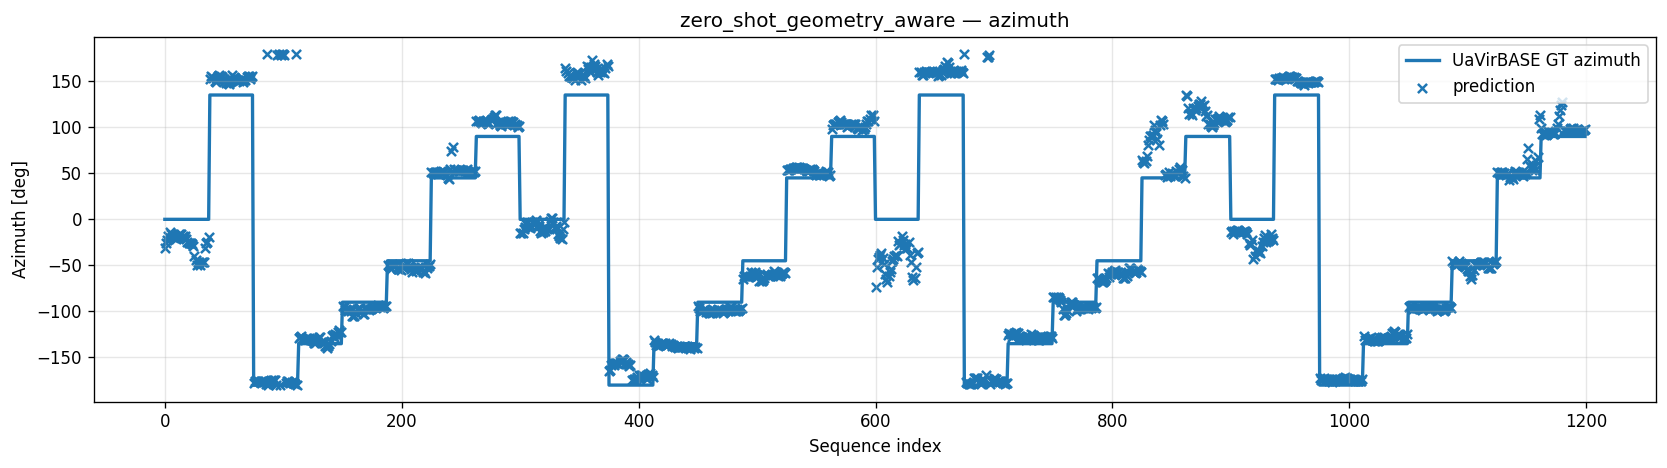

Figura salva em: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\zero_shot_geometry_aware_elevation_gt_vs_pred.png


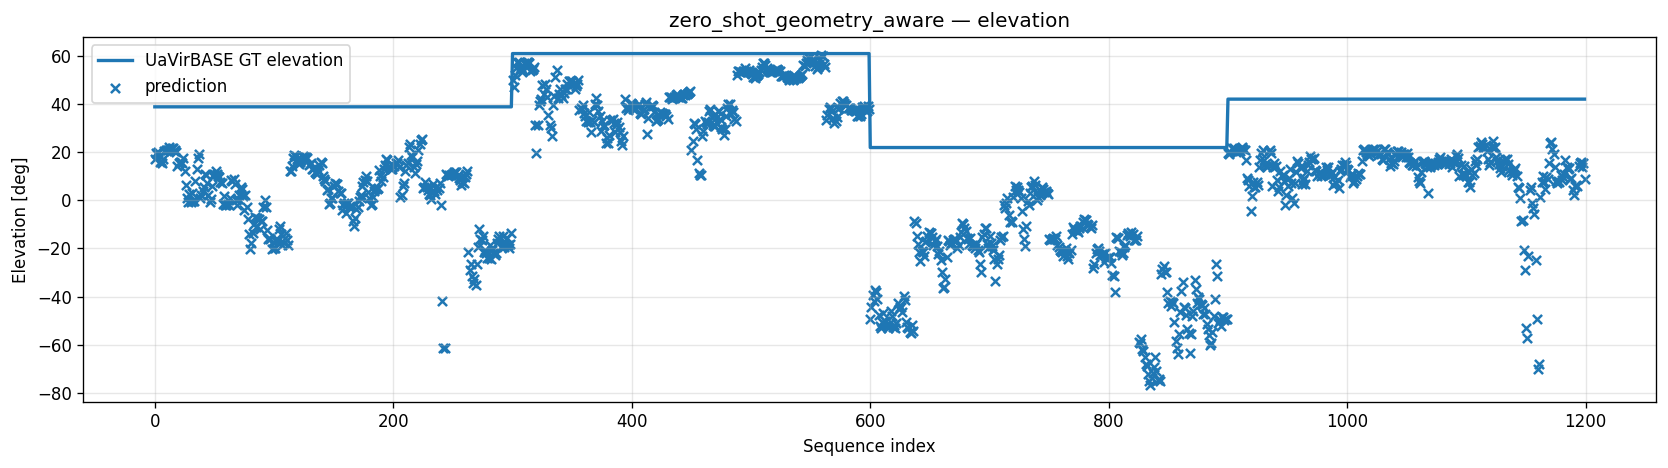

Figura salva em: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\zero_shot_geometry_aware_angular_error_hist.png


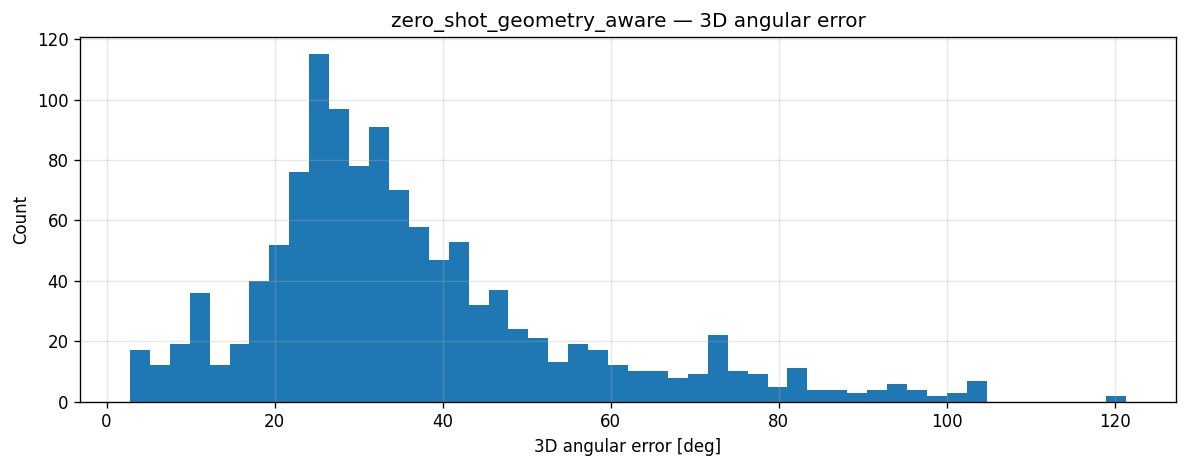

[uavir_head_finetune_geometry_aware] epoch 001 | train=0.145377 | val=0.079451 | best=0.079451@1


[uavir_head_finetune_geometry_aware] epoch 002 | train=0.041843 | val=0.036878 | best=0.036878@2


[uavir_head_finetune_geometry_aware] epoch 003 | train=0.015397 | val=0.022951 | best=0.022951@3


[uavir_head_finetune_geometry_aware] epoch 004 | train=0.008703 | val=0.019347 | best=0.019347@4


[uavir_head_finetune_geometry_aware] epoch 005 | train=0.007695 | val=0.018569 | best=0.018569@5


...

[uavir_head_finetune_geometry_aware] epoch 037 | train=0.005509 | val=0.015075 | best=0.015075@37


[uavir_head_finetune_geometry_aware] epoch 038 | train=0.005320 | val=0.015076 | best=0.015075@37


[uavir_head_finetune_geometry_aware] epoch 039 | train=0.005351 | val=0.015077 | best=0.015075@37


[uavir_head_finetune_geometry_aware] epoch 040 | train=0.005419 | val=0.015077 | best=0.015075@37



UaVirBASE EXTERNAL — uavir_head_finetune — sequência
n samples             : 3392
MAE azimuth [deg]     : 4.559828
RMSE azimuth [deg]    : 6.899978
MAE elevation [deg]   : 3.581447
RMSE elevation [deg]  : 4.820316
MAE angular 3D [deg]  : 5.529201
RMSE angular 3D [deg] : 7.282664

UaVirBASE EXTERNAL — uavir_head_finetune — sessão
n samples             : 64
MAE azimuth [deg]     : 3.806989
RMSE azimuth [deg]    : 5.704326
MAE elevation [deg]   : 3.262437
RMSE elevation [deg]  : 4.273477
MAE angular 3D [deg]  : 4.815466
RMSE angular 3D [deg] : 6.244542
Figura salva em: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\uavir_head_finetune_azimuth_gt_vs_pred.png


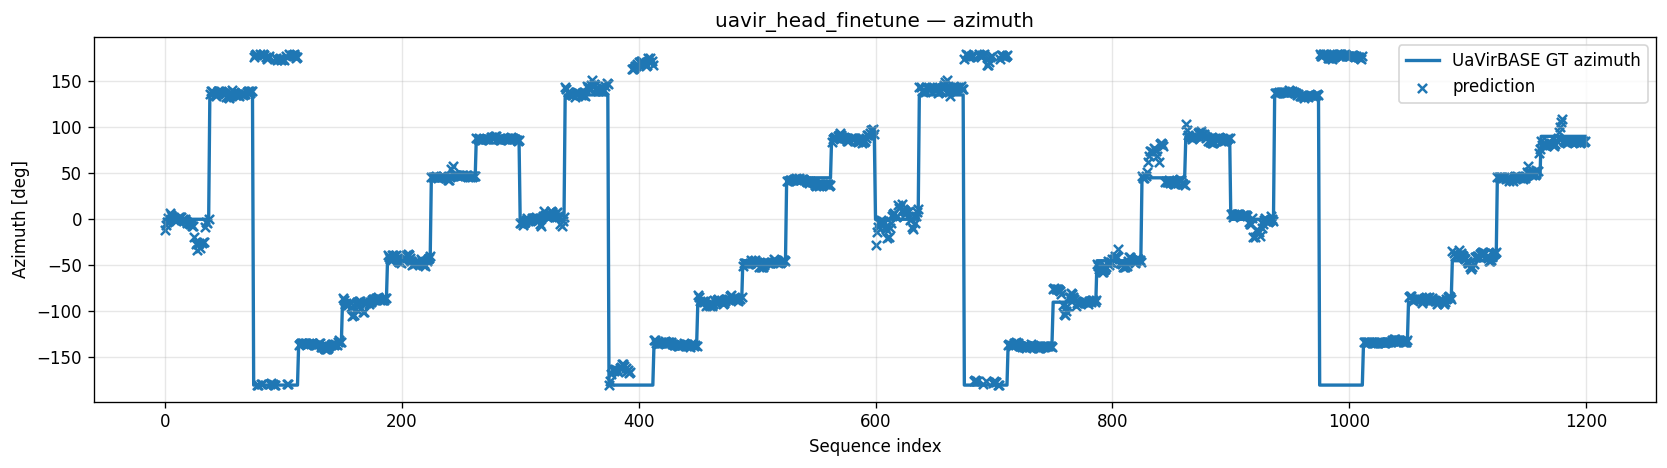

Figura salva em: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\uavir_head_finetune_elevation_gt_vs_pred.png


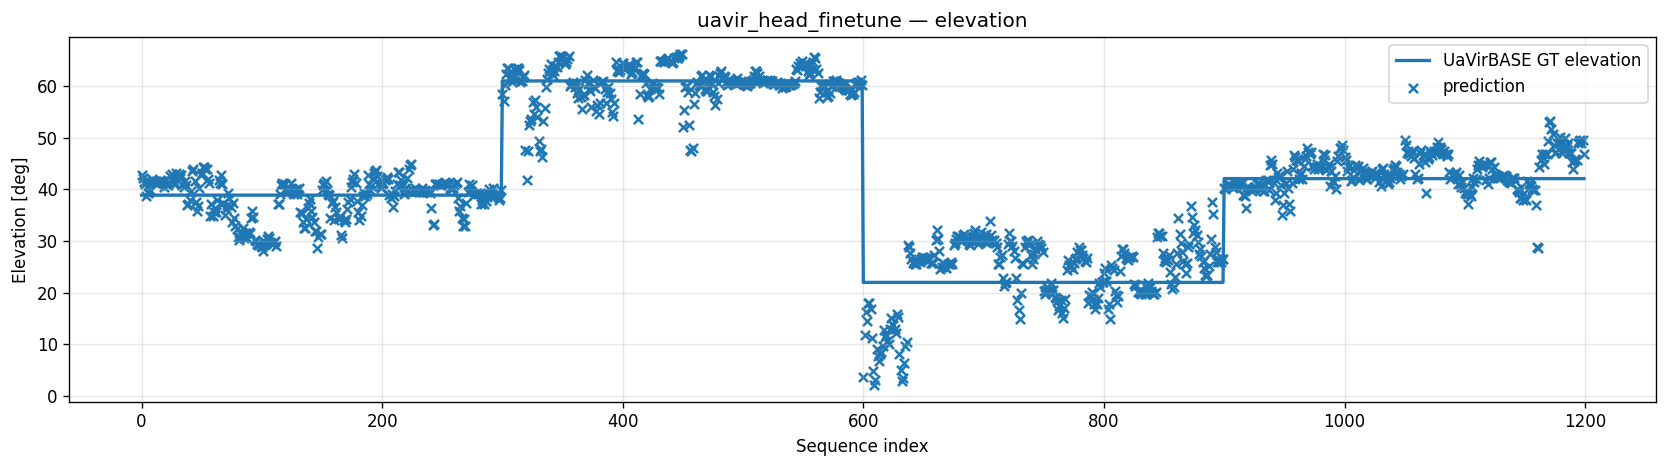

Figura salva em: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\uavir_head_finetune_angular_error_hist.png


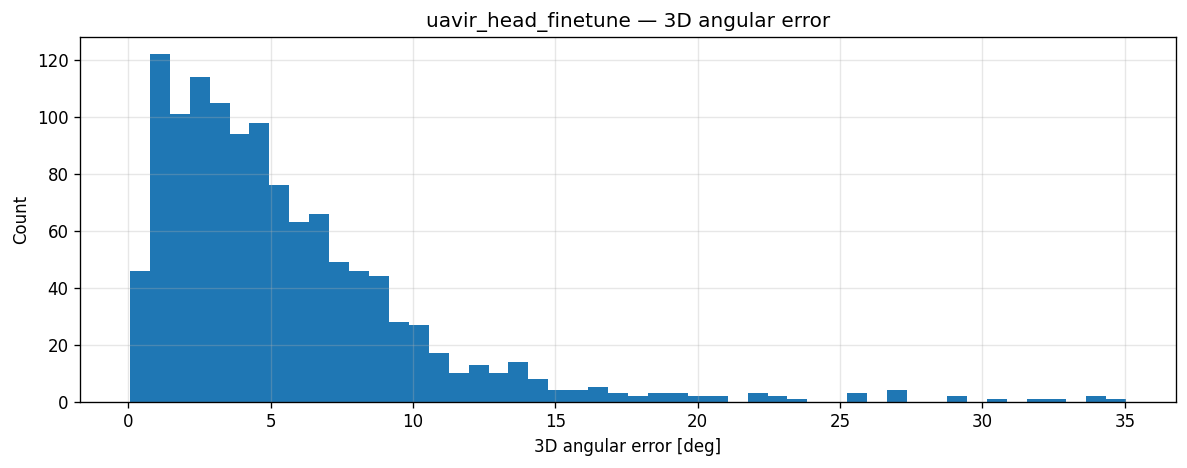

[uavir_full_finetune_geometry_aware] epoch 001 | train=0.064202 | val=0.017900 | best=0.017900@1


[uavir_full_finetune_geometry_aware] epoch 002 | train=0.012685 | val=0.012824 | best=0.012824@2


[uavir_full_finetune_geometry_aware] epoch 003 | train=0.008885 | val=0.009596 | best=0.009596@3


[uavir_full_finetune_geometry_aware] epoch 004 | train=0.006572 | val=0.008553 | best=0.008553@4


[uavir_full_finetune_geometry_aware] epoch 005 | train=0.005774 | val=0.008034 | best=0.008034@5


...

[uavir_full_finetune_geometry_aware] epoch 027 | train=0.003713 | val=0.005895 | best=0.005872@23


[uavir_full_finetune_geometry_aware] epoch 028 | train=0.003803 | val=0.005889 | best=0.005872@23


[uavir_full_finetune_geometry_aware] epoch 029 | train=0.004051 | val=0.005889 | best=0.005872@23


[uavir_full_finetune_geometry_aware] epoch 030 | train=0.003766 | val=0.005888 | best=0.005872@23



UaVirBASE EXTERNAL — uavir_full_finetune — sequência
n samples             : 3392
MAE azimuth [deg]     : 3.495738
RMSE azimuth [deg]    : 4.867397
MAE elevation [deg]   : 2.466940
RMSE elevation [deg]  : 3.371470
MAE angular 3D [deg]  : 3.943479
RMSE angular 3D [deg] : 5.021745

UaVirBASE EXTERNAL — uavir_full_finetune — sessão
n samples             : 64
MAE azimuth [deg]     : 2.912249
RMSE azimuth [deg]    : 3.667373
MAE elevation [deg]   : 2.195530
RMSE elevation [deg]  : 2.963979
MAE angular 3D [deg]  : 3.355046
RMSE angular 3D [deg] : 4.022349
Figura salva em: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\uavir_full_finetune_azimuth_gt_vs_pred.png


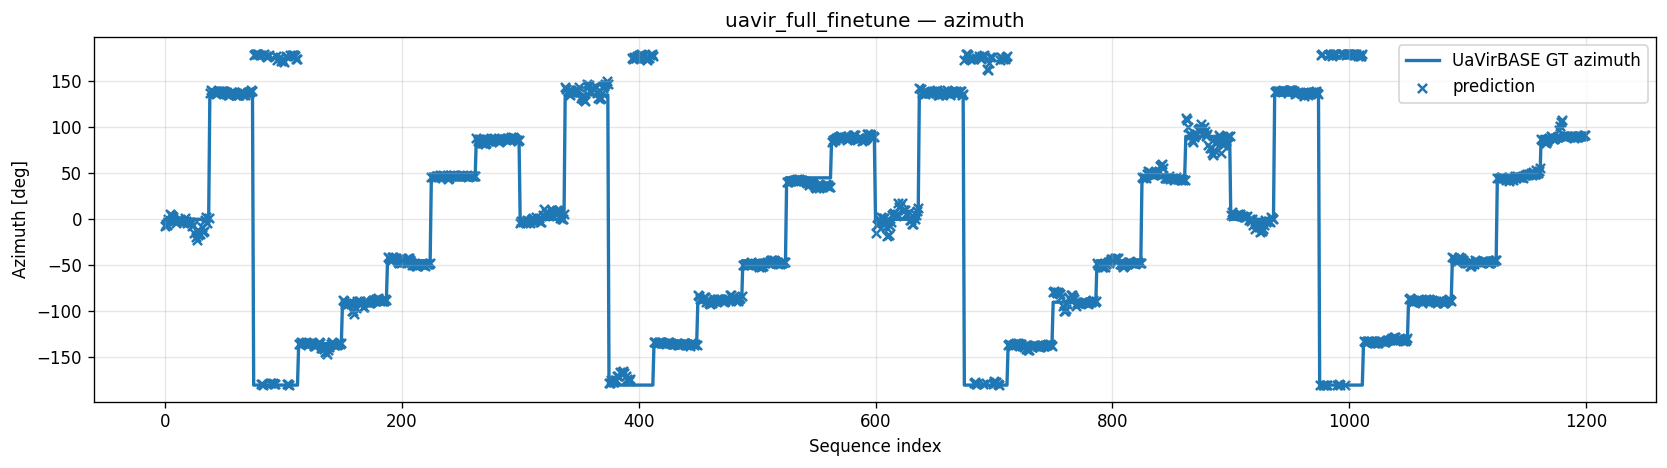

Figura salva em: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\uavir_full_finetune_elevation_gt_vs_pred.png


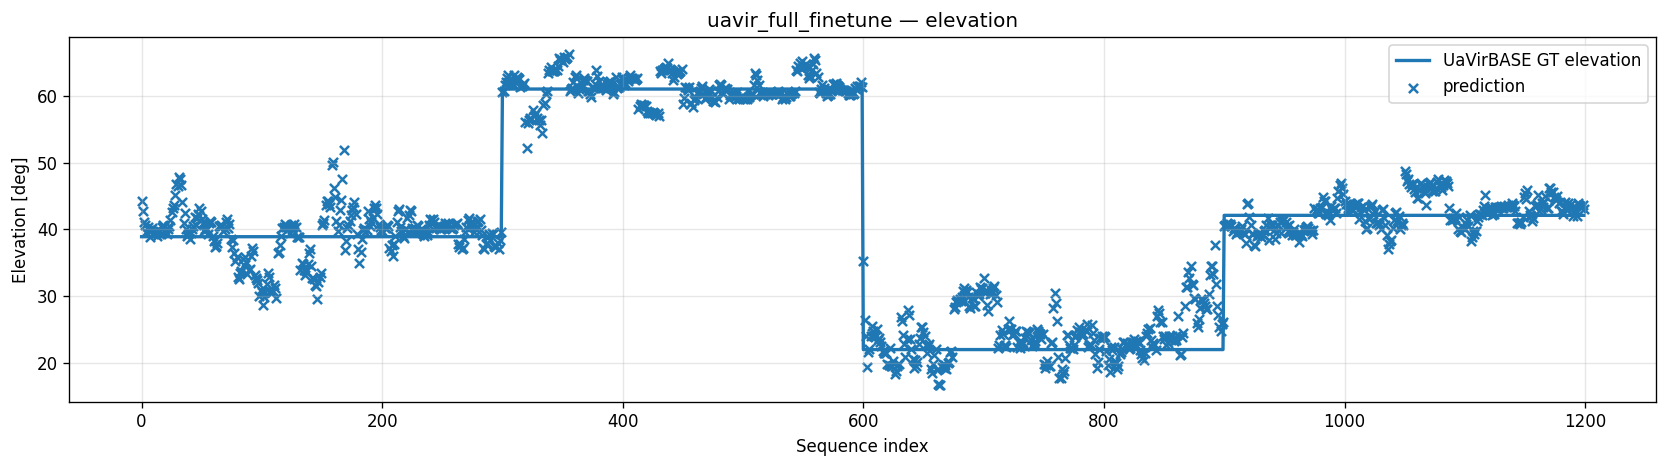

Figura salva em: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\uavir_full_finetune_angular_error_hist.png


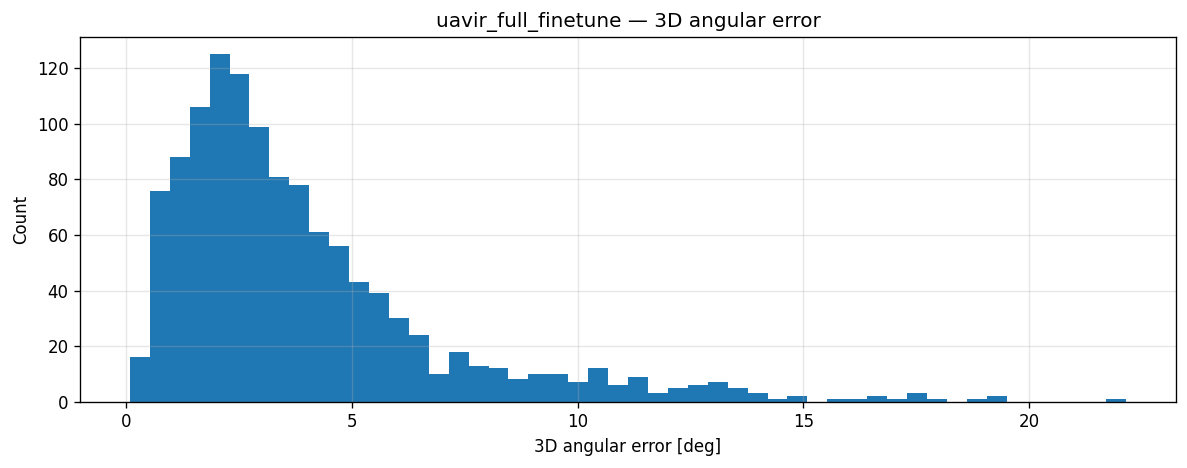

Figura salva em: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\mode_comparison_session_mae_angular_3d_dregon_free_flight_whitenoise_high_room1.png


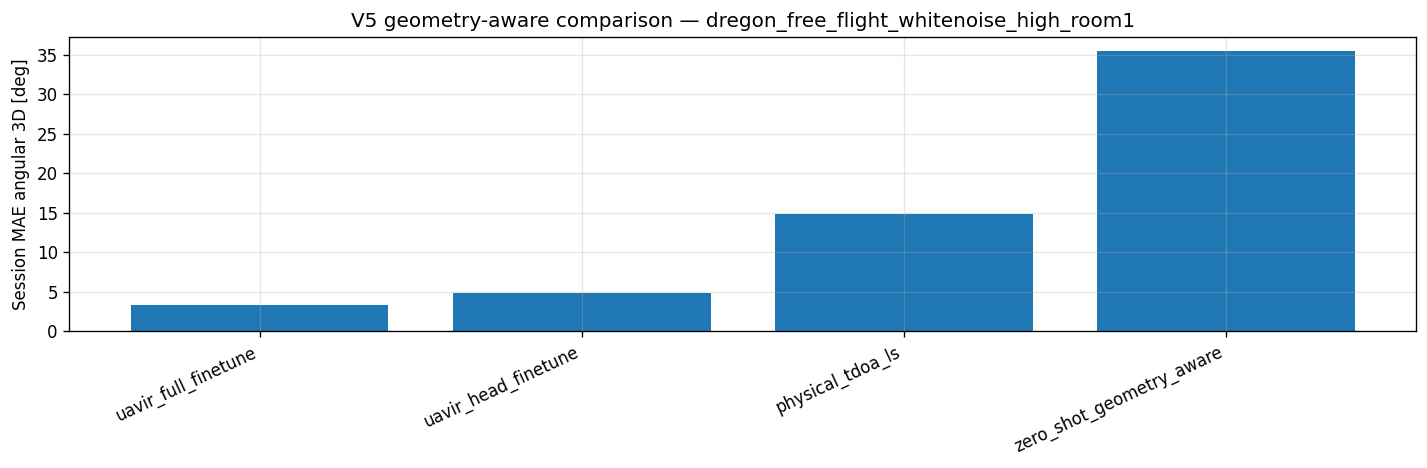


RESUMO V5 GEOMETRY-AWARE
                            scenario_key                     mode  sequence_MAE_azimuth_deg  sequence_MAE_elevation_deg  sequence_MAE_angular_3d_deg  session_MAE_azimuth_deg  session_MAE_elevation_deg  session_MAE_angular_3d_deg                                                                                                                                                                                prediction_csv                                                                                                                                                                                session_prediction_csv
dregon_free_flight_whitenoise_high_room1      uavir_full_finetune                  3.495738                    2.466940                     3.943479                 2.912249                   2.195530                    3.355046      D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high

Modelos DREGON: 100%|██████████| 1/1 [38:07<00:00, 2287.25s/it]


RESUMO FINAL V5 GEOMETRY-AWARE
                            scenario_key                     mode  sequence_MAE_azimuth_deg  sequence_MAE_elevation_deg  sequence_MAE_angular_3d_deg  session_MAE_azimuth_deg  session_MAE_elevation_deg  session_MAE_angular_3d_deg                                                                                                                                                                                prediction_csv                                                                                                                                                                                session_prediction_csv
dregon_free_flight_whitenoise_high_room1      uavir_full_finetune                  3.495738                    2.466940                     3.943479                 2.912249                   2.195530                    3.355046      D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenois

In [9]:
# -*- coding: utf-8 -*-
"""
====================================================================================================
DREGON -> UaVirBASE — V5 GEOMETRY-AWARE PAIR-LSTM
====================================================================================================

Objetivo
--------
Transformar o modelo tipo DREGON em um estimador condicionado pela geometria do arranjo,
em vez de assumir que toda entrada deve parecer exatamente o arranjo embarcado do DREGON.

Ideia central
-------------
Cada janela multicanal é representada por pares de microfones:

    par (i,j) -> [TDOA_ij, pico_GCC_ij, baseline_ij, baseline_unit_ij, baseline_norm_ij]

O modelo recebe uma sequência temporal com forma:

    X = [N_seq, SEQ_LEN, N_pairs, pair_feature_dim]

Arquitetura:

    Pair Encoder MLP -> atenção/pooling sobre pares -> LSTM temporal -> direção 3D normalizada

Por que isso é diferente das versões V3/V4?
------------------------------------------
V3/V4 forçavam UaVirBASE a virar uma feature flat parecida com o DREGON:

    [28 TDOAs, 28 GCC peaks, 3 direção auxiliar]

A V5 não faz isso. Ela injeta explicitamente a geometria de cada par de microfones. Assim,
o mesmo modelo pode receber o arranjo pequeno embarcado do DREGON ou o arranjo estático
maior da UaVirBASE.

Saídas principais
-----------------
- baseline físico TDOA-LS da UaVirBASE;
- treino ID no DREGON usando Pair-LSTM geometry-aware;
- zero-shot DREGON -> UaVirBASE usando a geometria real da UaVirBASE;
- adaptação leve no split de calibração UaVirBASE:
    1) head-only finetune;
    2) full finetune com learning rate baixo.

Segurança de arquivos
---------------------
- Não apaga resultados anteriores.
- Cada execução cria um novo run_id.
- Checkpoint de retomada: somente latest_checkpoint.pt por modo, substituído atomicamente.
- Métricas/resultados são salvos incrementalmente no diretório do run_id.

Dependências
------------
Python, numpy, pandas, scipy, soundfile, torch, matplotlib, tqdm.

====================================================================================================
"""

from pathlib import Path
from datetime import datetime
import os
import re
import json
import math
import random
import traceback
import itertools
import warnings

import numpy as np
import pandas as pd

import soundfile as sf
import scipy.signal as sig

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    class tqdm:
        def __init__(self, iterable=None, **kwargs):
            self.iterable = iterable
        def __iter__(self):
            return iter(self.iterable)
        def update(self, *args, **kwargs):
            pass
        def close(self):
            pass
        def set_postfix_str(self, *args, **kwargs):
            pass
        @staticmethod
        def write(msg):
            print(msg)

warnings.filterwarnings("ignore")


# ============================================================
# CONFIGURAÇÃO
# ============================================================

SEED = int(os.environ.get("UAVIR_TRAIN_SEED", "42"))
SPLIT_SEED = int(os.environ.get("UAVIR_SPLIT_SEED", "2026"))

GE_DRONE_ROOT = Path(os.environ.get("GE_DRONE_ROOT", r"D:\GE_DRONE"))
DREGON_OUTPUT_ROOT = Path(os.environ.get("DREGON_OUTPUT_ROOT", str(GE_DRONE_ROOT / "_dregon_outputs_all_scenarios")))
UAVIRBASE_ROOT = Path(os.environ.get("UAVIRBASE_ROOT", r"C:\Users\Luis\Desktop\Microphone_array"))

RUN_ID = os.environ.get("UAVIR_RUN_ID", datetime.now().strftime("run_%Y%m%d_%H%M%S"))
_DEFAULT_OUT_ROOT = GE_DRONE_ROOT / "_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe" / RUN_ID
OUT_ROOT = Path(os.environ.get("UAVIR_OUT_ROOT", str(_DEFAULT_OUT_ROOT)))
OUT_ROOT.mkdir(parents=True, exist_ok=True)

CACHE_ROOT = Path(os.environ.get("UAVIR_CACHE_ROOT", str(GE_DRONE_ROOT / "_dregon_to_uavirbase_geometry_aware_v5_cache")))
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ONLY_DREGON_SCENARIOS = [
    "dregon_free_flight_whitenoise_high_room1",
]

# UaVirBASE
MAX_UAVIRBASE_SESSIONS = None
MAX_UAVIRBASE_WINDOWS_PER_SESSION = 64
UAVIRBASE_WORKING_SR = 16000
USE_ONLY_FIRST_8_CHANNELS = True
MIN_DURATION_SEC = 10.0
MIN_CHANNELS = 8

# Split UaVirBASE por sessão
CALIBRATION_FRAC = 0.20
VALIDATION_FRAC = 0.10

# Áudio/GCC
F_HP = 300.0
NOTCH_F0 = 160.0
NOTCH_Q = 20.0
USE_PREPROCESSING = True
C_SOUND = 343.0

# Fallbacks para compatibilidade com checkpoints anteriores
WIN_SEC_FALLBACK = 0.50
HOP_SEC_FALLBACK = 0.025
SEQ_LEN_FALLBACK = 12
SPLIT_MODE_FALLBACK = "random"
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Treino do modelo geometry-aware
EPOCHS_DREGON = 80
EPOCHS_UAVIR_HEAD = 40
EPOCHS_UAVIR_FULL = 30
BATCH_SIZE = 128
LR_DREGON = 2e-3
LR_UAVIR_HEAD = 1e-3
LR_UAVIR_FULL = 2e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 2.0
PATIENCE = 16
NUM_WORKERS = 0

# Arquitetura
PAIR_EMBED_DIM = 96
PAIR_HIDDEN_DIM = 128
TEMPORAL_HIDDEN_DIM = 128
TEMPORAL_LAYERS = 2
DROPOUT = 0.20
USE_PAIR_ATTENTION = True

# Dados sintéticos/augmentação física
# Mantém o espírito DREGON, mas ensina o modelo a lidar com outras geometrias.
USE_DREGON_REAL_TRAIN = True
USE_DREGON_GEOMETRY_AUGMENTATION = True
DREGON_AUGMENT_COPIES = 2
USE_PURE_PHYSICS_SYNTHETIC_PRETRAIN = True
N_SYNTHETIC_PHYSICS_SEQUENCES = 6000
SYNTHETIC_NOISE_TAU_STD_SEC = 2.0e-5
SYNTHETIC_PEAK_MIN = 0.30
SYNTHETIC_PEAK_MAX = 1.00

# Avaliações/adaptação
RUN_UAVIR_ZERO_SHOT = True
RUN_UAVIR_HEAD_FINETUNE = True
RUN_UAVIR_FULL_FINETUNE = True
RUN_PHYSICAL_TDOA_LS_BASELINE = True

SESSION_AGGREGATION = "median"
BATCH_SIZE_PRED = 512
PRINT_GEOMETRY_DEBUG_FIRST_N = 2

WAV_CANDIDATES = ["output.wav", "a.wav"]
JSON_CANDIDATES = ["label.json", "a.json"]


# ============================================================
# UTILITÁRIOS GERAIS
# ============================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def safe_torch_load(path: Path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def atomic_torch_save(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def save_json(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def sanitize_name(s):
    s = str(s).lower()
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s.strip("_")


def parse_float_maybe(x):
    if x is None:
        return None
    if isinstance(x, (int, float)) and not isinstance(x, bool):
        return float(x)
    s = str(x).strip().replace(",", ".")
    if s == "":
        return None
    m = re.search(r"[-+]?\d*\.?\d+", s)
    if m is None:
        return None
    try:
        return float(m.group(0))
    except Exception:
        return None


def safe_get(d, *keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict):
            return default
        if k not in cur:
            return default
        cur = cur[k]
    return cur


def first_not_none(*values):
    for v in values:
        if v is not None:
            return v
    return None


def wrap_angle_deg(a):
    return (np.asarray(a, dtype=np.float64) + 180.0) % 360.0 - 180.0


def normalize_rows(x):
    x = np.asarray(x, dtype=np.float64)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def save_fig(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=220)
    print("Figura salva em:", path)
    plt.show()
    plt.close()


# ============================================================
# CONVENÇÕES ANGULARES
# ============================================================

def uavir_azel_to_unit(az_deg, el_deg):
    """
    UaVirBASE:
      azimuth = 0 deg no norte
      x = East
      y = North
      z = Up
    """
    az = np.deg2rad(np.asarray(az_deg, dtype=np.float64))
    el = np.deg2rad(np.asarray(el_deg, dtype=np.float64))
    east = np.cos(el) * np.sin(az)
    north = np.cos(el) * np.cos(az)
    up = np.sin(el)
    return normalize_rows(np.vstack([east, north, up]).T).astype(np.float32)


def uavir_unit_to_azel(u):
    u = normalize_rows(u)
    east = u[:, 0]
    north = u[:, 1]
    up = u[:, 2]
    az = np.rad2deg(np.arctan2(east, north))
    el = np.rad2deg(np.arcsin(np.clip(up, -1.0, 1.0)))
    az = wrap_angle_deg(az)
    return az, el


def dregon_unit_to_azel(u):
    u = normalize_rows(u)
    az = np.rad2deg(np.arctan2(u[:, 1], u[:, 0]))
    el = np.rad2deg(np.arcsin(np.clip(u[:, 2], -1.0, 1.0)))
    az = wrap_angle_deg(az)
    return az, el


def angular_error_deg(pred_u, true_u):
    pred_u = normalize_rows(pred_u)
    true_u = normalize_rows(true_u)
    cosang = np.sum(pred_u * true_u, axis=1)
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.rad2deg(np.arccos(cosang))


def compute_metrics_from_units(pred_u, true_u, convention="uavir"):
    pred_u = normalize_rows(pred_u)
    true_u = normalize_rows(true_u)
    if convention == "uavir":
        az_pred, el_pred = uavir_unit_to_azel(pred_u)
        az_true, el_true = uavir_unit_to_azel(true_u)
    elif convention == "dregon":
        az_pred, el_pred = dregon_unit_to_azel(pred_u)
        az_true, el_true = dregon_unit_to_azel(true_u)
    else:
        raise ValueError(f"convention inválida: {convention}")
    err_az = wrap_angle_deg(az_pred - az_true)
    err_el = el_pred - el_true
    err_ang = angular_error_deg(pred_u, true_u)
    return {
        "MAE_azimuth_deg": float(np.mean(np.abs(err_az))),
        "RMSE_azimuth_deg": float(np.sqrt(np.mean(err_az ** 2))),
        "MAE_elevation_deg": float(np.mean(np.abs(err_el))),
        "RMSE_elevation_deg": float(np.sqrt(np.mean(err_el ** 2))),
        "MAE_angular_3d_deg": float(np.mean(np.abs(err_ang))),
        "RMSE_angular_3d_deg": float(np.sqrt(np.mean(err_ang ** 2))),
    }


def print_metrics(title, metrics, n):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(f"n samples             : {n}")
    print(f"MAE azimuth [deg]     : {metrics['MAE_azimuth_deg']:.6f}")
    print(f"RMSE azimuth [deg]    : {metrics['RMSE_azimuth_deg']:.6f}")
    print(f"MAE elevation [deg]   : {metrics['MAE_elevation_deg']:.6f}")
    print(f"RMSE elevation [deg]  : {metrics['RMSE_elevation_deg']:.6f}")
    print(f"MAE angular 3D [deg]  : {metrics['MAE_angular_3d_deg']:.6f}")
    print(f"RMSE angular 3D [deg] : {metrics['RMSE_angular_3d_deg']:.6f}")
    print("=" * 100)


# ============================================================
# GEOMETRIA DREGON E PARES
# ============================================================

MIC_POS_DREGON = np.array([
    [ 0.0420,  0.0615, -0.0410],
    [-0.0420,  0.0615,  0.0410],
    [-0.0615,  0.0420, -0.0410],
    [-0.0615, -0.0420,  0.0410],
    [-0.0420, -0.0615, -0.0410],
    [ 0.0420, -0.0615,  0.0410],
    [ 0.0615, -0.0420, -0.0410],
    [ 0.0615,  0.0420,  0.0410],
], dtype=np.float64)


def get_pairs(n):
    return [(i, j) for i in range(n) for j in range(i + 1, n)]


PAIRS_8 = get_pairs(8)


def pair_matrix_from_mics(mic_pos, pairs):
    return np.asarray([mic_pos[j] - mic_pos[i] for i, j in pairs], dtype=np.float64)


PAIR_FEATURE_NAMES = [
    "tau_sec",
    "c_tau_m",
    "tau_over_max",
    "gcc_peak",
    "baseline_x_m",
    "baseline_y_m",
    "baseline_z_m",
    "baseline_norm_m",
    "baseline_unit_x",
    "baseline_unit_y",
    "baseline_unit_z",
]


def build_pair_features_from_taus_peaks(taus, peaks, mic_pos, pairs, c=C_SOUND):
    """
    Função geral para qualquer cenário.

    Parameters
    ----------
    taus : array [N, P]
        TDOA estimado por par.
    peaks : array [N, P]
        Pico/qualidade GCC por par.
    mic_pos : array [M, 3]
        Geometria dos microfones no referencial desejado.
    pairs : list[(i,j)]
        Pares de microfones.

    Returns
    -------
    X_pair : array [N, P, D]
    """
    taus = np.asarray(taus, dtype=np.float32)
    peaks = np.asarray(peaks, dtype=np.float32)
    A = pair_matrix_from_mics(mic_pos, pairs).astype(np.float32)  # [P, 3]
    bnorm = np.linalg.norm(A, axis=1).astype(np.float32) + 1e-12
    bunit = A / bnorm[:, None]

    N, P = taus.shape
    if peaks.shape != taus.shape:
        raise ValueError(f"peaks shape {peaks.shape} != taus shape {taus.shape}")
    if P != len(pairs):
        raise ValueError(f"taus tem {P} pares, mas pairs tem {len(pairs)}")

    tau_sec = taus
    c_tau_m = (c * taus).astype(np.float32)
    tau_over_max = (c * taus / bnorm[None, :]).astype(np.float32)
    tau_over_max = np.clip(tau_over_max, -1.5, 1.5)

    baseline = np.repeat(A[None, :, :], N, axis=0)
    baseline_norm = np.repeat(bnorm[None, :, None], N, axis=0)
    baseline_unit = np.repeat(bunit[None, :, :], N, axis=0)

    X_pair = np.concatenate([
        tau_sec[:, :, None],
        c_tau_m[:, :, None],
        tau_over_max[:, :, None],
        peaks[:, :, None],
        baseline,
        baseline_norm,
        baseline_unit,
    ], axis=2).astype(np.float32)

    return X_pair


def synthesize_taus_from_units(u, mic_pos, pairs, c=C_SOUND):
    u = normalize_rows(u)
    A = pair_matrix_from_mics(mic_pos, pairs)
    return (u @ A.T / c).astype(np.float32)


def detect_flat_feature_layout(X_raw):
    dim = int(X_raw.shape[1])
    n_pairs = len(PAIRS_8)
    if dim >= 2 * n_pairs:
        return {
            "tdoa_slice": slice(0, n_pairs),
            "peak_slice": slice(n_pairs, 2 * n_pairs),
            "u_slice": slice(2 * n_pairs, min(2 * n_pairs + 3, dim)),
            "dim": dim,
            "n_pairs": n_pairs,
        }
    raise ValueError(f"X_raw dim={dim} incompatível com 28 TDOAs + 28 peaks")


def build_dregon_pair_features_from_flat(X_raw, mic_pos=MIC_POS_DREGON, pairs=PAIRS_8):
    layout = detect_flat_feature_layout(X_raw)
    taus = X_raw[:, layout["tdoa_slice"]].astype(np.float32)
    peaks = X_raw[:, layout["peak_slice"]].astype(np.float32)
    X_pair = build_pair_features_from_taus_peaks(taus, peaks, mic_pos, pairs)
    return X_pair, layout


# ============================================================
# GEOMETRIA SINTÉTICA PARA GENERALIZAÇÃO
# ============================================================

def random_rotation_matrix(rng):
    # Rotação yaw-pitch-roll simples, suficiente para augmentação.
    yaw = rng.uniform(-np.pi, np.pi)
    pitch = rng.uniform(-0.35 * np.pi, 0.35 * np.pi)
    roll = rng.uniform(-0.35 * np.pi, 0.35 * np.pi)

    cy, sy = np.cos(yaw), np.sin(yaw)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cr, sr = np.cos(roll), np.sin(roll)

    Rz = np.array([[cy, -sy, 0.0], [sy, cy, 0.0], [0.0, 0.0, 1.0]])
    Ry = np.array([[cp, 0.0, sp], [0.0, 1.0, 0.0], [-sp, 0.0, cp]])
    Rx = np.array([[1.0, 0.0, 0.0], [0.0, cr, -sr], [0.0, sr, cr]])
    return (Rz @ Ry @ Rx).astype(np.float64)


def random_augmented_geometry(base_mic_pos, rng, scale_min=0.7, scale_max=30.0):
    """
    Aumenta o arranjo DREGON para ensinar o modelo a não depender do tamanho/orientação original.
    O scale_max ~30 cobre a diferença entre o arranjo embarcado pequeno e arranjos estáticos maiores.
    """
    base = np.asarray(base_mic_pos, dtype=np.float64)
    base = base - base.mean(axis=0, keepdims=True)
    R = random_rotation_matrix(rng)
    scale = float(np.exp(rng.uniform(np.log(scale_min), np.log(scale_max))))
    z_scale = float(np.exp(rng.uniform(np.log(0.6), np.log(2.5))))
    S = np.diag([scale, scale, scale * z_scale])
    pos = base @ R.T @ S.T
    pos = pos - pos.mean(axis=0, keepdims=True)
    return pos.astype(np.float64)


def random_unit_vectors(n, rng):
    z = rng.uniform(-0.85, 0.85, size=n)
    theta = rng.uniform(-np.pi, np.pi, size=n)
    r = np.sqrt(np.maximum(0.0, 1.0 - z ** 2))
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.vstack([x, y, z]).T.astype(np.float32)


def build_augmented_dregon_pair_frames(y_units, peak_template, n_copies, rng):
    """
    Cria frames sintéticos usando as direções reais do DREGON como supervisão, mas com geometrias
    randomizadas. Isso ensina a relação: TDOA + geometria -> direção.
    """
    X_list = []
    y_list = []
    y_units = np.asarray(y_units, dtype=np.float32)
    peak_template = np.asarray(peak_template, dtype=np.float32)

    for cidx in range(int(n_copies)):
        mic_pos = random_augmented_geometry(MIC_POS_DREGON, rng)
        taus = synthesize_taus_from_units(y_units, mic_pos, PAIRS_8)

        # Picos sintéticos moderados: qualidade não deve dominar a geometria.
        peaks = np.repeat(np.median(peak_template, axis=0, keepdims=True), len(y_units), axis=0)
        peaks = peaks * rng.uniform(0.85, 1.15, size=peaks.shape).astype(np.float32)
        peaks = np.clip(peaks, SYNTHETIC_PEAK_MIN, SYNTHETIC_PEAK_MAX)

        if SYNTHETIC_NOISE_TAU_STD_SEC > 0:
            taus = taus + rng.normal(0.0, SYNTHETIC_NOISE_TAU_STD_SEC, size=taus.shape).astype(np.float32)

        X_pair = build_pair_features_from_taus_peaks(taus, peaks, mic_pos, PAIRS_8)
        X_list.append(X_pair)
        y_list.append(y_units)

    if len(X_list) == 0:
        return None, None

    return np.vstack(X_list).astype(np.float32), np.vstack(y_list).astype(np.float32)


def generate_pure_physics_sequences(n_sequences, seq_len, rng):
    """
    Gera sequências totalmente sintéticas para pré-treinamento físico.
    Não usa áudio. Ensina a inversão geométrica com ruído.
    """
    Xs = []
    ys = []

    for _ in tqdm(range(int(n_sequences)), desc="Gerando sequências físicas sintéticas", dynamic_ncols=True, leave=True):
        mic_pos = random_augmented_geometry(MIC_POS_DREGON, rng)
        # Direção quase constante com pequena variação temporal.
        u0 = random_unit_vectors(1, rng)[0]
        us = []
        for t in range(seq_len):
            jitter = rng.normal(0.0, 0.025, size=3).astype(np.float32)
            u = u0 + jitter
            u = u / (np.linalg.norm(u) + 1e-12)
            us.append(u)
        us = np.asarray(us, dtype=np.float32)

        taus = synthesize_taus_from_units(us, mic_pos, PAIRS_8)
        if SYNTHETIC_NOISE_TAU_STD_SEC > 0:
            taus = taus + rng.normal(0.0, SYNTHETIC_NOISE_TAU_STD_SEC, size=taus.shape).astype(np.float32)
        peaks = rng.uniform(SYNTHETIC_PEAK_MIN, SYNTHETIC_PEAK_MAX, size=taus.shape).astype(np.float32)
        X_pair = build_pair_features_from_taus_peaks(taus, peaks, mic_pos, PAIRS_8)

        Xs.append(X_pair)
        ys.append(us[-1])

    return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)


# ============================================================
# ÁUDIO E GCC-PHAT
# ============================================================

def butter_highpass_sos(fs, fc, order=4):
    return sig.butter(order, fc / (fs / 2.0), btype="highpass", output="sos")


def notch_sos(fs, f0, q):
    b, a = sig.iirnotch(f0 / (fs / 2.0), q)
    return sig.tf2sos(b, a)


def apply_sos_filter_safe(x, sos):
    try:
        return sig.sosfiltfilt(sos, x, axis=0)
    except Exception:
        return sig.sosfilt(sos, x, axis=0)


def preprocess_audio(audio, fs):
    y = np.asarray(audio, dtype=np.float32)
    if y.ndim == 1:
        y = y[:, None]
    if not USE_PREPROCESSING:
        return y
    if F_HP is not None and 0 < F_HP < fs / 2:
        y = apply_sos_filter_safe(y, butter_highpass_sos(fs, F_HP))
    for f0 in [NOTCH_F0, 2 * NOTCH_F0]:
        if f0 is not None and 0 < f0 < fs / 2:
            y = apply_sos_filter_safe(y, notch_sos(fs, f0, NOTCH_Q))
    return y.astype(np.float32)


def resample_multichannel(audio, fs_in, fs_out):
    if int(fs_in) == int(fs_out):
        return audio.astype(np.float32), int(fs_in)
    gcd = np.gcd(int(fs_in), int(fs_out))
    up = int(fs_out // gcd)
    down = int(fs_in // gcd)
    out = sig.resample_poly(audio, up=up, down=down, axis=0)
    return out.astype(np.float32), int(fs_out)


def gcc_phat_tau(x, y, fs, max_tau):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    n = 2 ** int(np.ceil(np.log2(len(x) + len(y))))
    X = np.fft.rfft(x, n=n)
    Y = np.fft.rfft(y, n=n)
    R = X * np.conj(Y)
    R = R / (np.abs(R) + 1e-15)
    cc = np.fft.irfft(R, n=n)
    max_shift = max(1, int(max_tau * fs))
    cc = np.concatenate([cc[-max_shift:], cc[:max_shift + 1]])
    idx = int(np.argmax(np.abs(cc)))
    idx_float = float(idx)
    if 0 < idx < len(cc) - 1:
        a = cc[idx - 1]
        b = cc[idx]
        c = cc[idx + 1]
        denom = a - 2 * b + c
        if abs(denom) > 1e-15:
            idx_float = idx + 0.5 * (a - c) / denom
    idx_round = int(np.clip(int(round(idx_float)), 0, len(cc) - 1))
    tau = (idx_float - max_shift) / fs
    peak = float(np.abs(cc[idx_round]))
    return float(tau), peak


def estimate_direction_from_tdoa_ls(taus, mic_pos, pairs, c=343.0, sign=1.0):
    A = pair_matrix_from_mics(mic_pos, pairs)
    dirs = []
    for tau in taus:
        b = sign * c * np.asarray(tau, dtype=np.float64)
        u, *_ = np.linalg.lstsq(A, b, rcond=None)
        if np.linalg.norm(u) < 1e-12:
            u = np.array([1.0, 0.0, 0.0])
        else:
            u = u / np.linalg.norm(u)
        dirs.append(u)
    return np.asarray(dirs, dtype=np.float32)


# ============================================================
# PARSING UAVIRBASE
# ============================================================

def find_pair_in_dir(d: Path):
    wav_path = None
    json_path = None
    for name in WAV_CANDIDATES:
        p = d / name
        if p.exists():
            wav_path = p
            break
    for name in JSON_CANDIDATES:
        p = d / name
        if p.exists():
            json_path = p
            break
    if wav_path is None or json_path is None:
        return None, None
    return wav_path, json_path


def get_microphone_list(label):
    mic_array = first_not_none(
        safe_get(label, "microphone_array"),
        safe_get(label, "array"),
        safe_get(label, "microphones"),
    )
    if isinstance(mic_array, dict):
        mics = first_not_none(
            mic_array.get("microphones", None),
            mic_array.get("microphone", None),
            mic_array.get("channels", None),
        )
    elif isinstance(mic_array, list):
        mics = mic_array
    else:
        mics = None
    if mics is None:
        raise ValueError("Lista de microfones não encontrada no JSON.")
    if isinstance(mics, dict):
        mics = list(mics.values())
    if not isinstance(mics, list):
        raise ValueError(f"Formato de microfones inválido: {type(mics)}")
    return mics


def mic_position_from_metadata(mic):
    height = parse_float_maybe(first_not_none(mic.get("height"), mic.get("z"), mic.get("altitude")))
    distance = parse_float_maybe(first_not_none(mic.get("distance"), mic.get("r"), mic.get("radius")))
    az = parse_float_maybe(first_not_none(mic.get("azimuth"), mic.get("az")))
    if height is None:
        height = 0.0
    if distance is None or az is None:
        raise ValueError(f"distance/azimuth ausentes no microfone: {mic}")
    azr = np.deg2rad(float(az))
    east = float(distance) * np.sin(azr)
    north = float(distance) * np.cos(azr)
    return np.array([east, north, height], dtype=np.float64), "distance_azimuth_height"


def parse_uavirbase_mic_geometry(label):
    mics = get_microphone_list(label)
    mic_rows = []
    for idx, mic in enumerate(mics):
        if not isinstance(mic, dict):
            continue
        ch = first_not_none(mic.get("channel"), mic.get("channel_id"), mic.get("id"), idx + 1)
        try:
            ch_int = int(parse_float_maybe(ch))
        except Exception:
            ch_int = idx + 1
        pos, method = mic_position_from_metadata(mic)
        mic_rows.append({
            "channel": ch_int,
            "idx0": ch_int - 1,
            "x_east_m_abs": float(pos[0]),
            "y_north_m_abs": float(pos[1]),
            "z_up_m_abs": float(pos[2]),
            "distance_m": parse_float_maybe(mic.get("distance")),
            "azimuth_deg": parse_float_maybe(mic.get("azimuth")),
            "height_m": parse_float_maybe(mic.get("height")),
            "mic_elevation_pointing_deg": parse_float_maybe(mic.get("elevation")),
            "method": method,
        })
    df_mic = pd.DataFrame(mic_rows)
    if len(df_mic) < 8:
        raise ValueError(f"Esperado pelo menos 8 microfones. Encontrados: {len(df_mic)}")
    df_mic = df_mic.sort_values("channel").head(8).reset_index(drop=True)
    mic_pos_abs = df_mic[["x_east_m_abs", "y_north_m_abs", "z_up_m_abs"]].values.astype(np.float64)
    mic_center = mic_pos_abs.mean(axis=0)
    mic_pos_centered = mic_pos_abs - mic_center[None, :]
    df_mic["x_east_m"] = mic_pos_centered[:, 0]
    df_mic["y_north_m"] = mic_pos_centered[:, 1]
    df_mic["z_up_m"] = mic_pos_centered[:, 2]
    return mic_pos_centered.astype(np.float64), mic_center.astype(np.float64), df_mic


def extract_uavirbase_drone_target(label, mic_center):
    drone = first_not_none(
        safe_get(label, "drone"),
        safe_get(label, "source"),
        safe_get(label, "sound_source"),
        {},
    )
    if not isinstance(drone, dict):
        drone = {}
    distance = first_not_none(
        safe_get(label, "drone", "distance"),
        safe_get(label, "distance"),
        safe_get(label, "source", "distance"),
        drone.get("distance", None),
    )
    height = first_not_none(
        safe_get(label, "drone", "height"),
        safe_get(label, "height"),
        safe_get(label, "source", "height"),
        drone.get("height", None),
    )
    azimuth = first_not_none(
        safe_get(label, "drone", "azimuth"),
        safe_get(label, "azimuth"),
        safe_get(label, "source", "azimuth"),
        drone.get("azimuth", None),
    )
    rotation = first_not_none(
        safe_get(label, "drone", "rotation"),
        safe_get(label, "rotation"),
        safe_get(label, "drone", "side"),
        safe_get(label, "side"),
        "",
    )
    movement = first_not_none(
        safe_get(label, "drone", "movement"),
        safe_get(label, "movement"),
        "",
    )
    drone_type = first_not_none(
        safe_get(label, "drone", "type"),
        safe_get(label, "type"),
        "",
    )
    sound_source = first_not_none(
        safe_get(label, "drone", "sound_source"),
        safe_get(label, "sound_source"),
        "",
    )
    distance = parse_float_maybe(distance)
    height = parse_float_maybe(height)
    azimuth = parse_float_maybe(azimuth)
    if distance is None or height is None or azimuth is None:
        raise ValueError("distance/height/azimuth do drone não encontrados no JSON.")
    azimuth = float(azimuth) % 360.0
    azr = np.deg2rad(azimuth)
    east = float(distance) * np.sin(azr)
    north = float(distance) * np.cos(azr)
    up = float(height) - float(mic_center[2])
    vec = np.array([[east, north, up]], dtype=np.float64)
    u = normalize_rows(vec)[0].astype(np.float32)
    _, el_unit = uavir_unit_to_azel(u[None, :])
    return {
        "distance_m": float(distance),
        "height_m": float(height),
        "azimuth_deg": float(azimuth),
        "elevation_deg": float(el_unit[0]),
        "rotation": str(rotation),
        "movement": str(movement),
        "drone_type": str(drone_type),
        "sound_source": str(sound_source),
        "target_unit_uavir": u,
    }


def load_uavir_geometry_from_label(label_path):
    with open(label_path, "r", encoding="utf-8") as f:
        label = json.load(f)
    mic_pos, mic_center, df_mic = parse_uavirbase_mic_geometry(label)
    target = extract_uavirbase_drone_target(label, mic_center)
    return mic_pos, mic_center, df_mic, target


def print_uavirbase_geometry_debug(session_id, mic_center, df_mic, target):
    print("\n" + "=" * 100)
    print(f"GEOMETRIA UAVIRBASE EXTRAÍDA — {session_id}")
    print("=" * 100)
    print("Centro acústico absoluto [East, North, Up] m:")
    print(np.round(mic_center, 6))
    cols = [
        "channel", "x_east_m", "y_north_m", "z_up_m", "distance_m", "azimuth_deg",
        "height_m", "mic_elevation_pointing_deg", "method",
    ]
    print("\nMicrofones relativos ao centro acústico:")
    print(df_mic[cols].to_string(index=False))
    print("\nDrone:")
    print(f"distance_m   : {target['distance_m']:.3f}")
    print(f"height_m     : {target['height_m']:.3f}")
    print(f"azimuth_deg  : {target['azimuth_deg']:.3f}")
    print(f"elevation_deg relativo ao centro acústico: {target['elevation_deg']:.3f}")
    print(f"rotation     : {target['rotation']}")
    print(f"movement     : {target['movement']}")
    print(f"drone_type   : {target['drone_type']}")
    print("=" * 100)


def scan_uavirbase(root: Path):
    rows = []
    excluded = []
    mic_geometry_debug_rows = []
    reference_mic_pos = None

    if not root.exists():
        raise FileNotFoundError(f"UaVirBASE root não encontrado: {root}")

    dirs = sorted([p for p in root.rglob("*") if p.is_dir()], key=lambda p: str(p).lower())
    debug_count = 0

    for d in tqdm(dirs, desc="Escaneando UaVirBASE", dynamic_ncols=True, leave=True):
        wav_path, json_path = find_pair_in_dir(d)
        if wav_path is None or json_path is None:
            continue
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                label = json.load(f)
            mic_pos, mic_center, df_mic = parse_uavirbase_mic_geometry(label)
            target = extract_uavirbase_drone_target(label, mic_center)
            if reference_mic_pos is None:
                reference_mic_pos = mic_pos.copy()
            if debug_count < PRINT_GEOMETRY_DEBUG_FIRST_N:
                print_uavirbase_geometry_debug(d.name, mic_center, df_mic, target)
                debug_count += 1
            for _, mr in df_mic.iterrows():
                mic_geometry_debug_rows.append({
                    "session_id": d.name,
                    "label_path": str(json_path),
                    "channel": int(mr["channel"]),
                    "x_east_m": float(mr["x_east_m"]),
                    "y_north_m": float(mr["y_north_m"]),
                    "z_up_m": float(mr["z_up_m"]),
                    "distance_m": mr.get("distance_m", np.nan),
                    "azimuth_deg": mr.get("azimuth_deg", np.nan),
                    "height_m": mr.get("height_m", np.nan),
                    "method": mr.get("method", ""),
                })
            info = sf.info(str(wav_path))
            duration_sec = float(info.frames / info.samplerate)
            if duration_sec < MIN_DURATION_SEC:
                excluded.append({"session_dir": str(d), "reason": f"duration<{MIN_DURATION_SEC}"})
                continue
            if info.channels < MIN_CHANNELS:
                excluded.append({"session_dir": str(d), "reason": f"channels<{MIN_CHANNELS}"})
                continue
            rows.append({
                "session_id": d.name,
                "session_dir": str(d),
                "wav_path": str(wav_path),
                "label_path": str(json_path),
                "samplerate": int(info.samplerate),
                "channels": int(info.channels),
                "frames": int(info.frames),
                "duration_sec": duration_sec,
                "distance_m": target["distance_m"],
                "height_m": target["height_m"],
                "azimuth_deg": target["azimuth_deg"],
                "elevation_deg": target["elevation_deg"],
                "rotation": target["rotation"],
                "movement": target["movement"],
                "drone_type": target["drone_type"],
                "sound_source": target["sound_source"],
                "target_uavir_x_east": float(target["target_unit_uavir"][0]),
                "target_uavir_y_north": float(target["target_unit_uavir"][1]),
                "target_uavir_z_up": float(target["target_unit_uavir"][2]),
                "mic_center_x_east_m": float(mic_center[0]),
                "mic_center_y_north_m": float(mic_center[1]),
                "mic_center_z_up_m": float(mic_center[2]),
            })
        except Exception as e:
            excluded.append({
                "session_dir": str(d),
                "wav_path": str(wav_path) if wav_path is not None else "",
                "label_path": str(json_path) if json_path is not None else "",
                "reason": repr(e),
            })

    df = pd.DataFrame(rows)
    df_excluded = pd.DataFrame(excluded)
    df_mic_debug = pd.DataFrame(mic_geometry_debug_rows)

    if len(df) == 0:
        raise RuntimeError(f"Nenhuma sessão UaVirBASE válida encontrada em: {root}")

    df = df.drop_duplicates(subset=["wav_path"]).reset_index(drop=True)
    if MAX_UAVIRBASE_SESSIONS is not None:
        df = df.head(MAX_UAVIRBASE_SESSIONS).copy().reset_index(drop=True)
    return df, df_excluded, df_mic_debug, reference_mic_pos


def split_uavirbase_sessions(df):
    """
    Split por sessão, preservando teste externo e garantindo, sempre que possível,
    pelo menos uma sessão de validação por geometria.

    Correção V5.1:
      Na V5 original, grupos com poucas repetições geravam n_val=0 porque
      int(round(0.10*n)) podia ser zero. Isso fazia a etapa de fine-tuning falhar
      com: Nenhuma sequência UaVirBASE para splits {'validation'}.
    """
    d = df.copy().reset_index(drop=True)
    d["dist_key"] = d["distance_m"].round(2).astype(str)
    d["height_key"] = d["height_m"].round(2).astype(str)
    d["az_key"] = d["azimuth_deg"].round(2).astype(str)
    d["rot_key"] = d["rotation"].astype(str)
    d = d.sort_values(["dist_key", "height_key", "az_key", "rot_key", "session_id"]).reset_index(drop=True)

    rng = np.random.default_rng(SPLIT_SEED)
    d["uavir_split"] = "external_test"
    calib_ids = []
    val_ids = []

    for _, g in d.groupby(["dist_key", "height_key", "az_key"], dropna=False):
        ids = g.index.values.copy()
        rng.shuffle(ids)
        n = len(ids)

        if n >= 3:
            n_cal = max(1, int(round(CALIBRATION_FRAC * n)))
            n_val = max(1, int(round(VALIDATION_FRAC * n)))
            # Mantém pelo menos uma sessão externa por geometria.
            if n_cal + n_val >= n:
                n_val = max(1, n - n_cal - 1)
            if n_cal + n_val >= n:
                n_cal = max(1, n - n_val - 1)
        elif n == 2:
            # Sem repetição suficiente para calibração, validação e teste.
            # Prioriza calibração + teste; validação será criada por fallback interno.
            n_cal = 1
            n_val = 0
        else:
            # Só uma repetição: usa como teste externo; se não houver calibração global,
            # o código avisará mais adiante.
            n_cal = 0
            n_val = 0

        calib_ids.extend(ids[:n_cal].tolist())
        val_ids.extend(ids[n_cal:n_cal + n_val].tolist())

    d.loc[calib_ids, "uavir_split"] = "calibration"
    d.loc[val_ids, "uavir_split"] = "validation"

    print("\n" + "=" * 100)
    print("SPLIT UAVIRBASE V5.1")
    print("=" * 100)
    print(d["uavir_split"].value_counts().to_string())
    print("=" * 100)

    return d


# ============================================================
# EXTRAÇÃO UAVIRBASE PARA PAIR FEATURES
# ============================================================

def cache_path_for_uavir_session(session_id, win_sec, hop_sec):
    name = (
        f"{sanitize_name(session_id)}"
        f"__sr{UAVIRBASE_WORKING_SR}"
        f"__w{str(win_sec).replace('.', 'p')}"
        f"__h{str(hop_sec).replace('.', 'p')}"
        f"__maxw{MAX_UAVIRBASE_WINDOWS_PER_SESSION}"
        f"__pairgeom_v5.npz"
    )
    return CACHE_ROOT / name


def extract_uavirbase_pairgeom_session(sess, win_sec, hop_sec):
    session_id = str(sess["session_id"])
    wav_path = Path(sess["wav_path"])
    label_path = Path(sess["label_path"])
    cache_path = cache_path_for_uavir_session(session_id, win_sec, hop_sec)

    if cache_path.exists():
        z = np.load(cache_path, allow_pickle=True)
        return {
            "X_pair": z["X_pair"].astype(np.float32),
            "taus": z["taus"].astype(np.float32),
            "peaks": z["peaks"].astype(np.float32),
            "times_sec": z["times_sec"].astype(np.float64),
            "u_ls_plus": z["u_ls_plus"].astype(np.float32),
            "u_ls_minus": z["u_ls_minus"].astype(np.float32),
            "gt_unit": z["gt_unit"].astype(np.float32),
            "mic_pos": z["mic_pos"].astype(np.float64),
            "from_cache": True,
        }

    mic_pos, mic_center, df_mic, target = load_uavir_geometry_from_label(label_path)

    audio, fs0 = sf.read(str(wav_path), always_2d=True)
    audio = audio.astype(np.float32)
    if USE_ONLY_FIRST_8_CHANNELS:
        audio = audio[:, :8]
    if audio.shape[1] < 8:
        raise ValueError(f"Esperado pelo menos 8 canais. Recebido: {audio.shape}")

    audio, fs = resample_multichannel(audio, fs0, UAVIRBASE_WORKING_SR)
    audio_f = preprocess_audio(audio, fs)

    n_samples, n_mics = audio_f.shape
    win = int(win_sec * fs)
    hop = int(hop_sec * fs)
    if n_samples < win:
        audio_f = np.pad(audio_f, ((0, win - n_samples), (0, 0)), mode="constant")
        n_samples = len(audio_f)

    pairs = get_pairs(n_mics)
    max_taus = [np.linalg.norm(mic_pos[j] - mic_pos[i]) / C_SOUND for i, j in pairs]
    n_frames = 1 + (n_samples - win) // hop
    if MAX_UAVIRBASE_WINDOWS_PER_SESSION is not None and n_frames > MAX_UAVIRBASE_WINDOWS_PER_SESSION:
        frame_ids = np.linspace(0, n_frames - 1, MAX_UAVIRBASE_WINDOWS_PER_SESSION).round().astype(int)
        frame_ids = np.unique(frame_ids)
    else:
        frame_ids = np.arange(n_frames)

    hann = np.hanning(win).astype(np.float32)
    taus_list = []
    peaks_list = []
    times_list = []

    for k in tqdm(frame_ids, desc=f"GCC UaVirBASE pairgeom {session_id}", dynamic_ncols=True, leave=False):
        s0 = int(k * hop)
        s1 = s0 + win
        frame = audio_f[s0:s1]
        if frame.shape[0] < win:
            frame = np.pad(frame, ((0, win - frame.shape[0]), (0, 0)), mode="constant")
        frame = frame * hann[:, None]
        taus = []
        peaks = []
        for (i, j), mt in zip(pairs, max_taus):
            tau, peak = gcc_phat_tau(frame[:, i], frame[:, j], fs, mt)
            taus.append(tau)
            peaks.append(peak)
        center_time = (s0 + win // 2) / fs
        taus_list.append(taus)
        peaks_list.append(peaks)
        times_list.append(center_time)

    taus = np.asarray(taus_list, dtype=np.float32)
    peaks = np.asarray(peaks_list, dtype=np.float32)
    times = np.asarray(times_list, dtype=np.float64)
    X_pair = build_pair_features_from_taus_peaks(taus, peaks, mic_pos, pairs)
    u_ls_plus = estimate_direction_from_tdoa_ls(taus, mic_pos, pairs, c=C_SOUND, sign=+1.0)
    u_ls_minus = estimate_direction_from_tdoa_ls(taus, mic_pos, pairs, c=C_SOUND, sign=-1.0)
    gt_unit = np.repeat(target["target_unit_uavir"][None, :], len(taus), axis=0).astype(np.float32)

    np.savez_compressed(
        cache_path,
        X_pair=X_pair,
        taus=taus,
        peaks=peaks,
        times_sec=times,
        u_ls_plus=u_ls_plus,
        u_ls_minus=u_ls_minus,
        gt_unit=gt_unit,
        mic_pos=mic_pos,
    )

    return {
        "X_pair": X_pair,
        "taus": taus,
        "peaks": peaks,
        "times_sec": times,
        "u_ls_plus": u_ls_plus,
        "u_ls_minus": u_ls_minus,
        "gt_unit": gt_unit,
        "mic_pos": mic_pos,
        "from_cache": False,
    }


def build_uavir_pairgeom_arrays(df_uavir, win_sec, hop_sec):
    arrays = []
    rows = []
    it = tqdm(df_uavir.iterrows(), total=len(df_uavir), desc="Extraindo UaVirBASE pair-geometry", dynamic_ncols=True, leave=True)
    for _, sess in it:
        session_id = str(sess["session_id"])
        it.set_postfix_str(session_id)
        try:
            feat = extract_uavirbase_pairgeom_session(sess, win_sec, hop_sec)
            n = len(feat["times_sec"])
            for k in range(n):
                rows.append({
                    "session_id": session_id,
                    "uavir_split": sess["uavir_split"],
                    "time_sec": float(feat["times_sec"][k]),
                    "wav_path": sess["wav_path"],
                    "label_path": sess["label_path"],
                    "distance_m": float(sess["distance_m"]),
                    "height_m": float(sess["height_m"]),
                    "azimuth_gt_deg": float(sess["azimuth_deg"]),
                    "elevation_gt_deg": float(sess["elevation_deg"]),
                    "rotation": sess["rotation"],
                    "movement": sess["movement"],
                    "drone_type": sess["drone_type"],
                    "from_cache": bool(feat["from_cache"]),
                    "idx_in_session": k,
                })
            arrays.append({
                "session_id": session_id,
                "uavir_split": sess["uavir_split"],
                "X_pair": feat["X_pair"],
                "taus": feat["taus"],
                "peaks": feat["peaks"],
                "times_sec": feat["times_sec"],
                "u_ls_plus": feat["u_ls_plus"],
                "u_ls_minus": feat["u_ls_minus"],
                "gt_unit": feat["gt_unit"],
                "mic_pos": feat["mic_pos"],
            })
        except Exception as e:
            tqdm.write(f"[ERRO UaVirBASE] {session_id}: {repr(e)}")
    df_frame = pd.DataFrame(rows)
    if len(df_frame) == 0:
        raise RuntimeError("Nenhuma frame UaVirBASE extraída.")
    return df_frame, arrays


# ============================================================
# SEQUÊNCIAS, NORMALIZAÇÃO E DATASET
# ============================================================

def build_sequences_pair(X_pair, y, times, seq_len, meta_base=None):
    Xs = []
    ys = []
    ts = []
    meta_rows = []
    for i in range(0, len(X_pair) - seq_len + 1):
        Xs.append(X_pair[i:i + seq_len])
        ys.append(y[i + seq_len - 1])
        ts.append(times[i + seq_len - 1] if times is not None else float(i + seq_len - 1))
        if meta_base is not None:
            row = dict(meta_base)
            row["time_sec"] = float(ts[-1])
            row["idx_seq_in_session"] = int(i)
            meta_rows.append(row)
    Xs = np.asarray(Xs, dtype=np.float32)
    ys = np.asarray(ys, dtype=np.float32)
    ts = np.asarray(ts, dtype=np.float64)
    meta = pd.DataFrame(meta_rows) if meta_base is not None else None
    return Xs, ys, ts, meta


def rebuild_dregon_indices(n_frames, seq_len, split_mode):
    N = n_frames - seq_len + 1
    idx_all = np.arange(N)
    if split_mode.lower() == "random":
        rng = np.random.default_rng(SEED)
        rng.shuffle(idx_all)
        n_train = int(TRAIN_FRAC * N)
        n_val = int(VAL_FRAC * N)
        idx_train = idx_all[:n_train]
        idx_val = idx_all[n_train:n_train + n_val]
        idx_test = idx_all[n_train + n_val:]
    elif split_mode.lower() == "temporal":
        n_train = int(TRAIN_FRAC * N)
        n_val = int(VAL_FRAC * N)
        idx_train = np.arange(0, n_train)
        idx_val = np.arange(n_train, n_train + n_val)
        idx_test = np.arange(n_train + n_val, N)
    else:
        raise ValueError(f"SPLIT_MODE inválido: {split_mode}")
    return idx_train, idx_val, idx_test


def fit_pair_normalizer(X):
    # X [N,T,P,D]
    mu = X.reshape(-1, X.shape[-1]).mean(axis=0).astype(np.float32)
    sd = X.reshape(-1, X.shape[-1]).std(axis=0).astype(np.float32) + 1e-6
    return mu, sd


def apply_pair_normalizer(X, mu, sd):
    return ((X - mu[None, None, None, :]) / sd[None, None, None, :]).astype(np.float32)


class PairSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.from_numpy(self.y[idx])


def make_loader(X, y, batch_size, shuffle):
    ds = PairSequenceDataset(X, y)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )


def build_uavir_sequences_from_arrays(arrays, split_names, seq_len, mu, sd, allow_empty=False):
    X_list = []
    y_list = []
    meta_list = []
    split_names = set(split_names)
    for item in arrays:
        if item["uavir_split"] not in split_names:
            continue
        X_pair = item["X_pair"]
        y = item["gt_unit"]
        times = item["times_sec"]
        if len(X_pair) < seq_len:
            continue
        meta_base = {
            "session_id": item["session_id"],
            "uavir_split": item["uavir_split"],
        }
        Xs, ys, ts, meta = build_sequences_pair(X_pair, y, times, seq_len, meta_base=meta_base)
        X_list.append(Xs)
        y_list.append(ys)
        meta_list.append(meta)
    if len(X_list) == 0:
        if allow_empty:
            return None, None, None
        raise RuntimeError(f"Nenhuma sequência UaVirBASE para splits {split_names}")
    X = np.vstack(X_list).astype(np.float32)
    y = np.vstack(y_list).astype(np.float32)
    meta = pd.concat(meta_list, ignore_index=True)
    Xn = apply_pair_normalizer(X, mu, sd)
    return Xn, y, meta


def split_calibration_sequences_for_validation(X_cal_all, y_cal_all, meta_cal_all, val_frac=0.25):
    """
    Fallback seguro: cria validação a partir do split de calibração quando
    o split 'validation' por sessão não existe. Preferencialmente separa por
    sessão para evitar misturar sequências da mesma gravação entre treino e val.
    """
    if X_cal_all is None or len(X_cal_all) == 0:
        raise RuntimeError("Não há sequências de calibração para criar validação interna.")

    rng = np.random.default_rng(SEED)
    meta_cal_all = meta_cal_all.copy().reset_index(drop=True)
    sessions = sorted(meta_cal_all["session_id"].astype(str).unique().tolist()) if "session_id" in meta_cal_all.columns else []

    if len(sessions) >= 2:
        sessions_arr = np.asarray(sessions, dtype=object)
        rng.shuffle(sessions_arr)
        n_val_sessions = max(1, int(round(val_frac * len(sessions_arr))))
        if n_val_sessions >= len(sessions_arr):
            n_val_sessions = len(sessions_arr) - 1
        val_sessions = set(sessions_arr[:n_val_sessions].tolist())
        mask_val = meta_cal_all["session_id"].astype(str).isin(val_sessions).values
    else:
        idx = np.arange(len(X_cal_all))
        rng.shuffle(idx)
        n_val = max(1, int(round(val_frac * len(idx))))
        if n_val >= len(idx):
            n_val = len(idx) - 1
        mask_val = np.zeros(len(idx), dtype=bool)
        mask_val[idx[:n_val]] = True

    mask_train = ~mask_val
    if mask_train.sum() == 0 or mask_val.sum() == 0:
        raise RuntimeError("Fallback de validação falhou: treino ou validação ficou vazio.")

    X_cal = X_cal_all[mask_train]
    y_cal = y_cal_all[mask_train]
    meta_cal = meta_cal_all.loc[mask_train].copy().reset_index(drop=True)
    X_val = X_cal_all[mask_val]
    y_val = y_cal_all[mask_val]
    meta_val = meta_cal_all.loc[mask_val].copy().reset_index(drop=True)

    meta_cal["adaptation_split"] = "calibration_train"
    meta_val["adaptation_split"] = "calibration_internal_validation"
    return X_cal, y_cal, meta_cal, X_val, y_val, meta_val


# ============================================================
# MODELO GEOMETRY-AWARE
# ============================================================

class GeometryAwarePairLSTM(nn.Module):
    def __init__(
        self,
        pair_feat_dim,
        pair_embed_dim=PAIR_EMBED_DIM,
        pair_hidden_dim=PAIR_HIDDEN_DIM,
        temporal_hidden_dim=TEMPORAL_HIDDEN_DIM,
        temporal_layers=TEMPORAL_LAYERS,
        dropout=DROPOUT,
        use_pair_attention=USE_PAIR_ATTENTION,
    ):
        super().__init__()
        self.pair_feat_dim = int(pair_feat_dim)
        self.use_pair_attention = bool(use_pair_attention)

        self.pair_encoder = nn.Sequential(
            nn.LayerNorm(pair_feat_dim),
            nn.Linear(pair_feat_dim, pair_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(pair_hidden_dim, pair_embed_dim),
            nn.GELU(),
            nn.LayerNorm(pair_embed_dim),
        )

        if self.use_pair_attention:
            self.pair_score = nn.Sequential(
                nn.Linear(pair_embed_dim, pair_embed_dim // 2),
                nn.GELU(),
                nn.Linear(pair_embed_dim // 2, 1),
            )
        else:
            self.pair_score = None

        self.temporal = nn.LSTM(
            input_size=pair_embed_dim,
            hidden_size=temporal_hidden_dim,
            num_layers=temporal_layers,
            batch_first=True,
            dropout=dropout if temporal_layers > 1 else 0.0,
            bidirectional=False,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(temporal_hidden_dim),
            nn.Linear(temporal_hidden_dim, temporal_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(temporal_hidden_dim, 3),
        )

    def forward(self, x, return_attention=False):
        # x: [B,T,P,D]
        B, T, P, D = x.shape
        h = self.pair_encoder(x.reshape(B * T * P, D)).reshape(B, T, P, -1)
        if self.use_pair_attention:
            score = self.pair_score(h).squeeze(-1)  # [B,T,P]
            attn = torch.softmax(score, dim=-1)
            pooled = torch.sum(h * attn.unsqueeze(-1), dim=2)
        else:
            attn = None
            pooled = h.mean(dim=2)
        out, _ = self.temporal(pooled)
        z = out[:, -1, :]
        v = self.head(z)
        v = F.normalize(v, p=2, dim=1, eps=1e-9)
        if return_attention:
            return v, attn
        return v


def angular_cosine_loss(pred, target):
    pred = F.normalize(pred, p=2, dim=1, eps=1e-9)
    target = F.normalize(target, p=2, dim=1, eps=1e-9)
    cos = torch.sum(pred * target, dim=1).clamp(-1.0, 1.0)
    return torch.mean(1.0 - cos)


def train_model(
    model,
    train_loader,
    val_loader,
    out_dir: Path,
    run_name: str,
    epochs: int,
    lr: float,
    weight_decay: float,
    freeze_mode: str = "none",
):
    """
    freeze_mode:
      - none: treina tudo
      - head_only: congela pair_encoder e temporal, treina somente head
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if freeze_mode == "head_only":
        for p in model.pair_encoder.parameters():
            p.requires_grad = False
        for p in model.temporal.parameters():
            p.requires_grad = False
        if model.pair_score is not None:
            for p in model.pair_score.parameters():
                p.requires_grad = False
        for p in model.head.parameters():
            p.requires_grad = True
    elif freeze_mode == "none":
        for p in model.parameters():
            p.requires_grad = True
    else:
        raise ValueError(f"freeze_mode inválido: {freeze_mode}")

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))

    latest_path = out_dir / f"{run_name}_latest_checkpoint.pt"
    best_path = out_dir / f"{run_name}_best_model.pt"
    history_path = out_dir / f"{run_name}_training_history.csv"

    start_epoch = 1
    best_val = float("inf")
    best_epoch = 0
    history = []

    if latest_path.exists():
        try:
            ck = safe_torch_load(latest_path, DEVICE)
            model.load_state_dict(ck["model_state"])
            optimizer.load_state_dict(ck["optimizer_state"])
            if "scheduler_state" in ck:
                scheduler.load_state_dict(ck["scheduler_state"])
            start_epoch = int(ck.get("epoch", 0)) + 1
            best_val = float(ck.get("best_val", best_val))
            best_epoch = int(ck.get("best_epoch", 0))
            history = ck.get("history", [])
            print(f"[RESUME] {run_name}: retomando de epoch {start_epoch}")
        except Exception as e:
            print(f"[AVISO] Não consegui retomar {latest_path}: {repr(e)}")

    bad = 0

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        losses = []
        pbar = tqdm(train_loader, desc=f"{run_name} train ep {epoch}/{epochs}", dynamic_ncols=True, leave=False)
        for xb, yb in pbar:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = angular_cosine_loss(pred, yb)
            loss.backward()
            if GRAD_CLIP is not None and GRAD_CLIP > 0:
                nn.utils.clip_grad_norm_(params, GRAD_CLIP)
            optimizer.step()
            losses.append(float(loss.detach().cpu().item()))
            pbar.set_postfix_str(f"loss={np.mean(losses):.5f}")

        scheduler.step()
        train_loss = float(np.mean(losses)) if losses else float("nan")

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)
                pred = model(xb)
                loss = angular_cosine_loss(pred, yb)
                val_losses.append(float(loss.detach().cpu().item()))
        val_loss = float(np.mean(val_losses)) if val_losses else float("nan")

        row = {
            "epoch": int(epoch),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "lr": float(optimizer.param_groups[0]["lr"]),
            "freeze_mode": freeze_mode,
        }
        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False, encoding="utf-8-sig")

        improved = val_loss < best_val - 1e-7
        if improved:
            best_val = val_loss
            best_epoch = epoch
            bad = 0
            atomic_torch_save({
                "model_state": model.state_dict(),
                "pair_feat_dim": model.pair_feat_dim,
                "epoch": int(epoch),
                "best_val": float(best_val),
                "config": get_config_dict(),
                "pair_feature_names": PAIR_FEATURE_NAMES,
            }, best_path)
        else:
            bad += 1

        atomic_torch_save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "epoch": int(epoch),
            "best_val": float(best_val),
            "best_epoch": int(best_epoch),
            "history": history,
            "pair_feat_dim": model.pair_feat_dim,
            "config": get_config_dict(),
            "pair_feature_names": PAIR_FEATURE_NAMES,
        }, latest_path)

        print(f"[{run_name}] epoch {epoch:03d} | train={train_loss:.6f} | val={val_loss:.6f} | best={best_val:.6f}@{best_epoch}")

        if bad >= PATIENCE:
            print(f"[{run_name}] Early stopping: {bad} epochs sem melhora.")
            break

    if best_path.exists():
        ck = safe_torch_load(best_path, DEVICE)
        model.load_state_dict(ck["model_state"])
    return model, {"best_val": best_val, "best_epoch": best_epoch, "history_path": str(history_path), "best_path": str(best_path)}


@torch.no_grad()
def predict_model(model, X, batch_size=BATCH_SIZE_PRED, desc="Predição"):
    model.eval()
    preds = []
    starts = list(range(0, len(X), batch_size))
    pbar = tqdm(starts, total=len(starts), desc=desc, dynamic_ncols=True, leave=False)
    for start in pbar:
        xb = torch.from_numpy(np.asarray(X[start:start + batch_size], dtype=np.float32)).to(DEVICE)
        pred = model(xb).detach().cpu().numpy()
        preds.append(pred)
    return np.vstack(preds).astype(np.float32)


def clone_model_with_state(model):
    new_model = GeometryAwarePairLSTM(
        pair_feat_dim=model.pair_feat_dim,
        pair_embed_dim=PAIR_EMBED_DIM,
        pair_hidden_dim=PAIR_HIDDEN_DIM,
        temporal_hidden_dim=TEMPORAL_HIDDEN_DIM,
        temporal_layers=TEMPORAL_LAYERS,
        dropout=DROPOUT,
        use_pair_attention=USE_PAIR_ATTENTION,
    ).to(DEVICE)
    new_model.load_state_dict(model.state_dict())
    return new_model


# ============================================================
# AGREGAÇÃO, AVALIAÇÃO E PLOTS
# ============================================================

def circular_median_approx(angles_deg):
    a = np.asarray(angles_deg, dtype=np.float64)
    if len(a) == 0:
        return np.nan
    if len(a) == 1:
        return float(wrap_angle_deg(a[0]))
    diffs = np.abs(wrap_angle_deg(a[:, None] - a[None, :]))
    score = diffs.sum(axis=1)
    return float(wrap_angle_deg(a[np.argmin(score)]))


def aggregate_session_predictions(df_seq):
    rows = []
    for sid, g in df_seq.groupby("session_id"):
        g = g.copy()
        if SESSION_AGGREGATION == "median":
            az_pred = circular_median_approx(g["azimuth_pred_deg"].values)
            el_pred = float(np.median(g["elevation_pred_deg"].values))
        else:
            az_pred = circular_median_approx(g["azimuth_pred_deg"].values)
            el_pred = float(np.mean(g["elevation_pred_deg"].values))
        az_true = circular_median_approx(g["azimuth_gt_deg"].values)
        el_true = float(np.median(g["elevation_gt_deg"].values))
        pred_u = uavir_azel_to_unit([az_pred], [el_pred])
        true_u = uavir_azel_to_unit([az_true], [el_true])
        rows.append({
            "session_id": sid,
            "uavir_split": g["uavir_split"].iloc[0] if "uavir_split" in g.columns else "",
            "mode": g["mode"].iloc[0] if "mode" in g.columns else "",
            "n_sequences": int(len(g)),
            "azimuth_pred_deg": az_pred,
            "elevation_pred_deg": el_pred,
            "azimuth_gt_deg": az_true,
            "elevation_gt_deg": el_true,
            "err_azimuth_deg": float(wrap_angle_deg(az_pred - az_true)),
            "err_elevation_deg": float(el_pred - el_true),
            "angular_error_3d_deg": float(angular_error_deg(pred_u, true_u)[0]),
        })
    return pd.DataFrame(rows)


def make_uavir_prediction_df(meta, pred_u, y_true, mode):
    df = meta.copy().reset_index(drop=True)
    az_pred, el_pred = uavir_unit_to_azel(pred_u)
    az_true, el_true = uavir_unit_to_azel(y_true)
    df["mode"] = mode
    df["azimuth_pred_deg"] = az_pred
    df["elevation_pred_deg"] = el_pred
    df["azimuth_gt_deg"] = az_true
    df["elevation_gt_deg"] = el_true
    df["err_azimuth_deg"] = wrap_angle_deg(az_pred - az_true)
    df["err_elevation_deg"] = el_pred - el_true
    df["angular_error_3d_deg"] = angular_error_deg(pred_u, y_true)
    return df


def evaluate_uavir_model(model, X, y, meta, mode, out_dir):
    pred = predict_model(model, X, desc=f"UaVirBASE {mode}")
    seq_metrics = compute_metrics_from_units(pred, y, convention="uavir")
    df_pred = make_uavir_prediction_df(meta, pred, y, mode)
    df_session = aggregate_session_predictions(df_pred)
    pred_csv = Path(out_dir) / f"uavirbase_external_predictions_{mode}.csv"
    sess_csv = Path(out_dir) / f"uavirbase_external_session_predictions_{mode}.csv"
    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    df_session.to_csv(sess_csv, index=False, encoding="utf-8-sig")
    session_metrics = compute_metrics_from_units(
        uavir_azel_to_unit(df_session["azimuth_pred_deg"].values, df_session["elevation_pred_deg"].values),
        uavir_azel_to_unit(df_session["azimuth_gt_deg"].values, df_session["elevation_gt_deg"].values),
        convention="uavir",
    )
    print_metrics(f"UaVirBASE EXTERNAL — {mode} — sequência", seq_metrics, len(df_pred))
    print_metrics(f"UaVirBASE EXTERNAL — {mode} — sessão", session_metrics, len(df_session))
    plot_uavir_predictions(df_pred, out_dir, mode)
    return {
        "mode": mode,
        "sequence_metrics": seq_metrics,
        "session_metrics": session_metrics,
        "prediction_csv": str(pred_csv),
        "session_prediction_csv": str(sess_csv),
    }


def choose_best_tdoa_sign(arrays, split_name="calibration"):
    plus_pred = []
    minus_pred = []
    gt = []
    for item in arrays:
        if item["uavir_split"] != split_name:
            continue
        plus_pred.append(item["u_ls_plus"])
        minus_pred.append(item["u_ls_minus"])
        gt.append(item["gt_unit"])
    if len(gt) == 0:
        raise RuntimeError(f"Nenhum dado para split {split_name}.")
    plus_pred = np.vstack(plus_pred)
    minus_pred = np.vstack(minus_pred)
    gt = np.vstack(gt)
    m_plus = compute_metrics_from_units(plus_pred, gt, convention="uavir")
    m_minus = compute_metrics_from_units(minus_pred, gt, convention="uavir")
    print_metrics("UaVirBASE physical TDOA-LS sign +1 calibration", m_plus, len(gt))
    print_metrics("UaVirBASE physical TDOA-LS sign -1 calibration", m_minus, len(gt))
    if m_plus["MAE_angular_3d_deg"] <= m_minus["MAE_angular_3d_deg"]:
        return +1.0, m_plus, m_minus
    return -1.0, m_plus, m_minus


def evaluate_uavir_tdoa_ls_baseline(arrays, split_names, sign, out_dir):
    rows = []
    pred_all = []
    gt_all = []
    split_names = set(split_names)
    for item in arrays:
        if item["uavir_split"] not in split_names:
            continue
        pred = item["u_ls_plus"] if sign > 0 else item["u_ls_minus"]
        gt = item["gt_unit"]
        az_pred, el_pred = uavir_unit_to_azel(pred)
        az_true, el_true = uavir_unit_to_azel(gt)
        for k in range(len(pred)):
            rows.append({
                "session_id": item["session_id"],
                "uavir_split": item["uavir_split"],
                "mode": "physical_tdoa_ls",
                "time_sec": float(item["times_sec"][k]),
                "azimuth_pred_deg": float(az_pred[k]),
                "elevation_pred_deg": float(el_pred[k]),
                "azimuth_gt_deg": float(az_true[k]),
                "elevation_gt_deg": float(el_true[k]),
                "err_azimuth_deg": float(wrap_angle_deg(az_pred[k] - az_true[k])),
                "err_elevation_deg": float(el_pred[k] - el_true[k]),
                "angular_error_3d_deg": float(angular_error_deg(pred[k:k+1], gt[k:k+1])[0]),
            })
        pred_all.append(pred)
        gt_all.append(gt)
    df_pred = pd.DataFrame(rows)
    pred_all = np.vstack(pred_all)
    gt_all = np.vstack(gt_all)
    seq_metrics = compute_metrics_from_units(pred_all, gt_all, convention="uavir")
    df_session = aggregate_session_predictions(df_pred)
    session_metrics = compute_metrics_from_units(
        uavir_azel_to_unit(df_session["azimuth_pred_deg"].values, df_session["elevation_pred_deg"].values),
        uavir_azel_to_unit(df_session["azimuth_gt_deg"].values, df_session["elevation_gt_deg"].values),
        convention="uavir",
    )
    pred_csv = Path(out_dir) / "uavirbase_external_predictions_physical_tdoa_ls.csv"
    sess_csv = Path(out_dir) / "uavirbase_external_session_predictions_physical_tdoa_ls.csv"
    df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    df_session.to_csv(sess_csv, index=False, encoding="utf-8-sig")
    print_metrics("UaVirBASE PHYSICAL TDOA-LS — external — sequência", seq_metrics, len(df_pred))
    print_metrics("UaVirBASE PHYSICAL TDOA-LS — external — sessão", session_metrics, len(df_session))
    return {
        "mode": "physical_tdoa_ls",
        "sequence_metrics": seq_metrics,
        "session_metrics": session_metrics,
        "prediction_csv": str(pred_csv),
        "session_prediction_csv": str(sess_csv),
    }


def plot_uavir_predictions(df_pred, out_dir, prefix):
    d = df_pred.copy().reset_index(drop=True)
    max_points = 1200
    if len(d) > max_points:
        idx = np.linspace(0, len(d) - 1, max_points).round().astype(int)
        d = d.iloc[idx].copy().reset_index(drop=True)
    x = np.arange(len(d))

    plt.figure(figsize=(14, 4))
    plt.plot(x, d["azimuth_gt_deg"], linewidth=2, label="UaVirBASE GT azimuth")
    plt.scatter(x, d["azimuth_pred_deg"], marker="x", s=30, label="prediction")
    plt.xlabel("Sequence index")
    plt.ylabel("Azimuth [deg]")
    plt.title(f"{prefix} — azimuth")
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_fig(Path(out_dir) / f"{prefix}_azimuth_gt_vs_pred.png")

    plt.figure(figsize=(14, 4))
    plt.plot(x, d["elevation_gt_deg"], linewidth=2, label="UaVirBASE GT elevation")
    plt.scatter(x, d["elevation_pred_deg"], marker="x", s=30, label="prediction")
    plt.xlabel("Sequence index")
    plt.ylabel("Elevation [deg]")
    plt.title(f"{prefix} — elevation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_fig(Path(out_dir) / f"{prefix}_elevation_gt_vs_pred.png")

    plt.figure(figsize=(10, 4))
    plt.hist(d["angular_error_3d_deg"], bins=50)
    plt.xlabel("3D angular error [deg]")
    plt.ylabel("Count")
    plt.title(f"{prefix} — 3D angular error")
    plt.grid(True, alpha=0.3)
    save_fig(Path(out_dir) / f"{prefix}_angular_error_hist.png")


def plot_mode_comparison(summary_rows, out_dir, scenario_key):
    df = pd.DataFrame(summary_rows)
    if len(df) == 0:
        return
    d = df.sort_values("session_MAE_angular_3d_deg")
    plt.figure(figsize=(12, 4))
    plt.bar(d["mode"], d["session_MAE_angular_3d_deg"])
    plt.ylabel("Session MAE angular 3D [deg]")
    plt.title(f"V5 geometry-aware comparison — {scenario_key}")
    plt.xticks(rotation=25, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    save_fig(Path(out_dir) / f"mode_comparison_session_mae_angular_3d_{scenario_key}.png")


# ============================================================
# DREGON RUNS
# ============================================================

def discover_latest_dregon_runs(root: Path):
    rows = []
    if not root.exists():
        raise FileNotFoundError(f"DREGON output root não encontrado: {root}")
    for scenario_dir in sorted(root.iterdir()):
        if not scenario_dir.is_dir():
            continue
        if scenario_dir.name.startswith("_"):
            continue
        if ONLY_DREGON_SCENARIOS is not None and scenario_dir.name not in set(ONLY_DREGON_SCENARIOS):
            continue
        runs = sorted([p for p in scenario_dir.glob("run_*") if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True)
        for run_dir in runs:
            features_path = run_dir / "features_tdoa_gcc_lstm.npz"
            model_path = run_dir / "best_lstm_model.pt"
            metrics_path = run_dir / "metrics_test.json"
            predictions_path = run_dir / "predictions_test.csv"
            if features_path.exists():
                rows.append({
                    "scenario_key": scenario_dir.name,
                    "run_dir": run_dir,
                    "features_path": features_path,
                    "model_path": model_path if model_path.exists() else None,
                    "metrics_path": metrics_path if metrics_path.exists() else None,
                    "predictions_path": predictions_path if predictions_path.exists() else None,
                })
                break
    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError("Nenhum run DREGON válido encontrado.")
    return df.sort_values("scenario_key").reset_index(drop=True)


# ============================================================
# APLICAÇÃO GENÉRICA EM QUALQUER CENÁRIO
# ============================================================

def predict_any_multichannel_wav_with_known_geometry(
    wav_path,
    mic_pos_m,
    model,
    pair_mu,
    pair_sd,
    seq_len,
    win_sec,
    hop_sec,
    sr_work=UAVIRBASE_WORKING_SR,
    out_csv=None,
):
    """
    Função utilitária para implementar o modelo em qualquer cenário.

    Entrada mínima:
      - WAV multicanal;
      - mic_pos_m [n_mics, 3] no referencial em que a direção deve ser estimada;
      - modelo treinado V5;
      - normalizador pair_mu/pair_sd.

    Retorna predições unitárias no mesmo referencial de mic_pos_m.
    """
    wav_path = Path(wav_path)
    mic_pos_m = np.asarray(mic_pos_m, dtype=np.float64)
    audio, fs0 = sf.read(str(wav_path), always_2d=True)
    audio = audio.astype(np.float32)
    n_mics = mic_pos_m.shape[0]
    audio = audio[:, :n_mics]
    audio, fs = resample_multichannel(audio, fs0, sr_work)
    audio_f = preprocess_audio(audio, fs)

    win = int(win_sec * fs)
    hop = int(hop_sec * fs)
    if len(audio_f) < win:
        audio_f = np.pad(audio_f, ((0, win - len(audio_f)), (0, 0)), mode="constant")
    pairs = get_pairs(n_mics)
    max_taus = [np.linalg.norm(mic_pos_m[j] - mic_pos_m[i]) / C_SOUND for i, j in pairs]
    n_frames = 1 + (len(audio_f) - win) // hop
    hann = np.hanning(win).astype(np.float32)
    taus_list = []
    peaks_list = []
    times_list = []

    for k in tqdm(range(n_frames), desc="Generic scenario GCC", dynamic_ncols=True, leave=True):
        s0 = int(k * hop)
        frame = audio_f[s0:s0 + win]
        if frame.shape[0] < win:
            frame = np.pad(frame, ((0, win - frame.shape[0]), (0, 0)), mode="constant")
        frame = frame * hann[:, None]
        taus = []
        peaks = []
        for (i, j), mt in zip(pairs, max_taus):
            tau, peak = gcc_phat_tau(frame[:, i], frame[:, j], fs, mt)
            taus.append(tau)
            peaks.append(peak)
        taus_list.append(taus)
        peaks_list.append(peaks)
        times_list.append((s0 + win // 2) / fs)

    taus = np.asarray(taus_list, dtype=np.float32)
    peaks = np.asarray(peaks_list, dtype=np.float32)
    X_pair = build_pair_features_from_taus_peaks(taus, peaks, mic_pos_m, pairs)
    dummy_y = np.zeros((len(X_pair), 3), dtype=np.float32)
    Xs, _, ts, _ = build_sequences_pair(X_pair, dummy_y, np.asarray(times_list), seq_len)
    Xn = apply_pair_normalizer(Xs, pair_mu, pair_sd)
    pred = predict_model(model, Xn, desc="Generic scenario prediction")

    df = pd.DataFrame({
        "time_sec": ts,
        "pred_x": pred[:, 0],
        "pred_y": pred[:, 1],
        "pred_z": pred[:, 2],
    })
    if out_csv is not None:
        df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    return pred, df


# ============================================================
# CONFIG SERIALIZÁVEL
# ============================================================

def get_config_dict():
    return {
        "SEED": SEED,
        "SPLIT_SEED": SPLIT_SEED,
        "DREGON_OUTPUT_ROOT": str(DREGON_OUTPUT_ROOT),
        "UAVIRBASE_ROOT": str(UAVIRBASE_ROOT),
        "OUT_ROOT": str(OUT_ROOT),
        "CACHE_ROOT": str(CACHE_ROOT),
        "DEVICE": str(DEVICE),
        "ONLY_DREGON_SCENARIOS": ONLY_DREGON_SCENARIOS,
        "MAX_UAVIRBASE_SESSIONS": MAX_UAVIRBASE_SESSIONS,
        "MAX_UAVIRBASE_WINDOWS_PER_SESSION": MAX_UAVIRBASE_WINDOWS_PER_SESSION,
        "UAVIRBASE_WORKING_SR": UAVIRBASE_WORKING_SR,
        "PAIR_FEATURE_NAMES": PAIR_FEATURE_NAMES,
        "PAIR_EMBED_DIM": PAIR_EMBED_DIM,
        "PAIR_HIDDEN_DIM": PAIR_HIDDEN_DIM,
        "TEMPORAL_HIDDEN_DIM": TEMPORAL_HIDDEN_DIM,
        "TEMPORAL_LAYERS": TEMPORAL_LAYERS,
        "DROPOUT": DROPOUT,
        "USE_PAIR_ATTENTION": USE_PAIR_ATTENTION,
        "EPOCHS_DREGON": EPOCHS_DREGON,
        "EPOCHS_UAVIR_HEAD": EPOCHS_UAVIR_HEAD,
        "EPOCHS_UAVIR_FULL": EPOCHS_UAVIR_FULL,
        "BATCH_SIZE": BATCH_SIZE,
        "USE_DREGON_REAL_TRAIN": USE_DREGON_REAL_TRAIN,
        "USE_DREGON_GEOMETRY_AUGMENTATION": USE_DREGON_GEOMETRY_AUGMENTATION,
        "DREGON_AUGMENT_COPIES": DREGON_AUGMENT_COPIES,
        "USE_PURE_PHYSICS_SYNTHETIC_PRETRAIN": USE_PURE_PHYSICS_SYNTHETIC_PRETRAIN,
        "N_SYNTHETIC_PHYSICS_SEQUENCES": N_SYNTHETIC_PHYSICS_SEQUENCES,
    }


# ============================================================
# PROCESSAMENTO POR MODELO DREGON
# ============================================================

def process_one_dregon_model(row, df_uavir_split):
    scenario_key = str(row["scenario_key"])
    run_dir = Path(row["run_dir"])
    features_path = Path(row["features_path"])

    out_dir = OUT_ROOT / scenario_key
    out_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 100)
    print("MODELO/FEATURES DREGON:", scenario_key)
    print("=" * 100)
    print("RUN:", run_dir)
    print("FEATURES:", features_path)
    print("OUT:", out_dir)
    print("=" * 100)

    z = np.load(features_path, allow_pickle=True)
    X_raw = z["X_raw"].astype(np.float32)
    y_raw = z["y_raw"].astype(np.float32)
    if "times_raw" in z.files:
        times_raw = z["times_raw"].astype(np.float64)
    elif "times" in z.files:
        times_raw = z["times"].astype(np.float64)
    else:
        times_raw = np.arange(len(X_raw), dtype=np.float64)

    # Lê config do checkpoint anterior apenas para seq_len/win/hop/split, quando existir.
    seq_len = SEQ_LEN_FALLBACK
    win_sec = WIN_SEC_FALLBACK
    hop_sec = HOP_SEC_FALLBACK
    split_mode = SPLIT_MODE_FALLBACK
    model_path = row.get("model_path", None)
    if model_path is not None and Path(model_path).exists():
        try:
            ckpt_old = safe_torch_load(Path(model_path), DEVICE)
            cfg_old = ckpt_old.get("config", {}) if isinstance(ckpt_old, dict) else {}
            seq_len = int(cfg_old.get("SEQ_LEN", seq_len))
            win_sec = float(cfg_old.get("WIN_SEC", win_sec))
            hop_sec = float(cfg_old.get("HOP_SEC", hop_sec))
            split_mode = str(cfg_old.get("SPLIT_MODE", split_mode))
        except Exception as e:
            print("[AVISO] Não foi possível ler config do checkpoint antigo:", repr(e))

    print("seq_len:", seq_len, "win_sec:", win_sec, "hop_sec:", hop_sec, "split_mode:", split_mode)

    # DREGON real pair features
    X_pair_real, layout = build_dregon_pair_features_from_flat(X_raw, MIC_POS_DREGON, PAIRS_8)
    print("Feature layout flat DREGON:", layout)
    print("Pair feature dim:", X_pair_real.shape[-1], PAIR_FEATURE_NAMES)

    idx_train_seq, idx_val_seq, idx_test_seq = rebuild_dregon_indices(len(X_pair_real), seq_len, split_mode)
    Xs_real, ys_real, ts_real, _ = build_sequences_pair(X_pair_real, y_raw, times_raw, seq_len)

    X_train_parts = []
    y_train_parts = []

    if USE_DREGON_REAL_TRAIN:
        X_train_parts.append(Xs_real[idx_train_seq])
        y_train_parts.append(ys_real[idx_train_seq])

    rng = np.random.default_rng(SEED)
    flat_layout = detect_flat_feature_layout(X_raw)
    peak_template = X_raw[:, flat_layout["peak_slice"]].astype(np.float32)

    if USE_DREGON_GEOMETRY_AUGMENTATION and DREGON_AUGMENT_COPIES > 0:
        # Augmenta frames de treino e depois cria sequências.
        # Para manter coerência temporal, cada cópia usa uma geometria fixa para toda a série.
        X_aug_frames, y_aug_frames = build_augmented_dregon_pair_frames(
            y_units=y_raw,
            peak_template=peak_template,
            n_copies=DREGON_AUGMENT_COPIES,
            rng=rng,
        )
        if X_aug_frames is not None:
            for cidx in range(DREGON_AUGMENT_COPIES):
                start = cidx * len(y_raw)
                end = (cidx + 1) * len(y_raw)
                Xc = X_aug_frames[start:end]
                yc = y_aug_frames[start:end]
                Xs_c, ys_c, _, _ = build_sequences_pair(Xc, yc, times_raw, seq_len)
                X_train_parts.append(Xs_c[idx_train_seq])
                y_train_parts.append(ys_c[idx_train_seq])

    if USE_PURE_PHYSICS_SYNTHETIC_PRETRAIN and N_SYNTHETIC_PHYSICS_SEQUENCES > 0:
        X_synth, y_synth = generate_pure_physics_sequences(N_SYNTHETIC_PHYSICS_SEQUENCES, seq_len, rng)
        # usa 90/10 do sintético entre treino/val; evita contaminar teste DREGON.
        ntr = int(0.90 * len(X_synth))
        X_train_parts.append(X_synth[:ntr])
        y_train_parts.append(y_synth[:ntr])
        X_synth_val = X_synth[ntr:]
        y_synth_val = y_synth[ntr:]
    else:
        X_synth_val = None
        y_synth_val = None

    X_train_raw = np.vstack(X_train_parts).astype(np.float32)
    y_train = np.vstack(y_train_parts).astype(np.float32)

    X_val_raw = Xs_real[idx_val_seq]
    y_val = ys_real[idx_val_seq]
    if X_synth_val is not None and len(X_synth_val) > 0:
        X_val_raw = np.vstack([X_val_raw, X_synth_val]).astype(np.float32)
        y_val = np.vstack([y_val, y_synth_val]).astype(np.float32)

    X_test_raw = Xs_real[idx_test_seq]
    y_test = ys_real[idx_test_seq]

    # Normalizador fitado somente no treino.
    pair_mu, pair_sd = fit_pair_normalizer(X_train_raw)
    np.savez_compressed(out_dir / "pair_feature_normalizer_v5.npz", mu=pair_mu, sd=pair_sd, names=np.array(PAIR_FEATURE_NAMES, dtype=object))

    X_train = apply_pair_normalizer(X_train_raw, pair_mu, pair_sd)
    X_val = apply_pair_normalizer(X_val_raw, pair_mu, pair_sd)
    X_test = apply_pair_normalizer(X_test_raw, pair_mu, pair_sd)

    print("\nShapes:")
    print("  X_train:", X_train.shape, "y_train:", y_train.shape)
    print("  X_val  :", X_val.shape, "y_val  :", y_val.shape)
    print("  X_test :", X_test.shape, "y_test :", y_test.shape)

    train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_val, y_val, BATCH_SIZE, shuffle=False)

    model = GeometryAwarePairLSTM(pair_feat_dim=X_train.shape[-1]).to(DEVICE)

    model, train_info = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        out_dir=out_dir,
        run_name="dregon_geometry_aware",
        epochs=EPOCHS_DREGON,
        lr=LR_DREGON,
        weight_decay=WEIGHT_DECAY,
        freeze_mode="none",
    )

    # Avaliação ID DREGON
    pred_dregon = predict_model(model, X_test, desc=f"DREGON ID geometry-aware {scenario_key}")
    dregon_metrics = compute_metrics_from_units(pred_dregon, y_test, convention="dregon")
    print_metrics(f"DREGON ID TEST — GEOMETRY-AWARE V5 — {scenario_key}", dregon_metrics, len(y_test))
    save_json({"dregon_id_metrics": dregon_metrics, "train_info": train_info}, out_dir / "dregon_geometry_aware_id_metrics.json")

    # Extrai UaVirBASE com o mesmo win/hop/seq_len
    df_frame, arrays = build_uavir_pairgeom_arrays(df_uavir_split, win_sec=win_sec, hop_sec=hop_sec)
    df_frame.to_csv(out_dir / "uavirbase_pairgeom_frame_index.csv", index=False, encoding="utf-8-sig")

    # Baseline físico TDOA-LS
    summary_rows = []
    tdoa_sign, sign_plus_metrics, sign_minus_metrics = choose_best_tdoa_sign(arrays, split_name="calibration")
    print("Melhor sinal TDOA-LS UaVirBASE:", tdoa_sign)

    if RUN_PHYSICAL_TDOA_LS_BASELINE:
        res_base = evaluate_uavir_tdoa_ls_baseline(arrays, ["external_test"], tdoa_sign, out_dir)
        summary_rows.append(flatten_result_row(scenario_key, res_base))

    # Sequências UaVirBASE
    X_cal_all, y_cal_all, meta_cal_all = build_uavir_sequences_from_arrays(
        arrays, ["calibration"], seq_len, pair_mu, pair_sd
    )
    X_val_u, y_val_u, meta_val_u = build_uavir_sequences_from_arrays(
        arrays, ["validation"], seq_len, pair_mu, pair_sd, allow_empty=True
    )
    X_ext, y_ext, meta_ext = build_uavir_sequences_from_arrays(
        arrays, ["external_test"], seq_len, pair_mu, pair_sd
    )

    validation_source = "validation_sessions"
    if X_val_u is None:
        print("\n[AVISO] Split UaVirBASE 'validation' vazio. Criando validação interna a partir da calibração.")
        X_cal, y_cal, meta_cal, X_val_u, y_val_u, meta_val_u = split_calibration_sequences_for_validation(
            X_cal_all, y_cal_all, meta_cal_all, val_frac=0.25
        )
        validation_source = "internal_split_from_calibration"
    else:
        X_cal, y_cal, meta_cal = X_cal_all, y_cal_all, meta_cal_all
        if "adaptation_split" not in meta_cal.columns:
            meta_cal = meta_cal.copy()
            meta_cal["adaptation_split"] = "calibration_train"
        if "adaptation_split" not in meta_val_u.columns:
            meta_val_u = meta_val_u.copy()
            meta_val_u["adaptation_split"] = "validation_sessions"

    print("\nUaVirBASE sequence shapes:")
    print("  calibration train:", X_cal.shape, y_cal.shape)
    print("  validation       :", X_val_u.shape, y_val_u.shape, "| source:", validation_source)
    print("  external         :", X_ext.shape, y_ext.shape)

    if RUN_UAVIR_ZERO_SHOT:
        res_zero = evaluate_uavir_model(model, X_ext, y_ext, meta_ext, "zero_shot_geometry_aware", out_dir)
        summary_rows.append(flatten_result_row(scenario_key, res_zero))

    # Adaptação head-only
    if RUN_UAVIR_HEAD_FINETUNE:
        model_head = clone_model_with_state(model)
        train_loader_u = make_loader(X_cal, y_cal, BATCH_SIZE, shuffle=True)
        val_loader_u = make_loader(X_val_u, y_val_u, BATCH_SIZE, shuffle=False)
        model_head, info_head = train_model(
            model=model_head,
            train_loader=train_loader_u,
            val_loader=val_loader_u,
            out_dir=out_dir,
            run_name="uavir_head_finetune_geometry_aware",
            epochs=EPOCHS_UAVIR_HEAD,
            lr=LR_UAVIR_HEAD,
            weight_decay=WEIGHT_DECAY,
            freeze_mode="head_only",
        )
        res_head = evaluate_uavir_model(model_head, X_ext, y_ext, meta_ext, "uavir_head_finetune", out_dir)
        res_head["finetune_info"] = info_head
        summary_rows.append(flatten_result_row(scenario_key, res_head))

    # Adaptação full com LR baixo
    if RUN_UAVIR_FULL_FINETUNE:
        model_full = clone_model_with_state(model)
        train_loader_u = make_loader(X_cal, y_cal, BATCH_SIZE, shuffle=True)
        val_loader_u = make_loader(X_val_u, y_val_u, BATCH_SIZE, shuffle=False)
        model_full, info_full = train_model(
            model=model_full,
            train_loader=train_loader_u,
            val_loader=val_loader_u,
            out_dir=out_dir,
            run_name="uavir_full_finetune_geometry_aware",
            epochs=EPOCHS_UAVIR_FULL,
            lr=LR_UAVIR_FULL,
            weight_decay=WEIGHT_DECAY,
            freeze_mode="none",
        )
        res_full = evaluate_uavir_model(model_full, X_ext, y_ext, meta_ext, "uavir_full_finetune", out_dir)
        res_full["finetune_info"] = info_full
        summary_rows.append(flatten_result_row(scenario_key, res_full))

    df_summary = pd.DataFrame(summary_rows).sort_values("session_MAE_angular_3d_deg")
    df_summary.to_csv(out_dir / "V5_GEOMETRY_AWARE_MODE_COMPARISON.csv", index=False, encoding="utf-8-sig")
    plot_mode_comparison(summary_rows, out_dir, scenario_key)

    result = {
        "scenario_key": scenario_key,
        "run_dir": str(run_dir),
        "features_path": str(features_path),
        "seq_len": int(seq_len),
        "win_sec": float(win_sec),
        "hop_sec": float(hop_sec),
        "dregon_id_metrics": dregon_metrics,
        "tdoa_sign": float(tdoa_sign),
        "tdoa_sign_plus_calibration_metrics": sign_plus_metrics,
        "tdoa_sign_minus_calibration_metrics": sign_minus_metrics,
        "summary_rows": summary_rows,
        "summary_csv": str(out_dir / "V5_GEOMETRY_AWARE_MODE_COMPARISON.csv"),
        "pair_normalizer_path": str(out_dir / "pair_feature_normalizer_v5.npz"),
        "uavir_validation_source": validation_source,
    }
    save_json(result, out_dir / "V5_GEOMETRY_AWARE_RESULTS.json")

    print("\n" + "=" * 100)
    print("RESUMO V5 GEOMETRY-AWARE")
    print("=" * 100)
    print(df_summary.to_string(index=False))
    print("=" * 100)

    return result


def flatten_result_row(scenario_key, res):
    sm = res["session_metrics"]
    qm = res["sequence_metrics"]
    return {
        "scenario_key": scenario_key,
        "mode": res["mode"],
        "sequence_MAE_azimuth_deg": qm["MAE_azimuth_deg"],
        "sequence_MAE_elevation_deg": qm["MAE_elevation_deg"],
        "sequence_MAE_angular_3d_deg": qm["MAE_angular_3d_deg"],
        "session_MAE_azimuth_deg": sm["MAE_azimuth_deg"],
        "session_MAE_elevation_deg": sm["MAE_elevation_deg"],
        "session_MAE_angular_3d_deg": sm["MAE_angular_3d_deg"],
        "prediction_csv": res.get("prediction_csv", ""),
        "session_prediction_csv": res.get("session_prediction_csv", ""),
    }


# ============================================================
# MAIN
# ============================================================

def main():
    set_seed(SEED)

    print("=" * 100)
    print("DREGON -> UaVirBASE — GEOMETRY-AWARE PAIR-LSTM V5")
    print("=" * 100)
    print("DREGON_OUTPUT_ROOT:", DREGON_OUTPUT_ROOT)
    print("UAVIRBASE_ROOT:", UAVIRBASE_ROOT)
    print("OUT_ROOT:", OUT_ROOT)
    print("CACHE_ROOT:", CACHE_ROOT)
    print("DEVICE:", DEVICE)
    print("TRAIN SEED:", SEED)
    print("SPLIT SEED:", SPLIT_SEED)
    print("ONLY_DREGON_SCENARIOS:", ONLY_DREGON_SCENARIOS)
    print("MAX_UAVIRBASE_SESSIONS:", MAX_UAVIRBASE_SESSIONS)
    print("MAX_UAVIRBASE_WINDOWS_PER_SESSION:", MAX_UAVIRBASE_WINDOWS_PER_SESSION)
    print("UAVIRBASE_WORKING_SR:", UAVIRBASE_WORKING_SR)
    print("PAIR_FEATURE_NAMES:", PAIR_FEATURE_NAMES)
    print("USE_DREGON_GEOMETRY_AUGMENTATION:", USE_DREGON_GEOMETRY_AUGMENTATION)
    print("DREGON_AUGMENT_COPIES:", DREGON_AUGMENT_COPIES)
    print("USE_PURE_PHYSICS_SYNTHETIC_PRETRAIN:", USE_PURE_PHYSICS_SYNTHETIC_PRETRAIN)
    print("N_SYNTHETIC_PHYSICS_SEQUENCES:", N_SYNTHETIC_PHYSICS_SEQUENCES)
    print("=" * 100)

    save_json(get_config_dict(), OUT_ROOT / "CONFIG_V5_GEOMETRY_AWARE.json")

    df_uavir, df_excluded, df_mic_debug, reference_mic_pos = scan_uavirbase(UAVIRBASE_ROOT)
    df_uavir_split = split_uavirbase_sessions(df_uavir)

    df_uavir_split.to_csv(OUT_ROOT / "uavirbase_sessions_split.csv", index=False, encoding="utf-8-sig")
    df_excluded.to_csv(OUT_ROOT / "uavirbase_excluded_sessions.csv", index=False, encoding="utf-8-sig")
    df_mic_debug.to_csv(OUT_ROOT / "uavirbase_microphone_geometry_debug.csv", index=False, encoding="utf-8-sig")
    if reference_mic_pos is not None:
        np.save(OUT_ROOT / "uavirbase_reference_mic_pos.npy", reference_mic_pos)

    print("\nUaVirBASE split:")
    print(df_uavir_split["uavir_split"].value_counts().to_string())

    df_runs = discover_latest_dregon_runs(DREGON_OUTPUT_ROOT)
    print("\nRuns DREGON encontrados:")
    print(df_runs.to_string(index=False))
    df_runs.to_csv(OUT_ROOT / "dregon_runs_discovered.csv", index=False, encoding="utf-8-sig")

    all_results = []
    for _, row in tqdm(df_runs.iterrows(), total=len(df_runs), desc="Modelos DREGON", dynamic_ncols=True, leave=True):
        try:
            res = process_one_dregon_model(row, df_uavir_split)
            all_results.append(res)
        except Exception as e:
            err = {
                "scenario_key": str(row.get("scenario_key", "unknown")),
                "error": repr(e),
                "traceback": traceback.format_exc(),
            }
            all_results.append(err)
            print("\n[ERRO MODELO]", err["scenario_key"], repr(e))
            print(err["traceback"])

    save_json(all_results, OUT_ROOT / "ALL_RESULTS_V5_GEOMETRY_AWARE.json")

    summary_rows = []
    for r in all_results:
        if "summary_rows" in r:
            summary_rows.extend(r["summary_rows"])
    if len(summary_rows) > 0:
        df_summary_all = pd.DataFrame(summary_rows).sort_values(["scenario_key", "session_MAE_angular_3d_deg"])
        df_summary_all.to_csv(OUT_ROOT / "ALL_MODE_COMPARISON_SUMMARY_V5_GEOMETRY_AWARE.csv", index=False, encoding="utf-8-sig")
        print("\n" + "=" * 100)
        print("RESUMO FINAL V5 GEOMETRY-AWARE")
        print("=" * 100)
        print(df_summary_all.to_string(index=False))
        print("=" * 100)

    print("\nFinalizado.")
    print("OUT_ROOT:", OUT_ROOT)


if __name__ == "__main__":
    main()


In [11]:

r"""
====================================================================================================
DREGON -> UaVirBASE 
====================================================================================================

Complemento seguro para o pipeline:

    DREGON -> UaVirBASE — V5 GEOMETRY-AWARE PAIR-LSTM

Este script:
    - NÃO reexecuta treino;
    - lê os CSVs já gerados pelo pipeline V5;
    - calcula métricas completas por sequência e por sessão;
    - gera métricas por modo, por grupo, por split e por quantis;
    - gera comparação pareada entre modos quando possível;
    - evita o erro KeyError: 'mode' quando não há pares comuns;
    - salva CSV, JSON, LaTeX e figuras em nova pasta de análise;
    - adiciona avaliação confirmatória no nível de sessão para as exigências da revisão;
    - gera inventário calibration/validation/external-test e auditoria de sobreposição;
    - calcula bootstrap pareado por sessão, efeito pareado e correção de Holm;
    - audita seeds, manifestos, configurações e hashes de checkpoints;
    - mede custo computacional do Pair-LSTM quando checkpoint e dependências estão disponíveis;
    - NÃO fabrica campos que não possam ser verificados a partir do run salvo.

Entrada esperada:
    D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_YYYYMMDD_HHMMSS

Arquivos lidos:
    **/uavirbase_external_predictions_*.csv
    **/uavirbase_external_session_predictions_*.csv

Saída:
    C:\\Users\\Luis\\Desktop\\NASA_UAV\\resultados_paper\\uavirbase\\<run_id>\\analysis_complete_metrics_YYYYMMDD_HHMMSS\\

====================================================================================================
"""

from pathlib import Path
from datetime import datetime
import os
import re
import json
import warnings
import hashlib
import platform
import time
import math
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

try:
    from scipy import stats as scipy_stats
except Exception:
    scipy_stats = None

try:
    from scipy import signal as scipy_signal
except Exception:
    scipy_signal = None

try:
    import soundfile as sf
except Exception:
    sf = None

try:
    import psutil
except Exception:
    psutil = None

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    HAS_TORCH = True
except Exception:
    torch = None
    nn = None
    F = None
    HAS_TORCH = False

warnings.filterwarnings("ignore")


# =============================================================================
# CONFIGURAÇÃO
# =============================================================================

GE_DRONE_ROOT = Path(r"D:\GE_DRONE")

RUNS_ROOT = GE_DRONE_ROOT / "_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe"

# Defina manualmente se quiser usar um run específico.
# Exemplo:
# RUN_DIR = Path(r"D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260618_203916")
RUN_DIR = Path(os.environ["UAVIR_RUN_DIR"]) if os.environ.get("UAVIR_RUN_DIR") else None

# Pasta-base onde as saídas da análise serão salvas.
# Cada execução cria uma subpasta própria, preservando resultados anteriores.
OUT_BASE = Path(os.environ.get("UAVIR_ANALYSIS_OUT_BASE", r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\uavirbase"))

ANALYSIS_ID = datetime.now().strftime("analysis_complete_metrics_%Y%m%d_%H%M%S")

BOOTSTRAP_N = 5000
BOOTSTRAP_SEED = 42

ACCURACY_THRESHOLDS_DEG = [1, 2, 5, 10, 15, 20]
GROSS_ERROR_THRESHOLDS_DEG = [15, 30, 45, 90]

DEFAULT_BASELINE_MODE = "physical_tdoa_ls"

MAKE_PER_MODE_FIGURES = True

CREATE_SESSION_FROM_SEQUENCE_IF_MISSING = True

# =============================================================================
# CONFIGURAÇÃO CONFIRMATÓRIA — REVISÃO DO MANUSCRITO
# =============================================================================

# A unidade independente primária em UaVirBASE é a sessão de gravação.
CONFIRMATORY_ALPHA = 0.05
CONFIRMATORY_BOOTSTRAP_N = 5000
CONFIRMATORY_BOOTSTRAP_SEED = 2026
REQUIRED_NEURAL_SEEDS = 5

# Cenário usado no manuscrito. Se não existir e houver apenas um cenário no run,
# o script usa esse cenário e registra a substituição no relatório de validade.
PRIMARY_SCENARIO = "dregon_free_flight_whitenoise_high_room1"

EXPECTED_UAVIR_MODES = [
    "physical_tdoa_ls",
    "zero_shot_geometry_aware",
    "uavir_head_finetune",
    "uavir_full_finetune",
]

# Comparações pré-especificadas da tabela vermelha tab:uavirbase_bootstrap.
# A diferença é sempre error(mode_a) - error(mode_b): valor negativo favorece mode_a.
UAVIR_PRESPECIFIED_COMPARISONS = [
    ("uavir_full_finetune", "physical_tdoa_ls"),
    ("uavir_head_finetune", "physical_tdoa_ls"),
    ("uavir_full_finetune", "uavir_head_finetune"),
    ("zero_shot_geometry_aware", "physical_tdoa_ls"),
]

# Auditoria computacional: 10 warm-ups + 100 execuções, batch size 1.
RUN_COMPUTATIONAL_AUDIT = True
AUDIT_WARMUP = 10
AUDIT_REPEATS = 100
AUDIT_BATCH_SIZE = 1

# Parâmetros de frontend usados pelo V5.1, também recuperados da configuração
# salva quando disponíveis.
UAVIR_WORKING_SR_FALLBACK = 16000
WIN_SEC_FALLBACK = 0.50
HOP_SEC_FALLBACK = 0.025
SEQ_LEN_FALLBACK = 12
C_SOUND_FALLBACK = 343.0
F_HP_FALLBACK = 300.0
NOTCH_F0_FALLBACK = 160.0
NOTCH_Q_FALLBACK = 20.0
N_MICS_FALLBACK = 8
PAIR_FEAT_DIM_FALLBACK = 11

# Se houver múltiplos runs de seeds já executados, informe-os aqui. O script
# não reexecuta treinamento. Exemplo:
# ADDITIONAL_SEED_RUN_DIRS = [Path(r"D:\...\run_seed0"), ..., Path(r"D:\...\run_seed4")]
ADDITIONAL_SEED_RUN_DIRS = [Path(p) for p in os.environ.get("UAVIR_ADDITIONAL_RUN_DIRS", "").split(os.pathsep) if p.strip()]


# =============================================================================
# ESTILO DE PLOTAGEM
# =============================================================================

if HAS_SEABORN:
    sns.set_theme(
        style="whitegrid",
        context="talk",
        font_scale=0.9,
        rc={
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
        },
    )
    PALETTE = sns.color_palette("colorblind", 10)
else:
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = plt.cm.tab10.colors

GT_COLOR = PALETTE[0]
PRED_COLOR = PALETTE[1]
ERROR_COLOR = PALETTE[3]
BAR_COLOR = PALETTE[4]


# =============================================================================
# UTILITÁRIOS GERAIS
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def save_json(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def sanitize_name(s):
    s = str(s).lower()
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s.strip("_")


def wrap_angle_deg(a):
    return (np.asarray(a, dtype=np.float64) + 180.0) % 360.0 - 180.0


def normalize_rows(x):
    x = np.asarray(x, dtype=np.float64)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def uavir_azel_to_unit(az_deg, el_deg):
    az = np.deg2rad(np.asarray(az_deg, dtype=np.float64))
    el = np.deg2rad(np.asarray(el_deg, dtype=np.float64))

    east = np.cos(el) * np.sin(az)
    north = np.cos(el) * np.cos(az)
    up = np.sin(el)

    return normalize_rows(np.vstack([east, north, up]).T)


def angular_error_from_azel(az_pred, el_pred, az_gt, el_gt):
    pred_u = uavir_azel_to_unit(az_pred, el_pred)
    true_u = uavir_azel_to_unit(az_gt, el_gt)

    cosang = np.sum(pred_u * true_u, axis=1)
    cosang = np.clip(cosang, -1.0, 1.0)

    return np.rad2deg(np.arccos(cosang))


def circular_median_approx(angles_deg):
    a = np.asarray(angles_deg, dtype=np.float64)
    a = a[np.isfinite(a)]

    if len(a) == 0:
        return np.nan

    if len(a) == 1:
        return float(wrap_angle_deg(a[0]))

    diffs = np.abs(wrap_angle_deg(a[:, None] - a[None, :]))
    score = diffs.sum(axis=1)

    return float(wrap_angle_deg(a[np.argmin(score)]))


def save_fig(path, fig=None, tight=True, pad_inches=0.35):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if fig is None:
        fig = plt.gcf()

    if tight:
        try:
            fig.tight_layout(pad=1.2)
        except Exception:
            pass

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=pad_inches,
        facecolor="white",
    )
    plt.close(fig)


def find_latest_run(runs_root: Path):
    runs_root = Path(runs_root)

    if not runs_root.exists():
        raise FileNotFoundError(f"Diretório de runs não encontrado: {runs_root}")

    candidates = sorted(
        [p for p in runs_root.iterdir() if p.is_dir() and p.name.startswith("run_")],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if not candidates:
        raise RuntimeError(f"Nenhum run_* encontrado em: {runs_root}")

    return candidates[0]


def resolve_run_dir():
    if RUN_DIR is not None:
        p = Path(RUN_DIR)
        if not p.exists():
            raise FileNotFoundError(f"RUN_DIR não encontrado: {p}")
        return p

    return find_latest_run(RUNS_ROOT)


# =============================================================================
# LEITURA DAS PREDIÇÕES
# =============================================================================

def infer_mode_from_filename(path: Path, session=False):
    name = Path(path).stem

    if session:
        prefix = "uavirbase_external_session_predictions_"
    else:
        prefix = "uavirbase_external_predictions_"

    if name.startswith(prefix):
        return name.replace(prefix, "")

    if "physical_tdoa_ls" in name:
        return "physical_tdoa_ls"

    if "zero_shot" in name:
        return "zero_shot_geometry_aware"

    if "head" in name:
        return "uavir_head_finetune"

    if "full" in name:
        return "uavir_full_finetune"

    return sanitize_name(name)


def clean_prediction_df(df, mode=None):
    df = df.copy()

    if mode is not None:
        df["mode"] = mode
    elif "mode" not in df.columns:
        df["mode"] = "unknown"

    required_pred = [
        "azimuth_pred_deg",
        "elevation_pred_deg",
        "azimuth_gt_deg",
        "elevation_gt_deg",
    ]

    missing_pred = [c for c in required_pred if c not in df.columns]
    if missing_pred:
        raise ValueError(f"Colunas ausentes no CSV de predição: {missing_pred}")

    for c in required_pred:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if "err_azimuth_deg" not in df.columns:
        df["err_azimuth_deg"] = wrap_angle_deg(df["azimuth_pred_deg"] - df["azimuth_gt_deg"])
    else:
        df["err_azimuth_deg"] = pd.to_numeric(df["err_azimuth_deg"], errors="coerce")

    if "err_elevation_deg" not in df.columns:
        df["err_elevation_deg"] = df["elevation_pred_deg"] - df["elevation_gt_deg"]
    else:
        df["err_elevation_deg"] = pd.to_numeric(df["err_elevation_deg"], errors="coerce")

    if "angular_error_3d_deg" not in df.columns:
        df["angular_error_3d_deg"] = angular_error_from_azel(
            df["azimuth_pred_deg"].values,
            df["elevation_pred_deg"].values,
            df["azimuth_gt_deg"].values,
            df["elevation_gt_deg"].values,
        )
    else:
        df["angular_error_3d_deg"] = pd.to_numeric(df["angular_error_3d_deg"], errors="coerce")

    df["abs_err_azimuth_deg"] = np.abs(df["err_azimuth_deg"])
    df["abs_err_elevation_deg"] = np.abs(df["err_elevation_deg"])
    df["hemisphere_inversion"] = df["abs_err_azimuth_deg"] > 90.0

    for thr in ACCURACY_THRESHOLDS_DEG:
        df[f"ok_azimuth_at_{thr}deg"] = df["abs_err_azimuth_deg"] <= thr
        df[f"ok_elevation_at_{thr}deg"] = df["abs_err_elevation_deg"] <= thr
        df[f"ok_angular_3d_at_{thr}deg"] = df["angular_error_3d_deg"] <= thr

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        df[f"gross_angular_3d_gt_{thr}deg"] = df["angular_error_3d_deg"] > thr

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(
        subset=[
            "err_azimuth_deg",
            "err_elevation_deg",
            "angular_error_3d_deg",
        ]
    ).reset_index(drop=True)

    return df


def load_prediction_csvs(run_dir: Path, session=False):
    run_dir = Path(run_dir)

    if session:
        pattern = "**/uavirbase_external_session_predictions_*.csv"
    else:
        pattern = "**/uavirbase_external_predictions_*.csv"

    files = sorted(run_dir.glob(pattern))

    files = [
        p for p in files
        if "analysis_complete_metrics" not in str(p)
        and "group_metrics" not in p.name
    ]

    dfs = []

    for p in files:
        try:
            mode = infer_mode_from_filename(p, session=session)
            df = pd.read_csv(p)
            df = clean_prediction_df(df, mode=mode)
            df["source_csv"] = str(p)
            df["scenario_key"] = p.parent.name
            dfs.append(df)
            log(f"[OK] Lido: {p}")
        except Exception as e:
            log(f"[AVISO] Falha ao ler {p}: {repr(e)}")

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)


def aggregate_sessions_from_sequence(df_seq):
    if df_seq is None or len(df_seq) == 0:
        return pd.DataFrame()

    if "session_id" not in df_seq.columns:
        raise ValueError("Não é possível agregar por sessão: coluna session_id ausente.")

    rows = []

    for (mode, session_id), g in df_seq.groupby(["mode", "session_id"], dropna=False):
        g = g.copy()

        az_pred = circular_median_approx(g["azimuth_pred_deg"].values)
        el_pred = float(np.median(g["elevation_pred_deg"].values))

        az_gt = circular_median_approx(g["azimuth_gt_deg"].values)
        el_gt = float(np.median(g["elevation_gt_deg"].values))

        err_az = float(wrap_angle_deg(az_pred - az_gt))
        err_el = float(el_pred - el_gt)
        err_3d = float(
            angular_error_from_azel(
                [az_pred],
                [el_pred],
                [az_gt],
                [el_gt],
            )[0]
        )

        row = {
            "mode": mode,
            "session_id": session_id,
            "n_sequences": int(len(g)),
            "azimuth_pred_deg": az_pred,
            "elevation_pred_deg": el_pred,
            "azimuth_gt_deg": az_gt,
            "elevation_gt_deg": el_gt,
            "err_azimuth_deg": err_az,
            "err_elevation_deg": err_el,
            "angular_error_3d_deg": err_3d,
        }

        for c in [
            "uavir_split",
            "distance_m",
            "height_m",
            "rotation",
            "movement",
            "drone_type",
            "sound_source",
        ]:
            if c in g.columns:
                row[c] = g[c].iloc[0]

        rows.append(row)

    df_session = pd.DataFrame(rows)
    df_session = clean_prediction_df(df_session)
    return df_session


# =============================================================================
# MÉTRICAS
# =============================================================================

def _safe_array(x):
    x = np.asarray(x, dtype=np.float64)
    return x[np.isfinite(x)]


def _mean(x):
    x = _safe_array(x)
    return float(np.mean(x)) if len(x) else np.nan


def _std(x):
    x = _safe_array(x)
    return float(np.std(x)) if len(x) else np.nan


def _mae(x):
    x = _safe_array(x)
    return float(np.mean(np.abs(x))) if len(x) else np.nan


def _rmse(x):
    x = _safe_array(x)
    return float(np.sqrt(np.mean(x ** 2))) if len(x) else np.nan


def _median_abs(x):
    x = _safe_array(x)
    return float(np.median(np.abs(x))) if len(x) else np.nan


def _percentile_abs(x, q):
    x = _safe_array(x)
    return float(np.percentile(np.abs(x), q)) if len(x) else np.nan


def _percentile_pos(x, q):
    x = _safe_array(x)
    return float(np.percentile(x, q)) if len(x) else np.nan


def bootstrap_ci_mean_abs(x, n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED, alpha=0.05):
    x = _safe_array(x)

    if len(x) < 2:
        return np.nan, np.nan

    x = np.abs(x)
    rng = np.random.default_rng(seed)
    n = len(x)
    vals = np.empty(int(n_boot), dtype=np.float64)

    for b in range(int(n_boot)):
        idx = rng.integers(0, n, size=n)
        vals[b] = np.mean(x[idx])

    lo = float(np.percentile(vals, 100 * alpha / 2))
    hi = float(np.percentile(vals, 100 * (1 - alpha / 2)))

    return lo, hi


def compute_metric_block_signed(err, prefix):
    e = _safe_array(err)
    ae = np.abs(e)

    out = {
        f"{prefix}_n": int(len(e)),
        f"{prefix}_bias_deg": _mean(e),
        f"{prefix}_std_signed_deg": _std(e),
        f"{prefix}_MAE_deg": _mae(e),
        f"{prefix}_RMSE_deg": _rmse(e),
        f"{prefix}_MedianAE_deg": _median_abs(e),
        f"{prefix}_P75AE_deg": _percentile_abs(e, 75),
        f"{prefix}_P90AE_deg": _percentile_abs(e, 90),
        f"{prefix}_P95AE_deg": _percentile_abs(e, 95),
        f"{prefix}_P99AE_deg": _percentile_abs(e, 99),
        f"{prefix}_MaxAE_deg": float(np.max(ae)) if len(ae) else np.nan,
        f"{prefix}_IQR_AE_deg": (
            float(np.percentile(ae, 75) - np.percentile(ae, 25))
            if len(ae) else np.nan
        ),
    }

    ci_lo, ci_hi = bootstrap_ci_mean_abs(e)
    out[f"{prefix}_MAE_CI95_low_deg"] = ci_lo
    out[f"{prefix}_MAE_CI95_high_deg"] = ci_hi

    for thr in ACCURACY_THRESHOLDS_DEG:
        out[f"{prefix}_Acc_at_{thr}deg"] = float(np.mean(ae <= thr)) if len(ae) else np.nan

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        out[f"{prefix}_Rate_gt_{thr}deg"] = float(np.mean(ae > thr)) if len(ae) else np.nan

    return out


def compute_metric_block_positive(err, prefix):
    e = _safe_array(err)

    out = {
        f"{prefix}_n": int(len(e)),
        f"{prefix}_MAE_deg": float(np.mean(e)) if len(e) else np.nan,
        f"{prefix}_RMSE_deg": float(np.sqrt(np.mean(e ** 2))) if len(e) else np.nan,
        f"{prefix}_MedianAE_deg": float(np.median(e)) if len(e) else np.nan,
        f"{prefix}_P75AE_deg": _percentile_pos(e, 75),
        f"{prefix}_P90AE_deg": _percentile_pos(e, 90),
        f"{prefix}_P95AE_deg": _percentile_pos(e, 95),
        f"{prefix}_P99AE_deg": _percentile_pos(e, 99),
        f"{prefix}_MaxAE_deg": float(np.max(e)) if len(e) else np.nan,
        f"{prefix}_IQR_AE_deg": (
            float(np.percentile(e, 75) - np.percentile(e, 25))
            if len(e) else np.nan
        ),
        f"{prefix}_std_deg": float(np.std(e)) if len(e) else np.nan,
    }

    ci_lo, ci_hi = bootstrap_ci_mean_abs(e)
    out[f"{prefix}_MAE_CI95_low_deg"] = ci_lo
    out[f"{prefix}_MAE_CI95_high_deg"] = ci_hi

    for thr in ACCURACY_THRESHOLDS_DEG:
        out[f"{prefix}_Acc_at_{thr}deg"] = float(np.mean(e <= thr)) if len(e) else np.nan

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        out[f"{prefix}_Rate_gt_{thr}deg"] = float(np.mean(e > thr)) if len(e) else np.nan

    return out


def compute_complete_metrics(df):
    if df is None or len(df) == 0:
        return {"n": 0}

    err_az = df["err_azimuth_deg"].to_numpy(dtype=np.float64)
    err_el = df["err_elevation_deg"].to_numpy(dtype=np.float64)
    err_3d = df["angular_error_3d_deg"].to_numpy(dtype=np.float64)

    out = {
        "n": int(len(df)),

        "MAE_azimuth_deg": _mae(err_az),
        "RMSE_azimuth_deg": _rmse(err_az),
        "MAE_elevation_deg": _mae(err_el),
        "RMSE_elevation_deg": _rmse(err_el),
        "MAE_angular_3d_deg": float(np.mean(err_3d)) if len(err_3d) else np.nan,
        "RMSE_angular_3d_deg": float(np.sqrt(np.mean(err_3d ** 2))) if len(err_3d) else np.nan,

        "Bias_azimuth_deg": _mean(err_az),
        "Bias_elevation_deg": _mean(err_el),

        "MedianAE_azimuth_deg": _median_abs(err_az),
        "MedianAE_elevation_deg": _median_abs(err_el),
        "MedianAE_angular_3d_deg": float(np.median(err_3d)) if len(err_3d) else np.nan,

        "P90AE_azimuth_deg": _percentile_abs(err_az, 90),
        "P90AE_elevation_deg": _percentile_abs(err_el, 90),
        "P90AE_angular_3d_deg": _percentile_pos(err_3d, 90),

        "P95AE_azimuth_deg": _percentile_abs(err_az, 95),
        "P95AE_elevation_deg": _percentile_abs(err_el, 95),
        "P95AE_angular_3d_deg": _percentile_pos(err_3d, 95),

        "P99AE_azimuth_deg": _percentile_abs(err_az, 99),
        "P99AE_elevation_deg": _percentile_abs(err_el, 99),
        "P99AE_angular_3d_deg": _percentile_pos(err_3d, 99),

        "MaxAE_azimuth_deg": float(np.max(np.abs(err_az))) if len(err_az) else np.nan,
        "MaxAE_elevation_deg": float(np.max(np.abs(err_el))) if len(err_el) else np.nan,
        "MaxAE_angular_3d_deg": float(np.max(err_3d)) if len(err_3d) else np.nan,

        "Hemisphere_inversion_rate": float(np.mean(np.abs(err_az) > 90.0)) if len(err_az) else np.nan,
    }

    out.update(compute_metric_block_signed(err_az, "azimuth"))
    out.update(compute_metric_block_signed(err_el, "elevation"))
    out.update(compute_metric_block_positive(err_3d, "angular_3d"))

    for thr in ACCURACY_THRESHOLDS_DEG:
        out[f"Accuracy_azimuth_at_{thr}deg"] = float(np.mean(np.abs(err_az) <= thr))
        out[f"Accuracy_elevation_at_{thr}deg"] = float(np.mean(np.abs(err_el) <= thr))
        out[f"Accuracy_angular_3d_at_{thr}deg"] = float(np.mean(err_3d <= thr))

    for thr in GROSS_ERROR_THRESHOLDS_DEG:
        out[f"Gross_error_angular_3d_gt_{thr}deg"] = float(np.mean(err_3d > thr))

    return out


def metrics_by_mode(df, level):
    rows = []

    if df is None or len(df) == 0 or "mode" not in df.columns:
        return pd.DataFrame()

    for mode, g in df.groupby("mode", dropna=False):
        m = compute_complete_metrics(g)
        rows.append({
            "level": level,
            "mode": mode,
            **m,
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("MAE_angular_3d_deg").reset_index(drop=True)


def metrics_by_groups(df, group_cols, level):
    if df is None or len(df) == 0:
        return pd.DataFrame()

    group_cols = [c for c in group_cols if c in df.columns]

    if not group_cols:
        return pd.DataFrame()

    rows = []

    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {
            "level": level,
        }

        for c, k in zip(group_cols, keys):
            row[c] = k

        row.update(compute_complete_metrics(g))
        rows.append(row)

    return pd.DataFrame(rows)


def build_group_metrics(df, level):
    group_sets = [
        ["mode"],
        ["mode", "uavir_split"],
        ["mode", "distance_m"],
        ["mode", "height_m"],
        ["mode", "azimuth_gt_deg"],
        ["mode", "rotation"],
        ["mode", "movement"],
        ["mode", "drone_type"],
        ["mode", "distance_m", "height_m"],
        ["mode", "distance_m", "height_m", "azimuth_gt_deg"],
        ["mode", "distance_m", "height_m", "rotation"],
    ]

    tables = []

    for gcols in group_sets:
        d = metrics_by_groups(df, gcols, level)
        if len(d):
            d["grouping"] = "+".join([c for c in gcols if c in df.columns])
            tables.append(d)

    if not tables:
        return pd.DataFrame()

    return pd.concat(tables, ignore_index=True)


def error_quantile_table(df, level):
    rows = []

    if df is None or len(df) == 0 or "mode" not in df.columns:
        return pd.DataFrame()

    for mode, g in df.groupby("mode", dropna=False):
        eaz = np.abs(g["err_azimuth_deg"].to_numpy(dtype=np.float64))
        eel = np.abs(g["err_elevation_deg"].to_numpy(dtype=np.float64))
        e3d = g["angular_error_3d_deg"].to_numpy(dtype=np.float64)

        rows.append({
            "level": level,
            "mode": mode,
            "n": int(len(g)),

            "MAE_azimuth_deg": float(np.mean(eaz)),
            "P50_azimuth_deg": float(np.percentile(eaz, 50)),
            "P75_azimuth_deg": float(np.percentile(eaz, 75)),
            "P90_azimuth_deg": float(np.percentile(eaz, 90)),
            "P95_azimuth_deg": float(np.percentile(eaz, 95)),
            "P99_azimuth_deg": float(np.percentile(eaz, 99)),
            "Max_azimuth_deg": float(np.max(eaz)),

            "MAE_elevation_deg": float(np.mean(eel)),
            "P50_elevation_deg": float(np.percentile(eel, 50)),
            "P75_elevation_deg": float(np.percentile(eel, 75)),
            "P90_elevation_deg": float(np.percentile(eel, 90)),
            "P95_elevation_deg": float(np.percentile(eel, 95)),
            "P99_elevation_deg": float(np.percentile(eel, 99)),
            "Max_elevation_deg": float(np.max(eel)),

            "MAE_angular_3d_deg": float(np.mean(e3d)),
            "P50_angular_3d_deg": float(np.percentile(e3d, 50)),
            "P75_angular_3d_deg": float(np.percentile(e3d, 75)),
            "P90_angular_3d_deg": float(np.percentile(e3d, 90)),
            "P95_angular_3d_deg": float(np.percentile(e3d, 95)),
            "P99_angular_3d_deg": float(np.percentile(e3d, 99)),
            "Max_angular_3d_deg": float(np.max(e3d)),
        })

    return pd.DataFrame(rows).sort_values("MAE_angular_3d_deg").reset_index(drop=True)


# =============================================================================
# COMPARAÇÃO PAREADA ENTRE MODOS — CORRIGIDA
# =============================================================================

PAIRED_COMPARISON_COLUMNS = [
    "level",
    "baseline_mode",
    "mode",
    "paired_n",

    "baseline_MAE_azimuth_deg",
    "mode_MAE_azimuth_deg",
    "delta_MAE_azimuth_deg",
    "improvement_MAE_azimuth_percent",

    "baseline_MAE_elevation_deg",
    "mode_MAE_elevation_deg",
    "delta_MAE_elevation_deg",
    "improvement_MAE_elevation_percent",

    "baseline_MAE_angular_3d_deg",
    "mode_MAE_angular_3d_deg",
    "delta_MAE_angular_3d_deg",
    "improvement_MAE_angular_3d_percent",

    "median_delta_angular_3d_deg",
    "p90_delta_angular_3d_deg",

    "wilcoxon_stat_3d",
    "wilcoxon_p_3d_baseline_gt_mode",
]


def prepare_pairing_index(df, level):
    """
    Cria uma coluna pair_index para parear amostras entre modos.

    Para sequência:
        pareia por session_id + pair_index.

    Para sessão:
        pareia por session_id.
    """
    if df is None or len(df) == 0:
        return df

    df = df.copy()

    if "mode" not in df.columns:
        df["mode"] = "unknown"

    if "session_id" not in df.columns:
        df["session_id"] = "global_session"

    sort_cols = ["mode", "session_id"]

    for c in ["idx_seq_in_session", "idx_in_session", "time_sec"]:
        if c in df.columns:
            sort_cols.append(c)
            break

    df = df.sort_values(sort_cols).reset_index(drop=True)

    if level == "sequence":
        df["pair_index"] = df.groupby(["mode", "session_id"]).cumcount()
    else:
        df["pair_index"] = 0

    return df


def choose_id_columns(df, level):
    if df is None or len(df) == 0:
        return []

    if level == "session":
        if "session_id" in df.columns:
            return ["session_id"]
        return []

    if all(c in df.columns for c in ["session_id", "pair_index"]):
        return ["session_id", "pair_index"]

    candidates = [
        ["session_id", "idx_seq_in_session"],
        ["session_id", "idx_in_session"],
        ["session_id", "time_sec"],
    ]

    for cols in candidates:
        if all(c in df.columns for c in cols):
            return cols

    if "session_id" in df.columns:
        return ["session_id"]

    return []


def paired_mode_comparison(df, level, baseline_mode=DEFAULT_BASELINE_MODE):
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    df = df.copy()

    if "mode" not in df.columns:
        print(f"[AVISO] Coluna 'mode' ausente em level={level}. Pulando comparação pareada.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    df = prepare_pairing_index(df, level)

    modes = sorted(df["mode"].astype(str).dropna().unique().tolist())

    if len(modes) < 2:
        print(f"[AVISO] Menos de dois modos em level={level}. Pulando comparação pareada.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    if baseline_mode not in modes:
        print(
            f"[AVISO] baseline_mode='{baseline_mode}' não encontrado em level={level}. "
            f"Usando '{modes[0]}' como baseline."
        )
        baseline_mode = modes[0]

    id_cols = choose_id_columns(df, level)

    if not id_cols:
        print(f"[AVISO] Não há colunas de identificação para pareamento em level={level}.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    required_error_cols = [
        "err_azimuth_deg",
        "err_elevation_deg",
        "angular_error_3d_deg",
    ]

    missing = [c for c in required_error_cols if c not in df.columns]

    if missing:
        print(f"[AVISO] Colunas de erro ausentes em level={level}: {missing}")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    rows = []

    base = df[df["mode"].astype(str) == baseline_mode].copy()

    base = base[id_cols + required_error_cols].rename(columns={
        "err_azimuth_deg": "base_err_azimuth_deg",
        "err_elevation_deg": "base_err_elevation_deg",
        "angular_error_3d_deg": "base_angular_error_3d_deg",
    })

    for mode in modes:
        if mode == baseline_mode:
            continue

        cur = df[df["mode"].astype(str) == mode].copy()

        cur = cur[id_cols + required_error_cols].rename(columns={
            "err_azimuth_deg": "mode_err_azimuth_deg",
            "err_elevation_deg": "mode_err_elevation_deg",
            "angular_error_3d_deg": "mode_angular_error_3d_deg",
        })

        merged = pd.merge(base, cur, on=id_cols, how="inner")

        if len(merged) == 0:
            print(
                f"[AVISO] Sem pares comuns para baseline='{baseline_mode}' "
                f"vs mode='{mode}' em level={level}. Pulando."
            )
            continue

        base_az = np.abs(merged["base_err_azimuth_deg"].to_numpy(dtype=np.float64))
        mode_az = np.abs(merged["mode_err_azimuth_deg"].to_numpy(dtype=np.float64))

        base_el = np.abs(merged["base_err_elevation_deg"].to_numpy(dtype=np.float64))
        mode_el = np.abs(merged["mode_err_elevation_deg"].to_numpy(dtype=np.float64))

        base_3d = merged["base_angular_error_3d_deg"].to_numpy(dtype=np.float64)
        mode_3d = merged["mode_angular_error_3d_deg"].to_numpy(dtype=np.float64)

        row = {
            "level": level,
            "baseline_mode": baseline_mode,
            "mode": mode,
            "paired_n": int(len(merged)),

            "baseline_MAE_azimuth_deg": float(np.mean(base_az)),
            "mode_MAE_azimuth_deg": float(np.mean(mode_az)),
            "delta_MAE_azimuth_deg": float(np.mean(mode_az) - np.mean(base_az)),
            "improvement_MAE_azimuth_percent": float(
                100.0 * (np.mean(base_az) - np.mean(mode_az)) / (np.mean(base_az) + 1e-12)
            ),

            "baseline_MAE_elevation_deg": float(np.mean(base_el)),
            "mode_MAE_elevation_deg": float(np.mean(mode_el)),
            "delta_MAE_elevation_deg": float(np.mean(mode_el) - np.mean(base_el)),
            "improvement_MAE_elevation_percent": float(
                100.0 * (np.mean(base_el) - np.mean(mode_el)) / (np.mean(base_el) + 1e-12)
            ),

            "baseline_MAE_angular_3d_deg": float(np.mean(base_3d)),
            "mode_MAE_angular_3d_deg": float(np.mean(mode_3d)),
            "delta_MAE_angular_3d_deg": float(np.mean(mode_3d) - np.mean(base_3d)),
            "improvement_MAE_angular_3d_percent": float(
                100.0 * (np.mean(base_3d) - np.mean(mode_3d)) / (np.mean(base_3d) + 1e-12)
            ),

            "median_delta_angular_3d_deg": float(np.median(mode_3d - base_3d)),
            "p90_delta_angular_3d_deg": float(np.percentile(mode_3d - base_3d, 90)),
        }

        if scipy_stats is not None and len(merged) >= 5:
            try:
                stat, p = scipy_stats.wilcoxon(
                    base_3d,
                    mode_3d,
                    alternative="greater",
                    zero_method="wilcox",
                )
                row["wilcoxon_stat_3d"] = float(stat)
                row["wilcoxon_p_3d_baseline_gt_mode"] = float(p)
            except Exception:
                row["wilcoxon_stat_3d"] = np.nan
                row["wilcoxon_p_3d_baseline_gt_mode"] = np.nan
        else:
            row["wilcoxon_stat_3d"] = np.nan
            row["wilcoxon_p_3d_baseline_gt_mode"] = np.nan

        rows.append(row)

    if len(rows) == 0:
        print(f"[AVISO] Nenhuma comparação pareada válida foi gerada em level={level}.")
        return pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    out = pd.DataFrame(rows)

    if "mode" in out.columns:
        out = out.sort_values("mode").reset_index(drop=True)

    return out


# =============================================================================
# TABELAS LATEX
# =============================================================================

def format_float(x, nd=2):
    try:
        if x is None or pd.isna(x):
            return "--"
        return f"{float(x):.{nd}f}"
    except Exception:
        return "--"


def save_latex_results_table(df_summary, out_tex):
    if df_summary is None or len(df_summary) == 0:
        return

    d = df_summary.copy()

    sort_col = None
    if "session_MAE_angular_3d_deg" in d.columns:
        sort_col = "session_MAE_angular_3d_deg"
    elif "sequence_MAE_angular_3d_deg" in d.columns:
        sort_col = "sequence_MAE_angular_3d_deg"

    if sort_col is not None:
        d = d.sort_values(sort_col)

    best_session_3d = d["session_MAE_angular_3d_deg"].min() if "session_MAE_angular_3d_deg" in d.columns else np.nan
    best_sequence_3d = d["sequence_MAE_angular_3d_deg"].min() if "sequence_MAE_angular_3d_deg" in d.columns else np.nan

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(r"\caption{UaVirBASE external-domain results for the geometry-aware Pair-LSTM protocol. Metrics are reported at sequence and session levels in degrees.}")
    lines.append(r"\label{tab:uavirbase_complete_results}")
    lines.append(r"\begin{tabular}{lrrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Mode & Seq. MAE az. & Seq. MAE el. & Seq. MAE 3D & Sess. MAE az. & Sess. MAE el. & Sess. MAE 3D \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        seq_3d = float(r.get("sequence_MAE_angular_3d_deg", np.nan))
        sess_3d = float(r.get("session_MAE_angular_3d_deg", np.nan))

        seq_3d_txt = format_float(seq_3d)
        sess_3d_txt = format_float(sess_3d)

        if np.isfinite(seq_3d) and np.isfinite(best_sequence_3d) and abs(seq_3d - best_sequence_3d) < 1e-12:
            seq_3d_txt = rf"\textbf{{{seq_3d_txt}}}"

        if np.isfinite(sess_3d) and np.isfinite(best_session_3d) and abs(sess_3d - best_session_3d) < 1e-12:
            sess_3d_txt = rf"\textbf{{{sess_3d_txt}}}"

        lines.append(
            f"{r['mode']} & "
            f"{format_float(r.get('sequence_MAE_azimuth_deg'))} & "
            f"{format_float(r.get('sequence_MAE_elevation_deg'))} & "
            f"{seq_3d_txt} & "
            f"{format_float(r.get('session_MAE_azimuth_deg'))} & "
            f"{format_float(r.get('session_MAE_elevation_deg'))} & "
            f"{sess_3d_txt} " + r"\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


def save_latex_paired_table(df_paired, out_tex):
    if df_paired is None or len(df_paired) == 0:
        return

    if "mode" not in df_paired.columns:
        return

    d = df_paired.copy()

    lines = []
    lines.append(r"\begin{table*}[!t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Paired comparison between adaptation modes and the selected baseline on UaVirBASE. Negative \(\Delta\) values indicate error reduction relative to the baseline.}")
    lines.append(r"\label{tab:uavirbase_paired_comparison}")
    lines.append(r"\begin{tabular}{llrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Level & Mode & Baseline MAE 3D & Mode MAE 3D & $\Delta$ MAE 3D & Improvement [\%] \\")
    lines.append(r"\midrule")

    for _, r in d.iterrows():
        lines.append(
            f"{r['level']} & {r['mode']} & "
            f"{format_float(r.get('baseline_MAE_angular_3d_deg'))} & "
            f"{format_float(r.get('mode_MAE_angular_3d_deg'))} & "
            f"{format_float(r.get('delta_MAE_angular_3d_deg'))} & "
            f"{format_float(r.get('improvement_MAE_angular_3d_percent'))} " + r"\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# FIGURAS
# =============================================================================

def plot_mae_by_mode(df_summary, out_path, level):
    if df_summary is None or len(df_summary) == 0:
        return

    col = f"{level}_MAE_angular_3d_deg"

    if col not in df_summary.columns:
        return

    d = df_summary.copy().sort_values(col)

    fig, ax = plt.subplots(figsize=(11, 5))

    if HAS_SEABORN:
        sns.barplot(data=d, x="mode", y=col, ax=ax, color=BAR_COLOR)
    else:
        ax.bar(d["mode"], d[col], color=BAR_COLOR)

    ax.set_xlabel("Mode")
    ax.set_ylabel("MAE 3D angular error [deg]")
    ax.set_title(f"UaVirBASE {level}-level MAE 3D by mode")
    ax.tick_params(axis="x", rotation=25)

    for tick in ax.get_xticklabels():
        tick.set_ha("right")

    ax.grid(True, axis="y", alpha=0.3)

    save_fig(out_path, fig=fig, pad_inches=0.55)


def plot_error_boxplot(df, out_path, level):
    if df is None or len(df) == 0:
        return

    fig, ax = plt.subplots(figsize=(11, 5))

    if HAS_SEABORN:
        sns.boxplot(
            data=df,
            x="mode",
            y="angular_error_3d_deg",
            ax=ax,
            showfliers=False,
        )
    else:
        modes = sorted(df["mode"].unique())
        data = [df[df["mode"] == m]["angular_error_3d_deg"].values for m in modes]
        ax.boxplot(data, labels=modes, showfliers=False)

    ax.set_xlabel("Mode")
    ax.set_ylabel("3D angular error [deg]")
    ax.set_title(f"UaVirBASE {level}-level 3D angular error distribution")
    ax.tick_params(axis="x", rotation=25)

    for tick in ax.get_xticklabels():
        tick.set_ha("right")

    ax.grid(True, axis="y", alpha=0.3)

    save_fig(out_path, fig=fig, pad_inches=0.55)


def plot_error_cdf(df, out_path, level):
    if df is None or len(df) == 0:
        return

    fig, ax = plt.subplots(figsize=(9, 5))

    for mode, g in df.groupby("mode"):
        e = np.sort(g["angular_error_3d_deg"].to_numpy(dtype=np.float64))
        if len(e) == 0:
            continue
        y = np.arange(1, len(e) + 1) / len(e)
        ax.plot(e, y, linewidth=2.2, label=str(mode))

    ax.set_xlabel("3D angular error [deg]")
    ax.set_ylabel("Empirical CDF")
    ax.set_title(f"UaVirBASE {level}-level 3D angular error CDF")
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_fig(out_path, fig=fig, pad_inches=0.35)


def plot_per_mode_predictions(df, out_dir, level):
    if df is None or len(df) == 0:
        return

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for mode, g in df.groupby("mode"):
        g = g.copy().reset_index(drop=True)
        mode_safe = sanitize_name(mode)
        g["idx_plot"] = np.arange(len(g))

        fig, ax = plt.subplots(figsize=(13, 4.8))
        ax.plot(
            g["idx_plot"],
            g["azimuth_gt_deg"],
            label="GT azimuth",
            color=GT_COLOR,
            linewidth=2.4,
        )
        ax.scatter(
            g["idx_plot"],
            g["azimuth_pred_deg"],
            label="Predicted azimuth",
            color=PRED_COLOR,
            marker="x",
            s=42,
            linewidths=1.3,
        )
        ax.set_xlabel(f"{level.capitalize()} index")
        ax.set_ylabel("Azimuth [deg]")
        ax.set_title(f"{mode} — {level} azimuth GT vs prediction")
        ax.grid(True, alpha=0.3)
        ax.legend()
        save_fig(out_dir / f"azimuth_gt_vs_pred_{mode_safe}.png", fig=fig)

        fig, ax = plt.subplots(figsize=(13, 4.8))
        ax.plot(
            g["idx_plot"],
            g["elevation_gt_deg"],
            label="GT elevation",
            color=GT_COLOR,
            linewidth=2.4,
        )
        ax.scatter(
            g["idx_plot"],
            g["elevation_pred_deg"],
            label="Predicted elevation",
            color=PRED_COLOR,
            marker="x",
            s=42,
            linewidths=1.3,
        )
        ax.set_xlabel(f"{level.capitalize()} index")
        ax.set_ylabel("Elevation [deg]")
        ax.set_title(f"{mode} — {level} elevation GT vs prediction")
        ax.grid(True, alpha=0.3)
        ax.legend()
        save_fig(out_dir / f"elevation_gt_vs_pred_{mode_safe}.png", fig=fig)

        fig, ax = plt.subplots(figsize=(13, 4.8))
        ax.plot(
            g["idx_plot"],
            g["angular_error_3d_deg"],
            color=ERROR_COLOR,
            linewidth=2.2,
            label="3D angular error",
        )
        ax.axhline(5.0, linestyle="--", color="black", linewidth=1.1, alpha=0.7, label="5 deg")
        ax.axhline(10.0, linestyle=":", color="black", linewidth=1.1, alpha=0.7, label="10 deg")
        ax.set_xlabel(f"{level.capitalize()} index")
        ax.set_ylabel("3D angular error [deg]")
        ax.set_title(f"{mode} — {level} 3D angular error")
        ax.grid(True, alpha=0.3)
        ax.legend()
        save_fig(out_dir / f"angular_error_vs_index_{mode_safe}.png", fig=fig)


# =============================================================================
# RESUMO CONSOLIDADO
# =============================================================================

def build_combined_summary(df_seq_metrics, df_sess_metrics):
    if df_seq_metrics is None or len(df_seq_metrics) == 0:
        return pd.DataFrame()

    seq = df_seq_metrics.copy()

    seq_cols = {
        c: f"sequence_{c}"
        for c in seq.columns
        if c not in ["mode", "level"]
    }

    seq = seq.rename(columns=seq_cols).drop(columns=["level"], errors="ignore")

    if df_sess_metrics is not None and len(df_sess_metrics) > 0:
        sess = df_sess_metrics.copy()
        sess_cols = {
            c: f"session_{c}"
            for c in sess.columns
            if c not in ["mode", "level"]
        }
        sess = sess.rename(columns=sess_cols).drop(columns=["level"], errors="ignore")
        summary = pd.merge(seq, sess, on="mode", how="outer")
    else:
        summary = seq.copy()

    if "session_MAE_angular_3d_deg" in summary.columns:
        summary = summary.sort_values("session_MAE_angular_3d_deg").reset_index(drop=True)
    elif "sequence_MAE_angular_3d_deg" in summary.columns:
        summary = summary.sort_values("sequence_MAE_angular_3d_deg").reset_index(drop=True)

    return summary



# =============================================================================
# AVALIAÇÃO CONFIRMATÓRIA — EXIGÊNCIAS DA REVISÃO
# =============================================================================

def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    if not path.exists() or not path.is_file():
        return None
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def _json_load_safe(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None


def _first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def _canonical_split(x):
    s = str(x).strip().lower().replace("-", "_").replace(" ", "_")
    mapping = {
        "calibration": "calibration",
        "calibration_train": "calibration",
        "target_calibration": "calibration",
        "validation": "validation",
        "validation_sessions": "validation",
        "calibration_internal_validation": "validation",
        "external": "external_test",
        "test": "external_test",
        "external_test": "external_test",
        "target_external_test": "external_test",
    }
    return mapping.get(s, s)


def _sorted_unique_text(values, ndigits=3):
    vals = []
    for x in pd.Series(values).dropna().tolist():
        try:
            fx = float(x)
            if np.isfinite(fx):
                vals.append(round(fx, ndigits))
            else:
                vals.append(str(x))
        except Exception:
            sx = str(x).strip()
            if sx:
                vals.append(sx)
    # Preserve numeric sorting when possible.
    uniq = list(dict.fromkeys(vals))
    try:
        uniq = sorted(uniq, key=float)
    except Exception:
        uniq = sorted(map(str, uniq))
    return "/".join(str(v) for v in uniq) if uniq else "--"


def _find_column(df, candidates):
    if df is None or len(df.columns) == 0:
        return None
    cmap = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in cmap:
            return cmap[c.lower()]
    return None


def _scenario_values(df):
    if df is None or len(df) == 0 or "scenario_key" not in df.columns:
        return []
    return sorted(df["scenario_key"].dropna().astype(str).unique().tolist())


def select_primary_scenario(df_seq, df_session):
    scenarios = sorted(set(_scenario_values(df_seq)) | set(_scenario_values(df_session)))
    if PRIMARY_SCENARIO in scenarios:
        return PRIMARY_SCENARIO, "configured_primary"
    if len(scenarios) == 1:
        return scenarios[0], "single_scenario_fallback"
    if len(scenarios) == 0:
        return None, "scenario_metadata_missing"
    # Do not silently mix scenarios. Choose a deterministic one, but mark ambiguity.
    return scenarios[0], "ambiguous_multiple_scenarios_first_sorted"


def filter_scenario(df, scenario_key):
    if df is None or len(df) == 0 or scenario_key is None or "scenario_key" not in df.columns:
        return df.copy() if df is not None else pd.DataFrame()
    return df[df["scenario_key"].astype(str) == str(scenario_key)].copy().reset_index(drop=True)


def load_run_config(run_dir):
    run_dir = Path(run_dir)
    candidates = [
        run_dir / "CONFIG_V5_GEOMETRY_AWARE.json",
        run_dir / "config.json",
        run_dir / "analysis_config.json",
    ]
    p = _first_existing(candidates)
    cfg = _json_load_safe(p) if p is not None else None
    return (cfg or {}), p


def load_scenario_result(run_dir, scenario_key):
    if scenario_key is None:
        return {}, None
    p = Path(run_dir) / str(scenario_key) / "V5_GEOMETRY_AWARE_RESULTS.json"
    return (_json_load_safe(p) or {}), (p if p.exists() else None)


def reconstruct_effective_adaptation_split(manifest, run_config, scenario_result):
    """
    Reconstrói, quando necessário, o fallback V5.1 de validação interna.

    O V5.1 usa uma validação por sessões quando existem >=2 sessões de calibração.
    Se existir apenas uma sessão de calibração, o código-fonte antigo pode cair para
    divisão aleatória de sequências da mesma sessão; nesse caso o requisito estrito
    de session-disjoint NÃO é satisfeito e o relatório marca a limitação.
    """
    d = manifest.copy()
    if "uavir_split" not in d.columns:
        return d, {
            "validation_source": "unknown",
            "validation_reconstruction": "not_possible_missing_uavir_split",
            "validation_session_disjoint": False,
            "strict_issue": "manifest_missing_uavir_split",
        }

    d["original_uavir_split"] = d["uavir_split"].map(_canonical_split)
    d["effective_uavir_split"] = d["original_uavir_split"]

    validation_source = str(scenario_result.get("uavir_validation_source", "")).strip()
    if not validation_source:
        # If named validation rows exist, this is directly verifiable.
        validation_source = "validation_sessions" if (d["original_uavir_split"] == "validation").any() else "unknown"

    status = {
        "validation_source": validation_source,
        "validation_reconstruction": "not_needed",
        "validation_session_disjoint": True,
        "strict_issue": None,
    }

    if validation_source != "internal_split_from_calibration":
        if validation_source == "unknown" and not (d["original_uavir_split"] == "validation").any():
            status.update({
                "validation_reconstruction": "not_verifiable",
                "validation_session_disjoint": False,
                "strict_issue": "no_named_validation_and_validation_source_unknown",
            })
        return d, status

    sid_col = _find_column(d, ["session_id", "session", "recording_session"])
    if sid_col is None:
        status.update({
            "validation_reconstruction": "not_possible_missing_session_id",
            "validation_session_disjoint": False,
            "strict_issue": "missing_session_id",
        })
        return d, status

    cal_mask = d["original_uavir_split"] == "calibration"
    sessions = sorted(d.loc[cal_mask, sid_col].astype(str).unique().tolist())
    if len(sessions) < 2:
        status.update({
            "validation_reconstruction": "sequence_level_fallback_same_session",
            "validation_session_disjoint": False,
            "strict_issue": "only_one_calibration_session_internal_validation_can_share_session",
        })
        return d, status

    seed = int(run_config.get("SEED", 42))
    rng = np.random.default_rng(seed)
    sessions_arr = np.asarray(sessions, dtype=object)
    rng.shuffle(sessions_arr)
    val_frac = 0.25  # hard-coded by the V5.1 fallback call
    n_val_sessions = max(1, int(round(val_frac * len(sessions_arr))))
    if n_val_sessions >= len(sessions_arr):
        n_val_sessions = len(sessions_arr) - 1
    val_sessions = set(map(str, sessions_arr[:n_val_sessions].tolist()))

    mask_internal_val = cal_mask & d[sid_col].astype(str).isin(val_sessions)
    d.loc[mask_internal_val, "effective_uavir_split"] = "validation"
    d.loc[cal_mask & ~mask_internal_val, "effective_uavir_split"] = "calibration"
    status.update({
        "validation_reconstruction": "reconstructed_session_level_from_calibration",
        "validation_session_disjoint": True,
        "reconstructed_validation_sessions": sorted(val_sessions),
        "strict_issue": None,
    })
    return d, status


def infer_seq_len(run_config, scenario_result):
    vals = [
        scenario_result.get("seq_len"),
        run_config.get("SEQ_LEN"),
        run_config.get("SEQ_LEN_FALLBACK"),
        SEQ_LEN_FALLBACK,
    ]
    for v in vals:
        try:
            iv = int(v)
            if iv > 0:
                return iv
        except Exception:
            pass
    return SEQ_LEN_FALLBACK


def estimate_sequence_counts_from_frame_index(run_dir, scenario_key, effective_manifest, seq_len):
    """
    Conta sequências sem reprocessar áudio. Para cada sessão com F frames extraídos,
    o V5.1 constrói F-L+1 sequências com stride 1.
    """
    if scenario_key is None:
        return {}, None, "scenario_missing"
    p = Path(run_dir) / str(scenario_key) / "uavirbase_pairgeom_frame_index.csv"
    if not p.exists():
        return {}, None, "frame_index_missing"
    try:
        f = pd.read_csv(p)
    except Exception as e:
        return {}, p, f"frame_index_read_failed:{repr(e)}"

    sid_f = _find_column(f, ["session_id", "session"])
    sid_m = _find_column(effective_manifest, ["session_id", "session"])
    if sid_f is None or sid_m is None:
        return {}, p, "session_id_missing"

    counts_frames = f.groupby(f[sid_f].astype(str)).size().to_dict()
    split_by_sid = effective_manifest.set_index(effective_manifest[sid_m].astype(str))["effective_uavir_split"].to_dict()
    seq_counts = {"calibration": 0, "validation": 0, "external_test": 0}
    for sid, nfr in counts_frames.items():
        split = _canonical_split(split_by_sid.get(str(sid), "unknown"))
        if split in seq_counts:
            seq_counts[split] += max(int(nfr) - int(seq_len) + 1, 0)
    return seq_counts, p, "ok"


def build_split_coverage_table(run_dir, scenario_key, df_seq_primary, effective_manifest, run_config, scenario_result):
    sid_col = _find_column(effective_manifest, ["session_id", "session", "recording_session"])
    dist_col = _find_column(effective_manifest, ["distance_m", "distance", "source_distance_m"])
    height_col = _find_column(effective_manifest, ["height_m", "height", "source_height_m"])
    az_col = _find_column(effective_manifest, ["azimuth_deg", "azimuth", "azimuth_gt_deg"])
    orient_col = _find_column(effective_manifest, ["rotation", "orientation", "uav_orientation", "movement"])

    seq_len = infer_seq_len(run_config, scenario_result)
    seq_counts, frame_index_path, seq_count_status = estimate_sequence_counts_from_frame_index(
        run_dir, scenario_key, effective_manifest, seq_len
    )

    # Exact external count can also be verified from saved predictions.
    if df_seq_primary is not None and len(df_seq_primary) > 0:
        ext = df_seq_primary.copy()
        if "uavir_split" in ext.columns:
            ext = ext[ext["uavir_split"].map(_canonical_split) == "external_test"]
        if len(ext):
            seq_counts["external_test"] = int(len(ext[ext["mode"] == ext["mode"].iloc[0]])) if "mode" in ext.columns else int(len(ext))

    rows = []
    label_map = {"calibration": "Calibration", "validation": "Validation", "external_test": "External test"}
    for split in ["calibration", "validation", "external_test"]:
        g = effective_manifest[effective_manifest["effective_uavir_split"].map(_canonical_split) == split].copy()
        rows.append({
            "split": label_map[split],
            "split_key": split,
            "sessions": int(g[sid_col].astype(str).nunique()) if sid_col is not None else np.nan,
            "sequences": int(seq_counts[split]) if split in seq_counts else np.nan,
            "distances": _sorted_unique_text(g[dist_col]) if dist_col is not None else "--",
            "heights": _sorted_unique_text(g[height_col]) if height_col is not None else "--",
            "azimuth_coverage": _sorted_unique_text(g[az_col]) if az_col is not None else "--",
            "orientation_coverage": _sorted_unique_text(g[orient_col]) if orient_col is not None else "--",
            "sequence_count_source": seq_count_status,
        })
    return pd.DataFrame(rows), frame_index_path


def save_latex_split_coverage(df_cov, out_tex):
    if df_cov is None or len(df_cov) == 0:
        return

    def esc(x):
        return str(x).replace("_", "\\_").replace("%", "\\%")

    latex_row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{UaVirBASE target-domain split and condition coverage. Splits are defined at recording-session level before sequence construction.}",
        r"\label{tab:uavirbase_split_coverage}",
        r"\begin{tabular}{lrrrrp{3.0cm}p{3.0cm}}",
        r"\toprule",
        "Split & Sessions & Sequences & Distances & Heights & Azimuth coverage & Orientation coverage " + latex_row_end,
        r"\midrule",
    ]

    for _, row in df_cov.iterrows():
        row_text = "{} & {} & {} & {} & {} & {} & {} ".format(
            esc(row["split"]),
            format_float(row.get("sessions"), 0),
            format_float(row.get("sequences"), 0),
            esc(row.get("distances", "--")),
            esc(row.get("heights", "--")),
            esc(row.get("azimuth_coverage", "--")),
            esc(row.get("orientation_coverage", "--")),
        )
        lines.append(row_text + latex_row_end)

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")

def build_session_overlap_audit(effective_manifest, df_session_primary, validation_status):
    sid_col = _find_column(effective_manifest, ["session_id", "session", "recording_session"])
    split_sets = {}
    for split in ["calibration", "validation", "external_test"]:
        if sid_col is None:
            split_sets[split] = set()
        else:
            split_sets[split] = set(
                effective_manifest.loc[
                    effective_manifest["effective_uavir_split"].map(_canonical_split) == split,
                    sid_col,
                ].astype(str).tolist()
            )

    rows = []
    for a, b in [("calibration", "validation"), ("calibration", "external_test"), ("validation", "external_test")]:
        inter = sorted(split_sets[a] & split_sets[b])
        rows.append({
            "audit_item": f"Shared sessions: {a} vs {b}",
            "value": int(len(inter)),
            "pass": bool(len(inter) == 0),
            "details": ";".join(inter[:20]) if inter else "none",
        })

    common_all = set()
    identical_sets = False
    mode_sets = {}
    duplicate_rows = 0
    if df_session_primary is not None and len(df_session_primary) > 0 and "session_id" in df_session_primary.columns and "mode" in df_session_primary.columns:
        for mode, g in df_session_primary.groupby("mode"):
            mode_sets[str(mode)] = set(g["session_id"].astype(str).tolist())
            duplicate_rows += int(g.duplicated(subset=["session_id"]).sum())
        if mode_sets:
            vals = list(mode_sets.values())
            common_all = set.intersection(*vals)
            identical_sets = all(v == vals[0] for v in vals[1:])
    rows.append({
        "audit_item": "All evaluated modes use identical external session set",
        "value": int(len(common_all)),
        "pass": bool(identical_sets and len(mode_sets) >= 2),
        "details": f"modes={len(mode_sets)}; common_sessions={len(common_all)}",
    })
    rows.append({
        "audit_item": "Duplicate session rows within mode",
        "value": int(duplicate_rows),
        "pass": bool(duplicate_rows == 0),
        "details": "session-level CSV must contain one row per session and mode",
    })

    unexpected_external = []
    if df_session_primary is not None and len(df_session_primary) > 0 and "session_id" in df_session_primary.columns:
        observed = set(df_session_primary["session_id"].astype(str).tolist())
        unexpected_external = sorted(observed - split_sets["external_test"])
    rows.append({
        "audit_item": "Prediction sessions outside external-test manifest",
        "value": int(len(unexpected_external)),
        "pass": bool(len(unexpected_external) == 0 and len(split_sets["external_test"]) > 0),
        "details": ";".join(unexpected_external[:20]) if unexpected_external else "none",
    })
    rows.append({
        "audit_item": "Validation is session-disjoint",
        "value": int(bool(validation_status.get("validation_session_disjoint", False))),
        "pass": bool(validation_status.get("validation_session_disjoint", False)),
        "details": str(validation_status.get("validation_reconstruction", "unknown")),
    })
    return pd.DataFrame(rows), split_sets, mode_sets


def paired_bootstrap_difference(a, b, n_boot=CONFIRMATORY_BOOTSTRAP_N, seed=CONFIRMATORY_BOOTSTRAP_SEED, alpha=CONFIRMATORY_ALPHA):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]
    if len(a) < 2:
        return np.nan, np.nan, np.nan, np.array([], dtype=np.float64)
    d = a - b
    rng = np.random.default_rng(seed)
    n = len(d)
    boot = np.empty(int(n_boot), dtype=np.float64)
    for i in range(int(n_boot)):
        idx = rng.integers(0, n, size=n)
        boot[i] = np.mean(d[idx])
    lo = float(np.percentile(boot, 100 * alpha / 2))
    hi = float(np.percentile(boot, 100 * (1 - alpha / 2)))
    return float(np.mean(d)), lo, hi, boot


def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=np.float64)
    out = np.full(len(p), np.nan, dtype=np.float64)
    finite_idx = np.where(np.isfinite(p))[0]
    if len(finite_idx) == 0:
        return out
    vals = p[finite_idx]
    order = np.argsort(vals)
    m = len(vals)
    adjusted_sorted = np.zeros(m, dtype=np.float64)
    running = 0.0
    for rank, ord_idx in enumerate(order):
        candidate = (m - rank) * vals[ord_idx]
        running = max(running, candidate)
        adjusted_sorted[rank] = min(1.0, running)
    for rank, ord_idx in enumerate(order):
        out[finite_idx[ord_idx]] = adjusted_sorted[rank]
    return out


def paired_cohen_dz(diff):
    d = np.asarray(diff, dtype=np.float64)
    d = d[np.isfinite(d)]
    if len(d) < 2:
        return np.nan
    sd = np.std(d, ddof=1)
    if sd <= 1e-15:
        return 0.0 if abs(np.mean(d)) <= 1e-15 else np.sign(np.mean(d)) * np.inf
    return float(np.mean(d) / sd)


def paired_rank_biserial_from_differences(diff):
    d = np.asarray(diff, dtype=np.float64)
    d = d[np.isfinite(d) & (np.abs(d) > 0)]
    if len(d) == 0 or scipy_stats is None:
        return np.nan
    ranks = scipy_stats.rankdata(np.abs(d))
    pos = float(np.sum(ranks[d > 0]))
    neg = float(np.sum(ranks[d < 0]))
    denom = pos + neg
    return float((pos - neg) / denom) if denom > 0 else np.nan


def build_paired_session_bootstrap(df_session_primary):
    required = {"mode", "session_id", "angular_error_3d_deg"}
    if df_session_primary is None or len(df_session_primary) == 0 or not required.issubset(df_session_primary.columns):
        return pd.DataFrame()

    # Remove exact duplicate entries only; non-exact duplicates are a protocol issue and
    # already appear in the overlap audit.
    d = df_session_primary.copy()
    d["session_id"] = d["session_id"].astype(str)
    matrix = d.pivot_table(index="session_id", columns="mode", values="angular_error_3d_deg", aggfunc="first")

    rows = []
    for idx_cmp, (mode_a, mode_b) in enumerate(UAVIR_PRESPECIFIED_COMPARISONS):
        if mode_a not in matrix.columns or mode_b not in matrix.columns:
            rows.append({
                "comparison": f"{mode_a} -- {mode_b}",
                "mode_a": mode_a,
                "mode_b": mode_b,
                "n_independent_sessions": 0,
                "mean_difference_MAE3D_deg": np.nan,
                "CI95_low_deg": np.nan,
                "CI95_high_deg": np.nan,
                "paired_cohen_dz": np.nan,
                "paired_rank_biserial": np.nan,
                "wilcoxon_stat": np.nan,
                "p_value_raw": np.nan,
                "status": "missing_mode",
            })
            continue
        pair = matrix[[mode_a, mode_b]].dropna()
        a = pair[mode_a].to_numpy(dtype=np.float64)
        b = pair[mode_b].to_numpy(dtype=np.float64)
        mean_d, lo, hi, _ = paired_bootstrap_difference(
            a, b, seed=CONFIRMATORY_BOOTSTRAP_SEED + idx_cmp
        )
        diff = a - b
        if scipy_stats is not None and len(pair) >= 2:
            try:
                stat, pval = scipy_stats.wilcoxon(diff, alternative="two-sided", zero_method="wilcox")
                stat = float(stat)
                pval = float(pval)
            except Exception:
                stat, pval = np.nan, np.nan
        else:
            stat, pval = np.nan, np.nan
        rows.append({
            "comparison": f"{mode_a} -- {mode_b}",
            "mode_a": mode_a,
            "mode_b": mode_b,
            "n_independent_sessions": int(len(pair)),
            "mean_difference_MAE3D_deg": mean_d,
            "CI95_low_deg": lo,
            "CI95_high_deg": hi,
            "paired_cohen_dz": paired_cohen_dz(diff),
            "paired_rank_biserial": paired_rank_biserial_from_differences(diff),
            "wilcoxon_stat": stat,
            "p_value_raw": pval,
            "status": "ok" if len(pair) >= 2 else "insufficient_pairs",
        })
    out = pd.DataFrame(rows)
    if len(out):
        out["p_value_holm"] = holm_adjust(out["p_value_raw"].to_numpy(dtype=np.float64))
        out["significant_holm_alpha_0_05"] = out["p_value_holm"] < CONFIRMATORY_ALPHA
    return out


def save_latex_paired_bootstrap(df_stats, out_tex):
    if df_stats is None or len(df_stats) == 0:
        return

    pretty = {
        "uavir_full_finetune": "Full fine-tune",
        "uavir_head_finetune": "Head-only",
        "zero_shot_geometry_aware": "Zero-shot",
        "physical_tdoa_ls": "TDOA-LS",
    }
    latex_row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{Paired session-level bootstrap analysis for UaVirBASE. Differences use the first mode minus the second mode; negative values indicate lower 3D angular error for the first mode. Holm-adjusted two-sided Wilcoxon tests use recording session as the independent unit.}",
        r"\label{tab:uavirbase_bootstrap}",
        r"\begin{tabular}{lrrrrr}",
        r"\toprule",
        r"Comparison & Mean difference MAE 3D & 95\% CI & Paired effect size $d_z$ & Adjusted $p$-value & $n$ sessions " + latex_row_end,
        r"\midrule",
    ]

    for _, row in df_stats.iterrows():
        mode_a = str(row.get("mode_a"))
        mode_b = str(row.get("mode_b"))
        label_a = pretty.get(mode_a, mode_a.replace("_", " "))
        label_b = pretty.get(mode_b, mode_b.replace("_", " "))
        ci_text = "[{}, {}]".format(
            format_float(row.get("CI95_low_deg"), 2),
            format_float(row.get("CI95_high_deg"), 2),
        )
        row_text = "{} -- {} & {} & {} & {} & {} & {} ".format(
            label_a,
            label_b,
            format_float(row.get("mean_difference_MAE3D_deg"), 2),
            ci_text,
            format_float(row.get("paired_cohen_dz"), 2),
            format_float(row.get("p_value_holm"), 4),
            format_float(row.get("n_independent_sessions"), 0),
        )
        lines.append(row_text + latex_row_end)

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")

def bootstrap_mean_ci(x, n_boot=CONFIRMATORY_BOOTSTRAP_N, seed=CONFIRMATORY_BOOTSTRAP_SEED, alpha=CONFIRMATORY_ALPHA):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    n = len(x)
    vals = np.empty(int(n_boot), dtype=np.float64)
    for b in range(int(n_boot)):
        vals[b] = np.mean(x[rng.integers(0, n, size=n)])
    return (
        float(np.percentile(vals, 100 * alpha / 2)),
        float(np.percentile(vals, 100 * (1 - alpha / 2))),
    )


def build_confirmatory_session_metrics(df_session_primary):
    if df_session_primary is None or len(df_session_primary) == 0 or "mode" not in df_session_primary.columns:
        return pd.DataFrame()
    rows = []
    for i, (mode, g) in enumerate(df_session_primary.groupby("mode", dropna=False)):
        g = g.copy()
        e3 = g["angular_error_3d_deg"].to_numpy(dtype=np.float64)
        lo, hi = bootstrap_mean_ci(e3, seed=CONFIRMATORY_BOOTSTRAP_SEED + 100 + i)
        rows.append({
            "mode": mode,
            "n_independent_sessions": int(g["session_id"].astype(str).nunique()) if "session_id" in g.columns else int(len(g)),
            "MAE_azimuth_deg": _mae(g["err_azimuth_deg"].to_numpy(dtype=np.float64)),
            "MAE_elevation_deg": _mae(g["err_elevation_deg"].to_numpy(dtype=np.float64)),
            "MAE_angular_3d_deg": float(np.mean(e3)),
            "MAE_angular_3d_CI95_low_deg": lo,
            "MAE_angular_3d_CI95_high_deg": hi,
            "RMSE_angular_3d_deg": float(np.sqrt(np.mean(e3 ** 2))),
            "P90_angular_3d_deg": float(np.percentile(e3, 90)),
            "Acc_at_5deg": float(np.mean(e3 <= 5.0)),
            "Acc_at_10deg": float(np.mean(e3 <= 10.0)),
        })
    return pd.DataFrame(rows).sort_values("MAE_angular_3d_deg").reset_index(drop=True)


def save_latex_confirmatory_session_metrics(df_metrics, out_tex):
    if df_metrics is None or len(df_metrics) == 0:
        return

    pretty = {
        "physical_tdoa_ls": "Physical TDOA-LS",
        "zero_shot_geometry_aware": "Zero-shot geometry-aware",
        "uavir_head_finetune": "Head-only fine-tune",
        "uavir_full_finetune": "Full fine-tune",
    }
    latex_row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{Confirmatory UaVirBASE external-domain localisation results at recording-session level. The 95\% confidence interval is obtained by bootstrap over held-out sessions.}",
        r"\label{tab:uavirbase_session_results_confirmatory}",
        r"\begin{tabular}{lrrrrrrrr}",
        r"\toprule",
        r"Mode & MAE Az. & MAE El. & MAE 3D & 95\% CI MAE 3D & RMSE 3D & P90 3D & Acc@5$^\circ$ & Acc@10$^\circ$ " + latex_row_end,
        r"\midrule",
    ]

    for _, row in df_metrics.iterrows():
        ci_text = "[{}, {}]".format(
            format_float(row.get("MAE_angular_3d_CI95_low_deg"), 2),
            format_float(row.get("MAE_angular_3d_CI95_high_deg"), 2),
        )
        mode_key = str(row["mode"])
        mode_label = pretty.get(mode_key, mode_key.replace("_", " "))
        row_text = "{} & {} & {} & {} & {} & {} & {} & {} & {} ".format(
            mode_label,
            format_float(row.get("MAE_azimuth_deg"), 3),
            format_float(row.get("MAE_elevation_deg"), 3),
            format_float(row.get("MAE_angular_3d_deg"), 3),
            ci_text,
            format_float(row.get("RMSE_angular_3d_deg"), 3),
            format_float(row.get("P90_angular_3d_deg"), 3),
            format_float(row.get("Acc_at_5deg"), 3),
            format_float(row.get("Acc_at_10deg"), 3),
        )
        lines.append(row_text + latex_row_end)

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")

def discover_reproducibility_artifacts(run_dir, scenario_key, run_config_path, split_manifest_path, scenario_result_path):
    run_dir = Path(run_dir)
    scenario_dir = run_dir / str(scenario_key) if scenario_key is not None else run_dir
    mapping = {
        "source_geometry_aware": scenario_dir / "dregon_geometry_aware_best_model.pt",
        "head_only": scenario_dir / "uavir_head_finetune_geometry_aware_best_model.pt",
        "full_finetune": scenario_dir / "uavir_full_finetune_geometry_aware_best_model.pt",
    }
    rows = []
    for role, p in mapping.items():
        rows.append({
            "artifact_type": "checkpoint",
            "role": role,
            "path": str(p),
            "exists": bool(p.exists()),
            "size_MB": float(p.stat().st_size / 1e6) if p.exists() else np.nan,
            "sha256": sha256_file(p),
        })
    for role, p in [
        ("run_config", run_config_path),
        ("split_manifest", split_manifest_path),
        ("scenario_results", scenario_result_path),
    ]:
        if p is None:
            rows.append({"artifact_type": "metadata", "role": role, "path": "", "exists": False, "size_MB": np.nan, "sha256": None})
        else:
            p = Path(p)
            rows.append({
                "artifact_type": "metadata",
                "role": role,
                "path": str(p),
                "exists": bool(p.exists()),
                "size_MB": float(p.stat().st_size / 1e6) if p.exists() else np.nan,
                "sha256": sha256_file(p),
            })
    return pd.DataFrame(rows)


def audit_seeds(primary_run_dir, run_config):
    run_dirs = [Path(primary_run_dir)] + [Path(p) for p in ADDITIONAL_SEED_RUN_DIRS]
    seen = []
    rows = []
    for p in run_dirs:
        cfg, cfg_path = load_run_config(p)
        seed = cfg.get("SEED", None)
        try:
            seed_int = int(seed)
            seen.append(seed_int)
        except Exception:
            seed_int = None
        rows.append({
            "run_dir": str(p),
            "exists": bool(p.exists()),
            "seed": seed_int,
            "config_path": str(cfg_path) if cfg_path is not None else "",
        })
    unique_seeds = sorted(set(x for x in seen if x is not None))
    return pd.DataFrame(rows), unique_seeds


# -----------------------------------------------------------------------------
# Arquitetura Pair-LSTM para auditoria de checkpoint/latência
# -----------------------------------------------------------------------------
if HAS_TORCH:
    class ConfirmatoryGeometryAwarePairLSTM(nn.Module):
        def __init__(self, pair_feat_dim, pair_embed_dim=96, pair_hidden_dim=128,
                     temporal_hidden_dim=128, temporal_layers=2, dropout=0.20,
                     use_pair_attention=True):
            super().__init__()
            self.pair_feat_dim = int(pair_feat_dim)
            self.use_pair_attention = bool(use_pair_attention)
            self.pair_encoder = nn.Sequential(
                nn.LayerNorm(pair_feat_dim),
                nn.Linear(pair_feat_dim, pair_hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(pair_hidden_dim, pair_embed_dim),
                nn.GELU(),
                nn.LayerNorm(pair_embed_dim),
            )
            if self.use_pair_attention:
                self.pair_score = nn.Sequential(
                    nn.Linear(pair_embed_dim, pair_embed_dim // 2),
                    nn.GELU(),
                    nn.Linear(pair_embed_dim // 2, 1),
                )
            else:
                self.pair_score = None
            self.temporal = nn.LSTM(
                input_size=pair_embed_dim,
                hidden_size=temporal_hidden_dim,
                num_layers=temporal_layers,
                batch_first=True,
                dropout=dropout if temporal_layers > 1 else 0.0,
                bidirectional=False,
            )
            self.head = nn.Sequential(
                nn.LayerNorm(temporal_hidden_dim),
                nn.Linear(temporal_hidden_dim, temporal_hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(temporal_hidden_dim, 3),
            )

        def forward(self, x):
            B, T, P, D = x.shape
            h = self.pair_encoder(x.reshape(B * T * P, D)).reshape(B, T, P, -1)
            if self.use_pair_attention:
                score = self.pair_score(h).squeeze(-1)
                attn = torch.softmax(score, dim=-1)
                pooled = torch.sum(h * attn.unsqueeze(-1), dim=2)
            else:
                pooled = h.mean(dim=2)
            out, _ = self.temporal(pooled)
            z = out[:, -1, :]
            return F.normalize(self.head(z), p=2, dim=1, eps=1e-9)


def safe_torch_load_local(path, device):
    if not HAS_TORCH:
        return None
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def _config_value(cfg, key, default):
    v = cfg.get(key, default) if isinstance(cfg, dict) else default
    return default if v is None else v


def build_model_from_checkpoint(checkpoint_path, fallback_config):
    if not HAS_TORCH or checkpoint_path is None or not Path(checkpoint_path).exists():
        return None, None, {}, "checkpoint_or_torch_missing"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    try:
        ck = safe_torch_load_local(Path(checkpoint_path), device)
        cfg = {}
        if isinstance(ck, dict):
            cfg.update(fallback_config or {})
            cfg.update(ck.get("config", {}) or {})
            pair_feat_dim = int(ck.get("pair_feat_dim", cfg.get("PAIR_FEAT_DIM", PAIR_FEAT_DIM_FALLBACK)))
            state = ck.get("model_state", ck)
        else:
            cfg.update(fallback_config or {})
            pair_feat_dim = PAIR_FEAT_DIM_FALLBACK
            state = ck
        model = ConfirmatoryGeometryAwarePairLSTM(
            pair_feat_dim=pair_feat_dim,
            pair_embed_dim=int(_config_value(cfg, "PAIR_EMBED_DIM", 96)),
            pair_hidden_dim=int(_config_value(cfg, "PAIR_HIDDEN_DIM", 128)),
            temporal_hidden_dim=int(_config_value(cfg, "TEMPORAL_HIDDEN_DIM", 128)),
            temporal_layers=int(_config_value(cfg, "TEMPORAL_LAYERS", 2)),
            dropout=float(_config_value(cfg, "DROPOUT", 0.20)),
            use_pair_attention=bool(_config_value(cfg, "USE_PAIR_ATTENTION", True)),
        ).to(device)
        model.load_state_dict(state)
        model.eval()
        return model, device, cfg, "ok"
    except Exception as e:
        return None, device, fallback_config or {}, f"model_load_failed:{repr(e)}"


def benchmark_model_sequence(model, device, seq_len, n_pairs, pair_feat_dim):
    if model is None or not HAS_TORCH:
        return {
            "latency_sequence_ms": np.nan,
            "throughput_sequences_per_s": np.nan,
            "peak_inference_memory_MB": np.nan,
            "memory_method": "not_available",
        }
    x = torch.zeros((AUDIT_BATCH_SIZE, int(seq_len), int(n_pairs), int(pair_feat_dim)), dtype=torch.float32, device=device)
    with torch.no_grad():
        for _ in range(AUDIT_WARMUP):
            _ = model(x)
    if device.type == "cuda":
        torch.cuda.synchronize(device)
        torch.cuda.reset_peak_memory_stats(device)
    proc = psutil.Process(os.getpid()) if psutil is not None else None
    rss_peak = proc.memory_info().rss if proc is not None else 0
    times = []
    with torch.no_grad():
        for _ in range(AUDIT_REPEATS):
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            t0 = time.perf_counter()
            _ = model(x)
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            times.append((time.perf_counter() - t0) * 1000.0)
            if proc is not None:
                rss_peak = max(rss_peak, proc.memory_info().rss)
    lat = float(np.mean(times)) if times else np.nan
    if device.type == "cuda":
        peak_mb = float(torch.cuda.max_memory_allocated(device) / 1e6)
        memory_method = "torch.cuda.max_memory_allocated"
    elif proc is not None:
        peak_mb = float(rss_peak / 1e6)
        memory_method = "process_RSS_max_sampled"
    else:
        peak_mb = np.nan
        memory_method = "not_available"
    return {
        "latency_sequence_ms": lat,
        "latency_sequence_sd_ms": float(np.std(times, ddof=1)) if len(times) > 1 else np.nan,
        "throughput_sequences_per_s": float(1000.0 / lat) if np.isfinite(lat) and lat > 0 else np.nan,
        "peak_inference_memory_MB": peak_mb,
        "memory_method": memory_method,
    }


def _butter_highpass_sos(fs, cutoff, order=4):
    return scipy_signal.butter(order, cutoff / (fs / 2.0), btype="highpass", output="sos")


def _notch_sos(fs, f0, q):
    b, a = scipy_signal.iirnotch(w0=f0 / (fs / 2.0), Q=q)
    return scipy_signal.tf2sos(b, a)


def _apply_sos_filter_safe(x, sos):
    try:
        return scipy_signal.sosfiltfilt(sos, x, axis=0)
    except Exception:
        return scipy_signal.sosfilt(sos, x, axis=0)


def _preprocess_window_for_audit(frame, fs, f_hp, notch_f0, notch_q):
    y = np.asarray(frame, dtype=np.float32)
    if f_hp is not None and 0 < f_hp < fs / 2:
        y = _apply_sos_filter_safe(y, _butter_highpass_sos(fs, f_hp))
    for f0 in [notch_f0, 2 * notch_f0]:
        if f0 is not None and 0 < f0 < fs / 2:
            y = _apply_sos_filter_safe(y, _notch_sos(fs, f0, notch_q))
    return y.astype(np.float32)


def _gcc_phat_tau_audit(x, y, fs, max_tau):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    n = 2 ** int(np.ceil(np.log2(len(x) + len(y))))
    X = np.fft.rfft(x, n=n)
    Y = np.fft.rfft(y, n=n)
    R = X * np.conj(Y)
    R = R / (np.abs(R) + 1e-15)
    cc = np.fft.irfft(R, n=n)
    max_shift = max(1, int(max_tau * fs))
    cc = np.concatenate([cc[-max_shift:], cc[:max_shift + 1]])
    idx = int(np.argmax(np.abs(cc)))
    return (idx - max_shift) / float(fs)


def benchmark_frontend_window(run_dir, effective_manifest, run_config, scenario_result):
    """
    Mede somente processamento em memória de uma janela real: HP + dois notches +
    Hann + 28 GCC-PHAT. I/O de disco e resampling do arquivo completo ficam fora
    do cronômetro para representar latência de frontend por janela em execução.
    """
    if sf is None or scipy_signal is None:
        return np.nan, "missing_soundfile_or_scipy"
    wav_col = _find_column(effective_manifest, ["wav_path", "audio_path", "file_path"])
    if wav_col is None:
        return np.nan, "wav_path_missing_in_manifest"
    ext = effective_manifest[effective_manifest["effective_uavir_split"].map(_canonical_split) == "external_test"]
    if len(ext) == 0:
        return np.nan, "no_external_session"
    wav_path = Path(str(ext.iloc[0][wav_col]))
    if not wav_path.exists():
        return np.nan, "external_wav_not_found"
    try:
        audio, fs0 = sf.read(str(wav_path), always_2d=True)
        audio = np.asarray(audio[:, :N_MICS_FALLBACK], dtype=np.float32)
        fs_target = int(run_config.get("UAVIRBASE_WORKING_SR", UAVIR_WORKING_SR_FALLBACK))
        if int(fs0) != fs_target:
            gcd = np.gcd(int(fs0), int(fs_target))
            audio = scipy_signal.resample_poly(audio, up=int(fs_target // gcd), down=int(fs0 // gcd), axis=0).astype(np.float32)
        fs = fs_target
        win_sec = float(scenario_result.get("win_sec", run_config.get("WIN_SEC", WIN_SEC_FALLBACK)))
        win = int(round(win_sec * fs))
        if len(audio) < win:
            return np.nan, "audio_shorter_than_window"
        frame = audio[:win].copy()
        mic_pos_path = Path(run_dir) / "uavirbase_reference_mic_pos.npy"
        if mic_pos_path.exists():
            mic_pos = np.asarray(np.load(mic_pos_path), dtype=np.float64)[:N_MICS_FALLBACK]
            pairs = list(itertools.combinations(range(len(mic_pos)), 2))
            max_taus = [np.linalg.norm(mic_pos[j] - mic_pos[i]) / float(run_config.get("C_SOUND", C_SOUND_FALLBACK)) for i, j in pairs]
        else:
            pairs = list(itertools.combinations(range(N_MICS_FALLBACK), 2))
            # Conservative physical limit if geometry file is unavailable. This keeps
            # benchmark executable but records that pair-specific geometry was missing.
            max_taus = [0.0015] * len(pairs)
        f_hp = float(run_config.get("F_HP", F_HP_FALLBACK))
        notch_f0 = float(run_config.get("NOTCH_F0", NOTCH_F0_FALLBACK))
        notch_q = float(run_config.get("NOTCH_Q", NOTCH_Q_FALLBACK))
        hann = np.hanning(win).astype(np.float32)

        def op():
            y = _preprocess_window_for_audit(frame, fs, f_hp, notch_f0, notch_q)
            y = y * hann[:, None]
            for (i, j), mt in zip(pairs, max_taus):
                _gcc_phat_tau_audit(y[:, i], y[:, j], fs, mt)

        for _ in range(AUDIT_WARMUP):
            op()
        vals = []
        for _ in range(AUDIT_REPEATS):
            t0 = time.perf_counter()
            op()
            vals.append((time.perf_counter() - t0) * 1000.0)
        status = "ok_pair_specific_geometry" if mic_pos_path.exists() else "ok_fallback_max_tau_geometry_missing"
        return float(np.mean(vals)), status
    except Exception as e:
        return np.nan, f"frontend_benchmark_failed:{repr(e)}"


def run_computational_audit(run_dir, scenario_key, run_config, scenario_result, effective_manifest):
    scenario_dir = Path(run_dir) / str(scenario_key) if scenario_key is not None else Path(run_dir)
    ckpt = scenario_dir / "uavir_full_finetune_geometry_aware_best_model.pt"
    model, device, cfg, load_status = build_model_from_checkpoint(ckpt, run_config)
    seq_len = infer_seq_len(run_config, scenario_result)
    n_pairs = 28
    pair_feat_dim = PAIR_FEAT_DIM_FALLBACK
    if model is not None:
        pair_feat_dim = int(model.pair_feat_dim)
    model_bench = benchmark_model_sequence(model, device, seq_len, n_pairs, pair_feat_dim)
    frontend_ms, frontend_status = benchmark_frontend_window(run_dir, effective_manifest, run_config, scenario_result)
    hop_sec = float(scenario_result.get("hop_sec", run_config.get("HOP_SEC", HOP_SEC_FALLBACK)))
    seq_ms = model_bench.get("latency_sequence_ms", np.nan)
    if np.isfinite(frontend_ms) and np.isfinite(seq_ms) and hop_sec > 0:
        rtf = (frontend_ms + seq_ms) / (hop_sec * 1000.0)
    else:
        rtf = np.nan
    if model is not None:
        total_params = int(sum(p.numel() for p in model.parameters()))
        trainable_params = int(sum(p.numel() for p in model.parameters() if p.requires_grad))
    else:
        total_params = trainable_params = np.nan
    cpu_name = platform.processor() or platform.machine()
    gpu_name = "none"
    if HAS_TORCH and torch.cuda.is_available():
        try:
            gpu_name = torch.cuda.get_device_name(0)
        except Exception:
            gpu_name = "cuda"
    row = {
        "model": "UaVirBASE Pair-LSTM full fine-tune",
        "parameters_total": total_params,
        "parameters_trainable": trainable_params,
        "checkpoint_MB": float(ckpt.stat().st_size / 1e6) if ckpt.exists() else np.nan,
        "latency_window_ms": frontend_ms,
        "latency_sequence_ms": seq_ms,
        "latency_sequence_sd_ms": model_bench.get("latency_sequence_sd_ms", np.nan),
        "peak_memory_MB": model_bench.get("peak_inference_memory_MB", np.nan),
        "throughput_sequences_per_s": model_bench.get("throughput_sequences_per_s", np.nan),
        "RTF": rtf,
        "batch_size": AUDIT_BATCH_SIZE,
        "warmup_runs": AUDIT_WARMUP,
        "repeated_runs": AUDIT_REPEATS,
        "seq_len": int(seq_len),
        "n_pairs": int(n_pairs),
        "pair_feat_dim": int(pair_feat_dim),
        "CPU": cpu_name,
        "GPU": gpu_name,
        "platform": platform.platform(),
        "checkpoint_path": str(ckpt),
        "model_load_status": load_status,
        "frontend_status": frontend_status,
        "memory_method": model_bench.get("memory_method", "not_available"),
        "RTF_definition": "(latency_window_ms + latency_sequence_ms) / (hop_sec * 1000)",
    }
    return pd.DataFrame([row])


def save_latex_computational_audit(df_audit, out_tex):
    if df_audit is None or len(df_audit) == 0:
        return
    r = df_audit.iloc[0]
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{Computational audit for the UaVirBASE geometry-aware Pair-LSTM. Latency uses batch size one after warm-up and 100 repeated runs.}",
        r"\label{tab:computational_audit_uavirbase}",
        r"\begin{tabular}{lrrrrrrr}",
        r"\toprule",
        r"Model & Parameters & Checkpoint [MB] & Latency/window [ms] & Latency/sequence [ms] & Peak memory [MB] & Throughput [seq/s] & RTF \\",
        r"\midrule",
        f"UaVirBASE Pair-LSTM & {format_float(r.get('parameters_total'), 0)} & {format_float(r.get('checkpoint_MB'), 2)} & "
        f"{format_float(r.get('latency_window_ms'), 3)} & {format_float(r.get('latency_sequence_ms'), 3)} & "
        f"{format_float(r.get('peak_memory_MB'), 2)} & {format_float(r.get('throughput_sequences_per_s'), 2)} & {format_float(r.get('RTF'), 4)} " + r"\\",
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table*}",
    ]
    Path(out_tex).write_text("\n".join(lines), encoding="utf-8")


def write_confirmatory_readme(path):
    text = r"""# UaVirBASE — saídas confirmatórias da revisão

Este diretório complementa as métricas originais sem reexecutar treinamento.

## Arquivos destinados diretamente aos trechos em vermelho

- `uavirbase_split_coverage.csv` / `latex_uavirbase_split_coverage.tex`: inventário de calibração, validação e teste externo por sessão.
- `uavirbase_overlap_audit.csv`: auditoria de sessões compartilhadas e consistência do conjunto externo entre modos.
- `uavirbase_protocol_validity.json`: informa o que foi comprovado e o que permanece não verificável.
- `uavirbase_session_confirmatory_metrics.csv`: métricas primárias no nível de sessão com IC de 95% por bootstrap de sessões.
- `uavirbase_paired_bootstrap.csv` / `latex_uavirbase_bootstrap.tex`: quatro comparações pré-especificadas, IC pareado, Cohen d_z, Wilcoxon e Holm.
- `uavirbase_reproducibility_artifacts.csv`: configuração, manifesto e checkpoints com SHA-256.
- `uavirbase_seed_audit.csv`: seeds realmente documentadas. O script não inventa cinco seeds se elas não foram treinadas.
- `uavirbase_computational_audit.csv`: parâmetros, checkpoint, latência, memória, throughput e RTF quando mensuráveis.
- `UAVIRBASE_HEADLINE_VALUES_FOR_MANUSCRIPT.json`: valores principais para substituir TEMP/TBD do manuscrito.

## Regra estatística

A unidade independente primária é `session_id`. Sequências sobrepostas não são tratadas como amostras independentes no bootstrap confirmatório.

## Validação interna do V5.1

Quando o run informa `internal_split_from_calibration`, o script reconstrói o mesmo sorteio de sessões usado pelo V5.1 se existirem pelo menos duas sessões de calibração. Se houver somente uma, a antiga divisão pode ter ocorrido no nível de sequência e o requisito `session-disjoint` é marcado como não satisfeito.
"""
    Path(path).write_text(text, encoding="utf-8")


def run_confirmatory_revision_analysis(run_dir, analysis_dir, table_dir, json_dir, df_seq, df_session):
    confirm_dir = Path(analysis_dir) / "confirmatory_revision"
    ctab = confirm_dir / "tables"
    cjson = confirm_dir / "json"
    for d in [confirm_dir, ctab, cjson]:
        d.mkdir(parents=True, exist_ok=True)

    scenario_key, scenario_selection_status = select_primary_scenario(df_seq, df_session)
    seq_primary = filter_scenario(df_seq, scenario_key)
    sess_primary = filter_scenario(df_session, scenario_key)

    run_config, run_config_path = load_run_config(run_dir)
    scenario_result, scenario_result_path = load_scenario_result(run_dir, scenario_key)
    split_manifest_path = Path(run_dir) / "uavirbase_sessions_split.csv"

    manifest_verified = split_manifest_path.exists()
    if manifest_verified:
        manifest = pd.read_csv(split_manifest_path)
        effective_manifest, validation_status = reconstruct_effective_adaptation_split(
            manifest, run_config, scenario_result
        )
        effective_manifest.to_csv(ctab / "uavirbase_effective_session_manifest.csv", index=False, encoding="utf-8-sig")
        coverage, frame_index_path = build_split_coverage_table(
            run_dir, scenario_key, seq_primary, effective_manifest, run_config, scenario_result
        )
        coverage.to_csv(ctab / "uavirbase_split_coverage.csv", index=False, encoding="utf-8-sig")
        save_latex_split_coverage(coverage, ctab / "latex_uavirbase_split_coverage.tex")
        overlap, split_sets, mode_sets = build_session_overlap_audit(
            effective_manifest, sess_primary, validation_status
        )
        overlap.to_csv(ctab / "uavirbase_overlap_audit.csv", index=False, encoding="utf-8-sig")
    else:
        manifest = pd.DataFrame()
        effective_manifest = pd.DataFrame(columns=["effective_uavir_split"])
        coverage = pd.DataFrame()
        overlap = pd.DataFrame()
        validation_status = {
            "validation_source": scenario_result.get("uavir_validation_source", "unknown"),
            "validation_reconstruction": "not_verifiable_manifest_missing",
            "validation_session_disjoint": False,
            "strict_issue": "split_manifest_missing",
        }
        split_sets, mode_sets = {}, {}
        frame_index_path = None

    # Confirmatory session-level metrics and paired comparisons.
    cmetrics = build_confirmatory_session_metrics(sess_primary)
    cmetrics.to_csv(ctab / "uavirbase_session_confirmatory_metrics.csv", index=False, encoding="utf-8-sig")
    save_latex_confirmatory_session_metrics(cmetrics, ctab / "latex_uavirbase_session_confirmatory_metrics.tex")

    paired = build_paired_session_bootstrap(sess_primary)
    paired.to_csv(ctab / "uavirbase_paired_bootstrap.csv", index=False, encoding="utf-8-sig")
    save_latex_paired_bootstrap(paired, ctab / "latex_uavirbase_bootstrap.tex")

    # Reproducibility artifacts + seeds actually observed.
    repro = discover_reproducibility_artifacts(
        run_dir, scenario_key, run_config_path, split_manifest_path if split_manifest_path.exists() else None, scenario_result_path
    )
    repro.to_csv(ctab / "uavirbase_reproducibility_artifacts.csv", index=False, encoding="utf-8-sig")
    save_json(repro.to_dict(orient="records"), cjson / "uavirbase_reproducibility_artifacts.json")

    seed_df, unique_seeds = audit_seeds(run_dir, run_config)
    seed_df.to_csv(ctab / "uavirbase_seed_audit.csv", index=False, encoding="utf-8-sig")

    # Computational audit. No number is fabricated if checkpoint/audio/dependency is missing.
    if RUN_COMPUTATIONAL_AUDIT and manifest_verified:
        comp = run_computational_audit(run_dir, scenario_key, run_config, scenario_result, effective_manifest)
    else:
        comp = pd.DataFrame([{
            "model": "UaVirBASE Pair-LSTM full fine-tune",
            "parameters_total": np.nan,
            "checkpoint_MB": np.nan,
            "latency_window_ms": np.nan,
            "latency_sequence_ms": np.nan,
            "peak_memory_MB": np.nan,
            "throughput_sequences_per_s": np.nan,
            "RTF": np.nan,
            "model_load_status": "audit_disabled_or_manifest_missing",
        }])
    comp.to_csv(ctab / "uavirbase_computational_audit.csv", index=False, encoding="utf-8-sig")
    save_latex_computational_audit(comp, ctab / "latex_uavirbase_computational_audit.tex")

    expected_modes_present = sorted(set(sess_primary["mode"].astype(str).unique().tolist())) if len(sess_primary) and "mode" in sess_primary.columns else []
    missing_modes = sorted(set(EXPECTED_UAVIR_MODES) - set(expected_modes_present))
    all_pair_rows_ok = bool(len(paired) == len(UAVIR_PRESPECIFIED_COMPARISONS) and (paired["status"] == "ok").all()) if len(paired) else False
    overlap_ok = bool(len(overlap) > 0 and overlap["pass"].fillna(False).astype(bool).all()) if len(overlap) else False
    five_seed_ok = len(unique_seeds) >= REQUIRED_NEURAL_SEEDS

    validity = {
        "scenario_key": scenario_key,
        "scenario_selection_status": scenario_selection_status,
        "split_manifest_path": str(split_manifest_path),
        "split_manifest_verified": bool(manifest_verified),
        "validation_status": validation_status,
        "session_overlap_audit_passed": overlap_ok,
        "paired_bootstrap_complete": all_pair_rows_ok,
        "expected_modes_present": expected_modes_present,
        "missing_expected_modes": missing_modes,
        "observed_unique_seeds": unique_seeds,
        "observed_seed_count": len(unique_seeds),
        "required_neural_seed_count": REQUIRED_NEURAL_SEEDS,
        "five_seed_requirement_satisfied": five_seed_ok,
        "session_level_confirmatory_statistics_valid": bool(manifest_verified and overlap_ok and all_pair_rows_ok),
        "fully_compliant_with_all_red_requirements": bool(manifest_verified and overlap_ok and all_pair_rows_ok and five_seed_ok and len(missing_modes) == 0),
        "important_note": (
            "This post-hoc script does not retrain models. If fewer than five independent training seeds are documented, "
            "the five-seed requirement remains pending even when the paired session bootstrap is valid."
        ),
    }
    save_json(validity, cjson / "uavirbase_protocol_validity.json")

    # Headline values requested by abstract/discussion/cross-dataset table.
    headline = {
        "scenario_key": scenario_key,
        "mode": "uavir_full_finetune",
        "session_MAE_angular_3d_deg": None,
        "session_MAE_angular_3d_CI95_low_deg": None,
        "session_MAE_angular_3d_CI95_high_deg": None,
        "session_Acc_at_5deg": None,
        "session_Acc_at_10deg": None,
        "n_external_sessions": None,
        "paired_bootstrap_protocol_valid": validity["session_level_confirmatory_statistics_valid"],
        "five_seed_requirement_satisfied": five_seed_ok,
        "split_manifest_sha256": sha256_file(split_manifest_path) if split_manifest_path.exists() else None,
    }
    if len(cmetrics):
        rr = cmetrics[cmetrics["mode"].astype(str) == "uavir_full_finetune"]
        if len(rr):
            r = rr.iloc[0]
            headline.update({
                "session_MAE_angular_3d_deg": float(r["MAE_angular_3d_deg"]),
                "session_MAE_angular_3d_CI95_low_deg": float(r["MAE_angular_3d_CI95_low_deg"]),
                "session_MAE_angular_3d_CI95_high_deg": float(r["MAE_angular_3d_CI95_high_deg"]),
                "session_Acc_at_5deg": float(r["Acc_at_5deg"]),
                "session_Acc_at_10deg": float(r["Acc_at_10deg"]),
                "n_external_sessions": int(r["n_independent_sessions"]),
            })
    full_ckpt = Path(run_dir) / str(scenario_key) / "uavir_full_finetune_geometry_aware_best_model.pt" if scenario_key else None
    headline["full_finetune_checkpoint_sha256"] = sha256_file(full_ckpt) if full_ckpt is not None else None
    save_json(headline, cjson / "UAVIRBASE_HEADLINE_VALUES_FOR_MANUSCRIPT.json")

    write_confirmatory_readme(confirm_dir / "README_CONFIRMATORY_OUTPUTS.md")

    # Copy the most directly manuscript-facing files also to the existing tables/json dirs.
    manuscript_files = [
        (ctab / "uavirbase_split_coverage.csv", table_dir / "uavirbase_split_coverage.csv"),
        (ctab / "latex_uavirbase_split_coverage.tex", table_dir / "latex_uavirbase_split_coverage.tex"),
        (ctab / "uavirbase_paired_bootstrap.csv", table_dir / "uavirbase_paired_bootstrap.csv"),
        (ctab / "latex_uavirbase_bootstrap.tex", table_dir / "latex_uavirbase_bootstrap.tex"),
        (ctab / "uavirbase_session_confirmatory_metrics.csv", table_dir / "uavirbase_session_confirmatory_metrics.csv"),
        (ctab / "uavirbase_computational_audit.csv", table_dir / "uavirbase_computational_audit.csv"),
    ]
    for srcp, dstp in manuscript_files:
        if srcp.exists():
            dstp.write_bytes(srcp.read_bytes())
    for srcp, dstp in [
        (cjson / "uavirbase_protocol_validity.json", json_dir / "uavirbase_protocol_validity.json"),
        (cjson / "UAVIRBASE_HEADLINE_VALUES_FOR_MANUSCRIPT.json", json_dir / "UAVIRBASE_HEADLINE_VALUES_FOR_MANUSCRIPT.json"),
    ]:
        if srcp.exists():
            dstp.write_bytes(srcp.read_bytes())

    log("\n" + "=" * 100)
    log("ANÁLISE CONFIRMATÓRIA DA REVISÃO — UAVIRBASE")
    log("=" * 100)
    log(f"Scenario: {scenario_key} ({scenario_selection_status})")
    log(f"Split manifest verified : {manifest_verified}")
    log(f"Session audit passed    : {overlap_ok}")
    log(f"Paired bootstrap complete: {all_pair_rows_ok}")
    log(f"Observed seeds          : {unique_seeds} ({len(unique_seeds)}/{REQUIRED_NEURAL_SEEDS})")
    log(f"Fully compliant         : {validity['fully_compliant_with_all_red_requirements']}")
    if not five_seed_ok:
        log("[PENDENTE] O run não documenta cinco seeds independentes; este script não reexecuta treinamento.")
    if validation_status.get("strict_issue"):
        log(f"[ATENÇÃO] Validation issue: {validation_status.get('strict_issue')}")
    log(f"Confirmatory dir: {confirm_dir}")
    log("=" * 100)

    return {
        "confirm_dir": confirm_dir,
        "validity": validity,
        "headline": headline,
        "coverage": coverage,
        "paired": paired,
        "confirmatory_metrics": cmetrics,
        "computational_audit": comp,
    }


# =============================================================================
# MAIN
# =============================================================================

def main():
    run_dir = resolve_run_dir()

    # As predições continuam sendo lidas de run_dir, mas as saídas
    # consolidadas da análise são salvas em OUT_BASE.
    analysis_dir = OUT_BASE / run_dir.name / ANALYSIS_ID
    table_dir = analysis_dir / "tables"
    figure_dir = analysis_dir / "figures"
    json_dir = analysis_dir / "json"

    for d in [analysis_dir, table_dir, figure_dir, json_dir]:
        d.mkdir(parents=True, exist_ok=True)

    log("=" * 100)
    log("DREGON -> UaVirBASE — COMPLETE METRICS ANALYSIS — FIXED")
    log("=" * 100)
    log(f"RUN_DIR     : {run_dir}")
    log(f"ANALYSIS_DIR: {analysis_dir}")
    log("=" * 100)

    config = {
        "RUN_DIR": str(run_dir),
        "OUT_BASE": str(OUT_BASE),
        "ANALYSIS_DIR": str(analysis_dir),
        "BOOTSTRAP_N": BOOTSTRAP_N,
        "BOOTSTRAP_SEED": BOOTSTRAP_SEED,
        "ACCURACY_THRESHOLDS_DEG": ACCURACY_THRESHOLDS_DEG,
        "GROSS_ERROR_THRESHOLDS_DEG": GROSS_ERROR_THRESHOLDS_DEG,
        "DEFAULT_BASELINE_MODE": DEFAULT_BASELINE_MODE,
        "CONFIRMATORY_BOOTSTRAP_N": CONFIRMATORY_BOOTSTRAP_N,
        "CONFIRMATORY_BOOTSTRAP_SEED": CONFIRMATORY_BOOTSTRAP_SEED,
        "CONFIRMATORY_ALPHA": CONFIRMATORY_ALPHA,
        "REQUIRED_NEURAL_SEEDS": REQUIRED_NEURAL_SEEDS,
        "PRIMARY_SCENARIO": PRIMARY_SCENARIO,
        "UAVIR_PRESPECIFIED_COMPARISONS": UAVIR_PRESPECIFIED_COMPARISONS,
        "AUDIT_WARMUP": AUDIT_WARMUP,
        "AUDIT_REPEATS": AUDIT_REPEATS,
        "AUDIT_BATCH_SIZE": AUDIT_BATCH_SIZE,
    }
    save_json(config, analysis_dir / "analysis_config.json")

    # -------------------------------------------------------------------------
    # 1) Ler predições por sequência
    # -------------------------------------------------------------------------
    df_seq = load_prediction_csvs(run_dir, session=False)

    if len(df_seq) == 0:
        raise RuntimeError("Nenhum arquivo uavirbase_external_predictions_*.csv encontrado.")

    df_seq = prepare_pairing_index(df_seq, level="sequence")

    df_seq.to_csv(table_dir / "all_sequence_predictions_loaded.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 2) Ler ou criar predições por sessão
    # -------------------------------------------------------------------------
    df_session = load_prediction_csvs(run_dir, session=True)

    if len(df_session) == 0 and CREATE_SESSION_FROM_SEQUENCE_IF_MISSING:
        log("[INFO] Arquivos de sessão não encontrados. Criando agregação por sessão a partir das sequências.")
        df_session = aggregate_sessions_from_sequence(df_seq)

    if len(df_session) > 0:
        df_session = prepare_pairing_index(df_session, level="session")
        df_session.to_csv(table_dir / "all_session_predictions_loaded.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 3) Métricas globais por modo
    # -------------------------------------------------------------------------
    df_seq_metrics = metrics_by_mode(df_seq, level="sequence")
    df_seq_metrics.to_csv(table_dir / "metrics_sequence_by_mode.csv", index=False, encoding="utf-8-sig")
    save_json(df_seq_metrics.to_dict(orient="records"), json_dir / "metrics_sequence_by_mode.json")

    if len(df_session) > 0:
        df_sess_metrics = metrics_by_mode(df_session, level="session")
        df_sess_metrics.to_csv(table_dir / "metrics_session_by_mode.csv", index=False, encoding="utf-8-sig")
        save_json(df_sess_metrics.to_dict(orient="records"), json_dir / "metrics_session_by_mode.json")
    else:
        df_sess_metrics = pd.DataFrame()

    # -------------------------------------------------------------------------
    # 4) Métricas por split e grupos
    # -------------------------------------------------------------------------
    if "uavir_split" in df_seq.columns:
        df_seq_split = metrics_by_groups(df_seq, ["mode", "uavir_split"], level="sequence")
        df_seq_split.to_csv(table_dir / "metrics_sequence_by_mode_split.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0 and "uavir_split" in df_session.columns:
        df_sess_split = metrics_by_groups(df_session, ["mode", "uavir_split"], level="session")
        df_sess_split.to_csv(table_dir / "metrics_session_by_mode_split.csv", index=False, encoding="utf-8-sig")

    df_seq_group = build_group_metrics(df_seq, level="sequence")
    df_seq_group.to_csv(table_dir / "metrics_sequence_by_group.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0:
        df_sess_group = build_group_metrics(df_session, level="session")
        df_sess_group.to_csv(table_dir / "metrics_session_by_group.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 5) Quantis de erro
    # -------------------------------------------------------------------------
    df_seq_quant = error_quantile_table(df_seq, level="sequence")
    df_seq_quant.to_csv(table_dir / "error_quantiles_sequence.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0:
        df_sess_quant = error_quantile_table(df_session, level="session")
        df_sess_quant.to_csv(table_dir / "error_quantiles_session.csv", index=False, encoding="utf-8-sig")

    # -------------------------------------------------------------------------
    # 6) Comparações pareadas — agora seguro
    # -------------------------------------------------------------------------
    df_pair_seq = paired_mode_comparison(df_seq, level="sequence", baseline_mode=DEFAULT_BASELINE_MODE)
    df_pair_seq.to_csv(table_dir / "paired_comparison_sequence.csv", index=False, encoding="utf-8-sig")

    if len(df_session) > 0:
        df_pair_sess = paired_mode_comparison(df_session, level="session", baseline_mode=DEFAULT_BASELINE_MODE)
        df_pair_sess.to_csv(table_dir / "paired_comparison_session.csv", index=False, encoding="utf-8-sig")
    else:
        df_pair_sess = pd.DataFrame(columns=PAIRED_COMPARISON_COLUMNS)

    # -------------------------------------------------------------------------
    # 6B) Avaliação confirmatória exigida pelos trechos em vermelho
    # -------------------------------------------------------------------------
    confirmatory = run_confirmatory_revision_analysis(
        run_dir=run_dir,
        analysis_dir=analysis_dir,
        table_dir=table_dir,
        json_dir=json_dir,
        df_seq=df_seq,
        df_session=df_session,
    )

    # -------------------------------------------------------------------------
    # 7) Resumo combinado e LaTeX
    # -------------------------------------------------------------------------
    df_summary = build_combined_summary(df_seq_metrics, df_sess_metrics)
    df_summary.to_csv(table_dir / "uavirbase_complete_summary_by_mode.csv", index=False, encoding="utf-8-sig")

    save_latex_results_table(df_summary, table_dir / "latex_uavirbase_results_table.tex")

    if len(df_pair_sess) > 0:
        save_latex_paired_table(df_pair_sess, table_dir / "latex_uavirbase_paired_comparison_table.tex")
    elif len(df_pair_seq) > 0:
        save_latex_paired_table(df_pair_seq, table_dir / "latex_uavirbase_paired_comparison_table.tex")

    # -------------------------------------------------------------------------
    # 8) Figuras
    # -------------------------------------------------------------------------
    plot_mae_by_mode(df_summary, figure_dir / "sequence_mae_3d_by_mode.png", level="sequence")

    if len(df_session) > 0:
        plot_mae_by_mode(df_summary, figure_dir / "session_mae_3d_by_mode.png", level="session")

    plot_error_boxplot(df_seq, figure_dir / "sequence_error_boxplot_by_mode.png", level="sequence")
    plot_error_cdf(df_seq, figure_dir / "sequence_error_cdf_by_mode.png", level="sequence")

    if len(df_session) > 0:
        plot_error_boxplot(df_session, figure_dir / "session_error_boxplot_by_mode.png", level="session")
        plot_error_cdf(df_session, figure_dir / "session_error_cdf_by_mode.png", level="session")

    if MAKE_PER_MODE_FIGURES:
        plot_per_mode_predictions(df_seq, figure_dir / "sequence_per_mode", level="sequence")
        if len(df_session) > 0:
            plot_per_mode_predictions(df_session, figure_dir / "session_per_mode", level="session")

    # -------------------------------------------------------------------------
    # 9) Impressão final
    # -------------------------------------------------------------------------
    log("\n" + "=" * 100)
    log("ANÁLISE COMPLETA FINALIZADA")
    log("=" * 100)
    log(f"Analysis dir: {analysis_dir}")
    log("\nArquivos principais:")

    main_files = [
        table_dir / "metrics_sequence_by_mode.csv",
        table_dir / "metrics_session_by_mode.csv",
        table_dir / "uavirbase_complete_summary_by_mode.csv",
        table_dir / "metrics_sequence_by_group.csv",
        table_dir / "metrics_session_by_group.csv",
        table_dir / "paired_comparison_sequence.csv",
        table_dir / "paired_comparison_session.csv",
        table_dir / "error_quantiles_sequence.csv",
        table_dir / "error_quantiles_session.csv",
        table_dir / "latex_uavirbase_results_table.tex",
        table_dir / "latex_uavirbase_paired_comparison_table.tex",
        table_dir / "uavirbase_split_coverage.csv",
        table_dir / "latex_uavirbase_split_coverage.tex",
        table_dir / "uavirbase_paired_bootstrap.csv",
        table_dir / "latex_uavirbase_bootstrap.tex",
        table_dir / "uavirbase_session_confirmatory_metrics.csv",
        table_dir / "uavirbase_computational_audit.csv",
        json_dir / "uavirbase_protocol_validity.json",
        json_dir / "UAVIRBASE_HEADLINE_VALUES_FOR_MANUSCRIPT.json",
        figure_dir / "sequence_mae_3d_by_mode.png",
        figure_dir / "session_mae_3d_by_mode.png",
        figure_dir / "sequence_error_cdf_by_mode.png",
        figure_dir / "session_error_cdf_by_mode.png",
    ]

    for p in main_files:
        log(f"{'[OK]' if Path(p).exists() else '[--]'} {p}")

    log("\nResumo por modo:")

    cols_show = [
        "mode",
        "sequence_n",
        "sequence_MAE_azimuth_deg",
        "sequence_MAE_elevation_deg",
        "sequence_MAE_angular_3d_deg",
        "session_n",
        "session_MAE_azimuth_deg",
        "session_MAE_elevation_deg",
        "session_MAE_angular_3d_deg",
        "session_P90AE_angular_3d_deg",
        "session_Accuracy_angular_3d_at_5deg",
        "session_Accuracy_angular_3d_at_10deg",
    ]

    cols_show = [c for c in cols_show if c in df_summary.columns]

    if cols_show:
        log(df_summary[cols_show].to_string(index=False))

    log("=" * 100)


if __name__ == "__main__":
    main()




DREGON -> UaVirBASE — COMPLETE METRICS ANALYSIS — FIXED
RUN_DIR     : D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339
ANALYSIS_DIR: C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\uavirbase\run_20260809_194339\analysis_complete_metrics_20260809_204435
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\uavirbase_external_predictions_physical_tdoa_ls.csv
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\uavirbase_external_predictions_uavir_full_finetune.csv
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whitenoise_high_room1\uavirbase_external_predictions_uavir_head_finetune.csv
[OK] Lido: D:\GE_DRONE\_dregon_to_uavirbase_geometry_aware_v5_1_validation_safe\run_20260809_194339\dregon_free_flight_whi

## NASA

In [ ]:


# =============================================================================
# IMPORTS
# =============================================================================

from pathlib import Path
from datetime import datetime
import os
import json
import math
import random
import warnings
import copy
import time
import platform
import ast
import threading
import gc

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURAÇÃO
# =============================================================================

SOURCE_RUN_DIR = Path(os.environ.get(
    "NASA_SOURCE_RUN_DIR",
    r"D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602"
))

RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")

# Pasta de saída para os resultados usados no paper.
# A entrada continua sendo SOURCE_RUN_DIR; apenas as saídas são redirecionadas.
OUT_BASE = Path(os.environ.get("NASA_OUT_BASE", r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav"))
OUT_DIR = OUT_BASE / RUN_ID

TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
CKPT_DIR = OUT_DIR / "checkpoints"

for d in [OUT_DIR, TABLE_DIR, FIG_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FEATURES_NPZ = SOURCE_RUN_DIR / "features_windows_and_sequences.npz"
WINDOW_CSV = SOURCE_RUN_DIR / "tables" / "window_feature_inventory.csv"
MAT_SUMMARY_CSV = SOURCE_RUN_DIR / "tables" / "mat_file_summary.csv"
BASE_CKPT_PATH = SOURCE_RUN_DIR / "checkpoints" / "best_distance_lstm_model.pt"
SOURCE_CONFIG_JSON = SOURCE_RUN_DIR / "run_config.json"
SOURCE_METRICS_JSON = SOURCE_RUN_DIR / "metrics.json"

# Saídas
PREDICTIONS_ALL_CSV = TABLE_DIR / "predictions_all_modes.csv"
METRICS_SUMMARY_CSV = TABLE_DIR / "metrics_summary_by_mode_split.csv"
OOD_SUMMARY_CSV = TABLE_DIR / "source_target_score_summary.csv"
CONFIG_JSON = OUT_DIR / "adaptation_config.json"
METRICS_JSON = OUT_DIR / "adaptation_metrics.json"

# Fine-tuning
SEED = 42
BATCH_SIZE = 64

HEAD_EPOCHS = 60
FULL_EPOCHS = 50

LR_HEAD = 1e-3
LR_FULL = 2e-4

WEIGHT_DECAY_HEAD = 1e-4
WEIGHT_DECAY_FULL = 5e-5

PATIENCE = 12
GRAD_CLIP = 1.0

TARGET_CALIB_VAL_FRAC = 0.25

# Threshold do score source-vs-target
SCORE_THRESHOLD_QUANTILE = 0.95

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Busca opcional do exportador original das 91 features.
NASA_FEATURE_EXPORT_SCRIPT = os.environ.get("NASA_FEATURE_EXPORT_SCRIPT", "").strip()
NASA_CODE_SEARCH_ROOT = Path(os.environ.get("NASA_CODE_SEARCH_ROOT", r"D:\GE_DRONE"))
NASA_RAW_BENCHMARK_JSON = os.environ.get("NASA_RAW_BENCHMARK_JSON", "").strip()


# =============================================================================
# 2. UTILITÁRIOS
# =============================================================================

def log(msg=""):
    print(msg, flush=True)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def save_json(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def atomic_torch_save(obj, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def safe_torch_load(path: Path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        # Compatibilidade com versões antigas do PyTorch sem o argumento weights_only.
        return torch.load(path, map_location=device)


def sanitize_filename(s, max_len=160):
    s = str(s)
    safe = "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in s)
    safe = safe.strip("_")
    if len(safe) > max_len:
        safe = safe[:max_len]
    return safe


def regression_metrics(y_true, y_pred, suffix="_m"):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    if len(y_true) == 0:
        return {
            "n": 0,
            f"mae{suffix}": np.nan,
            f"median_ae{suffix}": np.nan,
            f"rmse{suffix}": np.nan,
            f"bias{suffix}": np.nan,
            "r2": np.nan,
        }

    err = y_pred - y_true
    abs_err = np.abs(err)

    out = {
        "n": int(len(y_true)),
        f"mae{suffix}": float(np.mean(abs_err)),
        f"median_ae{suffix}": float(np.median(abs_err)),
        f"rmse{suffix}": float(np.sqrt(np.mean(err ** 2))),
        f"bias{suffix}": float(np.mean(err)),
    }

    if np.var(y_true) > 1e-12:
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
        out["r2"] = float(1.0 - ss_res / max(ss_tot, 1e-12))
    else:
        out["r2"] = np.nan

    return out


def binary_auroc(y_true, scores):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores).astype(float)

    pos = np.sum(y == 1)
    neg = np.sum(y == 0)

    if pos == 0 or neg == 0:
        return np.nan

    order = np.argsort(-s)
    y = y[order]

    tp = np.cumsum(y == 1)
    fp = np.cumsum(y == 0)

    tpr = tp / pos
    fpr = fp / neg

    tpr = np.r_[0.0, tpr, 1.0]
    fpr = np.r_[0.0, fpr, 1.0]

    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(tpr, fpr))

    return float(np.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2.0))


def binary_aupr(y_true, scores):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores).astype(float)

    pos = np.sum(y == 1)

    if pos == 0:
        return np.nan

    order = np.argsort(-s)
    y = y[order]

    tp = np.cumsum(y == 1)
    fp = np.cumsum(y == 0)

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / pos

    precision = np.r_[1.0, precision]
    recall = np.r_[0.0, recall]

    return float(np.sum((recall[1:] - recall[:-1]) * precision[1:]))


def fit_mahalanobis(E, eps=1e-4):
    E = np.asarray(E, dtype=np.float64)

    if len(E) == 0:
        raise RuntimeError("Sem embeddings para ajustar Mahalanobis.")

    mu = E.mean(axis=0)

    if len(E) < 2:
        cov = np.eye(E.shape[1])
    else:
        cov = np.cov(E, rowvar=False)

    d = cov.shape[0]
    scale = np.trace(cov) / max(d, 1)
    cov = cov + (eps * scale + 1e-8) * np.eye(d)

    inv_cov = np.linalg.pinv(cov)

    return mu, inv_cov


def mahalanobis_score(E, mu, inv_cov):
    E = np.asarray(E, dtype=np.float64)

    if len(E) == 0:
        return np.array([], dtype=np.float64)

    D = E - mu
    return np.sqrt(np.sum((D @ inv_cov) * D, axis=1)).astype(np.float64)


# =============================================================================
# 3. ESTILO DE PLOTAGEM — MESMO LAYOUT DO CÓDIGO DE REFERÊNCIA
# =============================================================================

if HAS_SEABORN:
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = sns.color_palette("tab10")
else:
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.30,
    })
    PALETTE = plt.cm.tab10.colors

GT_COLOR = PALETTE[0]       # azul
PRED_COLOR = PALETTE[1]     # laranja
ERR_COLOR = PALETTE[2]
BASELINE_COLOR = PALETTE[4]

PRED_MARKER = "x"
PRED_MARKER_SIZE = 40
PRED_LINEWIDTH = 1.2
GT_LINEWIDTH = 2.4


def save_current_fig(path, fig=None, *, tight=True, pad_inches=0.35, show=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    fig = fig if fig is not None else plt.gcf()

    if tight:
        try:
            fig.tight_layout(pad=1.2)
        except Exception:
            pass

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=pad_inches,
        facecolor="white",
    )

    print("Figura salva em:", path)

    if show:
        plt.show()

    plt.close(fig)


# =============================================================================
# 4. CARREGAR RUN BASE
# =============================================================================

set_seed(SEED)

log("=" * 100)
log("NASA Small UAS — DREGON-style adaptation protocol")
log("=" * 100)
log(f"SOURCE_RUN_DIR: {SOURCE_RUN_DIR}")
log(f"OUT_DIR       : {OUT_DIR}")
log(f"DEVICE        : {DEVICE}")
log("=" * 100)

for p in [FEATURES_NPZ, WINDOW_CSV, MAT_SUMMARY_CSV, BASE_CKPT_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo obrigatório não encontrado: {p}")

source_config = {}

if SOURCE_CONFIG_JSON.exists():
    with open(SOURCE_CONFIG_JSON, "r", encoding="utf-8") as f:
        source_config = json.load(f)

source_metrics = {}

if SOURCE_METRICS_JSON.exists():
    with open(SOURCE_METRICS_JSON, "r", encoding="utf-8") as f:
        source_metrics = json.load(f)

base_ckpt = safe_torch_load(BASE_CKPT_PATH, DEVICE)
ckpt_config = base_ckpt.get("config", {})

ID_VEHICLES = ckpt_config.get("ID_VEHICLES", source_config.get("ID_VEHICLES", ["hex", "phantom"]))
OOD_VEHICLES = ckpt_config.get("OOD_VEHICLES", source_config.get("OOD_VEHICLES", ["y6"]))

SEQ_LEN = int(ckpt_config.get("SEQ_LEN", source_config.get("SEQ_LEN", 8)))
HIDDEN_DIM = int(ckpt_config.get("HIDDEN_DIM", source_config.get("HIDDEN_DIM", 128)))
NUM_LAYERS = int(ckpt_config.get("NUM_LAYERS", source_config.get("NUM_LAYERS", 2)))
DROPOUT = float(ckpt_config.get("DROPOUT", source_config.get("DROPOUT", 0.35)))

TRAIN_FRAC = float(source_config.get("TRAIN_FRAC", 0.70))
VAL_FRAC = float(source_config.get("VAL_FRAC", 0.15))
TEST_FRAC = float(source_config.get("TEST_FRAC", 0.15))
OOD_CALIB_FRAC = float(source_config.get("OOD_CALIB_FRAC", 0.20))

z = np.load(FEATURES_NPZ, allow_pickle=True)

X_WINDOWS = z["X_windows"].astype(np.float32)

if "Y_MEAN" in z:
    Y_MEAN = float(z["Y_MEAN"])
else:
    Y_MEAN = float(base_ckpt["Y_MEAN"])

if "Y_STD" in z:
    Y_STD = float(z["Y_STD"])
else:
    Y_STD = float(base_ckpt["Y_STD"])

FEAT_DIM = int(X_WINDOWS.shape[1])

window_df = pd.read_csv(WINDOW_CSV)
summary_df = pd.read_csv(MAT_SUMMARY_CSV)

log("\nConfiguração carregada:")
log(f"ID_VEHICLES : {ID_VEHICLES}")
log(f"OOD_VEHICLES: {OOD_VEHICLES}")
log(f"SEQ_LEN     : {SEQ_LEN}")
log(f"FEAT_DIM    : {FEAT_DIM}")
log(f"Y_MEAN      : {Y_MEAN:.6f} m")
log(f"Y_STD       : {Y_STD:.6f} m")


# =============================================================================
# 5. RECONSTRUIR SPLIT SE NECESSÁRIO
# =============================================================================

def split_files_by_vehicle(summary_df, seed=42):
    rng = np.random.default_rng(seed)
    file_split = {}

    id_summary = summary_df[summary_df["domain"] == "ID"].copy()

    for vehicle in sorted(id_summary["vehicle"].dropna().unique()):
        files = id_summary[id_summary["vehicle"] == vehicle]["mat_file"].unique().tolist()
        files = list(files)
        rng.shuffle(files)

        n = len(files)

        if n == 1:
            file_split[files[0]] = "train"
            continue

        if n == 2:
            file_split[files[0]] = "train"
            file_split[files[1]] = "id_test"
            continue

        n_train = max(1, int(round(TRAIN_FRAC * n)))
        n_val = max(1, int(round(VAL_FRAC * n)))

        if n_train + n_val >= n:
            n_train = max(1, n - 2)
            n_val = 1

        train_files = files[:n_train]
        val_files = files[n_train:n_train + n_val]
        test_files = files[n_train + n_val:]

        for f in train_files:
            file_split[f] = "train"
        for f in val_files:
            file_split[f] = "val"
        for f in test_files:
            file_split[f] = "id_test"

    ood_summary = summary_df[summary_df["domain"] == "OOD"].copy()
    ood_files = ood_summary["mat_file"].unique().tolist()
    rng.shuffle(ood_files)

    if len(ood_files) > 0:
        n_calib = int(round(OOD_CALIB_FRAC * len(ood_files)))
        n_calib = max(0, min(n_calib, len(ood_files)))

        calib_files = ood_files[:n_calib]
        test_files = ood_files[n_calib:]

        if len(test_files) == 0 and len(calib_files) > 0:
            test_files = calib_files[-1:]
            calib_files = calib_files[:-1]

        for f in calib_files:
            file_split[f] = "ood_calibration"
        for f in test_files:
            file_split[f] = "ood_external_test"

    return file_split


if "split" not in window_df.columns or window_df["split"].isna().all():
    log("\n[INFO] window_feature_inventory.csv não tem split. Reconstruindo split por arquivo...")
    file_split = split_files_by_vehicle(summary_df, seed=SEED)
    window_df["split"] = window_df["mat_file"].map(file_split)

window_df = window_df.dropna(subset=["split"]).reset_index(drop=True)

reconstructed_split_csv = TABLE_DIR / "reconstructed_window_split.csv"
window_df.to_csv(reconstructed_split_csv, index=False, encoding="utf-8-sig")

split_summary = (
    window_df
    .groupby(["split", "vehicle", "domain"], dropna=False)
    .agg(
        n_windows=("row_id", "count"),
        n_files=("mat_file", "nunique"),
        distance_min_m=("distance_m", "min"),
        distance_median_m=("distance_m", "median"),
        distance_max_m=("distance_m", "max"),
    )
    .reset_index()
    .sort_values(["split", "vehicle"])
)

split_summary.to_csv(TABLE_DIR / "reconstructed_split_summary.csv", index=False, encoding="utf-8-sig")

log("\nSplit reconstruído/usado:")
log(str(split_summary))


# =============================================================================
# 6. RECONSTRUIR SEQUÊNCIAS
# =============================================================================

def build_sequences_for_split(window_df, X_windows, split_name, seq_len):
    Xs = []
    ys = []
    metas = []

    df_sp = window_df[window_df["split"] == split_name].copy()

    for mat_file, g in df_sp.groupby("mat_file"):
        g = g.sort_values("window_center_utc_s").reset_index(drop=True)

        if len(g) < seq_len:
            continue

        row_ids = g["row_id"].to_numpy(dtype=int)

        for i in range(0, len(row_ids) - seq_len + 1):
            ids = row_ids[i:i + seq_len]
            last = g.iloc[i + seq_len - 1]

            Xs.append(X_windows[ids])
            ys.append(float(last["distance_m"]))

            metas.append({
                "original_split": split_name,
                "domain": str(last.get("domain", "")),
                "vehicle": str(last.get("vehicle", "")),
                "flight_num": int(last["flight_num"]) if "flight_num" in last and not pd.isna(last["flight_num"]) else -1,
                "mat_file": str(last["mat_file"]),
                "file_name": str(last["file_name"]),
                "position_source": str(last.get("position_source", "")),
                "window_center_utc_s": float(last["window_center_utc_s"]),
                "true_distance_m": float(last["distance_m"]),
                "altitude_m": float(last.get("altitude_m", np.nan)),
                "ned_north_m": float(last.get("ned_north_m", np.nan)),
                "ned_east_m": float(last.get("ned_east_m", np.nan)),
                "ned_down_m": float(last.get("ned_down_m", np.nan)),
            })

    if len(Xs) == 0:
        return (
            np.zeros((0, seq_len, FEAT_DIM), dtype=np.float32),
            np.zeros((0,), dtype=np.float32),
            pd.DataFrame(),
        )

    return (
        np.asarray(Xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        pd.DataFrame(metas),
    )


split_names = [
    "train",
    "val",
    "id_test",
    "ood_calibration",
    "ood_external_test",
]

seq_data = {}

for sp in split_names:
    Xs, ys, meta = build_sequences_for_split(window_df, X_WINDOWS, sp, SEQ_LEN)
    seq_data[sp] = {
        "X": Xs,
        "y": ys,
        "meta": meta,
    }

log("\nSequências reconstruídas:")
for sp in split_names:
    log(f"{sp:18s}: X={seq_data[sp]['X'].shape}, y={seq_data[sp]['y'].shape}")

if len(seq_data["ood_calibration"]["X"]) == 0:
    raise RuntimeError("Sem sequências em ood_calibration. Não é possível fazer fine-tuning target.")

if len(seq_data["ood_external_test"]["X"]) == 0:
    raise RuntimeError("Sem sequências em ood_external_test. Não é possível avaliar target externo.")


# =============================================================================
# 7. SPLIT INTERNO DO TARGET CALIBRATION
# =============================================================================

def split_target_calibration(X, y, meta, val_frac=0.25, seed=42):
    """
    Divide a calibração-alvo sem embaralhar sequências sobrepostas entre treino e validação.

    Prioridade:
    1) se houver >=2 arquivos, separa por mat_file;
    2) se houver um único arquivo, usa corte temporal contíguo e remove um guard interval
       de SEQ_LEN-1 sequências ao redor da fronteira.

    O target external test nunca participa desta divisão.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    meta = meta.reset_index(drop=True).copy()
    n = len(X)

    if n < max(4, 2 * SEQ_LEN):
        raise RuntimeError(
            "Poucas sequências em ood_calibration para treino/val com controle de sobreposição. "
            f"n={n}, SEQ_LEN={SEQ_LEN}."
        )

    rng = np.random.default_rng(seed)

    if "mat_file" in meta.columns:
        files = meta["mat_file"].astype(str).dropna().unique().tolist()
    else:
        files = []

    if len(files) >= 2:
        files = list(files)
        rng.shuffle(files)
        n_val_files = max(1, int(round(val_frac * len(files))))
        n_val_files = min(n_val_files, len(files) - 1)
        val_files = set(files[:n_val_files])
        is_val = meta["mat_file"].astype(str).isin(val_files).to_numpy()
        idx_val = np.flatnonzero(is_val)
        idx_train = np.flatnonzero(~is_val)
        split_method = "file_disjoint"
        guard_removed = 0
    else:
        # Um único arquivo: preservar ordem temporal e criar guarda para impedir
        # compartilhamento de janelas entre sequências adjacentes.
        if "window_center_utc_s" in meta.columns:
            order = np.argsort(pd.to_numeric(meta["window_center_utc_s"], errors="coerce").to_numpy())
        else:
            order = np.arange(n)

        n_val = max(1, int(round(val_frac * n)))
        n_train_nominal = n - n_val
        guard = max(0, int(SEQ_LEN) - 1)
        train_end = max(1, n_train_nominal - guard)
        val_start = min(n - 1, n_train_nominal + guard)

        idx_train = order[:train_end]
        idx_val = order[val_start:]
        guard_removed = int(max(0, val_start - train_end))
        split_method = "single_file_contiguous_with_guard"

        if len(idx_train) == 0 or len(idx_val) == 0:
            raise RuntimeError(
                "Não foi possível formar treino/val de calibração sem sobreposição temporal. "
                f"n={n}, SEQ_LEN={SEQ_LEN}, guard={guard}."
            )

    meta_train = meta.iloc[idx_train].copy().reset_index(drop=True)
    meta_val = meta.iloc[idx_val].copy().reset_index(drop=True)
    meta_train["adaptation_split"] = "target_calibration_train"
    meta_val["adaptation_split"] = "target_calibration_val"
    meta_train["adaptation_split_method"] = split_method
    meta_val["adaptation_split_method"] = split_method
    meta_train["guard_sequences_removed"] = guard_removed
    meta_val["guard_sequences_removed"] = guard_removed

    return (
        X[idx_train],
        y[idx_train],
        meta_train,
        X[idx_val],
        y[idx_val],
        meta_val,
    )


X_cal_train, y_cal_train, meta_cal_train, X_cal_val, y_cal_val, meta_cal_val = split_target_calibration(
    seq_data["ood_calibration"]["X"],
    seq_data["ood_calibration"]["y"],
    seq_data["ood_calibration"]["meta"],
    val_frac=TARGET_CALIB_VAL_FRAC,
    seed=SEED,
)

log("\nTarget calibration interno:")
log(f"calibration_train: {X_cal_train.shape}")
log(f"calibration_val  : {X_cal_val.shape}")


# =============================================================================
# 8. DATASET / DATALOADER
# =============================================================================

class DistanceSeqDataset(Dataset):
    def __init__(self, X, y_m, meta_df, train=False, noise_std=0.0):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y_m = np.asarray(y_m, dtype=np.float32)
        self.y_norm = torch.from_numpy(((self.y_m - Y_MEAN) / Y_STD).astype(np.float32))
        self.meta = meta_df.reset_index(drop=True).copy()
        self.train = bool(train)
        self.noise_std = float(noise_std)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y_norm[idx].clone()

        if self.train and self.noise_std > 0:
            x = x + self.noise_std * torch.randn_like(x)

        meta = self.meta.iloc[idx].to_dict() if len(self.meta) else {}

        return x, y, meta


def collate_fn(batch):
    xs, ys, metas = zip(*batch)
    return torch.stack(xs), torch.stack(ys), list(metas)


def make_loader(X, y, meta, batch_size=BATCH_SIZE, shuffle=False, train=False, noise_std=0.0):
    return DataLoader(
        DistanceSeqDataset(X, y, meta, train=train, noise_std=noise_std),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        collate_fn=collate_fn,
    )


loaders = {
    "source_train": make_loader(
        seq_data["train"]["X"],
        seq_data["train"]["y"],
        seq_data["train"]["meta"],
        shuffle=False,
        train=False,
    ),
    "source_val": make_loader(
        seq_data["val"]["X"],
        seq_data["val"]["y"],
        seq_data["val"]["meta"],
        shuffle=False,
        train=False,
    ),
    "source_id_test": make_loader(
        seq_data["id_test"]["X"],
        seq_data["id_test"]["y"],
        seq_data["id_test"]["meta"],
        shuffle=False,
        train=False,
    ),
    "target_calibration_all": make_loader(
        seq_data["ood_calibration"]["X"],
        seq_data["ood_calibration"]["y"],
        seq_data["ood_calibration"]["meta"],
        shuffle=False,
        train=False,
    ),
    "target_calibration_train": make_loader(
        X_cal_train,
        y_cal_train,
        meta_cal_train,
        shuffle=True,
        train=True,
        noise_std=0.005,
    ),
    "target_calibration_val": make_loader(
        X_cal_val,
        y_cal_val,
        meta_cal_val,
        shuffle=False,
        train=False,
    ),
    "target_external_test": make_loader(
        seq_data["ood_external_test"]["X"],
        seq_data["ood_external_test"]["y"],
        seq_data["ood_external_test"]["meta"],
        shuffle=False,
        train=False,
    ),
}


# =============================================================================
# 9. MODELO — MESMA ARQUITETURA DO RUN BASE
# =============================================================================

class LSTMDistanceRegressor(nn.Module):
    def __init__(self, feat_dim, hidden_dim=128, num_layers=2, dropout=0.35, embedding_dim=64):
        super().__init__()

        self.input_norm = nn.LayerNorm(feat_dim)

        self.lstm = nn.LSTM(
            input_size=feat_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        lstm_dim = hidden_dim * 2

        self.attn = nn.Sequential(
            nn.LayerNorm(lstm_dim),
            nn.Linear(lstm_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

        self.embedding = nn.Sequential(
            nn.LayerNorm(lstm_dim),
            nn.Linear(lstm_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embedding_dim),
        )

        self.head = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, return_embedding=False):
        x = self.input_norm(x)

        out, _ = self.lstm(x)

        scores = self.attn(out).squeeze(-1)
        weights = torch.softmax(scores, dim=1)

        pooled = torch.sum(out * weights.unsqueeze(-1), dim=1)

        emb = self.embedding(pooled)
        emb = F.normalize(emb, p=2, dim=1, eps=1e-9)

        y = self.head(emb).squeeze(-1)

        if return_embedding:
            return y, emb

        return y


def make_model_from_base():
    model = LSTMDistanceRegressor(
        feat_dim=FEAT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        embedding_dim=64,
    ).to(DEVICE)

    model.load_state_dict(base_ckpt["model_state"])

    return model


def clone_model(model):
    new_model = LSTMDistanceRegressor(
        feat_dim=FEAT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        embedding_dim=64,
    ).to(DEVICE)

    new_model.load_state_dict(copy.deepcopy(model.state_dict()))

    return new_model


def set_freeze_mode(model, freeze_mode):
    if freeze_mode == "head_only":
        for p in model.parameters():
            p.requires_grad = False

        for p in model.head.parameters():
            p.requires_grad = True

    elif freeze_mode == "full":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"freeze_mode inválido: {freeze_mode}")

    return model


loss_fn = nn.SmoothL1Loss(beta=0.50)


@torch.no_grad()
def evaluate_model(model, loader, mode_name, eval_split):
    model.eval()

    preds_norm = []
    trues_norm = []
    embeddings = []
    metas_all = []

    total_loss = 0.0
    n = 0

    for xb, yb, metas in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        pred, emb = model(xb, return_embedding=True)
        loss = loss_fn(pred, yb)

        preds_norm.append(pred.detach().cpu().numpy())
        trues_norm.append(yb.detach().cpu().numpy())
        embeddings.append(emb.detach().cpu().numpy())
        metas_all.extend(metas)

        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)

    if len(preds_norm) == 0:
        return pd.DataFrame(), np.zeros((0, 64), dtype=np.float32), {}

    pred_norm = np.concatenate(preds_norm)
    true_norm = np.concatenate(trues_norm)

    pred_m = pred_norm * Y_STD + Y_MEAN
    true_m = true_norm * Y_STD + Y_MEAN

    emb_all = np.vstack(embeddings)

    rows = []

    for i, meta in enumerate(metas_all):
        rows.append({
            **meta,
            "mode": mode_name,
            "eval_split": eval_split,
            "true_distance_m": float(true_m[i]),
            "pred_distance_m": float(pred_m[i]),
            "error_m": float(pred_m[i] - true_m[i]),
            "abs_error_m": float(abs(pred_m[i] - true_m[i])),
        })

    df = pd.DataFrame(rows)

    metrics = regression_metrics(true_m, pred_m, suffix="_m")
    metrics["loss_norm"] = float(total_loss / max(n, 1))

    return df, emb_all, metrics


# =============================================================================
# 10. TREINO DE ADAPTAÇÃO
# =============================================================================

def train_adaptation(
    model,
    mode_name,
    train_loader,
    val_loader,
    freeze_mode,
    epochs,
    lr,
    weight_decay,
):
    mode_dir = CKPT_DIR / mode_name
    mode_dir.mkdir(parents=True, exist_ok=True)

    model = set_freeze_mode(model, freeze_mode)

    params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(
        params,
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
    )

    best_mae = float("inf")
    best_epoch = -1
    bad = 0
    history = []

    latest_path = mode_dir / f"{mode_name}_latest_checkpoint.pt"
    best_path = mode_dir / f"{mode_name}_best_model.pt"
    history_path = TABLE_DIR / f"{mode_name}_training_history.csv"

    log("\n" + "=" * 100)
    log(f"FINE-TUNING — {mode_name}")
    log("=" * 100)
    log(f"freeze_mode : {freeze_mode}")
    log(f"epochs      : {epochs}")
    log(f"lr          : {lr}")
    log("=" * 100)

    for epoch in range(1, epochs + 1):
        model.train()

        total = 0.0
        n = 0

        for xb, yb, metas in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
            optimizer.step()

            total += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total / max(n, 1)

        val_df, val_emb, val_metrics = evaluate_model(
            model,
            val_loader,
            mode_name=mode_name,
            eval_split="target_calibration_val",
        )

        val_mae = float(val_metrics["mae_m"])
        val_rmse = float(val_metrics["rmse_m"])

        scheduler.step(val_mae)

        lr_now = float(optimizer.param_groups[0]["lr"])

        row = {
            "epoch": epoch,
            "train_loss_norm": float(train_loss),
            "val_mae_m": val_mae,
            "val_rmse_m": val_rmse,
            "val_loss_norm": float(val_metrics["loss_norm"]),
            "lr": lr_now,
            "freeze_mode": freeze_mode,
        }

        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False, encoding="utf-8-sig")

        latest_obj = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history,
            "best_mae": best_mae,
            "best_epoch": best_epoch,
            "mode_name": mode_name,
            "freeze_mode": freeze_mode,
            "config": {
                "SOURCE_RUN_DIR": str(SOURCE_RUN_DIR),
                "OUT_DIR": str(OUT_DIR),
                "FEAT_DIM": FEAT_DIM,
                "SEQ_LEN": SEQ_LEN,
                "HIDDEN_DIM": HIDDEN_DIM,
                "NUM_LAYERS": NUM_LAYERS,
                "DROPOUT": DROPOUT,
                "Y_MEAN": Y_MEAN,
                "Y_STD": Y_STD,
                "lr": lr,
                "weight_decay": weight_decay,
            },
        }

        atomic_torch_save(latest_obj, latest_path)

        improved = val_mae < best_mae - 1e-7

        if improved:
            best_mae = val_mae
            best_epoch = epoch
            bad = 0

            best_obj = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "best_mae": best_mae,
                "best_epoch": best_epoch,
                "mode_name": mode_name,
                "freeze_mode": freeze_mode,
                "config": latest_obj["config"],
            }

            atomic_torch_save(best_obj, best_path)
        else:
            bad += 1

        log(
            f"{mode_name} | Epoch {epoch:03d}/{epochs} | "
            f"Train loss={train_loss:.5f} | "
            f"Val MAE={val_mae:.3f} m | "
            f"Val RMSE={val_rmse:.3f} m | "
            f"LR={lr_now:.2e}"
        )

        if bad >= PATIENCE:
            log(f"[EARLY STOP] {mode_name}: sem melhora por {PATIENCE} épocas.")
            break

    if best_path.exists():
        best_ckpt = safe_torch_load(best_path, DEVICE)
        model.load_state_dict(best_ckpt["model_state"])

    return model, {
        "mode_name": mode_name,
        "best_mae": float(best_mae),
        "best_epoch": int(best_epoch),
        "best_model_path": str(best_path),
        "latest_checkpoint_path": str(latest_path),
        "history_path": str(history_path),
    }


# =============================================================================
# 11. EXECUTAR PROTOCOLO
# =============================================================================

# 1) Base source model — zero-shot
model_zero = make_model_from_base()

# 2) Head-only fine-tuning
model_head = clone_model(model_zero)

model_head, head_info = train_adaptation(
    model=model_head,
    mode_name="head_only_finetune",
    train_loader=loaders["target_calibration_train"],
    val_loader=loaders["target_calibration_val"],
    freeze_mode="head_only",
    epochs=HEAD_EPOCHS,
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY_HEAD,
)

# 3) Full fine-tuning a partir do head-only
model_full = clone_model(model_head)

model_full, full_info = train_adaptation(
    model=model_full,
    mode_name="full_finetune",
    train_loader=loaders["target_calibration_train"],
    val_loader=loaders["target_calibration_val"],
    freeze_mode="full",
    epochs=FULL_EPOCHS,
    lr=LR_FULL,
    weight_decay=WEIGHT_DECAY_FULL,
)

models = {
    "zero_shot": model_zero,
    "head_only_finetune": model_head,
    "full_finetune": model_full,
}


# =============================================================================
# 12. AVALIAÇÃO FINAL
# =============================================================================

all_pred_dfs = []
metrics_rows = []
embeddings_by_mode = {}

eval_splits = {
    "source_train": loaders["source_train"],
    "source_val": loaders["source_val"],
    "source_id_test": loaders["source_id_test"],
    "target_calibration_all": loaders["target_calibration_all"],
    "target_external_test": loaders["target_external_test"],
}

for mode_name, model in models.items():
    embeddings_by_mode[mode_name] = {}

    log("\n" + "=" * 100)
    log(f"AVALIAÇÃO — {mode_name}")
    log("=" * 100)

    for split_name, loader in eval_splits.items():
        df_pred, emb, m = evaluate_model(
            model,
            loader,
            mode_name=mode_name,
            eval_split=split_name,
        )

        embeddings_by_mode[mode_name][split_name] = emb

        if not df_pred.empty:
            all_pred_dfs.append(df_pred)

        row = {
            "mode": mode_name,
            "eval_split": split_name,
            **m,
        }

        metrics_rows.append(row)

        log(
            f"{mode_name:20s} | {split_name:24s} | "
            f"n={m.get('n', 0):5d} | "
            f"MAE={m.get('mae_m', np.nan):8.3f} m | "
            f"RMSE={m.get('rmse_m', np.nan):8.3f} m | "
            f"R2={m.get('r2', np.nan):8.4f}"
        )

all_preds = pd.concat(all_pred_dfs, ignore_index=True) if all_pred_dfs else pd.DataFrame()
metrics_summary_df = pd.DataFrame(metrics_rows)

all_preds.to_csv(PREDICTIONS_ALL_CSV, index=False, encoding="utf-8-sig")
metrics_summary_df.to_csv(METRICS_SUMMARY_CSV, index=False, encoding="utf-8-sig")


# =============================================================================
# 13. SCORE SOURCE-VS-TARGET COM MAHALANOBIS
# =============================================================================

score_rows = []

for mode_name in models.keys():
    train_emb = embeddings_by_mode[mode_name]["source_train"]
    val_emb = embeddings_by_mode[mode_name]["source_val"]
    id_emb = embeddings_by_mode[mode_name]["source_id_test"]
    target_emb = embeddings_by_mode[mode_name]["target_external_test"]

    mu, inv_cov = fit_mahalanobis(train_emb)

    val_scores = mahalanobis_score(val_emb, mu, inv_cov)
    id_scores = mahalanobis_score(id_emb, mu, inv_cov)
    target_scores = mahalanobis_score(target_emb, mu, inv_cov)

    threshold = float(np.quantile(val_scores, SCORE_THRESHOLD_QUANTILE))

    y_bin = np.r_[
        np.zeros(len(id_scores), dtype=int),
        np.ones(len(target_scores), dtype=int),
    ]

    s_bin = np.r_[id_scores, target_scores]

    auroc = binary_auroc(y_bin, s_bin)
    aupr = binary_aupr(y_bin, s_bin)

    id_accept = float(np.mean(id_scores <= threshold)) if len(id_scores) else np.nan
    target_reject = float(np.mean(target_scores > threshold)) if len(target_scores) else np.nan

    score_rows.append({
        "mode": mode_name,
        "score_name": "mahalanobis_embedding_source_vs_target",
        "threshold_quantile_source_val": SCORE_THRESHOLD_QUANTILE,
        "threshold": threshold,
        "auroc_source_id_test_vs_target_external": auroc,
        "aupr_target_positive": aupr,
        "source_id_accept_rate": id_accept,
        "target_reject_rate": target_reject,
        "source_id_score_mean": float(np.mean(id_scores)),
        "source_id_score_median": float(np.median(id_scores)),
        "target_score_mean": float(np.mean(target_scores)),
        "target_score_median": float(np.median(target_scores)),
    })

    # Anexa scores ao all_preds
    for split_name, scores in [
        ("source_val", val_scores),
        ("source_id_test", id_scores),
        ("target_external_test", target_scores),
    ]:
        mask = (all_preds["mode"] == mode_name) & (all_preds["eval_split"] == split_name)

        if mask.sum() == len(scores):
            all_preds.loc[mask, "source_target_score"] = scores
            all_preds.loc[mask, "source_target_threshold"] = threshold
            all_preds.loc[mask, "source_target_pred"] = np.where(scores > threshold, "target_like", "source_like")

score_summary_df = pd.DataFrame(score_rows)
score_summary_df.to_csv(OOD_SUMMARY_CSV, index=False, encoding="utf-8-sig")

all_preds.to_csv(PREDICTIONS_ALL_CSV, index=False, encoding="utf-8-sig")


# =============================================================================
# 14. FIGURAS — GT VS PRED NO MESMO LAYOUT DO CÓDIGO DE REFERÊNCIA
# =============================================================================

def plot_gt_pred_index(df, out_path, title, x_label="Sample index"):
    if df is None or df.empty:
        return

    g = df.copy().reset_index(drop=True)
    x = np.arange(len(g))

    fig, ax = plt.subplots(figsize=(14, 4.8))

    if HAS_SEABORN:
        sns.lineplot(
            x=x,
            y=g["true_distance_m"].to_numpy(),
            ax=ax,
            label="GT distance",
            color=GT_COLOR,
            linewidth=GT_LINEWIDTH,
        )
        sns.scatterplot(
            x=x,
            y=g["pred_distance_m"].to_numpy(),
            ax=ax,
            label="Predicted distance",
            color=PRED_COLOR,
            s=PRED_MARKER_SIZE,
            marker=PRED_MARKER,
            linewidth=PRED_LINEWIDTH,
        )
    else:
        ax.plot(
            x,
            g["true_distance_m"].to_numpy(),
            label="GT distance",
            color=GT_COLOR,
            linewidth=GT_LINEWIDTH,
        )
        ax.scatter(
            x,
            g["pred_distance_m"].to_numpy(),
            label="Predicted distance",
            color=PRED_COLOR,
            s=PRED_MARKER_SIZE,
            marker=PRED_MARKER,
            linewidths=PRED_LINEWIDTH,
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel("Distance [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_gt_pred_time_per_file(df, out_dir, out_prefix, max_files=None):
    if df is None or df.empty:
        return

    file_names = df["file_name"].dropna().unique().tolist()

    if max_files is not None:
        file_names = file_names[:max_files]

    for file_name in file_names:
        g = df[df["file_name"] == file_name].copy()

        if g.empty:
            continue

        g = g.sort_values("window_center_utc_s").reset_index(drop=True)

        if len(g) < 2:
            continue

        t_rel = g["window_center_utc_s"].to_numpy() - g["window_center_utc_s"].iloc[0]

        fig, ax = plt.subplots(figsize=(14, 4.8))

        if HAS_SEABORN:
            sns.lineplot(
                x=t_rel,
                y=g["true_distance_m"].to_numpy(),
                ax=ax,
                label="GT distance",
                color=GT_COLOR,
                linewidth=GT_LINEWIDTH,
            )
            sns.scatterplot(
                x=t_rel,
                y=g["pred_distance_m"].to_numpy(),
                ax=ax,
                label="Predicted distance",
                color=PRED_COLOR,
                s=PRED_MARKER_SIZE,
                marker=PRED_MARKER,
                linewidth=PRED_LINEWIDTH,
            )
        else:
            ax.plot(
                t_rel,
                g["true_distance_m"].to_numpy(),
                label="GT distance",
                color=GT_COLOR,
                linewidth=GT_LINEWIDTH,
            )
            ax.scatter(
                t_rel,
                g["pred_distance_m"].to_numpy(),
                s=PRED_MARKER_SIZE,
                marker=PRED_MARKER,
                linewidths=PRED_LINEWIDTH,
                label="Predicted distance",
                color=PRED_COLOR,
            )

        vehicle = str(g["vehicle"].iloc[0]) if "vehicle" in g.columns else "unknown"
        mode = str(g["mode"].iloc[0]) if "mode" in g.columns else ""
        split = str(g["eval_split"].iloc[0]) if "eval_split" in g.columns else ""

        ax.set_xlabel("Time since file start [s]")
        ax.set_ylabel("Distance [m]")
        ax.set_title(f"Distance — Ground Truth vs Prediction\n{file_name} | vehicle={vehicle} | {mode} | {split}")
        ax.grid(True, alpha=0.3)
        ax.legend()

        safe_name = sanitize_filename(file_name)
        save_current_fig(out_dir / f"{out_prefix}_{safe_name}.png", fig=fig)


def plot_error_index(df, out_path, title):
    if df is None or df.empty:
        return

    g = df.copy().reset_index(drop=True)
    x = np.arange(len(g))
    err = g["pred_distance_m"].to_numpy() - g["true_distance_m"].to_numpy()

    fig, ax = plt.subplots(figsize=(14, 4.8))

    if HAS_SEABORN:
        sns.lineplot(
            x=x,
            y=err,
            ax=ax,
            label="Distance error",
            color=ERR_COLOR,
            linewidth=2.0,
        )
    else:
        ax.plot(
            x,
            err,
            label="Distance error",
            color=ERR_COLOR,
            linewidth=2.0,
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Error [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_true_vs_pred_scatter(df, out_path, title):
    if df is None or df.empty:
        return

    fig, ax = plt.subplots(figsize=(7.5, 7.0))

    for split_name, marker, color, label in [
        ("source_id_test", "x", PRED_COLOR, "Source ID test"),
        ("target_external_test", "o", ERR_COLOR, "Target external test"),
    ]:
        g = df[df["eval_split"] == split_name].copy()

        if g.empty:
            continue

        ax.scatter(
            g["true_distance_m"],
            g["pred_distance_m"],
            s=42,
            marker=marker,
            linewidths=1.2,
            label=label,
            color=color,
            alpha=0.80,
        )

    allv = np.r_[
        df["true_distance_m"].to_numpy(),
        df["pred_distance_m"].to_numpy(),
    ]

    vmin = float(np.nanmin(allv))
    vmax = float(np.nanmax(allv))

    ax.plot(
        [vmin, vmax],
        [vmin, vmax],
        linestyle="--",
        color=GT_COLOR,
        linewidth=2.0,
        label="GT = Pred",
    )

    ax.set_xlabel("Ground truth distance [m]")
    ax.set_ylabel("Predicted distance [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_error_histogram(df, out_path, title):
    if df is None or df.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 4.8))

    for split_name, color, label in [
        ("source_id_test", GT_COLOR, "Source ID test"),
        ("target_external_test", PRED_COLOR, "Target external test"),
    ]:
        g = df[df["eval_split"] == split_name].copy()

        if g.empty:
            continue

        err = g["pred_distance_m"].to_numpy() - g["true_distance_m"].to_numpy()

        ax.hist(
            err,
            bins=50,
            alpha=0.60,
            label=label,
            color=color,
        )

    ax.axvline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.set_xlabel("Error [m]")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current_fig(out_path, fig=fig)


def plot_mae_bar(metrics_df, out_path):
    df = metrics_df[
        metrics_df["eval_split"].isin(["source_id_test", "target_external_test"])
    ].copy()

    if df.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    labels = []
    values = []

    for _, r in df.iterrows():
        labels.append(f"{r['mode']}\n{r['eval_split']}")
        values.append(float(r["mae_m"]))

    ax.bar(np.arange(len(values)), values, color=BASELINE_COLOR, alpha=0.80)
    ax.set_xticks(np.arange(len(values)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("MAE [m]")
    ax.set_title("Distance MAE by Mode and Evaluation Split")
    ax.grid(True, axis="y", alpha=0.3)

    save_current_fig(out_path, fig=fig)


for mode_name in models.keys():
    mode_fig_dir = FIG_DIR / mode_name
    mode_fig_dir.mkdir(parents=True, exist_ok=True)

    df_mode = all_preds[all_preds["mode"] == mode_name].copy()

    df_source = df_mode[df_mode["eval_split"] == "source_id_test"].copy()
    df_target = df_mode[df_mode["eval_split"] == "target_external_test"].copy()

    plot_gt_pred_index(
        df_source,
        mode_fig_dir / f"{mode_name}_source_id_test_gt_vs_pred_full.png",
        title=f"Distance — Ground Truth vs Prediction ({mode_name}, source ID test)",
    )

    plot_gt_pred_index(
        df_target,
        mode_fig_dir / f"{mode_name}_target_external_gt_vs_pred_full.png",
        title=f"Distance — Ground Truth vs Prediction ({mode_name}, target external test)",
    )

    plot_error_index(
        df_source,
        mode_fig_dir / f"{mode_name}_source_id_test_error_vs_index.png",
        title=f"Distance Error vs Sample Index ({mode_name}, source ID test)",
    )

    plot_error_index(
        df_target,
        mode_fig_dir / f"{mode_name}_target_external_error_vs_index.png",
        title=f"Distance Error vs Sample Index ({mode_name}, target external test)",
    )

    plot_true_vs_pred_scatter(
        df_mode[df_mode["eval_split"].isin(["source_id_test", "target_external_test"])],
        mode_fig_dir / f"{mode_name}_true_vs_pred_scatter.png",
        title=f"Distance Regression — GT vs Pred ({mode_name})",
    )

    plot_error_histogram(
        df_mode[df_mode["eval_split"].isin(["source_id_test", "target_external_test"])],
        mode_fig_dir / f"{mode_name}_error_histogram.png",
        title=f"Distance Error Distribution ({mode_name})",
    )

    plot_gt_pred_time_per_file(
        df_target,
        mode_fig_dir,
        out_prefix=f"{mode_name}_target_external_gt_vs_pred_file",
        max_files=None,
    )

    plot_gt_pred_time_per_file(
        df_source,
        mode_fig_dir,
        out_prefix=f"{mode_name}_source_id_test_gt_vs_pred_file",
        max_files=None,
    )

plot_mae_bar(
    metrics_summary_df,
    FIG_DIR / "mae_by_mode_and_split.png",
)


# =============================================================================
# 15. ANÁLISE CONFIRMATÓRIA PARA PREENCHIMENTO DOS CAMPOS TEMP DO MANUSCRITO
# =============================================================================
# Esta seção não usa o target external test para ajuste de parâmetros.
# Os baselines treináveis são ajustados exclusivamente em ood_calibration.
# Os ICs do NASA são obtidos por bootstrap agrupado por arquivo (mat_file),
# evitando tratar sequências temporalmente correlacionadas como independentes.

BOOTSTRAP_N = 5000
BOOTSTRAP_SEED = 2026
CI_ALPHA = 0.05
DISTANCE_BINS_M = [(0.0, 10.0), (10.0, 20.0), (20.0, 30.0)]
RIDGE_ALPHA_GRID = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1000.0]
AUDIT_WARMUP = 10
AUDIT_REPEATS = 100
AUDIT_BATCH_SIZE = 1

TEMP_DIR = OUT_DIR / "temp_manuscript"
TEMP_TABLE_DIR = TEMP_DIR / "tables"
TEMP_JSON_DIR = TEMP_DIR / "json"
TEMP_LATEX_DIR = TEMP_DIR / "latex"
for _d in [TEMP_DIR, TEMP_TABLE_DIR, TEMP_JSON_DIR, TEMP_LATEX_DIR]:
    _d.mkdir(parents=True, exist_ok=True)


def finite_or_nan(value):
    try:
        value = float(value)
        return value if np.isfinite(value) else np.nan
    except Exception:
        return np.nan


def fmt_num(value, digits=3, na="N/A"):
    value = finite_or_nan(value)
    if not np.isfinite(value):
        return na
    return ("{:0." + str(int(digits)) + "f}").format(value)


def latex_escape(text):
    text = str(text)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def safe_native(obj):
    if isinstance(obj, dict):
        return {str(k): safe_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [safe_native(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return safe_native(obj.tolist())
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        v = float(obj)
        return v if np.isfinite(v) else None
    if isinstance(obj, float):
        return obj if np.isfinite(obj) else None
    if isinstance(obj, Path):
        return str(obj)
    return obj


def sha256_file(path, chunk_size=1024 * 1024):
    import hashlib
    path = Path(path)
    if not path.exists() or not path.is_file():
        return None
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            block = f.read(chunk_size)
            if not block:
                break
            h.update(block)
    return h.hexdigest()


def file_grouped_bootstrap_mae(df, n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED, alpha=CI_ALPHA):
    """IC de MAE reamostrando arquivos inteiros, não sequências individuais."""
    if df is None or df.empty:
        return {
            "n_files": 0,
            "n_sequences": 0,
            "mae_m": np.nan,
            "ci_low_m": np.nan,
            "ci_high_m": np.nan,
            "bootstrap_n": int(n_boot),
        }

    d = df.copy()
    d = d[np.isfinite(pd.to_numeric(d["true_distance_m"], errors="coerce"))]
    d = d[np.isfinite(pd.to_numeric(d["pred_distance_m"], errors="coerce"))]
    if d.empty:
        return {
            "n_files": 0,
            "n_sequences": 0,
            "mae_m": np.nan,
            "ci_low_m": np.nan,
            "ci_high_m": np.nan,
            "bootstrap_n": int(n_boot),
        }

    group_col = "mat_file" if "mat_file" in d.columns else "file_name"
    if group_col not in d.columns:
        d = d.copy()
        d["__single_group__"] = "all"
        group_col = "__single_group__"

    stats = []
    for group_id, g in d.groupby(group_col, dropna=False):
        ae = np.abs(
            g["pred_distance_m"].to_numpy(dtype=np.float64)
            - g["true_distance_m"].to_numpy(dtype=np.float64)
        )
        ae = ae[np.isfinite(ae)]
        if len(ae):
            stats.append((str(group_id), float(ae.sum()), int(len(ae))))

    if not stats:
        return {
            "n_files": 0,
            "n_sequences": 0,
            "mae_m": np.nan,
            "ci_low_m": np.nan,
            "ci_high_m": np.nan,
            "bootstrap_n": int(n_boot),
        }

    sums = np.asarray([x[1] for x in stats], dtype=np.float64)
    counts = np.asarray([x[2] for x in stats], dtype=np.float64)
    k = len(stats)
    point = float(sums.sum() / max(counts.sum(), 1.0))

    if k == 1:
        return {
            "n_files": 1,
            "n_sequences": int(counts.sum()),
            "mae_m": point,
            "ci_low_m": point,
            "ci_high_m": point,
            "bootstrap_n": int(n_boot),
        }

    rng = np.random.default_rng(seed)
    boots = np.empty(int(n_boot), dtype=np.float64)
    for b in range(int(n_boot)):
        idx = rng.integers(0, k, size=k)
        denom = float(counts[idx].sum())
        boots[b] = float(sums[idx].sum() / max(denom, 1.0))

    qlo = 100.0 * (alpha / 2.0)
    qhi = 100.0 * (1.0 - alpha / 2.0)
    return {
        "n_files": int(k),
        "n_sequences": int(counts.sum()),
        "mae_m": point,
        "ci_low_m": float(np.percentile(boots, qlo)),
        "ci_high_m": float(np.percentile(boots, qhi)),
        "bootstrap_n": int(n_boot),
    }


def complete_regression_metrics(y_true, y_pred):
    m = regression_metrics(y_true, y_pred, suffix="_m")
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        m.update({"p90_ae_m": np.nan, "p95_ae_m": np.nan, "acc_at_2m": np.nan, "acc_at_5m": np.nan})
        return m
    ae = np.abs(y_pred - y_true)
    m.update({
        "p90_ae_m": float(np.percentile(ae, 90)),
        "p95_ae_m": float(np.percentile(ae, 95)),
        "acc_at_2m": float(np.mean(ae <= 2.0)),
        "acc_at_5m": float(np.mean(ae <= 5.0)),
    })
    return m


def _feature_matrix_last_window(X):
    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 3:
        raise ValueError("Esperado X com shape [N, L, D] para baseline simples.")
    return X[:, -1, :]


def _fit_imputer_standardizer(X):
    X = np.asarray(X, dtype=np.float64)
    mu = np.nanmean(np.where(np.isfinite(X), X, np.nan), axis=0)
    mu = np.where(np.isfinite(mu), mu, 0.0)
    Xf = np.where(np.isfinite(X), X, mu[None, :])
    sd = np.std(Xf, axis=0)
    sd = np.where(np.isfinite(sd) & (sd > 1e-10), sd, 1.0)
    return mu, sd


def _apply_imputer_standardizer(X, mu, sd):
    X = np.asarray(X, dtype=np.float64)
    Xf = np.where(np.isfinite(X), X, mu[None, :])
    return (Xf - mu[None, :]) / sd[None, :]


def _fit_linear(X, y):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    A = np.column_stack([np.ones(len(X), dtype=np.float64), X])
    beta, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return beta


def _fit_ridge(X, y, alpha):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    A = np.column_stack([np.ones(len(X), dtype=np.float64), X])
    reg = np.eye(A.shape[1], dtype=np.float64) * float(alpha)
    reg[0, 0] = 0.0
    lhs = A.T @ A + reg
    rhs = A.T @ y
    return np.linalg.pinv(lhs) @ rhs


def _predict_linear(X, beta):
    X = np.asarray(X, dtype=np.float64)
    A = np.column_stack([np.ones(len(X), dtype=np.float64), X])
    return A @ np.asarray(beta, dtype=np.float64)


def baseline_prediction_df(meta, y_true, y_pred, mode_name):
    d = meta.reset_index(drop=True).copy() if meta is not None else pd.DataFrame(index=np.arange(len(y_true)))
    d["mode"] = str(mode_name)
    d["eval_split"] = "target_external_test"
    d["true_distance_m"] = np.asarray(y_true, dtype=np.float64)
    d["pred_distance_m"] = np.asarray(y_pred, dtype=np.float64)
    d["error_m"] = d["pred_distance_m"] - d["true_distance_m"]
    d["abs_error_m"] = np.abs(d["error_m"])
    return d


def fit_and_evaluate_simple_baselines():
    X_cal_all = _feature_matrix_last_window(seq_data["ood_calibration"]["X"])
    y_cal_all = np.asarray(seq_data["ood_calibration"]["y"], dtype=np.float64)
    X_ext = _feature_matrix_last_window(seq_data["ood_external_test"]["X"])
    y_ext = np.asarray(seq_data["ood_external_test"]["y"], dtype=np.float64)
    meta_ext = seq_data["ood_external_test"]["meta"]

    # Hiperparâmetros do Ridge são escolhidos exclusivamente dentro da calibração.
    X_tr = _feature_matrix_last_window(X_cal_train)
    X_va = _feature_matrix_last_window(X_cal_val)
    y_tr = np.asarray(y_cal_train, dtype=np.float64)
    y_va = np.asarray(y_cal_val, dtype=np.float64)

    mu_tr, sd_tr = _fit_imputer_standardizer(X_tr)
    X_tr_s = _apply_imputer_standardizer(X_tr, mu_tr, sd_tr)
    X_va_s = _apply_imputer_standardizer(X_va, mu_tr, sd_tr)

    ridge_selection = []
    best_alpha = None
    best_val_mae = float("inf")
    for alpha in RIDGE_ALPHA_GRID:
        beta = _fit_ridge(X_tr_s, y_tr, alpha)
        pred_va = _predict_linear(X_va_s, beta)
        val_mae = float(np.mean(np.abs(pred_va - y_va))) if len(y_va) else np.nan
        ridge_selection.append({"alpha": float(alpha), "validation_mae_m": val_mae})
        if np.isfinite(val_mae) and val_mae < best_val_mae - 1e-12:
            best_val_mae = val_mae
            best_alpha = float(alpha)

    if best_alpha is None:
        best_alpha = 1.0

    # Reajusta os modelos finais em TODA a calibração, nunca no external test.
    mu_all, sd_all = _fit_imputer_standardizer(X_cal_all)
    X_cal_s = _apply_imputer_standardizer(X_cal_all, mu_all, sd_all)
    X_ext_s = _apply_imputer_standardizer(X_ext, mu_all, sd_all)

    beta_linear = _fit_linear(X_cal_s, y_cal_all)
    beta_ridge = _fit_ridge(X_cal_s, y_cal_all, best_alpha)

    preds = {
        "calibration_mean": np.full(len(y_ext), float(np.mean(y_cal_all)), dtype=np.float64),
        "calibration_median": np.full(len(y_ext), float(np.median(y_cal_all)), dtype=np.float64),
        "linear_regression": _predict_linear(X_ext_s, beta_linear),
        "ridge_regression": _predict_linear(X_ext_s, beta_ridge),
    }

    rows = []
    pred_frames = []
    for name, pred in preds.items():
        d = baseline_prediction_df(meta_ext, y_ext, pred, name)
        pred_frames.append(d)
        m = complete_regression_metrics(y_ext, pred)
        ci = file_grouped_bootstrap_mae(d)
        rows.append({
            "model": name,
            **m,
            "ci95_mae_low_m": ci["ci_low_m"],
            "ci95_mae_high_m": ci["ci_high_m"],
            "n_files": ci["n_files"],
            "fit_partition": "target_calibration_only",
            "feature_representation": "last_window_features",
            "ridge_alpha": best_alpha if name == "ridge_regression" else np.nan,
        })

    return pd.DataFrame(rows), pd.concat(pred_frames, ignore_index=True), pd.DataFrame(ridge_selection), {
        "ridge_alpha_selected": float(best_alpha),
        "ridge_validation_mae_m": finite_or_nan(best_val_mae),
        "baseline_feature_representation": "last acoustic-window feature vector of each temporal sequence",
        "baseline_input_dim": int(X_cal_all.shape[1]),
        "calibration_n_sequences": int(len(y_cal_all)),
        "external_n_sequences": int(len(y_ext)),
        "external_test_used_for_fit": False,
    }


simple_baseline_df, simple_baseline_pred_df, ridge_selection_df, simple_baseline_meta = fit_and_evaluate_simple_baselines()
simple_baseline_df.to_csv(TEMP_TABLE_DIR / "nasa_simple_baselines_only.csv", index=False, encoding="utf-8-sig")
simple_baseline_pred_df.to_csv(TEMP_TABLE_DIR / "nasa_simple_baseline_predictions.csv", index=False, encoding="utf-8-sig")
ridge_selection_df.to_csv(TEMP_TABLE_DIR / "nasa_ridge_alpha_selection.csv", index=False, encoding="utf-8-sig")
save_json(safe_native(simple_baseline_meta), TEMP_JSON_DIR / "nasa_simple_baseline_protocol.json")

# Acrescenta os três modelos neurais à tabela TEMP de baselines, com IC por arquivo.
neural_simple_rows = []
for _mode in ["zero_shot", "head_only_finetune", "full_finetune"]:
    _d = all_preds[
        (all_preds["mode"] == _mode)
        & (all_preds["eval_split"] == "target_external_test")
    ].copy()
    if _d.empty:
        continue
    _m = complete_regression_metrics(_d["true_distance_m"], _d["pred_distance_m"])
    _ci = file_grouped_bootstrap_mae(_d)
    neural_simple_rows.append({
        "model": _mode,
        **_m,
        "ci95_mae_low_m": _ci["ci_low_m"],
        "ci95_mae_high_m": _ci["ci_high_m"],
        "n_files": _ci["n_files"],
        "fit_partition": "base_source_or_target_calibration_as_defined",
        "feature_representation": "BiLSTM temporal sequence",
        "ridge_alpha": np.nan,
    })

nasa_simple_baselines_complete_df = pd.concat(
    [simple_baseline_df, pd.DataFrame(neural_simple_rows)],
    ignore_index=True,
)
nasa_simple_baselines_complete_df.to_csv(
    TEMP_TABLE_DIR / "nasa_simple_baselines_complete.csv",
    index=False,
    encoding="utf-8-sig",
)

# Resumo para substituir o TEMP da comparação NASA vs baseline simples.
_simple_keys = ["calibration_mean", "calibration_median", "linear_regression", "ridge_regression"]
_simple_candidates = nasa_simple_baselines_complete_df[
    nasa_simple_baselines_complete_df["model"].isin(_simple_keys)
].copy()
if not _simple_candidates.empty:
    _simple_candidates = _simple_candidates.sort_values("mae_m")
    _best_simple = _simple_candidates.iloc[0]
    _full_q = nasa_simple_baselines_complete_df[nasa_simple_baselines_complete_df["model"] == "full_finetune"]
    _full_mae = float(_full_q.iloc[0]["mae_m"]) if not _full_q.empty else np.nan
    _best_mae = float(_best_simple["mae_m"])
    _delta = _full_mae - _best_mae if np.isfinite(_full_mae) else np.nan
    _rel = 100.0 * (_best_mae - _full_mae) / max(abs(_best_mae), 1e-12) if np.isfinite(_full_mae) else np.nan
    nasa_cross_summary_df = pd.DataFrame([{
        "best_simple_baseline": str(_best_simple["model"]),
        "best_simple_baseline_mae_m": _best_mae,
        "full_finetune_mae_m": _full_mae,
        "full_minus_best_simple_mae_m": _delta,
        "relative_mae_reduction_full_vs_best_simple_pct": _rel,
        "interpretation": "negative full_minus_best_simple_mae_m means full fine-tuning has lower MAE",
    }])
else:
    nasa_cross_summary_df = pd.DataFrame()
nasa_cross_summary_df.to_csv(TEMP_TABLE_DIR / "nasa_cross_dataset_summary_baseline_comparison.csv", index=False, encoding="utf-8-sig")


def save_latex_simple_baselines(df, path):
    labels = {
        "calibration_mean": "Calibration mean",
        "calibration_median": "Calibration median",
        "linear_regression": "Linear regression",
        "ridge_regression": "Ridge regression",
        "zero_shot": "Zero-shot BiLSTM",
        "head_only_finetune": "Head-only fine-tune",
        "full_finetune": "Full fine-tune",
    }
    order = list(labels.keys())
    row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{NASA \textit{y6} external-test comparison with simple calibration baselines and adapted BiLSTM models. Trainable simple baselines are fitted only on target calibration. Confidence intervals are bootstrapped by file.}",
        r"\label{tab:nasa_simple_baselines}",
        r"\begin{tabular}{lrrrrrr}",
        r"\toprule",
        "Model & MAE & RMSE & Median AE & Bias & $R^2$ & 95\\% CI MAE " + row_end,
        r"\midrule",
    ]
    for key in order:
        q = df[df["model"] == key]
        if q.empty:
            continue
        r0 = q.iloc[0]
        ci = "[{}, {}]".format(fmt_num(r0.get("ci95_mae_low_m"), 3), fmt_num(r0.get("ci95_mae_high_m"), 3))
        line = "{} & {} & {} & {} & {} & {} & {} ".format(
            labels[key],
            fmt_num(r0.get("mae_m"), 3),
            fmt_num(r0.get("rmse_m"), 3),
            fmt_num(r0.get("median_ae_m"), 3),
            fmt_num(r0.get("bias_m"), 3),
            fmt_num(r0.get("r2"), 3),
            ci,
        )
        lines.append(line + row_end)
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


save_latex_simple_baselines(
    nasa_simple_baselines_complete_df,
    TEMP_LATEX_DIR / "latex_nasa_simple_baselines.tex",
)

# -----------------------------------------------------------------------------
# IC por arquivo para todos os modos neurais no target external test
# -----------------------------------------------------------------------------
neural_ci_rows = []
for _mode in ["zero_shot", "head_only_finetune", "full_finetune"]:
    _d = all_preds[
        (all_preds["mode"] == _mode)
        & (all_preds["eval_split"] == "target_external_test")
    ].copy()
    if _d.empty:
        continue
    _ci = file_grouped_bootstrap_mae(_d)
    neural_ci_rows.append({"mode": _mode, **_ci})
neural_file_ci_df = pd.DataFrame(neural_ci_rows)
neural_file_ci_df.to_csv(TEMP_TABLE_DIR / "nasa_neural_file_bootstrap_ci.csv", index=False, encoding="utf-8-sig")

# -----------------------------------------------------------------------------
# Análise completa por faixa de distância; n é número de ARQUIVOS independentes.
# -----------------------------------------------------------------------------
distance_bin_rows = []
for _mode in ["zero_shot", "head_only_finetune", "full_finetune"]:
    _mode_df = all_preds[
        (all_preds["mode"] == _mode)
        & (all_preds["eval_split"] == "target_external_test")
    ].copy()
    for _lo, _hi in DISTANCE_BINS_M:
        if _hi == DISTANCE_BINS_M[-1][1]:
            _g = _mode_df[(_mode_df["true_distance_m"] >= _lo) & (_mode_df["true_distance_m"] <= _hi)].copy()
        else:
            _g = _mode_df[(_mode_df["true_distance_m"] >= _lo) & (_mode_df["true_distance_m"] < _hi)].copy()
        _m = complete_regression_metrics(_g["true_distance_m"], _g["pred_distance_m"]) if not _g.empty else complete_regression_metrics([], [])
        _ci = file_grouped_bootstrap_mae(_g)
        distance_bin_rows.append({
            "mode": _mode,
            "distance_bin": "{}--{}".format(int(_lo), int(_hi)),
            "distance_low_m": float(_lo),
            "distance_high_m": float(_hi),
            "n_files": int(_ci["n_files"]),
            "n_sequences": int(_ci["n_sequences"]),
            **_m,
            "ci95_mae_low_m": _ci["ci_low_m"],
            "ci95_mae_high_m": _ci["ci_high_m"],
        })

distance_bins_df = pd.DataFrame(distance_bin_rows)
distance_bins_df.to_csv(TEMP_TABLE_DIR / "nasa_all_distance_bins.csv", index=False, encoding="utf-8-sig")


def save_latex_distance_bins(df, path):
    labels = {
        "zero_shot": "Zero-shot",
        "head_only_finetune": "Head-only",
        "full_finetune": "Full fine-tune",
    }
    row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{NASA \textit{y6} external-test analysis by distance interval. Confidence intervals are bootstrapped by file.}",
        r"\label{tab:nasa_all_distance_bins}",
        r"\begin{tabular}{llrrrrr}",
        r"\toprule",
        "Mode & Distance interval & $n$ files & MAE & RMSE & $R^2$ & 95\\% CI MAE " + row_end,
        r"\midrule",
    ]
    for bin_name in ["0--10", "10--20", "20--30"]:
        for key in ["zero_shot", "head_only_finetune", "full_finetune"]:
            q = df[(df["mode"] == key) & (df["distance_bin"] == bin_name)]
            if q.empty:
                continue
            r0 = q.iloc[0]
            ci = "[{}, {}]".format(fmt_num(r0.get("ci95_mae_low_m"), 3), fmt_num(r0.get("ci95_mae_high_m"), 3))
            line = "{} & {} m & {} & {} & {} & {} & {} ".format(
                labels[key], bin_name,
                int(r0.get("n_files", 0)),
                fmt_num(r0.get("mae_m"), 3),
                fmt_num(r0.get("rmse_m"), 3),
                fmt_num(r0.get("r2"), 3),
                ci,
            )
            lines.append(line + row_end)
        if bin_name != "20--30":
            lines.append(r"\midrule")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


save_latex_distance_bins(distance_bins_df, TEMP_LATEX_DIR / "latex_nasa_all_distance_bins.tex")

# -----------------------------------------------------------------------------
# Diagnóstico por papel de protocolo, calibração vs external e pior arquivo
# -----------------------------------------------------------------------------
protocol_role_rows = []
for _mode in ["zero_shot", "head_only_finetune", "full_finetune"]:
    for _split in ["source_id_test", "target_external_test"]:
        _d = all_preds[(all_preds["mode"] == _mode) & (all_preds["eval_split"] == _split)].copy()
        if _d.empty:
            continue
        for _vehicle, _g in _d.groupby("vehicle", dropna=False):
            _m = complete_regression_metrics(_g["true_distance_m"], _g["pred_distance_m"])
            protocol_role_rows.append({
                "mode": _mode,
                "protocol_role": _split,
                "vehicle": str(_vehicle),
                **_m,
                "distance_min_m": float(_g["true_distance_m"].min()),
                "distance_max_m": float(_g["true_distance_m"].max()),
            })
protocol_role_df = pd.DataFrame(protocol_role_rows)
protocol_role_df.to_csv(TEMP_TABLE_DIR / "nasa_performance_by_protocol_role.csv", index=False, encoding="utf-8-sig")

cal_external_rows = []
for _mode in ["zero_shot", "head_only_finetune", "full_finetune"]:
    for _split in ["target_calibration_all", "target_external_test"]:
        _d = all_preds[(all_preds["mode"] == _mode) & (all_preds["eval_split"] == _split)].copy()
        if _d.empty:
            continue
        _m = complete_regression_metrics(_d["true_distance_m"], _d["pred_distance_m"])
        cal_external_rows.append({
            "mode": _mode,
            "split": _split,
            **_m,
            "distance_mean_m": float(_d["true_distance_m"].mean()),
            "distance_min_m": float(_d["true_distance_m"].min()),
            "distance_max_m": float(_d["true_distance_m"].max()),
        })
cal_external_df = pd.DataFrame(cal_external_rows)
cal_external_df.to_csv(TEMP_TABLE_DIR / "nasa_y6_calibration_external_diagnostic.csv", index=False, encoding="utf-8-sig")

file_diag_rows = []
_target_df = all_preds[all_preds["eval_split"] == "target_external_test"].copy()
for (_mode, _file), _g in _target_df.groupby(["mode", "mat_file"], dropna=False):
    _m = complete_regression_metrics(_g["true_distance_m"], _g["pred_distance_m"])
    file_diag_rows.append({
        "mode": str(_mode),
        "mat_file": str(_file),
        "file_name": str(_g["file_name"].iloc[0]) if "file_name" in _g.columns else Path(str(_file)).name,
        **_m,
        "distance_min_m": float(_g["true_distance_m"].min()),
        "distance_max_m": float(_g["true_distance_m"].max()),
    })
file_diag_df = pd.DataFrame(file_diag_rows)
file_diag_df.to_csv(TEMP_TABLE_DIR / "nasa_target_external_metrics_by_file.csv", index=False, encoding="utf-8-sig")

# -----------------------------------------------------------------------------
# Manifesto de features: somente nomes encontrados nos artefatos exportados.
# Não inventa nomes ausentes.
# -----------------------------------------------------------------------------
def _candidate_name_list(value):
    if isinstance(value, np.ndarray):
        if value.ndim == 1:
            vals = value.tolist()
        else:
            return None
    elif isinstance(value, (list, tuple)):
        vals = list(value)
    elif isinstance(value, str):
        txt = value.strip()
        if txt.startswith("[") and txt.endswith("]"):
            try:
                vals = json.loads(txt)
            except Exception:
                return None
        else:
            return None
    else:
        return None
    vals = [str(v) for v in vals]
    if len(vals) == FEAT_DIM:
        return vals
    return None


def _search_feature_names_in_mapping(mapping, prefix=""):
    if not isinstance(mapping, dict):
        return None, None
    preferred = {
        "feature_names", "FEATURE_NAMES", "feat_names", "window_feature_names",
        "feature_columns", "FEATURE_COLUMNS", "input_feature_names", "X_columns",
    }
    for key, value in mapping.items():
        if key in preferred:
            names = _candidate_name_list(value)
            if names is not None:
                return names, prefix + str(key)
    for key, value in mapping.items():
        if isinstance(value, dict):
            names, src = _search_feature_names_in_mapping(value, prefix + str(key) + ".")
            if names is not None:
                return names, src
    return None, None



def _literal_string_list_from_ast(node):
    try:
        value = ast.literal_eval(node)
    except Exception:
        return None
    if isinstance(value, (list, tuple)) and len(value) == FEAT_DIM and all(isinstance(x, str) for x in value):
        vals = [str(x) for x in value]
        if len(set(vals)) == FEAT_DIM:
            return vals
    return None


def _feature_name_lists_from_python(path):
    """Recupera listas literais de 91 strings sem importar/executar o módulo."""
    try:
        source = Path(path).read_text(encoding="utf-8", errors="replace")
        tree = ast.parse(source, filename=str(path))
    except Exception:
        return []

    preferred, generic = [], []
    keywords = ("feature", "feat", "column", "input", "descriptor", "name")
    for node in ast.walk(tree):
        if not isinstance(node, (ast.Assign, ast.AnnAssign)):
            continue
        targets = node.targets if isinstance(node, ast.Assign) else [node.target]
        names = _literal_string_list_from_ast(node.value)
        if names is None:
            continue
        labels = []
        for t in targets:
            if isinstance(t, ast.Name):
                labels.append(t.id)
            elif isinstance(t, ast.Attribute):
                labels.append(t.attr)
        label = ",".join(labels)
        rec = (names, label)
        (preferred if any(k in label.lower() for k in keywords) else generic).append(rec)
    return preferred if preferred else generic


def _candidate_feature_export_scripts():
    candidates = []
    if NASA_FEATURE_EXPORT_SCRIPT:
        p = Path(NASA_FEATURE_EXPORT_SCRIPT)
        if p.exists():
            candidates.append(p)

    roots = [SOURCE_RUN_DIR, SOURCE_RUN_DIR.parent, SOURCE_RUN_DIR.parent.parent]
    if NASA_CODE_SEARCH_ROOT.exists():
        roots.append(NASA_CODE_SEARCH_ROOT)

    seen, scored = set(), []
    for root in roots:
        if not Path(root).exists():
            continue
        try:
            for p in Path(root).rglob("*.py"):
                key = str(p.resolve()).lower()
                if key in seen:
                    continue
                seen.add(key)
                txt = (p.name + " " + str(p.parent)).lower()
                score = sum(tok in txt for tok in [
                    "nasa", "small", "uas", "uav", "distance", "feature", "acoustic", "ood"
                ])
                if score:
                    scored.append((score, p))
                if len(scored) > 1500:
                    break
        except Exception:
            continue
    scored.sort(key=lambda x: (-x[0], str(x[1]).lower()))
    candidates.extend([p for _, p in scored[:300]])

    out, seen2 = [], set()
    for p in candidates:
        key = str(p.resolve()).lower()
        if key not in seen2:
            seen2.add(key)
            out.append(p)
    return out


def discover_feature_names_from_source_code():
    hits = []
    for p in _candidate_feature_export_scripts():
        for names, variable in _feature_name_lists_from_python(p):
            hits.append((names, p, variable))
    if not hits:
        return None, None

    unique = {}
    for names, p, variable in hits:
        unique.setdefault(tuple(names), []).append((p, variable))

    # Sem escolha arbitrária entre listas conflitantes.
    if len(unique) != 1:
        return None, None

    names_tuple, sources = next(iter(unique.items()))
    p, variable = sources[0]
    return list(names_tuple), "{}::{}".format(p, variable or "literal_91_string_list")


def discover_exact_feature_names():
    # 1) NPZ é o artefato mais próximo da matriz efetivamente usada.
    preferred_npz = [
        "feature_names", "FEATURE_NAMES", "feat_names", "window_feature_names",
        "feature_columns", "FEATURE_COLUMNS", "input_feature_names", "X_columns",
    ]
    for key in preferred_npz:
        if key in z.files:
            names = _candidate_name_list(z[key])
            if names is not None:
                return names, "{}::{}".format(FEATURES_NPZ.name, key)

    # 2) Configs/checkpoint, sem renomear.
    for obj, label in [
        (ckpt_config, "checkpoint.config"),
        (source_config, "run_config.json"),
        (base_ckpt, "base_checkpoint"),
    ]:
        names, src = _search_feature_names_in_mapping(obj)
        if names is not None:
            return names, "{}::{}".format(label, src)

    # 3) Código-fonte do exportador original: análise AST, sem importar/executar.
    names, src = discover_feature_names_from_source_code()
    if names is not None:
        return names, src

    # 4) Fallback verificável: se o CSV de inventário contiver as próprias
    # features, recupera seus nomes SOMENTE quando cada coluna puder ser
    # associada de forma unívoca a uma coluna de X_windows por identidade
    # numérica. Isso não renomeia nem infere semântica.
    try:
        if "row_id" in window_df.columns and len(window_df) == len(X_WINDOWS):
            order = np.argsort(pd.to_numeric(window_df["row_id"], errors="coerce").to_numpy())
            rid = pd.to_numeric(window_df.iloc[order]["row_id"], errors="coerce").to_numpy()
            if np.all(np.isfinite(rid)) and np.array_equal(rid.astype(int), np.arange(len(X_WINDOWS))):
                w = window_df.iloc[order].reset_index(drop=True)
                candidates = []
                for col in w.columns:
                    if col == "row_id":
                        continue
                    vals = pd.to_numeric(w[col], errors="coerce").to_numpy(dtype=np.float64)
                    if np.isfinite(vals).sum() >= max(10, int(0.90 * len(vals))):
                        candidates.append((str(col), vals))

                xmat = np.asarray(X_WINDOWS, dtype=np.float64)
                sample_idx = np.linspace(0, len(xmat) - 1, min(256, len(xmat)), dtype=int)
                matched = []
                used = set()
                for j in range(FEAT_DIM):
                    xj_s = xmat[sample_idx, j]
                    hits = []
                    for col, vals in candidates:
                        if col in used:
                            continue
                        v_s = vals[sample_idx]
                        mask = np.isfinite(xj_s) & np.isfinite(v_s)
                        if mask.sum() < max(5, int(0.8 * len(sample_idx))):
                            continue
                        if np.allclose(xj_s[mask], v_s[mask], rtol=1e-5, atol=1e-7):
                            # confirmação no conjunto completo
                            xf = xmat[:, j]
                            vf = vals
                            m2 = np.isfinite(xf) & np.isfinite(vf)
                            if m2.sum() >= max(10, int(0.90 * len(xf))) and np.allclose(
                                xf[m2], vf[m2], rtol=1e-5, atol=1e-7
                            ):
                                hits.append(col)
                    if len(hits) != 1:
                        matched = []
                        break
                    matched.append(hits[0])
                    used.add(hits[0])

                if len(matched) == FEAT_DIM:
                    return matched, "{}::numerically_verified_against_X_windows".format(WINDOW_CSV.name)
    except Exception:
        pass

    return None, None


def classify_feature_family(name):
    n = str(name).lower()
    if any(k in n for k in ["tdoa", "gcc", "delay", "lag", "pair"]):
        return "Pair-delay descriptors"
    if any(k in n for k in ["fft", "spect", "freq", "centroid", "band", "mel", "mfcc", "rolloff", "bandwidth"]):
        return "Spectral descriptors"
    if any(k in n for k in ["distance", "altitude", "north", "east", "down", "position", "speed", "velocity", "trajectory", "flight"]):
        return "Trajectory/context descriptors"
    return "Acoustic descriptors"


exact_feature_names, exact_feature_source = discover_exact_feature_names()
feature_manifest_rows = []
feature_manifest_status = {
    "feat_dim": int(FEAT_DIM),
    "exact_names_found": bool(exact_feature_names is not None),
    "exact_names_source": exact_feature_source,
    "manuscript_requirement_satisfied": False,
    "note": None,
}

if exact_feature_names is not None:
    for family in [
        "Acoustic descriptors",
        "Pair-delay descriptors",
        "Spectral descriptors",
        "Trajectory/context descriptors",
    ]:
        vals = [name for name in exact_feature_names if classify_feature_family(name) == family]
        feature_manifest_rows.append({
            "feature_family": family,
            "exact_variables": "; ".join(vals) if vals else "none",
            "dimension": int(len(vals)),
            "normalisation": "Model input LayerNorm; upstream scaling only if documented in source artifacts",
            "extraction_source": str(exact_feature_source),
            "family_assignment": "keyword classification; variable names preserved exactly",
        })
    feature_manifest_rows.append({
        "feature_family": "Total input dimension",
        "exact_variables": "; ".join(exact_feature_names),
        "dimension": int(FEAT_DIM),
        "normalisation": "Model input LayerNorm",
        "extraction_source": str(exact_feature_source),
        "family_assignment": "exact exported order",
    })
    feature_manifest_status["manuscript_requirement_satisfied"] = True
    feature_manifest_status["note"] = "Exact feature names recovered from exported run artifacts; no variable was renamed."
else:
    for family in [
        "Acoustic descriptors",
        "Pair-delay descriptors",
        "Spectral descriptors",
        "Trajectory/context descriptors",
    ]:
        feature_manifest_rows.append({
            "feature_family": family,
            "exact_variables": "UNAVAILABLE_FROM_EXPORTED_ARTIFACTS",
            "dimension": np.nan,
            "normalisation": "Model input LayerNorm; upstream method not recoverable from current artifacts",
            "extraction_source": str(FEATURES_NPZ),
            "family_assignment": "not inferred",
        })
    feature_manifest_rows.append({
        "feature_family": "Total input dimension",
        "exact_variables": "unnamed exported feature vector",
        "dimension": int(FEAT_DIM),
        "normalisation": "Model input LayerNorm",
        "extraction_source": str(FEATURES_NPZ),
        "family_assignment": "dimension verified from X_windows.shape[1]",
    })
    feature_manifest_status["note"] = (
        "The current exported NPZ/config/checkpoint does not contain an exact semantic feature-name list. "
        "The code intentionally does not infer or rename variables because the manuscript requires names from the feature-export script."
    )

feature_manifest_df = pd.DataFrame(feature_manifest_rows)
feature_manifest_df.to_csv(TEMP_TABLE_DIR / "nasa_feature_manifest.csv", index=False, encoding="utf-8-sig")
save_json(safe_native(feature_manifest_status), TEMP_JSON_DIR / "nasa_feature_manifest_validity.json")


def save_latex_feature_manifest(df, path):
    row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\renewcommand{\arraystretch}{1.12}",
        r"\caption{NASA Small UAS feature manifest recovered from the exported source-run artifacts.}",
        r"\label{tab:nasa_feature_manifest}",
        r"\begin{tabular}{p{3.0cm}p{5.4cm}p{1.7cm}p{2.2cm}p{3.2cm}}",
        r"\toprule",
        "Feature family & Exact variables & Dimension & Normalisation & Extraction source " + row_end,
        r"\midrule",
    ]
    for _, r0 in df.iterrows():
        dim = "N/A" if pd.isna(r0.get("dimension")) else str(int(r0.get("dimension")))
        line = "{} & {} & {} & {} & {} ".format(
            latex_escape(r0.get("feature_family", "")),
            latex_escape(r0.get("exact_variables", "")),
            dim,
            latex_escape(r0.get("normalisation", "")),
            latex_escape(r0.get("extraction_source", "")),
        )
        lines.append(line + row_end)
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


save_latex_feature_manifest(feature_manifest_df, TEMP_LATEX_DIR / "latex_nasa_feature_manifest.tex")

# -----------------------------------------------------------------------------
# Auditoria de leakage / independência no NASA
# -----------------------------------------------------------------------------
def set_from_split(split_name):
    d = window_df[window_df["split"] == split_name]
    return set(d["mat_file"].astype(str).tolist()) if "mat_file" in d.columns else set()

split_sets = {sp: set_from_split(sp) for sp in ["train", "val", "id_test", "ood_calibration", "ood_external_test"]}
overlap_rows = []
for a, b in [
    ("train", "val"),
    ("train", "id_test"),
    ("val", "id_test"),
    ("ood_calibration", "ood_external_test"),
]:
    inter = sorted(split_sets[a] & split_sets[b])
    overlap_rows.append({
        "split_a": a,
        "split_b": b,
        "shared_files": int(len(inter)),
        "shared_file_list": ";".join(inter),
        "pass_zero_shared_files": bool(len(inter) == 0),
    })
overlap_audit_df = pd.DataFrame(overlap_rows)
overlap_audit_df.to_csv(TEMP_TABLE_DIR / "nasa_file_overlap_audit.csv", index=False, encoding="utf-8-sig")

# -----------------------------------------------------------------------------
# Auditoria computacional do NASA BiLSTM
# -----------------------------------------------------------------------------
def empirical_window_hop_seconds(df):
    diffs = []
    if "mat_file" not in df.columns or "window_center_utc_s" not in df.columns:
        return np.nan
    for _, g in df.groupby("mat_file"):
        t = np.sort(pd.to_numeric(g["window_center_utc_s"], errors="coerce").dropna().to_numpy(dtype=np.float64))
        if len(t) >= 2:
            d = np.diff(t)
            d = d[np.isfinite(d) & (d > 0)]
            if len(d):
                diffs.extend(d.tolist())
    return float(np.median(diffs)) if diffs else np.nan


def _sync_device():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()



class _PeakRSSMonitor:
    def __init__(self, interval_sec=0.001):
        self.interval_sec = float(interval_sec)
        self._stop = threading.Event()
        self.peak_mb = np.nan
        self.baseline_mb = np.nan
        self._thread = None

    def start(self):
        try:
            import psutil
            proc = psutil.Process(os.getpid())
            self.baseline_mb = float(proc.memory_info().rss) / (1024.0 ** 2)
            def worker():
                peak = self.baseline_mb
                while not self._stop.is_set():
                    try:
                        cur = float(proc.memory_info().rss) / (1024.0 ** 2)
                        peak = max(peak, cur)
                    except Exception:
                        pass
                    time.sleep(self.interval_sec)
                self.peak_mb = peak
            self._thread = threading.Thread(target=worker, daemon=True)
            self._thread.start()
        except Exception:
            self.peak_mb = np.nan
        return self

    def stop(self):
        self._stop.set()
        if self._thread is not None:
            self._thread.join(timeout=1.0)
        return self.peak_mb


def load_raw_feature_benchmark():
    """
    JSON aceito:
      {"latency_window_ms": 12.34, "rtf": 0.50}
    O campo rtf é opcional; se ausente, o pipeline calcula usando hop+latência do modelo.
    """
    candidates = []
    if NASA_RAW_BENCHMARK_JSON:
        candidates.append(Path(NASA_RAW_BENCHMARK_JSON))
    candidates.extend([
        SOURCE_RUN_DIR / "tables" / "raw_feature_benchmark.json",
        SOURCE_RUN_DIR / "raw_feature_benchmark.json",
        SOURCE_RUN_DIR / "tables" / "feature_extraction_benchmark.json",
    ])
    for p in candidates:
        if not p.exists():
            continue
        try:
            obj = json.loads(p.read_text(encoding="utf-8-sig"))
            val = float(obj.get("latency_window_ms"))
            if np.isfinite(val) and val >= 0:
                obj["_source"] = str(p)
                return obj
        except Exception:
            continue
    return None


def measure_sequence_inference(model, X_sample):
    model.eval()
    xb = torch.from_numpy(np.asarray(X_sample, dtype=np.float32)).to(DEVICE)
    if xb.ndim == 2:
        xb = xb.unsqueeze(0)
    if xb.shape[0] != AUDIT_BATCH_SIZE:
        xb = xb[:AUDIT_BATCH_SIZE]

    with torch.no_grad():
        for _ in range(AUDIT_WARMUP):
            _ = model(xb)
        _sync_device()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats(DEVICE)

        rss_monitor = _PeakRSSMonitor(interval_sec=0.001).start() if DEVICE.type != "cuda" else None

        times_ms = []
        for _ in range(AUDIT_REPEATS):
            _sync_device()
            t0 = time.perf_counter()
            with torch.no_grad():
                _ = model(xb)
            _sync_device()
            times_ms.append((time.perf_counter() - t0) * 1000.0)

        if DEVICE.type == "cuda":
            peak_mb = float(torch.cuda.max_memory_allocated(DEVICE)) / (1024.0 ** 2)
            memory_method = "torch.cuda.max_memory_allocated"
        else:
            peak_mb = rss_monitor.stop() if rss_monitor is not None else np.nan
            memory_method = (
                "peak process RSS sampled during inference (psutil, 1 ms)"
                if np.isfinite(peak_mb) else "unavailable"
            )

    arr = np.asarray(times_ms, dtype=np.float64)
    return {
        "latency_sequence_ms_mean": float(np.mean(arr)),
        "latency_sequence_ms_median": float(np.median(arr)),
        "latency_sequence_ms_std": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
        "latency_sequence_ms_p95": float(np.percentile(arr, 95)),
        "throughput_sequences_s": float(1000.0 / max(np.mean(arr), 1e-12)),
        "peak_inference_memory_mb": peak_mb,
        "memory_measurement_method": memory_method,
    }

def measure_precomputed_window_access(X_windows):
    if len(X_windows) == 0:
        return np.nan
    idx = min(1, len(X_windows) - 1)
    for _ in range(AUDIT_WARMUP):
        _ = np.asarray(X_windows[idx], dtype=np.float32).copy()
    times = []
    for _ in range(AUDIT_REPEATS):
        t0 = time.perf_counter()
        _ = np.asarray(X_windows[idx], dtype=np.float32).copy()
        times.append((time.perf_counter() - t0) * 1000.0)
    return float(np.mean(times))


def build_computational_audit():
    import platform
    n_params = int(sum(p.numel() for p in model_full.parameters()))
    n_trainable = int(sum(p.numel() for p in model_full.parameters() if p.requires_grad))
    best_ckpt = Path(full_info.get("best_model_path", ""))
    ckpt_mb = float(best_ckpt.stat().st_size) / (1024.0 ** 2) if best_ckpt.exists() else np.nan

    X_sample = seq_data["ood_external_test"]["X"][:1]
    timing = measure_sequence_inference(model_full, X_sample)
    hop_s = empirical_window_hop_seconds(window_df)
    model_only_rtf = (
        timing["latency_sequence_ms_mean"] / (1000.0 * hop_s)
        if np.isfinite(hop_s) and hop_s > 0
        else np.nan
    )

    # X_WINDOWS já chega extraído. Usa benchmark raw somente se o exportador
    # original tiver salvo medição explícita; caso contrário mantém N/A.
    window_access_ms = measure_precomputed_window_access(X_WINDOWS)
    raw_bench = load_raw_feature_benchmark()
    latency_window_ms = float(raw_bench["latency_window_ms"]) if raw_bench is not None else np.nan
    if raw_bench is not None:
        try:
            raw_rtf = float(raw_bench.get("rtf", np.nan))
        except Exception:
            raw_rtf = np.nan
    else:
        raw_rtf = np.nan
    if np.isfinite(raw_rtf):
        full_pipeline_rtf = raw_rtf
    elif raw_bench is not None and np.isfinite(hop_s) and hop_s > 0:
        full_pipeline_rtf = (
            latency_window_ms + timing["latency_sequence_ms_mean"]
        ) / (1000.0 * hop_s)
    else:
        full_pipeline_rtf = np.nan

    gpu_name = torch.cuda.get_device_name(DEVICE) if DEVICE.type == "cuda" else "N/A"
    cpu_name = platform.processor() or os.environ.get("PROCESSOR_IDENTIFIER", "unknown")

    row = {
        "model": "NASA BiLSTM full fine-tune",
        "parameters_total": n_params,
        "parameters_million": n_params / 1e6,
        "trainable_parameters": n_trainable,
        "checkpoint_mb": ckpt_mb,
        "latency_window_ms": latency_window_ms,
        "latency_window_status": ("measured by raw feature benchmark" if np.isfinite(latency_window_ms) else "N/A: raw feature benchmark not found; X_WINDOWS is precomputed"),
        "raw_feature_benchmark_source": (raw_bench.get("_source") if raw_bench is not None else ""),
        "precomputed_window_access_ms": window_access_ms,
        **timing,
        "window_hop_sec_empirical": hop_s,
        "sequence_length_frames": int(SEQ_LEN),
        "model_only_rtf": model_only_rtf,
        "rtf": full_pipeline_rtf,
        "rtf_status": ("full pipeline from raw feature benchmark + sequence inference" if np.isfinite(full_pipeline_rtf) else "N/A for full pipeline until raw window-feature extraction latency is measured"),
        "audit_warmup": int(AUDIT_WARMUP),
        "audit_repeats": int(AUDIT_REPEATS),
        "batch_size": int(AUDIT_BATCH_SIZE),
        "device": str(DEVICE),
        "cpu": str(cpu_name),
        "gpu": str(gpu_name),
        "python": platform.python_version(),
        "torch": str(torch.__version__),
    }
    return pd.DataFrame([row])


try:
    computational_audit_df = build_computational_audit()
except Exception as exc:
    computational_audit_df = pd.DataFrame([{
        "model": "NASA BiLSTM full fine-tune",
        "parameters_total": int(sum(p.numel() for p in model_full.parameters())),
        "parameters_million": float(sum(p.numel() for p in model_full.parameters())) / 1e6,
        "trainable_parameters": int(sum(p.numel() for p in model_full.parameters() if p.requires_grad)),
        "checkpoint_mb": np.nan,
        "latency_window_ms": np.nan,
        "latency_sequence_ms_mean": np.nan,
        "peak_inference_memory_mb": np.nan,
        "rtf": np.nan,
        "status": "computational audit failed: {}".format(exc),
    }])
computational_audit_df.to_csv(TEMP_TABLE_DIR / "nasa_computational_audit.csv", index=False, encoding="utf-8-sig")


def save_latex_computational_audit(df, path):
    r0 = df.iloc[0]
    row_end = chr(92) * 2
    lines = [
        r"\begin{table*}[!t]",
        r"\centering",
        r"\scriptsize",
        r"\caption{Computational audit for the NASA distance-regression BiLSTM. Window-extraction latency and full-pipeline RTF are reported as N/A when the raw feature extractor is not available in the adaptation run.}",
        r"\label{tab:computational_audit_nasa}",
        r"\begin{tabular}{lrrrrrr}",
        r"\toprule",
        "Model & Parameters & Checkpoint [MB] & Latency/window [ms] & Latency/sequence [ms] & Peak memory [MB] & RTF " + row_end,
        r"\midrule",
    ]
    params = fmt_num(r0.get("parameters_million"), 2) + "M" if np.isfinite(finite_or_nan(r0.get("parameters_million"))) else "N/A"
    line = "NASA BiLSTM & {} & {} & {} & {} & {} & {} ".format(
        params,
        fmt_num(r0.get("checkpoint_mb"), 2),
        fmt_num(r0.get("latency_window_ms"), 2),
        fmt_num(r0.get("latency_sequence_ms_mean"), 2),
        fmt_num(r0.get("peak_inference_memory_mb"), 1),
        fmt_num(r0.get("rtf"), 3),
    )
    lines.append(line + row_end)
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


save_latex_computational_audit(computational_audit_df, TEMP_LATEX_DIR / "latex_nasa_computational_audit.tex")

# -----------------------------------------------------------------------------
# Reprodutibilidade: seed, manifestos, checkpoints e hashes
# -----------------------------------------------------------------------------
artifact_rows = []
for _kind, _path in [
    ("source_config", SOURCE_CONFIG_JSON),
    ("source_metrics", SOURCE_METRICS_JSON),
    ("features_npz", FEATURES_NPZ),
    ("window_inventory", WINDOW_CSV),
    ("mat_summary", MAT_SUMMARY_CSV),
    ("base_checkpoint", BASE_CKPT_PATH),
    ("head_best_checkpoint", Path(head_info.get("best_model_path", ""))),
    ("full_best_checkpoint", Path(full_info.get("best_model_path", ""))),
    ("adaptation_config", CONFIG_JSON),
]:
    _path = Path(_path)
    artifact_rows.append({
        "artifact": _kind,
        "path": str(_path),
        "exists": bool(_path.exists()),
        "size_mb": float(_path.stat().st_size) / (1024.0 ** 2) if _path.exists() and _path.is_file() else np.nan,
        "sha256": sha256_file(_path),
    })
reproducibility_df = pd.DataFrame(artifact_rows)
reproducibility_df.to_csv(TEMP_TABLE_DIR / "nasa_reproducibility_artifacts.csv", index=False, encoding="utf-8-sig")

# -----------------------------------------------------------------------------
# Exportação consolidada dos valores TEMP do estágio NASA
# -----------------------------------------------------------------------------
def row_for_model(df, model_name):
    q = df[df["model"] == model_name]
    return q.iloc[0] if not q.empty else None


def neural_ci_for(mode_name):
    q = neural_file_ci_df[neural_file_ci_df["mode"] == mode_name]
    return q.iloc[0] if not q.empty else None


def value_from_row(row, key):
    if row is None:
        return np.nan
    return finite_or_nan(row.get(key, np.nan))


_temp_values = {
    "NASA": {
        "bootstrap": {
            "n_resamples": int(BOOTSTRAP_N),
            "seed": int(BOOTSTRAP_SEED),
            "grouping_unit": "mat_file",
            "confidence_level": 0.95,
        },
        "target_external_n_sequences": int(len(seq_data["ood_external_test"]["y"])),
        "target_external_n_files": int(seq_data["ood_external_test"]["meta"]["mat_file"].nunique()) if not seq_data["ood_external_test"]["meta"].empty else 0,
        "simple_baseline_protocol": safe_native(simple_baseline_meta),
        "simple_baselines": safe_native(nasa_simple_baselines_complete_df.to_dict(orient="records")),
        "simple_baseline_cross_summary": safe_native(nasa_cross_summary_df.to_dict(orient="records")),
        "distance_bins": safe_native(distance_bins_df.to_dict(orient="records")),
        "feature_manifest_status": safe_native(feature_manifest_status),
        "feature_manifest": safe_native(feature_manifest_df.to_dict(orient="records")),
        "computational_audit": safe_native(computational_audit_df.to_dict(orient="records")),
        "file_overlap_audit": safe_native(overlap_audit_df.to_dict(orient="records")),
        "reproducibility_artifacts": safe_native(reproducibility_df.to_dict(orient="records")),
    }
}
save_json(_temp_values, TEMP_JSON_DIR / "NASA_TEMP_VALUES.json")

# Macros convenientes para substituir valores repetidos no manuscrito.
macro_lines = [
    "% Auto-generated by NASA_UAV adaptation TEMP analysis",
    "% NASA confidence intervals use file-grouped bootstrap.",
]
macro_map = {}
for _key, _prefix in [
    ("calibration_mean", "NASACalMean"),
    ("calibration_median", "NASACalMedian"),
    ("linear_regression", "NASALinear"),
    ("ridge_regression", "NASARidge"),
    ("zero_shot", "NASAZeroShot"),
    ("head_only_finetune", "NASAHeadOnly"),
    ("full_finetune", "NASAFullFineTune"),
]:
    _r = row_for_model(nasa_simple_baselines_complete_df, _key)
    if _r is None:
        continue
    vals = {
        _prefix + "MAE": fmt_num(_r.get("mae_m"), 3),
        _prefix + "RMSE": fmt_num(_r.get("rmse_m"), 3),
        _prefix + "MedianAE": fmt_num(_r.get("median_ae_m"), 3),
        _prefix + "Bias": fmt_num(_r.get("bias_m"), 3),
        _prefix + "RSquared": fmt_num(_r.get("r2"), 3),
        _prefix + "MAECILow": fmt_num(_r.get("ci95_mae_low_m"), 3),
        _prefix + "MAECIHigh": fmt_num(_r.get("ci95_mae_high_m"), 3),
        _prefix + "NFiles": str(int(_r.get("n_files", 0))),
    }
    macro_map.update(vals)

for _bin in ["0--10", "10--20", "20--30"]:
    _bin_tag = _bin.replace("--", "to")
    for _mode, _prefix in [
        ("zero_shot", "NASAZeroShot"),
        ("head_only_finetune", "NASAHeadOnly"),
        ("full_finetune", "NASAFullFineTune"),
    ]:
        q = distance_bins_df[(distance_bins_df["mode"] == _mode) & (distance_bins_df["distance_bin"] == _bin)]
        if q.empty:
            continue
        r0 = q.iloc[0]
        base = _prefix + "Bin" + _bin_tag
        macro_map[base + "NFiles"] = str(int(r0.get("n_files", 0)))
        macro_map[base + "MAE"] = fmt_num(r0.get("mae_m"), 3)
        macro_map[base + "RMSE"] = fmt_num(r0.get("rmse_m"), 3)
        macro_map[base + "RSquared"] = fmt_num(r0.get("r2"), 3)
        macro_map[base + "MAECILow"] = fmt_num(r0.get("ci95_mae_low_m"), 3)
        macro_map[base + "MAECIHigh"] = fmt_num(r0.get("ci95_mae_high_m"), 3)

if not nasa_cross_summary_df.empty:
    _cs = nasa_cross_summary_df.iloc[0]
    macro_map["NASABestSimpleBaseline"] = latex_escape(_cs.get("best_simple_baseline", "N/A"))
    macro_map["NASABestSimpleBaselineMAE"] = fmt_num(_cs.get("best_simple_baseline_mae_m"), 3)
    macro_map["NASAFullMinusBestSimpleMAE"] = fmt_num(_cs.get("full_minus_best_simple_mae_m"), 3)
    macro_map["NASAFullVsBestSimpleReductionPct"] = fmt_num(_cs.get("relative_mae_reduction_full_vs_best_simple_pct"), 1)

macro_map["NASABootstrapN"] = str(int(BOOTSTRAP_N))
macro_map["NASATargetExternalNSequences"] = str(int(len(seq_data["ood_external_test"]["y"])))
macro_map["NASAFeatureDim"] = str(int(FEAT_DIM))
macro_map["NASASeqLen"] = str(int(SEQ_LEN))
macro_map["NASARidgeAlpha"] = fmt_num(simple_baseline_meta.get("ridge_alpha_selected"), 6)

if not computational_audit_df.empty:
    _ca = computational_audit_df.iloc[0]
    macro_map["NASAParamsM"] = fmt_num(_ca.get("parameters_million"), 2)
    macro_map["NASACheckpointMB"] = fmt_num(_ca.get("checkpoint_mb"), 2)
    macro_map["NASASequenceLatencyMS"] = fmt_num(_ca.get("latency_sequence_ms_mean"), 2)
    macro_map["NASAPeakMemoryMB"] = fmt_num(_ca.get("peak_inference_memory_mb"), 1)
    macro_map["NASAFullPipelineRTF"] = fmt_num(_ca.get("rtf"), 3)

for name in sorted(macro_map):
    macro_lines.append("\\newcommand{{\\{}}}{{{}}}".format(name, macro_map[name]))

(TEMP_LATEX_DIR / "NASA_TEMP_VALUES.tex").write_text("\n".join(macro_lines) + "\n", encoding="utf-8")
save_json(safe_native(macro_map), TEMP_JSON_DIR / "NASA_TEMP_MACROS.json")

# Checklist explícito: o que o script resolveu e o que permanece dependente de outro código.
checklist_rows = [
    {"temp_item": "NASA simple baselines", "status": "RESOLVED", "output": str(TEMP_LATEX_DIR / "latex_nasa_simple_baselines.tex")},
    {"temp_item": "NASA file-grouped 95% CI for neural MAE", "status": "RESOLVED", "output": str(TEMP_TABLE_DIR / "nasa_neural_file_bootstrap_ci.csv")},
    {"temp_item": "NASA 0-10/10-20/20-30 m bins with n files, MAE, RMSE, R2, CI", "status": "RESOLVED", "output": str(TEMP_LATEX_DIR / "latex_nasa_all_distance_bins.tex")},
    {"temp_item": "NASA target calibration vs external diagnostic", "status": "RESOLVED", "output": str(TEMP_TABLE_DIR / "nasa_y6_calibration_external_diagnostic.csv")},
    {"temp_item": "NASA protocol-role metrics", "status": "RESOLVED", "output": str(TEMP_TABLE_DIR / "nasa_performance_by_protocol_role.csv")},
    {"temp_item": "NASA exact feature names", "status": "RESOLVED" if feature_manifest_status["manuscript_requirement_satisfied"] else "UNRESOLVED_SOURCE_ARTIFACT_MISSING", "output": str(TEMP_JSON_DIR / "nasa_feature_manifest_validity.json")},
    {"temp_item": "NASA total input dimension", "status": "RESOLVED", "output": str(TEMP_TABLE_DIR / "nasa_feature_manifest.csv")},
    {"temp_item": "NASA BiLSTM parameters/checkpoint/sequence latency/memory", "status": "RESOLVED_IF_RUNTIME_AUDIT_SUCCEEDS", "output": str(TEMP_TABLE_DIR / "nasa_computational_audit.csv")},
    {"temp_item": "NASA raw acoustic latency/window", "status": "RESOLVED" if (not computational_audit_df.empty and np.isfinite(pd.to_numeric(computational_audit_df.iloc[0].get("latency_window_ms"), errors="coerce"))) else "UNRESOLVED_RAW_FEATURE_BENCHMARK_MISSING", "output": str(TEMP_TABLE_DIR / "nasa_computational_audit.csv")},
    {"temp_item": "NASA full-pipeline RTF", "status": "RESOLVED" if (not computational_audit_df.empty and np.isfinite(pd.to_numeric(computational_audit_df.iloc[0].get("rtf"), errors="coerce"))) else "UNRESOLVED_UNTIL_RAW_WINDOW_LATENCY_AVAILABLE", "output": str(TEMP_TABLE_DIR / "nasa_computational_audit.csv")},
    {"temp_item": "DREGON TEMP values", "status": "OUT_OF_SCOPE_THIS_NASA_SCRIPT", "output": "use DREGON confirmatory script"},
    {"temp_item": "UaVirBASE TEMP values", "status": "OUT_OF_SCOPE_THIS_NASA_SCRIPT", "output": "use UaVirBASE confirmatory script"},
]
temp_checklist_df = pd.DataFrame(checklist_rows)
temp_checklist_df.to_csv(TEMP_TABLE_DIR / "NASA_TEMP_REPLACEMENT_CHECKLIST.csv", index=False, encoding="utf-8-sig")

readme_lines = [
    "NASA TEMP MANUSCRIPT OUTPUTS",
    "=" * 80,
    "",
    "Primary manuscript-ready files:",
    "- latex/latex_nasa_simple_baselines.tex",
    "- latex/latex_nasa_all_distance_bins.tex",
    "- latex/latex_nasa_feature_manifest.tex",
    "- latex/latex_nasa_computational_audit.tex",
    "- latex/NASA_TEMP_VALUES.tex",
    "- json/NASA_TEMP_VALUES.json",
    "- tables/NASA_TEMP_REPLACEMENT_CHECKLIST.csv",
    "",
    "Statistical rule:",
    "- NASA 95% CI for MAE is bootstrapped by MAT file, not by overlapping sequence.",
    "",
    "Scientific limitation retained intentionally:",
    "- This adaptation script loads precomputed X_WINDOWS and therefore cannot measure raw acoustic feature-extraction latency/window.",
    "- Full-pipeline RTF is left N/A until that raw extractor is timed.",
]
(TEMP_DIR / "README_TEMP_OUTPUTS.txt").write_text("\n".join(readme_lines) + "\n", encoding="utf-8")

log("\n" + "=" * 100)
log("NASA TEMP MANUSCRIPT ANALYSIS COMPLETED")
log("=" * 100)
log("TEMP outputs: {}".format(TEMP_DIR))
log("Simple baselines: {}".format(TEMP_LATEX_DIR / "latex_nasa_simple_baselines.tex"))
log("Distance bins   : {}".format(TEMP_LATEX_DIR / "latex_nasa_all_distance_bins.tex"))
log("Feature manifest: {}".format(TEMP_LATEX_DIR / "latex_nasa_feature_manifest.tex"))
log("TEMP macros     : {}".format(TEMP_LATEX_DIR / "NASA_TEMP_VALUES.tex"))
log("Checklist       : {}".format(TEMP_TABLE_DIR / "NASA_TEMP_REPLACEMENT_CHECKLIST.csv"))
log("=" * 100)



# =============================================================================
# 15. SALVAR CONFIG E MÉTRICAS FINAIS
# =============================================================================

adaptation_metrics = {
    "run_id": RUN_ID,
    "source_run_dir": str(SOURCE_RUN_DIR),
    "out_dir": str(OUT_DIR),
    "device": str(DEVICE),
    "id_vehicles": ID_VEHICLES,
    "target_vehicles": OOD_VEHICLES,
    "feat_dim": FEAT_DIM,
    "seq_len": SEQ_LEN,
    "y_mean": Y_MEAN,
    "y_std": Y_STD,
    "base_checkpoint": str(BASE_CKPT_PATH),
    "head_only": head_info,
    "full_finetune": full_info,
    "metrics_summary": metrics_summary_df.to_dict(orient="records"),
    "source_target_score_summary": score_summary_df.to_dict(orient="records"),
    "nasa_temp_analysis_dir": str(TEMP_DIR),
    "nasa_simple_baselines": nasa_simple_baselines_complete_df.to_dict(orient="records"),
    "nasa_neural_file_bootstrap_ci": neural_file_ci_df.to_dict(orient="records"),
    "nasa_distance_bins": distance_bins_df.to_dict(orient="records"),
    "nasa_feature_manifest_status": feature_manifest_status,
    "nasa_computational_audit": computational_audit_df.to_dict(orient="records"),
    "nasa_file_overlap_audit": overlap_audit_df.to_dict(orient="records"),
}

adaptation_config = {
    "SOURCE_RUN_DIR": str(SOURCE_RUN_DIR),
    "OUT_DIR": str(OUT_DIR),
    "ID_VEHICLES": ID_VEHICLES,
    "OOD_VEHICLES": OOD_VEHICLES,
    "SEQ_LEN": SEQ_LEN,
    "FEAT_DIM": FEAT_DIM,
    "HIDDEN_DIM": HIDDEN_DIM,
    "NUM_LAYERS": NUM_LAYERS,
    "DROPOUT": DROPOUT,
    "HEAD_EPOCHS": HEAD_EPOCHS,
    "FULL_EPOCHS": FULL_EPOCHS,
    "LR_HEAD": LR_HEAD,
    "LR_FULL": LR_FULL,
    "TARGET_CALIB_VAL_FRAC": TARGET_CALIB_VAL_FRAC,
    "SCORE_THRESHOLD_QUANTILE": SCORE_THRESHOLD_QUANTILE,
    "BOOTSTRAP_N": BOOTSTRAP_N,
    "BOOTSTRAP_SEED": BOOTSTRAP_SEED,
    "CI_ALPHA": CI_ALPHA,
    "DISTANCE_BINS_M": DISTANCE_BINS_M,
    "RIDGE_ALPHA_GRID": RIDGE_ALPHA_GRID,
    "AUDIT_WARMUP": AUDIT_WARMUP,
    "AUDIT_REPEATS": AUDIT_REPEATS,
    "AUDIT_BATCH_SIZE": AUDIT_BATCH_SIZE,
    "TARGET_CALIBRATION_INTERNAL_SPLIT": "file-disjoint; single-file fallback is contiguous with SEQ_LEN-1 guard",
}

save_json(adaptation_metrics, METRICS_JSON)
save_json(adaptation_config, CONFIG_JSON)


# =============================================================================
# 16. RESUMO FINAL
# =============================================================================

log("\n" + "=" * 100)
log("PROTOCOLO FINALIZADO")
log("=" * 100)
log(f"Saídas em: {OUT_DIR}")
log("")
log("Arquivos principais:")

main_files = [
    CONFIG_JSON,
    METRICS_JSON,
    PREDICTIONS_ALL_CSV,
    METRICS_SUMMARY_CSV,
    OOD_SUMMARY_CSV,
    TABLE_DIR / "reconstructed_window_split.csv",
    TABLE_DIR / "reconstructed_split_summary.csv",
    TABLE_DIR / "head_only_finetune_training_history.csv",
    TABLE_DIR / "full_finetune_training_history.csv",
    CKPT_DIR / "head_only_finetune" / "head_only_finetune_best_model.pt",
    CKPT_DIR / "head_only_finetune" / "head_only_finetune_latest_checkpoint.pt",
    CKPT_DIR / "full_finetune" / "full_finetune_best_model.pt",
    CKPT_DIR / "full_finetune" / "full_finetune_latest_checkpoint.pt",
    FIG_DIR / "mae_by_mode_and_split.png",
    TEMP_LATEX_DIR / "latex_nasa_simple_baselines.tex",
    TEMP_LATEX_DIR / "latex_nasa_all_distance_bins.tex",
    TEMP_LATEX_DIR / "latex_nasa_feature_manifest.tex",
    TEMP_LATEX_DIR / "latex_nasa_computational_audit.tex",
    TEMP_LATEX_DIR / "NASA_TEMP_VALUES.tex",
    TEMP_JSON_DIR / "NASA_TEMP_VALUES.json",
    TEMP_TABLE_DIR / "NASA_TEMP_REPLACEMENT_CHECKLIST.csv",
]

for p in main_files:
    p = Path(p)
    log(f"{'[OK]' if p.exists() else '[--]'} {p}")

log("\nMétricas por modo/split:")
log(str(metrics_summary_df))

log("\nScore source-vs-target:")
log(str(score_summary_df))

log("=" * 100)



NASA Small UAS — DREGON-style adaptation protocol
SOURCE_RUN_DIR: D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602
OUT_DIR       : C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\nasa_uav\run_20260809_213442
DEVICE        : cpu

Configuração carregada:
ID_VEHICLES : ['hex', 'phantom']
OOD_VEHICLES: ['y6']
SEQ_LEN     : 8
FEAT_DIM    : 91
Y_MEAN      : 40.708969 m
Y_STD       : 46.280407 m

[INFO] window_feature_inventory.csv não tem split. Reconstruindo split por arquivo...

Split reconstruído/usado:
               split  vehicle domain  n_windows  n_files  distance_min_m  \
0            id_test      hex     ID        275        3        9.727272   
1            id_test  phantom     ID        119        1        5.131068   
2    ood_calibration       y6    OOD        119        1       10.814320   
3  ood_external_test       y6    OOD        714        6        1.875131   
4              train      hex     ID       1149       17        1.398303   
5              train  phan

: 

# FIGURE EXTRACTION


GERACAO DE FIGURAS FINAIS — GROUND TRUTH VS PREDICTED
BASE_RESULTS: C:\Users\Luis\Desktop\NASA_UAV\resultados_paper
OUT_ROOT    : C:\Users\Luis\Desktop\NASA_UAV\FIGURES_FINAL

DREGON
[INFO] Run DREGON usado: C:\Users\Luis\Desktop\NASA_UAV\resultados_paper\dregon\run_20260808_162435
[INFO] Arquivos candidatos DREGON: 166
[OK] Figura salva: C:\Users\Luis\Desktop\NASA_UAV\FIGURES_FINAL\DREGON\ood_noise_to_speech\M1\unknown_split\ood_noise_to_speech_M1_unknown_split_azimuth_gt_vs_pred.png
[OK] Figura salva: C:\Users\Luis\Desktop\NASA_UAV\FIGURES_FINAL\DREGON\ood_noise_to_speech\M1\unknown_split\ood_noise_to_speech_M1_unknown_split_elevation_gt_vs_pred.png
[OK] Figura salva: C:\Users\Luis\Desktop\NASA_UAV\FIGURES_FINAL\DREGON\ood_noise_to_speech\M1\unknown_split\ood_noise_to_speech_M1_unknown_split_azimuth_gt_vs_pred.png
[OK] Figura salva: C:\Users\Luis\Desktop\NASA_UAV\FIGURES_FINAL\DREGON\ood_noise_to_speech\M1\unknown_split\ood_noise_to_speech_M1_unknown_split_elevation_gt_vs_pred.png
[O

KeyboardInterrupt: 

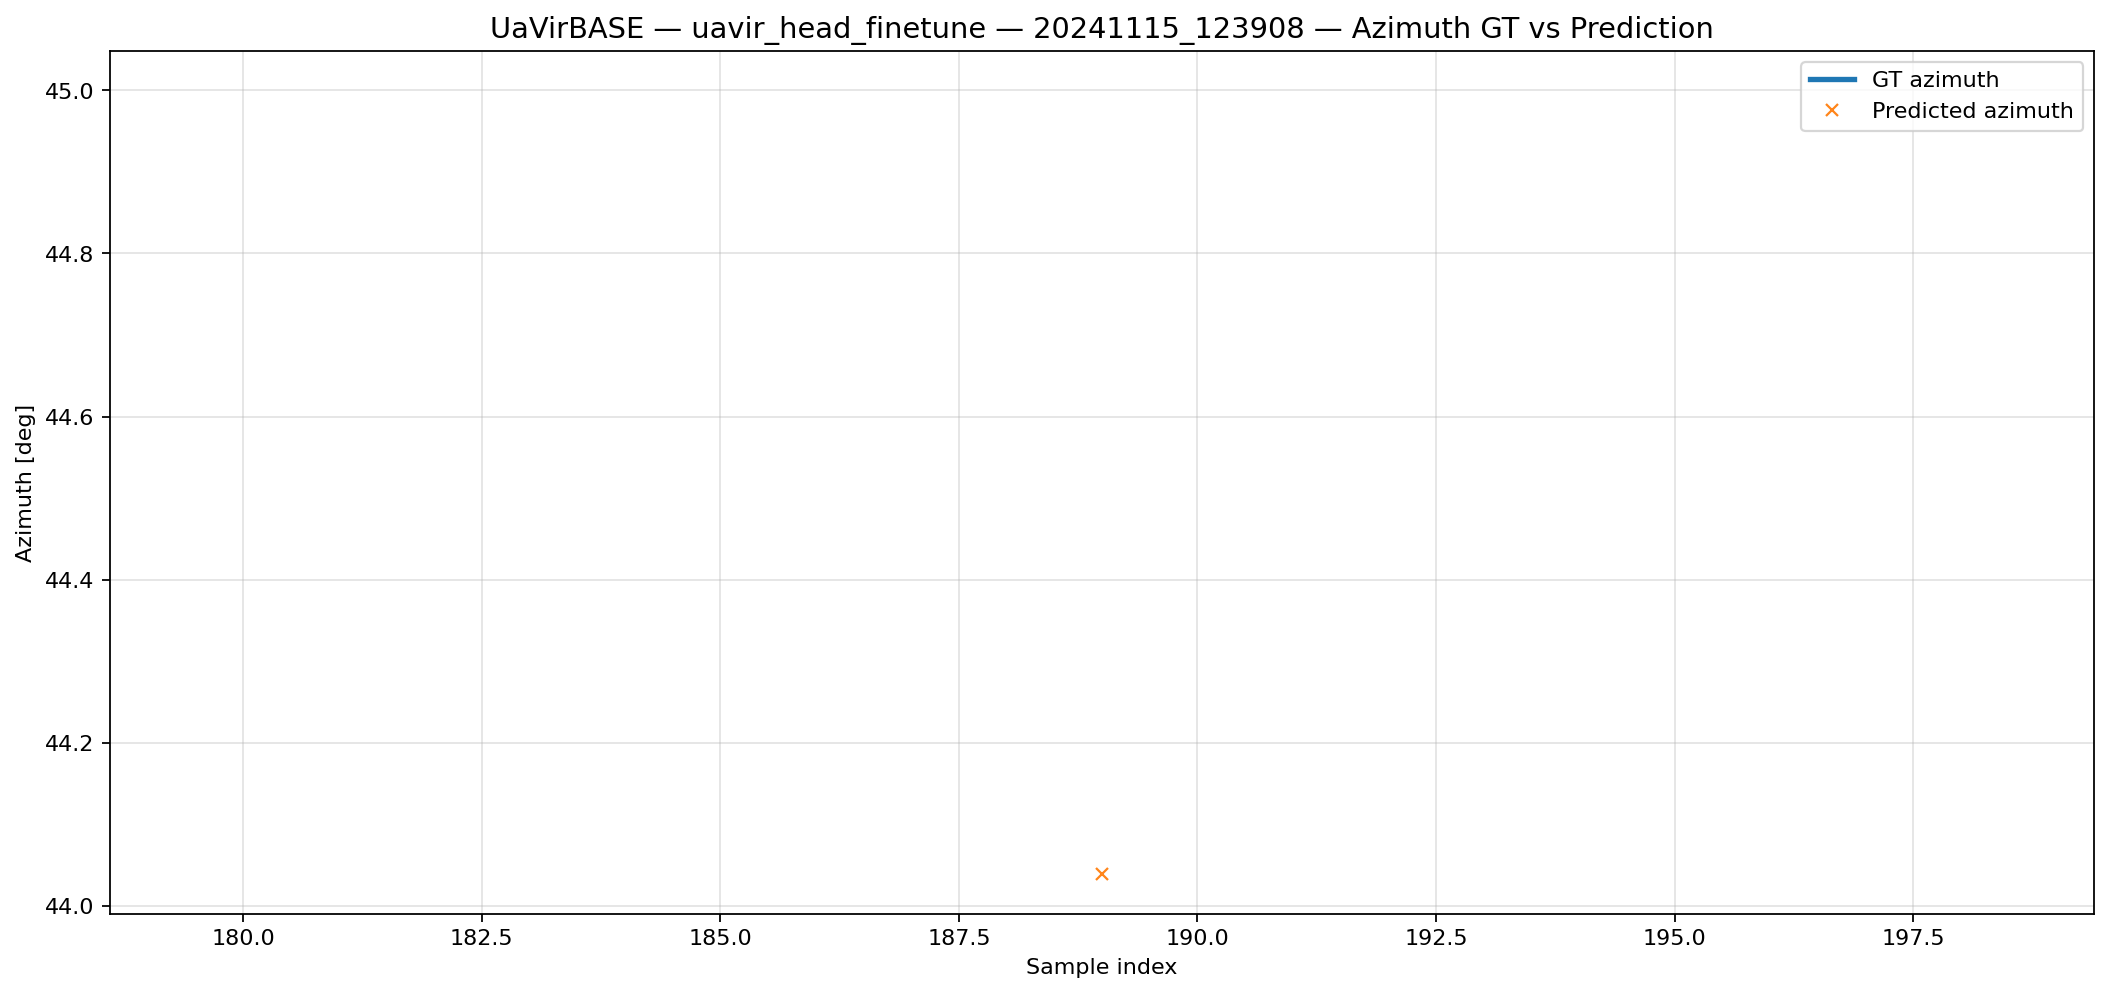

In [7]:
import os
import re
import json
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =============================================================================
# CONFIGURACAO PRINCIPAL
# =============================================================================

BASE_RESULTS = Path(r"C:\Users\Luis\Desktop\NASA_UAV\resultados_paper")
OUT_ROOT = Path(r"C:\Users\Luis\Desktop\NASA_UAV\FIGURES_FINAL")

DREGON_ROOT = BASE_RESULTS / "dregon"
UAVIRBASE_ROOT = BASE_RESULTS / "uavirbase"
NASA_ROOT = BASE_RESULTS / "nasa_uav"

# Cores padrao, fixas para TODOS os datasets e figuras
GT_COLOR = "tab:blue"
PRED_COLOR = "tab:orange"

# Estilo
FIG_W = 16
FIG_H = 7
DPI = 160
LINEWIDTH_GT = 2.4
MARKER_PRED = "x"
MARKERSIZE_PRED = 5
ALPHA_PRED = 0.95
GRID_ALPHA = 0.35

# Se True, remove figuras antigas da pasta de saida
CLEAR_OUTPUT_FIRST = False


# =============================================================================
# UTILITARIOS
# =============================================================================

def safe_mkdir(path: Path):
    path.mkdir(parents=True, exist_ok=True)


def clean_name(text: str) -> str:
    text = str(text)
    text = text.strip()
    text = re.sub(r"[^\w\-.]+", "_", text, flags=re.UNICODE)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")


def maybe_float_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")


def choose_latest_run(root: Path) -> Optional[Path]:
    if not root.exists():
        return None
    runs = [p for p in root.iterdir() if p.is_dir()]
    if not runs:
        return None
    runs = sorted(runs, key=lambda p: p.stat().st_mtime, reverse=True)
    return runs[0]


def recursive_find_files(root: Path, patterns: List[str]) -> List[Path]:
    found = []
    if not root.exists():
        return found
    for p in root.rglob("*"):
        if p.is_file():
            for pat in patterns:
                if p.match(pat) or p.name == pat:
                    found.append(p)
                    break
    return found


def infer_time_or_index(df: pd.DataFrame) -> Tuple[np.ndarray, str]:
    candidate_time_cols = [
        "time_sec", "time_s", "t_sec", "t_s", "time", "elapsed_sec",
        "seconds", "relative_time_sec", "timestamp_sec"
    ]
    for c in candidate_time_cols:
        if c in df.columns:
            vals = pd.to_numeric(df[c], errors="coerce").values
            if np.isfinite(vals).sum() >= max(3, len(vals) // 3):
                return vals, "Time since test start [s]"
    return np.arange(len(df)), "Sample index"


def find_first_existing(df: pd.DataFrame, names: List[str]) -> Optional[str]:
    lower_map = {c.lower(): c for c in df.columns}
    for n in names:
        if n in df.columns:
            return n
        if n.lower() in lower_map:
            return lower_map[n.lower()]
    return None


def plot_gt_vs_pred(
    x: np.ndarray,
    y_gt: np.ndarray,
    y_pred: np.ndarray,
    title: str,
    y_label: str,
    out_path: Path,
    gt_label: str,
    pred_label: str,
    x_label: str,
):
    mask = np.isfinite(y_gt) & np.isfinite(y_pred) & np.isfinite(x)
    x = np.asarray(x)[mask]
    y_gt = np.asarray(y_gt)[mask]
    y_pred = np.asarray(y_pred)[mask]

    if len(x) == 0:
        print(f"[WARN] Sem pontos válidos: {out_path}")
        return

    safe_mkdir(out_path.parent)

    plt.figure(figsize=(FIG_W, FIG_H), dpi=DPI)
    plt.plot(
        x,
        y_gt,
        color=GT_COLOR,
        linewidth=LINEWIDTH_GT,
        label=gt_label,
    )
    plt.plot(
        x,
        y_pred,
        linestyle="None",
        marker=MARKER_PRED,
        markersize=MARKERSIZE_PRED,
        color=PRED_COLOR,
        alpha=ALPHA_PRED,
        label=pred_label,
    )

    plt.title(title, fontsize=13)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True, alpha=GRID_ALPHA)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.close()

    print(f"[OK] Figura salva: {out_path}")


def clear_output_dir(path: Path):
    if not path.exists():
        return
    for p in sorted(path.rglob("*"), reverse=True):
        try:
            if p.is_file():
                p.unlink()
            elif p.is_dir():
                p.rmdir()
        except Exception:
            pass


# =============================================================================
# DREGON
# =============================================================================

def detect_dregon_prediction_files(dregon_root: Path) -> List[Path]:
    patterns = [
        "*prediction*.csv",
        "*predictions*.csv",
        "*gt_vs_pred*.csv",
        "*test_predictions*.csv",
    ]
    files = recursive_find_files(dregon_root, patterns)

    # Filtra arquivos que tenham mais chance de serem predições do strict ou gerais
    selected = []
    for f in files:
        name = f.name.lower()
        path_lower = str(f).lower()
        if any(k in name for k in ["pred", "prediction"]):
            if any(k in path_lower for k in ["strict", "confirmatory", "prediction", "predictions"]):
                selected.append(f)

    # remove duplicados
    selected = sorted(list(set(selected)))
    return selected


def plot_dregon_from_file(csv_path: Path, out_root: Path):
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"[WARN] Falha ao ler {csv_path}: {e}")
        return

    az_gt_col = find_first_existing(df, [
        "azimuth_gt_deg", "gt_azimuth_deg", "az_gt_deg", "y_true_azimuth_deg", "azimuth_gt"
    ])
    az_pr_col = find_first_existing(df, [
        "azimuth_pred_deg", "pred_azimuth_deg", "az_pred_deg", "y_pred_azimuth_deg", "azimuth_pred"
    ])
    el_gt_col = find_first_existing(df, [
        "elevation_gt_deg", "gt_elevation_deg", "el_gt_deg", "y_true_elevation_deg", "elevation_gt"
    ])
    el_pr_col = find_first_existing(df, [
        "elevation_pred_deg", "pred_elevation_deg", "el_pred_deg", "y_pred_elevation_deg", "elevation_pred"
    ])

    if az_gt_col is None or az_pr_col is None:
        return

    scenario_col = find_first_existing(df, ["scenario_key", "scenario", "scenario_name"])
    model_col = find_first_existing(df, ["model_id", "model", "mode"])
    split_col = find_first_existing(df, ["split", "eval_split", "subset"])

    if scenario_col is None:
        scenario_val = csv_path.parent.name
        df["_scenario_tmp_"] = scenario_val
        scenario_col = "_scenario_tmp_"

    if model_col is None:
        model_guess = "M1"
        m = re.search(r"(m[1-9])", csv_path.name.lower())
        if m:
            model_guess = m.group(1).upper()
        df["_model_tmp_"] = model_guess
        model_col = "_model_tmp_"

    if split_col is None:
        df["_split_tmp_"] = "unknown_split"
        split_col = "_split_tmp_"

    group_cols = [scenario_col, model_col, split_col]
    x_all, x_label = infer_time_or_index(df)

    # preserva índice/alinhamento
    df = df.copy()
    df["_x_plot_"] = x_all

    for (scenario, model, split), g in df.groupby(group_cols, dropna=False):
        scenario_s = clean_name(scenario)
        model_s = clean_name(model)
        split_s = clean_name(split)

        base_dir = out_root / "DREGON" / scenario_s / model_s / split_s

        x = maybe_float_series(g["_x_plot_"]).values
        az_gt = maybe_float_series(g[az_gt_col]).values
        az_pr = maybe_float_series(g[az_pr_col]).values

        az_out = base_dir / f"{scenario_s}_{model_s}_{split_s}_azimuth_gt_vs_pred.png"
        plot_gt_vs_pred(
            x=x,
            y_gt=az_gt,
            y_pred=az_pr,
            title=f"{scenario} — {model} — Azimuth GT vs Prediction",
            y_label="Azimuth [deg]",
            out_path=az_out,
            gt_label="GT azimuth",
            pred_label="Predicted azimuth",
            x_label=x_label,
        )

        if el_gt_col is not None and el_pr_col is not None:
            el_gt = maybe_float_series(g[el_gt_col]).values
            el_pr = maybe_float_series(g[el_pr_col]).values

            el_out = base_dir / f"{scenario_s}_{model_s}_{split_s}_elevation_gt_vs_pred.png"
            plot_gt_vs_pred(
                x=x,
                y_gt=el_gt,
                y_pred=el_pr,
                title=f"{scenario} — {model} — Elevation GT vs Prediction",
                y_label="Elevation [deg]",
                out_path=el_out,
                gt_label="GT elevation",
                pred_label="Predicted elevation",
                x_label=x_label,
            )


def run_dregon():
    print("\n" + "=" * 90)
    print("DREGON")
    print("=" * 90)

    latest = choose_latest_run(DREGON_ROOT)
    if latest is None:
        print("[WARN] Nenhum run DREGON encontrado.")
        return

    print(f"[INFO] Run DREGON usado: {latest}")

    files = detect_dregon_prediction_files(latest)
    if not files:
        print("[WARN] Nenhum CSV de predição DREGON encontrado automaticamente.")
        return

    print(f"[INFO] Arquivos candidatos DREGON: {len(files)}")
    for f in files:
        plot_dregon_from_file(f, OUT_ROOT)


# =============================================================================
# UAVIRBASE
# =============================================================================

def detect_uavirbase_prediction_files(u_root: Path) -> List[Path]:
    patterns = [
        "*external_predictions*.csv",
        "*session_predictions*.csv",
        "*predictions*.csv",
    ]
    files = recursive_find_files(u_root, patterns)

    selected = []
    for f in files:
        name = f.name.lower()
        if "uavirbase" in name or "external_predictions" in name or "session_predictions" in name:
            selected.append(f)
    return sorted(list(set(selected)))


def plot_uavirbase_from_file(csv_path: Path, out_root: Path):
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"[WARN] Falha ao ler {csv_path}: {e}")
        return

    az_gt_col = find_first_existing(df, [
        "azimuth_gt_deg", "gt_azimuth_deg", "az_gt_deg", "azimuth_gt"
    ])
    az_pr_col = find_first_existing(df, [
        "azimuth_pred_deg", "pred_azimuth_deg", "az_pred_deg", "azimuth_pred"
    ])
    el_gt_col = find_first_existing(df, [
        "elevation_gt_deg", "gt_elevation_deg", "el_gt_deg", "elevation_gt"
    ])
    el_pr_col = find_first_existing(df, [
        "elevation_pred_deg", "pred_elevation_deg", "el_pred_deg", "elevation_pred"
    ])

    if az_gt_col is None or az_pr_col is None:
        return

    mode_col = find_first_existing(df, ["mode", "model", "method"])
    session_col = find_first_existing(df, ["session_id", "session", "recording_id"])
    split_col = find_first_existing(df, ["split", "eval_split", "subset"])

    if mode_col is None:
        mode_guess = csv_path.stem
        df["_mode_tmp_"] = mode_guess
        mode_col = "_mode_tmp_"

    if session_col is None:
        df["_session_tmp_"] = "all_sessions"
        session_col = "_session_tmp_"

    if split_col is None:
        if "external" in csv_path.name.lower():
            df["_split_tmp_"] = "external_test"
        else:
            df["_split_tmp_"] = "unknown_split"
        split_col = "_split_tmp_"

    df = df.copy()
    x_all, x_label = infer_time_or_index(df)
    df["_x_plot_"] = x_all

    for (mode, session, split), g in df.groupby([mode_col, session_col, split_col], dropna=False):
        mode_s = clean_name(mode)
        session_s = clean_name(session)
        split_s = clean_name(split)

        base_dir = out_root / "UAVIRBASE" / mode_s / split_s / session_s

        x = maybe_float_series(g["_x_plot_"]).values
        az_gt = maybe_float_series(g[az_gt_col]).values
        az_pr = maybe_float_series(g[az_pr_col]).values

        az_out = base_dir / f"{mode_s}_{session_s}_{split_s}_azimuth_gt_vs_pred.png"
        plot_gt_vs_pred(
            x=x,
            y_gt=az_gt,
            y_pred=az_pr,
            title=f"UaVirBASE — {mode} — {session} — Azimuth GT vs Prediction",
            y_label="Azimuth [deg]",
            out_path=az_out,
            gt_label="GT azimuth",
            pred_label="Predicted azimuth",
            x_label=x_label,
        )

        if el_gt_col is not None and el_pr_col is not None:
            el_gt = maybe_float_series(g[el_gt_col]).values
            el_pr = maybe_float_series(g[el_pr_col]).values

            el_out = base_dir / f"{mode_s}_{session_s}_{split_s}_elevation_gt_vs_pred.png"
            plot_gt_vs_pred(
                x=x,
                y_gt=el_gt,
                y_pred=el_pr,
                title=f"UaVirBASE — {mode} — {session} — Elevation GT vs Prediction",
                y_label="Elevation [deg]",
                out_path=el_out,
                gt_label="GT elevation",
                pred_label="Predicted elevation",
                x_label=x_label,
            )


def run_uavirbase():
    print("\n" + "=" * 90)
    print("UAVIRBASE")
    print("=" * 90)

    latest = choose_latest_run(UAVIRBASE_ROOT)
    if latest is None:
        print("[WARN] Nenhum run UaVirBASE encontrado.")
        return

    print(f"[INFO] Run UaVirBASE usado: {latest}")

    files = detect_uavirbase_prediction_files(latest)
    if not files:
        print("[WARN] Nenhum CSV de predição UaVirBASE encontrado automaticamente.")
        return

    print(f"[INFO] Arquivos candidatos UaVirBASE: {len(files)}")
    for f in files:
        plot_uavirbase_from_file(f, OUT_ROOT)


# =============================================================================
# NASA
# =============================================================================

def detect_nasa_prediction_files(nasa_root: Path) -> List[Path]:
    patterns = [
        "predictions_all_modes.csv",
        "*predictions*.csv",
    ]
    files = recursive_find_files(nasa_root, patterns)

    selected = []
    for f in files:
        if f.name.lower() == "predictions_all_modes.csv":
            selected.append(f)
        elif "pred" in f.name.lower():
            selected.append(f)

    return sorted(list(set(selected)))


def plot_nasa_from_file(csv_path: Path, out_root: Path):
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"[WARN] Falha ao ler {csv_path}: {e}")
        return

    gt_col = find_first_existing(df, [
        "y_true_m", "gt_distance_m", "distance_gt_m", "ground_truth_m",
        "true_distance_m", "y_true", "gt"
    ])
    pr_col = find_first_existing(df, [
        "y_pred_m", "pred_distance_m", "distance_pred_m", "predicted_m",
        "pred_distance", "y_pred", "pred"
    ])

    if gt_col is None or pr_col is None:
        return

    mode_col = find_first_existing(df, ["mode", "model", "method"])
    split_col = find_first_existing(df, ["eval_split", "split", "subset"])
    vehicle_col = find_first_existing(df, ["vehicle", "target_vehicle", "platform"])
    file_col = find_first_existing(df, ["file", "file_id", "filename", "mat_file"])

    if mode_col is None:
        df["_mode_tmp_"] = "unknown_mode"
        mode_col = "_mode_tmp_"

    if split_col is None:
        df["_split_tmp_"] = "unknown_split"
        split_col = "_split_tmp_"

    if vehicle_col is None:
        df["_vehicle_tmp_"] = "unknown_vehicle"
        vehicle_col = "_vehicle_tmp_"

    if file_col is None:
        df["_file_tmp_"] = "all_files"
        file_col = "_file_tmp_"

    df = df.copy()
    x_all, x_label = infer_time_or_index(df)
    df["_x_plot_"] = x_all

    for (mode, split, vehicle, file_id), g in df.groupby([mode_col, split_col, vehicle_col, file_col], dropna=False):
        mode_s = clean_name(mode)
        split_s = clean_name(split)
        vehicle_s = clean_name(vehicle)
        file_s = clean_name(file_id)

        base_dir = out_root / "NASA" / mode_s / split_s / vehicle_s

        x = maybe_float_series(g["_x_plot_"]).values
        y_gt = maybe_float_series(g[gt_col]).values
        y_pr = maybe_float_series(g[pr_col]).values

        out_path = base_dir / f"{mode_s}_{split_s}_{vehicle_s}_{file_s}_distance_gt_vs_pred.png"
        plot_gt_vs_pred(
            x=x,
            y_gt=y_gt,
            y_pred=y_pr,
            title=f"NASA — {mode} — {split} — {vehicle} — {file_id} — GT vs Prediction",
            y_label="Distance [m]",
            out_path=out_path,
            gt_label="Ground truth distance",
            pred_label="Predicted distance",
            x_label=x_label,
        )


def run_nasa():
    print("\n" + "=" * 90)
    print("NASA")
    print("=" * 90)

    latest = choose_latest_run(NASA_ROOT)
    if latest is None:
        print("[WARN] Nenhum run NASA encontrado.")
        return

    print(f"[INFO] Run NASA usado: {latest}")

    files = detect_nasa_prediction_files(latest)
    if not files:
        print("[WARN] Nenhum CSV de predição NASA encontrado automaticamente.")
        return

    print(f"[INFO] Arquivos candidatos NASA: {len(files)}")
    for f in files:
        plot_nasa_from_file(f, OUT_ROOT)


# =============================================================================
# MAIN
# =============================================================================

def main():
    print("=" * 100)
    print("GERACAO DE FIGURAS FINAIS — GROUND TRUTH VS PREDICTED")
    print("=" * 100)
    print(f"BASE_RESULTS: {BASE_RESULTS}")
    print(f"OUT_ROOT    : {OUT_ROOT}")

    if CLEAR_OUTPUT_FIRST and OUT_ROOT.exists():
        print("[INFO] Limpando pasta de saída...")
        clear_output_dir(OUT_ROOT)

    safe_mkdir(OUT_ROOT)

    run_dregon()
    run_uavirbase()
    run_nasa()

    print("\n" + "=" * 100)
    print("FINALIZADO")
    print("=" * 100)
    print(f"Figuras salvas em: {OUT_ROOT}")


if __name__ == "__main__":
    main()

In [1]:
import numpy as np

path = r"D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602\features_windows_and_sequences.npz"

z = np.load(path, allow_pickle=True)

print("CHAVES DO NPZ:")
print(z.files)

print("\nSHAPES:")
for key in z.files:
    try:
        print(key, z[key].shape, z[key].dtype)
    except Exception:
        print(key, type(z[key]))

print("\nX_windows:")
print("shape =", z["X_windows"].shape)
print("n_features =", z["X_windows"].shape[1])

print("\nPOSSÍVEIS NOMES DAS FEATURES:")
for key in [
    "feature_names",
    "FEATURE_NAMES",
    "feat_names",
    "window_feature_names",
    "feature_columns",
    "FEATURE_COLUMNS",
    "input_feature_names",
    "X_columns",
]:
    if key in z.files:
        print(f"\nENCONTRADO: {key}")
        print(z[key])

CHAVES DO NPZ:
['X_windows_raw', 'X_windows', 'X_mean', 'X_std', 'Y_distance_m', 'Y_altitude_m', 'Y_MEAN', 'Y_STD']

SHAPES:
X_windows_raw (3792, 91) float32
X_windows (3792, 91) float32
X_mean (91,) float32
X_std (91,) float32
Y_distance_m (3792,) float32
Y_altitude_m (3792,) float32
Y_MEAN () float32
Y_STD () float32

X_windows:
shape = (3792, 91)
n_features = 91

POSSÍVEIS NOMES DAS FEATURES:


In [2]:
import pandas as pd

path = r"D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602\tables\window_feature_inventory.csv"

df = pd.read_csv(path)

print("SHAPE:", df.shape)

print("\nCOLUNAS:")
for i, col in enumerate(df.columns):
    print(f"{i:03d}: {col}")

print("\nPRIMEIRAS LINHAS:")
print(df.head())

print("\nTOTAL DE COLUNAS:", len(df.columns))

SHAPE: (3792, 18)

COLUNAS:
000: row_id
001: mat_file
002: relative_path
003: file_name
004: vehicle
005: flight_num
006: domain
007: position_source
008: rtk_good_frac
009: fs_hz
010: n_mics
011: window_start_sample
012: window_center_utc_s
013: distance_m
014: altitude_m
015: ned_north_m
016: ned_east_m
017: ned_down_m

PRIMEIRAS LINHAS:
   row_id                                           mat_file  \
0       0  D:\GE_DRONE\_small_uav_distance_ood\runs\run_2...   
1       1  D:\GE_DRONE\_small_uav_distance_ood\runs\run_2...   
2       2  D:\GE_DRONE\_small_uav_distance_ood\runs\run_2...   
3       3  D:\GE_DRONE\_small_uav_distance_ood\runs\run_2...   
4       4  D:\GE_DRONE\_small_uav_distance_ood\runs\run_2...   

              relative_path            file_name vehicle  flight_num domain  \
0  data\hex_flyover_200.mat  hex_flyover_200.mat     hex         200     ID   
1  data\hex_flyover_200.mat  hex_flyover_200.mat     hex         200     ID   
2  data\hex_flyover_200.mat  hex_fly

In [3]:
import json
import torch
from pathlib import Path

RUN = Path(
    r"D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602"
)

config_path = RUN / "run_config.json"
ckpt_path = RUN / "checkpoints" / "best_distance_lstm_model.pt"


def inspect(obj, prefix=""):
    """Procura campos potencialmente relacionados às 91 features."""
    keywords = [
        "feature",
        "feat",
        "column",
        "input",
        "window",
        "spect",
        "fft",
        "mfcc",
        "mel",
        "rms",
        "zcr",
        "centroid",
        "bandwidth",
        "rolloff",
    ]

    if isinstance(obj, dict):
        for key, value in obj.items():
            path = f"{prefix}.{key}" if prefix else str(key)

            if any(k in str(key).lower() for k in keywords):
                print("\nCAMPO:", path)
                print("TIPO :", type(value).__name__)

                if isinstance(value, (list, tuple)):
                    print("TAMANHO:", len(value))
                    print("VALOR:", value)
                elif not isinstance(value, dict):
                    print("VALOR:", value)

            inspect(value, path)

    elif isinstance(obj, (list, tuple)):
        # Muito importante: procurar lista de exatamente 91 strings
        if len(obj) == 91 and all(isinstance(x, str) for x in obj):
            print("\n" + "=" * 80)
            print("POSSÍVEL LISTA DAS 91 FEATURES")
            print("LOCAL:", prefix)
            print("=" * 80)

            for i, name in enumerate(obj):
                print(f"{i:02d}: {name}")

        for i, value in enumerate(obj):
            if isinstance(value, (dict, list, tuple)):
                inspect(value, f"{prefix}[{i}]")


# ==========================================================
# RUN_CONFIG.JSON
# ==========================================================

print("\n" + "=" * 100)
print("RUN_CONFIG.JSON")
print("=" * 100)

if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    print("\nCHAVES PRINCIPAIS:")
    print(list(config.keys()))

    inspect(config)
else:
    print("NÃO ENCONTRADO:", config_path)


# ==========================================================
# CHECKPOINT
# ==========================================================

print("\n" + "=" * 100)
print("CHECKPOINT")
print("=" * 100)

if ckpt_path.exists():
    ckpt = torch.load(
        ckpt_path,
        map_location="cpu",
        weights_only=False
    )

    if isinstance(ckpt, dict):
        print("\nCHAVES PRINCIPAIS:")
        print(list(ckpt.keys()))

    inspect(ckpt)

else:
    print("NÃO ENCONTRADO:", ckpt_path)


RUN_CONFIG.JSON

CHAVES PRINCIPAIS:
['ZIP_PATH', 'OUT_DIR', 'ID_VEHICLES', 'OOD_VEHICLES', 'RTK_GOOD_FRAC_MIN', 'POSITION_MODE', 'TARGET_SR', 'WIN_SEC', 'HOP_SEC', 'SEQ_LEN', 'N_FFT', 'N_MELS', 'MAX_MICS', 'FEAT_DIM', 'BATCH_SIZE', 'HIDDEN_DIM', 'NUM_LAYERS', 'DROPOUT', 'LR', 'WEIGHT_DECAY', 'MAX_EPOCHS', 'PATIENCE', 'OOD_THRESHOLD_QUANTILE']

CAMPO: N_FFT
TIPO : int
VALOR: 1024

CAMPO: N_MELS
TIPO : int
VALOR: 64

CAMPO: FEAT_DIM
TIPO : int
VALOR: 91

CHECKPOINT

CHAVES PRINCIPAIS:
['epoch', 'model_state', 'best_val_mae_m', 'X_mean', 'X_std', 'Y_MEAN', 'Y_STD', 'config']

CAMPO: model_state.input_norm.weight
TIPO : Tensor
VALOR: tensor([0.9996, 1.0039, 1.0077, 0.9979, 1.0041, 1.0015, 0.9994, 1.0020, 0.9946,
        1.0011, 0.9980, 1.0047, 0.9956, 0.9940, 0.9951, 1.0005, 1.0074, 0.9962,
        0.9909, 1.0055, 0.9923, 1.0008, 0.9951, 0.9919, 0.9972, 0.9975, 1.0019,
        1.0006, 0.9998, 1.0050, 1.0024, 0.9990, 1.0017, 0.9949, 0.9962, 1.0037,
        1.0023, 1.0002, 0.9997, 1.0046, 0

In [4]:
# =============================================================================
# NASA SMALL-UAS — AUDITORIA E RECUPERACAO DAS 91 FEATURES
# =============================================================================
#
# Objetivos:
#
# 1. Carregar:
#       - features_windows_and_sequences.npz
#       - run_config.json
#       - best_distance_lstm_model.pt
#
# 2. Verificar exatamente a normalizacao:
#       X_windows ?= (X_windows_raw - X_mean) / X_std
#
# 3. Procurar nomes das 91 features em:
#       - NPZ
#       - JSON
#       - checkpoint
#       - scripts .py
#       - notebooks .ipynb
#       - .txt / .md / .json / .bak
#
# 4. Procurar automaticamente:
#       - listas com exatamente 91 strings
#       - feature_names
#       - np.concatenate / np.hstack
#       - melspectrogram
#       - MFCC
#       - RMS
#       - spectral centroid
#       - bandwidth
#       - rolloff
#       - zero-crossing rate
#       - GCC/TDOA etc.
#
# 5. Analisar estatisticamente X_windows_raw para procurar
#    fronteiras entre blocos.
#
# 6. Testar especificamente a hipotese:
#
#           91 = 64 + 27
#
#    SEM afirmar que os primeiros 64 sao Mel.
#
# 7. Gerar relatorios CSV/TXT.
#
# =============================================================================

from __future__ import annotations

import ast
import json
import math
import os
import re
import sys
import traceback
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd


# =============================================================================
# CONFIGURACAO
# =============================================================================

RUN_DIR = Path(
    r"D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602"
)

NPZ_PATH = RUN_DIR / "features_windows_and_sequences.npz"
CONFIG_PATH = RUN_DIR / "run_config.json"
CKPT_PATH = RUN_DIR / "checkpoints" / "best_distance_lstm_model.pt"

# Diretorios onde procurar o codigo original.
SEARCH_ROOTS = [
    Path(r"D:\GE_DRONE"),
    Path(r"C:\Users\Luis\Desktop"),
    Path(r"C:\Users\Luis\Documents"),
    Path(r"C:\Users\Luis\Downloads"),
    Path(r"C:\Users\Luis\AppData\Local\Temp"),
]

# Tipos de arquivo examinados.
SEARCH_EXTENSIONS = {
    ".py",
    ".ipynb",
    ".txt",
    ".md",
    ".json",
    ".bak",
    ".old",
}

# Evita arquivos gigantes.
MAX_TEXT_FILE_MB = 50

# Quantidade maxima de snippets por arquivo.
MAX_SNIPPETS_PER_FILE = 30

OUT_DIR = RUN_DIR / "feature_forensics"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# TERMOS IMPORTANTES
# =============================================================================

# Assinaturas muito especificas do pipeline NASA.
NASA_SIGNATURES = [
    "RTK_GOOD_FRAC_MIN",
    "POSITION_MODE",
    "rtk_then_gps",
    "TARGET_SR",
    "WIN_SEC",
    "HOP_SEC",
    "SEQ_LEN",
    "N_FFT",
    "N_MELS",
    "MAX_MICS",
    "FEAT_DIM",
    "OOD_THRESHOLD_QUANTILE",
    "window_center_utc_s",
    "rtk_good_frac",
    "ned_north_m",
    "ned_east_m",
    "ned_down_m",
    "distance_m",
    "altitude_m",
]

# Termos associados a construcao das features.
FEATURE_TERMS = [
    "feature_names",
    "FEATURE_NAMES",
    "feat_names",
    "feature_columns",
    "FEATURE_COLUMNS",
    "input_feature_names",
    "window_feature_names",

    "X_windows_raw",
    "X_windows",
    "X_mean",
    "X_std",

    "np.concatenate",
    "np.hstack",
    "np.vstack",
    "concatenate(",
    "hstack(",

    "melspectrogram",
    "mel_spectrogram",
    "N_MELS",
    "mfcc",
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_rolloff",
    "zero_crossing_rate",
    "rms",
    "chroma",
    "spectral_flatness",
    "spectral_contrast",

    "stft",
    "fft",
    "welch",
    "psd",

    "gcc",
    "gcc_phat",
    "tdoa",
    "cross_correlation",

    "skew",
    "kurtosis",
    "crest",
    "entropy",
    "energy",
]

# Nomes de variaveis que merecem prioridade na AST.
FEATURE_NAME_VARIABLES = {
    "feature_names",
    "FEATURE_NAMES",
    "feat_names",
    "FEATURE_COLUMNS",
    "feature_columns",
    "input_feature_names",
    "window_feature_names",
    "features_names",
    "features",
}


# =============================================================================
# UTILITARIOS
# =============================================================================

def section(title):
    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)


def safe_read_text(path: Path):
    try:
        size_mb = path.stat().st_size / (1024 ** 2)

        if size_mb > MAX_TEXT_FILE_MB:
            return None

        for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
            try:
                return path.read_text(encoding=enc, errors="strict")
            except Exception:
                continue

        return path.read_text(encoding="utf-8", errors="ignore")

    except Exception:
        return None


def flatten_dict(d, prefix=""):
    """Transforma dict aninhado em pares caminho -> valor."""
    out = {}

    if isinstance(d, dict):
        for k, v in d.items():
            new_prefix = f"{prefix}.{k}" if prefix else str(k)
            out.update(flatten_dict(v, new_prefix))

    elif isinstance(d, (list, tuple)):
        out[prefix] = d

    else:
        out[prefix] = d

    return out


def is_string_list(obj, length=None):
    if not isinstance(obj, (list, tuple)):
        return False

    if length is not None and len(obj) != length:
        return False

    return all(isinstance(x, str) for x in obj)


# =============================================================================
# ETAPA 1 — CARREGAMENTO DOS ARTEFATOS
# =============================================================================

section("1. CARREGANDO ARTEFATOS")

for p in [NPZ_PATH, CONFIG_PATH, CKPT_PATH]:
    print(f"{p}")
    print("   existe:", p.exists())


if not NPZ_PATH.exists():
    raise FileNotFoundError(NPZ_PATH)

z = np.load(NPZ_PATH, allow_pickle=True)

print("\nNPZ keys:")
print(list(z.keys()))


# -----------------------------------------------------------------------------
# matrizes
# -----------------------------------------------------------------------------

Xraw = np.asarray(z["X_windows_raw"], dtype=np.float64)
X = np.asarray(z["X_windows"], dtype=np.float64)

Xmean_npz = np.asarray(z["X_mean"], dtype=np.float64)
Xstd_npz = np.asarray(z["X_std"], dtype=np.float64)

print("\nShapes:")
print("X_windows_raw:", Xraw.shape)
print("X_windows    :", X.shape)
print("X_mean       :", Xmean_npz.shape)
print("X_std        :", Xstd_npz.shape)

N_SAMPLES, FEAT_DIM = Xraw.shape

print("\nN samples :", N_SAMPLES)
print("FEAT_DIM  :", FEAT_DIM)


# -----------------------------------------------------------------------------
# config
# -----------------------------------------------------------------------------

config = {}

if CONFIG_PATH.exists():
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = json.load(f)

    print("\nRun config:")

    for key in [
        "TARGET_SR",
        "WIN_SEC",
        "HOP_SEC",
        "SEQ_LEN",
        "N_FFT",
        "N_MELS",
        "MAX_MICS",
        "FEAT_DIM",
    ]:
        print(f"{key:15s}: {config.get(key)}")


# =============================================================================
# ETAPA 2 — VERIFICAR NORMALIZACAO
# =============================================================================

section("2. VERIFICANDO NORMALIZACAO X_windows")

eps_candidates = [
    0.0,
    1e-12,
    1e-10,
    1e-8,
    1e-7,
    1e-6,
]

normalization_results = []

for eps in eps_candidates:

    denom = Xstd_npz + eps
    Xcalc = (Xraw - Xmean_npz) / denom

    abs_err = np.abs(Xcalc - X)

    mae = np.nanmean(abs_err)
    maxerr = np.nanmax(abs_err)

    close = np.allclose(
        Xcalc,
        X,
        rtol=1e-5,
        atol=1e-6,
        equal_nan=True,
    )

    normalization_results.append(
        {
            "epsilon": eps,
            "allclose": close,
            "MAE": mae,
            "MAX_ERROR": maxerr,
        }
    )

norm_df = pd.DataFrame(normalization_results)

print(norm_df.to_string(index=False))

norm_df.to_csv(
    OUT_DIR / "normalization_test.csv",
    index=False,
)


# =============================================================================
# ETAPA 3 — COMPARAR MEDIA/STD ARMAZENADAS COM Xraw
# =============================================================================

section("3. ESTATISTICAS GLOBAIS")

emp_mean = np.nanmean(Xraw, axis=0)
emp_std = np.nanstd(Xraw, axis=0)

mean_diff = np.abs(emp_mean - Xmean_npz)
std_diff = np.abs(emp_std - Xstd_npz)

print("Erro medio |mean(Xraw) - X_mean|:")
print(np.mean(mean_diff))

print("\nErro maximo:")
print(np.max(mean_diff))

print("\nErro medio |std(Xraw) - X_std|:")
print(np.mean(std_diff))

print("\nErro maximo:")
print(np.max(std_diff))

print(
    "\nOBSERVACAO: coincidencia com todo Xraw nao prova que "
    "as estatisticas foram calculadas usando todo o conjunto. "
    "Para saber se foram train-only precisamos do codigo/split."
)


# =============================================================================
# ETAPA 4 — PROCURAR NOMES DENTRO DO NPZ
# =============================================================================

section("4. PROCURANDO NOMES DE FEATURES NO NPZ")

npz_name_candidates = []

for key in z.keys():

    obj = z[key]

    try:
        arr = np.asarray(obj)

        # Arrays de strings.
        if arr.dtype.kind in {"U", "S", "O"}:

            vals = arr.ravel().tolist()

            if len(vals) == FEAT_DIM and all(
                isinstance(x, (str, np.str_)) for x in vals
            ):
                npz_name_candidates.append(
                    (key, [str(x) for x in vals])
                )

    except Exception:
        pass


if npz_name_candidates:

    print("ENCONTRADO!")

    for key, names in npz_name_candidates:
        print("\nKEY:", key)

        for i, name in enumerate(names):
            print(i, name)

else:
    print("Nenhuma lista de 91 nomes encontrada no NPZ.")


# =============================================================================
# ETAPA 5 — CHECKPOINT
# =============================================================================

section("5. INSPECIONANDO CHECKPOINT")

checkpoint = None

try:
    import torch

    checkpoint = torch.load(
        CKPT_PATH,
        map_location="cpu",
        weights_only=False,
    )

    print("Checkpoint keys:")
    print(list(checkpoint.keys()))

except Exception as e:
    print("Nao foi possivel carregar checkpoint:")
    print(e)


checkpoint_name_candidates = []


def recursively_search_strings(obj, path="root", results=None):
    if results is None:
        results = []

    if isinstance(obj, dict):

        for k, v in obj.items():

            new_path = f"{path}.{k}"

            if is_string_list(v, FEAT_DIM):
                results.append(
                    (new_path, list(v))
                )

            recursively_search_strings(
                v,
                new_path,
                results,
            )

    elif isinstance(obj, (list, tuple)):

        if is_string_list(obj, FEAT_DIM):
            results.append(
                (path, list(obj))
            )

        for i, v in enumerate(obj):
            recursively_search_strings(
                v,
                f"{path}[{i}]",
                results,
            )

    return results


if checkpoint is not None:

    checkpoint_name_candidates = recursively_search_strings(
        checkpoint
    )

    if checkpoint_name_candidates:

        print("\nLISTAS DE 91 STRINGS ENCONTRADAS:")

        for p, names in checkpoint_name_candidates:

            print("\n", p)

            for i, name in enumerate(names):
                print(i, name)

    else:
        print(
            "\nNenhuma lista de 91 nomes encontrada "
            "dentro do checkpoint."
        )


# =============================================================================
# ETAPA 6 — ESTATISTICAS POR DIMENSAO
# =============================================================================

section("6. ESTATISTICAS DAS 91 DIMENSOES")

try:
    from scipy.stats import skew, kurtosis

    skew_vals = skew(
        Xraw,
        axis=0,
        nan_policy="omit",
        bias=False,
    )

    kurt_vals = kurtosis(
        Xraw,
        axis=0,
        nan_policy="omit",
        bias=False,
    )

except Exception:

    print("SciPy indisponivel: skew/kurtosis omitidos.")

    skew_vals = np.full(FEAT_DIM, np.nan)
    kurt_vals = np.full(FEAT_DIM, np.nan)


feature_stats = []

for i in range(FEAT_DIM):

    xi = Xraw[:, i]

    feature_stats.append(
        {
            "index": i,
            "mean": np.nanmean(xi),
            "std": np.nanstd(xi),
            "min": np.nanmin(xi),
            "q01": np.nanpercentile(xi, 1),
            "q25": np.nanpercentile(xi, 25),
            "median": np.nanmedian(xi),
            "q75": np.nanpercentile(xi, 75),
            "q99": np.nanpercentile(xi, 99),
            "max": np.nanmax(xi),
            "skew": skew_vals[i],
            "kurtosis": kurt_vals[i],
            "zero_fraction": np.mean(xi == 0),
            "finite_fraction": np.mean(np.isfinite(xi)),
            "stored_X_mean": Xmean_npz[i],
            "stored_X_std": Xstd_npz[i],
        }
    )

stats_df = pd.DataFrame(feature_stats)

stats_path = OUT_DIR / "feature_statistics_91.csv"

stats_df.to_csv(
    stats_path,
    index=False,
)

print(stats_df.to_string(index=False))

print("\nSalvo:")
print(stats_path)


# =============================================================================
# ETAPA 7 — MATRIZ DE CORRELACAO
# =============================================================================

section("7. CORRELACAO ENTRE DIMENSOES")

Xcorr = Xraw.copy()

# substitui NaN pela mediana da coluna para correlacao
for i in range(FEAT_DIM):

    col = Xcorr[:, i]

    bad = ~np.isfinite(col)

    if np.any(bad):
        med = np.nanmedian(col)
        col[bad] = med

corr = np.corrcoef(
    Xcorr,
    rowvar=False,
)

pd.DataFrame(corr).to_csv(
    OUT_DIR / "feature_correlation_matrix.csv",
    index=False,
)


# correlacao entre features adjacentes

adj_corr = []

for i in range(FEAT_DIM - 1):

    c = corr[i, i + 1]

    adj_corr.append(
        {
            "left": i,
            "right": i + 1,
            "correlation": c,
            "abs_correlation": abs(c),
        }
    )

adj_df = pd.DataFrame(adj_corr)

adj_df.to_csv(
    OUT_DIR / "adjacent_feature_correlations.csv",
    index=False,
)

print(
    adj_df.sort_values(
        "abs_correlation",
        ascending=False,
    ).head(20).to_string(index=False)
)


# =============================================================================
# ETAPA 8 — PROCURAR FRONTEIRAS ENTRE BLOCOS
# =============================================================================

section("8. DETECCAO DE POSSIVEIS FRONTEIRAS")

# Mede quanto a distribuicao muda entre feature i e i+1.
#
# Usa:
#   - diferenca de log(std)
#   - diferenca de skew
#   - diferenca de kurtosis
#   - quebra de correlacao adjacente

boundary_scores = []

stds = stats_df["std"].to_numpy()
skews = stats_df["skew"].to_numpy()
kurts = stats_df["kurtosis"].to_numpy()

logstd = np.log10(
    np.maximum(stds, 1e-12)
)

for split in range(1, FEAT_DIM):

    left = split - 1
    right = split

    d_std = abs(
        logstd[right] - logstd[left]
    )

    d_skew = abs(
        np.nan_to_num(skews[right]) -
        np.nan_to_num(skews[left])
    )

    d_kurt = abs(
        np.nan_to_num(kurts[right]) -
        np.nan_to_num(kurts[left])
    )

    adjacent_correlation = corr[left, right]

    corr_break = 1.0 - abs(
        np.nan_to_num(adjacent_correlation)
    )

    # normalizacao simples dos componentes
    score = (
        d_std +
        0.10 * d_skew +
        0.03 * d_kurt +
        corr_break
    )

    boundary_scores.append(
        {
            "split_after_index": left,
            "next_index": right,
            "left_block_size": split,
            "right_block_size": FEAT_DIM - split,
            "std_change": d_std,
            "skew_change": d_skew,
            "kurtosis_change": d_kurt,
            "adjacent_corr": adjacent_correlation,
            "boundary_score": score,
        }
    )

boundary_df = pd.DataFrame(
    boundary_scores
)

boundary_df = boundary_df.sort_values(
    "boundary_score",
    ascending=False,
)

boundary_df.to_csv(
    OUT_DIR / "candidate_feature_boundaries.csv",
    index=False,
)

print("\nMaiores candidatas a fronteira:")
print(
    boundary_df.head(20).to_string(index=False)
)


# =============================================================================
# ETAPA 9 — TESTE ESPECIFICO DA FRONTEIRA 64 / 27
# =============================================================================

section("9. TESTE DA HIPOTESE 64 + 27")

if FEAT_DIM == 91:

    A = Xraw[:, :64]
    B = Xraw[:, 64:]

    def block_summary(block, name):

        C = np.corrcoef(
            block,
            rowvar=False,
        )

        if block.shape[1] > 1:
            adj = np.diag(C, k=1)
        else:
            adj = np.array([])

        return {
            "block": name,
            "n_features": block.shape[1],
            "mean_feature_mean": np.mean(
                np.mean(block, axis=0)
            ),
            "mean_feature_std": np.mean(
                np.std(block, axis=0)
            ),
            "median_feature_std": np.median(
                np.std(block, axis=0)
            ),
            "mean_adjacent_corr": (
                np.nanmean(adj)
                if len(adj)
                else np.nan
            ),
            "mean_abs_adjacent_corr": (
                np.nanmean(np.abs(adj))
                if len(adj)
                else np.nan
            ),
        }

    block_df = pd.DataFrame(
        [
            block_summary(A, "0-63"),
            block_summary(B, "64-90"),
        ]
    )

    print(block_df.to_string(index=False))

    block_df.to_csv(
        OUT_DIR / "block_64_27_diagnostics.csv",
        index=False,
    )

    print("\nCorrelacao feature 63 vs 64:")
    print(corr[63, 64])

    exact_boundary = pd.DataFrame(
        boundary_scores
    )

    row64 = exact_boundary[
        exact_boundary["left_block_size"] == 64
    ]

    print("\nScore da fronteira apos feature 63:")
    print(row64.to_string(index=False))

else:

    print(
        "FEAT_DIM != 91; teste 64+27 nao aplicavel."
    )


# =============================================================================
# ETAPA 10 — PROCURAR QUALQUER BLOCO CONTIGUO DE 64 DIMENSOES
# =============================================================================

section("10. QUAL BLOCO CONTIGUO DE 64 FEATURES PARECE MAIS 'ESPECTRAL'?")

# Um vetor log-Mel agregado frequentemente possui elevada correlacao
# entre bandas vizinhas.
#
# Isto e apenas um indicador numerico, NAO prova semantica.

mel_block_candidates = []

if FEAT_DIM >= 64:

    for start in range(
        0,
        FEAT_DIM - 64 + 1,
    ):

        end = start + 64

        block_corr = corr[
            start:end,
            start:end,
        ]

        adjacent = np.diag(
            block_corr,
            k=1,
        )

        score = np.nanmean(
            np.abs(adjacent)
        )

        mel_block_candidates.append(
            {
                "start": start,
                "end_inclusive": end - 1,
                "size": 64,
                "mean_abs_adjacent_corr": score,
            }
        )

    mel_candidate_df = pd.DataFrame(
        mel_block_candidates
    ).sort_values(
        "mean_abs_adjacent_corr",
        ascending=False,
    )

    print(
        mel_candidate_df.head(15).to_string(
            index=False
        )
    )

    mel_candidate_df.to_csv(
        OUT_DIR / "possible_64dim_blocks.csv",
        index=False,
    )


# =============================================================================
# ETAPA 11 — BUSCA EM CODIGO-FONTE
# =============================================================================

section("11. PROCURANDO CODIGO ORIGINAL")

source_candidates = []
source_snippets = []


def iter_source_files():

    seen = set()

    for root in SEARCH_ROOTS:

        if not root.exists():
            continue

        print("Buscando:", root)

        try:
            iterator = root.rglob("*")
        except Exception:
            continue

        for p in iterator:

            try:

                if not p.is_file():
                    continue

                if p.suffix.lower() not in SEARCH_EXTENSIONS:
                    continue

                rp = str(p.resolve()).lower()

                if rp in seen:
                    continue

                seen.add(rp)

                yield p

            except Exception:
                continue


for counter, path in enumerate(
    iter_source_files(),
    start=1,
):

    text = safe_read_text(path)

    if text is None:
        continue

    signature_hits = [
        t
        for t in NASA_SIGNATURES
        if t.lower() in text.lower()
    ]

    feature_hits = [
        t
        for t in FEATURE_TERMS
        if t.lower() in text.lower()
    ]

    # Pontuacao.
    #
    # Assinaturas NASA valem mais porque termos como "rms"
    # aparecem em muitos projetos.
    score = (
        5 * len(signature_hits) +
        1 * len(feature_hits)
    )

    if score == 0:
        continue

    source_candidates.append(
        {
            "path": str(path),
            "score": score,
            "NASA_hits": len(signature_hits),
            "feature_hits": len(feature_hits),
            "NASA_terms": " | ".join(
                signature_hits
            ),
            "feature_terms": " | ".join(
                feature_hits
            ),
        }
    )

    # snippets apenas para candidatos relevantes
    if (
        len(signature_hits) >= 3
        or "X_windows_raw" in text
        or "FEAT_DIM" in text
    ):

        lines = text.splitlines()

        match_count = 0

        for lineno, line in enumerate(
            lines,
            start=1,
        ):

            ll = line.lower()

            relevant = [
                t
                for t in (
                    NASA_SIGNATURES +
                    FEATURE_TERMS
                )
                if t.lower() in ll
            ]

            if not relevant:
                continue

            source_snippets.append(
                {
                    "path": str(path),
                    "line": lineno,
                    "text": line.strip(),
                    "terms": " | ".join(
                        relevant
                    ),
                }
            )

            match_count += 1

            if (
                match_count >=
                MAX_SNIPPETS_PER_FILE
            ):
                break


candidate_df = pd.DataFrame(
    source_candidates
)

if len(candidate_df):

    candidate_df = candidate_df.sort_values(
        [
            "score",
            "NASA_hits",
            "feature_hits",
        ],
        ascending=False,
    )

    candidate_df.to_csv(
        OUT_DIR / "source_code_candidates.csv",
        index=False,
    )

    print("\nTOP 30 ARQUIVOS:")
    print(
        candidate_df.head(30)[
            [
                "score",
                "NASA_hits",
                "feature_hits",
                "path",
            ]
        ].to_string(index=False)
    )

else:

    print("Nenhum candidato encontrado.")


if source_snippets:

    pd.DataFrame(
        source_snippets
    ).to_csv(
        OUT_DIR / "source_code_snippets.csv",
        index=False,
    )


# =============================================================================
# ETAPA 12 — AST: PROCURAR LISTAS COM EXATAMENTE 91 STRINGS
# =============================================================================

section("12. PROCURANDO LISTAS LITERAIS COM 91 NOMES")

literal_91_lists = []


def get_literal_string_list(node):

    if not isinstance(
        node,
        (ast.List, ast.Tuple),
    ):
        return None

    values = []

    for element in node.elts:

        if (
            isinstance(element, ast.Constant)
            and isinstance(
                element.value,
                str,
            )
        ):
            values.append(
                element.value
            )
        else:
            return None

    return values


# examina primeiro candidatos mais fortes
paths_for_ast = []

if len(candidate_df):

    paths_for_ast = [
        Path(x)
        for x in candidate_df[
            candidate_df["path"].str.endswith(
                ".py",
                na=False,
            )
        ]["path"].tolist()
    ]


for path in paths_for_ast:

    text = safe_read_text(path)

    if text is None:
        continue

    try:
        tree = ast.parse(text)
    except Exception:
        continue

    for node in ast.walk(tree):

        # Ex:
        # FEATURE_NAMES = [...]
        if isinstance(
            node,
            (ast.Assign, ast.AnnAssign),
        ):

            value = getattr(
                node,
                "value",
                None,
            )

            vals = get_literal_string_list(
                value
            )

            if (
                vals is not None
                and len(vals) == FEAT_DIM
            ):

                variable = "UNKNOWN"

                if isinstance(
                    node,
                    ast.Assign,
                ):
                    targets = node.targets

                    if (
                        targets and
                        isinstance(
                            targets[0],
                            ast.Name,
                        )
                    ):
                        variable = (
                            targets[0].id
                        )

                elif isinstance(
                    node,
                    ast.AnnAssign,
                ):

                    if isinstance(
                        node.target,
                        ast.Name,
                    ):
                        variable = (
                            node.target.id
                        )

                literal_91_lists.append(
                    {
                        "path": str(path),
                        "line": getattr(
                            node,
                            "lineno",
                            None,
                        ),
                        "variable": variable,
                        "values": vals,
                    }
                )


if literal_91_lists:

    print(
        f"\nENCONTRADAS "
        f"{len(literal_91_lists)} "
        f"LISTAS COM EXATAMENTE "
        f"{FEAT_DIM} STRINGS!"
    )

    rows = []

    for item in literal_91_lists:

        print("\nARQUIVO:")
        print(item["path"])

        print("LINHA:", item["line"])
        print("VARIAVEL:", item["variable"])

        for i, name in enumerate(
            item["values"]
        ):
            print(
                f"{i:02d}: {name}"
            )

            rows.append(
                {
                    "path": item["path"],
                    "line": item["line"],
                    "variable": item[
                        "variable"
                    ],
                    "index": i,
                    "feature_name": name,
                }
            )

    pd.DataFrame(rows).to_csv(
        OUT_DIR /
        "EXACT_91_FEATURE_NAMES_FOUND.csv",
        index=False,
    )

else:

    print(
        "Nenhuma lista literal com "
        "91 strings encontrada."
    )


# =============================================================================
# ETAPA 13 — PROCURAR CONCATENACOES NOS MELHORES CANDIDATOS
# =============================================================================

section("13. PROCURANDO CONSTRUCAO DO VETOR")

concat_patterns = [
    r"np\.concatenate",
    r"np\.hstack",
    r"concatenate\(",
    r"hstack\(",
    r"feature.*=",
    r"features.*=",
    r"return.*feature",
    r"return.*feat",
]

concat_rows = []

if len(candidate_df):

    top_paths = candidate_df.head(
        100
    )["path"].tolist()

    for path_str in top_paths:

        path = Path(path_str)

        if path.suffix.lower() not in {
            ".py",
            ".ipynb",
        }:
            continue

        text = safe_read_text(path)

        if text is None:
            continue

        lines = text.splitlines()

        for lineno, line in enumerate(
            lines,
            start=1,
        ):

            if any(
                re.search(
                    p,
                    line,
                    flags=re.I,
                )
                for p in concat_patterns
            ):

                # captura contexto +/- 3 linhas
                lo = max(
                    0,
                    lineno - 4,
                )

                hi = min(
                    len(lines),
                    lineno + 3,
                )

                context = "\n".join(
                    f"{j+1}: {lines[j]}"
                    for j in range(
                        lo,
                        hi,
                    )
                )

                concat_rows.append(
                    {
                        "path": str(path),
                        "line": lineno,
                        "context": context,
                    }
                )


if concat_rows:

    concat_df = pd.DataFrame(
        concat_rows
    )

    concat_df.to_csv(
        OUT_DIR /
        "possible_feature_construction.csv",
        index=False,
    )

    print(
        f"{len(concat_df)} locais "
        "potencialmente relevantes encontrados."
    )

    print(
        "\nVeja:"
    )

    print(
        OUT_DIR /
        "possible_feature_construction.csv"
    )

else:

    print(
        "Nenhuma concatenacao relevante "
        "encontrada."
    )


# =============================================================================
# ETAPA 14 — RELATORIO FINAL
# =============================================================================

section("14. RESUMO")

report_path = (
    OUT_DIR /
    "FEATURE_DISCOVERY_REPORT.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8",
) as f:

    f.write(
        "NASA SMALL-UAS FEATURE FORENSICS\n"
    )

    f.write(
        "=" * 80 + "\n\n"
    )

    f.write(
        f"NPZ: {NPZ_PATH}\n"
    )

    f.write(
        f"shape X_windows_raw: "
        f"{Xraw.shape}\n"
    )

    f.write(
        f"FEAT_DIM: {FEAT_DIM}\n"
    )

    f.write(
        f"N_MELS: "
        f"{config.get('N_MELS')}\n"
    )

    f.write(
        f"N_FFT: "
        f"{config.get('N_FFT')}\n"
    )

    f.write(
        f"MAX_MICS: "
        f"{config.get('MAX_MICS')}\n"
    )

    f.write("\n")

    exact_names_found = (
        bool(npz_name_candidates)
        or bool(
            checkpoint_name_candidates
        )
        or bool(
            literal_91_lists
        )
    )

    f.write(
        "EXACT FEATURE NAMES FOUND: "
        f"{exact_names_found}\n"
    )

    if not exact_names_found:

        f.write(
            "\nNenhum nome semantico exato "
            "foi recuperado automaticamente.\n"
        )

        f.write(
            "Qualquer identificacao de "
            "blocos a partir de correlacao "
            "deve ser tratada como inferencia, "
            "nao como prova.\n"
        )

    if FEAT_DIM == 91:

        rank64 = (
            pd.DataFrame(
                boundary_scores
            )
            .sort_values(
                "boundary_score",
                ascending=False,
            )
            .reset_index(drop=True)
        )

        positions = np.where(
            rank64[
                "left_block_size"
            ].to_numpy() == 64
        )[0]

        if len(positions):

            rank = int(
                positions[0] + 1
            )

            f.write(
                "\nFronteira 64/27:\n"
            )

            f.write(
                f"rank estatistico = "
                f"{rank} de "
                f"{FEAT_DIM-1}\n"
            )

            f.write(
                "ATENCAO: isso nao demonstra "
                "que o primeiro bloco seja Mel.\n"
            )

    if len(candidate_df):

        f.write(
            "\nTOP CANDIDATOS DE CODIGO:\n"
        )

        for _, r in (
            candidate_df.head(20)
            .iterrows()
        ):

            f.write(
                f"\nscore={r['score']} | "
                f"NASA={r['NASA_hits']} | "
                f"feature={r['feature_hits']}\n"
            )

            f.write(
                f"{r['path']}\n"
            )


print("\nRelatorio final:")
print(report_path)

print("\nArquivos gerados em:")
print(OUT_DIR)

print(
    "\nIMPORTANTE:"
)

print(
    "Uma fronteira estatistica em 64/27 "
    "NAO equivale a descobrir os nomes."
)

print(
    "A descoberta definitiva acontece "
    "quando encontrarmos o codigo que "
    "constroi o vetor ou uma lista "
    "explicita de nomes."
)


1. CARREGANDO ARTEFATOS
D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602\features_windows_and_sequences.npz
   existe: True
D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602\run_config.json
   existe: True
D:\GE_DRONE\_small_uav_distance_ood\runs\run_20260613_231602\checkpoints\best_distance_lstm_model.pt
   existe: True

NPZ keys:
['X_windows_raw', 'X_windows', 'X_mean', 'X_std', 'Y_distance_m', 'Y_altitude_m', 'Y_MEAN', 'Y_STD']

Shapes:
X_windows_raw: (3792, 91)
X_windows    : (3792, 91)
X_mean       : (91,)
X_std        : (91,)

N samples : 3792
FEAT_DIM  : 91

Run config:
TARGET_SR      : 20000
WIN_SEC        : 1.0
HOP_SEC        : 0.5
SEQ_LEN        : 8
N_FFT          : 1024
N_MELS         : 64
MAX_MICS       : 5
FEAT_DIM       : 91

2. VERIFICANDO NORMALIZACAO X_windows
     epsilon  allclose          MAE  MAX_ERROR
0.000000e+00      True 1.520473e-08   0.000001
1.000000e-12      True 1.593396e-08   0.000001
1.000000e-10      True 8.813817e-08   0.000007


C:\Users\Luis\AppData\Local\Temp\ipykernel_21824\2840205956.py:552: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew_vals = skew(
c:\Users\Luis\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1361: RuntimeWarning: invalid value encountered in divide
  nval = ((n - 1.0) * n)**0.5 / (n - 2.0) * m3 / m2**1.5
C:\Users\Luis\AppData\Local\Temp\ipykernel_21824\2840205956.py:559: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt_vals = kurtosis(
c:\Users\Luis\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1469: RuntimeWarning: invalid value encountered in divide
  nval = 1.0/(n-2)/(n-3) * ((n**2-1.0)*m4/m2**2.0 - 3*(n-1)**2.0)
c:\Users\Luis\AppData\Local\Programs\Python\P

 index     mean      std       min       q01       q25   median      q75      q99      max      skew  kurtosis  zero_fraction  finite_fraction  stored_X_mean  stored_X_std
     0 0.025882 0.089461  0.000018  0.000028  0.000457 0.002702 0.009851 0.431891 1.572617  7.832138 81.748218            0.0              1.0       0.025446  6.525077e-02
     1 0.056882 0.169139  0.000074  0.000111  0.001604 0.007758 0.031409 0.814326 2.578475  6.834120 63.444845            0.0              1.0       0.052241  1.216585e-01
     2 0.056064 0.143349  0.000083  0.000146  0.003600 0.013448 0.041582 0.591649 2.473144  7.463436 80.866991            0.0              1.0       0.038264  8.420057e-02
     3 0.102626 0.200856  0.000134  0.000383  0.005091 0.018316 0.090170 1.012846 2.042413  3.314083 13.976627            0.0              1.0       0.091544  1.998027e-01
     4 0.110038 0.205910  0.000176  0.000382  0.005957 0.025078 0.102934 1.059241 1.697128  3.085457 10.901148            0.0              1

In [5]:
import json
import re
from pathlib import Path

NOTEBOOKS = [
    Path(r"C:\Users\Luis\Desktop\SCRIPTS\DRAGON_DATASET.ipynb"),
    Path(r"C:\Users\Luis\Desktop\SCRIPTS\CODIGO NOVO\DRAGON_DATASET.ipynb"),
]

# Termos muito específicos do pipeline NASA
NASA_TERMS = [
    "RTK_GOOD_FRAC_MIN",
    "POSITION_MODE",
    "rtk_then_gps",
    "TARGET_SR",
    "WIN_SEC",
    "HOP_SEC",
    "SEQ_LEN",
    "N_FFT",
    "N_MELS",
    "MAX_MICS",
    "FEAT_DIM",
    "window_center_utc_s",
    "rtk_good_frac",
    "ned_north_m",
    "ned_east_m",
    "ned_down_m",
    "distance_m",
    "altitude_m",
]

# Termos que podem revelar a construção das features
FEATURE_TERMS = [
    "melspectrogram",
    "mel",
    "mfcc",
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_rolloff",
    "zero_crossing_rate",
    "rms",
    "spectral_flatness",
    "spectral_contrast",
    "gcc",
    "gcc_phat",
    "tdoa",
    "correl",
    "coherence",
    "energy",
    "entropy",
    "skew",
    "kurtosis",
    "np.concatenate",
    "np.hstack",
    "concatenate",
    "hstack",
    "feature",
    "features",
    "X_windows",
    "X_windows_raw",
    "X_mean",
    "X_std",
    "np.savez",
]


def cell_source(cell):
    src = cell.get("source", [])
    if isinstance(src, list):
        return "".join(src)
    return str(src)


for nb_path in NOTEBOOKS:

    print("\n" + "=" * 120)
    print("NOTEBOOK:", nb_path)
    print("=" * 120)

    if not nb_path.exists():
        print("NÃO ENCONTRADO")
        continue

    with open(nb_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    candidates = []

    for idx, cell in enumerate(nb.get("cells", [])):

        if cell.get("cell_type") != "code":
            continue

        text = cell_source(cell)
        text_low = text.lower()

        nasa_hits = [
            t for t in NASA_TERMS
            if t.lower() in text_low
        ]

        feature_hits = [
            t for t in FEATURE_TERMS
            if t.lower() in text_low
        ]

        score = 5 * len(nasa_hits) + len(feature_hits)

        if nasa_hits or feature_hits:

            candidates.append({
                "cell": idx,
                "score": score,
                "nasa_hits": nasa_hits,
                "feature_hits": feature_hits,
                "text": text,
            })

    candidates.sort(
        key=lambda x: x["score"],
        reverse=True
    )

    print("\nTOP CÉLULAS:\n")

    for item in candidates[:20]:

        print("\n" + "#" * 120)
        print(
            f"CELL {item['cell']} | "
            f"SCORE={item['score']} | "
            f"NASA={len(item['nasa_hits'])} | "
            f"FEATURE={len(item['feature_hits'])}"
        )

        print("NASA TERMS:")
        print(item["nasa_hits"])

        print("FEATURE TERMS:")
        print(item["feature_hits"])

        print("-" * 120)
        print(item["text"])


NOTEBOOK: C:\Users\Luis\Desktop\SCRIPTS\DRAGON_DATASET.ipynb

TOP CÉLULAS:


########################################################################################################################
CELL 73 | SCORE=104 | NASA=18 | FEATURE=14
NASA TERMS:
['RTK_GOOD_FRAC_MIN', 'POSITION_MODE', 'rtk_then_gps', 'TARGET_SR', 'WIN_SEC', 'HOP_SEC', 'SEQ_LEN', 'N_FFT', 'N_MELS', 'MAX_MICS', 'FEAT_DIM', 'window_center_utc_s', 'rtk_good_frac', 'ned_north_m', 'ned_east_m', 'ned_down_m', 'distance_m', 'altitude_m']
FEATURE TERMS:
['mel', 'rms', 'gcc', 'gcc_phat', 'tdoa', 'np.concatenate', 'concatenate', 'feature', 'features', 'X_windows', 'X_windows_raw', 'X_mean', 'X_std', 'np.savez']
------------------------------------------------------------------------------------------------------------------------
# -*- coding: utf-8 -*-
"""
NASA Small UAS Acoustic Data — Distance Estimation + OOD
Adaptado do pipeline DREGON/TDOA/GCC-PHAT/LSTM para estimar distância acústica.

Entrada:
    D:\GE_DRONE\small